In [ ]:
import pandas as pd
import numpy as np
import os

: 

In [ ]:
data = pd.read_csv("/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/aggregated_events.csv")

In [ ]:
data[['action','nest','site','event_datetime']].to_csv("/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/foraging_events.csv", index=False)

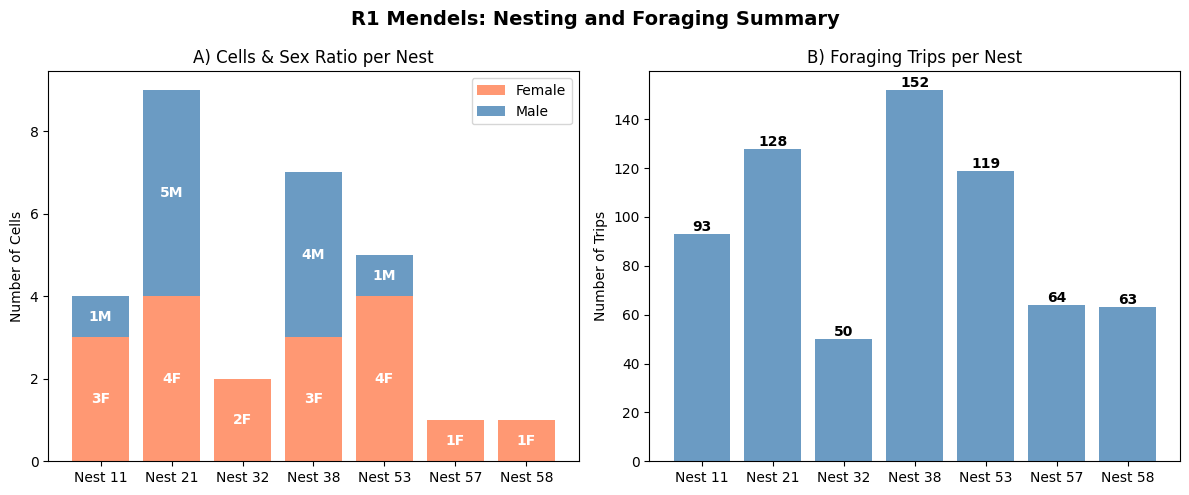

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/foraging_events.csv")
df['timestamp'] = pd.to_datetime(df['event_datetime'])
df['date'] = df['timestamp'].dt.date

# R1 Mendels nests
R1_NESTS = [11, 21, 32, 38, 53, 57, 58]

NEST_INFO = {
    11: {'cells': 4, 'females': 3, 'males': 1},
    21: {'cells': 9, 'females': 4, 'males': 5},
    32: {'cells': 2, 'females': 2, 'males': 0},
    38: {'cells': 7, 'females': 3, 'males': 4},
    53: {'cells': 5, 'females': 4, 'males': 1},
    57: {'cells': 1, 'females': 1, 'males': 0},
    58: {'cells': 1, 'females': 1, 'males': 0},
}

# Filter R1 period
df_r1 = df[(df['date'] >= pd.to_datetime('2024-04-16').date()) & 
           (df['date'] < pd.to_datetime('2024-05-16').date())]
df_r1 = df_r1[df_r1['nest'].isin(R1_NESTS)].copy()

def get_trips(nest_df, min_sec=10, max_sec=7200):
    if len(nest_df) == 0:
        return pd.DataFrame()
    nest_df = nest_df.sort_values('timestamp').reset_index(drop=True)
    trips = []
    last_exit = None
    for _, row in nest_df.iterrows():
        if row['action'] == 'Exit':
            last_exit = row
        elif row['action'] == 'Entry' and last_exit is not None:
            dur = (row['timestamp'] - last_exit['timestamp']).total_seconds()
            if min_sec <= dur <= max_sec:
                trips.append({'nest': row['nest'], 'duration_sec': dur})
            last_exit = None
    return pd.DataFrame(trips)

# Build data
females = [NEST_INFO[n]['females'] for n in R1_NESTS]
males = [NEST_INFO[n]['males'] for n in R1_NESTS]
trips = []

for nest in R1_NESTS:
    t = get_trips(df_r1[df_r1['nest'] == nest])
    trips.append(len(t))

# 1x2 figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('R1 Mendels: Nesting and Foraging Summary', fontsize=14, fontweight='bold')

x = np.arange(len(R1_NESTS))
labels = [f"Nest {n}" for n in R1_NESTS]

# A: Sex ratio (stacked)
ax = axes[0]
bars_f = ax.bar(x, females, color='coral', alpha=0.8, label='Female')
bars_m = ax.bar(x, males, bottom=females, color='blue', alpha=0.8, label='Male')
for i, (f, m) in enumerate(zip(females, males)):
    ax.text(i, f/2, f'{f}F', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
    if m > 0:
        ax.text(i, f + m/2, f'{m}M', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of Cells')
ax.set_title('A) Cells & Sex Ratio per Nest')
ax.legend()
#ax.grid(axis='y', alpha=0.3)

# B: Trip count
ax = axes[1]
bars = ax.bar(x, trips, color='blue', alpha=0.8)
ax.bar_label(bars, fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Number of Trips')
ax.set_title('B) Foraging Trips per Nest')
#ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('fig_r1_2panel.png', dpi=150, bbox_inches='tight')
plt.show()

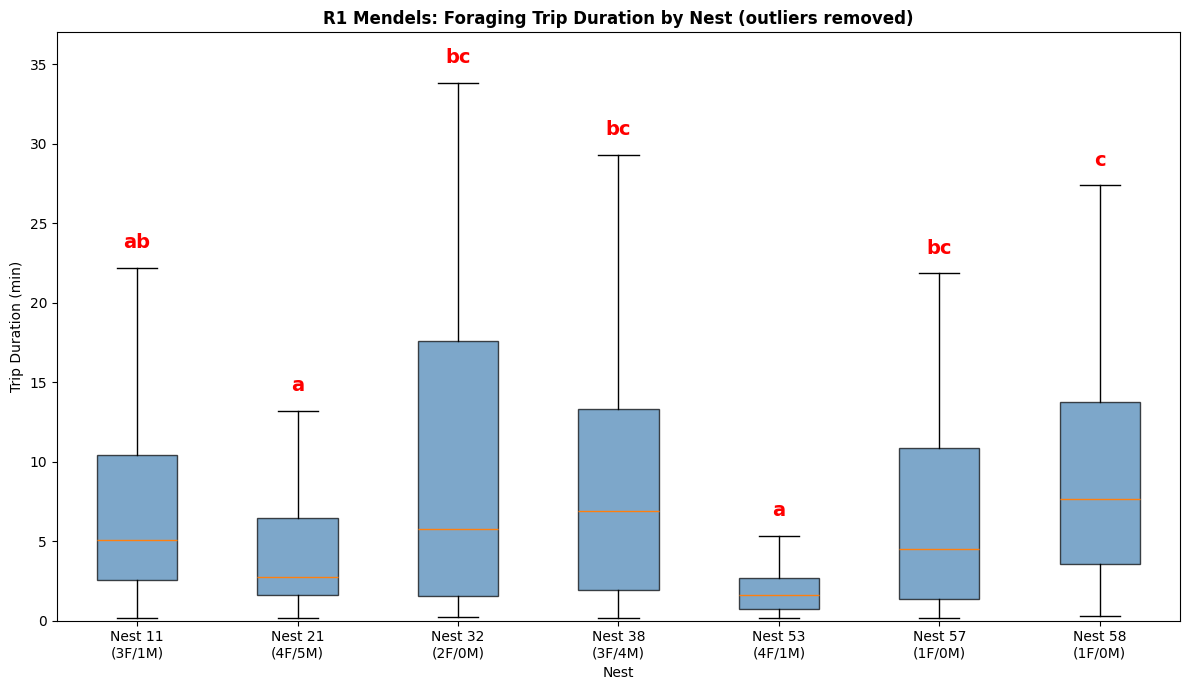

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv('/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/foraging_events.csv')
df['timestamp'] = pd.to_datetime(df['event_datetime'])
df['date'] = df['timestamp'].dt.date

R1_NESTS = [11, 21, 32, 38, 53, 57, 58]

NEST_INFO = {
    11: {'cells': 4, 'females': 3, 'males': 1},
    21: {'cells': 9, 'females': 4, 'males': 5},
    32: {'cells': 2, 'females': 2, 'males': 0},
    38: {'cells': 7, 'females': 3, 'males': 4},
    53: {'cells': 5, 'females': 4, 'males': 1},
    57: {'cells': 1, 'females': 1, 'males': 0},
    58: {'cells': 1, 'females': 1, 'males': 0},
}

df_r1 = df[(df['date'] >= pd.to_datetime('2024-04-16').date()) & 
           (df['date'] < pd.to_datetime('2024-05-16').date())]
df_r1 = df_r1[df_r1['nest'].isin(R1_NESTS)].copy()

def get_trips(nest_df, min_sec=10, max_sec=7200):
    if len(nest_df) == 0:
        return pd.DataFrame()
    nest_df = nest_df.sort_values('timestamp').reset_index(drop=True)
    trips = []
    last_exit = None
    for _, row in nest_df.iterrows():
        if row['action'] == 'Exit':
            last_exit = row
        elif row['action'] == 'Entry' and last_exit is not None:
            dur = (row['timestamp'] - last_exit['timestamp']).total_seconds()
            if min_sec <= dur <= max_sec:
                trips.append({'nest': row['nest'], 'duration_sec': dur})
            last_exit = None
    return pd.DataFrame(trips)

all_trips = []
for nest in R1_NESTS:
    t = get_trips(df_r1[df_r1['nest'] == nest])
    if len(t) > 0:
        t['duration_min'] = t['duration_sec'] / 60
        all_trips.append(t)

trips_df = pd.concat(all_trips, ignore_index=True)

# Remove outliers using IQR
def remove_outliers_iqr(df, column, multiplier=1.5):
    cleaned = []
    for nest in df['nest'].unique():
        nest_data = df[df['nest'] == nest].copy()
        Q1 = nest_data[column].quantile(0.25)
        Q3 = nest_data[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        cleaned.append(nest_data[(nest_data[column] >= lower) & (nest_data[column] <= upper)])
    return pd.concat(cleaned, ignore_index=True)

trips_clean = remove_outliers_iqr(trips_df, 'duration_min')

# Tukey HSD
tukey = pairwise_tukeyhsd(trips_clean['duration_min'], trips_clean['nest'], alpha=0.05)

# Letter assignments based on Tukey results
letters = {
    53: 'a',
    21: 'a', 
    11: 'ab',
    38: 'bc',
    32: 'bc',
    57: 'bc',
    58: 'c'
}

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))

box_data = [trips_clean[trips_clean['nest'] == n]['duration_min'].values for n in R1_NESTS]
labels = [f"Nest {n}\n({NEST_INFO[n]['females']}F/{NEST_INFO[n]['males']}M)" for n in R1_NESTS]

bp = ax.boxplot(box_data, tick_labels=labels, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.7)

# Add Tukey letters
for i, nest in enumerate(R1_NESTS):
    whisker_top = bp['whiskers'][i*2 + 1].get_ydata()[1]
    y_pos = whisker_top + 1
    ax.text(i + 1, y_pos, letters[nest], ha='center', va='bottom', 
            fontsize=14, fontweight='bold', color='red')

ax.set_ylabel('Trip Duration (min)')
ax.set_xlabel('Nest')
ax.set_title('R1 Mendels: Foraging Trip Duration by Nest (outliers removed)', 
             fontsize=12, fontweight='bold')
#ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.ylim(0, 37)
#plt.savefig('fig_r1_tukey.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
trips_clean['duration_min'].describe()

count    603.000000
mean       7.056082
std        8.231656
min        0.166667
25%        1.509444
50%        3.980556
75%        9.309444
max       44.472222
Name: duration_min, dtype: float64

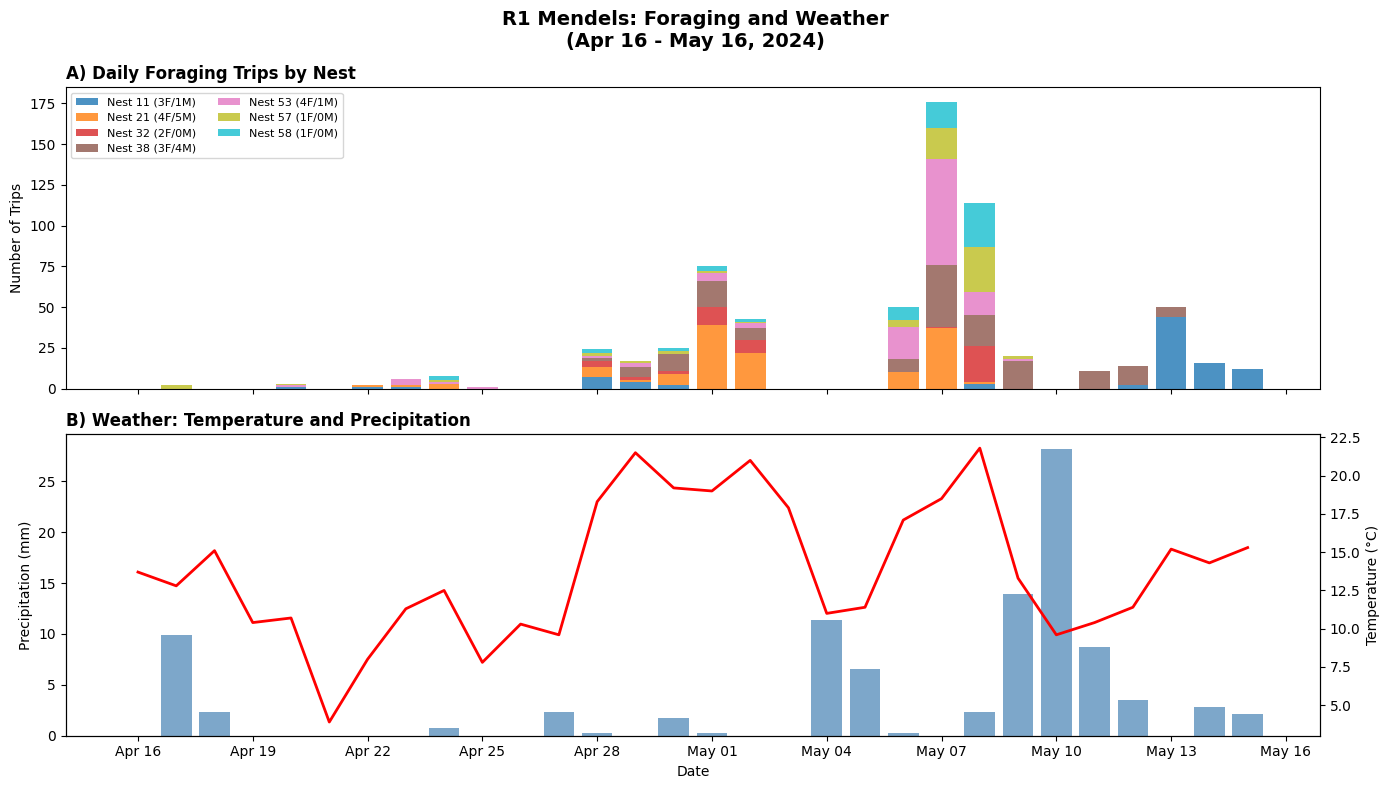

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO

# Load foraging data
df = pd.read_csv('/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/foraging_events.csv')
df['timestamp'] = pd.to_datetime(df['event_datetime'])
df['date'] = df['timestamp'].dt.date

# PWS weather data
pws_data = """date,temp_avg,precip_mm
2024-04-16,13.7,0.00
2024-04-17,12.8,9.91
2024-04-18,15.1,2.31
2024-04-19,10.4,0.00
2024-04-20,10.7,0.00
2024-04-21,3.9,0.00
2024-04-22,8.0,0.00
2024-04-23,11.3,0.00
2024-04-24,12.5,0.71
2024-04-25,7.8,0.00
2024-04-26,10.3,0.00
2024-04-27,9.6,2.31
2024-04-28,18.3,0.30
2024-04-29,21.5,0.00
2024-04-30,19.2,1.70
2024-05-01,19.0,0.30
2024-05-02,21.0,0.00
2024-05-03,17.9,0.00
2024-05-04,11.0,11.40
2024-05-05,11.4,6.60
2024-05-06,17.1,0.30
2024-05-07,18.5,0.00
2024-05-08,21.8,2.31
2024-05-09,13.3,13.89
2024-05-10,9.6,28.19
2024-05-11,10.4,8.71
2024-05-12,11.4,3.51
2024-05-13,15.2,0.00
2024-05-14,14.3,2.79
2024-05-15,15.3,2.11"""

weather = pd.read_csv(StringIO(pws_data))
weather['date'] = pd.to_datetime(weather['date']).dt.date

R1_NESTS = [11, 21, 32, 38, 53, 57, 58]

NEST_INFO = {
    11: {'cells': 4, 'females': 3, 'males': 1},
    21: {'cells': 9, 'females': 4, 'males': 5},
    32: {'cells': 2, 'females': 2, 'males': 0},
    38: {'cells': 7, 'females': 3, 'males': 4},
    53: {'cells': 5, 'females': 4, 'males': 1},
    57: {'cells': 1, 'females': 1, 'males': 0},
    58: {'cells': 1, 'females': 1, 'males': 0},
}

df_r1 = df[(df['date'] >= pd.to_datetime('2024-04-16').date()) & 
           (df['date'] < pd.to_datetime('2024-05-16').date())]
df_r1 = df_r1[df_r1['nest'].isin(R1_NESTS)].copy()

def get_trips(nest_df, min_sec=10, max_sec=7200):
    if len(nest_df) == 0:
        return pd.DataFrame()
    nest_df = nest_df.sort_values('timestamp').reset_index(drop=True)
    trips = []
    last_exit = None
    for _, row in nest_df.iterrows():
        if row['action'] == 'Exit':
            last_exit = row
        elif row['action'] == 'Entry' and last_exit is not None:
            dur = (row['timestamp'] - last_exit['timestamp']).total_seconds()
            if min_sec <= dur <= max_sec:
                trips.append({
                    'nest': row['nest'],
                    'exit_time': last_exit['timestamp'],
                    'duration_sec': dur
                })
            last_exit = None
    return pd.DataFrame(trips)

# Get all trips
all_trips = []
for nest in R1_NESTS:
    t = get_trips(df_r1[df_r1['nest'] == nest])
    if len(t) > 0:
        t['duration_min'] = t['duration_sec'] / 60
        all_trips.append(t)

trips_df = pd.concat(all_trips, ignore_index=True)
trips_df['date'] = trips_df['exit_time'].dt.date

# Daily counts per nest
dates = pd.date_range('2024-04-16', '2024-05-15')
daily_nest = trips_df.groupby(['date', 'nest']).size().unstack(fill_value=0)

# Create 2-panel figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('R1 Mendels: Foraging and Weather\n(Apr 16 - May 16, 2024)', 
             fontsize=14, fontweight='bold')

# Panel A: Stacked bar trips
ax = axes[0]
bottom = np.zeros(len(dates))
colors = plt.cm.tab10(np.linspace(0, 1, len(R1_NESTS)))

for i, nest in enumerate(R1_NESTS):
    if nest in daily_nest.columns:
        vals = [daily_nest.loc[d.date(), nest] if d.date() in daily_nest.index else 0 for d in dates]
    else:
        vals = [0] * len(dates)
    info = NEST_INFO[nest]
    ax.bar(dates, vals, bottom=bottom, label=f"Nest {nest} ({info['females']}F/{info['males']}M)", 
           color=colors[i], alpha=0.8)
    bottom += vals

ax.set_ylabel('Number of Trips', color='black')
ax.tick_params(axis='y', labelcolor='black')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_title('A) Daily Foraging Trips by Nest', loc='left', fontweight='bold')
#ax.grid(axis='y', alpha=0.3)

# Panel B: Weather (temp and precip)
ax = axes[1]
ax.bar(pd.to_datetime(weather['date']), weather['precip_mm'], color='steelblue', alpha=0.7, label='Precip (mm)')
ax.set_ylabel('Precipitation (mm)', color='black')
ax.tick_params(axis='y', labelcolor='black')

ax2 = ax.twinx()
ax2.plot(pd.to_datetime(weather['date']), weather['temp_avg'], 'r-', linewidth=2, label='Temp (°C)')
ax2.set_ylabel('Temperature (°C)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

ax.set_title('B) Weather: Temperature and Precipitation', loc='left', fontweight='bold')
ax.set_xlabel('Date', color='black')
ax.tick_params(axis='x', labelcolor='black')
#ax.grid(axis='y', alpha=0.3)

# Fix x-axis date formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
#plt.savefig('fig_r1_weather.png', dpi=150, bbox_inches='tight')
plt.show()

Temperature vs Trips: r = 0.586, p = 0.0066
Precipitation vs Trips: r = -0.210, p = 0.3746


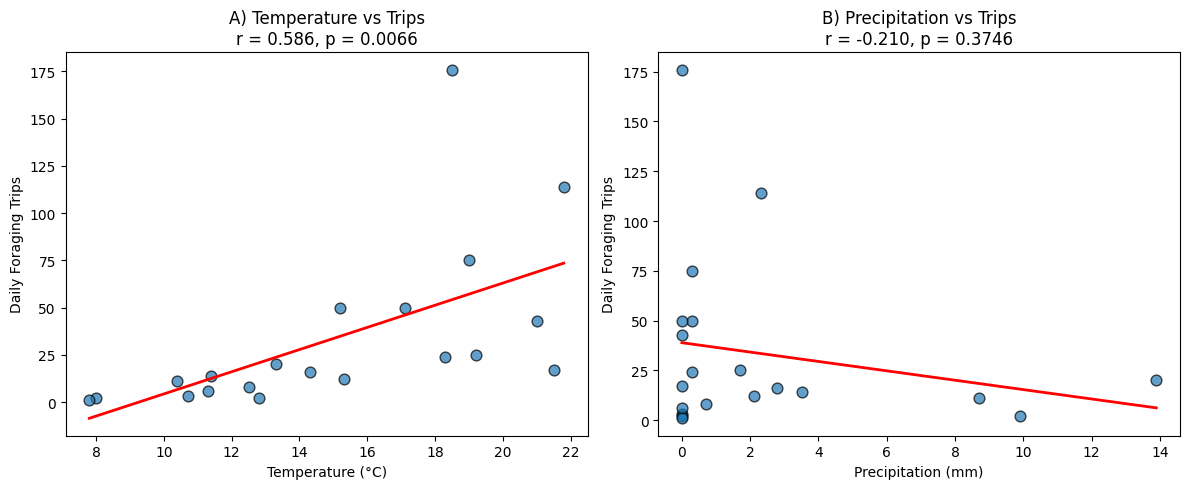

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from io import StringIO
import matplotlib.pyplot as plt

# Load foraging data
df = pd.read_csv('/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/foraging_events.csv')
df['timestamp'] = pd.to_datetime(df['event_datetime'])
df['date'] = df['timestamp'].dt.date

# PWS weather data
pws_data = """date,temp_avg,precip_mm
2024-04-16,13.7,0.00
2024-04-17,12.8,9.91
2024-04-18,15.1,2.31
2024-04-19,10.4,0.00
2024-04-20,10.7,0.00
2024-04-21,3.9,0.00
2024-04-22,8.0,0.00
2024-04-23,11.3,0.00
2024-04-24,12.5,0.71
2024-04-25,7.8,0.00
2024-04-26,10.3,0.00
2024-04-27,9.6,2.31
2024-04-28,18.3,0.30
2024-04-29,21.5,0.00
2024-04-30,19.2,1.70
2024-05-01,19.0,0.30
2024-05-02,21.0,0.00
2024-05-03,17.9,0.00
2024-05-04,11.0,11.40
2024-05-05,11.4,6.60
2024-05-06,17.1,0.30
2024-05-07,18.5,0.00
2024-05-08,21.8,2.31
2024-05-09,13.3,13.89
2024-05-10,9.6,28.19
2024-05-11,10.4,8.71
2024-05-12,11.4,3.51
2024-05-13,15.2,0.00
2024-05-14,14.3,2.79
2024-05-15,15.3,2.11"""

weather = pd.read_csv(StringIO(pws_data))
weather['date'] = pd.to_datetime(weather['date']).dt.date

R1_NESTS = [11, 21, 32, 38, 53, 57, 58]

df_r1 = df[(df['date'] >= pd.to_datetime('2024-04-16').date()) & 
           (df['date'] < pd.to_datetime('2024-05-16').date())]
df_r1 = df_r1[df_r1['nest'].isin(R1_NESTS)].copy()

def get_trips(nest_df, min_sec=10, max_sec=7200):
    if len(nest_df) == 0:
        return pd.DataFrame()
    nest_df = nest_df.sort_values('timestamp').reset_index(drop=True)
    trips = []
    last_exit = None
    for _, row in nest_df.iterrows():
        if row['action'] == 'Exit':
            last_exit = row
        elif row['action'] == 'Entry' and last_exit is not None:
            dur = (row['timestamp'] - last_exit['timestamp']).total_seconds()
            if min_sec <= dur <= max_sec:
                trips.append({
                    'nest': row['nest'],
                    'exit_time': last_exit['timestamp'],
                    'duration_sec': dur
                })
            last_exit = None
    return pd.DataFrame(trips)

# Get all trips
all_trips = []
for nest in R1_NESTS:
    t = get_trips(df_r1[df_r1['nest'] == nest])
    if len(t) > 0:
        all_trips.append(t)

trips_df = pd.concat(all_trips, ignore_index=True)
trips_df['date'] = trips_df['exit_time'].dt.date

# Daily totals
daily = trips_df.groupby('date').size().reset_index(name='trips')
daily = pd.merge(daily, weather, on='date', how='left')

# Correlations
r_temp, p_temp = stats.pearsonr(daily['temp_avg'], daily['trips'])
r_precip, p_precip = stats.pearsonr(daily['precip_mm'], daily['trips'])

print(f"Temperature vs Trips: r = {r_temp:.3f}, p = {p_temp:.4f}")
print(f"Precipitation vs Trips: r = {r_precip:.3f}, p = {p_precip:.4f}")

# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Temperature
ax = axes[0]
ax.scatter(daily['temp_avg'], daily['trips'], s=60, alpha=0.7, edgecolor='black')
slope, intercept, r, p, se = stats.linregress(daily['temp_avg'], daily['trips'])
x_line = np.linspace(daily['temp_avg'].min(), daily['temp_avg'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2)
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Daily Foraging Trips')
ax.set_title(f'A) Temperature vs Trips\nr = {r_temp:.3f}, p = {p_temp:.4f}')
#ax.grid(alpha=0.3)

# Precipitation
ax = axes[1]
ax.scatter(daily['precip_mm'], daily['trips'], s=60, alpha=0.7, edgecolor='black')
slope, intercept, r, p, se = stats.linregress(daily['precip_mm'], daily['trips'])
x_line = np.linspace(daily['precip_mm'].min(), daily['precip_mm'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2)
ax.set_xlabel('Precipitation (mm)')
ax.set_ylabel('Daily Foraging Trips')
ax.set_title(f'B) Precipitation vs Trips\nr = {r_precip:.3f}, p = {p_precip:.4f}')
#ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('fig_r1_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
April 16, 2024

Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	10.6 °C	1.2 °C	52 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	10.4 °C	1.6 °C	54 %	SE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	9.8 °C	1.7 °C	57 %	SE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	9.1 °C	1.6 °C	60 %	SSE	0.3 km/h	0.6 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	8.7 °C	1.8 °C	62 %	ESE	0.1 km/h	0.3 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	8.4 °C	1.8 °C	63 %	SE	0.0 km/h	0.1 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	8.3 °C	1.5 °C	62 %	SE	0.8 km/h	1.3 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	8.4 °C	1.6 °C	62 %	SSE	0.3 km/h	0.8 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	8.5 °C	1.3 °C	60 %	South	1.7 km/h	2.1 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	8.5 °C	1.8 °C	63 %	SE	0.9 km/h	1.5 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	8.0 °C	1.6 °C	64 %	SE	0.8 km/h	1.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	7.7 °C	1.7 °C	66 %	SE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	7.7 °C	1.3 °C	64 %	SSE	0.1 km/h	0.3 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	7.8 °C	1.5 °C	65 %	SE	0.7 km/h	1.1 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	7.5 °C	1.5 °C	66 %	SE	0.8 km/h	1.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	7.4 °C	1.5 °C	66 %	SE	0.8 km/h	1.6 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	7.3 °C	1.5 °C	67 %	SE	1.2 km/h	1.7 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	7.3 °C	1.3 °C	66 %	SE	1.1 km/h	1.6 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	7.6 °C	1.3 °C	64 %	SE	1.3 km/h	1.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	7.7 °C	1.2 °C	63 %	SE	1.6 km/h	1.8 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	8.0 °C	1.3 °C	63 %	SE	1.2 km/h	1.6 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	7.7 °C	1.5 °C	65 %	SE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	7.3 °C	1.4 °C	66 %	SE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	7.0 °C	1.5 °C	68 %	SE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	6.7 °C	1.4 °C	69 %	SE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	6.6 °C	1.5 °C	70 %	SE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	6.4 °C	1.5 °C	71 %	SE	0.3 km/h	0.5 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	6.1 °C	1.6 °C	73 %	SE	0.8 km/h	1.2 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	6.0 °C	1.4 °C	73 %	SE	0.7 km/h	1.1 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	5.9 °C	1.4 °C	73 %	SE	0.6 km/h	0.9 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	6.0 °C	1.3 °C	72 %	SE	0.3 km/h	0.5 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	5.9 °C	1.4 °C	73 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	5.7 °C	1.4 °C	73 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	5.8 °C	1.4 °C	73 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	5.6 °C	1.3 °C	74 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	5.7 °C	1.4 °C	74 %	SE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	5.5 °C	1.5 °C	76 %	SE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	5.2 °C	1.4 °C	77 %	SE	0.2 km/h	0.5 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	5.1 °C	1.4 °C	77 %	SE	0.3 km/h	0.5 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	4.8 °C	1.4 °C	78 %	SE	0.6 km/h	0.9 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	4.6 °C	1.3 °C	79 %	SE	0.4 km/h	0.8 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	4.7 °C	1.2 °C	78 %	SE	0.5 km/h	1.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	5.0 °C	1.2 °C	77 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	4.6 °C	1.2 °C	79 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	4.2 °C	1.0 °C	80 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	4.1 °C	1.1 °C	81 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	3.9 °C	1.0 °C	81 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	3.7 °C	1.0 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	3.5 °C	1.0 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	3.3 °C	0.9 °C	84 %	SE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	3.6 °C	1.0 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	3.5 °C	0.9 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	3.6 °C	0.9 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	3.7 °C	1.0 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	3.7 °C	1.0 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	3.7 °C	1.0 °C	83 %	SE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	3.6 °C	1.1 °C	84 %	SE	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	3.4 °C	1.1 °C	85 %	SE	0.0 km/h	0.0 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	3.4 °C	1.0 °C	84 %	SE	0.7 km/h	1.4 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	3.4 °C	1.1 °C	85 %	SE	0.1 km/h	0.7 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	3.3 °C	1.1 °C	85 %	SE	0.8 km/h	1.6 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	3.5 °C	1.0 °C	84 %	SE	0.7 km/h	1.2 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	3.4 °C	1.1 °C	85 %	SE	0.4 km/h	1.4 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	3.5 °C	1.0 °C	84 %	SE	0.8 km/h	1.6 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	3.8 °C	1.0 °C	83 %	SE	1.1 km/h	1.5 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	3.8 °C	1.0 °C	82 %	SE	0.0 km/h	0.0 km/h	1,010.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	3.6 °C	0.9 °C	83 %	SE	0.0 km/h	0.0 km/h	1,011.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	3.3 °C	0.8 °C	83 %	SE	0.0 km/h	0.0 km/h	1,011.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	3.0 °C	0.7 °C	85 %	SE	0.0 km/h	0.0 km/h	1,011.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	2.8 °C	0.7 °C	86 %	SE	0.0 km/h	0.0 km/h	1,011.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	2.6 °C	0.6 °C	87 %	SE	0.0 km/h	0.0 km/h	1,011.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	2.5 °C	0.6 °C	87 %	SE	0.0 km/h	0.0 km/h	1,011.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	2.3 °C	0.4 °C	88 %	SE	0.0 km/h	0.0 km/h	1,011.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	2.3 °C	0.4 °C	88 %	SE	0.0 km/h	0.0 km/h	1,011.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	2.3 °C	0.5 °C	88 %	SE	0.0 km/h	0.0 km/h	1,011.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:19 AM	2.4 °C	0.5 °C	88 %	SE	0.0 km/h	0.0 km/h	1,011.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:24 AM	2.2 °C	0.4 °C	88 %	SE	0.0 km/h	0.0 km/h	1,011.41 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
6:29 AM	2.0 °C	0.3 °C	89 %	SE	0.0 km/h	0.0 km/h	1,011.51 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:34 AM	2.1 °C	0.4 °C	89 %	SE	0.0 km/h	0.0 km/h	1,011.62 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:39 AM	2.3 °C	0.6 °C	89 %	SE	0.0 km/h	0.0 km/h	1,011.62 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
6:44 AM	2.3 °C	0.6 °C	89 %	SE	0.0 km/h	0.0 km/h	1,011.82 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
6:49 AM	2.2 °C	0.5 °C	89 %	SE	0.0 km/h	0.0 km/h	1,011.82 hPa	0.00 mm	0.00 mm	0	12.5 w/m²
6:54 AM	2.2 °C	0.6 °C	89 %	SE	0.2 km/h	0.5 km/h	1,012.02 hPa	0.00 mm	0.00 mm	0	16 w/m²
6:59 AM	2.4 °C	0.7 °C	89 %	SSE	0.4 km/h	0.9 km/h	1,012.02 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
7:04 AM	2.8 °C	1.0 °C	89 %	SSW	0.4 km/h	0.8 km/h	1,012.23 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
7:09 AM	3.0 °C	1.1 °C	88 %	SSW	0.0 km/h	0.0 km/h	1,012.53 hPa	0.00 mm	0.00 mm	0	24.2 w/m²
7:14 AM	3.2 °C	1.3 °C	88 %	SSW	0.0 km/h	0.0 km/h	1,012.53 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
7:19 AM	3.3 °C	1.3 °C	87 %	SSW	0.0 km/h	0.0 km/h	1,012.53 hPa	0.00 mm	0.00 mm	0	30.3 w/m²
7:24 AM	3.5 °C	1.5 °C	87 %	South	0.0 km/h	0.1 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	32.4 w/m²
7:29 AM	3.8 °C	1.7 °C	87 %	SE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	35.5 w/m²
7:34 AM	4.1 °C	1.8 °C	85 %	SE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
7:39 AM	4.7 °C	2.2 °C	84 %	SE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:44 AM	5.2 °C	2.4 °C	82 %	SE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	41.1 w/m²
7:49 AM	5.8 °C	2.7 °C	80 %	SE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	44.2 w/m²
7:54 AM	6.4 °C	3.1 °C	80 %	SE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	44.7 w/m²
7:59 AM	6.7 °C	3.0 °C	77 %	SE	0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	0.00 mm	0	51.1 w/m²
8:04 AM	7.3 °C	3.4 °C	77 %	SE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	69.4 w/m²
8:09 AM	7.8 °C	3.3 °C	73 %	SE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	65 w/m²
8:14 AM	8.0 °C	3.2 °C	72 %	SE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	83.2 w/m²
8:19 AM	8.4 °C	3.3 °C	71 %	SE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	86.7 w/m²
8:24 AM	8.8 °C	3.7 °C	70 %	SE	0.0 km/h	0.1 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	79.3 w/m²
8:29 AM	9.0 °C	3.8 °C	70 %	SE	0.0 km/h	0.1 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	99.7 w/m²
8:34 AM	9.3 °C	3.9 °C	69 %	WNW	0.4 km/h	0.7 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	88.8 w/m²
8:39 AM	9.4 °C	4.1 °C	69 %	NNW	0.6 km/h	1.2 km/h	1,012.84 hPa	0.00 mm	0.00 mm	1	165.3 w/m²
8:44 AM	9.6 °C	3.9 °C	68 %		0.1 km/h	0.4 km/h	1,012.94 hPa	0.00 mm	0.00 mm	1	171.3 w/m²
8:49 AM	10.0 °C	3.7 °C	65 %		0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	0.00 mm	1	168.7 w/m²
8:54 AM	10.8 °C	4.1 °C	63 %	NNE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	0.00 mm	1	195.1 w/m²
8:59 AM	11.9 °C	4.6 °C	61 %	NNE	0.1 km/h	0.3 km/h	1,013.04 hPa	0.00 mm	0.00 mm	2	270.2 w/m²
9:04 AM	12.2 °C	4.7 °C	60 %	ENE	0.2 km/h	0.4 km/h	1,013.04 hPa	0.00 mm	0.00 mm	3	330.5 w/m²
9:09 AM	12.7 °C	4.0 °C	55 %	NE	0.3 km/h	0.4 km/h	1,013.04 hPa	0.00 mm	0.00 mm	2	301.9 w/m²
9:14 AM	12.7 °C	4.5 °C	57 %	NE	0.4 km/h	0.8 km/h	1,013.04 hPa	0.00 mm	0.00 mm	3	311 w/m²
9:19 AM	13.2 °C	4.7 °C	56 %	ENE	0.4 km/h	0.9 km/h	1,013.04 hPa	0.00 mm	0.00 mm	3	320.1 w/m²
9:24 AM	13.5 °C	4.5 °C	55 %	East	0.4 km/h	0.7 km/h	1,013.04 hPa	0.00 mm	0.00 mm	3	332.6 w/m²
9:29 AM	13.4 °C	4.5 °C	55 %	East	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	0.00 mm	3	338.8 w/m²
9:34 AM	14.5 °C	5.2 °C	54 %	ENE	0.3 km/h	0.7 km/h	1,013.04 hPa	0.00 mm	0.00 mm	3	349.6 w/m²
9:39 AM	14.7 °C	5.4 °C	54 %	East	0.0 km/h	0.1 km/h	1,012.94 hPa	0.00 mm	0.00 mm	4	419.5 w/m²
9:44 AM	14.9 °C	4.9 °C	51 %	East	0.5 km/h	0.6 km/h	1,012.94 hPa	0.00 mm	0.00 mm	4	417.7 w/m²
9:49 AM	14.7 °C	4.6 °C	51 %	ESE	1.8 km/h	2.1 km/h	1,013.14 hPa	0.00 mm	0.00 mm	4	448.5 w/m²
9:54 AM	14.8 °C	4.5 °C	50 %	ESE	0.2 km/h	0.5 km/h	1,013.14 hPa	0.00 mm	0.00 mm	4	468.4 w/m²
9:59 AM	15.7 °C	4.6 °C	48 %	SE	2.0 km/h	2.9 km/h	1,013.14 hPa	0.00 mm	0.00 mm	5	523.1 w/m²
10:04 AM	15.5 °C	4.1 °C	47 %	ESE	1.2 km/h	1.8 km/h	1,013.24 hPa	0.00 mm	0.00 mm	5	557.4 w/m²
10:09 AM	16.0 °C	4.3 °C	46 %	SE	1.0 km/h	1.8 km/h	1,013.24 hPa	0.00 mm	0.00 mm	5	563 w/m²
10:14 AM	16.1 °C	3.6 °C	43 %	SSE	2.2 km/h	3.2 km/h	1,013.14 hPa	0.00 mm	0.00 mm	5	569.1 w/m²
10:19 AM	15.7 °C	3.8 °C	45 %	SE	1.2 km/h	2.0 km/h	1,013.14 hPa	0.00 mm	0.00 mm	5	580.8 w/m²
10:24 AM	16.2 °C	4.1 °C	44 %	South	2.8 km/h	4.1 km/h	1,013.24 hPa	0.00 mm	0.00 mm	5	600.8 w/m²
10:29 AM	16.1 °C	4.6 °C	46 %	SE	2.8 km/h	3.9 km/h	1,013.24 hPa	0.00 mm	0.00 mm	5	615.1 w/m²
10:34 AM	16.8 °C	4.8 °C	45 %	East	1.7 km/h	2.4 km/h	1,013.24 hPa	0.00 mm	0.00 mm	6	630.8 w/m²
10:39 AM	17.2 °C	4.6 °C	43 %	SSE	2.0 km/h	3.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	6	620.2 w/m²
10:44 AM	17.2 °C	4.8 °C	44 %	SSE	2.6 km/h	4.3 km/h	1,013.24 hPa	0.00 mm	0.00 mm	6	652.8 w/m²
10:49 AM	17.3 °C	4.9 °C	44 %	SE	1.8 km/h	2.9 km/h	1,013.14 hPa	0.00 mm	0.00 mm	6	691.4 w/m²
10:54 AM	17.2 °C	4.9 °C	44 %	SE	2.0 km/h	3.3 km/h	1,013.14 hPa	0.00 mm	0.00 mm	6	700.5 w/m²
10:59 AM	17.2 °C	4.9 °C	44 %	East	1.1 km/h	2.0 km/h	1,012.94 hPa	0.00 mm	0.00 mm	6	706.6 w/m²
11:04 AM	17.7 °C	5.0 °C	43 %	SSE	1.5 km/h	2.5 km/h	1,012.94 hPa	0.00 mm	0.00 mm	7	720.9 w/m²
11:09 AM	18.0 °C	4.7 °C	41 %	SSE	1.9 km/h	2.8 km/h	1,012.84 hPa	0.00 mm	0.00 mm	7	726.2 w/m²
11:14 AM	18.0 °C	4.7 °C	41 %	SSW	1.9 km/h	2.8 km/h	1,012.94 hPa	0.00 mm	0.00 mm	7	740 w/m²
11:19 AM	18.0 °C	4.5 °C	41 %	NE	1.4 km/h	2.3 km/h	1,012.73 hPa	0.00 mm	0.00 mm	7	746.5 w/m²
11:24 AM	17.4 °C	4.4 °C	42 %	NE	1.8 km/h	2.3 km/h	1,012.63 hPa	0.00 mm	0.00 mm	7	747.3 w/m²
11:29 AM	17.8 °C	4.5 °C	41 %	ESE	1.6 km/h	2.5 km/h	1,012.63 hPa	0.00 mm	0.00 mm	7	739.6 w/m²
11:34 AM	18.3 °C	4.6 °C	40 %	East	1.4 km/h	2.2 km/h	1,012.63 hPa	0.00 mm	0.00 mm	7	732.2 w/m²
11:39 AM	18.4 °C	5.3 °C	42 %	NNE	1.8 km/h	3.1 km/h	1,012.53 hPa	0.00 mm	0.00 mm	6	715.3 w/m²
11:44 AM	18.4 °C	5.0 °C	41 %	SE	3.7 km/h	4.9 km/h	1,012.33 hPa	0.00 mm	0.00 mm	6	716.2 w/m²
11:49 AM	18.2 °C	4.9 °C	41 %	West	3.1 km/h	4.4 km/h	1,012.23 hPa	0.00 mm	0.00 mm	6	706.2 w/m²
11:54 AM	17.8 °C	4.8 °C	42 %	SSE	4.8 km/h	6.5 km/h	1,012.23 hPa	0.00 mm	0.00 mm	6	692.3 w/m²
11:59 AM	17.6 °C	4.1 °C	41 %	NNW	1.9 km/h	2.5 km/h	1,012.02 hPa	0.00 mm	0.00 mm	6	685.3 w/m²
12:04 PM	18.6 °C	6.0 °C	44 %	SSE	1.5 km/h	2.4 km/h	1,012.02 hPa	0.00 mm	0.00 mm	6	671.9 w/m²
12:09 PM	19.2 °C	5.3 °C	40 %	South	3.7 km/h	4.8 km/h	1,012.02 hPa	0.00 mm	0.00 mm	6	651.1 w/m²
12:14 PM	18.9 °C	5.6 °C	42 %	SSE	6.5 km/h	9.6 km/h	1,011.82 hPa	0.00 mm	0.00 mm	6	653.6 w/m²
12:19 PM	17.9 °C	4.5 °C	41 %	SSE	2.3 km/h	3.6 km/h	1,011.92 hPa	0.00 mm	0.00 mm	6	662 w/m²
12:24 PM	18.4 °C	5.1 °C	41 %	SSE	6.9 km/h	9.5 km/h	1,011.82 hPa	0.00 mm	0.00 mm	6	662.3 w/m²
12:29 PM	19.0 °C	5.7 °C	42 %	SSE	3.6 km/h	5.7 km/h	1,011.62 hPa	0.00 mm	0.00 mm	6	662.3 w/m²
12:34 PM	19.5 °C	5.9 °C	41 %	East	1.8 km/h	3.7 km/h	1,011.51 hPa	0.00 mm	0.00 mm	6	662 w/m²
12:39 PM	19.7 °C	5.6 °C	40 %	South	4.0 km/h	6.6 km/h	1,011.51 hPa	0.00 mm	0.00 mm	6	665 w/m²
12:44 PM	18.8 °C	5.5 °C	42 %	SSE	7.1 km/h	9.3 km/h	1,011.51 hPa	0.00 mm	0.00 mm	6	665 w/m²
12:49 PM	18.7 °C	5.5 °C	42 %	SE	7.6 km/h	10.4 km/h	1,011.51 hPa	0.00 mm	0.00 mm	6	665.4 w/m²
12:54 PM	19.3 °C	5.5 °C	40 %	SE	3.0 km/h	4.5 km/h	1,011.31 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
12:59 PM	20.0 °C	5.9 °C	40 %	SSE	3.0 km/h	5.0 km/h	1,011.31 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
1:04 PM	20.1 °C	5.7 °C	39 %	SW	2.0 km/h	3.4 km/h	1,011.41 hPa	0.00 mm	0.00 mm	6	653.6 w/m²
1:09 PM	20.3 °C	6.1 °C	40 %	South	7.0 km/h	10.1 km/h	1,011.24 hPa	0.00 mm	0.00 mm	6	655.5 w/m²
1:14 PM	19.1 °C	5.0 °C	39 %	SSE	10.7 km/h	13.2 km/h	1,011.04 hPa	0.00 mm	0.00 mm	6	663.7 w/m²
1:19 PM	19.5 °C	5.0 °C	39 %	South	3.5 km/h	4.9 km/h	1,010.94 hPa	0.00 mm	0.00 mm	6	665.4 w/m²
1:24 PM	19.9 °C	5.5 °C	39 %	South	3.2 km/h	5.2 km/h	1,011.04 hPa	0.00 mm	0.00 mm	6	667.1 w/m²
1:29 PM	20.1 °C	5.8 °C	39 %	SSE	3.2 km/h	5.2 km/h	1,010.94 hPa	0.00 mm	0.00 mm	6	666.7 w/m²
1:34 PM	20.2 °C	5.6 °C	38 %	SSE	4.1 km/h	5.7 km/h	1,010.94 hPa	0.00 mm	0.00 mm	6	663.2 w/m²
1:39 PM	20.4 °C	5.6 °C	38 %	SSE	6.8 km/h	9.1 km/h	1,010.84 hPa	0.00 mm	0.00 mm	6	663.2 w/m²
1:44 PM	21.1 °C	6.2 °C	38 %	South	3.9 km/h	6.5 km/h	1,010.84 hPa	0.00 mm	0.00 mm	6	687.2 w/m²
1:49 PM	21.5 °C	6.5 °C	38 %	SSE	0.8 km/h	2.1 km/h	1,010.94 hPa	0.00 mm	0.00 mm	6	683.2 w/m²
1:54 PM	21.6 °C	6.1 °C	37 %	East	0.0 km/h	0.2 km/h	1,010.94 hPa	0.00 mm	0.00 mm	6	624.2 w/m²
1:59 PM	21.4 °C	5.8 °C	36 %	South	1.9 km/h	3.2 km/h	1,011.14 hPa	0.00 mm	0.00 mm	6	667.6 w/m²
2:04 PM	21.0 °C	5.7 °C	37 %	South	3.1 km/h	4.8 km/h	1,010.94 hPa	0.00 mm	0.00 mm	6	668 w/m²
2:09 PM	21.6 °C	5.7 °C	36 %	SSE	2.9 km/h	4.9 km/h	1,010.84 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
2:14 PM	21.8 °C	6.5 °C	37 %	West	1.2 km/h	2.8 km/h	1,010.74 hPa	0.00 mm	0.00 mm	6	653.6 w/m²
2:19 PM	22.0 °C	6.6 °C	37 %	South	1.6 km/h	3.2 km/h	1,010.63 hPa	0.00 mm	0.00 mm	5	605.9 w/m²
2:24 PM	22.1 °C	6.6 °C	37 %	SSE	3.1 km/h	5.4 km/h	1,010.63 hPa	0.00 mm	0.00 mm	6	649.4 w/m²
2:29 PM	22.2 °C	6.1 °C	35 %	ENE	1.9 km/h	3.4 km/h	1,010.63 hPa	0.00 mm	0.00 mm	6	645.9 w/m²
2:34 PM	22.4 °C	6.3 °C	35 %	South	2.4 km/h	3.4 km/h	1,010.63 hPa	0.00 mm	0.00 mm	6	640.7 w/m²
2:39 PM	21.9 °C	6.3 °C	36 %	SSE	5.6 km/h	8.8 km/h	1,010.43 hPa	0.00 mm	0.00 mm	6	636.8 w/m²
2:44 PM	21.6 °C	5.9 °C	36 %	SSE	5.7 km/h	8.4 km/h	1,010.43 hPa	0.00 mm	0.00 mm	6	630.3 w/m²
2:49 PM	22.0 °C	5.9 °C	35 %	South	4.5 km/h	6.5 km/h	1,010.33 hPa	0.00 mm	0.00 mm	5	615.5 w/m²
2:54 PM	22.3 °C	6.1 °C	35 %	SSW	2.1 km/h	3.3 km/h	1,010.33 hPa	0.00 mm	0.00 mm	6	625.5 w/m²
2:59 PM	22.7 °C	6.4 °C	35 %	NE	1.8 km/h	2.9 km/h	1,010.02 hPa	0.00 mm	0.00 mm	5	606.8 w/m²
3:04 PM	22.8 °C	6.8 °C	36 %	SSE	3.7 km/h	5.7 km/h	1,010.02 hPa	0.00 mm	0.00 mm	5	598.2 w/m²
3:09 PM	22.6 °C	6.1 °C	34 %	WSW	4.6 km/h	6.8 km/h	1,010.02 hPa	0.00 mm	0.00 mm	5	612.5 w/m²
3:14 PM	22.8 °C	5.8 °C	33 %	WNW	0.9 km/h	1.3 km/h	1,010.02 hPa	0.00 mm	0.00 mm	5	616 w/m²
3:19 PM	22.7 °C	5.8 °C	33 %	SSE	3.9 km/h	6.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	5	606.4 w/m²
3:24 PM	22.4 °C	6.0 °C	34 %	South	3.7 km/h	5.4 km/h	1,009.82 hPa	0.00 mm	0.00 mm	5	604.2 w/m²
3:29 PM	22.4 °C	5.7 °C	34 %	ESE	1.2 km/h	1.9 km/h	1,009.72 hPa	0.00 mm	0.00 mm	5	593 w/m²
3:34 PM	22.9 °C	6.5 °C	35 %	SSE	1.9 km/h	3.5 km/h	1,009.62 hPa	0.00 mm	0.00 mm	5	589 w/m²
3:39 PM	23.1 °C	6.2 °C	34 %	SSW	2.3 km/h	4.1 km/h	1,009.52 hPa	0.00 mm	0.00 mm	5	589 w/m²
3:44 PM	23.0 °C	6.0 °C	33 %	South	4.1 km/h	6.1 km/h	1,009.62 hPa	0.00 mm	0.00 mm	5	551.7 w/m²
3:49 PM	23.4 °C	6.1 °C	33 %	SSW	2.8 km/h	4.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	5	558.7 w/m²
3:54 PM	23.2 °C	5.6 °C	32 %	South	3.6 km/h	5.1 km/h	1,009.52 hPa	0.00 mm	0.00 mm	5	550.5 w/m²
3:59 PM	23.4 °C	5.7 °C	32 %	NE	2.7 km/h	4.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	5	546.1 w/m²
4:04 PM	23.4 °C	5.6 °C	32 %	South	3.7 km/h	5.7 km/h	1,009.52 hPa	0.00 mm	0.00 mm	5	518 w/m²
4:09 PM	23.5 °C	6.0 °C	32 %	SSE	0.4 km/h	1.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	4	507.9 w/m²
4:14 PM	23.9 °C	5.7 °C	31 %	SSE	1.8 km/h	3.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	4	504 w/m²
4:19 PM	23.5 °C	5.5 °C	31 %	South	3.8 km/h	5.3 km/h	1,009.52 hPa	0.00 mm	0.00 mm	4	501.5 w/m²
4:24 PM	23.6 °C	5.9 °C	32 %	SE	0.6 km/h	1.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	4	486.6 w/m²
4:29 PM	24.1 °C	5.6 °C	30 %	WSW	0.4 km/h	1.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	4	474.9 w/m²
4:34 PM	24.3 °C	5.6 °C	30 %	ESE	1.8 km/h	2.5 km/h	1,009.31 hPa	0.00 mm	0.00 mm	4	463.3 w/m²
4:39 PM	23.5 °C	5.0 °C	30 %	SSE	3.0 km/h	3.9 km/h	1,009.21 hPa	0.00 mm	0.00 mm	4	455.5 w/m²
4:44 PM	23.5 °C	5.1 °C	30 %	SSE	0.8 km/h	1.3 km/h	1,009.31 hPa	0.00 mm	0.00 mm	4	435 w/m²
4:49 PM	24.2 °C	4.8 °C	28 %	SSE	1.9 km/h	3.2 km/h	1,009.04 hPa	0.00 mm	0.00 mm	4	409.9 w/m²
4:54 PM	24.0 °C	4.8 °C	29 %	SE	0.4 km/h	0.7 km/h	1,009.04 hPa	0.00 mm	0.00 mm	3	407.3 w/m²
4:59 PM	24.3 °C	4.7 °C	28 %	NNW	0.5 km/h	0.8 km/h	1,008.94 hPa	0.00 mm	0.00 mm	3	393.4 w/m²
5:04 PM	24.4 °C	3.7 °C	26 %	SSW	0.0 km/h	0.2 km/h	1,008.84 hPa	0.00 mm	0.00 mm	3	357 w/m²
5:09 PM	24.4 °C	4.5 °C	28 %	NNW	1.8 km/h	2.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	3	327.9 w/m²
5:14 PM	24.0 °C	3.6 °C	27 %	NW	3.0 km/h	3.8 km/h	1,008.74 hPa	0.00 mm	0.00 mm	3	343.5 w/m²
5:19 PM	24.0 °C	4.0 °C	27 %	NNW	5.4 km/h	6.8 km/h	1,008.74 hPa	0.00 mm	0.00 mm	3	369.1 w/m²
5:24 PM	23.7 °C	3.6 °C	27 %	NW	5.5 km/h	7.3 km/h	1,008.74 hPa	0.00 mm	0.00 mm	3	359.2 w/m²
5:29 PM	24.3 °C	4.1 °C	27 %	NW	1.3 km/h	2.5 km/h	1,008.64 hPa	0.00 mm	0.00 mm	3	343 w/m²
5:34 PM	24.3 °C	4.7 °C	28 %	NNW	4.0 km/h	5.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	2	275.4 w/m²
5:39 PM	24.2 °C	4.3 °C	27 %	WNW	4.4 km/h	5.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	2	261.9 w/m²
5:44 PM	24.0 °C	3.5 °C	26 %	NW	2.4 km/h	3.4 km/h	1,008.53 hPa	0.00 mm	0.00 mm	2	263.3 w/m²
5:49 PM	24.1 °C	3.9 °C	27 %	NW	3.1 km/h	4.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	2	262.8 w/m²
5:54 PM	24.1 °C	4.0 °C	27 %	NNW	2.2 km/h	3.2 km/h	1,008.53 hPa	0.00 mm	0.00 mm	2	236 w/m²
5:59 PM	24.2 °C	4.4 °C	28 %	NNW	2.9 km/h	4.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	2	229.9 w/m²
6:04 PM	24.1 °C	3.8 °C	27 %	NNW	3.9 km/h	5.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	2	215.6 w/m²
6:09 PM	24.0 °C	3.8 °C	27 %	NNW	2.3 km/h	3.5 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	185.6 w/m²
6:14 PM	24.4 °C	3.9 °C	26 %	NNW	1.1 km/h	1.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	174.8 w/m²
6:19 PM	23.9 °C	3.6 °C	27 %	NW	1.5 km/h	2.5 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	163.1 w/m²
6:24 PM	23.8 °C	3.7 °C	27 %	NNW	3.2 km/h	4.5 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	146.2 w/m²
6:29 PM	23.8 °C	4.4 °C	28 %	NW	1.1 km/h	1.8 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	137.5 w/m²
6:34 PM	23.5 °C	3.4 °C	27 %	NNW	4.6 km/h	5.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	116.2 w/m²
6:39 PM	23.7 °C	3.8 °C	27 %	NNW	0.2 km/h	0.4 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	100.6 w/m²
6:44 PM	24.0 °C	3.8 °C	27 %	NNW	0.1 km/h	0.3 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	85.9 w/m²
6:49 PM	24.3 °C	3.7 °C	26 %	NNW	0.4 km/h	0.5 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	78.4 w/m²
6:54 PM	24.6 °C	3.3 °C	25 %	NNW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	67.2 w/m²
6:59 PM	24.5 °C	4.5 °C	27 %	NNW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	46.4 w/m²
7:04 PM	24.0 °C	5.1 °C	30 %	NNW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	37.2 w/m²
7:09 PM	23.2 °C	6.3 °C	34 %	SSE	0.4 km/h	0.7 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
7:14 PM	22.7 °C	6.5 °C	35 %	SE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	33.4 w/m²
7:19 PM	22.4 °C	6.3 °C	35 %	SE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	30.7 w/m²
7:24 PM	22.2 °C	5.7 °C	34 %	ESE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	25.6 w/m²
7:29 PM	21.6 °C	7.5 °C	40 %	ESE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
7:34 PM	20.9 °C	7.9 °C	43 %	ESE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	13.8 w/m²
7:39 PM	20.1 °C	8.7 °C	48 %	SE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	10.8 w/m²
7:44 PM	19.2 °C	7.9 °C	48 %	SE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
7:49 PM	18.7 °C	7.8 °C	49 %	ESE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
7:54 PM	18.2 °C	7.4 °C	50 %	ESE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
7:59 PM	17.7 °C	6.9 °C	49 %	ESE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
8:04 PM	17.3 °C	6.8 °C	50 %	ESE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:09 PM	16.9 °C	6.7 °C	51 %	ESE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:14 PM	16.6 °C	6.1 °C	50 %	ESE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	16.6 °C	5.7 °C	49 %	ESE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	16.8 °C	5.8 °C	48 %	ESE	0.1 km/h	0.1 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	16.4 °C	6.1 °C	50 %	ESE	0.5 km/h	0.6 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	15.9 °C	6.0 °C	52 %	SE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	15.7 °C	5.5 °C	51 %	SE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	16.0 °C	5.1 °C	48 %	SE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	16.1 °C	5.3 °C	49 %	SE	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	16.1 °C	5.1 °C	48 %	SE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	16.0 °C	5.3 °C	49 %	SE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	15.6 °C	5.8 °C	52 %	SE	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	15.0 °C	5.2 °C	52 %	SE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	14.7 °C	5.9 °C	55 %	ESE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	14.8 °C	5.0 °C	52 %	SSE	0.4 km/h	0.5 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	14.7 °C	4.7 °C	51 %	South	0.3 km/h	0.5 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	14.6 °C	5.6 °C	55 %	South	0.1 km/h	0.3 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	14.3 °C	5.2 °C	54 %	South	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	14.4 °C	5.1 °C	53 %	South	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	14.2 °C	5.5 °C	56 %	NNE	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	13.7 °C	5.9 °C	59 %	East	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	13.3 °C	6.1 °C	62 %	NNW	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	13.1 °C	6.1 °C	63 %	ESE	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	12.9 °C	6.1 °C	63 %	SSE	0.0 km/h	0.1 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	12.8 °C	6.0 °C	63 %	SE	0.2 km/h	0.6 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	12.9 °C	5.9 °C	62 %	SSE	0.4 km/h	0.7 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	12.9 °C	6.1 °C	64 %	ESE	0.1 km/h	0.1 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	12.7 °C	5.7 °C	62 %	SSE	0.7 km/h	1.4 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	12.7 °C	5.9 °C	63 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	12.3 °C	5.5 °C	63 %	SE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	12.4 °C	5.6 °C	63 %	South	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	12.1 °C	5.3 °C	63 %	SSW	0.9 km/h	0.9 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	12.2 °C	5.4 °C	63 %	SSW	0.9 km/h	1.3 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	12.1 °C	5.3 °C	63 %	South	0.0 km/h	0.1 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	11.7 °C	5.7 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	11.5 °C	5.2 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	11.7 °C	5.0 °C	64 %	ENE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	11.8 °C	5.4 °C	65 %	East	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	11.7 °C	5.0 °C	64 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	11.8 °C	5.1 °C	64 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	11.8 °C	5.3 °C	64 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	11.5 °C	5.5 °C	67 %	ESE	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	11.0 °C	5.6 °C	69 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	10.7 °C	5.4 °C	69 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	10.5 °C	5.3 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	10.9 °C	5.2 °C	68 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	11.0 °C	5.4 °C	69 %	ESE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²

April 17, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	10.7 °C	5.4 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	11.3 °C	5.7 °C	69 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	11.5 °C	5.8 °C	68 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	11.1 °C	6.1 °C	71 %	SE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	10.7 °C	6.0 °C	73 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	10.4 °C	5.8 °C	73 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	10.4 °C	5.7 °C	73 %	ESE	0.0 km/h	0.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	10.6 °C	5.7 °C	72 %	ESE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	10.6 °C	5.7 °C	72 %	ESE	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	10.4 °C	5.5 °C	72 %	ENE	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	11.1 °C	5.1 °C	67 %	NNW	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	12.0 °C	5.2 °C	63 %	East	0.0 km/h	0.1 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	12.4 °C	5.2 °C	62 %	ENE	0.6 km/h	0.9 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	12.4 °C	5.2 °C	61 %	ENE	1.2 km/h	2.3 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	12.3 °C	5.2 °C	62 %	NE	0.6 km/h	1.1 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	12.1 °C	5.3 °C	63 %	NE	1.6 km/h	2.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	11.7 °C	5.3 °C	65 %	NE	0.6 km/h	1.3 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	11.5 °C	5.1 °C	64 %	NE	0.9 km/h	1.4 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	11.8 °C	4.8 °C	62 %	NE	1.0 km/h	1.7 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	12.0 °C	4.8 °C	61 %	ENE	0.6 km/h	1.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	12.1 °C	4.9 °C	61 %	ENE	0.1 km/h	0.4 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	11.9 °C	5.0 °C	62 %	ENE	0.1 km/h	0.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	11.8 °C	4.9 °C	63 %	ENE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	11.6 °C	5.0 °C	64 %	ENE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	11.2 °C	5.1 °C	66 %	ENE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	11.0 °C	5.1 °C	67 %	ENE	0.0 km/h	0.1 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	11.0 °C	5.0 °C	66 %	ENE	0.5 km/h	0.9 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	11.5 °C	4.8 °C	64 %	ENE	1.0 km/h	2.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	11.8 °C	4.8 °C	63 %	East	1.3 km/h	2.2 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	11.9 °C	4.8 °C	62 %	ENE	0.9 km/h	1.4 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	11.9 °C	4.9 °C	62 %	East	0.6 km/h	1.3 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	11.8 °C	4.8 °C	62 %	ENE	0.5 km/h	1.2 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	11.7 °C	4.9 °C	63 %	ENE	0.3 km/h	0.8 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	11.6 °C	4.8 °C	63 %	ENE	0.6 km/h	1.1 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	11.5 °C	4.8 °C	64 %	ENE	0.1 km/h	0.4 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	11.3 °C	4.7 °C	64 %	ENE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	11.1 °C	4.8 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	10.9 °C	4.6 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	11.0 °C	4.7 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	10.8 °C	4.7 °C	66 %	ENE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	10.5 °C	4.9 °C	68 %	SSE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	10.2 °C	4.8 °C	69 %	SSE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	9.8 °C	4.6 °C	70 %	SSE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	9.4 °C	4.5 °C	71 %	ENE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	9.4 °C	4.5 °C	71 %	ENE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	9.4 °C	4.6 °C	72 %	SSE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	9.5 °C	4.5 °C	71 %	ENE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	9.3 °C	4.5 °C	72 %	SSE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	9.2 °C	4.4 °C	72 %	SSE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	9.1 °C	4.5 °C	73 %	SSE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	8.8 °C	4.3 °C	73 %	ENE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	8.8 °C	4.5 °C	74 %	ENE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	9.1 °C	4.5 °C	73 %	ENE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	9.3 °C	4.6 °C	72 %	ENE	0.3 km/h	0.4 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	9.8 °C	4.5 °C	70 %	ENE	0.7 km/h	1.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	9.9 °C	4.6 °C	70 %	ENE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	9.6 °C	4.6 °C	71 %	ENE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	9.5 °C	4.5 °C	71 %	ENE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	9.4 °C	4.6 °C	72 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	9.5 °C	4.5 °C	71 %	East	0.0 km/h	0.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	9.5 °C	4.5 °C	71 %	ENE	0.5 km/h	0.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	9.8 °C	4.4 °C	69 %	East	0.5 km/h	1.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	9.8 °C	4.4 °C	69 %	East	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	9.7 °C	4.4 °C	70 %	East	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	9.6 °C	4.4 °C	70 %	East	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	9.2 °C	4.4 °C	72 %	East	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	8.8 °C	4.2 °C	73 %	East	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	8.6 °C	4.4 °C	75 %		0.2 km/h	0.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	8.2 °C	4.9 °C	79 %	NE	0.1 km/h	0.1 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	7.9 °C	4.7 °C	80 %	East	0.2 km/h	0.3 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	7.8 °C	4.8 °C	81 %	ESE	0.4 km/h	0.9 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	7.8 °C	4.6 °C	81 %	SSE	1.3 km/h	1.6 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	7.8 °C	4.7 °C	80 %	SE	0.0 km/h	0.1 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	7.7 °C	4.5 °C	80 %	SE	0.0 km/h	0.1 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	7.6 °C	4.4 °C	81 %	SE	0.0 km/h	0.3 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:19 AM	7.6 °C	4.6 °C	82 %	SE	0.0 km/h	0.1 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:24 AM	7.5 °C	4.6 °C	82 %	SSE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:29 AM	7.5 °C	4.6 °C	82 %	South	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
6:34 AM	7.6 °C	4.5 °C	81 %	WSW	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
6:39 AM	7.7 °C	4.3 °C	79 %	WSW	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:44 AM	8.0 °C	4.5 °C	79 %	South	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	8.2 w/m²
6:49 AM	8.0 °C	4.8 °C	80 %	WSW	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:54 AM	7.9 °C	4.8 °C	81 %	NNW	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	16.4 w/m²
6:59 AM	8.0 °C	5.0 °C	82 %	North	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
7:04 AM	7.9 °C	5.1 °C	82 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	25.9 w/m²
7:09 AM	8.0 °C	5.3 °C	83 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
7:14 AM	8.1 °C	5.4 °C	83 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:19 AM	8.2 °C	5.4 °C	82 %	NE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:24 AM	8.4 °C	5.3 °C	81 %	NE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
7:29 AM	8.5 °C	5.5 °C	82 %	NE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	49.8 w/m²
7:34 AM	8.7 °C	5.8 °C	82 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	56.8 w/m²
7:39 AM	8.9 °C	5.9 °C	82 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	66.8 w/m²
7:44 AM	9.1 °C	6.1 °C	81 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	73.7 w/m²
7:49 AM	9.3 °C	5.9 °C	80 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	72.8 w/m²
7:54 AM	9.6 °C	6.1 °C	79 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	68 w/m²
7:59 AM	9.9 °C	6.1 °C	77 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	61.5 w/m²
8:04 AM	10.1 °C	6.1 °C	77 %	NE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	46.4 w/m²
8:09 AM	10.1 °C	6.1 °C	76 %	East	0.1 km/h	0.3 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
8:14 AM	10.2 °C	6.5 °C	78 %	SE	0.6 km/h	0.9 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
8:19 AM	10.2 °C	6.5 °C	78 %	ENE	0.2 km/h	0.5 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	51.5 w/m²
8:24 AM	10.4 °C	6.7 °C	78 %	SE	0.4 km/h	1.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	45 w/m²
8:29 AM	10.5 °C	6.9 °C	78 %	ENE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	70.7 w/m²
8:34 AM	10.7 °C	6.6 °C	76 %	East	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	1	115.7 w/m²
8:39 AM	11.1 °C	6.7 °C	74 %	East	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	1	117.9 w/m²
8:44 AM	11.4 °C	6.8 °C	73 %	SE	2.8 km/h	3.4 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	98.8 w/m²
8:49 AM	11.5 °C	6.6 °C	72 %	SE	0.9 km/h	1.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	68 w/m²
8:54 AM	11.7 °C	6.4 °C	70 %	SE	0.6 km/h	0.9 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	47.7 w/m²
8:59 AM	11.8 °C	6.5 °C	70 %	East	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
9:04 AM	11.9 °C	7.6 °C	75 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	39.9 w/m²
9:09 AM	11.4 °C	8.2 °C	81 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	36.3 w/m²
9:14 AM	11.0 °C	8.2 °C	83 %	NE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
9:19 AM	10.6 °C	8.0 °C	84 %	NNE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
9:24 AM	10.6 °C	8.4 °C	86 %	NNE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
9:29 AM	10.4 °C	8.4 °C	88 %	NNE	0.0 km/h	0.0 km/h	1,008.53 hPa	1.19 mm	0.20 mm	0	40.2 w/m²
9:34 AM	10.3 °C	8.5 °C	89 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	1.19 mm	0.20 mm	0	40.7 w/m²
9:39 AM	10.2 °C	8.7 °C	91 %		0.1 km/h	0.2 km/h	1,008.94 hPa	1.19 mm	0.20 mm	0	40.7 w/m²
9:44 AM	10.1 °C	8.9 °C	92 %	East	0.0 km/h	0.0 km/h	1,008.64 hPa	1.80 mm	0.51 mm	0	45.5 w/m²
9:49 AM	9.9 °C	8.8 °C	93 %	ENE	0.2 km/h	0.4 km/h	1,008.23 hPa	1.80 mm	0.51 mm	0	57.3 w/m²
9:54 AM	9.9 °C	8.9 °C	94 %	North	1.4 km/h	2.1 km/h	1,008.23 hPa	1.80 mm	0.51 mm	0	67.7 w/m²
9:59 AM	9.7 °C	8.9 °C	95 %	ENE	0.2 km/h	0.5 km/h	1,008.53 hPa	0.00 mm	0.51 mm	0	66.8 w/m²
10:04 AM	9.8 °C	8.9 °C	94 %	ESE	0.4 km/h	0.5 km/h	1,008.64 hPa	0.00 mm	0.51 mm	0	81.1 w/m²
10:09 AM	9.7 °C	8.5 °C	92 %	ESE	0.7 km/h	1.2 km/h	1,008.53 hPa	1.19 mm	0.71 mm	0	88.8 w/m²
10:14 AM	9.8 °C	8.2 °C	90 %	East	0.2 km/h	0.5 km/h	1,008.43 hPa	1.19 mm	0.71 mm	0	88.8 w/m²
10:19 AM	9.9 °C	8.5 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,008.33 hPa	1.19 mm	0.71 mm	0	96.7 w/m²
10:24 AM	10.0 °C	8.6 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.71 mm	1	102.3 w/m²
10:29 AM	10.0 °C	8.6 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.71 mm	0	99.3 w/m²
10:34 AM	10.0 °C	8.1 °C	88 %	East	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.71 mm	1	128 w/m²
10:39 AM	10.3 °C	8.4 °C	89 %	SE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.71 mm	1	176.5 w/m²
10:44 AM	10.5 °C	8.4 °C	87 %	East	0.1 km/h	0.4 km/h	1,008.64 hPa	0.00 mm	0.71 mm	1	160.5 w/m²
10:49 AM	10.3 °C	7.6 °C	83 %	NE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.71 mm	1	143.1 w/m²
10:54 AM	10.7 °C	8.1 °C	84 %	SSE	0.5 km/h	0.8 km/h	1,008.84 hPa	0.00 mm	0.71 mm	1	137 w/m²
10:59 AM	11.0 °C	8.5 °C	84 %	SE	0.3 km/h	0.6 km/h	1,008.94 hPa	0.00 mm	0.71 mm	1	138.7 w/m²
11:04 AM	11.3 °C	9.2 °C	87 %	NW	0.3 km/h	0.7 km/h	1,008.94 hPa	0.00 mm	0.71 mm	1	139.6 w/m²
11:09 AM	11.5 °C	9.5 °C	88 %	NE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.71 mm	1	145.7 w/m²
11:14 AM	11.5 °C	9.4 °C	87 %	NNE	0.7 km/h	0.9 km/h	1,008.43 hPa	0.00 mm	0.71 mm	1	154.4 w/m²
11:19 AM	11.2 °C	9.0 °C	86 %	NNE	1.5 km/h	1.9 km/h	1,008.43 hPa	0.00 mm	0.71 mm	1	169.1 w/m²
11:24 AM	11.3 °C	9.0 °C	86 %	North	1.3 km/h	1.8 km/h	1,008.53 hPa	0.00 mm	0.71 mm	1	180.4 w/m²
11:29 AM	11.4 °C	8.8 °C	84 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.71 mm	2	203.4 w/m²
11:34 AM	11.5 °C	8.7 °C	83 %	NNE	0.1 km/h	0.3 km/h	1,008.43 hPa	0.00 mm	0.71 mm	2	229 w/m²
11:39 AM	11.5 °C	8.6 °C	82 %	North	0.3 km/h	0.3 km/h	1,008.43 hPa	0.00 mm	0.71 mm	2	228.1 w/m²
11:44 AM	11.9 °C	9.0 °C	82 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.71 mm	2	219.5 w/m²
11:49 AM	12.0 °C	8.8 °C	81 %	NE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.71 mm	2	215.6 w/m²
11:54 AM	12.3 °C	9.0 °C	81 %	NNW	1.4 km/h	1.7 km/h	1,008.53 hPa	0.00 mm	0.71 mm	2	210.3 w/m²
11:59 AM	12.1 °C	8.8 °C	80 %	ENE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.71 mm	2	248.9 w/m²
12:04 PM	12.4 °C	8.9 °C	79 %	SSE	0.2 km/h	0.5 km/h	1,008.23 hPa	0.00 mm	0.71 mm	2	263.3 w/m²
12:09 PM	12.5 °C	9.1 °C	79 %	SSE	0.9 km/h	1.2 km/h	1,008.03 hPa	0.00 mm	0.71 mm	2	253.2 w/m²
12:14 PM	12.8 °C	9.3 °C	80 %	SE	0.2 km/h	0.3 km/h	1,007.72 hPa	0.00 mm	0.71 mm	2	213 w/m²
12:19 PM	12.7 °C	9.5 °C	81 %	ENE	0.3 km/h	0.7 km/h	1,007.32 hPa	0.00 mm	0.71 mm	1	172.6 w/m²
12:24 PM	12.6 °C	9.6 °C	82 %	ENE	0.8 km/h	1.1 km/h	1,007.21 hPa	0.00 mm	0.71 mm	2	229.4 w/m²
12:29 PM	12.6 °C	9.5 °C	81 %	ENE	0.2 km/h	0.6 km/h	1,007.21 hPa	0.00 mm	0.71 mm	2	243.7 w/m²
12:34 PM	12.8 °C	9.3 °C	79 %	ESE	0.1 km/h	0.1 km/h	1,006.94 hPa	0.00 mm	0.71 mm	2	225.5 w/m²
12:39 PM	12.8 °C	9.3 °C	79 %	NNE	1.6 km/h	1.9 km/h	1,006.64 hPa	0.00 mm	0.71 mm	2	214.2 w/m²
12:44 PM	12.5 °C	8.8 °C	78 %	NE	3.1 km/h	4.8 km/h	1,006.33 hPa	0.00 mm	0.71 mm	2	206.4 w/m²
12:49 PM	12.4 °C	8.8 °C	78 %	NNE	1.1 km/h	1.6 km/h	1,006.43 hPa	0.00 mm	0.71 mm	1	128.3 w/m²
12:54 PM	12.4 °C	8.6 °C	78 %	NNE	2.9 km/h	3.8 km/h	1,006.43 hPa	0.00 mm	0.71 mm	1	129.2 w/m²
12:59 PM	12.4 °C	8.7 °C	78 %	NNE	1.4 km/h	2.3 km/h	1,005.93 hPa	0.00 mm	0.71 mm	1	111.8 w/m²
1:04 PM	12.4 °C	8.6 °C	77 %	East	0.6 km/h	1.5 km/h	1,006.13 hPa	0.00 mm	0.71 mm	0	91 w/m²
1:09 PM	12.5 °C	8.9 °C	79 %	East	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.71 mm	1	102.8 w/m²
1:14 PM	12.6 °C	8.9 °C	78 %	East	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.71 mm	1	119.3 w/m²
1:19 PM	12.8 °C	9.2 °C	78 %	SE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.71 mm	1	126.1 w/m²
1:24 PM	12.9 °C	9.1 °C	77 %	ENE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.71 mm	1	140.9 w/m²
1:29 PM	13.2 °C	9.1 °C	76 %	ENE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.71 mm	1	143.1 w/m²
1:34 PM	13.4 °C	9.2 °C	76 %	East	0.6 km/h	0.9 km/h	1,006.13 hPa	0.00 mm	0.71 mm	2	243.3 w/m²
1:39 PM	13.5 °C	9.4 °C	76 %	ESE	0.5 km/h	0.9 km/h	1,005.93 hPa	0.00 mm	0.71 mm	2	234.6 w/m²
1:44 PM	13.7 °C	9.7 °C	77 %	ENE	0.1 km/h	0.4 km/h	1,005.83 hPa	0.00 mm	0.71 mm	2	230.7 w/m²
1:49 PM	14.0 °C	10.4 °C	79 %	ENE	0.1 km/h	0.5 km/h	1,005.93 hPa	0.00 mm	0.71 mm	2	220.3 w/m²
1:54 PM	13.9 °C	9.8 °C	77 %	NNE	2.6 km/h	3.8 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	251.5 w/m²
1:59 PM	13.7 °C	9.5 °C	76 %	NNE	1.3 km/h	1.9 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	265.5 w/m²
2:04 PM	13.8 °C	9.6 °C	75 %	East	0.2 km/h	0.5 km/h	1,005.32 hPa	0.00 mm	0.71 mm	1	179.1 w/m²
2:09 PM	14.0 °C	9.8 °C	76 %	North	0.3 km/h	0.5 km/h	1,005.52 hPa	0.00 mm	0.71 mm	1	170.1 w/m²
2:14 PM	14.0 °C	9.7 °C	75 %	NNE	0.0 km/h	0.0 km/h	1,005.72 hPa	0.00 mm	0.71 mm	1	170.9 w/m²
2:19 PM	14.2 °C	9.9 °C	75 %	NNE	0.0 km/h	0.0 km/h	1,005.72 hPa	0.00 mm	0.71 mm	1	152.2 w/m²
2:24 PM	14.2 °C	10.1 °C	76 %	NNE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.71 mm	1	150 w/m²
2:29 PM	14.2 °C	10.4 °C	78 %	North	0.3 km/h	0.5 km/h	1,005.62 hPa	0.00 mm	0.71 mm	2	205.5 w/m²
2:34 PM	14.1 °C	10.4 °C	79 %	NNE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.71 mm	2	204.3 w/m²
2:39 PM	14.2 °C	10.6 °C	79 %	NNE	0.5 km/h	0.7 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	245.5 w/m²
2:44 PM	14.4 °C	10.7 °C	79 %	NNE	0.7 km/h	1.0 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	278.1 w/m²
2:49 PM	14.8 °C	11.1 °C	79 %	NE	0.2 km/h	0.5 km/h	1,005.01 hPa	0.00 mm	0.71 mm	2	270.6 w/m²
2:54 PM	14.8 °C	10.9 °C	77 %	NNE	0.9 km/h	1.3 km/h	1,005.11 hPa	0.00 mm	0.71 mm	4	424.6 w/m²
2:59 PM	15.2 °C	11.0 °C	76 %	NNE	2.2 km/h	2.9 km/h	1,004.91 hPa	0.00 mm	0.71 mm	7	737 w/m²
3:04 PM	15.5 °C	11.3 °C	76 %	North	0.8 km/h	1.4 km/h	1,004.91 hPa	0.00 mm	0.71 mm	6	654.1 w/m²
3:09 PM	16.0 °C	11.4 °C	74 %	North	0.9 km/h	1.3 km/h	1,005.01 hPa	0.00 mm	0.71 mm	7	742.2 w/m²
3:14 PM	16.4 °C	11.6 °C	73 %	North	1.6 km/h	2.4 km/h	1,004.84 hPa	0.00 mm	0.71 mm	6	681.9 w/m²
3:19 PM	16.6 °C	11.4 °C	72 %	ESE	0.6 km/h	1.2 km/h	1,004.84 hPa	0.00 mm	0.71 mm	6	619.9 w/m²
3:24 PM	17.1 °C	11.9 °C	72 %	East	0.9 km/h	1.9 km/h	1,004.64 hPa	0.00 mm	0.71 mm	6	672.4 w/m²
3:29 PM	17.0 °C	11.8 °C	71 %	East	0.5 km/h	1.2 km/h	1,004.54 hPa	0.00 mm	0.71 mm	6	641.5 w/m²
3:34 PM	17.4 °C	12.0 °C	71 %	NE	0.4 km/h	1.2 km/h	1,004.34 hPa	0.00 mm	0.71 mm	7	723.5 w/m²
3:39 PM	17.7 °C	12.3 °C	71 %	NNE	1.8 km/h	3.0 km/h	1,004.23 hPa	0.00 mm	0.71 mm	7	757.4 w/m²
3:44 PM	17.5 °C	12.3 °C	72 %	NNE	0.9 km/h	1.8 km/h	1,003.93 hPa	0.00 mm	0.71 mm	5	514.1 w/m²
3:49 PM	17.3 °C	12.2 °C	72 %	ENE	0.0 km/h	0.1 km/h	1,003.73 hPa	0.00 mm	0.71 mm	3	378.6 w/m²
3:54 PM	17.1 °C	12.3 °C	73 %	NNE	2.5 km/h	3.5 km/h	1,003.62 hPa	0.00 mm	0.71 mm	2	269.8 w/m²
3:59 PM	17.0 °C	12.0 °C	73 %	NNE	2.8 km/h	3.9 km/h	1,003.52 hPa	0.00 mm	0.71 mm	7	728.8 w/m²
4:04 PM	17.5 °C	12.4 °C	72 %	North	3.6 km/h	4.8 km/h	1,003.52 hPa	0.00 mm	0.71 mm	5	589.5 w/m²
4:09 PM	17.3 °C	12.4 °C	73 %	NNE	3.0 km/h	4.3 km/h	1,003.62 hPa	0.00 mm	0.71 mm	2	291 w/m²
4:14 PM	17.4 °C	12.4 °C	72 %	NNE	1.0 km/h	1.4 km/h	1,003.62 hPa	0.00 mm	0.71 mm	1	171.8 w/m²
4:19 PM	17.3 °C	12.5 °C	73 %	NNE	0.5 km/h	0.8 km/h	1,003.73 hPa	0.00 mm	0.71 mm	1	114 w/m²
4:24 PM	17.1 °C	12.4 °C	74 %	NNE	0.3 km/h	0.5 km/h	1,003.73 hPa	0.00 mm	0.71 mm	0	92.4 w/m²
4:29 PM	16.9 °C	12.4 °C	75 %	North	0.0 km/h	0.0 km/h	1,003.42 hPa	0.00 mm	0.71 mm	0	83.7 w/m²
4:34 PM	16.8 °C	12.4 °C	75 %	North	0.2 km/h	0.6 km/h	1,003.42 hPa	0.00 mm	0.71 mm	0	73.3 w/m²
4:39 PM	16.8 °C	12.4 °C	75 %	NNE	0.5 km/h	0.9 km/h	1,003.32 hPa	0.00 mm	0.71 mm	0	68.5 w/m²
4:44 PM	16.7 °C	12.3 °C	75 %	NNE	1.5 km/h	2.3 km/h	1,002.91 hPa	0.00 mm	0.71 mm	1	127.1 w/m²
4:49 PM	16.8 °C	12.4 °C	76 %	NNE	1.5 km/h	2.3 km/h	1,002.81 hPa	0.00 mm	0.71 mm	1	133.6 w/m²
4:54 PM	16.9 °C	12.6 °C	76 %	NNE	0.8 km/h	1.5 km/h	1,002.71 hPa	0.00 mm	0.71 mm	1	106.2 w/m²
4:59 PM	16.8 °C	12.6 °C	76 %	NNE	0.3 km/h	0.6 km/h	1,002.64 hPa	0.00 mm	0.71 mm	0	52 w/m²
5:04 PM	16.7 °C	12.5 °C	77 %	NE	0.8 km/h	1.6 km/h	1,002.64 hPa	0.00 mm	0.71 mm	0	35.5 w/m²
5:09 PM	16.4 °C	12.4 °C	77 %	NNE	2.1 km/h	2.8 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	58.1 w/m²
5:14 PM	16.3 °C	12.3 °C	77 %	NNE	1.5 km/h	2.2 km/h	1,002.64 hPa	0.00 mm	0.71 mm	1	107 w/m²
5:19 PM	16.4 °C	12.6 °C	78 %	East	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.71 mm	2	226.4 w/m²
5:24 PM	16.6 °C	12.6 °C	77 %	East	0.0 km/h	0.1 km/h	1,002.34 hPa	0.00 mm	0.71 mm	1	156.9 w/m²
5:29 PM	17.0 °C	12.3 °C	74 %	ESE	0.4 km/h	1.0 km/h	1,002.64 hPa	0.00 mm	0.71 mm	1	156.6 w/m²
5:34 PM	17.5 °C	12.1 °C	70 %	SE	3.1 km/h	4.8 km/h	1,002.64 hPa	0.00 mm	0.71 mm	1	133.1 w/m²
5:39 PM	17.7 °C	12.3 °C	71 %	East	0.6 km/h	0.9 km/h	1,002.44 hPa	0.00 mm	0.71 mm	1	115.7 w/m²
5:44 PM	17.9 °C	12.4 °C	70 %	ENE	0.3 km/h	0.5 km/h	1,002.34 hPa	0.00 mm	0.71 mm	0	98.4 w/m²
5:49 PM	17.7 °C	11.9 °C	69 %	SSE	5.2 km/h	7.0 km/h	1,002.44 hPa	0.00 mm	0.71 mm	1	109.2 w/m²
5:54 PM	17.7 °C	12.0 °C	69 %	SE	2.5 km/h	3.6 km/h	1,002.44 hPa	0.00 mm	0.71 mm	2	230.2 w/m²
5:59 PM	18.0 °C	12.2 °C	69 %	South	0.4 km/h	0.6 km/h	1,002.44 hPa	0.00 mm	0.71 mm	2	260.2 w/m²
6:04 PM	18.6 °C	12.4 °C	67 %	SSE	1.8 km/h	2.4 km/h	1,002.44 hPa	0.00 mm	0.71 mm	2	259.8 w/m²
6:09 PM	18.6 °C	12.4 °C	68 %	East	1.4 km/h	2.4 km/h	1,002.34 hPa	0.00 mm	0.71 mm	2	210.3 w/m²
6:14 PM	18.3 °C	12.2 °C	67 %	ESE	0.3 km/h	0.5 km/h	1,002.34 hPa	0.00 mm	0.71 mm	1	138.4 w/m²
6:19 PM	18.0 °C	11.9 °C	68 %	ENE	0.3 km/h	0.7 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	80.3 w/m²
6:24 PM	17.8 °C	11.9 °C	69 %	ESE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.71 mm	1	128.8 w/m²
6:29 PM	17.8 °C	11.9 °C	69 %	SE	2.8 km/h	3.7 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	53.3 w/m²
6:34 PM	17.7 °C	12.0 °C	69 %	North	0.0 km/h	0.3 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	42.5 w/m²
6:39 PM	17.5 °C	12.1 °C	71 %	SE	0.3 km/h	0.6 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	42.9 w/m²
6:44 PM	17.3 °C	11.9 °C	71 %	ESE	0.1 km/h	0.2 km/h	1,002.44 hPa	0.00 mm	0.71 mm	0	30.3 w/m²
6:49 PM	17.3 °C	11.8 °C	70 %	ESE	2.7 km/h	3.8 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	53.3 w/m²
6:54 PM	17.3 °C	11.7 °C	70 %	East	1.6 km/h	2.2 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	26.4 w/m²
6:59 PM	17.3 °C	11.7 °C	69 %	SSE	0.9 km/h	1.3 km/h	1,002.64 hPa	0.00 mm	0.71 mm	0	26.8 w/m²
7:04 PM	17.3 °C	11.8 °C	70 %	East	1.2 km/h	1.8 km/h	1,002.54 hPa	0.00 mm	0.71 mm	0	30.3 w/m²
7:09 PM	17.1 °C	11.8 °C	71 %	East	0.7 km/h	0.9 km/h	1,002.34 hPa	0.00 mm	0.71 mm	0	23.4 w/m²
7:14 PM	17.0 °C	11.6 °C	70 %	East	1.9 km/h	3.0 km/h	1,002.13 hPa	0.00 mm	0.71 mm	0	19.5 w/m²
7:19 PM	16.9 °C	11.7 °C	71 %	NE	0.8 km/h	1.4 km/h	1,002.24 hPa	0.00 mm	0.71 mm	0	16.4 w/m²
7:24 PM	16.7 °C	11.6 °C	72 %	NNE	0.7 km/h	1.5 km/h	1,002.24 hPa	0.00 mm	0.71 mm	0	14.7 w/m²
7:29 PM	16.7 °C	11.6 °C	72 %	East	1.4 km/h	2.0 km/h	1,002.13 hPa	0.00 mm	0.71 mm	0	12.5 w/m²
7:34 PM	16.5 °C	11.7 °C	73 %	NE	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.71 mm	0	10.4 w/m²
7:39 PM	16.2 °C	11.6 °C	74 %	North	0.2 km/h	0.4 km/h	1,002.24 hPa	0.00 mm	0.71 mm	0	7.7 w/m²
7:44 PM	16.2 °C	11.6 °C	75 %	NE	0.0 km/h	0.1 km/h	1,002.24 hPa	0.00 mm	0.71 mm	0	5.6 w/m²
7:49 PM	16.1 °C	11.6 °C	75 %	NE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.71 mm	0	2.6 w/m²
7:54 PM	15.9 °C	11.5 °C	75 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	1.2 w/m²
7:59 PM	16.0 °C	11.6 °C	75 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:04 PM	15.7 °C	11.6 °C	77 %	East	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:09 PM	15.6 °C	11.6 °C	77 %	ENE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:14 PM	15.6 °C	11.7 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:19 PM	15.7 °C	11.8 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:24 PM	15.8 °C	11.8 °C	77 %	ESE	0.9 km/h	1.4 km/h	1,001.83 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:29 PM	16.0 °C	12.1 °C	77 %	East	0.5 km/h	0.7 km/h	1,001.93 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:34 PM	15.9 °C	12.0 °C	77 %	ESE	0.1 km/h	0.2 km/h	1,002.13 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:39 PM	16.0 °C	12.1 °C	77 %	ESE	1.3 km/h	1.8 km/h	1,002.24 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:44 PM	16.0 °C	12.2 °C	78 %	East	0.4 km/h	0.7 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:49 PM	16.0 °C	12.2 °C	78 %	ESE	1.8 km/h	2.5 km/h	1,001.93 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:54 PM	16.2 °C	12.3 °C	78 %	SE	2.9 km/h	4.2 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:59 PM	16.2 °C	12.4 °C	78 %	East	1.7 km/h	2.7 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:04 PM	16.2 °C	12.5 °C	79 %	ESE	2.1 km/h	2.8 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:09 PM	16.1 °C	12.4 °C	79 %	ESE	2.3 km/h	3.2 km/h	1,001.83 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:14 PM	16.1 °C	12.6 °C	80 %	ESE	2.0 km/h	3.0 km/h	1,001.83 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:19 PM	16.1 °C	12.7 °C	80 %	ESE	2.2 km/h	2.9 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:24 PM	16.1 °C	12.8 °C	81 %	ESE	2.0 km/h	2.6 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:29 PM	16.1 °C	13.0 °C	82 %	ESE	2.1 km/h	3.1 km/h	1,001.73 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:34 PM	16.0 °C	13.1 °C	83 %	ESE	3.1 km/h	4.4 km/h	1,001.93 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:39 PM	16.1 °C	13.2 °C	83 %	ESE	2.2 km/h	3.2 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:44 PM	16.2 °C	13.3 °C	83 %	ESE	2.5 km/h	3.3 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:49 PM	16.2 °C	13.4 °C	84 %	NNE	0.5 km/h	0.9 km/h	1,002.13 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:54 PM	16.1 °C	13.4 °C	84 %	ESE	0.5 km/h	1.2 km/h	1,002.13 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:59 PM	16.1 °C	13.4 °C	84 %	ENE	0.5 km/h	1.0 km/h	1,002.03 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:04 PM	16.1 °C	13.5 °C	85 %	WNW	0.8 km/h	1.4 km/h	1,002.71 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:09 PM	16.0 °C	13.5 °C	85 %	NW	4.2 km/h	6.2 km/h	1,003.93 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:14 PM	16.0 °C	13.6 °C	86 %	NW	7.6 km/h	11.8 km/h	1,004.44 hPa	13.79 mm	3.00 mm	0	0 w/m²
10:19 PM	15.2 °C	13.7 °C	91 %	NW	1.4 km/h	2.7 km/h	1,004.13 hPa	26.39 mm	5.11 mm	0	0 w/m²
10:24 PM	14.7 °C	13.6 °C	93 %	NW	1.7 km/h	2.6 km/h	1,004.03 hPa	27.61 mm	5.59 mm	0	0 w/m²
10:29 PM	14.3 °C	13.5 °C	95 %	NNE	0.2 km/h	0.4 km/h	1,003.73 hPa	15.60 mm	6.10 mm	0	0 w/m²
10:34 PM	14.1 °C	13.6 °C	96 %	NE	0.0 km/h	0.0 km/h	1,003.73 hPa	5.99 mm	6.10 mm	0	0 w/m²
10:39 PM	14.0 °C	13.6 °C	97 %	East	0.0 km/h	0.0 km/h	1,003.52 hPa	3.00 mm	6.30 mm	0	0 w/m²
10:44 PM	13.9 °C	13.6 °C	98 %	ESE	0.1 km/h	0.2 km/h	1,003.52 hPa	3.00 mm	6.60 mm	0	0 w/m²
10:49 PM	13.8 °C	13.5 °C	98 %	SE	0.8 km/h	1.6 km/h	1,003.42 hPa	4.19 mm	6.81 mm	0	0 w/m²
10:54 PM	13.7 °C	13.5 °C	99 %	ESE	0.9 km/h	1.5 km/h	1,003.42 hPa	5.99 mm	7.29 mm	0	0 w/m²
10:59 PM	13.7 °C	13.4 °C	99 %	SE	1.3 km/h	2.1 km/h	1,003.32 hPa	5.99 mm	7.80 mm	0	0 w/m²
11:04 PM	13.6 °C	13.4 °C	99 %	SSE	1.7 km/h	2.6 km/h	1,003.22 hPa	5.99 mm	8.10 mm	0	0 w/m²
11:09 PM	13.5 °C	13.3 °C	99 %	SE	2.2 km/h	2.7 km/h	1,003.12 hPa	4.80 mm	8.41 mm	0	0 w/m²
11:14 PM	13.5 °C	13.3 °C	99 %	East	0.3 km/h	0.5 km/h	1,003.01 hPa	4.80 mm	8.89 mm	0	0 w/m²
11:19 PM	13.5 °C	13.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.81 hPa	4.80 mm	9.09 mm	0	0 w/m²
11:24 PM	13.5 °C	13.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.71 hPa	4.19 mm	9.09 mm	0	0 w/m²
11:29 PM	13.4 °C	13.2 °C	99 %		0.0 km/h	0.0 km/h	1,002.64 hPa	1.19 mm	9.09 mm	0	0 w/m²
11:34 PM	13.4 °C	13.2 °C	99 %	NW	1.9 km/h	3.2 km/h	1,003.22 hPa	0.00 mm	9.09 mm	0	0 w/m²
11:39 PM	13.4 °C	13.2 °C	99 %	NW	2.2 km/h	3.2 km/h	1,003.32 hPa	1.80 mm	9.40 mm	0	0 w/m²
11:44 PM	13.4 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.22 hPa	1.80 mm	9.40 mm	0	0 w/m²
11:49 PM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.12 hPa	3.00 mm	9.60 mm	0	0 w/m²
11:54 PM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.12 hPa	3.00 mm	9.91 mm	0	0 w/m²
11:59 PM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.22 hPa	3.00 mm	9.91 mm	0	0 w/m²



April 18, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,003.22 hPa	3.00 mm	0.20 mm	0	0 w/m²
12:09 AM	13.3 °C	13.1 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,003.22 hPa	4.19 mm	0.71 mm	0	0 w/m²
12:14 AM	13.3 °C	13.1 °C	99 %	ESE	1.5 km/h	2.2 km/h	1,002.91 hPa	5.99 mm	0.99 mm	0	0 w/m²
12:19 AM	13.3 °C	13.1 °C	99 %	SE	0.1 km/h	0.3 km/h	1,002.91 hPa	4.80 mm	0.99 mm	0	0 w/m²
12:24 AM	13.3 °C	13.1 °C	99 %	NW	0.0 km/h	0.0 km/h	1,002.91 hPa	1.80 mm	0.99 mm	0	0 w/m²
12:29 AM	13.3 °C	13.1 °C	99 %	NW	0.4 km/h	0.6 km/h	1,002.81 hPa	1.19 mm	1.19 mm	0	0 w/m²
12:34 AM	13.3 °C	13.1 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,002.81 hPa	1.19 mm	1.19 mm	0	0 w/m²
12:39 AM	13.2 °C	13.0 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	1.19 mm	1.19 mm	0	0 w/m²
12:44 AM	13.2 °C	13.0 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	1.19 mm	0	0 w/m²
12:49 AM	13.1 °C	12.9 °C	99 %	NNW	0.1 km/h	0.1 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
12:54 AM	13.0 °C	12.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
12:59 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:04 AM	12.9 °C	12.8 °C	99 %	NNW	0.3 km/h	0.6 km/h	1,003.22 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:09 AM	12.9 °C	12.8 °C	99 %	South	1.2 km/h	2.0 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:14 AM	12.8 °C	12.6 °C	99 %	South	1.5 km/h	2.4 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:19 AM	12.7 °C	12.5 °C	99 %	East	1.2 km/h	2.3 km/h	1,003.22 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:24 AM	12.7 °C	12.5 °C	99 %	SE	1.7 km/h	2.8 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:29 AM	12.8 °C	12.6 °C	99 %	SSE	1.8 km/h	2.9 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:34 AM	12.8 °C	12.6 °C	99 %	SSW	0.5 km/h	0.9 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:39 AM	12.8 °C	12.6 °C	99 %	South	0.8 km/h	1.7 km/h	1,003.01 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:44 AM	12.8 °C	12.6 °C	99 %	SSE	1.2 km/h	2.5 km/h	1,003.01 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:49 AM	12.7 °C	12.5 °C	99 %	ESE	0.4 km/h	0.9 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:54 AM	12.7 °C	12.4 °C	99 %	SSE	0.2 km/h	0.5 km/h	1,003.12 hPa	0.00 mm	1.19 mm	0	0 w/m²
1:59 AM	12.6 °C	12.4 °C	99 %	SE	0.5 km/h	1.1 km/h	1,003.22 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:04 AM	12.6 °C	12.4 °C	99 %	NE	0.4 km/h	0.6 km/h	1,003.01 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:09 AM	12.5 °C	12.3 °C	99 %	SSE	1.2 km/h	2.3 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:14 AM	12.6 °C	12.4 °C	99 %	South	1.7 km/h	2.6 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:19 AM	12.7 °C	12.4 °C	99 %	SE	1.3 km/h	2.2 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:24 AM	12.7 °C	12.5 °C	99 %	SSW	1.5 km/h	2.3 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:29 AM	12.7 °C	12.5 °C	99 %	South	1.8 km/h	2.6 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:34 AM	12.7 °C	12.5 °C	99 %	SSE	0.4 km/h	1.0 km/h	1,002.64 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:39 AM	12.7 °C	12.5 °C	99 %	ESE	0.6 km/h	1.0 km/h	1,002.64 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:44 AM	12.7 °C	12.5 °C	99 %	SSE	0.8 km/h	1.4 km/h	1,002.64 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:49 AM	12.7 °C	12.5 °C	99 %	SSW	1.6 km/h	2.6 km/h	1,002.64 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:54 AM	12.7 °C	12.5 °C	99 %	South	1.5 km/h	2.5 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
2:59 AM	12.7 °C	12.5 °C	99 %	SE	0.3 km/h	1.0 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:04 AM	12.8 °C	12.6 °C	99 %	SSW	1.0 km/h	1.7 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:09 AM	12.8 °C	12.6 °C	99 %	SSE	0.4 km/h	1.0 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:14 AM	12.8 °C	12.6 °C	99 %	SSW	0.4 km/h	0.8 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:19 AM	12.8 °C	12.6 °C	99 %	SSE	1.2 km/h	1.9 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:24 AM	12.9 °C	12.7 °C	99 %	ESE	0.2 km/h	0.3 km/h	1,002.64 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:29 AM	12.9 °C	12.7 °C	99 %	East	0.2 km/h	0.7 km/h	1,002.64 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:34 AM	12.8 °C	12.7 °C	99 %	ESE	0.1 km/h	0.2 km/h	1,002.71 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:39 AM	12.8 °C	12.6 °C	99 %	WSW	0.1 km/h	0.3 km/h	1,002.81 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:44 AM	12.8 °C	12.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:49 AM	12.8 °C	12.6 °C	99 %	WNW	0.2 km/h	0.5 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:54 AM	12.8 °C	12.6 °C	99 %	SSE	0.7 km/h	1.2 km/h	1,002.91 hPa	0.00 mm	1.19 mm	0	0 w/m²
3:59 AM	12.8 °C	12.6 °C	99 %	SSW	0.9 km/h	1.6 km/h	1,002.91 hPa	1.80 mm	1.50 mm	0	0 w/m²
4:04 AM	12.8 °C	12.6 °C	99 %	SE	2.6 km/h	3.9 km/h	1,002.71 hPa	1.80 mm	1.50 mm	0	0 w/m²
4:09 AM	12.8 °C	12.7 °C	99 %	SE	2.9 km/h	4.3 km/h	1,002.81 hPa	1.80 mm	1.50 mm	0	0 w/m²
4:14 AM	12.9 °C	12.7 °C	99 %	SE	2.4 km/h	3.8 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:19 AM	12.9 °C	12.7 °C	99 %	ESE	1.1 km/h	2.0 km/h	1,002.81 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:24 AM	13.0 °C	12.8 °C	99 %	SSE	2.1 km/h	3.2 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:29 AM	13.0 °C	12.8 °C	99 %	East	0.2 km/h	0.5 km/h	1,002.81 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:34 AM	13.0 °C	12.8 °C	99 %	West	0.2 km/h	0.3 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:39 AM	13.0 °C	12.8 °C	99 %	SSE	0.2 km/h	0.3 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:44 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:49 AM	12.9 °C	12.7 °C	99 %	South	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:54 AM	12.9 °C	12.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.22 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:59 AM	12.9 °C	12.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.32 hPa	1.80 mm	1.80 mm	0	0 w/m²
5:04 AM	12.9 °C	12.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,003.42 hPa	1.80 mm	1.80 mm	0	0 w/m²
5:09 AM	12.9 °C	12.7 °C	99 %	ESE	1.1 km/h	1.5 km/h	1,003.42 hPa	1.80 mm	1.80 mm	0	0 w/m²
5:14 AM	13.0 °C	12.8 °C	99 %	NE	1.0 km/h	1.8 km/h	1,003.32 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:19 AM	13.0 °C	12.8 °C	99 %	NNW	1.2 km/h	2.3 km/h	1,003.52 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:24 AM	13.0 °C	12.8 °C	99 %	NNW	1.5 km/h	2.4 km/h	1,003.62 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:29 AM	13.0 °C	12.8 °C	99 %	WSW	1.8 km/h	3.1 km/h	1,003.42 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:34 AM	13.0 °C	12.8 °C	99 %	NE	0.4 km/h	0.8 km/h	1,003.42 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:39 AM	13.1 °C	12.9 °C	99 %	NNE	0.7 km/h	1.4 km/h	1,003.52 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:44 AM	13.0 °C	12.8 °C	99 %	WSW	0.6 km/h	1.0 km/h	1,003.52 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:49 AM	13.2 °C	12.9 °C	98 %	NE	0.3 km/h	0.5 km/h	1,003.52 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:54 AM	13.2 °C	12.9 °C	98 %	NNW	0.3 km/h	0.5 km/h	1,003.52 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:59 AM	13.3 °C	13.0 °C	98 %	NE	0.3 km/h	0.6 km/h	1,003.73 hPa	0.00 mm	1.80 mm	0	0 w/m²
6:04 AM	13.4 °C	13.1 °C	98 %	NNW	0.2 km/h	0.5 km/h	1,003.83 hPa	0.00 mm	1.80 mm	0	0 w/m²
6:09 AM	13.4 °C	13.1 °C	98 %	WNW	2.2 km/h	3.1 km/h	1,004.03 hPa	0.00 mm	1.80 mm	0	0 w/m²
6:14 AM	13.4 °C	13.0 °C	97 %	SE	0.5 km/h	0.9 km/h	1,003.93 hPa	0.00 mm	1.80 mm	0	0 w/m²
6:19 AM	13.5 °C	13.1 °C	97 %		1.6 km/h	2.3 km/h	1,004.13 hPa	0.00 mm	1.80 mm	0	0 w/m²
6:24 AM	13.5 °C	13.1 °C	97 %	NNW	8.4 km/h	11.2 km/h	1,004.23 hPa	3.00 mm	2.31 mm	0	0 w/m²
6:29 AM	13.5 °C	13.0 °C	96 %	NW	6.9 km/h	9.7 km/h	1,004.34 hPa	3.00 mm	2.31 mm	0	0 w/m²
6:34 AM	13.5 °C	12.9 °C	96 %	NNW	4.3 km/h	6.3 km/h	1,004.23 hPa	3.00 mm	2.31 mm	0	0.4 w/m²
6:39 AM	13.4 °C	12.8 °C	96 %	WNW	1.0 km/h	1.9 km/h	1,004.44 hPa	0.00 mm	2.31 mm	0	0.9 w/m²
6:44 AM	13.4 °C	12.8 °C	96 %	NNW	0.2 km/h	0.6 km/h	1,004.44 hPa	0.00 mm	2.31 mm	0	2.1 w/m²
6:49 AM	13.3 °C	12.9 °C	97 %	West	0.2 km/h	0.3 km/h	1,004.54 hPa	0.00 mm	2.31 mm	0	7.3 w/m²
6:54 AM	13.3 °C	12.9 °C	97 %	East	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	2.31 mm	0	13.3 w/m²
6:59 AM	13.2 °C	12.8 °C	97 %	East	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	2.31 mm	0	17.7 w/m²
7:04 AM	13.2 °C	12.8 °C	97 %	NNW	0.0 km/h	0.1 km/h	1,004.74 hPa	0.00 mm	2.31 mm	0	19.5 w/m²
7:09 AM	13.2 °C	12.8 °C	97 %	NW	0.2 km/h	0.3 km/h	1,004.84 hPa	0.00 mm	2.31 mm	0	23.4 w/m²
7:14 AM	13.3 °C	12.8 °C	97 %	NW	2.6 km/h	3.6 km/h	1,004.91 hPa	0.00 mm	2.31 mm	0	23.9 w/m²
7:19 AM	13.4 °C	12.8 °C	96 %	NNW	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	2.31 mm	0	36 w/m²
7:24 AM	13.3 °C	12.9 °C	97 %	WNW	0.7 km/h	0.8 km/h	1,005.01 hPa	0.00 mm	2.31 mm	0	51.1 w/m²
7:29 AM	13.3 °C	13.0 °C	98 %	SSW	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	2.31 mm	0	66.3 w/m²
7:34 AM	13.4 °C	13.2 °C	98 %	North	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	2.31 mm	0	79.8 w/m²
7:39 AM	13.5 °C	13.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	2.31 mm	0	88.8 w/m²
7:44 AM	13.7 °C	13.5 °C	99 %	East	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	2.31 mm	0	85.9 w/m²
7:49 AM	14.0 °C	13.7 °C	98 %	South	0.0 km/h	0.1 km/h	1,005.32 hPa	0.00 mm	2.31 mm	0	91 w/m²
7:54 AM	14.3 °C	13.9 °C	97 %	ESE	0.2 km/h	0.5 km/h	1,005.42 hPa	0.00 mm	2.31 mm	0	97.5 w/m²
7:59 AM	14.3 °C	13.6 °C	95 %	WNW	1.0 km/h	1.6 km/h	1,005.42 hPa	0.00 mm	2.31 mm	0	94.1 w/m²
8:04 AM	14.4 °C	13.5 °C	95 %	NE	0.2 km/h	0.6 km/h	1,005.52 hPa	0.00 mm	2.31 mm	0	61.5 w/m²
8:09 AM	14.5 °C	13.5 °C	94 %	ESE	1.0 km/h	2.1 km/h	1,005.52 hPa	0.00 mm	2.31 mm	0	52.8 w/m²
8:14 AM	14.3 °C	13.3 °C	94 %	NE	0.9 km/h	1.8 km/h	1,005.72 hPa	0.00 mm	2.31 mm	0	46.7 w/m²
8:19 AM	14.2 °C	13.2 °C	94 %	NNW	0.7 km/h	1.0 km/h	1,005.72 hPa	0.00 mm	2.31 mm	0	33.8 w/m²
8:24 AM	14.2 °C	13.2 °C	94 %	NNE	0.5 km/h	1.3 km/h	1,005.72 hPa	0.00 mm	2.31 mm	0	42.9 w/m²
8:29 AM	14.2 °C	13.1 °C	93 %	NE	0.7 km/h	1.4 km/h	1,005.62 hPa	0.00 mm	2.31 mm	0	56.8 w/m²
8:34 AM	14.3 °C	13.2 °C	93 %	NNE	0.1 km/h	0.4 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	55.1 w/m²
8:39 AM	14.3 °C	13.3 °C	94 %	South	0.4 km/h	0.8 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	55.1 w/m²
8:44 AM	14.3 °C	13.5 °C	95 %	East	0.2 km/h	0.5 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	52.8 w/m²
8:49 AM	14.3 °C	13.3 °C	94 %	NE	0.0 km/h	0.0 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	59 w/m²
8:54 AM	14.4 °C	13.3 °C	94 %	NE	0.0 km/h	0.3 km/h	1,005.93 hPa	0.00 mm	2.31 mm	0	68.9 w/m²
8:59 AM	14.5 °C	13.4 °C	93 %	NE	0.3 km/h	0.8 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	72.8 w/m²
9:04 AM	14.6 °C	13.5 °C	93 %	ESE	0.2 km/h	0.6 km/h	1,005.93 hPa	0.00 mm	2.31 mm	0	72.8 w/m²
9:09 AM	14.7 °C	13.4 °C	92 %	SSW	0.8 km/h	1.4 km/h	1,005.93 hPa	0.00 mm	2.31 mm	0	76.7 w/m²
9:14 AM	14.7 °C	13.5 °C	92 %	South	0.0 km/h	0.0 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	56.8 w/m²
9:19 AM	14.7 °C	13.5 °C	92 %	NE	0.0 km/h	0.0 km/h	1,005.83 hPa	0.00 mm	2.31 mm	0	67.2 w/m²
9:24 AM	14.8 °C	13.6 °C	92 %	SW	1.2 km/h	1.7 km/h	1,005.83 hPa	0.00 mm	2.31 mm	1	129.2 w/m²
9:29 AM	14.8 °C	13.1 °C	90 %	WNW	1.0 km/h	1.7 km/h	1,005.62 hPa	0.00 mm	2.31 mm	1	129.7 w/m²
9:34 AM	15.1 °C	13.4 °C	90 %	NNE	0.4 km/h	1.1 km/h	1,005.72 hPa	0.00 mm	2.31 mm	1	195.6 w/m²
9:39 AM	15.1 °C	13.1 °C	88 %	NNW	1.0 km/h	1.3 km/h	1,005.72 hPa	0.00 mm	2.31 mm	2	206 w/m²
9:44 AM	15.3 °C	13.1 °C	87 %	SSW	0.4 km/h	0.7 km/h	1,005.72 hPa	0.00 mm	2.31 mm	2	276.7 w/m²
9:49 AM	15.6 °C	13.2 °C	86 %	SE	0.8 km/h	1.4 km/h	1,005.72 hPa	0.00 mm	2.31 mm	1	132.7 w/m²
9:54 AM	15.6 °C	13.2 °C	86 %	South	1.0 km/h	1.6 km/h	1,005.93 hPa	0.00 mm	2.31 mm	2	290.2 w/m²
9:59 AM	15.6 °C	13.3 °C	86 %	SE	0.9 km/h	1.9 km/h	1,005.93 hPa	0.00 mm	2.31 mm	2	234.6 w/m²
10:04 AM	16.0 °C	13.7 °C	86 %	NNE	0.9 km/h	1.6 km/h	1,005.93 hPa	0.00 mm	2.31 mm	6	697.6 w/m²
10:09 AM	16.5 °C	13.7 °C	84 %	ENE	0.9 km/h	1.8 km/h	1,006.03 hPa	0.00 mm	2.31 mm	6	662 w/m²
10:14 AM	16.8 °C	14.0 °C	84 %	NNW	0.2 km/h	0.4 km/h	1,005.93 hPa	0.00 mm	2.31 mm	4	498.9 w/m²
10:19 AM	16.8 °C	13.8 °C	83 %	SW	0.7 km/h	1.5 km/h	1,006.03 hPa	0.00 mm	2.31 mm	2	273.3 w/m²
10:24 AM	16.7 °C	13.7 °C	82 %	NW	1.3 km/h	2.0 km/h	1,006.23 hPa	0.00 mm	2.31 mm	2	272.8 w/m²
10:29 AM	16.6 °C	13.2 °C	81 %	NW	1.5 km/h	2.3 km/h	1,006.43 hPa	0.00 mm	2.31 mm	2	283.7 w/m²
10:34 AM	16.7 °C	13.1 °C	80 %	NW	0.6 km/h	1.3 km/h	1,006.23 hPa	0.00 mm	2.31 mm	2	264.1 w/m²
10:39 AM	16.7 °C	13.0 °C	78 %	ENE	0.1 km/h	0.4 km/h	1,006.43 hPa	0.00 mm	2.31 mm	1	160.9 w/m²
10:44 AM	16.7 °C	13.1 °C	79 %	North	0.1 km/h	0.6 km/h	1,006.43 hPa	0.00 mm	2.31 mm	1	179.1 w/m²
10:49 AM	16.7 °C	12.8 °C	78 %	NE	0.4 km/h	1.1 km/h	1,006.74 hPa	0.00 mm	2.31 mm	1	180.4 w/m²
10:54 AM	16.7 °C	12.7 °C	77 %	WNW	0.3 km/h	0.6 km/h	1,006.74 hPa	0.00 mm	2.31 mm	1	167.4 w/m²
10:59 AM	16.5 °C	12.7 °C	78 %	NE	0.3 km/h	0.7 km/h	1,006.84 hPa	0.00 mm	2.31 mm	0	85.9 w/m²
11:04 AM	16.5 °C	12.5 °C	78 %	NNE	0.5 km/h	1.1 km/h	1,006.74 hPa	0.00 mm	2.31 mm	1	116.6 w/m²
11:09 AM	16.5 °C	12.7 °C	78 %	WNW	0.3 km/h	0.6 km/h	1,006.84 hPa	0.00 mm	2.31 mm	1	142.3 w/m²
11:14 AM	16.6 °C	12.7 °C	78 %	NW	1.6 km/h	2.8 km/h	1,007.01 hPa	0.00 mm	2.31 mm	1	147.9 w/m²
11:19 AM	16.5 °C	12.6 °C	78 %	NNW	1.2 km/h	1.8 km/h	1,007.01 hPa	0.00 mm	2.31 mm	1	170.9 w/m²
11:24 AM	16.6 °C	12.4 °C	77 %	NW	0.7 km/h	1.0 km/h	1,006.94 hPa	0.00 mm	2.31 mm	1	201.6 w/m²
11:29 AM	16.8 °C	12.6 °C	77 %	NW	2.8 km/h	4.4 km/h	1,007.11 hPa	0.00 mm	2.31 mm	2	232.1 w/m²
11:34 AM	16.7 °C	12.5 °C	77 %	WNW	1.3 km/h	2.2 km/h	1,007.11 hPa	0.00 mm	2.31 mm	2	256.3 w/m²
11:39 AM	17.0 °C	12.7 °C	76 %	NW	0.2 km/h	0.5 km/h	1,007.21 hPa	0.00 mm	2.31 mm	2	254.6 w/m²
11:44 AM	17.1 °C	12.7 °C	76 %	NNE	1.7 km/h	2.9 km/h	1,007.32 hPa	0.00 mm	2.31 mm	2	240.8 w/m²
11:49 AM	17.2 °C	12.9 °C	76 %	NW	2.9 km/h	4.4 km/h	1,007.62 hPa	0.00 mm	2.31 mm	1	137 w/m²
11:54 AM	16.8 °C	12.6 °C	76 %	NW	3.8 km/h	5.2 km/h	1,007.62 hPa	0.00 mm	2.31 mm	1	166.1 w/m²
11:59 AM	16.6 °C	12.2 °C	75 %	NW	11.1 km/h	15.0 km/h	1,007.52 hPa	0.00 mm	2.31 mm	2	231.2 w/m²
12:04 PM	16.6 °C	12.1 °C	75 %	NW	8.6 km/h	11.4 km/h	1,007.72 hPa	0.00 mm	2.31 mm	2	206.4 w/m²
12:09 PM	16.6 °C	12.1 °C	75 %	NW	9.4 km/h	11.9 km/h	1,007.52 hPa	0.00 mm	2.31 mm	1	136.2 w/m²
12:14 PM	16.3 °C	12.0 °C	75 %	NW	11.2 km/h	14.8 km/h	1,007.42 hPa	0.00 mm	2.31 mm	1	140.4 w/m²
12:18 PM	16.2 °C	11.8 °C	75 %	West	4.9 km/h	7.5 km/h	1,007.42 hPa	0.00 mm	2.31 mm	2	216.4 w/m²
12:29 PM	16.6 °C	12.0 °C	74 %	NNW	11.0 km/h	14.9 km/h	1,007.62 hPa	0.00 mm	2.31 mm	3	317.1 w/m²
12:34 PM	16.7 °C	12.0 °C	74 %	NNW	6.0 km/h	8.3 km/h	1,007.62 hPa	0.00 mm	2.31 mm	4	432.9 w/m²
12:35 PM	16.9 °C	12.0 °C	73 %	WNW	8.9 km/h	11.9 km/h	1,007.42 hPa	0.00 mm	2.31 mm	5	556.1 w/m²
12:44 PM	17.0 °C	11.7 °C	71 %	WNW	1.4 km/h	1.8 km/h	1,007.62 hPa	0.00 mm	2.31 mm	2	270.6 w/m²
12:49 PM	17.3 °C	12.1 °C	71 %	WNW	3.2 km/h	5.3 km/h	1,007.62 hPa	0.00 mm	2.31 mm	2	266.7 w/m²
12:54 PM	17.1 °C	11.9 °C	72 %	NW	7.8 km/h	11.0 km/h	1,007.62 hPa	0.00 mm	2.31 mm	2	211.6 w/m²
12:59 PM	16.8 °C	11.6 °C	72 %	NW	7.2 km/h	10.0 km/h	1,007.62 hPa	0.00 mm	2.31 mm	1	193.1 w/m²
1:04 PM	16.7 °C	11.3 °C	71 %		5.8 km/h	7.9 km/h	1,007.62 hPa	0.00 mm	2.31 mm	1	196.8 w/m²
1:09 PM	16.5 °C	11.3 °C	72 %	NW	8.0 km/h	11.8 km/h	1,007.32 hPa	0.00 mm	2.31 mm	3	331.8 w/m²
1:14 PM	16.7 °C	11.7 °C	73 %	NW	7.4 km/h	9.5 km/h	1,007.32 hPa	0.00 mm	2.31 mm	3	384.7 w/m²
1:19 PM	16.9 °C	11.8 °C	72 %	NW	6.6 km/h	8.9 km/h	1,007.21 hPa	0.00 mm	2.31 mm	3	392.1 w/m²
1:24 PM	17.3 °C	12.0 °C	71 %	NNW	3.7 km/h	5.8 km/h	1,007.21 hPa	0.00 mm	2.31 mm	6	718.4 w/m²
1:29 PM	16.9 °C	11.9 °C	73 %	NW	7.3 km/h	9.7 km/h	1,007.32 hPa	0.00 mm	2.31 mm	1	163.1 w/m²
1:34 PM	16.7 °C	11.9 °C	74 %	NW	3.1 km/h	4.8 km/h	1,007.32 hPa	0.00 mm	2.31 mm	1	118.8 w/m²
1:39 PM	16.6 °C	11.9 °C	74 %	North	2.5 km/h	4.2 km/h	1,007.32 hPa	0.00 mm	2.31 mm	1	137.5 w/m²
1:44 PM	16.5 °C	11.9 °C	74 %	NNW	3.5 km/h	5.1 km/h	1,007.32 hPa	0.00 mm	2.31 mm	1	140.1 w/m²
1:49 PM	16.3 °C	12.0 °C	75 %	NW	8.2 km/h	10.8 km/h	1,007.42 hPa	0.00 mm	2.31 mm	1	143.1 w/m²
1:54 PM	16.0 °C	11.6 °C	75 %	NW	9.4 km/h	12.1 km/h	1,007.21 hPa	0.00 mm	2.31 mm	1	191.7 w/m²
1:59 PM	16.0 °C	11.5 °C	75 %	NW	6.9 km/h	9.5 km/h	1,007.32 hPa	0.00 mm	2.31 mm	2	303.1 w/m²
2:04 PM	16.3 °C	11.6 °C	74 %	NW	5.7 km/h	7.0 km/h	1,007.21 hPa	0.00 mm	2.31 mm	7	816.8 w/m²
2:09 PM	16.8 °C	12.0 °C	73 %		2.3 km/h	3.4 km/h	1,007.21 hPa	0.00 mm	2.31 mm	7	729.6 w/m²
2:14 PM	17.6 °C	12.4 °C	71 %		0.7 km/h	1.3 km/h	1,007.21 hPa	0.00 mm	2.31 mm	6	676.3 w/m²
2:19 PM	17.7 °C	12.1 °C	70 %	NNW	2.4 km/h	3.3 km/h	1,007.21 hPa	0.00 mm	2.31 mm	6	700.5 w/m²
2:24 PM	17.6 °C	11.8 °C	69 %	NW	2.5 km/h	3.4 km/h	1,007.21 hPa	0.00 mm	2.31 mm	6	686.7 w/m²
2:29 PM	18.7 °C	12.0 °C	65 %	SSW	0.8 km/h	1.8 km/h	1,007.11 hPa	0.00 mm	2.31 mm	6	695.4 w/m²
2:34 PM	19.2 °C	12.4 °C	65 %	North	0.7 km/h	1.4 km/h	1,006.94 hPa	0.00 mm	2.31 mm	6	665.9 w/m²
2:39 PM	19.1 °C	12.5 °C	66 %	South	2.0 km/h	2.9 km/h	1,007.01 hPa	0.00 mm	2.31 mm	6	680.2 w/m²
2:44 PM	19.0 °C	12.4 °C	66 %	SW	1.3 km/h	2.3 km/h	1,007.01 hPa	0.00 mm	2.31 mm	7	792.1 w/m²
2:49 PM	19.3 °C	12.5 °C	65 %	North	1.5 km/h	2.1 km/h	1,006.94 hPa	0.00 mm	2.31 mm	3	383.9 w/m²
2:54 PM	19.2 °C	12.1 °C	64 %	NW	2.2 km/h	3.1 km/h	1,006.84 hPa	0.00 mm	2.31 mm	7	786.5 w/m²
2:59 PM	19.1 °C	12.3 °C	65 %	North	1.9 km/h	3.0 km/h	1,006.94 hPa	0.00 mm	2.31 mm	3	376.1 w/m²
3:04 PM	19.0 °C	11.9 °C	63 %	West	3.6 km/h	5.0 km/h	1,006.94 hPa	0.00 mm	2.31 mm	2	277.1 w/m²
3:09 PM	18.7 °C	12.3 °C	66 %	NNE	7.2 km/h	11.8 km/h	1,007.11 hPa	0.00 mm	2.31 mm	3	397.4 w/m²
3:14 PM	18.2 °C	12.0 °C	67 %	WNW	7.1 km/h	10.0 km/h	1,007.11 hPa	0.00 mm	2.31 mm	4	452.9 w/m²
3:19 PM	18.2 °C	11.9 °C	67 %	SW	4.5 km/h	6.8 km/h	1,007.11 hPa	0.00 mm	2.31 mm	2	301 w/m²
3:24 PM	18.2 °C	12.0 °C	67 %	NW	7.5 km/h	10.5 km/h	1,006.94 hPa	0.00 mm	2.31 mm	5	540.8 w/m²
3:29 PM	18.4 °C	11.9 °C	66 %	WNW	2.5 km/h	3.8 km/h	1,007.01 hPa	0.00 mm	2.31 mm	4	413.4 w/m²
3:34 PM	18.8 °C	12.0 °C	64 %	WNW	3.5 km/h	5.1 km/h	1,007.01 hPa	0.00 mm	2.31 mm	7	734.9 w/m²
3:39 PM	18.7 °C	12.2 °C	66 %	NW	3.4 km/h	5.0 km/h	1,007.11 hPa	0.00 mm	2.31 mm	2	221.2 w/m²
3:44 PM	18.6 °C	12.1 °C	66 %	NNW	2.4 km/h	3.6 km/h	1,007.11 hPa	0.00 mm	2.31 mm	1	200.8 w/m²
3:49 PM	18.6 °C	11.7 °C	64 %	NW	4.7 km/h	7.1 km/h	1,007.11 hPa	0.00 mm	2.31 mm	2	273.7 w/m²
3:54 PM	18.4 °C	11.7 °C	65 %	NW	2.3 km/h	3.6 km/h	1,007.11 hPa	0.00 mm	2.31 mm	3	332.3 w/m²
3:59 PM	18.7 °C	11.8 °C	64 %	NNW	5.6 km/h	8.1 km/h	1,007.11 hPa	0.00 mm	2.31 mm	6	647.2 w/m²
4:04 PM	19.1 °C	12.1 °C	64 %	NNW	4.0 km/h	6.0 km/h	1,007.11 hPa	0.00 mm	2.31 mm	5	589.9 w/m²
4:09 PM	19.2 °C	11.8 °C	63 %	NW	4.3 km/h	6.4 km/h	1,007.21 hPa	0.00 mm	2.31 mm	5	582.1 w/m²
4:14 PM	18.7 °C	11.4 °C	63 %	NW	4.3 km/h	6.5 km/h	1,007.21 hPa	0.00 mm	2.31 mm	2	299.7 w/m²
4:19 PM	18.7 °C	11.4 °C	63 %		1.2 km/h	2.4 km/h	1,007.11 hPa	0.00 mm	2.31 mm	6	657.2 w/m²
4:24 PM	19.3 °C	11.4 °C	60 %	East	3.4 km/h	5.9 km/h	1,007.11 hPa	0.00 mm	2.31 mm	6	628.1 w/m²
4:29 PM	19.3 °C	11.0 °C	59 %	NNW	4.3 km/h	6.4 km/h	1,007.32 hPa	0.00 mm	2.31 mm	5	592.1 w/m²
4:34 PM	19.4 °C	11.2 °C	59 %	SSE	3.3 km/h	5.6 km/h	1,007.32 hPa	0.00 mm	2.31 mm	5	539.1 w/m²
4:39 PM	19.6 °C	11.3 °C	58 %	SW	3.3 km/h	5.5 km/h	1,007.11 hPa	0.00 mm	2.31 mm	5	526.5 w/m²
4:44 PM	19.5 °C	11.0 °C	58 %	NNE	6.4 km/h	8.9 km/h	1,007.11 hPa	0.00 mm	2.31 mm	4	480.7 w/m²
4:49 PM	19.3 °C	11.0 °C	59 %	NW	8.8 km/h	11.7 km/h	1,007.21 hPa	0.00 mm	2.31 mm	4	442.9 w/m²
4:54 PM	19.1 °C	10.9 °C	59 %	NNW	3.6 km/h	5.6 km/h	1,007.21 hPa	0.00 mm	2.31 mm	4	441.5 w/m²
4:59 PM	19.0 °C	10.9 °C	59 %	NW	3.4 km/h	5.0 km/h	1,007.21 hPa	0.00 mm	2.31 mm	4	441.1 w/m²
5:04 PM	18.8 °C	10.8 °C	60 %	NW	6.5 km/h	9.0 km/h	1,007.11 hPa	0.00 mm	2.31 mm	1	128.3 w/m²
5:09 PM	18.6 °C	10.6 °C	60 %	NW	6.2 km/h	8.7 km/h	1,007.11 hPa	0.00 mm	2.31 mm	3	407.7 w/m²
5:14 PM	19.1 °C	10.6 °C	58 %	NW	6.3 km/h	8.5 km/h	1,007.11 hPa	0.00 mm	2.31 mm	3	389.9 w/m²
5:19 PM	19.5 °C	11.0 °C	58 %	NW	1.7 km/h	3.0 km/h	1,007.01 hPa	0.00 mm	2.31 mm	3	343.5 w/m²
5:24 PM	19.7 °C	11.2 °C	58 %	NW	5.3 km/h	7.5 km/h	1,007.21 hPa	0.00 mm	2.31 mm	3	333.1 w/m²
5:29 PM	19.4 °C	10.9 °C	58 %	NNW	8.2 km/h	11.0 km/h	1,007.21 hPa	0.00 mm	2.31 mm	3	308.8 w/m²
5:34 PM	19.4 °C	10.8 °C	57 %	NW	3.8 km/h	5.6 km/h	1,006.84 hPa	0.00 mm	2.31 mm	2	305.4 w/m²
5:39 PM	19.5 °C	10.7 °C	57 %	NW	7.4 km/h	10.3 km/h	1,006.94 hPa	0.00 mm	2.31 mm	2	273.7 w/m²
5:44 PM	19.3 °C	10.5 °C	57 %	NNW	6.1 km/h	8.4 km/h	1,006.94 hPa	0.00 mm	2.31 mm	2	259.4 w/m²
5:49 PM	19.4 °C	10.7 °C	57 %	WNW	6.5 km/h	8.8 km/h	1,006.94 hPa	0.00 mm	2.31 mm	2	244.7 w/m²
5:54 PM	19.5 °C	10.6 °C	57 %	WSW	1.8 km/h	3.2 km/h	1,007.01 hPa	0.00 mm	2.31 mm	2	245.5 w/m²
5:59 PM	19.6 °C	10.9 °C	57 %		1.6 km/h	2.6 km/h	1,007.01 hPa	0.00 mm	2.31 mm	2	234.1 w/m²
6:04 PM	19.8 °C	10.9 °C	56 %	NNW	2.4 km/h	3.8 km/h	1,007.11 hPa	0.00 mm	2.31 mm	2	232.1 w/m²
6:09 PM	19.7 °C	11.0 °C	57 %		1.1 km/h	2.2 km/h	1,007.32 hPa	0.00 mm	2.31 mm	1	200.4 w/m²
6:14 PM	19.7 °C	11.1 °C	57 %	NW	2.6 km/h	4.0 km/h	1,007.21 hPa	0.00 mm	2.31 mm	1	199 w/m²
6:19 PM	19.8 °C	11.0 °C	57 %	NW	2.0 km/h	3.5 km/h	1,007.42 hPa	0.00 mm	2.31 mm	1	191.2 w/m²
6:24 PM	19.8 °C	10.9 °C	56 %	NW	4.9 km/h	7.5 km/h	1,007.42 hPa	0.00 mm	2.31 mm	1	171.8 w/m²
6:29 PM	19.5 °C	10.9 °C	57 %	North	3.1 km/h	5.1 km/h	1,007.42 hPa	0.00 mm	2.31 mm	1	144.4 w/m²
6:34 PM	19.3 °C	10.6 °C	57 %	NW	2.4 km/h	3.5 km/h	1,007.52 hPa	0.00 mm	2.31 mm	1	121.8 w/m²
6:39 PM	19.4 °C	10.8 °C	57 %	WNW	1.2 km/h	2.0 km/h	1,007.52 hPa	0.00 mm	2.31 mm	0	85.4 w/m²
6:44 PM	19.3 °C	10.5 °C	57 %	NW	3.4 km/h	4.9 km/h	1,007.42 hPa	0.00 mm	2.31 mm	0	94.9 w/m²
6:49 PM	19.2 °C	10.4 °C	56 %	NW	5.0 km/h	7.2 km/h	1,007.52 hPa	0.00 mm	2.31 mm	0	91 w/m²
6:54 PM	19.0 °C	10.3 °C	57 %	NNW	3.5 km/h	4.5 km/h	1,007.62 hPa	0.00 mm	2.31 mm	0	86.2 w/m²
6:59 PM	18.9 °C	10.4 °C	58 %	NW	4.2 km/h	5.8 km/h	1,007.62 hPa	0.00 mm	2.31 mm	0	64.1 w/m²
7:04 PM	18.6 °C	10.3 °C	58 %	NW	6.6 km/h	8.8 km/h	1,007.52 hPa	0.00 mm	2.31 mm	0	49.4 w/m²
7:09 PM	18.7 °C	10.4 °C	59 %	NW	4.4 km/h	6.1 km/h	1,007.42 hPa	0.00 mm	2.31 mm	0	46.7 w/m²
7:14 PM	18.5 °C	10.4 °C	59 %	NW	5.4 km/h	7.5 km/h	1,007.52 hPa	0.00 mm	2.31 mm	0	39.4 w/m²
7:19 PM	18.4 °C	10.3 °C	59 %	NNW	7.1 km/h	9.4 km/h	1,007.42 hPa	0.00 mm	2.31 mm	0	32.1 w/m²
7:24 PM	18.0 °C	10.2 °C	61 %	NW	6.6 km/h	9.0 km/h	1,007.52 hPa	0.00 mm	2.31 mm	0	25.1 w/m²
7:29 PM	17.9 °C	10.2 °C	61 %	NNW	3.2 km/h	4.0 km/h	1,007.62 hPa	0.00 mm	2.31 mm	0	21.2 w/m²
7:34 PM	17.8 °C	10.2 °C	61 %	NW	2.6 km/h	4.6 km/h	1,007.72 hPa	0.00 mm	2.31 mm	0	19.5 w/m²
7:39 PM	17.5 °C	10.1 °C	62 %	NW	4.0 km/h	5.5 km/h	1,007.82 hPa	0.00 mm	2.31 mm	0	15.5 w/m²
7:44 PM	17.4 °C	10.2 °C	63 %	NW	3.0 km/h	4.4 km/h	1,007.82 hPa	0.00 mm	2.31 mm	0	10.4 w/m²
7:49 PM	17.1 °C	10.2 °C	64 %	NW	1.5 km/h	2.0 km/h	1,007.82 hPa	0.00 mm	2.31 mm	0	5.6 w/m²
7:54 PM	17.0 °C	10.2 °C	64 %	NNW	2.9 km/h	4.1 km/h	1,007.92 hPa	0.00 mm	2.31 mm	0	3.4 w/m²
7:59 PM	17.0 °C	10.0 °C	63 %	NW	4.6 km/h	5.9 km/h	1,007.92 hPa	0.00 mm	2.31 mm	0	1.7 w/m²
8:04 PM	17.0 °C	10.1 °C	64 %	NW	3.2 km/h	4.1 km/h	1,008.13 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:09 PM	16.8 °C	10.1 °C	64 %	NW	2.6 km/h	3.9 km/h	1,007.92 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:14 PM	16.8 °C	10.1 °C	64 %	NNW	1.6 km/h	2.5 km/h	1,008.13 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:19 PM	16.8 °C	10.1 °C	65 %	NW	1.4 km/h	2.5 km/h	1,008.03 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:24 PM	16.7 °C	10.1 °C	65 %	NNW	2.0 km/h	2.7 km/h	1,008.23 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:29 PM	16.6 °C	10.2 °C	66 %	West	0.6 km/h	0.8 km/h	1,008.23 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:34 PM	16.2 °C	10.2 °C	68 %	WNW	1.1 km/h	1.8 km/h	1,008.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:39 PM	16.2 °C	10.2 °C	68 %	West	0.4 km/h	0.6 km/h	1,008.23 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:44 PM	15.5 °C	10.2 °C	70 %	SE	0.9 km/h	1.4 km/h	1,008.23 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:49 PM	14.9 °C	10.0 °C	73 %	ESE	0.6 km/h	1.3 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:54 PM	14.4 °C	9.9 °C	74 %	SE	1.2 km/h	1.5 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:59 PM	14.0 °C	9.7 °C	75 %	SSE	1.5 km/h	2.1 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:04 PM	14.0 °C	9.6 °C	75 %	South	1.2 km/h	1.8 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:09 PM	14.2 °C	9.7 °C	74 %	South	0.4 km/h	1.0 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:14 PM	14.1 °C	9.7 °C	75 %	South	1.0 km/h	1.5 km/h	1,008.84 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:19 PM	13.8 °C	9.7 °C	76 %	SSE	0.6 km/h	1.1 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:24 PM	13.5 °C	9.5 °C	77 %	SE	1.9 km/h	2.5 km/h	1,008.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:29 PM	13.8 °C	9.6 °C	76 %	SE	1.3 km/h	2.0 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:34 PM	13.5 °C	9.6 °C	77 %	SSE	0.7 km/h	0.9 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:39 PM	13.2 °C	9.5 °C	78 %	SSE	1.5 km/h	2.1 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:44 PM	12.9 °C	9.4 °C	79 %	SSE	1.6 km/h	2.3 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:49 PM	12.8 °C	9.3 °C	80 %	SSE	1.9 km/h	2.6 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:54 PM	12.7 °C	9.3 °C	80 %	SSE	2.7 km/h	3.7 km/h	1,008.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:59 PM	12.8 °C	9.4 °C	80 %	SSE	2.8 km/h	3.8 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:04 PM	12.7 °C	9.3 °C	81 %	SE	1.4 km/h	2.1 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:09 PM	12.4 °C	9.2 °C	81 %	SSE	1.5 km/h	1.9 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:14 PM	12.4 °C	9.2 °C	81 %	SSW	0.5 km/h	0.7 km/h	1,008.74 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:19 PM	12.3 °C	9.3 °C	82 %	SW	0.5 km/h	0.9 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:24 PM	11.6 °C	9.0 °C	84 %	NNE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:29 PM	11.3 °C	8.9 °C	85 %	SE	0.3 km/h	0.5 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:34 PM	11.2 °C	8.9 °C	86 %	SE	2.7 km/h	3.5 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:39 PM	11.4 °C	9.0 °C	85 %	SE	0.4 km/h	0.6 km/h	1,008.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:44 PM	11.1 °C	8.9 °C	86 %	SSE	0.0 km/h	0.1 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:49 PM	10.9 °C	8.8 °C	87 %	WNW	0.9 km/h	1.8 km/h	1,008.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:54 PM	10.6 °C	8.8 °C	89 %	West	0.6 km/h	1.2 km/h	1,008.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:59 PM	10.3 °C	8.9 °C	91 %	SSE	1.3 km/h	1.6 km/h	1,008.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:04 PM	10.1 °C	8.9 °C	92 %	South	0.7 km/h	1.0 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:09 PM	9.9 °C	8.7 °C	92 %	South	0.7 km/h	0.7 km/h	1,008.64 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:14 PM	9.8 °C	8.6 °C	92 %	SE	1.2 km/h	1.7 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:19 PM	9.8 °C	8.6 °C	92 %	ESE	0.7 km/h	1.2 km/h	1,008.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:24 PM	10.0 °C	8.8 °C	92 %	East	0.6 km/h	1.5 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:29 PM	10.1 °C	8.8 °C	91 %	SSE	2.9 km/h	3.4 km/h	1,008.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:34 PM	10.2 °C	8.7 °C	90 %	SE	1.0 km/h	1.6 km/h	1,008.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:39 PM	10.1 °C	8.5 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:44 PM	10.0 °C	8.6 °C	91 %	East	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:49 PM	9.9 °C	8.4 °C	91 %	East	0.3 km/h	0.4 km/h	1,008.13 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:54 PM	9.6 °C	8.4 °C	92 %	NNE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:59 PM	9.5 °C	8.3 °C	92 %	North	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	2.31 mm	0	0 w/m²





April 19, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	9.5 °C	8.4 °C	93 %	East	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	9.7 °C	8.4 °C	92 %	SSW	0.1 km/h	0.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	9.6 °C	8.4 °C	92 %	SSE	1.6 km/h	2.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	9.8 °C	8.5 °C	92 %	SSE	2.4 km/h	2.8 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	9.8 °C	8.5 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	9.4 °C	8.2 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	9.2 °C	8.2 °C	93 %	NE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	9.0 °C	8.0 °C	94 %	ENE	0.1 km/h	0.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	8.8 °C	8.0 °C	95 %	ESE	1.1 km/h	1.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	8.8 °C	8.1 °C	95 %	SSE	0.6 km/h	1.1 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	9.1 °C	8.2 °C	94 %	SSW	0.2 km/h	0.4 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	8.8 °C	7.9 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	8.3 °C	7.6 °C	95 %	NNE	0.3 km/h	0.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	8.0 °C	7.6 °C	96 %	ESE	0.9 km/h	1.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	7.9 °C	7.5 °C	97 %	NE	0.1 km/h	0.1 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	7.8 °C	7.5 °C	98 %	East	0.1 km/h	0.1 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	7.8 °C	7.5 °C	98 %	East	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	8.0 °C	7.7 °C	98 %	ESE	0.5 km/h	0.9 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	8.2 °C	7.9 °C	98 %	ESE	0.4 km/h	0.6 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	8.4 °C	8.2 °C	98 %	ESE	0.3 km/h	0.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	8.4 °C	8.1 °C	98 %	ESE	0.3 km/h	0.7 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	8.5 °C	8.2 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	8.5 °C	8.2 °C	98 %	ESE	1.2 km/h	1.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	8.8 °C	8.6 °C	99 %	ESE	0.4 km/h	0.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	9.4 °C	9.2 °C	99 %	ESE	1.3 km/h	2.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	9.6 °C	9.3 °C	98 %	ENE	0.0 km/h	0.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	9.7 °C	9.3 °C	98 %	NE	0.2 km/h	0.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	9.2 °C	8.8 °C	97 %	NE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	8.4 °C	8.0 °C	97 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	8.0 °C	7.6 °C	97 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	7.9 °C	7.6 °C	98 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	7.9 °C	7.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	7.9 °C	7.7 °C	99 %	NNW	0.0 km/h	0.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	7.8 °C	7.7 °C	99 %		0.4 km/h	0.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	7.9 °C	7.7 °C	99 %	SE	0.8 km/h	1.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	7.9 °C	7.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	7.9 °C	7.7 °C	99 %	WNW	0.4 km/h	0.9 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	8.0 °C	7.8 °C	99 %	WSW	0.3 km/h	0.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	8.4 °C	8.2 °C	99 %	North	0.0 km/h	0.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	8.4 °C	8.2 °C	99 %	West	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	8.1 °C	7.9 °C	99 %	SSE	0.2 km/h	0.3 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	7.7 °C	7.5 °C	99 %	SSE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	7.4 °C	7.3 °C	99 %	SE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	7.5 °C	7.3 °C	99 %	SE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	7.6 °C	7.4 °C	99 %	SE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	7.8 °C	7.7 °C	99 %	SE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	8.0 °C	7.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	8.1 °C	7.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	8.2 °C	8.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	8.3 °C	8.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	8.5 °C	8.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	8.6 °C	8.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	8.6 °C	8.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	8.7 °C	8.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	8.8 °C	8.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	8.9 °C	8.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	8.9 °C	8.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	8.9 °C	8.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	8.9 °C	8.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	9.0 °C	8.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	9.3 °C	9.1 °C	99 %	ESE	0.3 km/h	0.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	9.6 °C	9.4 °C	99 %	East	0.3 km/h	1.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	9.7 °C	9.5 °C	99 %	ESE	0.9 km/h	1.4 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	9.8 °C	9.6 °C	99 %	East	0.2 km/h	0.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	9.8 °C	9.6 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	9.8 °C	9.5 °C	98 %	ESE	0.7 km/h	1.1 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	9.8 °C	9.5 °C	98 %	East	1.0 km/h	1.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	9.9 °C	9.6 °C	98 %	ENE	0.0 km/h	0.2 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	9.9 °C	9.6 °C	98 %	East	0.2 km/h	0.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	9.9 °C	9.6 °C	98 %	SE	1.7 km/h	2.3 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	9.9 °C	9.5 °C	97 %	SE	0.5 km/h	0.9 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	10.0 °C	9.6 °C	97 %	SE	1.9 km/h	2.7 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	10.0 °C	9.6 °C	97 %	ESE	2.3 km/h	3.4 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	10.0 °C	9.6 °C	97 %	East	1.2 km/h	1.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	9.9 °C	9.6 °C	97 %	ESE	0.6 km/h	1.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:19 AM	9.9 °C	9.5 °C	97 %	SE	2.9 km/h	4.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:24 AM	9.9 °C	9.5 °C	97 %	ESE	0.6 km/h	0.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:29 AM	9.9 °C	9.5 °C	97 %	ENE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:34 AM	9.9 °C	9.5 °C	97 %	ENE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:39 AM	9.8 °C	9.4 °C	97 %	SE	1.1 km/h	1.9 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:44 AM	9.9 °C	9.5 °C	97 %	ESE	0.7 km/h	1.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:49 AM	9.9 °C	9.5 °C	97 %	ESE	0.6 km/h	1.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
6:54 AM	9.8 °C	9.4 °C	97 %	East	0.2 km/h	0.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:59 AM	9.8 °C	9.4 °C	97 %	ENE	0.3 km/h	0.7 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
7:04 AM	9.8 °C	9.4 °C	97 %	NE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	6 w/m²
7:09 AM	9.7 °C	9.4 °C	98 %	ENE	0.2 km/h	0.3 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
7:14 AM	9.7 °C	9.4 °C	98 %	ENE	0.3 km/h	0.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
7:19 AM	9.6 °C	9.3 °C	98 %	ENE	0.4 km/h	0.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
7:24 AM	9.6 °C	9.3 °C	98 %	East	1.5 km/h	2.8 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
7:29 AM	9.6 °C	9.2 °C	98 %	ESE	1.4 km/h	2.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
7:34 AM	9.5 °C	9.2 °C	98 %	East	1.5 km/h	2.5 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
7:39 AM	9.4 °C	9.1 °C	98 %	SSE	5.3 km/h	6.6 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	16.4 w/m²
7:44 AM	9.4 °C	9.1 °C	98 %	East	1.3 km/h	2.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
7:49 AM	9.4 °C	9.1 °C	98 %	East	1.6 km/h	2.7 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
7:54 AM	9.3 °C	9.0 °C	98 %	SE	3.2 km/h	4.6 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
7:59 AM	9.3 °C	9.0 °C	98 %	ESE	2.2 km/h	3.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
8:04 AM	9.3 °C	9.0 °C	98 %	SE	6.0 km/h	8.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	16.4 w/m²
8:09 AM	9.4 °C	9.1 °C	98 %	SE	2.4 km/h	3.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
8:14 AM	9.3 °C	9.0 °C	98 %	SE	3.1 km/h	4.5 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
8:19 AM	9.3 °C	9.0 °C	98 %	ESE	1.4 km/h	2.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
8:24 AM	9.2 °C	8.9 °C	98 %	East	0.5 km/h	0.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	23.9 w/m²
8:29 AM	9.3 °C	8.9 °C	97 %	SE	0.7 km/h	1.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
8:34 AM	9.3 °C	8.9 °C	97 %	SE	0.2 km/h	0.5 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	19.9 w/m²
8:39 AM	9.3 °C	8.8 °C	97 %	ENE	0.2 km/h	0.6 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	24.7 w/m²
8:44 AM	9.2 °C	8.8 °C	97 %	ENE	0.3 km/h	0.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	55.9 w/m²
8:49 AM	9.4 °C	9.0 °C	97 %	NE	0.5 km/h	1.1 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	68 w/m²
8:54 AM	9.4 °C	8.9 °C	96 %	ESE	0.9 km/h	1.3 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	59.3 w/m²
8:59 AM	9.5 °C	9.0 °C	96 %	ENE	0.6 km/h	1.2 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	56.8 w/m²
9:04 AM	9.5 °C	8.8 °C	95 %	ESE	3.3 km/h	4.7 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	58.5 w/m²
9:09 AM	9.5 °C	8.7 °C	95 %	SSE	2.0 km/h	2.6 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	56.8 w/m²
9:14 AM	9.5 °C	8.7 °C	95 %	SE	1.0 km/h	1.5 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	72.4 w/m²
9:19 AM	9.6 °C	8.8 °C	95 %	SE	1.9 km/h	2.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
9:24 AM	9.6 °C	8.8 °C	95 %	NNE	0.8 km/h	1.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	50.7 w/m²
9:29 AM	9.6 °C	8.8 °C	95 %	SE	2.1 km/h	2.7 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	50.7 w/m²
9:34 AM	9.7 °C	8.9 °C	95 %	SE	3.9 km/h	5.1 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	68 w/m²
9:39 AM	9.6 °C	8.7 °C	94 %	ESE	2.4 km/h	3.4 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	82.8 w/m²
9:44 AM	9.3 °C	8.5 °C	95 %	SE	2.5 km/h	3.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	73.3 w/m²
9:49 AM	9.2 °C	8.4 °C	95 %	ESE	1.6 km/h	2.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	73.3 w/m²
9:54 AM	9.2 °C	8.4 °C	95 %	ENE	0.8 km/h	1.4 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	73.3 w/m²
9:59 AM	9.3 °C	8.5 °C	95 %	SE	2.1 km/h	2.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	68.5 w/m²
10:04 AM	9.5 °C	8.5 °C	94 %	SSE	2.9 km/h	3.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
10:09 AM	9.6 °C	8.6 °C	94 %	SSE	4.4 km/h	6.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	78.1 w/m²
10:14 AM	9.7 °C	8.7 °C	93 %	SSE	7.8 km/h	9.7 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	96.3 w/m²
10:19 AM	9.8 °C	8.8 °C	93 %	SSE	6.1 km/h	7.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	112.7 w/m²
10:24 AM	10.0 °C	8.8 °C	92 %	SSE	4.5 km/h	6.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	102.3 w/m²
10:29 AM	10.0 °C	8.8 °C	92 %	SE	5.5 km/h	7.6 km/h	1,007.52 hPa	0.00 mm	0.00 mm	1	110.1 w/m²
10:34 AM	10.1 °C	8.9 °C	93 %	SSE	5.4 km/h	7.7 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	124.4 w/m²
10:39 AM	10.1 °C	8.9 °C	92 %	SSE	3.3 km/h	4.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	97.1 w/m²
10:44 AM	10.0 °C	8.8 °C	92 %	South	5.6 km/h	7.2 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	77.6 w/m²
10:49 AM	10.1 °C	8.8 °C	92 %	SSE	2.8 km/h	4.7 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	74.1 w/m²
10:54 AM	10.2 °C	9.0 °C	92 %	SSW	3.4 km/h	4.9 km/h	1,007.82 hPa	0.00 mm	0.00 mm	1	159.5 w/m²
10:59 AM	10.3 °C	9.1 °C	92 %	SSE	4.0 km/h	5.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	1	167.9 w/m²
11:04 AM	10.4 °C	9.2 °C	92 %	SE	3.2 km/h	4.7 km/h	1,007.82 hPa	0.00 mm	0.00 mm	1	152.2 w/m²
11:09 AM	10.5 °C	9.2 °C	91 %	South	4.5 km/h	5.7 km/h	1,007.82 hPa	0.00 mm	0.00 mm	1	155.2 w/m²
11:14 AM	10.6 °C	9.2 °C	91 %	South	3.8 km/h	5.6 km/h	1,007.82 hPa	0.00 mm	0.00 mm	1	129.2 w/m²
11:19 AM	10.5 °C	9.1 °C	91 %	SSE	8.0 km/h	10.6 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	115.4 w/m²
11:24 AM	10.3 °C	9.2 °C	92 %	South	5.2 km/h	7.7 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	87.6 w/m²
11:29 AM	10.2 °C	9.0 °C	92 %	SSE	5.3 km/h	7.5 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	97.1 w/m²
11:34 AM	10.2 °C	9.0 °C	92 %	SSE	5.2 km/h	6.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	95.4 w/m²
11:39 AM	10.3 °C	9.1 °C	92 %	SSE	2.5 km/h	3.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	83.2 w/m²
11:44 AM	10.4 °C	9.2 °C	92 %	SSE	4.6 km/h	6.8 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	88.4 w/m²
11:49 AM	10.4 °C	9.2 °C	92 %	SSE	3.1 km/h	4.9 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	87.1 w/m²
11:54 AM	10.4 °C	9.2 °C	92 %	SSE	3.1 km/h	4.5 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	80.6 w/m²
11:59 AM	10.5 °C	9.3 °C	92 %	South	1.9 km/h	2.5 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	81.1 w/m²
12:04 PM	10.4 °C	9.3 °C	93 %	South	2.6 km/h	3.6 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	82.8 w/m²
12:09 PM	10.5 °C	9.4 °C	93 %	WNW	0.9 km/h	1.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	69.4 w/m²
12:14 PM	10.4 °C	9.3 °C	93 %	SE	1.5 km/h	2.7 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	62 w/m²
12:19 PM	10.5 °C	9.4 °C	93 %	SSE	2.0 km/h	2.9 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
12:24 PM	10.4 °C	9.3 °C	93 %	South	2.3 km/h	4.1 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	75.5 w/m²
12:29 PM	10.5 °C	9.4 °C	93 %	WSW	2.5 km/h	3.5 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	101.1 w/m²
12:34 PM	10.7 °C	9.6 °C	93 %	South	2.4 km/h	3.9 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	86.7 w/m²
12:39 PM	10.7 °C	9.5 °C	93 %	ESE	2.6 km/h	4.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	85.4 w/m²
12:44 PM	10.7 °C	9.6 °C	93 %	ESE	2.4 km/h	3.7 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	89.8 w/m²
12:49 PM	10.7 °C	9.6 °C	93 %	SSE	4.9 km/h	7.8 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	96.3 w/m²
12:54 PM	10.8 °C	9.7 °C	93 %	SE	3.0 km/h	4.6 km/h	1,006.23 hPa	0.00 mm	0.00 mm	1	105.8 w/m²
12:59 PM	10.9 °C	9.8 °C	93 %	SSE	2.6 km/h	3.9 km/h	1,006.13 hPa	0.00 mm	0.00 mm	1	111.8 w/m²
1:04 PM	11.0 °C	9.8 °C	92 %	South	4.5 km/h	6.6 km/h	1,006.13 hPa	0.00 mm	0.00 mm	2	214.7 w/m²
1:09 PM	11.3 °C	10.0 °C	92 %	SSE	3.6 km/h	5.3 km/h	1,005.93 hPa	0.00 mm	0.00 mm	2	213 w/m²
1:14 PM	11.5 °C	10.0 °C	91 %	SSE	3.9 km/h	5.2 km/h	1,006.03 hPa	0.00 mm	0.00 mm	1	191.7 w/m²
1:19 PM	11.6 °C	10.0 °C	90 %	East	3.0 km/h	4.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	163.1 w/m²
1:24 PM	11.6 °C	9.9 °C	90 %	South	7.4 km/h	10.3 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	150.5 w/m²
1:29 PM	11.3 °C	9.7 °C	90 %	SSE	6.6 km/h	9.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	153 w/m²
1:34 PM	11.3 °C	9.8 °C	90 %	South	5.7 km/h	8.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	142.3 w/m²
1:39 PM	11.4 °C	9.8 °C	90 %	SSE	7.0 km/h	9.9 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	130 w/m²
1:44 PM	11.5 °C	9.9 °C	90 %	SSE	5.3 km/h	7.7 km/h	1,005.93 hPa	0.00 mm	0.00 mm	1	128 w/m²
1:49 PM	11.7 °C	10.1 °C	90 %	SSE	3.1 km/h	4.3 km/h	1,005.93 hPa	0.00 mm	0.00 mm	1	142.3 w/m²
1:54 PM	11.8 °C	10.1 °C	90 %	SSE	4.7 km/h	6.5 km/h	1,005.72 hPa	0.00 mm	0.00 mm	1	144.9 w/m²
1:59 PM	11.7 °C	10.2 °C	90 %	SSE	5.6 km/h	8.6 km/h	1,005.93 hPa	0.00 mm	0.00 mm	1	137.5 w/m²
2:04 PM	11.7 °C	10.0 °C	90 %	SSE	5.6 km/h	8.3 km/h	1,005.93 hPa	0.00 mm	0.00 mm	1	131.4 w/m²
2:09 PM	11.9 °C	10.2 °C	90 %	SE	3.3 km/h	4.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	121.8 w/m²
2:14 PM	12.0 °C	10.2 °C	89 %	South	3.7 km/h	5.9 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	137 w/m²
2:19 PM	12.0 °C	10.2 °C	89 %	NW	4.9 km/h	7.9 km/h	1,005.72 hPa	0.00 mm	0.00 mm	1	171.8 w/m²
2:24 PM	12.0 °C	10.2 °C	89 %	SE	4.2 km/h	6.3 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	186.9 w/m²
2:29 PM	12.2 °C	10.3 °C	89 %	SSE	4.5 km/h	6.3 km/h	1,005.72 hPa	0.00 mm	0.00 mm	1	177.8 w/m²
2:34 PM	12.2 °C	10.4 °C	89 %	South	5.6 km/h	8.3 km/h	1,005.62 hPa	0.00 mm	0.00 mm	2	205.5 w/m²
2:39 PM	12.2 °C	10.3 °C	89 %	SSE	6.5 km/h	9.3 km/h	1,005.72 hPa	0.00 mm	0.00 mm	2	205.5 w/m²
2:44 PM	12.1 °C	10.3 °C	89 %	SSE	7.7 km/h	10.7 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	187.3 w/m²
2:49 PM	11.9 °C	10.3 °C	90 %	SSE	4.5 km/h	7.1 km/h	1,005.52 hPa	0.00 mm	0.00 mm	1	147.4 w/m²
2:54 PM	12.0 °C	10.3 °C	89 %	NNE	4.8 km/h	7.5 km/h	1,005.42 hPa	0.00 mm	0.00 mm	1	173 w/m²
2:59 PM	11.9 °C	10.3 °C	90 %	SSW	3.4 km/h	5.1 km/h	1,005.42 hPa	0.00 mm	0.00 mm	1	151.3 w/m²
3:04 PM	12.2 °C	10.4 °C	89 %	ENE	2.9 km/h	4.5 km/h	1,005.42 hPa	0.00 mm	0.00 mm	1	144.9 w/m²
3:09 PM	12.2 °C	10.4 °C	89 %	SSE	3.6 km/h	5.5 km/h	1,005.42 hPa	0.00 mm	0.00 mm	1	162.2 w/m²
3:14 PM	12.2 °C	10.3 °C	89 %	South	4.9 km/h	7.5 km/h	1,005.42 hPa	0.00 mm	0.00 mm	1	139.2 w/m²
3:19 PM	12.2 °C	10.4 °C	89 %	SSE	3.8 km/h	5.9 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	128 w/m²
3:24 PM	12.3 °C	10.5 °C	89 %	South	2.3 km/h	3.3 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	130.9 w/m²
3:29 PM	12.3 °C	10.5 °C	89 %	SSE	4.0 km/h	5.7 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	135.3 w/m²
3:34 PM	12.2 °C	10.5 °C	89 %	SSE	4.5 km/h	7.1 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	153.5 w/m²
3:39 PM	12.2 °C	10.4 °C	89 %	South	4.3 km/h	6.6 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	167.4 w/m²
3:44 PM	12.3 °C	10.5 °C	89 %	South	4.6 km/h	7.1 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	139.6 w/m²
3:49 PM	12.2 °C	10.5 °C	89 %	SSW	4.5 km/h	6.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	106.7 w/m²
3:54 PM	12.1 °C	10.5 °C	90 %	SW	4.9 km/h	7.3 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	104.5 w/m²
3:59 PM	12.0 °C	10.4 °C	90 %	SSE	4.7 km/h	7.1 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	88 w/m²
4:04 PM	11.9 °C	10.3 °C	90 %	SSE	6.5 km/h	9.1 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	75.5 w/m²
4:09 PM	11.9 °C	10.4 °C	90 %	SSE	3.7 km/h	5.5 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	83.2 w/m²
4:14 PM	12.0 °C	10.4 °C	90 %	South	4.3 km/h	6.4 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	93.6 w/m²
4:19 PM	12.1 °C	10.5 °C	90 %	SSE	3.1 km/h	4.4 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
4:24 PM	12.2 °C	10.6 °C	90 %	SSE	3.0 km/h	4.6 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	111 w/m²
4:29 PM	12.2 °C	10.6 °C	90 %	SSE	3.4 km/h	5.2 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	91.9 w/m²
4:34 PM	12.2 °C	10.6 °C	90 %	SSE	4.9 km/h	7.1 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	87.1 w/m²
4:39 PM	12.1 °C	10.5 °C	90 %	SSE	3.9 km/h	5.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	58.5 w/m²
4:44 PM	12.2 °C	10.6 °C	90 %	SSE	2.8 km/h	4.6 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	65.9 w/m²
4:49 PM	12.1 °C	10.6 °C	90 %	SSW	4.1 km/h	7.1 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	64.1 w/m²
4:54 PM	12.1 °C	10.6 °C	90 %	SSW	4.4 km/h	6.9 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	107 w/m²
4:59 PM	12.1 °C	10.5 °C	90 %	SSE	5.9 km/h	8.3 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	85.9 w/m²
5:04 PM	12.0 °C	10.6 °C	91 %	South	5.1 km/h	7.8 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	39 w/m²
5:09 PM	11.9 °C	10.5 °C	91 %	SSW	3.1 km/h	4.9 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
5:14 PM	11.9 °C	10.5 °C	91 %	SE	3.2 km/h	5.8 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	40.7 w/m²
5:19 PM	11.8 °C	10.6 °C	92 %	East	3.2 km/h	4.5 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	33.4 w/m²
5:24 PM	11.8 °C	10.6 °C	92 %	SE	3.2 km/h	4.7 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	23.9 w/m²
5:29 PM	11.8 °C	10.6 °C	92 %	SSE	2.8 km/h	4.5 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
5:34 PM	11.8 °C	10.6 °C	92 %	SE	3.3 km/h	4.9 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
5:39 PM	11.8 °C	10.6 °C	92 %	South	2.3 km/h	3.9 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	43.8 w/m²
5:44 PM	11.7 °C	10.5 °C	92 %	SE	4.2 km/h	6.1 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
5:49 PM	11.7 °C	10.6 °C	93 %	WSW	1.8 km/h	3.0 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
5:54 PM	11.7 °C	10.6 °C	93 %	South	1.9 km/h	3.7 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
5:59 PM	11.8 °C	10.7 °C	93 %	SSE	1.0 km/h	1.9 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
6:04 PM	11.8 °C	10.7 °C	93 %	South	4.0 km/h	5.6 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	51.5 w/m²
6:09 PM	11.7 °C	10.7 °C	94 %	SE	2.2 km/h	3.4 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	49.4 w/m²
6:14 PM	11.8 °C	10.7 °C	94 %	SSW	1.4 km/h	2.6 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	47.2 w/m²
6:19 PM	11.8 °C	10.7 °C	93 %	SSE	2.2 km/h	3.3 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	27.7 w/m²
6:24 PM	11.8 °C	10.7 °C	93 %	SE	1.2 km/h	2.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	22.9 w/m²
6:29 PM	11.8 °C	10.7 °C	93 %	SE	1.5 km/h	2.3 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	19.5 w/m²
6:34 PM	11.8 °C	10.7 °C	93 %	SSE	1.0 km/h	1.7 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	16 w/m²
6:39 PM	11.8 °C	10.7 °C	93 %	East	0.8 km/h	1.5 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
6:44 PM	11.8 °C	10.7 °C	93 %	ESE	0.5 km/h	0.9 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	13.3 w/m²
6:49 PM	11.8 °C	10.7 °C	93 %	NE	0.8 km/h	1.6 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
6:54 PM	11.8 °C	10.7 °C	93 %	ESE	0.6 km/h	1.4 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
6:59 PM	11.8 °C	10.7 °C	93 %	NE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	6 w/m²
7:04 PM	11.8 °C	10.8 °C	94 %	South	0.4 km/h	0.9 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	6 w/m²
7:09 PM	11.7 °C	10.7 °C	94 %	SE	0.4 km/h	0.6 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
7:14 PM	11.8 °C	10.8 °C	94 %	SSE	1.1 km/h	1.8 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	5.1 w/m²
7:19 PM	11.8 °C	10.8 °C	94 %	SE	0.3 km/h	0.9 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
7:24 PM	11.8 °C	10.8 °C	94 %	ENE	0.0 km/h	0.0 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
7:29 PM	11.8 °C	10.8 °C	94 %	ENE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
7:34 PM	11.8 °C	10.8 °C	94 %	ESE	0.1 km/h	0.4 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
7:39 PM	11.8 °C	10.8 °C	94 %	NNE	0.0 km/h	0.1 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
7:44 PM	11.8 °C	10.9 °C	94 %	SE	0.1 km/h	0.1 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
7:49 PM	11.8 °C	11.0 °C	95 %	South	1.1 km/h	1.5 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
7:54 PM	11.7 °C	10.9 °C	95 %	SSE	1.9 km/h	3.2 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
7:59 PM	11.6 °C	10.8 °C	95 %	SE	1.4 km/h	2.1 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:04 PM	11.6 °C	10.9 °C	96 %	SE	1.1 km/h	2.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:09 PM	11.6 °C	11.0 °C	96 %	South	1.3 km/h	2.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:14 PM	11.5 °C	10.9 °C	96 %	SE	2.4 km/h	3.8 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	11.4 °C	10.8 °C	96 %	SE	2.0 km/h	3.3 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	11.4 °C	10.8 °C	96 %	South	1.7 km/h	2.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	11.4 °C	10.8 °C	96 %	SSW	2.1 km/h	2.9 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	11.4 °C	10.8 °C	96 %	SSE	1.1 km/h	2.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	11.4 °C	10.9 °C	97 %	SE	0.5 km/h	1.2 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	11.3 °C	10.9 °C	97 %	South	1.6 km/h	2.5 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	11.3 °C	10.9 °C	97 %	SSE	0.1 km/h	0.4 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	11.3 °C	10.9 °C	97 %	ENE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	11.3 °C	10.9 °C	97 %	NE	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	11.3 °C	10.9 °C	97 %	South	0.7 km/h	1.3 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	11.3 °C	10.9 °C	97 %	East	0.0 km/h	0.1 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	11.3 °C	10.9 °C	97 %	ESE	0.5 km/h	0.9 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	11.2 °C	10.9 °C	98 %	South	0.7 km/h	1.1 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	11.2 °C	10.9 °C	98 %	South	0.8 km/h	1.1 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	11.2 °C	10.9 °C	98 %	SW	0.6 km/h	0.9 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	11.2 °C	10.9 °C	98 %	SE	0.0 km/h	0.1 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	11.2 °C	10.9 °C	98 %	NW	0.7 km/h	1.2 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	11.2 °C	10.9 °C	98 %	ENE	0.1 km/h	0.6 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	11.2 °C	10.9 °C	98 %	SW	0.8 km/h	1.4 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	11.2 °C	10.9 °C	98 %	SSW	0.3 km/h	0.7 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	11.2 °C	10.9 °C	98 %	NNE	0.3 km/h	0.7 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	11.3 °C	11.0 °C	98 %	East	0.2 km/h	0.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	11.2 °C	10.9 °C	98 %	West	0.5 km/h	1.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	11.2 °C	10.9 °C	98 %	SSE	1.0 km/h	1.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	11.2 °C	10.9 °C	98 %	SE	1.2 km/h	1.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	11.2 °C	10.8 °C	98 %	SSW	1.6 km/h	2.2 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	11.1 °C	10.8 °C	98 %	NE	0.6 km/h	1.4 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	11.0 °C	10.7 °C	98 %	NNE	0.9 km/h	2.0 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	11.0 °C	10.7 °C	98 %	SE	1.4 km/h	2.4 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	11.0 °C	10.7 °C	98 %	East	0.5 km/h	1.4 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	11.0 °C	10.8 °C	99 %	SSE	1.2 km/h	2.2 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	11.0 °C	10.8 °C	99 %	SSE	1.1 km/h	1.9 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	10.9 °C	10.7 °C	99 %	South	1.1 km/h	2.2 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	10.9 °C	10.7 °C	99 %	South	1.7 km/h	2.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	10.9 °C	10.7 °C	99 %	ESE	1.2 km/h	1.8 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	10.9 °C	10.7 °C	99 %	SE	1.8 km/h	3.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	10.9 °C	10.7 °C	99 %	South	0.1 km/h	0.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	10.9 °C	10.7 °C	99 %	SE	1.0 km/h	2.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	10.9 °C	10.7 °C	99 %	South	0.0 km/h	0.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	10.9 °C	10.7 °C	99 %	SE	0.5 km/h	0.9 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	10.8 °C	10.6 °C	99 %	ESE	0.2 km/h	0.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	10.7 °C	10.5 °C	99 %		0.3 km/h	0.8 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	10.6 °C	10.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	10.4 °C	10.2 °C	99 %	SSW	0.1 km/h	0.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	10.4 °C	10.2 °C	99 %	SE	0.0 km/h	0.2 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²





April 20, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	10.3 °C	10.1 °C	99 %	SE	1.6 km/h	2.3 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	10.2 °C	9.9 °C	99 %	SE	0.5 km/h	1.2 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	10.0 °C	9.8 °C	99 %	SE	1.4 km/h	2.1 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	9.9 °C	9.7 °C	99 %	SSE	0.5 km/h	0.8 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	9.8 °C	9.6 °C	99 %	East	0.0 km/h	0.1 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	9.7 °C	9.5 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	9.6 °C	9.4 °C	99 %	North	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	9.4 °C	9.2 °C	99 %		0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	9.2 °C	9.0 °C	99 %	SSE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	9.0 °C	8.8 °C	99 %	SSE	1.0 km/h	1.8 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	8.9 °C	8.8 °C	99 %	SSE	0.7 km/h	0.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	8.8 °C	8.6 °C	99 %	NW	0.2 km/h	0.4 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	8.9 °C	8.7 °C	99 %	NNW	0.7 km/h	1.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	8.8 °C	8.6 °C	99 %	NW	0.1 km/h	0.3 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	8.6 °C	8.4 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	8.5 °C	8.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	8.4 °C	8.2 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	8.4 °C	8.2 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	8.7 °C	8.5 °C	99 %	South	0.5 km/h	0.6 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	8.9 °C	8.7 °C	99 %	South	0.3 km/h	0.7 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	8.9 °C	8.7 °C	99 %	South	0.9 km/h	1.5 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	9.0 °C	8.8 °C	99 %	South	0.7 km/h	1.3 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	9.0 °C	8.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	9.0 °C	8.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	9.1 °C	8.8 °C	99 %	SSE	0.1 km/h	0.2 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	9.1 °C	8.9 °C	99 %	SSW	0.2 km/h	0.6 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	9.1 °C	8.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	9.1 °C	8.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	9.1 °C	8.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	9.0 °C	8.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	9.0 °C	8.8 °C	99 %	SE	0.0 km/h	0.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	9.0 °C	8.8 °C	99 %	ESE	0.4 km/h	1.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	9.0 °C	8.8 °C	99 %	South	1.1 km/h	1.7 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	8.9 °C	8.7 °C	99 %	SSW	0.1 km/h	0.5 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	8.9 °C	8.7 °C	99 %	SW	0.0 km/h	0.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	8.9 °C	8.7 °C	99 %	South	0.7 km/h	1.4 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	9.0 °C	8.8 °C	99 %	SE	0.4 km/h	0.7 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	9.0 °C	8.8 °C	99 %	SSW	0.9 km/h	1.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	9.0 °C	8.8 °C	99 %	South	0.3 km/h	1.1 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	9.0 °C	8.8 °C	99 %	SSW	0.4 km/h	1.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	9.0 °C	8.8 °C	99 %	WSW	0.3 km/h	0.7 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	9.0 °C	8.8 °C	99 %	NW	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	8.9 °C	8.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	9.0 °C	8.7 °C	97 %	NNE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	9.1 °C	8.3 °C	94 %	South	0.6 km/h	1.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	9.4 °C	8.1 °C	92 %	NE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	9.6 °C	7.5 °C	87 %	NW	2.7 km/h	4.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	10.3 °C	6.2 °C	76 %	SE	3.8 km/h	6.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	10.5 °C	6.1 °C	74 %	NW	4.8 km/h	6.5 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	10.4 °C	5.9 °C	74 %	NW	2.2 km/h	3.3 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	10.4 °C	5.5 °C	71 %	WNW	5.8 km/h	8.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	10.3 °C	5.3 °C	71 %	NW	4.5 km/h	6.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	10.3 °C	4.8 °C	69 %	WNW	6.0 km/h	8.6 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	10.3 °C	4.1 °C	66 %	NW	5.7 km/h	8.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	10.2 °C	3.9 °C	65 %	NNW	6.9 km/h	11.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	10.2 °C	3.8 °C	65 %	NW	5.5 km/h	8.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	10.0 °C	3.6 °C	64 %	NW	9.4 km/h	13.1 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	10.0 °C	3.4 °C	64 %	NW	5.1 km/h	7.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	10.0 °C	3.1 °C	62 %	WNW	6.2 km/h	9.4 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	9.9 °C	3.1 °C	62 %	WNW	9.6 km/h	14.2 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.0 °C	3.0 °C	62 %	NNW	8.7 km/h	11.4 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	9.9 °C	2.9 °C	62 %	NNW	8.9 km/h	12.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	9.8 °C	2.8 °C	62 %	NW	5.3 km/h	7.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	9.8 °C	2.8 °C	62 %	NW	6.6 km/h	9.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	9.8 °C	2.8 °C	62 %	NW	5.4 km/h	7.1 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	9.7 °C	2.9 °C	62 %	NW	4.1 km/h	5.7 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	9.7 °C	2.5 °C	61 %	NNW	3.4 km/h	4.6 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	9.7 °C	2.6 °C	61 %	WNW	2.4 km/h	3.4 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	9.7 °C	2.2 °C	59 %	NNW	6.9 km/h	8.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	9.7 °C	2.3 °C	60 %	NNW	4.5 km/h	6.2 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	9.7 °C	2.3 °C	60 %	NW	2.2 km/h	3.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	9.5 °C	2.4 °C	61 %	WSW	0.3 km/h	0.6 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:19 AM	9.4 °C	2.4 °C	62 %	NW	0.5 km/h	0.9 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:24 AM	9.3 °C	2.4 °C	62 %	WNW	1.6 km/h	2.6 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:29 AM	9.4 °C	2.3 °C	61 %	NW	3.1 km/h	4.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:34 AM	9.5 °C	2.3 °C	61 %	WNW	1.9 km/h	3.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:39 AM	9.4 °C	2.1 °C	60 %	NNW	2.0 km/h	3.1 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
6:44 AM	9.3 °C	2.1 °C	61 %	NW	1.1 km/h	1.8 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	9.1 w/m²
6:49 AM	9.2 °C	2.1 °C	61 %	SW	0.3 km/h	0.7 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	13.8 w/m²
6:54 AM	9.1 °C	2.1 °C	61 %	NNW	0.7 km/h	1.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	22.5 w/m²
6:59 AM	9.0 °C	2.2 °C	63 %	NW	0.2 km/h	0.3 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	26.4 w/m²
7:04 AM	8.9 °C	2.1 °C	62 %	West	0.2 km/h	0.5 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	31.2 w/m²
7:09 AM	9.1 °C	2.4 °C	63 %	NNW	1.1 km/h	2.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	37.2 w/m²
7:14 AM	9.1 °C	2.8 °C	65 %		0.1 km/h	0.3 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
7:19 AM	9.0 °C	2.8 °C	65 %	NW	1.0 km/h	1.8 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	35.5 w/m²
7:24 AM	9.1 °C	2.8 °C	65 %	South	0.7 km/h	1.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	36 w/m²
7:29 AM	9.1 °C	2.9 °C	65 %	SSW	0.3 km/h	0.6 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:34 AM	9.3 °C	2.7 °C	63 %	WSW	1.0 km/h	1.6 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	50.3 w/m²
7:39 AM	9.6 °C	2.3 °C	60 %	NW	2.4 km/h	3.6 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	49.8 w/m²
7:44 AM	9.8 °C	2.4 °C	60 %	SE	0.6 km/h	1.5 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	78.1 w/m²
7:49 AM	10.3 °C	2.9 °C	60 %	SW	0.4 km/h	0.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	94.9 w/m²
7:54 AM	10.4 °C	1.9 °C	56 %	WNW	4.9 km/h	7.1 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	105.8 w/m²
7:59 AM	10.3 °C	1.6 °C	54 %		3.7 km/h	5.6 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	85 w/m²
8:04 AM	10.2 °C	1.2 °C	54 %	SW	4.1 km/h	6.6 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	89.3 w/m²
8:09 AM	10.1 °C	1.4 °C	55 %	NNW	2.3 km/h	3.3 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	91.9 w/m²
8:14 AM	10.1 °C	1.7 °C	56 %	NNW	2.4 km/h	3.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	105.8 w/m²
8:19 AM	10.1 °C	2.0 °C	57 %	SW	2.6 km/h	4.2 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	118.4 w/m²
8:24 AM	10.1 °C	2.6 °C	60 %	NE	1.9 km/h	3.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	119.6 w/m²
8:29 AM	10.1 °C	2.7 °C	60 %	NW	2.5 km/h	3.8 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	140.4 w/m²
8:34 AM	10.1 °C	2.6 °C	60 %	North	2.4 km/h	3.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	148.3 w/m²
8:39 AM	10.3 °C	2.9 °C	60 %	East	1.6 km/h	2.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	139.2 w/m²
8:44 AM	10.3 °C	2.7 °C	59 %	NNE	1.9 km/h	3.3 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	140.1 w/m²
8:49 AM	10.1 °C	2.7 °C	60 %	NNE	0.9 km/h	1.8 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	132.7 w/m²
8:54 AM	10.2 °C	2.8 °C	60 %	ENE	1.1 km/h	2.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	133.9 w/m²
8:59 AM	10.1 °C	2.5 °C	59 %	ENE	0.9 km/h	1.6 km/h	1,006.74 hPa	0.00 mm	0.00 mm	2	287.1 w/m²
9:04 AM	10.6 °C	2.3 °C	56 %	East	1.6 km/h	2.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	2	299.7 w/m²
9:09 AM	11.2 °C	2.2 °C	54 %	East	1.2 km/h	2.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	3	316.6 w/m²
9:14 AM	11.5 °C	1.9 °C	52 %	NE	1.9 km/h	2.9 km/h	1,006.64 hPa	0.00 mm	0.00 mm	3	325.8 w/m²
9:19 AM	11.7 °C	2.0 °C	51 %	East	1.3 km/h	2.4 km/h	1,006.43 hPa	0.00 mm	0.00 mm	3	335.7 w/m²
9:24 AM	12.2 °C	1.6 °C	48 %	SSW	2.7 km/h	3.9 km/h	1,006.43 hPa	0.00 mm	0.00 mm	3	354.8 w/m²
9:29 AM	12.1 °C	1.5 °C	48 %	SE	2.8 km/h	4.5 km/h	1,006.33 hPa	0.00 mm	0.00 mm	3	365.2 w/m²
9:34 AM	12.3 °C	2.1 °C	50 %	ESE	1.7 km/h	2.5 km/h	1,006.33 hPa	0.00 mm	0.00 mm	4	432 w/m²
9:39 AM	12.6 °C	2.2 °C	49 %	ENE	1.8 km/h	2.7 km/h	1,006.23 hPa	0.00 mm	0.00 mm	4	415.1 w/m²
9:44 AM	12.7 °C	1.9 °C	48 %	SE	3.3 km/h	5.2 km/h	1,006.23 hPa	0.00 mm	0.00 mm	4	442.9 w/m²
9:49 AM	12.6 °C	2.0 °C	48 %	WSW	4.1 km/h	6.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	4	483.6 w/m²
9:54 AM	13.0 °C	2.0 °C	47 %	WSW	4.0 km/h	6.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	4	502.7 w/m²
9:59 AM	13.1 °C	1.7 °C	46 %	ESE	3.4 km/h	5.4 km/h	1,006.23 hPa	0.00 mm	0.00 mm	5	538.3 w/m²
10:04 AM	13.2 °C	1.7 °C	46 %	East	3.4 km/h	5.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	5	560.9 w/m²
10:09 AM	13.1 °C	1.7 °C	46 %	NE	3.5 km/h	5.7 km/h	1,006.33 hPa	0.00 mm	0.00 mm	5	571.3 w/m²
10:14 AM	13.4 °C	1.8 °C	46 %	East	2.4 km/h	4.4 km/h	1,006.13 hPa	0.00 mm	0.00 mm	5	590.8 w/m²
10:19 AM	13.5 °C	1.8 °C	45 %	SE	5.6 km/h	9.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	5	614.6 w/m²
10:24 AM	13.4 °C	1.9 °C	45 %	SSE	5.5 km/h	8.8 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	639.8 w/m²
10:29 AM	13.7 °C	2.0 °C	45 %	NE	4.5 km/h	7.2 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	632.8 w/m²
10:34 AM	13.6 °C	2.0 °C	45 %	North	8.1 km/h	13.7 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
10:39 AM	13.7 °C	2.0 °C	45 %	East	4.1 km/h	7.1 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	710 w/m²
10:44 AM	13.9 °C	2.3 °C	45 %	NE	4.6 km/h	7.3 km/h	1,005.72 hPa	0.00 mm	0.00 mm	7	765.6 w/m²
10:49 AM	14.1 °C	2.5 °C	46 %	ESE	4.2 km/h	6.9 km/h	1,005.52 hPa	0.00 mm	0.00 mm	7	753.5 w/m²
10:54 AM	14.3 °C	2.3 °C	44 %	East	5.1 km/h	7.9 km/h	1,005.52 hPa	0.00 mm	0.00 mm	7	744.4 w/m²
10:59 AM	14.1 °C	2.1 °C	44 %	WNW	5.7 km/h	10.5 km/h	1,005.62 hPa	0.00 mm	0.00 mm	7	765.2 w/m²
11:04 AM	14.5 °C	2.6 °C	45 %	NNE	5.9 km/h	9.3 km/h	1,005.52 hPa	0.00 mm	0.00 mm	7	775.1 w/m²
11:09 AM	14.3 °C	2.1 °C	44 %		9.0 km/h	14.8 km/h	1,005.32 hPa	0.00 mm	0.00 mm	7	769.1 w/m²
11:14 AM	14.0 °C	2.0 °C	44 %	SSE	8.0 km/h	13.8 km/h	1,005.32 hPa	0.00 mm	0.00 mm	7	752.1 w/m²
11:19 AM	14.5 °C	2.3 °C	44 %	South	7.1 km/h	11.6 km/h	1,005.32 hPa	0.00 mm	0.00 mm	7	747.8 w/m²
11:24 AM	14.4 °C	1.9 °C	43 %	NW	10.6 km/h	15.1 km/h	1,005.42 hPa	0.00 mm	0.00 mm	7	733 w/m²
11:29 AM	14.5 °C	2.6 °C	45 %	NNE	7.5 km/h	11.3 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	708.3 w/m²
11:34 AM	14.9 °C	2.7 °C	44 %	NNE	4.1 km/h	5.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	7	721.8 w/m²
11:39 AM	15.4 °C	2.8 °C	43 %	SE	5.0 km/h	8.4 km/h	1,005.22 hPa	0.00 mm	0.00 mm	7	719.6 w/m²
11:44 AM	15.2 °C	2.4 °C	42 %	ENE	7.7 km/h	12.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	712.7 w/m²
11:49 AM	14.6 °C	1.7 °C	42 %	NW	11.4 km/h	15.9 km/h	1,005.11 hPa	0.00 mm	0.00 mm	6	710 w/m²
11:54 AM	14.5 °C	1.8 °C	42 %	NNW	9.1 km/h	13.4 km/h	1,005.01 hPa	0.00 mm	0.00 mm	6	694.9 w/m²
11:59 AM	15.2 °C	2.7 °C	43 %	ENE	4.9 km/h	7.6 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	705.8 w/m²
12:04 PM	15.5 °C	2.4 °C	41 %	SE	5.1 km/h	8.6 km/h	1,005.01 hPa	0.00 mm	0.00 mm	6	700.5 w/m²
12:09 PM	15.3 °C	2.2 °C	41 %	SE	4.6 km/h	7.7 km/h	1,005.01 hPa	0.00 mm	0.00 mm	7	724.3 w/m²
12:14 PM	15.0 °C	2.4 °C	43 %	WSW	6.2 km/h	10.5 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	711.9 w/m²
12:19 PM	15.0 °C	2.6 °C	43 %		6.0 km/h	9.9 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	707.5 w/m²
12:24 PM	15.4 °C	2.3 °C	41 %	South	8.4 km/h	13.3 km/h	1,004.74 hPa	0.00 mm	0.00 mm	6	712.7 w/m²
12:29 PM	15.2 °C	1.8 °C	40 %	NW	8.4 km/h	13.5 km/h	1,004.84 hPa	0.00 mm	0.00 mm	7	752.1 w/m²
12:34 PM	14.6 °C	1.5 °C	41 %	WNW	9.6 km/h	15.7 km/h	1,004.64 hPa	0.00 mm	0.00 mm	7	736.1 w/m²
12:39 PM	14.8 °C	1.7 °C	41 %	NNE	6.9 km/h	11.8 km/h	1,004.64 hPa	0.00 mm	0.00 mm	6	705.8 w/m²
12:44 PM	15.3 °C	2.1 °C	41 %	WNW	8.8 km/h	15.2 km/h	1,004.54 hPa	0.00 mm	0.00 mm	7	731 w/m²
12:49 PM	15.0 °C	1.6 °C	40 %	WNW	10.0 km/h	15.3 km/h	1,004.54 hPa	0.00 mm	0.00 mm	7	727.9 w/m²
12:54 PM	15.3 °C	2.0 °C	41 %	NNE	6.7 km/h	11.3 km/h	1,004.64 hPa	0.00 mm	0.00 mm	6	716.7 w/m²
12:59 PM	15.6 °C	2.2 °C	40 %	South	6.2 km/h	10.4 km/h	1,004.54 hPa	0.00 mm	0.00 mm	7	741.7 w/m²
1:04 PM	15.8 °C	2.3 °C	40 %	ENE	6.7 km/h	10.1 km/h	1,004.44 hPa	0.00 mm	0.00 mm	7	785.5 w/m²
1:09 PM	15.3 °C	1.5 °C	39 %	SSW	8.1 km/h	13.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	748.3 w/m²
1:14 PM	15.0 °C	0.9 °C	38 %	NW	13.8 km/h	19.8 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	789.9 w/m²
1:19 PM	15.1 °C	1.3 °C	39 %	WNW	9.4 km/h	13.7 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	784.3 w/m²
1:24 PM	15.8 °C	1.8 °C	39 %	NE	7.9 km/h	12.2 km/h	1,004.54 hPa	0.00 mm	0.00 mm	8	860.6 w/m²
1:29 PM	15.5 °C	1.6 °C	39 %	NW	8.8 km/h	13.8 km/h	1,004.54 hPa	0.00 mm	0.00 mm	8	841.9 w/m²
1:34 PM	15.1 °C	1.7 °C	40 %	NNW	13.3 km/h	18.3 km/h	1,004.44 hPa	0.00 mm	0.00 mm	8	825 w/m²
1:39 PM	14.7 °C	1.8 °C	41 %	NNW	7.3 km/h	10.6 km/h	1,004.34 hPa	0.00 mm	0.00 mm	8	822.8 w/m²
1:44 PM	15.9 °C	2.3 °C	40 %	SW	4.8 km/h	7.3 km/h	1,004.23 hPa	0.00 mm	0.00 mm	7	815.5 w/m²
1:49 PM	16.3 °C	2.5 °C	40 %	SW	7.9 km/h	12.3 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	803.8 w/m²
1:54 PM	15.8 °C	1.9 °C	39 %	ESE	6.9 km/h	10.9 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	811.6 w/m²
1:59 PM	15.2 °C	1.6 °C	40 %	NNW	8.8 km/h	14.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	8	845.5 w/m²
2:04 PM	15.1 °C	1.7 °C	40 %	NNW	8.5 km/h	12.6 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	814.6 w/m²
2:09 PM	15.2 °C	1.6 °C	40 %	WNW	9.5 km/h	15.1 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	817.7 w/m²
2:14 PM	14.9 °C	1.4 °C	40 %	WSW	8.3 km/h	11.8 km/h	1,004.23 hPa	0.00 mm	0.00 mm	7	800.8 w/m²
2:19 PM	14.4 °C	1.2 °C	41 %	WNW	10.9 km/h	17.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	2	256.8 w/m²
2:24 PM	14.2 °C	1.2 °C	41 %	North	6.5 km/h	9.9 km/h	1,004.44 hPa	0.00 mm	0.00 mm	8	830.3 w/m²
2:29 PM	14.8 °C	1.6 °C	41 %	NNE	10.0 km/h	16.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	8	833.7 w/m²
2:34 PM	14.4 °C	1.2 °C	41 %	WNW	12.2 km/h	18.3 km/h	1,004.34 hPa	0.00 mm	0.00 mm	4	482.7 w/m²
2:39 PM	14.2 °C	1.2 °C	41 %	NNW	9.1 km/h	14.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	1	198.2 w/m²
2:44 PM	14.2 °C	0.6 °C	40 %	NW	13.1 km/h	19.5 km/h	1,004.54 hPa	0.00 mm	0.00 mm	7	743.9 w/m²
2:49 PM	14.5 °C	0.2 °C	38 %	West	13.1 km/h	20.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	702.7 w/m²
2:54 PM	14.8 °C	0.6 °C	38 %		8.9 km/h	14.3 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	714.8 w/m²
2:59 PM	15.4 °C	1.2 °C	38 %	East	9.2 km/h	13.8 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	713.1 w/m²
3:04 PM	14.9 °C	0.5 °C	37 %	SSE	9.5 km/h	14.4 km/h	1,004.34 hPa	0.00 mm	0.00 mm	7	767.8 w/m²
3:09 PM	14.7 °C	0.8 °C	39 %	WSW	8.8 km/h	14.9 km/h	1,004.23 hPa	0.00 mm	0.00 mm	7	769.1 w/m²
3:14 PM	14.6 °C	0.4 °C	38 %	NNW	15.3 km/h	22.6 km/h	1,004.23 hPa	0.00 mm	0.00 mm	7	728.3 w/m²
3:19 PM	14.4 °C	0.1 °C	38 %	NW	15.3 km/h	21.9 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	711.9 w/m²
3:24 PM	14.4 °C	0.0 °C	37 %	WNW	13.0 km/h	20.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	664.5 w/m²
3:29 PM	14.1 °C	-0.6 °C	36 %	NW	16.1 km/h	23.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	6	646.3 w/m²
3:34 PM	14.7 °C	-0.3 °C	36 %	NW	14.0 km/h	22.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	610.7 w/m²
3:39 PM	14.8 °C	-0.5 °C	35 %	NW	12.0 km/h	18.2 km/h	1,004.13 hPa	0.00 mm	0.00 mm	6	619.4 w/m²
3:44 PM	15.0 °C	-0.5 °C	35 %	WNW	10.2 km/h	16.8 km/h	1,004.44 hPa	0.00 mm	0.00 mm	5	606.4 w/m²
3:49 PM	15.0 °C	-0.5 °C	35 %	NW	11.7 km/h	19.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	5	593 w/m²
3:54 PM	14.9 °C	-0.6 °C	35 %	NNE	11.3 km/h	18.3 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	555.3 w/m²
3:59 PM	14.9 °C	-0.6 °C	34 %	NW	7.4 km/h	12.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	5	572.2 w/m²
4:04 PM	15.1 °C	-0.3 °C	35 %		9.9 km/h	16.5 km/h	1,004.44 hPa	0.00 mm	0.00 mm	5	581.7 w/m²
4:09 PM	15.0 °C	-0.3 °C	35 %	NW	10.5 km/h	15.6 km/h	1,004.44 hPa	0.00 mm	0.00 mm	5	554.8 w/m²
4:14 PM	15.0 °C	-0.3 °C	35 %	NW	5.5 km/h	9.2 km/h	1,004.54 hPa	0.00 mm	0.00 mm	5	544.8 w/m²
4:19 PM	15.1 °C	-0.8 °C	34 %	NW	9.1 km/h	14.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	5	551.4 w/m²
4:24 PM	14.4 °C	-0.9 °C	35 %	NNW	10.5 km/h	15.7 km/h	1,004.54 hPa	0.00 mm	0.00 mm	5	539.1 w/m²
4:29 PM	14.5 °C	-1.0 °C	35 %	NW	10.9 km/h	17.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	5	523.1 w/m²
4:34 PM	14.3 °C	-1.0 °C	35 %	NNW	11.2 km/h	16.9 km/h	1,004.64 hPa	0.00 mm	0.00 mm	5	524.8 w/m²
4:39 PM	14.1 °C	-1.0 °C	35 %	WNW	13.8 km/h	20.5 km/h	1,004.74 hPa	0.00 mm	0.00 mm	5	514.1 w/m²
4:44 PM	14.0 °C	-0.4 °C	37 %	NNW	14.8 km/h	19.1 km/h	1,004.74 hPa	0.00 mm	0.00 mm	5	514.1 w/m²
4:49 PM	13.6 °C	0.2 °C	40 %	NW	17.7 km/h	23.6 km/h	1,004.64 hPa	0.00 mm	0.00 mm	4	494.1 w/m²
4:54 PM	13.4 °C	0.1 °C	40 %	NW	13.2 km/h	19.7 km/h	1,004.91 hPa	0.00 mm	0.00 mm	4	484.1 w/m²
4:59 PM	13.2 °C	0.0 °C	40 %	NW	16.1 km/h	22.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	4	493.1 w/m²
5:04 PM	12.9 °C	0.1 °C	41 %	NW	11.4 km/h	16.3 km/h	1,005.22 hPa	0.00 mm	0.00 mm	4	447.6 w/m²
5:09 PM	12.8 °C	0.4 °C	42 %	NW	14.5 km/h	20.3 km/h	1,005.52 hPa	0.00 mm	0.00 mm	4	427.2 w/m²
5:14 PM	12.7 °C	0.3 °C	43 %	NNW	9.6 km/h	15.0 km/h	1,005.52 hPa	0.00 mm	0.00 mm	3	395.6 w/m²
5:19 PM	12.7 °C	0.2 °C	43 %	NW	16.6 km/h	21.3 km/h	1,005.42 hPa	0.00 mm	0.00 mm	3	362.1 w/m²
5:24 PM	12.7 °C	0.1 °C	42 %	NW	11.6 km/h	18.0 km/h	1,005.62 hPa	0.00 mm	0.00 mm	3	335.3 w/m²
5:29 PM	12.6 °C	0.0 °C	42 %	NW	19.6 km/h	26.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	3	310.1 w/m²
5:34 PM	12.3 °C	-0.2 °C	42 %	NW	14.6 km/h	21.7 km/h	1,005.93 hPa	0.00 mm	0.00 mm	3	314 w/m²
5:39 PM	12.1 °C	-0.4 °C	42 %	NW	17.1 km/h	24.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	3	311 w/m²
5:44 PM	11.9 °C	-0.6 °C	42 %	NNW	18.9 km/h	25.2 km/h	1,005.83 hPa	0.00 mm	0.00 mm	2	275.4 w/m²
5:49 PM	12.0 °C	-0.4 °C	42 %	NW	14.4 km/h	20.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	2	260.2 w/m²
5:54 PM	12.2 °C	-0.2 °C	42 %	NNW	11.3 km/h	16.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	2	248.1 w/m²
5:59 PM	12.0 °C	-0.7 °C	42 %	NNW	11.2 km/h	15.5 km/h	1,006.13 hPa	0.00 mm	0.00 mm	2	233.8 w/m²
6:04 PM	11.9 °C	-0.6 °C	42 %	NNW	10.3 km/h	13.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	2	210.3 w/m²
6:09 PM	11.9 °C	-0.6 °C	42 %	WNW	15.3 km/h	20.7 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	198.7 w/m²
6:14 PM	11.5 °C	-0.9 °C	42 %	NW	12.0 km/h	15.8 km/h	1,006.03 hPa	0.00 mm	0.00 mm	1	192.6 w/m²
6:19 PM	11.3 °C	-1.0 °C	42 %	NW	13.1 km/h	17.3 km/h	1,006.03 hPa	0.00 mm	0.00 mm	1	174.3 w/m²
6:24 PM	11.3 °C	-1.1 °C	42 %	NNW	16.2 km/h	22.1 km/h	1,006.23 hPa	0.00 mm	0.00 mm	1	152.7 w/m²
6:29 PM	11.0 °C	-1.3 °C	42 %	NW	14.3 km/h	19.5 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	146.6 w/m²
6:34 PM	11.1 °C	-1.2 °C	43 %	NW	9.6 km/h	13.8 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	131.9 w/m²
6:39 PM	10.9 °C	-1.4 °C	42 %	NW	11.1 km/h	15.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	102.3 w/m²
6:44 PM	10.8 °C	-1.6 °C	42 %	South	13.6 km/h	18.4 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	98.4 w/m²
6:49 PM	10.8 °C	-1.5 °C	43 %	NW	10.3 km/h	13.9 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	85.4 w/m²
6:54 PM	10.7 °C	-1.5 °C	43 %	NNW	11.6 km/h	15.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	79.3 w/m²
6:59 PM	10.6 °C	-1.6 °C	43 %	NNW	13.5 km/h	18.4 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	67.2 w/m²
7:04 PM	10.3 °C	-1.6 °C	43 %	NNW	12.3 km/h	15.1 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	42.9 w/m²
7:09 PM	10.1 °C	-1.8 °C	43 %	NW	13.3 km/h	18.3 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	35.5 w/m²
7:14 PM	10.0 °C	-1.7 °C	44 %	NW	7.3 km/h	11.0 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	32.9 w/m²
7:19 PM	9.9 °C	-1.7 °C	44 %	NNW	7.9 km/h	11.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	29 w/m²
7:24 PM	9.7 °C	-1.9 °C	44 %	NW	13.0 km/h	18.8 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	25.1 w/m²
7:29 PM	9.4 °C	-2.1 °C	44 %	NW	14.8 km/h	20.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
7:34 PM	9.1 °C	-2.2 °C	45 %	NW	12.0 km/h	16.8 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
7:39 PM	8.9 °C	-2.1 °C	46 %	NNW	12.2 km/h	16.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
7:44 PM	8.8 °C	-2.3 °C	46 %	NNW	13.8 km/h	16.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	11.3 w/m²
7:49 PM	8.6 °C	-2.3 °C	46 %	NW	13.3 km/h	18.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	8.2 w/m²
7:54 PM	8.5 °C	-2.3 °C	47 %	NW	15.1 km/h	19.7 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	5.1 w/m²
7:59 PM	8.3 °C	-2.3 °C	47 %	NNW	10.6 km/h	15.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
8:04 PM	8.1 °C	-2.5 °C	47 %	NW	11.8 km/h	16.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
8:09 PM	7.9 °C	-2.4 °C	48 %	NNW	8.0 km/h	10.7 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:14 PM	7.7 °C	-2.7 °C	48 %	NW	8.4 km/h	11.3 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	7.7 °C	-2.9 °C	47 %	NNW	9.9 km/h	13.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	7.7 °C	-3.0 °C	47 %	NNW	9.9 km/h	13.2 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	7.5 °C	-3.1 °C	47 %	NW	7.1 km/h	9.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	7.4 °C	-2.9 °C	48 %	NNW	8.1 km/h	10.7 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	7.3 °C	-3.1 °C	48 %	NNW	8.2 km/h	10.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	7.2 °C	-3.1 °C	48 %	NNW	5.1 km/h	7.1 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	6.9 °C	-3.2 °C	49 %	NNW	6.7 km/h	9.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	6.9 °C	-3.2 °C	49 %	NNW	5.7 km/h	7.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	6.7 °C	-3.4 °C	48 %		5.1 km/h	7.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	6.6 °C	-3.5 °C	49 %	NNW	3.9 km/h	5.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	6.6 °C	-3.7 °C	48 %	NNW	6.2 km/h	7.7 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	6.5 °C	-3.7 °C	48 %	North	4.1 km/h	5.9 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	6.4 °C	-3.7 °C	48 %		4.4 km/h	6.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	6.2 °C	-3.6 °C	50 %	NW	2.5 km/h	3.3 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	5.9 °C	-3.9 °C	49 %	NW	3.8 km/h	5.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	6.1 °C	-3.9 °C	49 %	NNW	6.3 km/h	8.3 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	5.9 °C	-3.9 °C	49 %	NNW	5.4 km/h	7.3 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	5.8 °C	-4.1 °C	49 %		5.2 km/h	7.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	5.9 °C	-4.3 °C	48 %	NNW	6.4 km/h	8.8 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	5.7 °C	-4.2 °C	49 %	NNW	5.4 km/h	7.2 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	5.8 °C	-4.4 °C	48 %	NW	4.5 km/h	6.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	5.6 °C	-4.4 °C	48 %	NNW	4.9 km/h	6.7 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	5.5 °C	-4.3 °C	49 %		2.5 km/h	3.6 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	5.3 °C	-4.5 °C	50 %	NNW	5.2 km/h	7.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	5.3 °C	-4.3 °C	50 %	NW	2.8 km/h	3.9 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	5.1 °C	-4.4 °C	50 %	NNW	2.6 km/h	4.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	5.2 °C	-4.6 °C	49 %	NNW	6.3 km/h	8.4 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	5.3 °C	-4.4 °C	50 %	NNW	2.5 km/h	3.7 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	5.0 °C	-4.4 °C	51 %		2.9 km/h	4.1 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	4.9 °C	-4.6 °C	50 %	NNW	3.3 km/h	4.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	4.9 °C	-4.6 °C	51 %	North	1.6 km/h	2.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	4.8 °C	-4.5 °C	51 %	North	2.1 km/h	3.4 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	4.8 °C	-4.5 °C	51 %	North	3.4 km/h	5.2 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	4.5 °C	-4.6 °C	52 %	NNW	2.1 km/h	2.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	4.4 °C	-4.5 °C	52 %		3.5 km/h	4.9 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	4.6 °C	-4.7 °C	51 %	NNW	3.9 km/h	5.3 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	4.6 °C	-4.5 °C	52 %	NNE	1.7 km/h	2.9 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	4.4 °C	-4.5 °C	52 %	NW	3.3 km/h	4.4 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	4.4 °C	-4.6 °C	52 %	WNW	3.1 km/h	4.6 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	4.3 °C	-4.5 °C	53 %	NNW	1.6 km/h	2.6 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	4.1 °C	-4.7 °C	53 %	North	2.5 km/h	3.4 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	4.1 °C	-4.4 °C	54 %		1.2 km/h	1.8 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	3.8 °C	-4.7 °C	54 %	North	0.6 km/h	1.3 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	3.7 °C	-4.6 °C	55 %	NNW	1.0 km/h	1.4 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	3.4 °C	-4.5 °C	56 %		0.0 km/h	0.3 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²







April 21, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	3.1 °C	-4.7 °C	56 %	NNW	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	3.2 °C	-4.6 °C	57 %	NNW	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	2.9 °C	-4.8 °C	57 %	NNW	1.2 km/h	1.4 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	3.4 °C	-4.3 °C	57 %	NNW	0.1 km/h	0.2 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	2.6 °C	-4.1 °C	61 %		0.1 km/h	0.3 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	2.2 °C	-4.2 °C	63 %		0.2 km/h	0.3 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	2.0 °C	-4.5 °C	62 %		0.1 km/h	0.4 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	2.1 °C	-4.4 °C	62 %		0.1 km/h	0.2 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	2.4 °C	-4.6 °C	60 %	WNW	1.9 km/h	2.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	2.6 °C	-4.3 °C	60 %	NNW	0.8 km/h	1.2 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	2.5 °C	-4.4 °C	60 %	NW	0.9 km/h	1.4 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	2.2 °C	-4.2 °C	63 %	NNW	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	1.7 °C	-4.2 °C	65 %	NW	0.4 km/h	0.7 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	1.3 °C	-4.0 °C	68 %	WNW	0.3 km/h	0.4 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	1.0 °C	-4.1 °C	69 %	West	0.5 km/h	1.2 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	0.7 °C	-4.0 °C	71 %	SW	0.9 km/h	1.4 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	0.7 °C	-4.2 °C	70 %	SE	0.9 km/h	1.4 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	0.6 °C	-4.0 °C	72 %	SE	0.5 km/h	0.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	0.2 °C	-4.1 °C	73 %	ESE	0.6 km/h	1.4 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	0.1 °C	-4.2 °C	73 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	0.0 °C	-4.3 °C	73 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	0.0 °C	-4.2 °C	73 %	East	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	0.0 °C	-4.1 °C	74 %	SE	0.0 km/h	0.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	-0.1 °C	-4.1 °C	75 %	SSE	0.5 km/h	1.3 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	0.0 °C	-4.1 °C	74 %	South	0.4 km/h	1.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	0.1 °C	-4.1 °C	74 %	South	0.3 km/h	0.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	-0.1 °C	-4.0 °C	75 %	East	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	-0.2 °C	-3.9 °C	76 %	SE	0.2 km/h	0.3 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	-0.3 °C	-4.0 °C	76 %	SE	0.4 km/h	0.8 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	-0.5 °C	-4.1 °C	76 %	East	0.1 km/h	0.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	-0.7 °C	-4.3 °C	77 %	East	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	-0.8 °C	-4.2 °C	78 %	East	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	-0.9 °C	-4.3 °C	78 %	East	0.1 km/h	0.3 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	-1.0 °C	-4.4 °C	78 %	East	0.2 km/h	0.4 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	-1.0 °C	-4.4 °C	78 %	East	0.3 km/h	0.7 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	-0.8 °C	-4.4 °C	77 %	East	0.6 km/h	1.4 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	-0.7 °C	-4.4 °C	76 %	East	0.2 km/h	0.3 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	-0.7 °C	-4.4 °C	76 %	East	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	-0.9 °C	-4.3 °C	78 %	East	0.4 km/h	0.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	-0.9 °C	-4.7 °C	76 %	East	0.5 km/h	1.3 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	-1.0 °C	-4.5 °C	77 %	East	0.2 km/h	0.6 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	-1.3 °C	-4.6 °C	78 %	East	0.1 km/h	0.5 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	-1.3 °C	-4.6 °C	78 %	SSE	0.9 km/h	1.6 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	-1.1 °C	-4.5 °C	78 %	SSW	0.1 km/h	0.6 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	-1.1 °C	-4.5 °C	78 %	ESE	0.3 km/h	0.7 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	-1.1 °C	-4.5 °C	78 %	SSE	0.9 km/h	1.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	-1.0 °C	-4.5 °C	77 %	SSE	0.9 km/h	1.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	-1.2 °C	-4.5 °C	78 %	East	0.4 km/h	0.9 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	-1.3 °C	-4.5 °C	79 %	ESE	0.8 km/h	1.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	-1.4 °C	-4.6 °C	79 %	East	0.6 km/h	1.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	-1.4 °C	-4.6 °C	79 %	East	0.7 km/h	1.4 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	-1.4 °C	-4.6 °C	79 %	ESE	1.3 km/h	2.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	-1.3 °C	-4.7 °C	78 %	ESE	0.7 km/h	1.2 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	-1.3 °C	-4.5 °C	79 %	East	0.3 km/h	0.7 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	-1.2 °C	-4.6 °C	78 %	East	1.0 km/h	1.4 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	-1.2 °C	-4.6 °C	78 %	ESE	1.0 km/h	1.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	-1.0 °C	-4.5 °C	78 %	SE	0.7 km/h	1.3 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	-1.2 °C	-4.4 °C	79 %	SE	1.2 km/h	2.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	-1.0 °C	-4.4 °C	78 %	East	1.1 km/h	2.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	-0.9 °C	-4.3 °C	78 %	ESE	0.6 km/h	1.1 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	-1.1 °C	-4.3 °C	79 %	ENE	0.3 km/h	0.5 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	-1.3 °C	-4.3 °C	80 %	ESE	0.8 km/h	0.9 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	-1.3 °C	-4.4 °C	80 %	SE	1.4 km/h	2.1 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	-1.3 °C	-4.3 °C	80 %	ESE	1.0 km/h	1.8 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	-1.2 °C	-4.4 °C	79 %	East	0.7 km/h	1.5 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	-1.2 °C	-4.3 °C	80 %	ENE	0.2 km/h	0.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	-1.2 °C	-4.2 °C	80 %	East	0.5 km/h	1.6 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	-1.2 °C	-4.2 °C	80 %	East	0.6 km/h	0.9 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	-1.0 °C	-4.2 °C	79 %	ESE	1.0 km/h	1.6 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	-1.1 °C	-4.2 °C	80 %	East	0.2 km/h	0.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	-1.3 °C	-4.1 °C	82 %	NNW	0.0 km/h	0.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	-1.6 °C	-4.2 °C	83 %	North	0.0 km/h	0.3 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	-1.5 °C	-4.2 °C	82 %	East	0.6 km/h	1.1 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	-1.3 °C	-4.1 °C	81 %	ESE	0.6 km/h	1.4 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	-1.1 °C	-4.1 °C	80 %	ESE	0.3 km/h	0.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:19 AM	-1.2 °C	-4.1 °C	81 %	ENE	0.0 km/h	0.1 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
6:24 AM	-1.2 °C	-3.9 °C	81 %	ENE	0.3 km/h	0.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:29 AM	-1.2 °C	-3.8 °C	83 %	ENE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
6:34 AM	-1.5 °C	-3.9 °C	84 %	ENE	0.5 km/h	0.9 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	6 w/m²
6:39 AM	-1.3 °C	-4.0 °C	82 %	ESE	0.3 km/h	0.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	8.6 w/m²
6:44 AM	-1.1 °C	-3.9 °C	81 %	East	0.6 km/h	1.6 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	9.9 w/m²
6:49 AM	-0.9 °C	-3.7 °C	82 %	NE	0.7 km/h	1.1 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:54 AM	-1.4 °C	-3.7 °C	85 %	NNE	1.9 km/h	2.2 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	13.8 w/m²
6:59 AM	-1.6 °C	-3.6 °C	86 %	NNW	2.8 km/h	3.5 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
7:04 AM	-1.4 °C	-3.6 °C	85 %	NNW	1.1 km/h	1.5 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	26.8 w/m²
7:09 AM	-1.3 °C	-3.5 °C	85 %	NE	0.2 km/h	0.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	32.1 w/m²
7:14 AM	-1.2 °C	-3.3 °C	85 %	NE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:19 AM	-1.0 °C	-3.2 °C	85 %	ESE	0.1 km/h	0.4 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	44.2 w/m²
7:24 AM	-0.8 °C	-3.0 °C	85 %	NE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	51.1 w/m²
7:29 AM	-0.8 °C	-2.9 °C	85 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	58.5 w/m²
7:34 AM	-0.6 °C	-2.8 °C	85 %	NE	0.0 km/h	0.3 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	64.1 w/m²
7:39 AM	-0.3 °C	-2.5 °C	85 %	NE	0.0 km/h	0.2 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	69.7 w/m²
7:44 AM	-0.2 °C	-2.3 °C	86 %	NE	0.0 km/h	0.1 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	76.7 w/m²
7:49 AM	-0.1 °C	-2.1 °C	86 %	NNE	0.2 km/h	0.4 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	78.9 w/m²
7:54 AM	0.2 °C	-1.8 °C	86 %	NE	0.1 km/h	0.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	80.6 w/m²
7:59 AM	0.5 °C	-1.6 °C	86 %	ENE	0.0 km/h	0.1 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	82 w/m²
8:04 AM	0.7 °C	-1.5 °C	85 %	NE	0.2 km/h	0.7 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	82 w/m²
8:09 AM	0.6 °C	-1.6 °C	85 %	NNE	0.6 km/h	0.9 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	83.2 w/m²
8:14 AM	0.4 °C	-1.6 °C	86 %	NNE	0.5 km/h	1.1 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	90.2 w/m²
8:19 AM	0.3 °C	-1.6 °C	87 %	NNE	0.3 km/h	0.8 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	101.4 w/m²
8:24 AM	0.3 °C	-1.7 °C	86 %	NNE	1.0 km/h	1.4 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	101.4 w/m²
8:29 AM	0.3 °C	-1.9 °C	85 %	NNE	0.8 km/h	1.2 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	102.3 w/m²
8:34 AM	0.5 °C	-1.8 °C	84 %	NNE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	101.9 w/m²
8:39 AM	0.9 °C	-1.7 °C	83 %	NNE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	105 w/m²
8:44 AM	1.3 °C	-1.4 °C	83 %	NNE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	105 w/m²
8:49 AM	1.7 °C	-1.1 °C	82 %	NW	0.5 km/h	1.1 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	101.1 w/m²
8:54 AM	1.8 °C	-1.1 °C	81 %	WNW	1.7 km/h	2.5 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	105.8 w/m²
8:59 AM	2.1 °C	-0.8 °C	81 %	NNE	0.2 km/h	0.6 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	106.7 w/m²
9:04 AM	2.3 °C	-0.7 °C	81 %	NNE	0.3 km/h	0.8 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	105.8 w/m²
9:09 AM	2.5 °C	-0.7 °C	80 %	NE	0.1 km/h	0.6 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	105.3 w/m²
9:14 AM	2.7 °C	-0.8 °C	78 %	NE	0.0 km/h	0.1 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	97.5 w/m²
9:19 AM	2.9 °C	-0.7 °C	77 %	NE	0.2 km/h	0.5 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	101.4 w/m²
9:24 AM	3.2 °C	-0.6 °C	76 %	North	0.2 km/h	0.4 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	102.8 w/m²
9:29 AM	3.4 °C	-0.5 °C	76 %	NE	0.4 km/h	0.6 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	101.9 w/m²
9:34 AM	3.6 °C	-1.0 °C	72 %	ENE	0.9 km/h	1.8 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	103.1 w/m²
9:39 AM	3.7 °C	-1.4 °C	69 %	East	1.4 km/h	2.5 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	96.7 w/m²
9:44 AM	3.9 °C	-1.6 °C	67 %	SE	1.1 km/h	2.1 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	96.3 w/m²
9:49 AM	4.1 °C	-1.6 °C	67 %	NNE	1.2 km/h	2.4 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	102.3 w/m²
9:54 AM	4.3 °C	-1.9 °C	64 %	NE	2.3 km/h	3.7 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	103.6 w/m²
9:59 AM	4.3 °C	-2.1 °C	63 %	NE	1.4 km/h	2.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	107.9 w/m²
10:04 AM	4.4 °C	-2.1 °C	63 %	NE	1.5 km/h	2.9 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	117.4 w/m²
10:09 AM	4.6 °C	-2.0 °C	63 %	North	1.4 km/h	2.6 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	138.4 w/m²
10:14 AM	4.7 °C	-2.4 °C	60 %	ENE	2.0 km/h	3.4 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	156.1 w/m²
10:19 AM	4.6 °C	-2.2 °C	61 %	East	1.6 km/h	3.1 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	158.7 w/m²
10:24 AM	4.7 °C	-2.1 °C	61 %	East	2.5 km/h	4.1 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	145.7 w/m²
10:29 AM	4.8 °C	-2.0 °C	61 %	ENE	2.5 km/h	4.4 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	143.1 w/m²
10:34 AM	4.9 °C	-1.9 °C	62 %	NNE	1.5 km/h	2.9 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	148.3 w/m²
10:39 AM	5.0 °C	-1.9 °C	61 %	North	2.0 km/h	3.6 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	172.6 w/m²
10:44 AM	5.1 °C	-1.9 °C	60 %	ESE	1.3 km/h	2.2 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	174.3 w/m²
10:49 AM	5.2 °C	-2.1 °C	59 %	NE	1.1 km/h	2.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	153.5 w/m²
10:54 AM	5.3 °C	-2.3 °C	58 %	South	2.1 km/h	3.3 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	133.9 w/m²
10:59 AM	5.4 °C	-2.1 °C	58 %	ENE	1.1 km/h	1.8 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	145.2 w/m²
11:04 AM	5.4 °C	-2.4 °C	57 %	ENE	1.6 km/h	2.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	165.3 w/m²
11:09 AM	5.5 °C	-2.2 °C	57 %	SW	2.1 km/h	3.4 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	171.3 w/m²
11:14 AM	5.6 °C	-2.2 °C	57 %	SSE	2.6 km/h	4.3 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	163.4 w/m²
11:19 AM	5.5 °C	-2.4 °C	57 %	SSE	3.0 km/h	4.9 km/h	1,008.64 hPa	0.00 mm	0.00 mm	1	160.5 w/m²
11:24 AM	5.5 °C	-2.5 °C	56 %		2.8 km/h	4.9 km/h	1,008.53 hPa	0.00 mm	0.00 mm	1	149.1 w/m²
11:29 AM	5.4 °C	-2.5 °C	57 %	SE	2.0 km/h	3.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	1	121.8 w/m²
11:34 AM	5.6 °C	-2.5 °C	56 %	NE	1.7 km/h	2.9 km/h	1,008.33 hPa	0.00 mm	0.00 mm	1	137.9 w/m²
11:39 AM	5.6 °C	-2.2 °C	57 %	ENE	1.8 km/h	2.8 km/h	1,008.23 hPa	0.00 mm	0.00 mm	1	153 w/m²
11:44 AM	5.7 °C	-2.2 °C	57 %	SE	1.0 km/h	2.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	2	215.9 w/m²
11:49 AM	6.0 °C	-2.0 °C	56 %	South	3.1 km/h	4.5 km/h	1,008.03 hPa	0.00 mm	0.00 mm	2	238.9 w/m²
11:54 AM	6.1 °C	-2.0 °C	56 %	SE	2.9 km/h	4.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	3	317.5 w/m²
11:59 AM	6.3 °C	-2.3 °C	54 %	SSW	4.2 km/h	6.2 km/h	1,008.03 hPa	0.00 mm	0.00 mm	3	402.1 w/m²
12:04 PM	6.5 °C	-2.0 °C	55 %	SE	2.9 km/h	4.4 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	443.4 w/m²
12:09 PM	7.0 °C	-1.6 °C	54 %	ENE	1.3 km/h	2.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	4	416.4 w/m²
12:14 PM	7.3 °C	-1.6 °C	53 %	SSW	4.3 km/h	6.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	3	383 w/m²
12:19 PM	7.2 °C	-1.4 °C	54 %	SE	3.3 km/h	5.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	443.4 w/m²
12:24 PM	7.4 °C	-1.1 °C	55 %	SE	1.9 km/h	3.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	3	395.6 w/m²
12:29 PM	7.5 °C	-1.6 °C	53 %	East	2.4 km/h	3.9 km/h	1,007.52 hPa	0.00 mm	0.00 mm	5	535.7 w/m²
12:34 PM	7.7 °C	-1.4 °C	53 %	NW	3.5 km/h	6.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	3	378.6 w/m²
12:39 PM	7.4 °C	-1.8 °C	52 %	NNE	3.2 km/h	4.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	3	311.5 w/m²
12:44 PM	7.1 °C	-1.9 °C	53 %	SSE	4.6 km/h	6.4 km/h	1,007.42 hPa	0.00 mm	0.00 mm	2	206 w/m²
12:49 PM	7.2 °C	-1.8 °C	53 %	South	3.2 km/h	4.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	3	398.6 w/m²
12:54 PM	7.5 °C	-1.4 °C	53 %	NE	1.9 km/h	3.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	5	543.9 w/m²
12:59 PM	7.9 °C	-1.2 °C	53 %	South	1.8 km/h	3.3 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	591.6 w/m²
1:04 PM	7.9 °C	-1.4 °C	52 %	NE	2.0 km/h	3.1 km/h	1,007.21 hPa	0.00 mm	0.00 mm	2	234.6 w/m²
1:09 PM	7.7 °C	-1.4 °C	53 %	ENE	1.8 km/h	2.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	1	178.6 w/m²
1:14 PM	7.4 °C	-1.6 °C	53 %	SE	0.9 km/h	1.8 km/h	1,007.11 hPa	0.00 mm	0.00 mm	1	149.6 w/m²
1:19 PM	7.3 °C	-1.5 °C	54 %	NE	3.2 km/h	5.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	2	223.8 w/m²
1:24 PM	7.6 °C	-1.1 °C	54 %	SE	2.8 km/h	4.4 km/h	1,007.01 hPa	0.00 mm	0.00 mm	2	265 w/m²
1:29 PM	7.7 °C	-1.3 °C	53 %	East	3.2 km/h	5.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	2	304 w/m²
1:34 PM	7.6 °C	-1.2 °C	54 %	ESE	3.4 km/h	5.4 km/h	1,006.84 hPa	0.00 mm	0.00 mm	3	306.2 w/m²
1:39 PM	7.8 °C	-0.9 °C	54 %	South	2.9 km/h	4.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	2	213 w/m²
1:44 PM	7.5 °C	-1.3 °C	54 %	ENE	3.1 km/h	5.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	143.1 w/m²
1:49 PM	7.3 °C	-1.2 °C	55 %	SSW	3.7 km/h	4.8 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	138.7 w/m²
1:54 PM	7.3 °C	-1.1 °C	55 %	NNE	2.7 km/h	4.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	107.5 w/m²
1:59 PM	7.3 °C	-0.9 °C	56 %	East	0.8 km/h	1.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	98 w/m²
2:04 PM	7.3 °C	-1.2 °C	55 %	NNW	1.5 km/h	2.4 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	101.9 w/m²
2:09 PM	7.2 °C	-1.5 °C	54 %	NNE	4.8 km/h	7.5 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	100.2 w/m²
2:14 PM	7.1 °C	-1.4 °C	55 %	SSE	2.9 km/h	4.2 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	98 w/m²
2:19 PM	7.2 °C	-1.4 °C	54 %	North	3.2 km/h	5.9 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	129.7 w/m²
2:24 PM	7.3 °C	-1.3 °C	55 %	NW	3.6 km/h	5.6 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	121.4 w/m²
2:29 PM	7.4 °C	-1.1 °C	55 %	South	3.5 km/h	5.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	189.1 w/m²
2:34 PM	7.5 °C	-1.2 °C	54 %	NE	3.0 km/h	4.8 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	195.1 w/m²
2:39 PM	7.6 °C	-1.3 °C	53 %	ENE	2.4 km/h	4.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	164.8 w/m²
2:44 PM	7.4 °C	-1.5 °C	53 %		3.6 km/h	5.4 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	126.6 w/m²
2:49 PM	7.3 °C	-1.6 °C	53 %	WNW	4.6 km/h	6.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	168.2 w/m²
2:54 PM	7.6 °C	-1.4 °C	53 %	West	3.4 km/h	5.1 km/h	1,006.54 hPa	0.00 mm	0.00 mm	1	162.2 w/m²
2:59 PM	7.6 °C	-1.5 °C	53 %	NW	6.9 km/h	11.3 km/h	1,006.33 hPa	0.00 mm	0.00 mm	1	161.7 w/m²
3:04 PM	7.4 °C	-1.6 °C	53 %	WNW	7.0 km/h	9.9 km/h	1,006.33 hPa	0.00 mm	0.00 mm	2	202.9 w/m²
3:09 PM	7.4 °C	-1.7 °C	52 %	WNW	9.4 km/h	12.4 km/h	1,006.23 hPa	0.00 mm	0.00 mm	2	203.8 w/m²
3:14 PM	7.5 °C	-1.6 °C	53 %	NW	7.4 km/h	11.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	2	268 w/m²
3:19 PM	7.8 °C	-1.4 °C	52 %	NNW	5.0 km/h	8.1 km/h	1,006.13 hPa	0.00 mm	0.00 mm	2	265.5 w/m²
3:24 PM	7.9 °C	-1.3 °C	52 %	NW	4.1 km/h	5.5 km/h	1,006.03 hPa	0.00 mm	0.00 mm	1	186.1 w/m²
3:29 PM	7.7 °C	-1.4 °C	52 %	NNE	1.6 km/h	2.7 km/h	1,005.93 hPa	0.00 mm	0.00 mm	1	123.6 w/m²
3:34 PM	7.7 °C	-1.4 °C	53 %	NNW	6.2 km/h	9.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	97.5 w/m²
3:39 PM	7.5 °C	-1.3 °C	54 %	WNW	3.6 km/h	5.7 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	151.3 w/m²
3:44 PM	7.6 °C	-1.3 °C	54 %	NW	8.2 km/h	11.3 km/h	1,005.93 hPa	0.00 mm	0.00 mm	2	263.8 w/m²
3:49 PM	7.6 °C	-1.2 °C	54 %	NW	9.9 km/h	12.6 km/h	1,005.62 hPa	0.00 mm	0.00 mm	2	287.1 w/m²
3:54 PM	7.8 °C	-0.9 °C	54 %	NNW	6.9 km/h	9.3 km/h	1,005.83 hPa	0.00 mm	0.00 mm	4	428.5 w/m²
3:59 PM	8.0 °C	-0.8 °C	54 %	NW	8.8 km/h	12.7 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	200.8 w/m²
4:04 PM	7.7 °C	-1.0 °C	54 %	NW	12.9 km/h	17.8 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	163.9 w/m²
4:09 PM	7.7 °C	-1.0 °C	54 %	NNW	11.7 km/h	16.2 km/h	1,005.72 hPa	0.00 mm	0.00 mm	2	211.1 w/m²
4:14 PM	7.7 °C	-1.0 °C	54 %	NNW	11.5 km/h	15.0 km/h	1,005.62 hPa	0.00 mm	0.00 mm	2	261.5 w/m²
4:19 PM	7.7 °C	-0.9 °C	54 %	NNW	13.4 km/h	18.0 km/h	1,005.42 hPa	0.00 mm	0.00 mm	2	257.6 w/m²
4:24 PM	7.9 °C	-0.6 °C	55 %	WSW	5.6 km/h	8.4 km/h	1,005.52 hPa	0.00 mm	0.00 mm	2	218.1 w/m²
4:29 PM	8.1 °C	-0.6 °C	54 %	SSE	5.2 km/h	7.7 km/h	1,005.52 hPa	0.00 mm	0.00 mm	1	186.9 w/m²
4:34 PM	8.2 °C	-0.7 °C	54 %	SW	5.2 km/h	7.8 km/h	1,005.52 hPa	0.00 mm	0.00 mm	2	288.8 w/m²
4:39 PM	8.1 °C	-0.7 °C	54 %	NW	6.3 km/h	8.8 km/h	1,005.62 hPa	0.00 mm	0.00 mm	2	272.8 w/m²
4:44 PM	8.2 °C	-1.1 °C	52 %	NW	10.6 km/h	13.9 km/h	1,005.72 hPa	0.00 mm	0.00 mm	3	356.1 w/m²
4:49 PM	8.1 °C	-1.2 °C	52 %	WNW	8.9 km/h	12.5 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	178.6 w/m²
4:54 PM	7.9 °C	-1.4 °C	52 %	NNW	10.5 km/h	14.9 km/h	1,005.42 hPa	0.00 mm	0.00 mm	1	126.6 w/m²
4:59 PM	7.8 °C	-1.6 °C	51 %	NW	11.1 km/h	14.1 km/h	1,005.52 hPa	0.00 mm	0.00 mm	1	125.3 w/m²
5:04 PM	7.8 °C	-1.7 °C	51 %	WNW	11.2 km/h	15.4 km/h	1,005.52 hPa	0.00 mm	0.00 mm	1	103.1 w/m²
5:09 PM	7.7 °C	-1.5 °C	52 %	NNW	11.2 km/h	15.5 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	86.7 w/m²
5:14 PM	7.7 °C	-1.4 °C	53 %	NNW	7.0 km/h	9.8 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	104.1 w/m²
5:19 PM	7.8 °C	-1.2 °C	53 %	NW	7.1 km/h	10.2 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	110.1 w/m²
5:24 PM	7.8 °C	-1.2 °C	53 %	NNW	9.0 km/h	12.2 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	104.1 w/m²
5:29 PM	7.8 °C	-1.0 °C	54 %	WNW	6.0 km/h	8.8 km/h	1,005.62 hPa	0.00 mm	0.00 mm	1	156.9 w/m²
5:34 PM	8.0 °C	-0.6 °C	54 %	NNW	5.4 km/h	7.1 km/h	1,005.72 hPa	0.00 mm	0.00 mm	1	194.8 w/m²
5:39 PM	7.8 °C	-0.8 °C	54 %	NNW	8.8 km/h	11.2 km/h	1,006.03 hPa	0.00 mm	0.00 mm	1	132.2 w/m²
5:44 PM	7.6 °C	-1.2 °C	54 %	NNW	8.9 km/h	11.3 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	91.5 w/m²
5:49 PM	7.6 °C	-1.2 °C	54 %	NW	8.0 km/h	11.4 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	69.7 w/m²
5:54 PM	7.7 °C	-1.4 °C	52 %	NNW	8.1 km/h	11.2 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	80.3 w/m²
5:59 PM	7.7 °C	-1.3 °C	53 %	East	7.2 km/h	10.5 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	81.5 w/m²
6:04 PM	7.6 °C	-1.2 °C	54 %	NW	10.9 km/h	15.2 km/h	1,005.93 hPa	0.00 mm	0.00 mm	1	109.7 w/m²
6:09 PM	7.6 °C	-1.4 °C	53 %	NW	9.4 km/h	12.2 km/h	1,006.13 hPa	0.00 mm	0.00 mm	1	105 w/m²
6:14 PM	7.6 °C	-1.4 °C	53 %	WNW	5.7 km/h	8.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	95.8 w/m²
6:19 PM	7.7 °C	-1.5 °C	52 %	NW	7.0 km/h	9.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	111 w/m²
6:24 PM	7.6 °C	-1.5 °C	52 %	NNE	4.4 km/h	6.7 km/h	1,005.83 hPa	0.00 mm	0.00 mm	1	156.6 w/m²
6:29 PM	7.8 °C	-1.4 °C	52 %	NW	7.3 km/h	10.4 km/h	1,005.72 hPa	0.00 mm	0.00 mm	1	165.6 w/m²
6:34 PM	7.8 °C	-1.6 °C	52 %	WNW	5.3 km/h	7.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	82.3 w/m²
6:39 PM	7.8 °C	-1.4 °C	52 %	WNW	4.8 km/h	7.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	80.6 w/m²
6:44 PM	7.7 °C	-1.4 °C	52 %	NW	5.7 km/h	7.8 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	91 w/m²
6:49 PM	7.7 °C	-1.6 °C	52 %	NW	7.8 km/h	11.4 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	85.9 w/m²
6:54 PM	7.7 °C	-1.5 °C	52 %	NW	5.9 km/h	8.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	59.8 w/m²
6:59 PM	7.6 °C	-1.5 °C	53 %	NNW	5.2 km/h	7.6 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	48.9 w/m²
7:04 PM	7.5 °C	-2.0 °C	51 %	NW	8.3 km/h	12.3 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	46.4 w/m²
7:09 PM	7.4 °C	-2.2 °C	50 %	NW	7.9 km/h	10.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	42.5 w/m²
7:14 PM	7.4 °C	-2.2 °C	51 %	NW	7.6 km/h	10.4 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	36.3 w/m²
7:19 PM	7.4 °C	-2.1 °C	51 %	NW	5.2 km/h	8.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	27.7 w/m²
7:24 PM	7.3 °C	-2.2 °C	51 %	NW	8.0 km/h	10.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	22 w/m²
7:29 PM	7.4 °C	-2.0 °C	51 %	NW	7.0 km/h	9.9 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	18.6 w/m²
7:34 PM	7.2 °C	-2.2 °C	51 %	NW	6.8 km/h	10.5 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
7:39 PM	7.2 °C	-2.1 °C	52 %	NNW	7.0 km/h	8.7 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	13.3 w/m²
7:44 PM	7.1 °C	-2.1 °C	52 %	NW	5.5 km/h	7.5 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	9.9 w/m²
7:49 PM	7.0 °C	-2.3 °C	51 %	NE	5.8 km/h	9.2 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
7:54 PM	7.0 °C	-2.3 °C	52 %	NW	6.2 km/h	8.7 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
7:59 PM	6.8 °C	-2.4 °C	52 %	NW	9.0 km/h	11.9 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
8:04 PM	6.8 °C	-2.4 °C	52 %	NW	5.3 km/h	7.1 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:09 PM	6.6 °C	-2.5 °C	52 %	NW	4.9 km/h	6.5 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
8:14 PM	6.5 °C	-2.5 °C	53 %	NW	5.7 km/h	8.6 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	6.5 °C	-2.6 °C	52 %	NW	7.9 km/h	11.3 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	6.4 °C	-2.5 °C	53 %	NNW	5.3 km/h	7.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	6.3 °C	-2.6 °C	53 %	WNW	4.4 km/h	6.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	6.2 °C	-2.6 °C	53 %	NW	4.1 km/h	5.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	6.2 °C	-2.6 °C	54 %	NW	4.7 km/h	7.6 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	6.2 °C	-2.7 °C	53 %	NNW	6.3 km/h	8.4 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	6.2 °C	-2.6 °C	53 %	NW	4.9 km/h	6.9 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	6.1 °C	-2.5 °C	54 %	WNW	3.5 km/h	5.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	5.9 °C	-2.5 °C	55 %	NNW	5.5 km/h	7.9 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	6.0 °C	-2.7 °C	54 %	NNW	11.3 km/h	14.1 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	6.1 °C	-2.5 °C	54 %	NW	4.1 km/h	5.8 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	5.8 °C	-2.5 °C	55 %	NNW	3.5 km/h	5.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	5.7 °C	-2.6 °C	55 %	NNW	5.5 km/h	7.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	5.7 °C	-2.5 °C	55 %	NW	7.7 km/h	9.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	5.6 °C	-2.4 °C	56 %	NNW	2.8 km/h	3.9 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	5.4 °C	-2.6 °C	57 %	NW	4.8 km/h	6.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	5.5 °C	-2.6 °C	56 %	NW	4.7 km/h	6.7 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	5.3 °C	-2.5 °C	57 %	NNW	7.1 km/h	9.3 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	5.3 °C	-2.4 °C	58 %	NNW	4.0 km/h	5.3 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	5.1 °C	-2.6 °C	58 %	NNW	6.0 km/h	7.8 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	5.1 °C	-2.7 °C	57 %	NW	6.9 km/h	9.1 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	5.0 °C	-2.5 °C	59 %	NNW	4.5 km/h	6.2 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	4.7 °C	-2.6 °C	59 %	NNW	4.8 km/h	6.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	4.8 °C	-2.7 °C	58 %	NNW	6.4 km/h	9.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	4.8 °C	-2.7 °C	58 %	NNW	8.8 km/h	11.5 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	4.9 °C	-2.8 °C	58 %	NNW	6.5 km/h	8.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	4.8 °C	-2.9 °C	58 %	NNW	5.7 km/h	7.8 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	4.7 °C	-2.8 °C	58 %	NNW	4.1 km/h	5.8 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	4.5 °C	-3.0 °C	58 %	NNW	4.2 km/h	5.8 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	4.6 °C	-3.0 °C	58 %	NNW	4.6 km/h	6.1 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	4.5 °C	-3.0 °C	58 %		4.0 km/h	6.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	4.3 °C	-3.0 °C	59 %	NNW	2.3 km/h	3.1 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	4.2 °C	-3.1 °C	59 %		0.7 km/h	1.2 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	4.0 °C	-3.2 °C	60 %	NNW	0.6 km/h	1.2 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	4.0 °C	-3.2 °C	60 %	NNW	3.1 km/h	4.4 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	4.1 °C	-3.1 °C	60 %	NNW	2.5 km/h	3.5 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	4.1 °C	-3.1 °C	60 %	NNW	4.2 km/h	6.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	4.1 °C	-3.2 °C	59 %	NW	2.7 km/h	3.7 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	4.1 °C	-3.2 °C	59 %	NNW	2.9 km/h	4.2 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	4.1 °C	-3.1 °C	60 %	NW	1.9 km/h	2.7 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	4.0 °C	-3.1 °C	60 %	NW	1.4 km/h	2.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	3.9 °C	-3.2 °C	60 %	NW	1.9 km/h	3.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	3.9 °C	-3.2 °C	60 %	WSW	2.4 km/h	3.5 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	3.9 °C	-3.1 °C	60 %	SE	0.4 km/h	0.9 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	3.4 °C	-3.2 °C	62 %	NW	0.3 km/h	0.7 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²






April 22, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	3.2 °C	-3.2 °C	63 %	NW	1.7 km/h	2.2 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	3.3 °C	-3.2 °C	63 %	WNW	0.1 km/h	0.5 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	2.9 °C	-3.2 °C	64 %	NW	0.1 km/h	0.2 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	2.6 °C	-3.3 °C	65 %	NW	0.6 km/h	1.3 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	3.0 °C	-3.4 °C	63 %	WNW	1.7 km/h	2.7 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	3.6 °C	-3.2 °C	61 %	NW	3.0 km/h	3.8 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	3.6 °C	-3.2 °C	61 %	WNW	0.7 km/h	1.6 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	3.4 °C	-3.2 °C	62 %	SSW	1.5 km/h	2.8 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	3.6 °C	-3.2 °C	61 %	NNW	3.7 km/h	5.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	3.5 °C	-3.2 °C	62 %	NW	1.0 km/h	1.8 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	3.4 °C	-3.2 °C	62 %	NW	1.8 km/h	2.6 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	3.5 °C	-3.2 °C	61 %	WNW	1.5 km/h	2.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	3.3 °C	-3.1 °C	63 %	NW	1.9 km/h	2.8 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	3.3 °C	-3.3 °C	62 %	NW	2.2 km/h	3.1 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	3.3 °C	-3.2 °C	62 %	NW	1.1 km/h	1.8 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	3.0 °C	-3.2 °C	64 %	WNW	0.8 km/h	1.5 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	3.0 °C	-3.3 °C	64 %		0.7 km/h	1.6 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	2.6 °C	-3.3 °C	65 %	ESE	1.0 km/h	1.8 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	2.4 °C	-3.3 °C	66 %	South	1.0 km/h	1.6 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	2.3 °C	-3.3 °C	66 %	SSE	1.1 km/h	1.8 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	2.1 °C	-3.4 °C	67 %	WSW	0.3 km/h	0.7 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	2.5 °C	-3.5 °C	65 %	NW	1.2 km/h	1.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	2.6 °C	-3.3 °C	65 %	NW	0.4 km/h	0.5 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	2.6 °C	-3.4 °C	65 %	WNW	0.9 km/h	1.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	2.6 °C	-3.2 °C	65 %	NW	2.0 km/h	3.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	2.6 °C	-3.3 °C	65 %	NW	0.8 km/h	1.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	2.3 °C	-3.4 °C	66 %	NNE	0.3 km/h	0.7 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	2.2 °C	-3.3 °C	67 %	West	0.2 km/h	0.6 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	2.0 °C	-3.3 °C	68 %	NE	0.2 km/h	0.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	1.6 °C	-3.4 °C	70 %	ESE	0.5 km/h	1.4 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	1.3 °C	-3.5 °C	71 %	SSE	0.6 km/h	1.1 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	1.1 °C	-3.6 °C	71 %	South	1.1 km/h	1.9 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	1.1 °C	-3.5 °C	72 %	SSE	0.9 km/h	1.8 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	1.1 °C	-3.4 °C	72 %	ESE	0.8 km/h	1.5 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	0.8 °C	-3.5 °C	73 %	ESE	0.1 km/h	0.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	0.6 °C	-3.5 °C	74 %	South	0.2 km/h	0.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	0.4 °C	-3.5 °C	75 %	ENE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	0.2 °C	-3.5 °C	76 %	SE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	-0.1 °C	-3.7 °C	77 %	East	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	-0.3 °C	-3.7 °C	78 %	East	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	-0.5 °C	-3.7 °C	79 %	East	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	-0.7 °C	-3.7 °C	80 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	-0.8 °C	-3.7 °C	81 %	ESE	0.3 km/h	0.9 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	-0.8 °C	-3.7 °C	81 %	ESE	0.9 km/h	1.6 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	-0.7 °C	-3.7 °C	80 %	SE	1.3 km/h	1.8 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	-0.7 °C	-3.7 °C	80 %	SE	1.0 km/h	1.9 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	-0.8 °C	-3.6 °C	81 %	East	0.7 km/h	1.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	-0.3 °C	-3.5 °C	79 %	East	0.8 km/h	1.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	0.0 °C	-3.4 °C	78 %	SE	0.8 km/h	1.8 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	-0.1 °C	-3.5 °C	78 %	South	0.9 km/h	1.4 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	-0.2 °C	-3.4 °C	79 %	ESE	0.3 km/h	0.6 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	-0.7 °C	-3.7 °C	80 %	NE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	-1.7 °C	-4.1 °C	84 %	NE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	-2.1 °C	-4.1 °C	86 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	-2.3 °C	-4.2 °C	87 %	NE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	-2.4 °C	-4.0 °C	89 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	-2.2 °C	-3.9 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	-2.0 °C	-3.8 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	-2.0 °C	-3.9 °C	87 %	NNE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	-2.0 °C	-3.9 °C	87 %	NNE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	-2.0 °C	-3.9 °C	87 %	NE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	-2.0 °C	-3.8 °C	88 %	ESE	0.3 km/h	0.9 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	-1.9 °C	-3.8 °C	87 %	SE	0.0 km/h	0.1 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	-1.7 °C	-3.7 °C	86 %	East	0.1 km/h	0.4 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	-1.4 °C	-3.6 °C	85 %	South	1.5 km/h	2.5 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	-1.1 °C	-3.7 °C	83 %	South	1.4 km/h	2.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	-1.2 °C	-3.7 °C	83 %	South	1.1 km/h	1.8 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	-0.8 °C	-3.6 °C	82 %	SSW	2.3 km/h	3.4 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	-0.6 °C	-3.4 °C	81 %	SSE	1.2 km/h	1.9 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	-0.6 °C	-3.5 °C	81 %	East	0.3 km/h	1.2 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	-0.7 °C	-3.6 °C	81 %	ESE	0.8 km/h	1.8 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	-0.7 °C	-3.6 °C	81 %	ESE	0.5 km/h	0.8 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	-0.7 °C	-3.6 °C	81 %	ESE	1.1 km/h	1.7 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	-0.6 °C	-3.6 °C	80 %	ESE	1.2 km/h	1.7 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	-0.5 °C	-3.5 °C	80 %	SE	1.1 km/h	1.6 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:19 AM	-0.4 °C	-3.5 °C	80 %	East	0.5 km/h	0.8 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:24 AM	-0.4 °C	-3.4 °C	80 %	SE	1.6 km/h	2.4 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:29 AM	-0.3 °C	-3.5 °C	79 %	SE	1.5 km/h	2.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	5.1 w/m²
6:34 AM	-0.2 °C	-3.4 °C	79 %	ESE	0.9 km/h	1.3 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	8.2 w/m²
6:39 AM	0.0 °C	-3.3 °C	79 %	ESE	0.3 km/h	0.5 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:44 AM	0.0 °C	-3.3 °C	79 %	ESE	0.6 km/h	0.9 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
6:49 AM	-0.1 °C	-3.3 °C	79 %	ESE	0.1 km/h	0.2 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
6:54 AM	-0.2 °C	-3.3 °C	80 %	SE	0.4 km/h	1.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	20.3 w/m²
6:59 AM	-0.1 °C	-3.1 °C	80 %	East	0.1 km/h	0.5 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	23.4 w/m²
7:04 AM	0.0 °C	-3.1 °C	79 %	ESE	0.4 km/h	0.8 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	26.4 w/m²
7:09 AM	0.3 °C	-3.0 °C	79 %	SE	0.3 km/h	0.7 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	27.7 w/m²
7:14 AM	0.5 °C	-2.7 °C	79 %	SE	0.5 km/h	1.1 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	30.3 w/m²
7:19 AM	0.8 °C	-2.6 °C	78 %	SSE	0.7 km/h	1.5 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	32.4 w/m²
7:24 AM	1.1 °C	-2.3 °C	78 %	SE	0.9 km/h	1.4 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
7:29 AM	1.4 °C	-2.2 °C	77 %	ESE	0.9 km/h	1.6 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	37.2 w/m²
7:34 AM	2.0 °C	-2.1 °C	75 %	West	0.9 km/h	1.6 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:39 AM	2.6 °C	-1.8 °C	73 %	East	1.3 km/h	2.7 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
7:44 AM	3.0 °C	-1.7 °C	72 %	East	1.7 km/h	3.1 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	47.7 w/m²
7:49 AM	3.4 °C	-1.5 °C	70 %	West	1.8 km/h	2.6 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	57.3 w/m²
7:54 AM	3.7 °C	-1.5 °C	69 %	WNW	2.8 km/h	4.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	73.3 w/m²
7:59 AM	3.9 °C	-1.3 °C	69 %	ENE	2.0 km/h	3.3 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	72.8 w/m²
8:04 AM	4.1 °C	-1.2 °C	69 %	North	2.5 km/h	3.8 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	82 w/m²
8:09 AM	4.4 °C	-1.1 °C	68 %		1.9 km/h	3.2 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	96.7 w/m²
8:14 AM	4.7 °C	-1.2 °C	66 %	NW	2.4 km/h	4.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	1	120.1 w/m²
8:19 AM	5.0 °C	-0.9 °C	66 %	NE	1.9 km/h	3.4 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	74.1 w/m²
8:24 AM	5.2 °C	-0.7 °C	66 %	NW	3.2 km/h	4.5 km/h	1,009.92 hPa	0.00 mm	0.00 mm	1	113.2 w/m²
8:29 AM	5.5 °C	-0.6 °C	64 %	North	5.8 km/h	8.5 km/h	1,009.92 hPa	0.00 mm	0.00 mm	1	171.3 w/m²
8:34 AM	5.8 °C	-0.7 °C	63 %	NW	7.2 km/h	10.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	1	150 w/m²
8:39 AM	6.0 °C	-0.5 °C	63 %	NW	6.8 km/h	9.1 km/h	1,010.02 hPa	0.00 mm	0.00 mm	1	162.6 w/m²
8:44 AM	6.1 °C	-0.4 °C	63 %	NNW	5.1 km/h	7.1 km/h	1,009.82 hPa	0.00 mm	0.00 mm	1	177.8 w/m²
8:49 AM	6.4 °C	-0.3 °C	62 %	NW	10.0 km/h	14.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	1	170.9 w/m²
8:54 AM	6.5 °C	-0.4 °C	61 %	NW	5.9 km/h	8.5 km/h	1,009.92 hPa	0.00 mm	0.00 mm	2	210.3 w/m²
8:59 AM	6.6 °C	-0.2 °C	62 %	NNW	6.3 km/h	8.4 km/h	1,010.02 hPa	0.00 mm	0.00 mm	2	296.2 w/m²
9:04 AM	6.9 °C	-0.1 °C	61 %	NW	3.4 km/h	4.5 km/h	1,009.92 hPa	0.00 mm	0.00 mm	3	307.1 w/m²
9:09 AM	7.2 °C	0.1 °C	61 %	NNW	4.1 km/h	5.8 km/h	1,010.02 hPa	0.00 mm	0.00 mm	3	313.5 w/m²
9:14 AM	7.3 °C	0.2 °C	61 %	NW	6.9 km/h	9.3 km/h	1,010.02 hPa	0.00 mm	0.00 mm	3	334.5 w/m²
9:19 AM	7.4 °C	0.2 °C	60 %	NNW	4.7 km/h	6.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	3	347.8 w/m²
9:24 AM	7.5 °C	0.2 °C	60 %	NW	5.1 km/h	6.8 km/h	1,010.02 hPa	0.00 mm	0.00 mm	3	366 w/m²
9:29 AM	7.9 °C	0.4 °C	59 %	NW	2.6 km/h	3.7 km/h	1,010.02 hPa	0.00 mm	0.00 mm	4	430.7 w/m²
9:34 AM	8.3 °C	0.5 °C	58 %		2.5 km/h	3.6 km/h	1,010.02 hPa	0.00 mm	0.00 mm	3	401.6 w/m²
9:39 AM	9.2 °C	1.0 °C	57 %	East	1.0 km/h	1.9 km/h	1,010.33 hPa	0.00 mm	0.00 mm	4	419.9 w/m²
9:44 AM	9.6 °C	1.0 °C	55 %	NNE	2.0 km/h	3.2 km/h	1,010.13 hPa	0.00 mm	0.00 mm	4	457.2 w/m²
9:49 AM	9.3 °C	0.7 °C	55 %		3.5 km/h	5.2 km/h	1,010.13 hPa	0.00 mm	0.00 mm	4	495.8 w/m²
9:54 AM	9.6 °C	0.6 °C	53 %	SSW	2.8 km/h	3.7 km/h	1,010.13 hPa	0.00 mm	0.00 mm	5	513.6 w/m²
9:59 AM	8.9 °C	0.0 °C	53 %	NW	7.0 km/h	9.4 km/h	1,010.13 hPa	0.00 mm	0.00 mm	5	548.3 w/m²
10:04 AM	9.2 °C	-0.2 °C	52 %		1.9 km/h	2.7 km/h	1,010.13 hPa	0.00 mm	0.00 mm	5	555.3 w/m²
10:09 AM	9.5 °C	0.3 °C	53 %		1.9 km/h	2.7 km/h	1,010.02 hPa	0.00 mm	0.00 mm	5	572.5 w/m²
10:14 AM	10.3 °C	1.1 °C	53 %	East	1.6 km/h	2.4 km/h	1,010.23 hPa	0.00 mm	0.00 mm	5	596.4 w/m²
10:19 AM	10.7 °C	1.1 °C	52 %	East	1.6 km/h	2.7 km/h	1,010.23 hPa	0.00 mm	0.00 mm	5	610.3 w/m²
10:24 AM	10.3 °C	0.5 °C	51 %	NE	1.5 km/h	2.3 km/h	1,010.23 hPa	0.00 mm	0.00 mm	6	627.2 w/m²
10:29 AM	10.3 °C	0.6 °C	51 %		3.0 km/h	4.1 km/h	1,010.02 hPa	0.00 mm	0.00 mm	6	639.8 w/m²
10:34 AM	10.9 °C	0.3 °C	48 %	West	2.3 km/h	3.4 km/h	1,010.23 hPa	0.00 mm	0.00 mm	6	669.8 w/m²
10:39 AM	11.5 °C	0.5 °C	47 %	SW	2.6 km/h	3.9 km/h	1,010.33 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
10:44 AM	11.1 °C	-1.1 °C	43 %	North	5.6 km/h	8.1 km/h	1,010.13 hPa	0.00 mm	0.00 mm	6	699.3 w/m²
10:49 AM	10.8 °C	-1.0 °C	44 %	NNW	7.3 km/h	9.5 km/h	1,010.23 hPa	0.00 mm	0.00 mm	6	709.2 w/m²
10:54 AM	10.6 °C	-1.2 °C	44 %	NNW	7.5 km/h	10.1 km/h	1,010.13 hPa	0.00 mm	0.00 mm	7	732.7 w/m²
10:59 AM	11.0 °C	-0.9 °C	44 %	NNE	6.6 km/h	9.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	7	742.2 w/m²
11:04 AM	10.8 °C	-0.9 °C	44 %	NW	8.6 km/h	12.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	7	753.1 w/m²
11:09 AM	11.1 °C	-0.7 °C	44 %	NNW	11.6 km/h	15.7 km/h	1,010.23 hPa	0.00 mm	0.00 mm	7	748.7 w/m²
11:14 AM	10.8 °C	-1.2 °C	43 %	NW	15.6 km/h	21.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	7	745.3 w/m²
11:19 AM	10.8 °C	-1.4 °C	43 %	NW	9.6 km/h	13.4 km/h	1,010.23 hPa	0.00 mm	0.00 mm	7	738.3 w/m²
11:24 AM	11.3 °C	-0.9 °C	43 %	NW	11.7 km/h	15.8 km/h	1,010.33 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
11:29 AM	11.0 °C	-1.3 °C	42 %	WNW	9.6 km/h	14.6 km/h	1,010.13 hPa	0.00 mm	0.00 mm	6	705.3 w/m²
11:34 AM	11.0 °C	-1.3 °C	42 %	NW	14.2 km/h	19.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
11:39 AM	10.8 °C	-1.3 °C	43 %	NNW	14.5 km/h	18.6 km/h	1,010.13 hPa	0.00 mm	0.00 mm	6	684.5 w/m²
11:44 AM	11.2 °C	-0.6 °C	44 %	NW	9.2 km/h	13.2 km/h	1,010.13 hPa	0.00 mm	0.00 mm	6	678.8 w/m²
11:49 AM	11.6 °C	-0.5 °C	43 %	NW	11.9 km/h	15.4 km/h	1,010.13 hPa	0.00 mm	0.00 mm	6	682.8 w/m²
11:54 AM	11.2 °C	-0.8 °C	43 %	NNW	10.9 km/h	14.5 km/h	1,010.02 hPa	0.00 mm	0.00 mm	6	674.6 w/m²
11:59 AM	11.4 °C	-0.7 °C	43 %	NNW	17.3 km/h	22.6 km/h	1,010.23 hPa	0.00 mm	0.00 mm	6	671.9 w/m²
12:04 PM	11.6 °C	-0.5 °C	43 %	NNW	8.3 km/h	10.6 km/h	1,010.13 hPa	0.00 mm	0.00 mm	6	670.7 w/m²
12:09 PM	11.7 °C	-1.1 °C	41 %	NNW	6.9 km/h	8.7 km/h	1,009.92 hPa	0.00 mm	0.00 mm	6	670.2 w/m²
12:14 PM	12.1 °C	-0.4 °C	42 %	NNW	7.1 km/h	10.4 km/h	1,009.82 hPa	0.00 mm	0.00 mm	6	665.9 w/m²
12:19 PM	12.6 °C	-0.8 °C	39 %	North	7.7 km/h	10.7 km/h	1,009.92 hPa	0.00 mm	0.00 mm	6	665.4 w/m²
12:24 PM	12.4 °C	-1.3 °C	38 %		7.0 km/h	10.1 km/h	1,009.92 hPa	0.00 mm	0.00 mm	6	673.7 w/m²
12:29 PM	12.4 °C	-1.6 °C	38 %	NNW	6.9 km/h	9.4 km/h	1,009.92 hPa	0.00 mm	0.00 mm	6	672.4 w/m²
12:34 PM	12.4 °C	-1.7 °C	37 %	NW	7.6 km/h	10.6 km/h	1,009.82 hPa	0.00 mm	0.00 mm	6	670.7 w/m²
12:39 PM	12.8 °C	-0.6 °C	40 %	NNW	5.2 km/h	7.6 km/h	1,009.82 hPa	0.00 mm	0.00 mm	6	668.9 w/m²
12:44 PM	13.2 °C	-0.7 °C	38 %	North	6.4 km/h	9.6 km/h	1,009.92 hPa	0.00 mm	0.00 mm	6	667.6 w/m²
12:49 PM	12.8 °C	-1.2 °C	38 %	NNE	6.5 km/h	8.9 km/h	1,009.82 hPa	0.00 mm	0.00 mm	6	667.6 w/m²
12:54 PM	13.1 °C	-0.7 °C	39 %	NNW	4.1 km/h	6.6 km/h	1,009.72 hPa	0.00 mm	0.00 mm	6	676.3 w/m²
12:59 PM	13.5 °C	-0.9 °C	37 %	NNW	3.6 km/h	5.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	6	672.4 w/m²
1:04 PM	13.0 °C	-1.6 °C	36 %	NW	6.1 km/h	8.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
1:09 PM	13.0 °C	-0.9 °C	38 %	North	8.0 km/h	11.5 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	711 w/m²
1:14 PM	13.1 °C	-0.9 °C	38 %	North	7.2 km/h	9.2 km/h	1,009.62 hPa	0.00 mm	0.00 mm	6	701 w/m²
1:19 PM	13.8 °C	-0.1 °C	39 %	NNW	5.1 km/h	6.9 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	677.6 w/m²
1:24 PM	13.9 °C	-0.2 °C	38 %	NW	7.6 km/h	11.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	708.3 w/m²
1:29 PM	13.7 °C	-0.6 °C	37 %	NW	4.3 km/h	5.7 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	678.5 w/m²
1:34 PM	14.3 °C	-0.5 °C	36 %	NNW	6.5 km/h	8.9 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	674.9 w/m²
1:39 PM	13.8 °C	-1.5 °C	35 %	NW	11.2 km/h	15.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	671 w/m²
1:44 PM	13.7 °C	-2.0 °C	34 %	NW	13.2 km/h	18.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	665 w/m²
1:49 PM	13.6 °C	-1.9 °C	34 %	NW	12.1 km/h	15.9 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	663.7 w/m²
1:54 PM	13.7 °C	-2.4 °C	33 %	NNW	8.5 km/h	11.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	663.2 w/m²
1:59 PM	13.7 °C	-1.7 °C	34 %		5.8 km/h	8.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	6	667.1 w/m²
2:04 PM	13.9 °C	-2.2 °C	33 %	NW	7.7 km/h	10.1 km/h	1,009.41 hPa	0.00 mm	0.00 mm	6	654.6 w/m²
2:09 PM	14.3 °C	-1.4 °C	34 %	NNW	12.9 km/h	17.6 km/h	1,009.21 hPa	0.00 mm	0.00 mm	6	658.4 w/m²
2:14 PM	14.0 °C	-1.9 °C	33 %	NW	10.0 km/h	13.9 km/h	1,009.11 hPa	0.00 mm	0.00 mm	6	654.1 w/m²
2:19 PM	14.3 °C	-1.5 °C	34 %		7.6 km/h	10.8 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	658.9 w/m²
2:24 PM	14.2 °C	-1.3 °C	34 %	North	5.6 km/h	7.8 km/h	1,009.11 hPa	0.00 mm	0.00 mm	6	654.6 w/m²
2:29 PM	14.2 °C	-0.9 °C	35 %	NNW	6.4 km/h	8.8 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	636.8 w/m²
2:34 PM	14.6 °C	-1.3 °C	34 %	NNW	8.5 km/h	11.4 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	636.8 w/m²
2:39 PM	14.6 °C	-1.3 °C	33 %	NNW	10.2 km/h	13.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	634.2 w/m²
2:44 PM	14.3 °C	-1.5 °C	34 %	NNW	4.3 km/h	5.8 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	628.9 w/m²
2:49 PM	15.0 °C	-1.1 °C	33 %	North	4.2 km/h	5.9 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	628.1 w/m²
2:54 PM	15.2 °C	-1.1 °C	33 %	NNW	6.9 km/h	9.7 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
2:59 PM	15.2 °C	-1.4 °C	32 %		6.5 km/h	8.8 km/h	1,008.74 hPa	0.00 mm	0.00 mm	5	614.3 w/m²
3:04 PM	15.1 °C	-1.8 °C	31 %	NNE	6.6 km/h	8.7 km/h	1,008.64 hPa	0.00 mm	0.00 mm	5	604.7 w/m²
3:09 PM	15.0 °C	-1.7 °C	32 %		5.3 km/h	7.5 km/h	1,008.64 hPa	0.00 mm	0.00 mm	5	605.9 w/m²
3:14 PM	15.1 °C	-1.5 °C	32 %		4.5 km/h	6.2 km/h	1,008.53 hPa	0.00 mm	0.00 mm	5	602.5 w/m²
3:19 PM	15.1 °C	-2.6 °C	29 %	NNE	2.8 km/h	4.3 km/h	1,008.43 hPa	0.00 mm	0.00 mm	5	591.6 w/m²
3:24 PM	15.3 °C	-1.7 °C	31 %	NNW	5.2 km/h	6.9 km/h	1,008.43 hPa	0.00 mm	0.00 mm	5	577.3 w/m²
3:29 PM	15.2 °C	-1.6 °C	32 %	NNW	5.1 km/h	6.7 km/h	1,008.43 hPa	0.00 mm	0.00 mm	5	576.1 w/m²
3:34 PM	15.4 °C	-1.6 °C	31 %	NNW	13.8 km/h	17.7 km/h	1,008.33 hPa	0.00 mm	0.00 mm	5	576.1 w/m²
3:39 PM	14.9 °C	-1.9 °C	31 %	NW	13.4 km/h	17.6 km/h	1,008.33 hPa	0.00 mm	0.00 mm	5	563.8 w/m²
3:44 PM	14.7 °C	-2.1 °C	32 %	NNW	5.2 km/h	7.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	5	547 w/m²
3:49 PM	15.4 °C	-1.1 °C	32 %	NNW	3.6 km/h	4.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	4	511.4 w/m²
3:54 PM	15.7 °C	-1.0 °C	32 %	NW	7.9 km/h	10.7 km/h	1,008.13 hPa	0.00 mm	0.00 mm	5	513.6 w/m²
3:59 PM	15.4 °C	-1.7 °C	31 %	NW	10.0 km/h	13.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	5	515.3 w/m²
4:04 PM	14.9 °C	-2.1 °C	31 %	NW	10.1 km/h	12.4 km/h	1,008.03 hPa	0.00 mm	0.00 mm	5	527.9 w/m²
4:09 PM	15.2 °C	-1.5 °C	32 %	NNW	5.3 km/h	6.7 km/h	1,007.92 hPa	0.00 mm	0.00 mm	5	530.1 w/m²
4:14 PM	16.1 °C	-0.4 °C	33 %		2.7 km/h	3.7 km/h	1,007.92 hPa	0.00 mm	0.00 mm	5	514.1 w/m²
4:19 PM	16.0 °C	-1.6 °C	30 %	NW	6.6 km/h	9.3 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	511.9 w/m²
4:24 PM	15.5 °C	-2.0 °C	30 %		6.5 km/h	9.3 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	500.1 w/m²
4:29 PM	15.7 °C	-1.3 °C	31 %	NNW	7.2 km/h	9.6 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	486.3 w/m²
4:34 PM	15.8 °C	-1.5 °C	30 %		7.3 km/h	9.8 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	479.7 w/m²
4:39 PM	15.7 °C	-1.5 °C	31 %	NNW	6.9 km/h	9.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	4	463.6 w/m²
4:44 PM	15.9 °C	-1.4 °C	31 %	NW	4.5 km/h	6.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	4	457.7 w/m²
4:49 PM	15.9 °C	-1.9 °C	29 %	NW	6.7 km/h	9.4 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	438.1 w/m²
4:54 PM	15.7 °C	-1.2 °C	31 %	NNW	5.7 km/h	7.8 km/h	1,007.62 hPa	0.00 mm	0.00 mm	4	424.3 w/m²
4:59 PM	15.4 °C	-2.2 °C	30 %	NW	8.6 km/h	10.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	4	416.8 w/m²
5:04 PM	15.4 °C	-1.8 °C	31 %	NNW	8.5 km/h	11.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	3	396 w/m²
5:09 PM	15.6 °C	-1.8 °C	30 %	NNW	6.2 km/h	8.2 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	378.3 w/m²
5:14 PM	15.8 °C	-1.7 °C	30 %	NNW	4.1 km/h	5.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	367 w/m²
5:19 PM	15.7 °C	-2.0 °C	30 %	NNW	10.3 km/h	14.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	325.3 w/m²
5:24 PM	15.4 °C	-1.7 °C	31 %	NW	7.4 km/h	10.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	3	333.1 w/m²
5:29 PM	15.8 °C	-2.1 °C	29 %	NW	2.4 km/h	3.2 km/h	1,007.82 hPa	0.00 mm	0.00 mm	3	307.9 w/m²
5:34 PM	15.7 °C	-2.0 °C	30 %	NW	5.3 km/h	7.1 km/h	1,007.92 hPa	0.00 mm	0.00 mm	2	303.6 w/m²
5:39 PM	15.8 °C	-1.8 °C	30 %	WNW	6.2 km/h	8.6 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	288 w/m²
5:44 PM	16.0 °C	-1.6 °C	30 %	NNW	6.9 km/h	9.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	272 w/m²
5:49 PM	15.8 °C	-2.0 °C	29 %		4.3 km/h	6.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	2	260.7 w/m²
5:54 PM	15.8 °C	-1.6 °C	30 %	NNW	7.5 km/h	9.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	251.1 w/m²
5:59 PM	15.6 °C	-1.8 °C	30 %	NNW	3.2 km/h	4.9 km/h	1,007.82 hPa	0.00 mm	0.00 mm	2	235 w/m²
6:04 PM	16.1 °C	-1.5 °C	30 %	NNW	1.3 km/h	2.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	213.4 w/m²
6:09 PM	16.1 °C	-1.6 °C	30 %	NW	2.8 km/h	4.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	1	197.3 w/m²
6:14 PM	16.1 °C	-1.2 °C	31 %	SSE	2.4 km/h	3.9 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	196 w/m²
6:19 PM	16.0 °C	-1.3 °C	31 %	NNW	3.8 km/h	5.7 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	179.6 w/m²
6:24 PM	15.9 °C	-1.9 °C	30 %	NW	2.1 km/h	3.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	1	160.5 w/m²
6:29 PM	15.9 °C	-1.6 °C	30 %	NNW	1.9 km/h	3.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	148.3 w/m²
6:34 PM	15.8 °C	-2.1 °C	29 %	WNW	8.8 km/h	12.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	1	130.9 w/m²
6:39 PM	15.7 °C	-2.4 °C	29 %	NW	5.4 km/h	7.7 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	108.4 w/m²
6:44 PM	15.6 °C	-2.1 °C	30 %	NW	5.3 km/h	7.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	100.2 w/m²
6:49 PM	15.7 °C	-2.0 °C	30 %	NNW	4.4 km/h	5.5 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	88.4 w/m²
6:54 PM	15.6 °C	-1.9 °C	30 %	NNW	4.6 km/h	7.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	82 w/m²
6:59 PM	15.4 °C	-1.8 °C	31 %	NNW	5.6 km/h	7.8 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	69.7 w/m²
7:04 PM	15.5 °C	-1.6 °C	31 %	NW	3.4 km/h	4.8 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	56.8 w/m²
7:09 PM	15.3 °C	-1.9 °C	31 %	NW	5.8 km/h	7.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
7:14 PM	15.3 °C	-2.0 °C	31 %	NW	1.3 km/h	2.3 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:19 PM	15.4 °C	-1.8 °C	31 %	NNW	1.5 km/h	2.4 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	30.3 w/m²
7:24 PM	15.3 °C	-1.8 °C	31 %	WNW	2.3 km/h	2.8 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	26.4 w/m²
7:29 PM	15.2 °C	-1.9 °C	31 %	WNW	4.1 km/h	5.6 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	22.5 w/m²
7:34 PM	14.9 °C	-1.8 °C	32 %	NNW	2.2 km/h	3.4 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	19.5 w/m²
7:39 PM	14.4 °C	-1.7 °C	33 %	NNW	2.0 km/h	3.3 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
7:44 PM	14.0 °C	-1.9 °C	33 %	NW	3.0 km/h	3.9 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
7:49 PM	13.9 °C	-1.8 °C	34 %	NW	2.1 km/h	2.7 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	8.6 w/m²
7:54 PM	13.7 °C	-1.9 °C	34 %	NW	1.3 km/h	2.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	6 w/m²
7:59 PM	13.4 °C	-1.9 °C	35 %	North	0.1 km/h	0.3 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
8:04 PM	13.2 °C	-1.5 °C	36 %	SW	0.4 km/h	0.7 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
8:09 PM	13.0 °C	-1.6 °C	36 %	NE	0.2 km/h	0.5 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:14 PM	12.7 °C	-1.3 °C	38 %		1.1 km/h	1.9 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	12.2 °C	-0.8 °C	40 %	SSW	0.0 km/h	0.1 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	11.7 °C	-1.0 °C	42 %	East	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	11.3 °C	-0.9 °C	43 %	SSE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	11.0 °C	-0.8 °C	44 %	ESE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	10.7 °C	-0.7 °C	45 %	ESE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	10.5 °C	-0.6 °C	46 %	ESE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	10.3 °C	-0.7 °C	46 %	SSE	0.7 km/h	1.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	10.3 °C	-0.8 °C	46 %	SSE	0.7 km/h	1.3 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	10.6 °C	-0.9 °C	45 %	SSW	1.1 km/h	1.5 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	10.5 °C	-0.7 °C	46 %	SE	0.7 km/h	1.6 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	10.3 °C	-0.7 °C	47 %	ESE	0.3 km/h	0.4 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	10.0 °C	-0.7 °C	48 %	ESE	0.4 km/h	0.6 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	9.7 °C	-0.5 °C	49 %	East	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	9.4 °C	-0.5 °C	50 %	ENE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	9.3 °C	-0.7 °C	50 %	ENE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	9.1 °C	-0.8 °C	50 %	East	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	9.0 °C	-0.6 °C	51 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	8.9 °C	-0.6 °C	51 %	SE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	8.6 °C	-0.5 °C	52 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	8.4 °C	-0.6 °C	53 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	8.2 °C	-0.6 °C	54 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	8.0 °C	-0.6 °C	55 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	8.0 °C	-0.6 °C	55 %	East	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	7.8 °C	-0.6 °C	56 %	East	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	7.7 °C	-0.6 °C	56 %	SE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	7.7 °C	-0.5 °C	56 %	ESE	0.3 km/h	0.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	7.9 °C	-0.8 °C	54 %	SE	1.7 km/h	2.9 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	8.2 °C	-0.7 °C	54 %	SE	2.3 km/h	3.4 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	8.3 °C	-0.5 °C	54 %	SE	2.2 km/h	3.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	8.2 °C	-0.5 °C	55 %	SE	0.5 km/h	0.7 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	8.1 °C	-0.5 °C	55 %	SE	2.1 km/h	3.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	8.0 °C	-0.5 °C	55 %	SSE	1.2 km/h	1.8 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	7.6 °C	-0.4 °C	57 %	SE	0.5 km/h	0.8 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	7.2 °C	-0.4 °C	58 %		0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	7.0 °C	-0.4 °C	59 %	North	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	6.8 °C	-0.5 °C	60 %	NNE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	6.7 °C	-0.4 °C	60 %	NW	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	6.3 °C	-0.5 °C	62 %	NE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	6.2 °C	-0.3 °C	63 %	NNW	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	5.7 °C	-0.2 °C	66 %		0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	5.3 °C	-0.2 °C	68 %		0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	4.9 °C	-0.3 °C	69 %	North	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	4.8 °C	-0.2 °C	70 %	North	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	4.6 °C	-0.2 °C	71 %	NNW	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	4.4 °C	-0.2 °C	72 %	NW	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²






April 23, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	4.3 °C	-0.3 °C	72 %	WNW	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	4.2 °C	-0.3 °C	73 %	SSE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	4.0 °C	-0.4 °C	73 %	SE	1.1 km/h	1.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	3.9 °C	-0.5 °C	73 %	SE	1.2 km/h	1.8 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	3.9 °C	-0.4 °C	74 %	SE	1.5 km/h	1.8 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	3.8 °C	-0.4 °C	74 %	SSE	0.6 km/h	1.3 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	3.8 °C	-0.6 °C	73 %	ESE	0.1 km/h	0.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	3.8 °C	-0.6 °C	73 %	SE	0.8 km/h	1.5 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	3.8 °C	-0.6 °C	73 %	SE	0.2 km/h	0.4 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	3.6 °C	-0.7 °C	73 %	SE	0.1 km/h	0.5 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	3.7 °C	-0.7 °C	73 %	SE	0.1 km/h	0.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	3.8 °C	-0.6 °C	73 %	SE	0.0 km/h	0.1 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	3.8 °C	-0.6 °C	73 %	SSE	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	3.8 °C	-0.6 °C	73 %	SE	0.3 km/h	0.7 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	3.7 °C	-0.7 °C	73 %	ESE	0.8 km/h	1.5 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	3.6 °C	-0.7 °C	74 %	East	0.7 km/h	1.5 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	3.5 °C	-0.7 °C	74 %	ESE	0.2 km/h	0.5 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	3.3 °C	-0.7 °C	75 %	ESE	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	3.4 °C	-0.7 °C	74 %	ESE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	3.3 °C	-0.7 °C	75 %	NE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	3.2 °C	-0.7 °C	76 %	East	0.1 km/h	0.1 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	3.1 °C	-0.8 °C	76 %	ESE	0.8 km/h	1.1 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	3.2 °C	-0.8 °C	75 %	ESE	0.6 km/h	0.9 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	3.3 °C	-0.7 °C	75 %	ENE	0.0 km/h	0.1 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	3.2 °C	-0.8 °C	75 %	ENE	0.4 km/h	1.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	2.9 °C	-0.8 °C	76 %	ESE	1.1 km/h	1.7 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	3.0 °C	-1.0 °C	75 %	SE	1.1 km/h	1.6 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	3.1 °C	-1.0 °C	75 %	SSE	1.6 km/h	1.8 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	3.0 °C	-1.1 °C	75 %	SSE	1.3 km/h	1.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	3.2 °C	-1.2 °C	73 %	SSE	1.5 km/h	2.2 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	3.3 °C	-1.0 °C	74 %	ESE	0.3 km/h	0.4 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	3.2 °C	-1.1 °C	74 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	2.9 °C	-0.9 °C	76 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	2.4 °C	-0.9 °C	79 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	2.1 °C	-0.9 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	1.9 °C	-0.9 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	1.8 °C	-1.0 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	1.7 °C	-1.1 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	1.7 °C	-1.2 °C	81 %	ESE	0.1 km/h	0.3 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	1.6 °C	-1.2 °C	82 %	ESE	0.0 km/h	0.2 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	1.5 °C	-1.2 °C	83 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	1.3 °C	-1.3 °C	83 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	1.2 °C	-1.3 °C	84 %	ESE	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	0.9 °C	-1.3 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	0.8 °C	-1.3 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	0.8 °C	-1.4 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	0.6 °C	-1.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	0.5 °C	-1.4 °C	87 %	ESE	0.1 km/h	0.2 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	0.6 °C	-1.5 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	0.7 °C	-1.4 °C	86 %	ESE	0.1 km/h	0.3 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	0.8 °C	-1.4 °C	86 %	ESE	0.2 km/h	0.4 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	0.8 °C	-1.4 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	0.7 °C	-1.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	0.5 °C	-1.5 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	0.5 °C	-1.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	0.5 °C	-1.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	0.4 °C	-1.5 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	0.3 °C	-1.5 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	0.2 °C	-1.6 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	0.3 °C	-1.5 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	0.3 °C	-1.5 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	0.3 °C	-1.5 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	0.3 °C	-1.3 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	0.2 °C	-1.4 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,009.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	0.1 °C	-1.4 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	0.1 °C	-1.4 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	0.2 °C	-1.4 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	0.2 °C	-1.3 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	0.1 °C	-1.2 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:19 AM	0.0 °C	-1.3 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:24 AM	-0.1 °C	-1.3 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:29 AM	0.0 °C	-1.3 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
6:34 AM	0.0 °C	-1.3 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
6:39 AM	0.1 °C	-1.2 °C	91 %	ESE	0.2 km/h	0.5 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	12.5 w/m²
6:44 AM	0.5 °C	-1.2 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	15.5 w/m²
6:49 AM	0.8 °C	-1.0 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	18.6 w/m²
6:54 AM	0.8 °C	-1.0 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	22.9 w/m²
6:59 AM	0.7 °C	-1.0 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	29 w/m²
7:04 AM	0.4 °C	-1.2 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:09 AM	0.3 °C	-1.2 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:14 AM	0.3 °C	-1.1 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
7:19 AM	0.6 °C	-0.9 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	52 w/m²
7:24 AM	0.8 °C	-0.7 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	61.2 w/m²
7:29 AM	1.3 °C	-0.4 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	68.5 w/m²
7:34 AM	1.8 °C	-0.1 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
7:39 AM	2.5 °C	0.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	77.6 w/m²
7:44 AM	2.8 °C	0.4 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	86.2 w/m²
7:49 AM	3.2 °C	0.6 °C	84 %	ESE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	1	108.4 w/m²
7:54 AM	3.5 °C	0.9 °C	83 %	ESE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	1	109.7 w/m²
7:59 AM	3.9 °C	1.2 °C	83 %	ESE	0.0 km/h	0.0 km/h	1,010.43 hPa	0.00 mm	0.00 mm	1	108.9 w/m²
8:04 AM	4.3 °C	1.2 °C	80 %	North	1.1 km/h	1.6 km/h	1,010.43 hPa	0.00 mm	0.00 mm	1	109.7 w/m²
8:09 AM	5.0 °C	1.0 °C	76 %		0.3 km/h	1.0 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	98 w/m²
8:14 AM	5.3 °C	1.0 °C	74 %	ESE	0.2 km/h	0.4 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	89.3 w/m²
8:19 AM	5.5 °C	1.1 °C	73 %	SSE	0.4 km/h	0.5 km/h	1,010.53 hPa	0.00 mm	0.00 mm	0	83.7 w/m²
8:24 AM	5.7 °C	1.4 °C	74 %	East	0.0 km/h	0.1 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	98.4 w/m²
8:29 AM	6.0 °C	1.5 °C	73 %	East	0.1 km/h	0.5 km/h	1,010.53 hPa	0.00 mm	0.00 mm	1	141.8 w/m²
8:34 AM	6.5 °C	2.0 °C	73 %	ENE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	1	160.9 w/m²
8:39 AM	7.3 °C	2.3 °C	71 %	East	0.1 km/h	0.2 km/h	1,010.33 hPa	0.00 mm	0.00 mm	2	202.6 w/m²
8:44 AM	7.9 °C	2.1 °C	67 %	ENE	0.1 km/h	0.5 km/h	1,010.33 hPa	0.00 mm	0.00 mm	2	226.8 w/m²
8:49 AM	8.7 °C	2.3 °C	64 %	ENE	0.0 km/h	0.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	1	202.6 w/m²
8:54 AM	9.2 °C	2.5 °C	64 %		0.7 km/h	1.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	1	201.6 w/m²
8:59 AM	8.7 °C	2.6 °C	65 %	NNW	2.2 km/h	2.9 km/h	1,010.33 hPa	0.00 mm	0.00 mm	3	346.1 w/m²
9:04 AM	9.1 °C	2.6 °C	64 %	NNW	2.6 km/h	3.4 km/h	1,010.33 hPa	0.00 mm	0.00 mm	3	353.1 w/m²
9:09 AM	9.3 °C	2.6 °C	63 %	NW	3.0 km/h	3.8 km/h	1,010.13 hPa	0.00 mm	0.00 mm	3	333.1 w/m²
9:14 AM	9.3 °C	2.5 °C	62 %	NNW	3.0 km/h	4.0 km/h	1,010.13 hPa	0.00 mm	0.00 mm	2	239.4 w/m²
9:19 AM	9.9 °C	2.8 °C	61 %	ENE	0.0 km/h	0.1 km/h	1,010.13 hPa	0.00 mm	0.00 mm	2	229.9 w/m²
9:24 AM	10.5 °C	3.1 °C	60 %		0.5 km/h	0.7 km/h	1,009.92 hPa	0.00 mm	0.00 mm	3	311.5 w/m²
9:29 AM	10.5 °C	2.9 °C	59 %	NNE	0.8 km/h	1.4 km/h	1,009.82 hPa	0.00 mm	0.00 mm	3	393.8 w/m²
9:34 AM	11.5 °C	3.4 °C	58 %	North	1.9 km/h	2.7 km/h	1,009.82 hPa	0.00 mm	0.00 mm	4	421.6 w/m²
9:39 AM	11.8 °C	2.8 °C	54 %	SSE	2.0 km/h	3.2 km/h	1,009.92 hPa	0.00 mm	0.00 mm	4	415.9 w/m²
9:44 AM	12.6 °C	2.4 °C	50 %	SSE	3.2 km/h	4.8 km/h	1,009.82 hPa	0.00 mm	0.00 mm	4	439.4 w/m²
9:49 AM	12.9 °C	2.5 °C	49 %	South	3.6 km/h	5.2 km/h	1,009.72 hPa	0.00 mm	0.00 mm	5	519.2 w/m²
9:54 AM	13.4 °C	3.2 °C	50 %	ESE	1.9 km/h	3.0 km/h	1,009.62 hPa	0.00 mm	0.00 mm	5	538.8 w/m²
9:59 AM	13.8 °C	2.7 °C	47 %	SSE	2.4 km/h	4.1 km/h	1,009.52 hPa	0.00 mm	0.00 mm	5	530.9 w/m²
10:04 AM	14.0 °C	2.8 °C	47 %	SSE	3.0 km/h	4.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	5	576.5 w/m²
10:09 AM	14.1 °C	2.9 °C	47 %	SE	3.8 km/h	5.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	5	572.5 w/m²
10:14 AM	14.3 °C	2.4 °C	45 %	SSW	5.4 km/h	7.6 km/h	1,009.21 hPa	0.00 mm	0.00 mm	5	575.2 w/m²
10:19 AM	15.1 °C	2.7 °C	43 %	SE	3.3 km/h	4.9 km/h	1,009.04 hPa	0.00 mm	0.00 mm	5	606.8 w/m²
10:24 AM	15.5 °C	2.8 °C	42 %	SSE	3.1 km/h	4.8 km/h	1,009.21 hPa	0.00 mm	0.00 mm	5	606.8 w/m²
10:29 AM	16.0 °C	3.0 °C	42 %	SE	4.1 km/h	6.1 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	652.4 w/m²
10:34 AM	15.9 °C	2.2 °C	40 %	SSE	4.4 km/h	6.8 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	677.1 w/m²
10:39 AM	15.5 °C	2.0 °C	40 %	East	4.9 km/h	7.9 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	680.2 w/m²
10:44 AM	15.7 °C	1.9 °C	39 %	SW	5.6 km/h	8.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	708 w/m²
10:49 AM	15.6 °C	1.7 °C	39 %	SSE	5.8 km/h	8.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	716.2 w/m²
10:54 AM	15.9 °C	2.0 °C	39 %	South	6.8 km/h	10.4 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	732.7 w/m²
10:59 AM	15.8 °C	1.9 °C	39 %	SSW	7.1 km/h	10.7 km/h	1,008.33 hPa	0.00 mm	0.00 mm	7	751.3 w/m²
11:04 AM	15.8 °C	1.8 °C	39 %	South	9.4 km/h	13.9 km/h	1,008.33 hPa	0.00 mm	0.00 mm	7	754.8 w/m²
11:09 AM	15.7 °C	1.8 °C	39 %	SE	9.0 km/h	12.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	7	754 w/m²
11:14 AM	16.0 °C	2.0 °C	39 %	SSE	5.7 km/h	9.4 km/h	1,008.23 hPa	0.00 mm	0.00 mm	7	753.5 w/m²
11:19 AM	16.1 °C	1.7 °C	38 %	ENE	6.4 km/h	9.3 km/h	1,008.13 hPa	0.00 mm	0.00 mm	7	741.7 w/m²
11:24 AM	16.2 °C	1.5 °C	37 %	ENE	7.4 km/h	11.2 km/h	1,008.03 hPa	0.00 mm	0.00 mm	7	731.3 w/m²
11:29 AM	16.3 °C	1.7 °C	38 %	South	7.1 km/h	11.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	6	714.8 w/m²
11:34 AM	16.4 °C	2.1 °C	38 %	SSE	9.3 km/h	14.1 km/h	1,007.72 hPa	0.00 mm	0.00 mm	6	703.5 w/m²
11:39 AM	16.5 °C	2.2 °C	38 %	SE	4.5 km/h	7.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	6	691.4 w/m²
11:44 AM	17.3 °C	2.5 °C	37 %	SSE	4.7 km/h	7.5 km/h	1,007.52 hPa	0.00 mm	0.00 mm	6	690.1 w/m²
11:49 AM	17.0 °C	2.1 °C	37 %	SE	6.0 km/h	10.2 km/h	1,007.62 hPa	0.00 mm	0.00 mm	6	692.3 w/m²
11:54 AM	17.0 °C	2.0 °C	36 %	South	6.2 km/h	10.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	6	675.8 w/m²
11:59 AM	17.1 °C	2.2 °C	37 %	SSE	7.8 km/h	11.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	6	684.5 w/m²
12:04 PM	16.8 °C	2.3 °C	38 %	SSE	8.5 km/h	13.1 km/h	1,007.01 hPa	0.00 mm	0.00 mm	6	650.7 w/m²
12:09 PM	17.1 °C	2.4 °C	37 %	South	6.1 km/h	9.7 km/h	1,007.01 hPa	0.00 mm	0.00 mm	6	656.3 w/m²
12:14 PM	17.6 °C	3.1 °C	38 %	SSE	4.9 km/h	6.7 km/h	1,006.94 hPa	0.00 mm	0.00 mm	6	668.5 w/m²
12:19 PM	17.8 °C	2.6 °C	36 %	SSE	6.6 km/h	10.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	6	670.2 w/m²
12:24 PM	17.7 °C	3.0 °C	37 %	ESE	5.0 km/h	7.6 km/h	1,006.54 hPa	0.00 mm	0.00 mm	6	677.1 w/m²
12:29 PM	18.1 °C	2.7 °C	36 %	SSE	6.2 km/h	9.6 km/h	1,006.23 hPa	0.00 mm	0.00 mm	6	673.2 w/m²
12:34 PM	17.7 °C	2.3 °C	36 %	South	7.9 km/h	11.5 km/h	1,006.23 hPa	0.00 mm	0.00 mm	6	669.3 w/m²
12:39 PM	18.0 °C	2.2 °C	35 %	South	8.1 km/h	12.2 km/h	1,006.23 hPa	0.00 mm	0.00 mm	6	669.8 w/m²
12:44 PM	17.8 °C	2.3 °C	35 %	South	6.9 km/h	10.7 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	669.3 w/m²
12:49 PM	17.9 °C	2.3 °C	35 %	South	6.4 km/h	10.5 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	668 w/m²
12:54 PM	17.8 °C	1.8 °C	34 %	SSE	11.6 km/h	16.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	673.7 w/m²
12:59 PM	17.8 °C	1.9 °C	35 %	SSE	9.4 km/h	13.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	675.8 w/m²
1:04 PM	18.4 °C	2.5 °C	35 %	SE	6.6 km/h	9.9 km/h	1,005.72 hPa	0.00 mm	0.00 mm	6	686.7 w/m²
1:09 PM	18.9 °C	2.6 °C	34 %	SSE	7.0 km/h	10.6 km/h	1,005.62 hPa	0.00 mm	0.00 mm	6	685.8 w/m²
1:14 PM	18.3 °C	1.8 °C	33 %	SSE	7.6 km/h	11.1 km/h	1,005.42 hPa	0.00 mm	0.00 mm	6	710 w/m²
1:19 PM	18.4 °C	2.3 °C	34 %	East	7.7 km/h	11.5 km/h	1,005.22 hPa	0.00 mm	0.00 mm	7	719.6 w/m²
1:24 PM	19.0 °C	2.6 °C	34 %	ESE	6.2 km/h	10.3 km/h	1,005.42 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
1:29 PM	19.1 °C	2.7 °C	33 %	South	6.3 km/h	9.4 km/h	1,005.42 hPa	0.00 mm	0.00 mm	7	727.4 w/m²
1:34 PM	19.0 °C	2.5 °C	33 %	SSE	5.1 km/h	8.1 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	694 w/m²
1:39 PM	19.4 °C	2.7 °C	33 %	South	5.4 km/h	8.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	672.4 w/m²
1:44 PM	19.0 °C	2.7 °C	34 %	SSW	7.4 km/h	10.6 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	642 w/m²
1:49 PM	19.0 °C	2.6 °C	34 %	South	6.0 km/h	9.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	5	586.5 w/m²
1:54 PM	18.8 °C	2.5 °C	34 %	South	7.7 km/h	11.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	5	582.6 w/m²
1:59 PM	19.0 °C	2.3 °C	33 %	SSW	7.6 km/h	11.3 km/h	1,005.62 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
2:04 PM	19.2 °C	2.8 °C	34 %	SE	7.7 km/h	11.6 km/h	1,005.42 hPa	0.00 mm	0.00 mm	6	691.9 w/m²
2:09 PM	19.4 °C	3.3 °C	34 %	SSW	9.0 km/h	13.5 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	629.8 w/m²
2:14 PM	19.1 °C	2.8 °C	34 %	SE	8.8 km/h	13.1 km/h	1,004.84 hPa	0.00 mm	0.00 mm	5	611.7 w/m²
2:19 PM	19.4 °C	3.2 °C	34 %	SSW	5.1 km/h	8.6 km/h	1,004.74 hPa	0.00 mm	0.00 mm	6	651.1 w/m²
2:24 PM	19.7 °C	2.7 °C	32 %	SSW	4.7 km/h	7.9 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	646.3 w/m²
2:29 PM	19.8 °C	3.1 °C	33 %	SSE	7.1 km/h	11.1 km/h	1,004.34 hPa	0.00 mm	0.00 mm	6	660.2 w/m²
2:34 PM	19.4 °C	3.1 °C	34 %	SSW	7.4 km/h	11.7 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	593.5 w/m²
2:39 PM	19.4 °C	2.4 °C	32 %	SSE	8.9 km/h	12.9 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	576.9 w/m²
2:44 PM	19.3 °C	2.3 °C	32 %	SSW	5.0 km/h	7.7 km/h	1,004.23 hPa	0.00 mm	0.00 mm	5	514.9 w/m²
2:49 PM	19.7 °C	2.8 °C	33 %	ESE	6.7 km/h	10.9 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	553.9 w/m²
2:54 PM	19.6 °C	2.3 °C	32 %	SSW	9.0 km/h	14.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	553.5 w/m²
2:59 PM	19.6 °C	2.5 °C	32 %	South	6.9 km/h	10.5 km/h	1,003.73 hPa	0.00 mm	0.00 mm	6	648 w/m²
3:04 PM	19.9 °C	2.4 °C	31 %	ESE	7.5 km/h	11.8 km/h	1,003.62 hPa	0.00 mm	0.00 mm	5	590.8 w/m²
3:09 PM	19.9 °C	2.2 °C	31 %	WSW	6.9 km/h	10.4 km/h	1,003.52 hPa	0.00 mm	0.00 mm	5	587.7 w/m²
3:14 PM	20.0 °C	2.1 °C	30 %	NNE	5.5 km/h	8.4 km/h	1,003.52 hPa	0.00 mm	0.00 mm	6	651.6 w/m²
3:19 PM	20.4 °C	2.3 °C	30 %	SE	5.0 km/h	7.9 km/h	1,003.42 hPa	0.00 mm	0.00 mm	6	619.4 w/m²
3:24 PM	20.5 °C	2.6 °C	31 %	SSE	6.2 km/h	9.0 km/h	1,003.32 hPa	0.00 mm	0.00 mm	5	594.3 w/m²
3:29 PM	20.3 °C	2.3 °C	30 %	SE	5.6 km/h	8.0 km/h	1,003.22 hPa	0.00 mm	0.00 mm	5	597.7 w/m²
3:34 PM	20.6 °C	2.5 °C	30 %	SW	6.2 km/h	9.8 km/h	1,003.01 hPa	0.00 mm	0.00 mm	5	555.7 w/m²
3:39 PM	20.3 °C	2.1 °C	30 %	East	6.2 km/h	9.1 km/h	1,003.01 hPa	0.00 mm	0.00 mm	5	589.5 w/m²
3:44 PM	20.4 °C	2.3 °C	30 %	SSE	8.4 km/h	12.5 km/h	1,003.01 hPa	0.00 mm	0.00 mm	5	572.5 w/m²
3:49 PM	20.6 °C	2.6 °C	30 %	SSE	5.5 km/h	8.5 km/h	1,002.91 hPa	0.00 mm	0.00 mm	4	511.4 w/m²
3:54 PM	20.4 °C	2.5 °C	31 %	SSW	5.4 km/h	8.2 km/h	1,002.64 hPa	0.00 mm	0.00 mm	3	311.5 w/m²
3:59 PM	20.0 °C	1.7 °C	30 %	SW	6.4 km/h	9.4 km/h	1,002.71 hPa	0.00 mm	0.00 mm	3	331.8 w/m²
4:04 PM	20.1 °C	2.3 °C	31 %	SSE	5.3 km/h	7.5 km/h	1,002.54 hPa	0.00 mm	0.00 mm	5	555.7 w/m²
4:09 PM	20.4 °C	2.1 °C	30 %	South	7.4 km/h	11.3 km/h	1,002.54 hPa	0.00 mm	0.00 mm	5	569.1 w/m²
4:14 PM	20.6 °C	2.1 °C	30 %	SE	7.0 km/h	11.1 km/h	1,002.44 hPa	0.00 mm	0.00 mm	5	561.8 w/m²
4:19 PM	20.6 °C	2.1 °C	29 %	SSE	9.8 km/h	13.7 km/h	1,002.44 hPa	0.00 mm	0.00 mm	5	534.4 w/m²
4:24 PM	20.9 °C	2.1 °C	29 %	South	6.6 km/h	10.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	5	524.8 w/m²
4:29 PM	21.1 °C	2.4 °C	29 %	East	6.5 km/h	9.9 km/h	1,002.44 hPa	0.00 mm	0.00 mm	4	429 w/m²
4:34 PM	20.5 °C	1.3 °C	28 %	South	5.7 km/h	8.1 km/h	1,002.34 hPa	0.00 mm	0.00 mm	2	276.7 w/m²
4:39 PM	20.2 °C	1.6 °C	29 %	ENE	3.5 km/h	5.8 km/h	1,002.34 hPa	0.00 mm	0.00 mm	3	352.2 w/m²
4:44 PM	20.4 °C	2.0 °C	29 %	SSE	6.1 km/h	9.4 km/h	1,002.34 hPa	0.00 mm	0.00 mm	3	345.7 w/m²
4:49 PM	20.2 °C	2.1 °C	30 %	WSW	5.3 km/h	8.1 km/h	1,002.24 hPa	0.00 mm	0.00 mm	2	291.9 w/m²
4:54 PM	20.1 °C	1.9 °C	30 %	ESE	5.0 km/h	8.2 km/h	1,002.24 hPa	0.00 mm	0.00 mm	2	272.3 w/m²
4:59 PM	20.1 °C	1.9 °C	30 %	SSW	6.3 km/h	10.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	2	292.8 w/m²
5:04 PM	20.0 °C	1.8 °C	30 %	SW	5.7 km/h	8.7 km/h	1,002.24 hPa	0.00 mm	0.00 mm	1	194.3 w/m²
5:09 PM	19.8 °C	2.0 °C	30 %	SSE	4.3 km/h	7.1 km/h	1,002.03 hPa	0.00 mm	0.00 mm	1	149.6 w/m²
5:14 PM	19.8 °C	2.3 °C	31 %	South	4.3 km/h	6.8 km/h	1,002.03 hPa	0.00 mm	0.00 mm	1	152.2 w/m²
5:19 PM	19.7 °C	2.0 °C	31 %	South	7.3 km/h	12.2 km/h	1,002.03 hPa	0.00 mm	0.00 mm	1	145.7 w/m²
5:24 PM	19.7 °C	2.3 °C	31 %	South	3.4 km/h	5.3 km/h	1,002.03 hPa	0.00 mm	0.00 mm	1	143.5 w/m²
5:29 PM	19.6 °C	2.1 °C	31 %	WNW	6.7 km/h	10.5 km/h	1,001.83 hPa	0.00 mm	0.00 mm	1	137 w/m²
5:34 PM	19.5 °C	2.2 °C	32 %	SSW	5.6 km/h	9.2 km/h	1,001.93 hPa	0.00 mm	0.00 mm	1	137 w/m²
5:39 PM	19.5 °C	2.5 °C	32 %	SE	3.7 km/h	5.6 km/h	1,001.83 hPa	0.00 mm	0.00 mm	1	126.1 w/m²
5:44 PM	19.5 °C	2.0 °C	31 %	SSW	6.8 km/h	9.6 km/h	1,001.93 hPa	0.00 mm	0.00 mm	1	124.4 w/m²
5:49 PM	19.6 °C	1.9 °C	31 %	SSE	5.4 km/h	8.3 km/h	1,001.83 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
5:54 PM	19.6 °C	1.9 °C	31 %	SSE	5.2 km/h	8.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	91 w/m²
5:59 PM	19.5 °C	1.9 °C	31 %	SSW	4.4 km/h	6.7 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
6:04 PM	19.4 °C	2.2 °C	32 %	SE	3.5 km/h	4.8 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	76.3 w/m²
6:09 PM	19.3 °C	2.4 °C	32 %	South	2.6 km/h	4.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	76.3 w/m²
6:14 PM	19.3 °C	1.6 °C	31 %	South	7.4 km/h	12.2 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	64.6 w/m²
6:19 PM	19.4 °C	0.3 °C	28 %	South	7.5 km/h	11.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	57.3 w/m²
6:24 PM	19.4 °C	0.6 °C	28 %	SW	4.2 km/h	7.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	41.1 w/m²
6:29 PM	19.3 °C	1.5 °C	30 %	ESE	2.4 km/h	3.7 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	39 w/m²
6:34 PM	19.2 °C	1.6 °C	31 %	ENE	3.3 km/h	4.8 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	29.9 w/m²
6:39 PM	19.0 °C	1.8 °C	32 %	SE	3.4 km/h	4.6 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	24.2 w/m²
6:44 PM	18.8 °C	2.1 °C	33 %	NE	0.8 km/h	1.8 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:49 PM	18.7 °C	1.9 °C	33 %	East	1.3 km/h	2.5 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	16.9 w/m²
6:54 PM	18.4 °C	1.2 °C	31 %	NNE	3.0 km/h	5.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	15.5 w/m²
6:59 PM	18.3 °C	1.0 °C	31 %	NE	2.6 km/h	3.9 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	10.4 w/m²
7:04 PM	18.2 °C	1.2 °C	32 %	SSW	6.4 km/h	10.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
7:09 PM	18.0 °C	1.2 °C	32 %	SE	6.4 km/h	10.2 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
7:14 PM	18.2 °C	0.8 °C	31 %	NNE	4.2 km/h	7.2 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	6 w/m²
7:19 PM	18.0 °C	1.0 °C	32 %	East	4.9 km/h	7.4 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
7:24 PM	17.8 °C	1.7 °C	34 %	East	5.9 km/h	9.8 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
7:29 PM	17.5 °C	2.1 °C	36 %	North	4.5 km/h	7.7 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
7:34 PM	17.5 °C	1.9 °C	35 %	WNW	3.7 km/h	6.1 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
7:39 PM	17.3 °C	1.7 °C	35 %	NE	2.2 km/h	3.4 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
7:44 PM	17.2 °C	1.6 °C	35 %	SE	5.1 km/h	7.9 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
7:49 PM	17.6 °C	1.2 °C	33 %	ESE	2.5 km/h	4.1 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
7:54 PM	17.5 °C	1.6 °C	34 %	NNE	0.8 km/h	1.7 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
7:59 PM	17.3 °C	1.4 °C	34 %	ENE	0.7 km/h	1.4 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:04 PM	17.2 °C	1.6 °C	35 %	ESE	0.2 km/h	0.5 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:09 PM	16.8 °C	1.9 °C	37 %	NW	1.0 km/h	1.2 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:14 PM	16.8 °C	1.4 °C	35 %	NW	3.2 km/h	4.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	16.9 °C	1.7 °C	36 %	NW	3.6 km/h	4.8 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	16.8 °C	1.7 °C	36 %	WNW	1.6 km/h	2.7 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	16.6 °C	1.8 °C	37 %	NE	0.4 km/h	0.8 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	16.6 °C	1.6 °C	36 %	East	0.9 km/h	1.3 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	16.3 °C	2.4 °C	39 %	NNW	0.3 km/h	0.5 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	15.8 °C	3.0 °C	42 %	SSE	2.9 km/h	4.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	15.4 °C	2.9 °C	43 %	SE	2.4 km/h	3.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	15.3 °C	2.4 °C	42 %	SSE	3.4 km/h	3.8 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	15.4 °C	2.8 °C	43 %	SSE	2.7 km/h	3.4 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	15.1 °C	3.5 °C	46 %	SE	2.2 km/h	3.2 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	14.6 °C	3.3 °C	47 %	SE	0.9 km/h	1.4 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	14.7 °C	2.6 °C	44 %	SSE	2.3 km/h	2.9 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	14.9 °C	3.1 °C	45 %	SE	1.7 km/h	2.2 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	14.6 °C	3.3 °C	47 %	ESE	0.9 km/h	1.2 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	14.3 °C	3.3 °C	48 %	ESE	0.2 km/h	0.3 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	14.0 °C	3.7 °C	50 %	East	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	13.8 °C	3.3 °C	49 %		0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	13.8 °C	3.3 °C	49 %		0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	13.7 °C	3.7 °C	51 %	SE	1.3 km/h	1.8 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	13.7 °C	3.9 °C	52 %	SE	0.6 km/h	0.9 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	13.4 °C	4.2 °C	54 %	ESE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	13.2 °C	4.5 °C	55 %	ESE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	13.1 °C	3.6 °C	53 %	NNE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	13.1 °C	4.3 °C	55 %	East	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	12.9 °C	4.5 °C	57 %	SSE	0.6 km/h	1.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	12.7 °C	4.3 °C	56 %		0.4 km/h	0.7 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	12.8 °C	4.2 °C	56 %	SE	1.2 km/h	1.4 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	12.9 °C	4.4 °C	56 %	SE	2.6 km/h	3.4 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	12.8 °C	4.0 °C	55 %	SE	2.7 km/h	3.4 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	12.9 °C	3.7 °C	54 %	SE	0.7 km/h	1.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	12.9 °C	4.1 °C	55 %	NNW	3.5 km/h	4.5 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	12.8 °C	4.2 °C	56 %	SE	3.1 km/h	4.2 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	12.6 °C	4.6 °C	58 %	East	1.7 km/h	2.5 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	12.5 °C	4.2 °C	57 %	NW	0.8 km/h	1.2 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	12.5 °C	4.4 °C	58 %	WNW	1.0 km/h	1.8 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	12.3 °C	4.3 °C	58 %	SE	1.3 km/h	1.7 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	12.2 °C	4.6 °C	60 %	ESE	1.8 km/h	2.3 km/h	1,000.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	12.1 °C	4.5 °C	60 %	SE	1.0 km/h	1.7 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	12.0 °C	4.5 °C	60 %	East	0.3 km/h	0.8 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	12.1 °C	4.7 °C	61 %	ESE	0.2 km/h	0.8 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	11.8 °C	5.0 °C	63 %	SE	1.1 km/h	2.2 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	11.8 °C	4.8 °C	62 %	SE	0.3 km/h	0.4 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	11.8 °C	4.9 °C	63 %	ENE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	11.7 °C	4.7 °C	62 %	SE	0.5 km/h	0.6 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	11.8 °C	4.4 °C	60 %	East	0.0 km/h	0.2 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²





April 24, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	12.0 °C	4.0 °C	58 %	SSE	0.9 km/h	1.9 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	12.3 °C	4.2 °C	58 %	NNE	1.2 km/h	1.9 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	12.3 °C	4.1 °C	57 %		0.0 km/h	0.1 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	12.2 °C	4.5 °C	59 %	ESE	1.0 km/h	1.7 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	13.5 °C	2.4 °C	47 %	West	10.4 km/h	16.2 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	15.0 °C	3.4 °C	46 %	WNW	11.6 km/h	17.6 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	14.8 °C	3.6 °C	47 %	NW	16.7 km/h	22.6 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	14.5 °C	3.9 °C	49 %	NNW	14.4 km/h	19.9 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	14.3 °C	4.1 °C	51 %	NW	11.5 km/h	17.6 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	14.2 °C	4.4 °C	52 %	NW	11.2 km/h	15.6 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	14.1 °C	4.5 °C	53 %	NW	5.4 km/h	8.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	13.9 °C	4.7 °C	54 %	NNW	6.0 km/h	8.4 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	13.9 °C	4.8 °C	54 %	NW	8.0 km/h	11.5 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	13.8 °C	5.1 °C	56 %	NNW	6.3 km/h	9.5 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	13.7 °C	5.3 °C	57 %	NNW	4.2 km/h	6.4 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	13.7 °C	5.4 °C	57 %	NE	4.0 km/h	6.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	13.6 °C	5.4 °C	58 %	WNW	6.1 km/h	9.2 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	13.6 °C	5.5 °C	58 %	SE	3.8 km/h	7.2 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	13.5 °C	5.6 °C	59 %	ENE	3.5 km/h	5.3 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	13.5 °C	5.7 °C	59 %	SSE	3.0 km/h	4.4 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	13.5 °C	5.7 °C	59 %	SSE	2.0 km/h	3.1 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	13.4 °C	5.6 °C	59 %	East	2.1 km/h	3.4 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	13.3 °C	5.7 °C	60 %	West	2.2 km/h	3.6 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	13.2 °C	5.7 °C	60 %	SW	2.3 km/h	3.9 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	13.1 °C	5.8 °C	61 %	East	1.2 km/h	2.1 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	13.0 °C	5.7 °C	61 %	NE	0.8 km/h	1.6 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	13.0 °C	5.7 °C	61 %	NE	1.2 km/h	2.1 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	13.0 °C	5.7 °C	61 %	SE	2.1 km/h	3.6 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	13.0 °C	5.8 °C	61 %	South	1.4 km/h	2.5 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	13.0 °C	5.7 °C	61 %	ENE	2.2 km/h	3.6 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	13.0 °C	5.8 °C	62 %	SE	1.6 km/h	2.9 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	12.9 °C	5.8 °C	62 %	SW	1.8 km/h	3.2 km/h	1,000.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	12.8 °C	5.9 °C	63 %	SE	1.2 km/h	2.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	12.7 °C	5.9 °C	63 %	SSW	1.3 km/h	2.1 km/h	1,000.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	12.6 °C	5.9 °C	64 %	NNE	1.0 km/h	1.6 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	12.6 °C	5.8 °C	63 %	SSE	1.6 km/h	2.7 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	12.6 °C	5.9 °C	64 %	SSE	1.2 km/h	2.4 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	12.6 °C	6.0 °C	64 %	ESE	2.0 km/h	3.4 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	12.7 °C	5.9 °C	63 %	ENE	1.3 km/h	2.1 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	12.7 °C	5.9 °C	63 %	East	2.1 km/h	3.2 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	12.7 °C	6.0 °C	64 %	East	1.1 km/h	2.0 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	12.7 °C	6.1 °C	64 %	East	1.2 km/h	2.3 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	12.7 °C	6.0 °C	64 %		2.5 km/h	4.3 km/h	1,000.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	12.8 °C	5.9 °C	63 %	ENE	2.2 km/h	3.3 km/h	1,000.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	12.8 °C	6.0 °C	63 %	ENE	1.5 km/h	2.2 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	12.7 °C	6.1 °C	64 %	ESE	0.8 km/h	1.6 km/h	1,000.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	12.5 °C	6.0 °C	64 %	ENE	1.6 km/h	2.5 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	12.4 °C	6.0 °C	65 %	SSW	1.7 km/h	3.1 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	12.3 °C	6.0 °C	65 %	East	1.0 km/h	1.7 km/h	1,000.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	12.2 °C	6.1 °C	66 %	South	2.1 km/h	3.3 km/h	1,000.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	12.2 °C	6.4 °C	68 %	SE	2.4 km/h	4.1 km/h	1,000.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	12.3 °C	6.4 °C	67 %	ENE	3.0 km/h	4.3 km/h	1,000.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	12.5 °C	6.7 °C	68 %	WSW	3.7 km/h	6.3 km/h	1,000.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	12.4 °C	7.2 °C	71 %	WNW	4.8 km/h	6.7 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	12.0 °C	7.3 °C	73 %	WNW	4.0 km/h	5.9 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	11.7 °C	7.5 °C	75 %	NE	3.2 km/h	5.1 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	11.6 °C	7.5 °C	76 %	NW	3.9 km/h	6.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	11.4 °C	7.6 °C	77 %	WNW	5.6 km/h	8.4 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	11.3 °C	7.8 °C	79 %	NNW	3.9 km/h	5.8 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	11.2 °C	7.7 °C	79 %	WSW	1.9 km/h	3.3 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	11.0 °C	7.8 °C	81 %	East	1.2 km/h	2.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	10.9 °C	7.8 °C	81 %	SSW	0.8 km/h	1.8 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	10.8 °C	7.8 °C	82 %	SE	1.7 km/h	2.8 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.7 °C	7.8 °C	82 %	East	1.0 km/h	2.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	10.6 °C	7.8 °C	83 %	SE	1.0 km/h	2.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	10.5 °C	7.7 °C	83 %	East	0.7 km/h	1.2 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	10.6 °C	7.8 °C	83 %	SE	1.6 km/h	2.9 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	10.6 °C	7.8 °C	83 %	SW	1.8 km/h	3.3 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	10.7 °C	7.8 °C	82 %	WNW	1.8 km/h	2.6 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	10.8 °C	7.8 °C	81 %	West	2.7 km/h	4.5 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	10.9 °C	7.8 °C	81 %	SSW	2.5 km/h	3.6 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	10.9 °C	7.8 °C	81 %	South	1.5 km/h	2.4 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	10.9 °C	7.8 °C	81 %	NNE	1.4 km/h	2.6 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	10.9 °C	7.8 °C	81 %	ESE	1.7 km/h	2.5 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	10.8 °C	7.7 °C	81 %	NNW	2.7 km/h	4.2 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:19 AM	10.8 °C	7.7 °C	81 %	NNW	2.9 km/h	5.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:24 AM	10.7 °C	7.6 °C	81 %	NW	3.1 km/h	4.7 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
6:29 AM	10.7 °C	7.7 °C	82 %	NW	4.3 km/h	6.8 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	6 w/m²
6:34 AM	10.7 °C	7.7 °C	82 %	ENE	3.6 km/h	5.5 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	8.2 w/m²
6:39 AM	10.7 °C	7.7 °C	82 %	NW	4.5 km/h	6.4 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
6:44 AM	10.7 °C	7.8 °C	82 %	NW	3.1 km/h	4.6 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
6:49 AM	10.6 °C	7.7 °C	82 %	NW	2.8 km/h	4.6 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	19.1 w/m²
6:54 AM	10.6 °C	7.7 °C	82 %	NW	2.0 km/h	3.6 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	22.9 w/m²
6:59 AM	10.5 °C	7.6 °C	82 %	NNW	1.2 km/h	1.7 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
7:04 AM	10.7 °C	7.7 °C	82 %	ENE	2.5 km/h	4.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
7:09 AM	10.7 °C	7.7 °C	81 %	ENE	1.2 km/h	2.1 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	55.1 w/m²
7:14 AM	11.0 °C	7.8 °C	81 %	NNW	1.0 km/h	1.8 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	56.8 w/m²
7:19 AM	11.4 °C	8.0 °C	79 %	SE	0.8 km/h	1.5 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	55.9 w/m²
7:24 AM	11.6 °C	8.1 °C	79 %	SSE	1.1 km/h	2.2 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	45 w/m²
7:29 AM	11.5 °C	8.1 °C	79 %	SE	1.0 km/h	1.8 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	53.7 w/m²
7:34 AM	11.5 °C	8.2 °C	80 %	ENE	1.3 km/h	2.4 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	48.9 w/m²
7:39 AM	11.4 °C	8.1 °C	80 %	ENE	0.9 km/h	1.6 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
7:44 AM	11.3 °C	8.0 °C	80 %	NE	1.2 km/h	2.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	47.2 w/m²
7:49 AM	11.2 °C	7.9 °C	80 %	ENE	0.8 km/h	1.6 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	45 w/m²
7:54 AM	11.2 °C	7.9 °C	80 %	NE	0.3 km/h	0.7 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	40.7 w/m²
7:59 AM	11.2 °C	7.9 °C	80 %	East	0.4 km/h	0.7 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	43.8 w/m²
8:04 AM	11.2 °C	8.0 °C	81 %	NW	0.6 km/h	1.1 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	48.6 w/m²
8:09 AM	11.2 °C	7.9 °C	80 %	WNW	2.2 km/h	3.1 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	47.2 w/m²
8:14 AM	11.2 °C	8.0 °C	81 %	WNW	1.7 km/h	2.6 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	32.9 w/m²
8:19 AM	11.2 °C	7.9 °C	80 %	NW	2.1 km/h	3.2 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	37.2 w/m²
8:24 AM	11.2 °C	7.9 °C	80 %	NW	2.1 km/h	3.4 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	46.4 w/m²
8:29 AM	11.2 °C	7.9 °C	80 %	NNW	1.9 km/h	3.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	70.2 w/m²
8:34 AM	11.2 °C	8.0 °C	81 %	WNW	1.5 km/h	2.7 km/h	1,002.54 hPa	0.00 mm	0.00 mm	1	109.2 w/m²
8:39 AM	11.2 °C	7.9 °C	80 %	NW	1.5 km/h	2.5 km/h	1,002.54 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
8:44 AM	11.4 °C	7.9 °C	79 %	NW	1.6 km/h	2.5 km/h	1,002.64 hPa	0.00 mm	0.00 mm	1	111.4 w/m²
8:49 AM	11.5 °C	8.0 °C	79 %	NW	1.6 km/h	2.5 km/h	1,002.71 hPa	0.00 mm	0.00 mm	1	132.2 w/m²
8:54 AM	11.6 °C	8.0 °C	78 %	ENE	1.1 km/h	2.2 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	98.8 w/m²
8:59 AM	11.7 °C	8.1 °C	78 %	NNE	0.6 km/h	1.5 km/h	1,002.81 hPa	0.00 mm	0.00 mm	1	114.5 w/m²
9:04 AM	11.6 °C	7.9 °C	78 %	NW	4.3 km/h	6.3 km/h	1,002.81 hPa	0.00 mm	0.00 mm	1	126.1 w/m²
9:09 AM	11.7 °C	7.9 °C	77 %	NW	2.3 km/h	3.5 km/h	1,002.91 hPa	0.00 mm	0.00 mm	1	128.3 w/m²
9:14 AM	11.8 °C	7.9 °C	77 %	NW	3.4 km/h	4.8 km/h	1,002.91 hPa	0.00 mm	0.00 mm	1	112.7 w/m²
9:19 AM	11.8 °C	7.8 °C	77 %	NNW	5.0 km/h	6.1 km/h	1,002.91 hPa	0.00 mm	0.00 mm	1	137.9 w/m²
9:24 AM	11.8 °C	7.7 °C	76 %	NNW	3.3 km/h	4.4 km/h	1,002.91 hPa	0.00 mm	0.00 mm	1	152.7 w/m²
9:29 AM	12.0 °C	7.9 °C	76 %	NW	2.1 km/h	3.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	1	149.6 w/m²
9:34 AM	12.0 °C	7.9 °C	76 %	NNW	2.5 km/h	3.6 km/h	1,002.91 hPa	0.00 mm	0.00 mm	1	135.3 w/m²
9:39 AM	12.0 °C	7.8 °C	75 %	NW	4.2 km/h	5.4 km/h	1,002.81 hPa	0.00 mm	0.00 mm	1	127.5 w/m²
9:44 AM	12.2 °C	7.9 °C	75 %	NW	3.6 km/h	5.6 km/h	1,002.81 hPa	0.00 mm	0.00 mm	1	112.7 w/m²
9:49 AM	12.2 °C	7.9 °C	75 %	NW	5.4 km/h	7.3 km/h	1,002.91 hPa	0.00 mm	0.00 mm	1	118.4 w/m²
9:54 AM	12.0 °C	8.0 °C	77 %	North	2.2 km/h	3.5 km/h	1,003.01 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
9:59 AM	11.9 °C	8.2 °C	78 %	NNW	2.5 km/h	3.8 km/h	1,003.22 hPa	0.00 mm	0.00 mm	1	173.8 w/m²
10:04 AM	11.7 °C	8.5 °C	81 %	NNE	1.5 km/h	2.7 km/h	1,003.22 hPa	1.19 mm	0.20 mm	1	178.2 w/m²
10:09 AM	11.5 °C	9.1 °C	85 %	NNE	2.3 km/h	3.7 km/h	1,003.42 hPa	1.19 mm	0.20 mm	1	133.9 w/m²
10:14 AM	10.9 °C	8.6 °C	86 %	NE	2.8 km/h	4.4 km/h	1,003.62 hPa	1.19 mm	0.20 mm	6	703.5 w/m²
10:19 AM	10.9 °C	8.8 °C	87 %	ENE	3.3 km/h	5.6 km/h	1,003.62 hPa	0.00 mm	0.20 mm	4	444.6 w/m²
10:24 AM	10.9 °C	8.9 °C	88 %	East	4.9 km/h	7.2 km/h	1,003.42 hPa	0.00 mm	0.20 mm	9	935.6 w/m²
10:29 AM	11.2 °C	9.1 °C	88 %	South	2.4 km/h	3.7 km/h	1,003.52 hPa	0.00 mm	0.20 mm	9	958.3 w/m²
10:34 AM	11.5 °C	9.3 °C	86 %	East	2.1 km/h	3.2 km/h	1,003.83 hPa	0.00 mm	0.20 mm	8	883.6 w/m²
10:39 AM	12.0 °C	9.5 °C	84 %	SSE	3.4 km/h	4.8 km/h	1,003.73 hPa	0.00 mm	0.20 mm	9	1006.3 w/m²
10:44 AM	12.4 °C	9.5 °C	82 %	SE	1.4 km/h	2.5 km/h	1,003.83 hPa	0.00 mm	0.20 mm	9	958.6 w/m²
10:49 AM	12.6 °C	9.5 °C	81 %	SSW	3.5 km/h	5.8 km/h	1,003.83 hPa	0.00 mm	0.20 mm	1	183.9 w/m²
10:54 AM	11.7 °C	8.3 °C	80 %	WSW	6.1 km/h	8.8 km/h	1,004.03 hPa	0.00 mm	0.20 mm	1	128.3 w/m²
10:59 AM	10.8 °C	8.3 °C	84 %	NNW	6.1 km/h	7.6 km/h	1,004.13 hPa	1.80 mm	0.51 mm	1	123.6 w/m²
11:04 AM	10.4 °C	8.5 °C	88 %	NNW	2.1 km/h	3.3 km/h	1,004.03 hPa	1.80 mm	0.51 mm	2	253.2 w/m²
11:09 AM	10.6 °C	9.0 °C	90 %		2.1 km/h	2.7 km/h	1,004.13 hPa	1.80 mm	0.51 mm	3	329.2 w/m²
11:14 AM	10.9 °C	9.3 °C	90 %	WNW	3.0 km/h	4.1 km/h	1,004.23 hPa	0.00 mm	0.51 mm	6	621.6 w/m²
11:19 AM	11.3 °C	9.4 °C	89 %	North	1.9 km/h	2.8 km/h	1,004.23 hPa	0.00 mm	0.51 mm	3	387.3 w/m²
11:24 AM	11.5 °C	9.3 °C	86 %	NNW	6.4 km/h	8.4 km/h	1,004.54 hPa	1.19 mm	0.71 mm	2	268 w/m²
11:29 AM	11.3 °C	9.1 °C	87 %	NNW	7.0 km/h	8.8 km/h	1,004.54 hPa	1.19 mm	0.71 mm	4	411.2 w/m²
11:34 AM	11.3 °C	8.7 °C	84 %	NW	10.5 km/h	14.0 km/h	1,004.54 hPa	1.19 mm	0.71 mm	9	949.1 w/m²
11:39 AM	11.8 °C	8.7 °C	81 %	NW	10.3 km/h	14.4 km/h	1,004.34 hPa	0.00 mm	0.71 mm	5	590.8 w/m²
11:44 AM	12.0 °C	8.5 °C	79 %	NW	9.2 km/h	12.3 km/h	1,004.44 hPa	0.00 mm	0.71 mm	10	1037.7 w/m²
11:49 AM	13.0 °C	9.2 °C	78 %	NNW	6.0 km/h	8.4 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	850.6 w/m²
11:54 AM	13.3 °C	8.8 °C	74 %	NNW	7.6 km/h	10.3 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	829.4 w/m²
11:59 AM	13.2 °C	8.5 °C	73 %	NW	3.8 km/h	6.2 km/h	1,004.34 hPa	0.00 mm	0.71 mm	8	834.6 w/m²
12:04 PM	14.2 °C	9.3 °C	72 %	NW	8.2 km/h	11.4 km/h	1,004.34 hPa	0.00 mm	0.71 mm	7	785.5 w/m²
12:09 PM	14.0 °C	8.8 °C	71 %	NNW	9.4 km/h	12.9 km/h	1,004.23 hPa	0.00 mm	0.71 mm	7	795.2 w/m²
12:14 PM	14.0 °C	8.4 °C	69 %	NW	11.4 km/h	15.6 km/h	1,004.23 hPa	0.00 mm	0.71 mm	7	741.7 w/m²
12:19 PM	14.2 °C	8.2 °C	67 %	NNW	9.6 km/h	13.4 km/h	1,004.34 hPa	0.00 mm	0.71 mm	7	747.8 w/m²
12:24 PM	14.2 °C	8.2 °C	67 %	NNW	13.0 km/h	16.8 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	896.6 w/m²
12:29 PM	14.1 °C	8.1 °C	67 %	NW	5.3 km/h	7.7 km/h	1,004.34 hPa	0.00 mm	0.71 mm	7	771.7 w/m²
12:34 PM	14.4 °C	8.0 °C	66 %	NW	10.6 km/h	14.8 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	826.4 w/m²
12:39 PM	14.1 °C	7.8 °C	66 %	NNW	11.8 km/h	16.4 km/h	1,004.54 hPa	0.00 mm	0.71 mm	4	439.8 w/m²
12:44 PM	14.5 °C	8.1 °C	66 %	NW	4.8 km/h	7.3 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	922.7 w/m²
12:49 PM	15.0 °C	8.4 °C	65 %	WNW	4.1 km/h	6.7 km/h	1,004.54 hPa	0.00 mm	0.71 mm	6	649.4 w/m²
12:54 PM	15.1 °C	8.2 °C	64 %	NW	5.7 km/h	8.6 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	867.1 w/m²
12:59 PM	15.0 °C	8.3 °C	64 %	NW	8.8 km/h	12.0 km/h	1,004.34 hPa	0.00 mm	0.71 mm	7	787.4 w/m²
1:04 PM	15.0 °C	8.2 °C	64 %	NW	10.9 km/h	15.0 km/h	1,004.34 hPa	0.00 mm	0.71 mm	7	809.5 w/m²
1:09 PM	16.0 °C	8.4 °C	61 %	SSW	5.9 km/h	9.2 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	872.4 w/m²
1:14 PM	16.0 °C	8.1 °C	60 %	NNW	8.2 km/h	12.0 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	849.8 w/m²
1:19 PM	15.5 °C	7.9 °C	60 %	NW	8.9 km/h	13.0 km/h	1,004.44 hPa	0.00 mm	0.71 mm	8	830.7 w/m²
1:24 PM	15.1 °C	7.5 °C	61 %	WNW	12.4 km/h	15.9 km/h	1,004.64 hPa	0.00 mm	0.71 mm	7	806.8 w/m²
1:29 PM	15.3 °C	7.7 °C	61 %	NNW	6.8 km/h	9.7 km/h	1,004.44 hPa	0.00 mm	0.71 mm	7	783 w/m²
1:34 PM	16.1 °C	8.1 °C	59 %		5.6 km/h	8.3 km/h	1,004.44 hPa	0.00 mm	0.71 mm	7	768.6 w/m²
1:39 PM	16.7 °C	8.7 °C	60 %	East	3.0 km/h	4.7 km/h	1,004.34 hPa	0.00 mm	0.71 mm	8	901.4 w/m²
1:44 PM	16.8 °C	8.3 °C	57 %	WNW	5.7 km/h	8.9 km/h	1,004.44 hPa	0.00 mm	0.71 mm	9	944.8 w/m²
1:49 PM	15.2 °C	8.5 °C	65 %	NNW	18.3 km/h	24.1 km/h	1,004.91 hPa	0.00 mm	0.71 mm	1	143.5 w/m²
1:54 PM	13.0 °C	8.3 °C	73 %	NW	13.0 km/h	17.5 km/h	1,004.91 hPa	0.00 mm	0.71 mm	2	262.4 w/m²
1:59 PM	13.2 °C	7.9 °C	70 %	NW	10.1 km/h	13.8 km/h	1,005.01 hPa	0.00 mm	0.71 mm	4	435.9 w/m²
2:04 PM	13.9 °C	8.0 °C	68 %	NW	6.3 km/h	8.8 km/h	1,005.01 hPa	0.00 mm	0.71 mm	8	868 w/m²
2:09 PM	14.9 °C	8.3 °C	65 %	NW	5.2 km/h	7.9 km/h	1,004.91 hPa	0.00 mm	0.71 mm	7	775.1 w/m²
2:14 PM	15.3 °C	8.5 °C	64 %	WNW	4.6 km/h	7.0 km/h	1,005.01 hPa	0.00 mm	0.71 mm	7	795.5 w/m²
2:19 PM	15.7 °C	8.5 °C	62 %	NW	6.4 km/h	10.3 km/h	1,005.11 hPa	0.00 mm	0.71 mm	7	786.9 w/m²
2:24 PM	15.8 °C	8.6 °C	62 %	NNE	4.1 km/h	6.8 km/h	1,005.11 hPa	0.00 mm	0.71 mm	8	835.9 w/m²
2:29 PM	15.5 °C	8.7 °C	64 %	East	3.2 km/h	5.1 km/h	1,004.91 hPa	0.00 mm	0.71 mm	7	724.3 w/m²
2:34 PM	15.8 °C	9.2 °C	65 %	North	3.9 km/h	6.3 km/h	1,005.01 hPa	0.00 mm	0.71 mm	7	822.8 w/m²
2:39 PM	15.8 °C	8.9 °C	64 %	NW	8.8 km/h	12.5 km/h	1,005.01 hPa	0.00 mm	0.71 mm	6	698.4 w/m²
2:44 PM	15.7 °C	8.8 °C	64 %	WNW	2.7 km/h	3.7 km/h	1,004.91 hPa	0.00 mm	0.71 mm	7	737 w/m²
2:49 PM	16.6 °C	9.2 °C	61 %	North	5.4 km/h	8.1 km/h	1,004.91 hPa	0.00 mm	0.71 mm	6	707.5 w/m²
2:54 PM	16.7 °C	8.5 °C	58 %	WNW	6.7 km/h	9.6 km/h	1,004.91 hPa	0.00 mm	0.71 mm	7	754.8 w/m²
2:59 PM	16.5 °C	8.6 °C	59 %	North	3.3 km/h	5.0 km/h	1,004.84 hPa	0.00 mm	0.71 mm	7	768.3 w/m²
3:04 PM	16.6 °C	8.6 °C	59 %	NW	8.5 km/h	11.6 km/h	1,004.91 hPa	0.00 mm	0.71 mm	2	225.9 w/m²
3:09 PM	15.8 °C	7.9 °C	59 %	WNW	11.8 km/h	15.9 km/h	1,005.01 hPa	0.00 mm	0.71 mm	6	683.6 w/m²
3:14 PM	15.7 °C	7.7 °C	59 %	NW	11.8 km/h	16.3 km/h	1,004.91 hPa	0.00 mm	0.71 mm	3	403.3 w/m²
3:19 PM	15.3 °C	7.5 °C	59 %	NW	16.0 km/h	21.1 km/h	1,005.01 hPa	0.00 mm	0.71 mm	2	245 w/m²
3:24 PM	15.1 °C	7.1 °C	59 %	NNW	12.4 km/h	16.7 km/h	1,005.11 hPa	0.00 mm	0.71 mm	6	661.1 w/m²
3:29 PM	15.3 °C	6.8 °C	57 %	NW	13.1 km/h	17.3 km/h	1,005.11 hPa	0.00 mm	0.71 mm	6	704 w/m²
3:34 PM	16.0 °C	7.3 °C	56 %	NNW	9.3 km/h	11.6 km/h	1,005.01 hPa	0.00 mm	0.71 mm	7	792.1 w/m²
3:39 PM	15.9 °C	7.3 °C	56 %	NW	11.9 km/h	16.2 km/h	1,005.11 hPa	0.00 mm	0.71 mm	5	547.5 w/m²
3:44 PM	15.8 °C	6.7 °C	55 %	NNW	16.4 km/h	20.8 km/h	1,005.32 hPa	0.00 mm	0.71 mm	7	781.7 w/m²
3:49 PM	15.4 °C	6.2 °C	54 %	NW	13.5 km/h	18.4 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	272.8 w/m²
3:54 PM	15.1 °C	5.9 °C	54 %	NW	11.9 km/h	16.3 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	207.4 w/m²
3:59 PM	14.9 °C	5.8 °C	54 %	NNW	16.5 km/h	22.0 km/h	1,005.42 hPa	0.00 mm	0.71 mm	2	209.4 w/m²
4:04 PM	14.8 °C	6.2 °C	56 %	NNW	10.6 km/h	14.0 km/h	1,005.22 hPa	0.00 mm	0.71 mm	2	251.5 w/m²
4:09 PM	14.9 °C	6.1 °C	56 %	NW	10.6 km/h	14.4 km/h	1,005.32 hPa	0.00 mm	0.71 mm	2	239.4 w/m²
4:14 PM	15.1 °C	6.3 °C	56 %	NW	7.2 km/h	10.0 km/h	1,005.32 hPa	0.00 mm	0.71 mm	2	235 w/m²
4:19 PM	15.1 °C	6.2 °C	56 %	NNW	9.6 km/h	12.6 km/h	1,005.42 hPa	0.00 mm	0.71 mm	1	195.1 w/m²
4:24 PM	15.2 °C	6.6 °C	56 %	NW	6.6 km/h	9.1 km/h	1,005.52 hPa	0.00 mm	0.71 mm	2	205.5 w/m²
4:29 PM	15.4 °C	6.6 °C	56 %	NW	5.6 km/h	8.2 km/h	1,005.62 hPa	0.00 mm	0.71 mm	2	235 w/m²
4:34 PM	15.4 °C	6.7 °C	56 %	NW	4.8 km/h	6.5 km/h	1,005.62 hPa	0.00 mm	0.71 mm	1	179.6 w/m²
4:39 PM	15.2 °C	6.6 °C	56 %	NW	10.4 km/h	13.6 km/h	1,005.72 hPa	0.00 mm	0.71 mm	1	117.4 w/m²
4:44 PM	14.8 °C	6.8 °C	59 %	NNW	13.0 km/h	16.4 km/h	1,005.93 hPa	0.00 mm	0.71 mm	0	62 w/m²
4:49 PM	14.4 °C	6.8 °C	60 %	NNW	8.9 km/h	12.2 km/h	1,005.93 hPa	0.00 mm	0.71 mm	1	115.7 w/m²
4:54 PM	14.3 °C	6.9 °C	61 %	NNW	7.1 km/h	10.1 km/h	1,005.83 hPa	0.00 mm	0.71 mm	1	153.9 w/m²
4:59 PM	14.5 °C	6.8 °C	60 %	NW	13.2 km/h	17.6 km/h	1,006.03 hPa	0.00 mm	0.71 mm	4	499.7 w/m²
5:04 PM	14.5 °C	6.8 °C	60 %	NW	11.6 km/h	15.3 km/h	1,006.03 hPa	0.00 mm	0.71 mm	2	208.6 w/m²
5:09 PM	14.3 °C	6.5 °C	60 %	NW	9.8 km/h	13.1 km/h	1,006.03 hPa	0.00 mm	0.71 mm	1	187.8 w/m²
5:14 PM	14.3 °C	6.7 °C	60 %	NW	12.8 km/h	17.3 km/h	1,006.33 hPa	0.00 mm	0.71 mm	1	186.4 w/m²
5:19 PM	14.3 °C	6.6 °C	60 %	NNW	9.1 km/h	11.9 km/h	1,006.33 hPa	0.00 mm	0.71 mm	4	450.7 w/m²
5:24 PM	14.8 °C	6.9 °C	59 %	NNW	10.8 km/h	13.9 km/h	1,006.33 hPa	0.00 mm	0.71 mm	4	436.7 w/m²
5:29 PM	14.9 °C	6.7 °C	58 %	NNW	13.9 km/h	18.4 km/h	1,006.43 hPa	0.00 mm	0.71 mm	3	395.6 w/m²
5:34 PM	14.7 °C	6.7 °C	58 %	NNW	11.0 km/h	13.3 km/h	1,006.43 hPa	0.00 mm	0.71 mm	2	226.8 w/m²
5:39 PM	14.7 °C	6.6 °C	58 %	NNW	6.5 km/h	8.7 km/h	1,006.43 hPa	0.00 mm	0.71 mm	3	366.5 w/m²
5:44 PM	14.9 °C	6.8 °C	59 %	NW	7.3 km/h	10.4 km/h	1,006.43 hPa	0.00 mm	0.71 mm	1	141.4 w/m²
5:49 PM	14.5 °C	6.4 °C	58 %	NNW	7.9 km/h	10.8 km/h	1,006.64 hPa	0.00 mm	0.71 mm	0	92.4 w/m²
5:54 PM	14.5 °C	6.4 °C	58 %	NW	5.5 km/h	7.4 km/h	1,006.84 hPa	0.00 mm	0.71 mm	1	140.9 w/m²
5:59 PM	14.6 °C	6.4 °C	58 %	NW	6.9 km/h	9.0 km/h	1,006.64 hPa	0.00 mm	0.71 mm	1	180.4 w/m²
6:04 PM	14.6 °C	6.6 °C	59 %	WNW	5.5 km/h	6.9 km/h	1,006.74 hPa	0.00 mm	0.71 mm	1	118.4 w/m²
6:09 PM	14.6 °C	6.7 °C	59 %	NW	6.6 km/h	9.5 km/h	1,006.84 hPa	0.00 mm	0.71 mm	0	74.1 w/m²
6:14 PM	14.3 °C	6.6 °C	60 %	NNW	5.8 km/h	7.7 km/h	1,006.74 hPa	0.00 mm	0.71 mm	0	64.6 w/m²
6:19 PM	14.3 °C	6.5 °C	59 %	NW	7.2 km/h	9.9 km/h	1,006.74 hPa	0.00 mm	0.71 mm	0	57.6 w/m²
6:24 PM	14.3 °C	6.1 °C	58 %	NNW	9.8 km/h	12.4 km/h	1,006.84 hPa	0.00 mm	0.71 mm	0	50.7 w/m²
6:29 PM	14.3 °C	6.2 °C	58 %	NW	8.9 km/h	11.3 km/h	1,007.01 hPa	0.00 mm	0.71 mm	0	32.4 w/m²
6:34 PM	14.3 °C	6.2 °C	58 %	NNW	5.4 km/h	7.2 km/h	1,007.01 hPa	0.00 mm	0.71 mm	0	16.9 w/m²
6:39 PM	14.3 °C	6.2 °C	58 %	NW	6.6 km/h	9.1 km/h	1,007.01 hPa	0.00 mm	0.71 mm	0	15.2 w/m²
6:44 PM	14.2 °C	6.2 °C	59 %		6.8 km/h	8.9 km/h	1,007.01 hPa	0.00 mm	0.71 mm	0	12.1 w/m²
6:49 PM	14.0 °C	6.3 °C	60 %	NW	9.5 km/h	12.6 km/h	1,007.32 hPa	0.00 mm	0.71 mm	0	16.9 w/m²
6:54 PM	14.0 °C	6.2 °C	59 %	NNW	9.4 km/h	12.8 km/h	1,007.21 hPa	0.00 mm	0.71 mm	0	60.2 w/m²
6:59 PM	14.1 °C	6.2 °C	59 %	NNW	9.1 km/h	12.1 km/h	1,007.21 hPa	0.00 mm	0.71 mm	0	47.2 w/m²
7:04 PM	14.0 °C	6.3 °C	60 %	NNW	8.5 km/h	11.4 km/h	1,007.21 hPa	0.00 mm	0.71 mm	0	50.7 w/m²
7:09 PM	13.9 °C	6.5 °C	61 %	NNW	9.2 km/h	11.8 km/h	1,007.42 hPa	0.00 mm	0.71 mm	0	48.9 w/m²
7:14 PM	13.7 °C	6.6 °C	62 %	NW	10.8 km/h	14.4 km/h	1,007.72 hPa	0.00 mm	0.71 mm	0	40.2 w/m²
7:19 PM	13.4 °C	6.6 °C	63 %	NW	6.1 km/h	7.6 km/h	1,007.62 hPa	0.00 mm	0.71 mm	0	27.7 w/m²
7:24 PM	13.3 °C	6.4 °C	63 %	NNW	10.3 km/h	13.6 km/h	1,007.82 hPa	0.00 mm	0.71 mm	0	22 w/m²
7:29 PM	13.3 °C	6.4 °C	63 %		6.0 km/h	8.1 km/h	1,007.92 hPa	0.00 mm	0.71 mm	0	18.1 w/m²
7:34 PM	13.2 °C	6.4 °C	64 %	NNW	3.5 km/h	4.5 km/h	1,007.92 hPa	0.00 mm	0.71 mm	0	15.5 w/m²
7:39 PM	13.1 °C	6.5 °C	64 %	NNW	8.2 km/h	11.1 km/h	1,008.23 hPa	0.00 mm	0.71 mm	0	13 w/m²
7:44 PM	12.8 °C	6.4 °C	65 %	NW	11.0 km/h	15.0 km/h	1,008.33 hPa	0.00 mm	0.71 mm	0	7.7 w/m²
7:49 PM	12.6 °C	6.3 °C	66 %	NNW	9.2 km/h	12.7 km/h	1,008.43 hPa	0.00 mm	0.71 mm	0	3.8 w/m²
7:54 PM	12.5 °C	6.3 °C	66 %	NNW	11.3 km/h	14.7 km/h	1,008.53 hPa	0.00 mm	0.71 mm	14	2.1 w/m²
7:59 PM	12.4 °C	6.3 °C	66 %		8.6 km/h	11.9 km/h	1,008.64 hPa	0.00 mm	0.71 mm	0	0.9 w/m²
8:04 PM	12.3 °C	6.3 °C	67 %	NNW	4.6 km/h	6.5 km/h	1,008.84 hPa	0.00 mm	0.71 mm	0	0.4 w/m²
8:09 PM	12.2 °C	6.2 °C	67 %	NNW	6.2 km/h	7.6 km/h	1,008.84 hPa	0.00 mm	0.71 mm	0	0.4 w/m²
8:14 PM	12.0 °C	6.2 °C	68 %	NNW	9.0 km/h	12.3 km/h	1,008.84 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:19 PM	11.9 °C	6.1 °C	68 %	NNW	8.4 km/h	10.9 km/h	1,009.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:24 PM	11.7 °C	6.1 °C	68 %	NNW	9.6 km/h	12.6 km/h	1,009.11 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:29 PM	11.5 °C	6.0 °C	69 %	NNW	7.9 km/h	11.0 km/h	1,009.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:34 PM	11.3 °C	5.9 °C	69 %	NW	11.0 km/h	14.6 km/h	1,009.21 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:39 PM	11.2 °C	6.0 °C	71 %	NNW	6.4 km/h	8.5 km/h	1,009.41 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:44 PM	11.0 °C	5.9 °C	71 %	NNW	6.4 km/h	9.8 km/h	1,009.52 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:49 PM	10.9 °C	5.9 °C	72 %	NW	8.8 km/h	11.2 km/h	1,009.62 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:54 PM	10.7 °C	6.1 °C	73 %		2.7 km/h	3.6 km/h	1,009.72 hPa	0.00 mm	0.71 mm	0	0 w/m²
8:59 PM	10.4 °C	6.0 °C	74 %		2.7 km/h	3.8 km/h	1,009.82 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:04 PM	10.2 °C	6.0 °C	75 %		1.8 km/h	2.5 km/h	1,009.92 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:09 PM	10.2 °C	6.0 °C	75 %	NNW	2.8 km/h	3.9 km/h	1,010.13 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:14 PM	10.2 °C	6.0 °C	75 %	North	0.7 km/h	1.3 km/h	1,010.13 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:19 PM	10.2 °C	6.0 °C	75 %	NNW	4.1 km/h	5.7 km/h	1,010.23 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:24 PM	10.2 °C	6.0 °C	75 %		2.8 km/h	3.9 km/h	1,010.23 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:29 PM	9.9 °C	6.0 °C	77 %	NE	1.3 km/h	2.1 km/h	1,010.43 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:34 PM	9.6 °C	5.8 °C	77 %	NE	1.4 km/h	1.9 km/h	1,010.33 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:39 PM	9.5 °C	5.7 °C	77 %		1.0 km/h	1.7 km/h	1,010.43 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:44 PM	9.4 °C	5.5 °C	77 %	North	1.5 km/h	2.0 km/h	1,010.63 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:49 PM	9.5 °C	5.4 °C	76 %		1.6 km/h	2.2 km/h	1,010.63 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:54 PM	9.2 °C	5.4 °C	77 %		0.7 km/h	1.1 km/h	1,010.63 hPa	0.00 mm	0.71 mm	0	0 w/m²
9:59 PM	9.1 °C	5.3 °C	77 %	North	1.1 km/h	2.1 km/h	1,010.74 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:04 PM	9.2 °C	5.4 °C	77 %	NNW	3.2 km/h	3.9 km/h	1,010.94 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:09 PM	9.4 °C	5.6 °C	77 %	NNW	3.4 km/h	4.5 km/h	1,011.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:14 PM	9.5 °C	5.7 °C	77 %		3.4 km/h	4.5 km/h	1,011.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:19 PM	9.5 °C	5.7 °C	77 %	NNW	5.0 km/h	6.5 km/h	1,011.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:24 PM	9.7 °C	5.7 °C	76 %	NNW	4.1 km/h	4.8 km/h	1,011.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:29 PM	9.6 °C	5.6 °C	76 %		2.9 km/h	4.0 km/h	1,011.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:34 PM	9.5 °C	5.7 °C	77 %	North	2.3 km/h	3.0 km/h	1,011.04 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:39 PM	9.5 °C	5.8 °C	78 %	NE	1.8 km/h	2.6 km/h	1,011.24 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:44 PM	9.3 °C	5.9 °C	80 %	NE	2.5 km/h	4.1 km/h	1,011.14 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:49 PM	9.0 °C	5.7 °C	80 %	NE	3.1 km/h	4.4 km/h	1,011.24 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:54 PM	8.8 °C	5.7 °C	81 %	NE	1.8 km/h	2.8 km/h	1,011.24 hPa	0.00 mm	0.71 mm	0	0 w/m²
10:59 PM	8.7 °C	5.6 °C	81 %	NE	2.3 km/h	3.9 km/h	1,011.31 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:04 PM	8.6 °C	5.5 °C	81 %	NE	1.6 km/h	2.8 km/h	1,011.31 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:09 PM	8.4 °C	5.5 °C	82 %	NNE	1.5 km/h	2.6 km/h	1,011.51 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:14 PM	8.3 °C	5.3 °C	81 %	NNE	4.2 km/h	6.1 km/h	1,011.51 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:19 PM	8.2 °C	5.1 °C	81 %	NE	2.5 km/h	4.2 km/h	1,011.41 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:24 PM	8.2 °C	5.2 °C	82 %	NE	1.4 km/h	2.2 km/h	1,011.41 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:29 PM	8.1 °C	5.1 °C	82 %	NE	1.9 km/h	3.0 km/h	1,011.62 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:34 PM	7.9 °C	4.8 °C	81 %	NE	3.9 km/h	6.0 km/h	1,011.72 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:39 PM	7.8 °C	4.7 °C	81 %	NE	3.1 km/h	4.7 km/h	1,011.82 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:44 PM	7.8 °C	4.6 °C	80 %	NE	3.7 km/h	5.6 km/h	1,011.92 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:49 PM	7.7 °C	4.5 °C	80 %	NE	2.5 km/h	3.9 km/h	1,011.82 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:54 PM	7.6 °C	4.3 °C	80 %	ENE	2.0 km/h	3.4 km/h	1,011.92 hPa	0.00 mm	0.71 mm	0	0 w/m²
11:59 PM	7.5 °C	4.2 °C	79 %	NE	3.0 km/h	4.9 km/h	1,011.92 hPa	0.00 mm	0.71 mm	0	0 w/m²










April 25, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	7.4 °C	4.0 °C	79 %	NE	2.8 km/h	4.4 km/h	1,011.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	7.3 °C	3.9 °C	79 %	NE	3.6 km/h	5.7 km/h	1,012.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	7.3 °C	3.8 °C	79 %	NE	4.1 km/h	6.5 km/h	1,012.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	7.2 °C	3.7 °C	79 %	NE	3.9 km/h	6.8 km/h	1,012.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	7.1 °C	3.5 °C	78 %	NE	4.1 km/h	6.8 km/h	1,012.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	7.1 °C	3.5 °C	78 %	NE	4.1 km/h	6.0 km/h	1,012.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	7.1 °C	3.5 °C	78 %	NE	3.7 km/h	5.1 km/h	1,012.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	7.0 °C	3.4 °C	78 %	NNE	4.3 km/h	5.9 km/h	1,012.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	7.0 °C	3.4 °C	78 %	NNE	3.2 km/h	4.8 km/h	1,012.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	7.0 °C	3.4 °C	78 %	NE	2.5 km/h	4.0 km/h	1,012.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	6.9 °C	3.3 °C	78 %	NNE	3.6 km/h	4.9 km/h	1,012.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	6.9 °C	3.5 °C	79 %	NE	3.6 km/h	5.0 km/h	1,012.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	6.9 °C	3.5 °C	79 %	NE	4.0 km/h	5.8 km/h	1,012.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	6.8 °C	3.6 °C	80 %	NE	3.8 km/h	5.2 km/h	1,012.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	6.7 °C	3.5 °C	80 %	NE	2.9 km/h	4.4 km/h	1,012.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	6.7 °C	3.6 °C	81 %	NNE	2.3 km/h	3.7 km/h	1,012.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	6.5 °C	3.6 °C	81 %	NE	1.7 km/h	2.7 km/h	1,012.53 hPa	0.00 mm	0.00 mm	14	0 w/m²
1:29 AM	6.4 °C	3.5 °C	82 %	NE	1.1 km/h	2.1 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	6.4 °C	3.5 °C	82 %	NE	2.1 km/h	3.3 km/h	1,012.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	6.3 °C	3.4 °C	82 %	NE	3.7 km/h	5.1 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	6.3 °C	3.6 °C	83 %	ENE	1.0 km/h	1.8 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	6.2 °C	3.5 °C	83 %	NE	1.8 km/h	3.2 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	6.0 °C	3.4 °C	84 %	NE	1.2 km/h	2.2 km/h	1,012.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	5.8 °C	3.3 °C	84 %	NE	1.4 km/h	2.5 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	5.7 °C	3.2 °C	84 %	NE	1.5 km/h	2.8 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	5.7 °C	3.2 °C	84 %	NE	0.9 km/h	2.1 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	5.6 °C	3.2 °C	84 %	ENE	1.6 km/h	3.2 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	5.4 °C	3.1 °C	85 %	ENE	1.1 km/h	2.1 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	5.3 °C	3.0 °C	85 %	NE	1.6 km/h	2.9 km/h	1,012.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	5.2 °C	2.9 °C	85 %	NE	3.3 km/h	4.7 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	5.1 °C	2.7 °C	84 %	NE	3.3 km/h	5.2 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	5.0 °C	2.7 °C	85 %	NE	3.9 km/h	5.8 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	5.0 °C	2.7 °C	85 %	NE	0.8 km/h	1.7 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	4.9 °C	2.6 °C	85 %	NE	3.7 km/h	6.1 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	4.7 °C	2.1 °C	83 %	NE	4.7 km/h	6.8 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	4.7 °C	1.8 °C	81 %	NE	4.0 km/h	6.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	4.6 °C	1.4 °C	79 %	ENE	2.6 km/h	4.3 km/h	1,013.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	4.6 °C	0.9 °C	77 %	ENE	1.7 km/h	3.3 km/h	1,013.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	4.6 °C	0.7 °C	76 %	NE	2.3 km/h	3.6 km/h	1,013.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	4.5 °C	0.6 °C	76 %	NE	2.1 km/h	3.7 km/h	1,013.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	4.5 °C	0.3 °C	74 %	NNE	3.7 km/h	5.7 km/h	1,013.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	4.4 °C	0.2 °C	74 %	NE	3.6 km/h	5.8 km/h	1,013.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	4.4 °C	0.1 °C	73 %	ENE	1.2 km/h	2.5 km/h	1,013.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	4.4 °C	0.1 °C	73 %	NE	2.7 km/h	3.8 km/h	1,013.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	4.3 °C	-0.2 °C	72 %	NE	4.7 km/h	7.0 km/h	1,013.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	4.3 °C	-0.1 °C	73 %	NNE	3.0 km/h	4.0 km/h	1,013.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	4.3 °C	-0.4 °C	72 %	NE	3.3 km/h	5.5 km/h	1,013.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	4.2 °C	-0.7 °C	71 %	ENE	3.2 km/h	5.8 km/h	1,014.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	4.1 °C	-1.0 °C	70 %	NE	4.6 km/h	6.3 km/h	1,014.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	4.1 °C	-1.1 °C	69 %	NE	2.3 km/h	3.6 km/h	1,014.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	4.0 °C	-1.1 °C	69 %	NE	1.9 km/h	3.1 km/h	1,014.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	4.0 °C	-1.2 °C	69 %	NE	1.5 km/h	2.8 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	4.0 °C	-1.4 °C	68 %	NE	2.3 km/h	3.5 km/h	1,014.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	4.0 °C	-1.4 °C	68 %	NE	1.9 km/h	2.9 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	3.9 °C	-1.5 °C	68 %	NE	3.1 km/h	4.4 km/h	1,014.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	3.9 °C	-1.8 °C	67 %	NE	3.3 km/h	5.1 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	3.8 °C	-2.0 °C	66 %	NE	2.2 km/h	3.0 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	3.8 °C	-2.2 °C	65 %	NE	1.2 km/h	2.2 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	3.7 °C	-2.2 °C	65 %	NE	2.7 km/h	4.3 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	3.7 °C	-2.3 °C	65 %	NE	4.5 km/h	6.3 km/h	1,014.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	3.5 °C	-2.6 °C	64 %	NE	5.0 km/h	7.3 km/h	1,014.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	3.5 °C	-2.9 °C	63 %	NNE	6.6 km/h	9.2 km/h	1,014.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	3.5 °C	-2.9 °C	63 %	NE	3.3 km/h	4.8 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	3.4 °C	-3.1 °C	62 %	NE	5.1 km/h	7.2 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	3.4 °C	-3.2 °C	62 %	NE	3.4 km/h	5.2 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	3.3 °C	-3.3 °C	62 %	NE	3.6 km/h	5.6 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	3.3 °C	-3.4 °C	62 %	NE	3.0 km/h	4.9 km/h	1,015.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	3.3 °C	-3.4 °C	62 %	NE	4.6 km/h	6.9 km/h	1,015.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	3.2 °C	-3.4 °C	62 %	NE	3.6 km/h	5.1 km/h	1,015.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	3.2 °C	-3.4 °C	62 %	NE	5.4 km/h	7.8 km/h	1,015.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	3.1 °C	-3.5 °C	62 %	NE	4.7 km/h	7.1 km/h	1,015.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	3.1 °C	-3.5 °C	62 %	NE	5.8 km/h	8.1 km/h	1,015.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	3.0 °C	-3.6 °C	62 %	NE	5.2 km/h	7.6 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	3.0 °C	-3.5 °C	62 %	NE	3.4 km/h	4.8 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	3.0 °C	-3.5 °C	62 %	NE	4.6 km/h	6.8 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:19 AM	3.0 °C	-3.5 °C	62 %	NE	2.7 km/h	4.0 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:24 AM	3.0 °C	-3.4 °C	63 %	NE	3.3 km/h	5.4 km/h	1,015.61 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:29 AM	2.9 °C	-3.6 °C	62 %	NE	4.1 km/h	6.0 km/h	1,015.71 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
6:34 AM	2.9 °C	-3.5 °C	63 %	NNE	3.3 km/h	5.6 km/h	1,015.71 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
6:39 AM	2.9 °C	-3.5 °C	63 %	NNE	3.6 km/h	5.4 km/h	1,015.82 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
6:44 AM	2.9 °C	-3.5 °C	63 %	NE	3.0 km/h	4.4 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	8.6 w/m²
6:49 AM	2.9 °C	-3.3 °C	64 %	NNE	1.1 km/h	1.9 km/h	1,016.02 hPa	0.00 mm	0.00 mm	0	10.4 w/m²
6:54 AM	2.9 °C	-3.5 °C	63 %	NE	2.5 km/h	3.9 km/h	1,016.12 hPa	0.00 mm	0.00 mm	0	13.8 w/m²
6:59 AM	2.9 °C	-3.4 °C	63 %	NE	1.2 km/h	2.1 km/h	1,016.32 hPa	0.00 mm	0.00 mm	0	15.5 w/m²
7:04 AM	3.0 °C	-3.2 °C	64 %	NE	1.7 km/h	2.6 km/h	1,016.22 hPa	0.00 mm	0.00 mm	0	20.8 w/m²
7:09 AM	3.0 °C	-3.1 °C	64 %	NE	1.2 km/h	2.3 km/h	1,016.32 hPa	0.00 mm	0.00 mm	0	25.1 w/m²
7:14 AM	3.0 °C	-3.2 °C	64 %	NE	1.6 km/h	2.9 km/h	1,016.53 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
7:19 AM	3.0 °C	-3.0 °C	65 %	NE	0.8 km/h	1.4 km/h	1,016.53 hPa	0.00 mm	0.00 mm	0	36.3 w/m²
7:24 AM	3.1 °C	-3.1 °C	64 %	NE	1.5 km/h	2.5 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	41.1 w/m²
7:29 AM	3.1 °C	-3.3 °C	63 %	ENE	1.9 km/h	2.9 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	45.5 w/m²
7:34 AM	3.1 °C	-3.2 °C	63 %	NE	1.0 km/h	2.0 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	63.2 w/m²
7:39 AM	3.2 °C	-3.4 °C	62 %	NE	1.9 km/h	3.0 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	75.8 w/m²
7:44 AM	3.3 °C	-3.3 °C	62 %	NE	1.8 km/h	3.2 km/h	1,016.83 hPa	0.00 mm	0.00 mm	0	90.2 w/m²
7:49 AM	3.3 °C	-3.3 °C	62 %	NE	1.5 km/h	2.7 km/h	1,016.73 hPa	0.00 mm	0.00 mm	1	101.9 w/m²
7:54 AM	3.6 °C	-3.2 °C	61 %	NE	1.3 km/h	2.1 km/h	1,016.93 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
7:59 AM	3.5 °C	-3.6 °C	60 %	NE	3.1 km/h	4.6 km/h	1,017.03 hPa	0.00 mm	0.00 mm	1	115.7 w/m²
8:04 AM	3.5 °C	-3.7 °C	59 %	NE	2.4 km/h	4.4 km/h	1,017.14 hPa	0.00 mm	0.00 mm	1	114.5 w/m²
8:09 AM	3.4 °C	-4.0 °C	58 %	NE	1.5 km/h	2.6 km/h	1,017.24 hPa	0.00 mm	0.00 mm	1	126.1 w/m²
8:14 AM	3.6 °C	-4.0 °C	58 %	NE	2.6 km/h	4.4 km/h	1,017.24 hPa	0.00 mm	0.00 mm	1	122.7 w/m²
8:19 AM	3.3 °C	-4.4 °C	57 %	NE	3.3 km/h	4.5 km/h	1,017.14 hPa	0.00 mm	0.00 mm	1	123.6 w/m²
8:24 AM	3.2 °C	-4.5 °C	57 %	NE	5.1 km/h	6.8 km/h	1,017.34 hPa	0.00 mm	0.00 mm	1	135.3 w/m²
8:29 AM	3.2 °C	-4.6 °C	57 %	NNE	3.6 km/h	5.2 km/h	1,017.34 hPa	0.00 mm	0.00 mm	1	155.7 w/m²
8:34 AM	3.2 °C	-5.1 °C	55 %	NNE	6.2 km/h	8.8 km/h	1,017.34 hPa	0.00 mm	0.00 mm	1	168.7 w/m²
8:39 AM	3.3 °C	-4.8 °C	56 %	NE	2.9 km/h	4.6 km/h	1,017.34 hPa	0.00 mm	0.00 mm	1	197.3 w/m²
8:44 AM	3.8 °C	-4.4 °C	55 %	NE	3.7 km/h	6.2 km/h	1,017.61 hPa	0.00 mm	0.00 mm	2	207.7 w/m²
8:49 AM	3.7 °C	-4.4 °C	56 %	NE	1.9 km/h	2.9 km/h	1,017.61 hPa	0.00 mm	0.00 mm	2	265 w/m²
8:54 AM	4.4 °C	-3.7 °C	55 %	East	1.7 km/h	2.7 km/h	1,017.54 hPa	0.00 mm	0.00 mm	2	256.3 w/m²
8:59 AM	4.7 °C	-3.8 °C	54 %	ESE	2.1 km/h	3.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	2	289.7 w/m²
9:04 AM	4.9 °C	-3.7 °C	54 %	NE	1.3 km/h	2.3 km/h	1,017.54 hPa	0.00 mm	0.00 mm	3	313.2 w/m²
9:09 AM	5.4 °C	-3.9 °C	51 %	ENE	2.1 km/h	3.1 km/h	1,017.81 hPa	0.00 mm	0.00 mm	3	328.7 w/m²
9:14 AM	5.4 °C	-3.8 °C	52 %	East	2.4 km/h	3.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	3	350.5 w/m²
9:19 AM	5.7 °C	-3.9 °C	50 %	East	1.5 km/h	2.4 km/h	1,017.61 hPa	0.00 mm	0.00 mm	3	367.4 w/m²
9:24 AM	6.2 °C	-3.4 °C	50 %	ESE	2.4 km/h	3.6 km/h	1,017.54 hPa	0.00 mm	0.00 mm	3	383.4 w/m²
9:29 AM	6.0 °C	-3.8 °C	49 %	East	1.4 km/h	2.6 km/h	1,017.61 hPa	0.00 mm	0.00 mm	4	423.3 w/m²
9:34 AM	5.8 °C	-4.0 °C	49 %	ENE	1.3 km/h	2.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	4	416.8 w/m²
9:39 AM	5.8 °C	-4.2 °C	49 %	ENE	1.8 km/h	3.1 km/h	1,017.61 hPa	0.00 mm	0.00 mm	4	447.6 w/m²
9:44 AM	6.1 °C	-3.6 °C	50 %	East	1.9 km/h	2.9 km/h	1,017.61 hPa	0.00 mm	0.00 mm	4	481.5 w/m²
9:49 AM	6.3 °C	-4.2 °C	47 %	East	3.8 km/h	5.6 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	518 w/m²
9:54 AM	6.0 °C	-4.2 °C	48 %	ENE	1.6 km/h	2.7 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	540 w/m²
9:59 AM	6.7 °C	-3.9 °C	47 %	East	2.3 km/h	3.2 km/h	1,017.44 hPa	0.00 mm	0.00 mm	5	565.2 w/m²
10:04 AM	6.4 °C	-3.9 °C	48 %	NE	3.5 km/h	5.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	5	578.2 w/m²
10:09 AM	6.2 °C	-3.6 °C	50 %	NE	2.2 km/h	3.3 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	595.2 w/m²
10:14 AM	6.7 °C	-3.9 °C	47 %	ESE	3.7 km/h	5.5 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	605.6 w/m²
10:19 AM	6.5 °C	-3.9 °C	47 %	East	2.6 km/h	4.1 km/h	1,017.61 hPa	0.00 mm	0.00 mm	6	621.6 w/m²
10:24 AM	6.6 °C	-3.9 °C	47 %	NNE	3.4 km/h	4.5 km/h	1,017.44 hPa	0.00 mm	0.00 mm	6	637.6 w/m²
10:29 AM	6.2 °C	-3.9 °C	49 %	NE	2.8 km/h	4.1 km/h	1,017.54 hPa	0.00 mm	0.00 mm	6	662 w/m²
10:34 AM	6.9 °C	-3.5 °C	47 %	North	3.6 km/h	4.9 km/h	1,017.54 hPa	0.00 mm	0.00 mm	6	674.1 w/m²
10:39 AM	6.8 °C	-3.9 °C	47 %	NE	2.5 km/h	3.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	6	686.2 w/m²
10:44 AM	7.3 °C	-3.5 °C	46 %	East	3.3 km/h	4.5 km/h	1,017.54 hPa	0.00 mm	0.00 mm	6	702.7 w/m²
10:49 AM	7.2 °C	-3.8 °C	46 %	North	3.0 km/h	4.2 km/h	1,017.34 hPa	0.00 mm	0.00 mm	7	735.2 w/m²
10:54 AM	7.5 °C	-3.7 °C	45 %	ENE	2.0 km/h	2.9 km/h	1,017.44 hPa	0.00 mm	0.00 mm	7	742.2 w/m²
10:59 AM	8.2 °C	-3.2 °C	44 %	East	1.0 km/h	1.5 km/h	1,017.44 hPa	0.00 mm	0.00 mm	7	748.7 w/m²
11:04 AM	8.5 °C	-2.8 °C	45 %	East	1.2 km/h	1.6 km/h	1,017.44 hPa	0.00 mm	0.00 mm	7	769.1 w/m²
11:09 AM	8.5 °C	-3.1 °C	44 %	NNE	3.3 km/h	4.4 km/h	1,017.34 hPa	0.00 mm	0.00 mm	7	810.4 w/m²
11:14 AM	7.8 °C	-3.4 °C	45 %	ENE	2.5 km/h	3.5 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	598.2 w/m²
11:19 AM	8.3 °C	-3.2 °C	44 %	East	2.0 km/h	3.2 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	515.3 w/m²
11:24 AM	8.0 °C	-3.4 °C	44 %	SE	4.5 km/h	5.5 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	522.7 w/m²
11:29 AM	8.1 °C	-3.4 °C	44 %	NNW	2.7 km/h	3.6 km/h	1,017.44 hPa	0.00 mm	0.00 mm	4	426.8 w/m²
11:34 AM	8.4 °C	-3.2 °C	44 %	NE	1.9 km/h	3.0 km/h	1,017.34 hPa	0.00 mm	0.00 mm	4	466.4 w/m²
11:39 AM	8.7 °C	-3.0 °C	44 %	East	1.6 km/h	2.5 km/h	1,017.34 hPa	0.00 mm	0.00 mm	4	486.6 w/m²
11:44 AM	8.9 °C	-3.3 °C	42 %	NE	2.3 km/h	3.2 km/h	1,017.34 hPa	0.00 mm	0.00 mm	9	1003.4 w/m²
11:49 AM	9.0 °C	-3.1 °C	42 %	East	1.6 km/h	2.7 km/h	1,017.24 hPa	0.00 mm	0.00 mm	8	874.5 w/m²
11:54 AM	9.4 °C	-2.6 °C	43 %	ESE	2.6 km/h	3.8 km/h	1,017.14 hPa	0.00 mm	0.00 mm	5	609.5 w/m²
11:59 AM	9.1 °C	-3.0 °C	43 %	ESE	2.0 km/h	2.9 km/h	1,017.14 hPa	0.00 mm	0.00 mm	6	631.1 w/m²
12:04 PM	9.7 °C	-2.6 °C	42 %	SE	1.5 km/h	2.6 km/h	1,017.03 hPa	0.00 mm	0.00 mm	6	621.2 w/m²
12:09 PM	9.9 °C	-2.1 °C	43 %	East	2.9 km/h	4.2 km/h	1,017.03 hPa	0.00 mm	0.00 mm	9	994.2 w/m²
12:14 PM	9.7 °C	-2.1 °C	44 %	East	3.0 km/h	4.0 km/h	1,017.03 hPa	0.00 mm	0.00 mm	9	989.1 w/m²
12:19 PM	9.8 °C	-2.1 °C	43 %	ESE	2.9 km/h	4.0 km/h	1,016.73 hPa	0.00 mm	0.00 mm	9	975.1 w/m²
12:24 PM	10.1 °C	-2.3 °C	42 %	ESE	2.5 km/h	3.7 km/h	1,016.63 hPa	0.00 mm	0.00 mm	8	834.6 w/m²
12:29 PM	9.9 °C	-1.8 °C	44 %	SE	2.8 km/h	3.8 km/h	1,016.53 hPa	0.00 mm	0.00 mm	8	919.2 w/m²
12:34 PM	10.1 °C	-1.6 °C	44 %	East	3.2 km/h	4.2 km/h	1,016.63 hPa	0.00 mm	0.00 mm	7	776 w/m²
12:39 PM	9.9 °C	-1.8 °C	44 %	SE	4.5 km/h	6.0 km/h	1,016.42 hPa	0.00 mm	0.00 mm	7	770 w/m²
12:44 PM	10.1 °C	-1.5 °C	44 %	SE	3.2 km/h	4.8 km/h	1,016.53 hPa	0.00 mm	0.00 mm	6	698.8 w/m²
12:49 PM	10.7 °C	-0.7 °C	45 %	SE	4.8 km/h	6.4 km/h	1,016.53 hPa	0.00 mm	0.00 mm	6	711 w/m²
12:54 PM	10.4 °C	-1.7 °C	43 %	SE	4.3 km/h	5.4 km/h	1,016.42 hPa	0.00 mm	0.00 mm	6	705.8 w/m²
12:59 PM	10.4 °C	-1.6 °C	43 %	SE	3.0 km/h	3.9 km/h	1,016.42 hPa	0.00 mm	0.00 mm	6	704 w/m²
1:04 PM	10.5 °C	-1.7 °C	43 %	East	2.8 km/h	4.4 km/h	1,016.32 hPa	0.00 mm	0.00 mm	6	680.5 w/m²
1:09 PM	10.8 °C	-1.5 °C	42 %	ESE	3.2 km/h	4.3 km/h	1,016.12 hPa	0.00 mm	0.00 mm	7	739.2 w/m²
1:14 PM	11.0 °C	-1.2 °C	43 %	ESE	3.7 km/h	5.4 km/h	1,016.12 hPa	0.00 mm	0.00 mm	6	712.2 w/m²
1:19 PM	10.6 °C	-1.9 °C	42 %	ESE	1.8 km/h	2.6 km/h	1,016.02 hPa	0.00 mm	0.00 mm	6	708.3 w/m²
1:24 PM	11.1 °C	-1.2 °C	43 %	SSE	4.5 km/h	6.0 km/h	1,015.92 hPa	0.00 mm	0.00 mm	7	737 w/m²
1:29 PM	11.2 °C	-1.1 °C	42 %	SE	2.8 km/h	4.4 km/h	1,015.92 hPa	0.00 mm	0.00 mm	6	686.2 w/m²
1:34 PM	11.6 °C	-0.8 °C	43 %	North	3.1 km/h	4.3 km/h	1,015.92 hPa	0.00 mm	0.00 mm	6	666.2 w/m²
1:39 PM	11.4 °C	-0.6 °C	43 %	ESE	4.3 km/h	5.6 km/h	1,015.82 hPa	0.00 mm	0.00 mm	6	662.3 w/m²
1:44 PM	11.7 °C	-0.8 °C	42 %	SSE	4.3 km/h	6.3 km/h	1,015.82 hPa	0.00 mm	0.00 mm	6	667.6 w/m²
1:49 PM	11.3 °C	-1.2 °C	42 %	South	3.0 km/h	4.3 km/h	1,015.82 hPa	0.00 mm	0.00 mm	6	663.7 w/m²
1:54 PM	11.7 °C	-0.7 °C	42 %	SSE	3.3 km/h	4.6 km/h	1,015.71 hPa	0.00 mm	0.00 mm	6	658.4 w/m²
1:59 PM	12.0 °C	0.0 °C	44 %	East	0.9 km/h	1.8 km/h	1,015.51 hPa	0.00 mm	0.00 mm	6	669.8 w/m²
2:04 PM	12.2 °C	-0.6 °C	41 %		1.1 km/h	1.9 km/h	1,015.61 hPa	0.00 mm	0.00 mm	6	668.9 w/m²
2:09 PM	12.3 °C	-0.4 °C	42 %	ENE	3.4 km/h	5.1 km/h	1,015.44 hPa	0.00 mm	0.00 mm	6	666.2 w/m²
2:14 PM	12.3 °C	-0.6 °C	41 %	ENE	1.0 km/h	2.0 km/h	1,015.51 hPa	0.00 mm	0.00 mm	6	664.2 w/m²
2:19 PM	12.6 °C	-0.7 °C	40 %	South	1.8 km/h	2.7 km/h	1,015.51 hPa	0.00 mm	0.00 mm	6	660.2 w/m²
2:24 PM	12.9 °C	0.8 °C	43 %	NE	1.9 km/h	3.7 km/h	1,015.51 hPa	0.00 mm	0.00 mm	6	658.9 w/m²
2:29 PM	12.5 °C	0.1 °C	43 %	NNW	5.0 km/h	6.6 km/h	1,015.51 hPa	0.00 mm	0.00 mm	6	646.3 w/m²
2:34 PM	12.4 °C	-0.1 °C	42 %	ESE	3.0 km/h	4.6 km/h	1,015.24 hPa	0.00 mm	0.00 mm	6	649.4 w/m²
2:39 PM	12.7 °C	0.2 °C	42 %	South	1.9 km/h	2.8 km/h	1,015.14 hPa	0.00 mm	0.00 mm	6	639.3 w/m²
2:44 PM	13.2 °C	0.7 °C	43 %	ENE	2.9 km/h	4.2 km/h	1,015.14 hPa	0.00 mm	0.00 mm	6	646.3 w/m²
2:49 PM	12.6 °C	-0.4 °C	41 %	ESE	2.8 km/h	3.9 km/h	1,015.14 hPa	0.00 mm	0.00 mm	6	658 w/m²
2:54 PM	12.8 °C	0.2 °C	42 %	SE	2.7 km/h	3.9 km/h	1,015.14 hPa	0.00 mm	0.00 mm	6	636.4 w/m²
2:59 PM	13.1 °C	0.4 °C	42 %	SE	2.6 km/h	3.5 km/h	1,015.04 hPa	0.00 mm	0.00 mm	6	630.3 w/m²
3:04 PM	13.6 °C	1.1 °C	42 %	ENE	2.7 km/h	4.1 km/h	1,014.93 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
3:09 PM	13.5 °C	0.9 °C	42 %	NE	3.1 km/h	4.6 km/h	1,014.83 hPa	0.00 mm	0.00 mm	5	610.7 w/m²
3:14 PM	12.9 °C	0.2 °C	42 %	NE	3.8 km/h	5.0 km/h	1,014.93 hPa	0.00 mm	0.00 mm	5	606.8 w/m²
3:19 PM	12.9 °C	0.2 °C	42 %	SE	3.3 km/h	4.2 km/h	1,014.83 hPa	0.00 mm	0.00 mm	5	570 w/m²
3:24 PM	13.2 °C	0.3 °C	41 %	NNW	3.1 km/h	4.0 km/h	1,014.83 hPa	0.00 mm	0.00 mm	5	560.1 w/m²
3:29 PM	12.7 °C	0.1 °C	42 %	NNW	4.3 km/h	5.9 km/h	1,014.83 hPa	0.00 mm	0.00 mm	5	556.1 w/m²
3:34 PM	13.2 °C	0.1 °C	41 %	WNW	2.2 km/h	2.8 km/h	1,014.63 hPa	0.00 mm	0.00 mm	4	508.4 w/m²
3:39 PM	13.5 °C	0.3 °C	40 %		2.2 km/h	3.3 km/h	1,014.53 hPa	0.00 mm	0.00 mm	5	561.3 w/m²
3:44 PM	13.7 °C	0.5 °C	41 %	East	1.8 km/h	2.8 km/h	1,014.33 hPa	0.00 mm	0.00 mm	5	515.3 w/m²
3:49 PM	13.4 °C	0.2 °C	40 %	ESE	3.8 km/h	5.1 km/h	1,014.53 hPa	0.00 mm	0.00 mm	5	512.2 w/m²
3:54 PM	13.0 °C	-0.6 °C	39 %	SSW	2.3 km/h	3.6 km/h	1,014.43 hPa	0.00 mm	0.00 mm	5	524.8 w/m²
3:59 PM	13.5 °C	0.2 °C	40 %	ESE	2.6 km/h	3.4 km/h	1,014.43 hPa	0.00 mm	0.00 mm	5	546.1 w/m²
4:04 PM	13.4 °C	-0.1 °C	39 %	East	2.1 km/h	3.0 km/h	1,014.22 hPa	0.00 mm	0.00 mm	5	542.7 w/m²
4:09 PM	13.7 °C	0.1 °C	39 %	NE	3.7 km/h	4.5 km/h	1,014.33 hPa	0.00 mm	0.00 mm	5	538.8 w/m²
4:14 PM	13.5 °C	0.1 °C	40 %	NNE	2.3 km/h	3.3 km/h	1,014.22 hPa	0.00 mm	0.00 mm	5	524.5 w/m²
4:19 PM	13.6 °C	0.2 °C	40 %	NE	2.4 km/h	3.2 km/h	1,014.22 hPa	0.00 mm	0.00 mm	5	516.6 w/m²
4:24 PM	13.9 °C	0.2 °C	39 %	SE	3.2 km/h	4.8 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	495.3 w/m²
4:29 PM	14.0 °C	-0.1 °C	38 %	ENE	1.0 km/h	1.8 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	472.3 w/m²
4:34 PM	14.3 °C	0.1 °C	38 %	North	2.5 km/h	3.2 km/h	1,014.33 hPa	0.00 mm	0.00 mm	4	476.7 w/m²
4:39 PM	14.0 °C	-0.5 °C	37 %	East	1.5 km/h	2.6 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	469.3 w/m²
4:44 PM	14.4 °C	0.4 °C	39 %	ENE	1.3 km/h	2.2 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	460.2 w/m²
4:49 PM	14.4 °C	-0.5 °C	36 %	NW	1.1 km/h	1.9 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	435.9 w/m²
4:54 PM	14.5 °C	0.3 °C	38 %	NNE	0.9 km/h	1.3 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	423.8 w/m²
4:59 PM	14.4 °C	-0.6 °C	36 %	ESE	1.5 km/h	2.0 km/h	1,014.22 hPa	0.00 mm	0.00 mm	4	417.3 w/m²
5:04 PM	14.0 °C	-1.0 °C	36 %	NE	1.7 km/h	2.7 km/h	1,014.33 hPa	0.00 mm	0.00 mm	3	393.8 w/m²
5:09 PM	14.2 °C	-0.7 °C	36 %	SE	2.5 km/h	3.4 km/h	1,014.22 hPa	0.00 mm	0.00 mm	3	380.3 w/m²
5:14 PM	14.3 °C	0.0 °C	38 %	ESE	3.2 km/h	4.4 km/h	1,014.22 hPa	0.00 mm	0.00 mm	3	369.9 w/m²
5:19 PM	14.1 °C	-0.6 °C	36 %	SSE	3.1 km/h	3.8 km/h	1,014.43 hPa	0.00 mm	0.00 mm	3	350.9 w/m²
5:24 PM	14.1 °C	-1.0 °C	35 %	North	2.2 km/h	2.9 km/h	1,014.33 hPa	0.00 mm	0.00 mm	3	338.3 w/m²
5:29 PM	14.0 °C	-0.6 °C	37 %	ESE	1.8 km/h	2.8 km/h	1,014.22 hPa	0.00 mm	0.00 mm	3	332.6 w/m²
5:34 PM	14.3 °C	-0.9 °C	35 %	ENE	1.1 km/h	2.0 km/h	1,014.22 hPa	0.00 mm	0.00 mm	3	314 w/m²
5:39 PM	13.8 °C	-1.3 °C	35 %	ENE	1.7 km/h	2.1 km/h	1,014.33 hPa	0.00 mm	0.00 mm	2	288 w/m²
5:44 PM	14.0 °C	-1.3 °C	35 %	ESE	1.2 km/h	1.6 km/h	1,014.33 hPa	0.00 mm	0.00 mm	2	267.5 w/m²
5:49 PM	13.9 °C	-2.2 °C	33 %	ESE	2.0 km/h	2.9 km/h	1,014.43 hPa	0.00 mm	0.00 mm	2	255.1 w/m²
5:54 PM	14.0 °C	-1.2 °C	35 %	NNE	1.7 km/h	2.5 km/h	1,014.33 hPa	0.00 mm	0.00 mm	2	245.9 w/m²
5:59 PM	14.2 °C	-1.2 °C	35 %	NNE	1.0 km/h	1.6 km/h	1,014.43 hPa	0.00 mm	0.00 mm	2	231.2 w/m²
6:04 PM	14.3 °C	-2.2 °C	32 %	North	0.1 km/h	0.4 km/h	1,014.43 hPa	0.00 mm	0.00 mm	2	222.5 w/m²
6:09 PM	14.4 °C	-2.8 °C	30 %	NNE	0.2 km/h	0.3 km/h	1,014.33 hPa	0.00 mm	0.00 mm	2	202.6 w/m²
6:14 PM	14.5 °C	-1.4 °C	33 %	ENE	1.4 km/h	2.0 km/h	1,014.33 hPa	0.00 mm	0.00 mm	1	198.7 w/m²
6:19 PM	14.2 °C	-1.2 °C	35 %	East	1.1 km/h	1.7 km/h	1,014.22 hPa	0.00 mm	0.00 mm	1	181.7 w/m²
6:24 PM	14.1 °C	-2.0 °C	33 %	East	0.6 km/h	1.2 km/h	1,014.33 hPa	0.00 mm	0.00 mm	1	168.7 w/m²
6:29 PM	14.2 °C	-2.4 °C	32 %	SSE	0.3 km/h	0.3 km/h	1,014.33 hPa	0.00 mm	0.00 mm	1	152.2 w/m²
6:34 PM	14.6 °C	-2.8 °C	30 %	WNW	1.1 km/h	1.7 km/h	1,014.22 hPa	0.00 mm	0.00 mm	1	140.4 w/m²
6:39 PM	14.3 °C	-2.5 °C	31 %		1.1 km/h	1.6 km/h	1,014.33 hPa	0.00 mm	0.00 mm	1	120.5 w/m²
6:44 PM	14.0 °C	-2.1 °C	33 %	ESE	1.9 km/h	2.7 km/h	1,014.33 hPa	0.00 mm	0.00 mm	1	116.2 w/m²
6:49 PM	13.9 °C	-2.6 °C	32 %	ENE	0.6 km/h	1.0 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	97.5 w/m²
6:54 PM	14.2 °C	-2.5 °C	32 %	NNE	0.2 km/h	0.3 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	88 w/m²
6:59 PM	14.5 °C	-0.9 °C	35 %		0.7 km/h	1.0 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	75 w/m²
7:04 PM	14.0 °C	-1.2 °C	35 %		0.0 km/h	0.0 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	63.7 w/m²
7:09 PM	14.0 °C	-1.3 °C	35 %	ENE	0.0 km/h	0.0 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	42 w/m²
7:14 PM	14.2 °C	-1.4 °C	34 %	NE	0.0 km/h	0.0 km/h	1,014.43 hPa	0.00 mm	0.00 mm	0	35.5 w/m²
7:19 PM	14.3 °C	0.0 °C	38 %	NE	0.0 km/h	0.0 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	31.6 w/m²
7:24 PM	13.8 °C	0.4 °C	40 %	NE	0.0 km/h	0.0 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	25.6 w/m²
7:29 PM	13.5 °C	-1.0 °C	37 %	NE	0.0 km/h	0.0 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	24.7 w/m²
7:34 PM	13.1 °C	-1.6 °C	36 %	NE	0.0 km/h	0.0 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
7:39 PM	12.7 °C	-0.3 °C	41 %	NE	0.0 km/h	0.0 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	19.5 w/m²
7:44 PM	12.1 °C	-0.5 °C	42 %	NE	0.0 km/h	0.0 km/h	1,014.43 hPa	0.00 mm	0.00 mm	0	16.4 w/m²
7:49 PM	11.7 °C	-0.2 °C	44 %	NE	0.0 km/h	0.0 km/h	1,014.43 hPa	0.00 mm	0.00 mm	0	13 w/m²
7:54 PM	11.0 °C	0.9 °C	50 %	NE	0.0 km/h	0.0 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	8.6 w/m²
7:59 PM	10.5 °C	-0.2 °C	47 %	NE	0.0 km/h	0.0 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	5.1 w/m²
8:04 PM	10.2 °C	1.0 °C	53 %	East	0.7 km/h	1.1 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
8:09 PM	9.6 °C	1.3 °C	56 %	East	0.0 km/h	0.0 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:14 PM	9.2 °C	0.8 °C	56 %	SE	0.7 km/h	1.3 km/h	1,014.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	8.9 °C	0.9 °C	57 %	SE	0.6 km/h	0.8 km/h	1,014.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	8.5 °C	0.9 °C	59 %	SE	0.3 km/h	0.6 km/h	1,014.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	8.1 °C	0.8 °C	60 %	ESE	0.0 km/h	0.0 km/h	1,014.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	7.7 °C	0.2 °C	59 %	ESE	0.0 km/h	0.0 km/h	1,014.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	7.6 °C	0.3 °C	60 %	ESE	0.0 km/h	0.0 km/h	1,014.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	7.5 °C	0.4 °C	60 %	ESE	0.8 km/h	1.5 km/h	1,014.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	7.4 °C	0.3 °C	61 %	ESE	0.5 km/h	1.0 km/h	1,014.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	7.3 °C	0.1 °C	60 %	ESE	0.0 km/h	0.0 km/h	1,014.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	7.1 °C	0.1 °C	61 %	SE	0.7 km/h	0.9 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	6.8 °C	-0.2 °C	61 %	SE	0.2 km/h	0.7 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	6.6 °C	-0.2 °C	62 %	SE	0.2 km/h	0.4 km/h	1,014.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	6.3 °C	-0.6 °C	61 %	SE	0.0 km/h	0.0 km/h	1,014.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	6.4 °C	-0.5 °C	61 %	SE	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	6.3 °C	-0.8 °C	61 %	SE	0.0 km/h	0.0 km/h	1,015.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	6.1 °C	-0.5 °C	63 %	SE	0.0 km/h	0.0 km/h	1,015.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	6.0 °C	-0.1 °C	65 %	SE	0.1 km/h	0.4 km/h	1,015.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	5.6 °C	-0.4 °C	65 %	SE	0.0 km/h	0.0 km/h	1,015.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	5.5 °C	-0.1 °C	67 %	SE	0.3 km/h	0.4 km/h	1,015.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	5.2 °C	-0.2 °C	68 %	SE	1.0 km/h	1.8 km/h	1,015.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	5.2 °C	-0.4 °C	67 %	SE	0.8 km/h	1.1 km/h	1,015.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	5.4 °C	-0.5 °C	66 %	SSE	1.3 km/h	2.0 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	5.5 °C	-0.3 °C	67 %	SE	0.6 km/h	1.1 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	5.3 °C	-0.5 °C	67 %	SE	1.0 km/h	1.1 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	5.4 °C	-0.5 °C	66 %	SE	0.7 km/h	1.0 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	5.7 °C	-0.4 °C	65 %	SE	0.8 km/h	1.4 km/h	1,015.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	5.3 °C	-0.4 °C	67 %	SE	1.1 km/h	1.5 km/h	1,015.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	5.0 °C	-0.5 °C	68 %	SSE	1.2 km/h	1.2 km/h	1,015.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	5.1 °C	-0.8 °C	66 %	SE	0.4 km/h	0.9 km/h	1,015.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	5.2 °C	-0.7 °C	66 %	SE	0.4 km/h	1.1 km/h	1,015.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	4.8 °C	-0.7 °C	67 %	SE	0.1 km/h	0.6 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	4.7 °C	-1.0 °C	67 %	SE	0.0 km/h	0.2 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	4.4 °C	-1.0 °C	68 %	SSE	0.4 km/h	0.6 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	4.3 °C	-0.9 °C	69 %	SSE	0.7 km/h	1.0 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	4.6 °C	-0.9 °C	67 %	North	0.5 km/h	0.8 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	4.7 °C	-0.8 °C	68 %	SSE	0.5 km/h	0.7 km/h	1,016.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	4.5 °C	-1.2 °C	66 %	East	0.0 km/h	0.1 km/h	1,015.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	4.2 °C	-1.2 °C	68 %	East	0.0 km/h	0.0 km/h	1,016.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	3.9 °C	-1.3 °C	69 %	East	0.0 km/h	0.0 km/h	1,016.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	3.8 °C	-1.2 °C	70 %	East	0.0 km/h	0.0 km/h	1,016.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	3.7 °C	-1.2 °C	70 %	East	0.0 km/h	0.0 km/h	1,016.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	3.6 °C	-1.4 °C	70 %	East	0.0 km/h	0.0 km/h	1,016.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	3.4 °C	-1.3 °C	71 %	East	0.0 km/h	0.0 km/h	1,016.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	3.4 °C	-1.4 °C	71 %	East	0.0 km/h	0.0 km/h	1,016.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	3.5 °C	-1.6 °C	70 %	East	0.0 km/h	0.0 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	3.5 °C	-1.8 °C	68 %	East	0.0 km/h	0.0 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	0 w/m²












April 26, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	4.1 °C	-1.9 °C	65 %	East	0.1 km/h	0.3 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	4.8 °C	-2.1 °C	61 %	East	0.1 km/h	0.5 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	5.3 °C	-2.2 °C	59 %	East	0.6 km/h	1.2 km/h	1,016.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	5.7 °C	-2.4 °C	56 %	East	1.1 km/h	1.6 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	5.8 °C	-2.3 °C	56 %	East	1.2 km/h	1.6 km/h	1,016.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	5.7 °C	-2.5 °C	56 %	East	1.1 km/h	1.8 km/h	1,016.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	5.6 °C	-2.6 °C	56 %	East	1.0 km/h	1.6 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	5.4 °C	-2.7 °C	56 %	East	0.6 km/h	1.0 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	5.3 °C	-2.8 °C	56 %	East	0.0 km/h	0.0 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	5.2 °C	-2.9 °C	56 %	East	0.0 km/h	0.0 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	5.2 °C	-2.9 °C	56 %	East	0.1 km/h	0.3 km/h	1,017.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	5.2 °C	-3.2 °C	55 %	East	0.3 km/h	0.7 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	5.2 °C	-3.2 °C	55 %	East	0.5 km/h	0.9 km/h	1,017.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	5.3 °C	-3.1 °C	55 %	East	0.5 km/h	1.4 km/h	1,017.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	5.3 °C	-3.3 °C	54 %	East	0.5 km/h	1.1 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	5.4 °C	-3.3 °C	53 %	ENE	0.5 km/h	1.1 km/h	1,017.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	5.3 °C	-3.3 °C	54 %	ENE	0.1 km/h	0.5 km/h	1,017.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	5.3 °C	-3.3 °C	54 %	ENE	0.0 km/h	0.1 km/h	1,017.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	5.2 °C	-3.3 °C	54 %	ENE	0.2 km/h	0.9 km/h	1,017.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	4.9 °C	-3.2 °C	56 %	ENE	0.0 km/h	0.0 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	4.6 °C	-3.4 °C	56 %	ENE	0.1 km/h	0.6 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	4.5 °C	-3.3 °C	57 %	NE	0.2 km/h	0.4 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	4.6 °C	-3.5 °C	56 %	ENE	0.6 km/h	1.2 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	4.7 °C	-3.5 °C	55 %	NE	0.1 km/h	0.5 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	4.8 °C	-3.3 °C	55 %	ENE	0.6 km/h	1.1 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	4.8 °C	-3.5 °C	55 %	ENE	0.5 km/h	1.3 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	4.8 °C	-3.5 °C	55 %	East	1.0 km/h	1.7 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	4.8 °C	-3.4 °C	55 %	East	1.4 km/h	2.2 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	4.7 °C	-3.3 °C	56 %	East	0.5 km/h	1.2 km/h	1,017.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	4.5 °C	-3.2 °C	58 %	ENE	0.2 km/h	0.8 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	4.3 °C	-3.3 °C	58 %	ENE	0.4 km/h	1.0 km/h	1,017.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	4.2 °C	-3.4 °C	58 %	ENE	0.2 km/h	0.5 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	4.0 °C	-3.3 °C	59 %	ENE	0.0 km/h	0.0 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	3.9 °C	-3.4 °C	59 %	ENE	0.0 km/h	0.0 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	3.9 °C	-3.5 °C	58 %	ENE	0.0 km/h	0.0 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	4.1 °C	-3.7 °C	57 %	NNW	0.0 km/h	0.0 km/h	1,017.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	4.1 °C	-3.7 °C	57 %	ESE	0.8 km/h	1.5 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	4.0 °C	-3.5 °C	58 %	ENE	0.7 km/h	1.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	3.9 °C	-3.6 °C	58 %	ENE	1.1 km/h	1.7 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	3.8 °C	-3.6 °C	58 %	ENE	1.2 km/h	1.7 km/h	1,017.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	3.6 °C	-3.7 °C	59 %	ENE	0.0 km/h	0.1 km/h	1,017.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	3.5 °C	-3.4 °C	61 %	ENE	0.0 km/h	0.0 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	3.1 °C	-3.4 °C	62 %	ENE	0.0 km/h	0.0 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	2.7 °C	-3.5 °C	64 %	ENE	0.0 km/h	0.0 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	2.3 °C	-3.6 °C	65 %	North	0.3 km/h	0.5 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	2.3 °C	-3.6 °C	65 %	North	0.3 km/h	0.9 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	2.2 °C	-3.6 °C	66 %	ESE	0.4 km/h	0.6 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	1.9 °C	-3.7 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	1.5 °C	-4.1 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	1.4 °C	-4.2 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	1.6 °C	-3.9 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	1.2 °C	-3.9 °C	69 %	ENE	0.0 km/h	0.0 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	1.1 °C	-3.9 °C	69 %	ENE	0.0 km/h	0.0 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	1.5 °C	-3.9 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	1.8 °C	-3.7 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	1.7 °C	-3.7 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	1.5 °C	-3.7 °C	68 %	ENE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	1.2 °C	-3.7 °C	70 %	ENE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	1.1 °C	-3.9 °C	70 %	ENE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	1.3 °C	-4.0 °C	68 %	ENE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	1.6 °C	-4.1 °C	66 %	ENE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	1.5 °C	-4.0 °C	67 %	ENE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	1.2 °C	-4.1 °C	68 %	NNE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	1.1 °C	-4.2 °C	68 %	NNE	0.0 km/h	0.0 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	1.0 °C	-4.1 °C	69 %	NNE	0.0 km/h	0.0 km/h	1,018.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	0.7 °C	-4.2 °C	70 %	NNE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	0.5 °C	-4.2 °C	71 %	NNE	0.0 km/h	0.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	0.2 °C	-4.3 °C	72 %	NNE	0.0 km/h	0.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	0.3 °C	-4.4 °C	71 %	NNE	0.0 km/h	0.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	0.4 °C	-4.3 °C	71 %	NNE	0.0 km/h	0.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	0.1 °C	-4.4 °C	72 %	NNE	0.0 km/h	0.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	0.0 °C	-4.4 °C	72 %	NNE	0.0 km/h	0.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	-0.1 °C	-4.4 °C	73 %	NNE	0.0 km/h	0.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	0.0 °C	-4.3 °C	73 %	NNE	0.0 km/h	0.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:14 AM	-0.1 °C	-4.3 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:19 AM	0.0 °C	-4.2 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:24 AM	-0.3 °C	-4.4 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	7.3 w/m²
6:29 AM	-0.3 °C	-4.3 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	9.1 w/m²
6:34 AM	0.1 °C	-4.1 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:39 AM	0.6 °C	-3.7 °C	73 %	NNE	0.0 km/h	0.0 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
6:44 AM	0.4 °C	-3.7 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:49 AM	0.2 °C	-3.8 °C	75 %	NNE	0.0 km/h	0.0 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	20.8 w/m²
6:54 AM	0.2 °C	-3.7 °C	75 %	NNE	0.1 km/h	0.4 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	23.9 w/m²
6:59 AM	0.6 °C	-3.5 °C	74 %	NE	0.0 km/h	0.0 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	26.4 w/m²
7:04 AM	1.2 °C	-3.4 °C	71 %	NE	0.0 km/h	0.0 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	29.9 w/m²
7:09 AM	1.7 °C	-3.2 °C	70 %	NNE	0.4 km/h	0.7 km/h	1,019.64 hPa	0.00 mm	0.00 mm	0	31.6 w/m²
7:14 AM	1.9 °C	-3.1 °C	69 %	NNE	0.0 km/h	0.0 km/h	1,019.64 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:19 AM	2.2 °C	-3.1 °C	68 %	NE	0.2 km/h	0.3 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	39.4 w/m²
7:24 AM	2.7 °C	-2.9 °C	67 %	NE	0.0 km/h	0.0 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	39.9 w/m²
7:29 AM	2.9 °C	-2.7 °C	67 %	NE	0.1 km/h	0.3 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	42 w/m²
7:34 AM	2.8 °C	-2.5 °C	68 %	NNE	0.0 km/h	0.1 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	47.7 w/m²
7:39 AM	3.3 °C	-2.5 °C	66 %	NE	0.1 km/h	0.2 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	49.8 w/m²
7:44 AM	3.8 °C	-2.3 °C	65 %	NE	0.0 km/h	0.0 km/h	1,019.64 hPa	0.00 mm	0.00 mm	0	68.9 w/m²
7:49 AM	4.4 °C	-1.9 °C	64 %	NE	0.0 km/h	0.0 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	86.7 w/m²
7:54 AM	4.5 °C	-2.0 °C	63 %	NE	0.7 km/h	1.3 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	90.7 w/m²
7:59 AM	4.3 °C	-1.9 °C	64 %	NNE	1.4 km/h	2.2 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	94.9 w/m²
8:04 AM	4.1 °C	-2.0 °C	64 %	NNE	1.8 km/h	2.8 km/h	1,019.54 hPa	0.00 mm	0.00 mm	0	82.3 w/m²
8:09 AM	4.4 °C	-2.0 °C	63 %	NE	0.5 km/h	1.2 km/h	1,019.64 hPa	0.00 mm	0.00 mm	0	88 w/m²
8:14 AM	4.9 °C	-2.1 °C	61 %	ENE	0.7 km/h	1.6 km/h	1,019.54 hPa	0.00 mm	0.00 mm	1	105.3 w/m²
8:19 AM	5.5 °C	-2.3 °C	57 %	ENE	0.6 km/h	1.3 km/h	1,019.54 hPa	0.00 mm	0.00 mm	1	105 w/m²
8:24 AM	5.7 °C	-2.3 °C	57 %	NE	0.7 km/h	1.3 km/h	1,019.64 hPa	0.00 mm	0.00 mm	1	110.1 w/m²
8:29 AM	5.8 °C	-2.3 °C	56 %	ENE	0.9 km/h	1.7 km/h	1,019.64 hPa	0.00 mm	0.00 mm	1	164.8 w/m²
8:34 AM	6.1 °C	-2.4 °C	55 %	NE	1.4 km/h	2.8 km/h	1,019.74 hPa	0.00 mm	0.00 mm	1	158.7 w/m²
8:39 AM	6.2 °C	-2.6 °C	53 %	ENE	1.5 km/h	2.6 km/h	1,019.74 hPa	0.00 mm	0.00 mm	1	153 w/m²
8:44 AM	6.3 °C	-2.6 °C	53 %	NE	1.2 km/h	2.1 km/h	1,019.64 hPa	0.00 mm	0.00 mm	1	148.3 w/m²
8:49 AM	6.4 °C	-2.7 °C	52 %	NE	1.7 km/h	2.9 km/h	1,019.74 hPa	0.00 mm	0.00 mm	1	170.9 w/m²
8:54 AM	6.6 °C	-2.7 °C	52 %	NE	2.3 km/h	3.2 km/h	1,019.54 hPa	0.00 mm	0.00 mm	2	228.1 w/m²
8:59 AM	6.6 °C	-2.8 °C	51 %	NE	2.5 km/h	4.0 km/h	1,019.54 hPa	0.00 mm	0.00 mm	2	269.8 w/m²
9:04 AM	7.3 °C	-2.4 °C	50 %	NE	2.1 km/h	3.1 km/h	1,019.44 hPa	0.00 mm	0.00 mm	2	297.1 w/m²
9:09 AM	7.4 °C	-2.6 °C	49 %	NE	2.6 km/h	4.4 km/h	1,019.44 hPa	0.00 mm	0.00 mm	3	330.5 w/m²
9:14 AM	7.2 °C	-2.4 °C	51 %	NE	2.4 km/h	3.4 km/h	1,019.54 hPa	0.00 mm	0.00 mm	3	349.1 w/m²
9:19 AM	8.0 °C	-1.8 °C	50 %	NE	1.1 km/h	2.1 km/h	1,019.34 hPa	0.00 mm	0.00 mm	3	364.3 w/m²
9:24 AM	8.3 °C	-1.7 °C	49 %	East	1.3 km/h	2.0 km/h	1,019.64 hPa	0.00 mm	0.00 mm	3	372.6 w/m²
9:29 AM	8.6 °C	-1.3 °C	50 %	East	1.6 km/h	2.6 km/h	1,019.64 hPa	0.00 mm	0.00 mm	3	400.4 w/m²
9:34 AM	8.7 °C	-1.5 °C	49 %	NNE	2.3 km/h	3.5 km/h	1,019.54 hPa	0.00 mm	0.00 mm	4	424.3 w/m²
9:39 AM	8.3 °C	-1.8 °C	49 %	NE	2.3 km/h	3.5 km/h	1,019.64 hPa	0.00 mm	0.00 mm	4	447.3 w/m²
9:44 AM	9.1 °C	-1.4 °C	48 %	ENE	0.1 km/h	0.5 km/h	1,019.64 hPa	0.00 mm	0.00 mm	4	484.9 w/m²
9:49 AM	9.9 °C	-0.6 °C	48 %	ENE	1.2 km/h	2.1 km/h	1,019.54 hPa	0.00 mm	0.00 mm	5	517.5 w/m²
9:54 AM	9.9 °C	-0.6 °C	48 %	NE	1.1 km/h	1.9 km/h	1,019.54 hPa	0.00 mm	0.00 mm	5	544.8 w/m²
9:59 AM	10.1 °C	-0.3 °C	48 %	North	2.3 km/h	3.2 km/h	1,019.64 hPa	0.00 mm	0.00 mm	5	561.8 w/m²
10:04 AM	10.3 °C	0.3 °C	50 %	ENE	1.3 km/h	2.2 km/h	1,019.44 hPa	0.00 mm	0.00 mm	5	589.5 w/m²
10:09 AM	10.7 °C	0.2 °C	48 %	ENE	0.6 km/h	1.1 km/h	1,019.44 hPa	0.00 mm	0.00 mm	5	594.7 w/m²
10:14 AM	11.0 °C	0.5 °C	48 %	NNE	1.8 km/h	2.7 km/h	1,019.44 hPa	0.00 mm	0.00 mm	5	601.7 w/m²
10:19 AM	11.3 °C	0.8 °C	48 %	East	1.1 km/h	1.8 km/h	1,019.74 hPa	0.00 mm	0.00 mm	6	625 w/m²
10:24 AM	12.7 °C	1.3 °C	46 %	East	1.3 km/h	1.9 km/h	1,019.54 hPa	0.00 mm	0.00 mm	6	647.7 w/m²
10:29 AM	12.7 °C	1.7 °C	47 %	NE	0.7 km/h	1.6 km/h	1,019.64 hPa	0.00 mm	0.00 mm	6	661.5 w/m²
10:34 AM	12.9 °C	2.1 °C	48 %	NE	1.0 km/h	1.6 km/h	1,019.64 hPa	0.00 mm	0.00 mm	6	672.8 w/m²
10:39 AM	13.2 °C	1.9 °C	47 %	ESE	0.9 km/h	1.6 km/h	1,019.74 hPa	0.00 mm	0.00 mm	6	690.6 w/m²
10:44 AM	13.2 °C	2.5 °C	48 %	SE	2.9 km/h	3.8 km/h	1,019.74 hPa	0.00 mm	0.00 mm	6	710.5 w/m²
10:49 AM	12.0 °C	1.5 °C	49 %	SE	2.2 km/h	3.0 km/h	1,019.64 hPa	0.00 mm	0.00 mm	7	721.4 w/m²
10:54 AM	12.7 °C	2.0 °C	48 %	NW	2.1 km/h	3.0 km/h	1,019.64 hPa	0.00 mm	0.00 mm	7	731.3 w/m²
10:59 AM	12.7 °C	2.3 °C	49 %	NW	2.7 km/h	3.3 km/h	1,019.44 hPa	0.00 mm	0.00 mm	7	727.9 w/m²
11:04 AM	13.4 °C	3.0 °C	49 %	NNE	2.0 km/h	2.9 km/h	1,019.34 hPa	0.00 mm	0.00 mm	7	740 w/m²
11:09 AM	13.6 °C	2.9 °C	48 %	NW	2.4 km/h	3.1 km/h	1,019.34 hPa	0.00 mm	0.00 mm	7	740 w/m²
11:14 AM	13.7 °C	3.6 °C	50 %	East	1.6 km/h	2.2 km/h	1,019.24 hPa	0.00 mm	0.00 mm	7	750.4 w/m²
11:19 AM	13.9 °C	4.0 °C	51 %	ESE	2.3 km/h	3.5 km/h	1,019.34 hPa	0.00 mm	0.00 mm	7	730.1 w/m²
11:24 AM	14.4 °C	3.9 °C	49 %	NNE	4.3 km/h	6.7 km/h	1,019.24 hPa	0.00 mm	0.00 mm	7	754 w/m²
11:29 AM	14.8 °C	3.9 °C	48 %	SSE	5.3 km/h	7.8 km/h	1,019.24 hPa	0.00 mm	0.00 mm	7	720.1 w/m²
11:34 AM	14.6 °C	3.7 °C	48 %	SSE	8.4 km/h	11.9 km/h	1,019.13 hPa	0.00 mm	0.00 mm	6	689.7 w/m²
11:39 AM	14.7 °C	4.2 °C	49 %	NE	3.0 km/h	4.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	6	677.1 w/m²
11:44 AM	14.7 °C	4.5 °C	50 %	SSE	7.7 km/h	10.4 km/h	1,019.03 hPa	0.00 mm	0.00 mm	6	682.4 w/m²
11:49 AM	14.1 °C	3.8 °C	50 %	South	7.0 km/h	9.6 km/h	1,019.24 hPa	0.00 mm	0.00 mm	6	684.5 w/m²
11:54 AM	14.5 °C	4.1 °C	50 %	SE	5.9 km/h	8.6 km/h	1,019.34 hPa	0.00 mm	0.00 mm	6	672.4 w/m²
11:59 AM	14.9 °C	4.1 °C	48 %	SSE	6.3 km/h	9.2 km/h	1,019.34 hPa	0.00 mm	0.00 mm	6	686.7 w/m²
12:04 PM	14.6 °C	4.1 °C	49 %	SW	9.0 km/h	11.9 km/h	1,019.24 hPa	0.00 mm	0.00 mm	6	682.4 w/m²
12:09 PM	14.5 °C	4.1 °C	50 %	South	5.4 km/h	8.0 km/h	1,019.34 hPa	0.00 mm	0.00 mm	6	672.8 w/m²
12:14 PM	14.3 °C	4.0 °C	50 %	SSE	5.9 km/h	7.8 km/h	1,019.24 hPa	0.00 mm	0.00 mm	6	668.9 w/m²
12:19 PM	15.2 °C	5.0 °C	50 %	SSW	5.3 km/h	7.7 km/h	1,019.13 hPa	0.00 mm	0.00 mm	6	678.5 w/m²
12:24 PM	15.2 °C	4.9 °C	50 %	WSW	3.6 km/h	5.5 km/h	1,019.24 hPa	0.00 mm	0.00 mm	6	670.2 w/m²
12:29 PM	14.9 °C	4.6 °C	50 %	SSE	8.4 km/h	11.0 km/h	1,019.44 hPa	0.00 mm	0.00 mm	6	667.1 w/m²
12:34 PM	14.6 °C	4.6 °C	51 %	SSE	10.6 km/h	14.5 km/h	1,019.24 hPa	0.00 mm	0.00 mm	6	688 w/m²
12:39 PM	15.0 °C	4.8 °C	51 %	SSE	3.1 km/h	5.3 km/h	1,019.13 hPa	0.00 mm	0.00 mm	6	696.2 w/m²
12:44 PM	15.2 °C	4.9 °C	50 %	SSE	6.1 km/h	8.5 km/h	1,019.13 hPa	0.00 mm	0.00 mm	6	713.1 w/m²
12:49 PM	14.7 °C	4.9 °C	52 %	SSE	6.3 km/h	8.6 km/h	1,019.34 hPa	0.00 mm	0.00 mm	7	732.2 w/m²
12:54 PM	15.1 °C	5.0 °C	51 %	South	8.4 km/h	11.8 km/h	1,019.34 hPa	0.00 mm	0.00 mm	7	721.8 w/m²
12:59 PM	14.9 °C	4.5 °C	50 %	SSW	3.6 km/h	5.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	7	733 w/m²
1:04 PM	15.2 °C	5.2 °C	51 %	South	5.6 km/h	8.2 km/h	1,019.13 hPa	0.00 mm	0.00 mm	7	740.9 w/m²
1:09 PM	16.1 °C	5.4 °C	49 %	SSE	6.2 km/h	8.7 km/h	1,018.93 hPa	0.00 mm	0.00 mm	7	748.7 w/m²
1:14 PM	15.5 °C	5.0 °C	50 %	South	8.4 km/h	11.4 km/h	1,018.93 hPa	0.00 mm	0.00 mm	7	742.2 w/m²
1:19 PM	15.1 °C	4.9 °C	51 %	SSE	5.8 km/h	7.7 km/h	1,019.03 hPa	0.00 mm	0.00 mm	7	803.4 w/m²
1:24 PM	16.0 °C	5.6 °C	50 %	South	5.0 km/h	7.3 km/h	1,019.03 hPa	0.00 mm	0.00 mm	7	760.8 w/m²
1:29 PM	16.2 °C	5.8 °C	50 %	SSE	5.4 km/h	8.4 km/h	1,019.03 hPa	0.00 mm	0.00 mm	7	739.6 w/m²
1:34 PM	15.3 °C	5.4 °C	52 %	SSE	3.7 km/h	4.9 km/h	1,019.03 hPa	0.00 mm	0.00 mm	5	513.2 w/m²
1:39 PM	15.5 °C	5.6 °C	52 %	SSE	4.3 km/h	6.7 km/h	1,019.03 hPa	0.00 mm	0.00 mm	8	824.2 w/m²
1:44 PM	16.0 °C	6.0 °C	51 %	South	4.7 km/h	6.7 km/h	1,018.83 hPa	0.00 mm	0.00 mm	7	797.3 w/m²
1:49 PM	15.7 °C	5.8 °C	52 %	South	4.9 km/h	7.7 km/h	1,018.93 hPa	0.00 mm	0.00 mm	7	805.1 w/m²
1:54 PM	15.9 °C	5.9 °C	51 %	SSE	3.6 km/h	6.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	7	815.1 w/m²
1:59 PM	16.2 °C	6.0 °C	51 %	SSE	9.7 km/h	13.4 km/h	1,018.73 hPa	0.00 mm	0.00 mm	8	825.9 w/m²
2:04 PM	15.3 °C	5.2 °C	51 %	SSE	8.8 km/h	11.4 km/h	1,018.63 hPa	0.00 mm	0.00 mm	7	792.5 w/m²
2:09 PM	16.2 °C	5.7 °C	50 %	SE	1.9 km/h	3.0 km/h	1,018.52 hPa	0.00 mm	0.00 mm	7	725.7 w/m²
2:14 PM	16.6 °C	5.5 °C	48 %	SE	2.4 km/h	3.7 km/h	1,018.73 hPa	0.00 mm	0.00 mm	7	765.2 w/m²
2:19 PM	16.4 °C	5.6 °C	49 %	SSE	7.7 km/h	10.4 km/h	1,018.83 hPa	0.00 mm	0.00 mm	7	786.5 w/m²
2:24 PM	16.0 °C	5.4 °C	49 %	SE	7.1 km/h	9.9 km/h	1,018.52 hPa	0.00 mm	0.00 mm	7	785.2 w/m²
2:29 PM	16.5 °C	5.7 °C	49 %	SE	3.7 km/h	5.1 km/h	1,018.52 hPa	0.00 mm	0.00 mm	6	691 w/m²
2:34 PM	17.0 °C	6.0 °C	48 %	SSE	2.0 km/h	2.8 km/h	1,018.63 hPa	0.00 mm	0.00 mm	7	724 w/m²
2:39 PM	17.2 °C	5.7 °C	47 %	WSW	2.9 km/h	4.8 km/h	1,018.63 hPa	0.00 mm	0.00 mm	7	735.2 w/m²
2:44 PM	17.1 °C	5.5 °C	46 %	South	5.1 km/h	7.5 km/h	1,018.52 hPa	0.00 mm	0.00 mm	7	742.2 w/m²
2:49 PM	17.8 °C	6.2 °C	47 %	SE	2.1 km/h	3.1 km/h	1,018.52 hPa	0.00 mm	0.00 mm	7	721.4 w/m²
2:54 PM	16.9 °C	5.5 °C	47 %	SE	6.8 km/h	9.0 km/h	1,018.52 hPa	0.00 mm	0.00 mm	6	676.6 w/m²
2:59 PM	16.2 °C	4.7 °C	46 %	SE	3.1 km/h	4.5 km/h	1,018.02 hPa	0.00 mm	0.00 mm	6	665.4 w/m²
3:04 PM	16.5 °C	5.1 °C	47 %	SSE	5.7 km/h	8.7 km/h	1,017.91 hPa	0.00 mm	0.00 mm	6	628.6 w/m²
3:09 PM	16.5 °C	5.4 °C	48 %	SE	8.7 km/h	11.4 km/h	1,017.91 hPa	0.00 mm	0.00 mm	6	638.5 w/m²
3:14 PM	16.6 °C	5.2 °C	47 %	SE	5.7 km/h	7.4 km/h	1,017.91 hPa	0.00 mm	0.00 mm	6	637.6 w/m²
3:19 PM	16.7 °C	5.2 °C	47 %	East	3.1 km/h	4.2 km/h	1,017.61 hPa	0.00 mm	0.00 mm	5	612.9 w/m²
3:24 PM	17.3 °C	5.6 °C	46 %	SSW	5.4 km/h	8.0 km/h	1,017.71 hPa	0.00 mm	0.00 mm	5	603.4 w/m²
3:29 PM	17.4 °C	6.1 °C	47 %	NNE	5.8 km/h	8.6 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	586.5 w/m²
3:34 PM	17.3 °C	6.0 °C	47 %	SE	5.6 km/h	8.0 km/h	1,017.54 hPa	0.00 mm	0.00 mm	5	587.3 w/m²
3:39 PM	17.4 °C	6.1 °C	47 %	SSE	6.4 km/h	9.4 km/h	1,017.44 hPa	0.00 mm	0.00 mm	5	600.3 w/m²
3:44 PM	17.3 °C	6.2 °C	48 %	SSE	4.9 km/h	7.0 km/h	1,017.44 hPa	0.00 mm	0.00 mm	5	596.9 w/m²
3:49 PM	18.2 °C	6.5 °C	47 %	SW	2.7 km/h	4.1 km/h	1,017.24 hPa	0.00 mm	0.00 mm	5	570.5 w/m²
3:54 PM	18.2 °C	6.6 °C	46 %	ENE	1.9 km/h	3.4 km/h	1,017.24 hPa	0.00 mm	0.00 mm	5	562.1 w/m²
3:59 PM	18.2 °C	6.7 °C	47 %	South	7.3 km/h	9.8 km/h	1,017.24 hPa	0.00 mm	0.00 mm	5	555.3 w/m²
4:04 PM	17.5 °C	5.9 °C	47 %	South	4.5 km/h	6.5 km/h	1,017.14 hPa	0.00 mm	0.00 mm	5	540.8 w/m²
4:09 PM	17.6 °C	6.1 °C	47 %	South	4.0 km/h	5.8 km/h	1,017.14 hPa	0.00 mm	0.00 mm	5	530.5 w/m²
4:14 PM	18.0 °C	6.0 °C	46 %	SSW	3.9 km/h	5.6 km/h	1,016.93 hPa	0.00 mm	0.00 mm	5	524 w/m²
4:19 PM	17.3 °C	5.9 °C	47 %	SSE	11.1 km/h	14.3 km/h	1,017.14 hPa	0.00 mm	0.00 mm	5	530.5 w/m²
4:24 PM	17.0 °C	5.7 °C	47 %	South	3.9 km/h	5.7 km/h	1,017.14 hPa	0.00 mm	0.00 mm	5	544.8 w/m²
4:29 PM	17.7 °C	6.2 °C	47 %	SSE	5.5 km/h	7.3 km/h	1,016.93 hPa	0.00 mm	0.00 mm	5	528.7 w/m²
4:34 PM	17.4 °C	6.0 °C	47 %	SSE	8.7 km/h	11.6 km/h	1,016.83 hPa	0.00 mm	0.00 mm	4	493.1 w/m²
4:39 PM	17.2 °C	5.6 °C	47 %	South	2.7 km/h	4.1 km/h	1,016.83 hPa	0.00 mm	0.00 mm	4	473.2 w/m²
4:44 PM	18.1 °C	6.2 °C	46 %	NE	1.7 km/h	2.4 km/h	1,016.73 hPa	0.00 mm	0.00 mm	4	479.7 w/m²
4:49 PM	18.6 °C	6.6 °C	45 %	SW	4.5 km/h	6.2 km/h	1,016.63 hPa	0.00 mm	0.00 mm	4	462.8 w/m²
4:54 PM	17.8 °C	5.9 °C	46 %	SE	13.1 km/h	16.9 km/h	1,016.63 hPa	0.00 mm	0.00 mm	4	448.1 w/m²
4:59 PM	17.3 °C	5.6 °C	46 %	SSE	4.0 km/h	5.7 km/h	1,016.53 hPa	0.00 mm	0.00 mm	4	435.5 w/m²
5:04 PM	17.4 °C	5.9 °C	47 %	SE	4.0 km/h	5.7 km/h	1,016.53 hPa	0.00 mm	0.00 mm	4	420.4 w/m²
5:09 PM	17.5 °C	6.0 °C	47 %	SE	5.3 km/h	7.5 km/h	1,016.63 hPa	0.00 mm	0.00 mm	3	402.5 w/m²
5:14 PM	17.7 °C	5.7 °C	46 %	SSE	4.7 km/h	6.6 km/h	1,016.73 hPa	0.00 mm	0.00 mm	3	383 w/m²
5:19 PM	17.6 °C	5.9 °C	46 %	SSE	1.4 km/h	2.5 km/h	1,016.53 hPa	0.00 mm	0.00 mm	3	348.3 w/m²
5:24 PM	17.4 °C	5.5 °C	46 %	SSE	9.0 km/h	12.0 km/h	1,016.73 hPa	0.00 mm	0.00 mm	3	341.3 w/m²
5:29 PM	17.4 °C	5.6 °C	46 %	SSE	7.6 km/h	9.5 km/h	1,016.83 hPa	0.00 mm	0.00 mm	3	318.3 w/m²
5:34 PM	17.3 °C	5.4 °C	45 %	SSE	6.3 km/h	8.8 km/h	1,016.83 hPa	0.00 mm	0.00 mm	3	314 w/m²
5:39 PM	17.6 °C	5.6 °C	45 %	South	3.4 km/h	5.2 km/h	1,016.63 hPa	0.00 mm	0.00 mm	2	293.2 w/m²
5:44 PM	17.9 °C	5.6 °C	44 %	South	3.5 km/h	4.7 km/h	1,016.63 hPa	0.00 mm	0.00 mm	2	267.5 w/m²
5:49 PM	17.6 °C	5.3 °C	45 %	South	9.7 km/h	13.1 km/h	1,016.73 hPa	0.00 mm	0.00 mm	2	250.3 w/m²
5:54 PM	17.4 °C	5.1 °C	44 %	SSE	8.7 km/h	11.7 km/h	1,016.63 hPa	0.00 mm	0.00 mm	2	242.5 w/m²
5:59 PM	17.2 °C	5.0 °C	44 %	SE	5.7 km/h	7.6 km/h	1,016.73 hPa	0.00 mm	0.00 mm	2	228.5 w/m²
6:04 PM	17.3 °C	4.9 °C	44 %	South	5.5 km/h	7.8 km/h	1,016.73 hPa	0.00 mm	0.00 mm	2	215.1 w/m²
6:09 PM	17.3 °C	4.9 °C	44 %	SE	2.3 km/h	3.8 km/h	1,016.73 hPa	0.00 mm	0.00 mm	1	190 w/m²
6:14 PM	17.5 °C	5.0 °C	44 %	SSE	4.9 km/h	7.3 km/h	1,016.73 hPa	0.00 mm	0.00 mm	1	188.6 w/m²
6:19 PM	17.4 °C	4.9 °C	44 %	SE	2.6 km/h	4.4 km/h	1,016.73 hPa	0.00 mm	0.00 mm	1	177.4 w/m²
6:24 PM	17.3 °C	5.0 °C	44 %	SSE	3.3 km/h	4.8 km/h	1,016.53 hPa	0.00 mm	0.00 mm	1	165.6 w/m²
6:29 PM	17.1 °C	4.8 °C	44 %	SE	8.3 km/h	11.0 km/h	1,016.53 hPa	0.00 mm	0.00 mm	1	156.6 w/m²
6:34 PM	17.1 °C	4.9 °C	44 %	SSE	5.2 km/h	7.3 km/h	1,016.73 hPa	0.00 mm	0.00 mm	1	143.5 w/m²
6:39 PM	17.0 °C	4.8 °C	44 %	SE	3.6 km/h	5.4 km/h	1,016.42 hPa	0.00 mm	0.00 mm	1	119.3 w/m²
6:44 PM	16.9 °C	4.8 °C	45 %	SSE	8.7 km/h	12.0 km/h	1,016.32 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
6:49 PM	17.0 °C	5.0 °C	45 %	SSE	4.8 km/h	7.5 km/h	1,016.53 hPa	0.00 mm	0.00 mm	0	99.7 w/m²
6:54 PM	17.0 °C	5.1 °C	45 %	SSE	6.1 km/h	8.7 km/h	1,016.53 hPa	0.00 mm	0.00 mm	0	87.1 w/m²
6:59 PM	16.9 °C	5.1 °C	46 %	SSE	5.7 km/h	8.4 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	80.6 w/m²
7:04 PM	16.8 °C	5.1 °C	46 %	West	6.1 km/h	9.3 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	68.5 w/m²
7:09 PM	16.7 °C	5.0 °C	46 %	SSE	7.8 km/h	10.2 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	53.7 w/m²
7:14 PM	16.5 °C	5.2 °C	47 %	SE	7.3 km/h	9.7 km/h	1,016.83 hPa	0.00 mm	0.00 mm	0	40.7 w/m²
7:19 PM	16.3 °C	5.0 °C	47 %	SSE	6.9 km/h	8.9 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:24 PM	16.2 °C	4.9 °C	47 %	SSE	7.3 km/h	9.8 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	28.1 w/m²
7:29 PM	16.0 °C	4.7 °C	47 %	SE	11.2 km/h	14.3 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
7:34 PM	15.7 °C	4.6 °C	48 %	SE	8.2 km/h	10.4 km/h	1,016.63 hPa	0.00 mm	0.00 mm	0	17.7 w/m²
7:39 PM	15.6 °C	4.4 °C	47 %	SSE	8.5 km/h	10.9 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	15.5 w/m²
7:44 PM	15.3 °C	4.2 °C	47 %	SSE	8.0 km/h	10.7 km/h	1,016.73 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
7:49 PM	15.3 °C	4.0 °C	47 %	SE	4.9 km/h	7.0 km/h	1,016.83 hPa	0.00 mm	0.00 mm	0	9.9 w/m²
7:54 PM	15.1 °C	3.9 °C	47 %	SE	8.0 km/h	10.5 km/h	1,016.93 hPa	0.00 mm	0.00 mm	0	6 w/m²
7:59 PM	15.0 °C	3.7 °C	47 %	SSE	6.1 km/h	8.5 km/h	1,016.93 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
8:04 PM	14.9 °C	3.5 °C	46 %	SSE	5.1 km/h	6.5 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:09 PM	14.8 °C	3.4 °C	46 %	SSE	6.0 km/h	7.3 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
8:14 PM	14.6 °C	3.3 °C	47 %	SSE	3.9 km/h	5.6 km/h	1,017.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:19 PM	14.5 °C	2.9 °C	46 %	SSE	6.8 km/h	8.4 km/h	1,017.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	14.7 °C	2.9 °C	45 %	SSE	6.1 km/h	8.1 km/h	1,017.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	14.3 °C	2.8 °C	46 %	SE	4.0 km/h	5.5 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	14.3 °C	2.4 °C	45 %	SE	7.2 km/h	9.5 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	14.4 °C	2.3 °C	44 %	SSE	6.2 km/h	8.2 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	14.3 °C	2.3 °C	44 %	SE	6.3 km/h	7.9 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	14.2 °C	2.2 °C	44 %	SE	4.0 km/h	5.4 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	14.0 °C	2.2 °C	45 %	SE	5.1 km/h	6.7 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	13.8 °C	2.1 °C	45 %	SE	5.2 km/h	6.7 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	13.8 °C	1.8 °C	44 %	SSE	5.8 km/h	7.4 km/h	1,017.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	13.7 °C	1.9 °C	45 %	SE	3.4 km/h	4.3 km/h	1,017.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	13.6 °C	1.8 °C	45 %	SE	4.0 km/h	5.2 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	13.5 °C	1.5 °C	44 %	SE	4.6 km/h	6.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	13.5 °C	1.7 °C	45 %	SSE	3.0 km/h	4.0 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	13.3 °C	1.5 °C	45 %	SSE	3.8 km/h	5.0 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	13.3 °C	1.4 °C	45 %	SE	4.3 km/h	5.3 km/h	1,017.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	13.2 °C	1.2 °C	44 %	SSE	7.0 km/h	9.2 km/h	1,017.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	13.3 °C	1.2 °C	44 %	SSE	8.3 km/h	10.9 km/h	1,017.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	13.4 °C	1.4 °C	44 %	SSE	7.3 km/h	10.0 km/h	1,017.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	13.4 °C	1.3 °C	44 %	SSE	5.3 km/h	7.3 km/h	1,017.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	13.3 °C	1.3 °C	44 %	SE	6.1 km/h	7.9 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	13.2 °C	1.3 °C	44 %	SSE	7.7 km/h	10.3 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	13.2 °C	1.5 °C	45 %	SE	5.8 km/h	7.9 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	12.8 °C	1.6 °C	46 %	SSE	3.7 km/h	4.9 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	12.8 °C	1.6 °C	46 %	SSE	5.2 km/h	7.3 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	12.8 °C	1.7 °C	47 %	SSE	4.4 km/h	6.3 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	12.7 °C	1.8 °C	47 %	SSE	3.6 km/h	5.1 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	12.5 °C	1.8 °C	48 %	SE	5.7 km/h	7.8 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	12.5 °C	2.0 °C	49 %	SSE	3.9 km/h	5.3 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	12.3 °C	1.9 °C	49 %	SE	3.0 km/h	4.1 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	12.3 °C	1.9 °C	49 %	SE	3.4 km/h	5.5 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	12.2 °C	2.1 °C	50 %	SE	2.2 km/h	3.2 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	11.9 °C	2.2 °C	51 %	SSE	0.3 km/h	0.4 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	11.6 °C	2.1 °C	52 %	SE	0.8 km/h	1.4 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	11.3 °C	2.1 °C	53 %	SSE	0.4 km/h	0.7 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	11.4 °C	2.0 °C	52 %	SE	3.1 km/h	4.6 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	11.4 °C	2.3 °C	53 %	ESE	1.3 km/h	2.1 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	11.3 °C	2.2 °C	54 %	SSE	2.1 km/h	3.7 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	11.3 °C	2.2 °C	53 %	SE	2.0 km/h	3.1 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	11.1 °C	2.1 °C	54 %	ESE	0.4 km/h	0.8 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	10.9 °C	2.0 °C	54 %	SE	1.4 km/h	2.2 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	11.2 °C	1.8 °C	53 %	SE	3.5 km/h	5.0 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	11.4 °C	1.8 °C	52 %	SE	2.4 km/h	3.5 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	11.3 °C	1.8 °C	52 %	ESE	1.0 km/h	1.8 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	11.4 °C	1.5 °C	51 %	SSE	5.4 km/h	7.1 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²







April 27, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	11.8 °C	1.6 °C	50 %	SE	4.8 km/h	7.3 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	11.7 °C	1.7 °C	50 %	SSE	4.2 km/h	5.5 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	11.6 °C	1.5 °C	50 %	SE	5.7 km/h	8.0 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	11.7 °C	1.4 °C	49 %	SE	5.5 km/h	7.5 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	11.7 °C	1.3 °C	49 %	SSE	4.7 km/h	7.0 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	11.6 °C	1.3 °C	49 %	SSE	4.8 km/h	7.1 km/h	1,017.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	11.6 °C	1.3 °C	49 %	SSE	4.9 km/h	7.0 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	11.5 °C	1.4 °C	50 %	SSE	3.2 km/h	4.3 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	11.4 °C	1.2 °C	50 %	SSE	2.9 km/h	3.9 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	11.3 °C	1.2 °C	50 %	SSE	2.3 km/h	3.2 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	11.3 °C	1.1 °C	49 %	SSE	5.2 km/h	7.0 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	11.3 °C	1.3 °C	50 %	SE	2.2 km/h	3.6 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	11.2 °C	1.2 °C	50 %	SSE	4.2 km/h	6.2 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	11.1 °C	1.3 °C	51 %	SE	1.3 km/h	2.1 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	10.9 °C	1.1 °C	51 %	SE	4.1 km/h	6.2 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	11.1 °C	0.9 °C	50 %	SSE	7.0 km/h	8.8 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	11.1 °C	1.2 °C	50 %	SSE	3.2 km/h	4.4 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	10.9 °C	0.9 °C	50 %	SSE	6.2 km/h	9.7 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	10.9 °C	0.9 °C	50 %	SSE	5.4 km/h	7.6 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	10.8 °C	1.0 °C	51 %	SSE	4.6 km/h	5.9 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	10.7 °C	1.0 °C	51 %	SE	3.4 km/h	4.3 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	10.6 °C	1.0 °C	51 %	SSE	3.3 km/h	4.9 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	10.4 °C	0.9 °C	52 %	SSE	4.6 km/h	6.4 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	10.6 °C	0.9 °C	51 %	SE	4.2 km/h	6.3 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	10.5 °C	0.9 °C	52 %	SE	4.3 km/h	5.9 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	10.4 °C	1.0 °C	52 %	SE	2.8 km/h	4.4 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	10.3 °C	1.0 °C	53 %	SE	0.4 km/h	1.1 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	10.1 °C	1.0 °C	53 %	SSW	0.9 km/h	1.4 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	10.2 °C	1.0 °C	53 %	SSE	1.8 km/h	2.9 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	10.3 °C	1.1 °C	53 %	SE	3.2 km/h	4.7 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	10.4 °C	1.0 °C	52 %	SE	5.0 km/h	7.6 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	10.4 °C	1.2 °C	53 %	SSE	3.4 km/h	4.8 km/h	1,018.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	10.4 °C	1.1 °C	53 %	SSE	2.5 km/h	3.6 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	10.4 °C	1.2 °C	53 %	SSE	2.3 km/h	3.5 km/h	1,018.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	10.2 °C	1.3 °C	54 %	SE	0.6 km/h	1.0 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	10.0 °C	1.2 °C	54 %	South	0.6 km/h	1.0 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	10.0 °C	1.2 °C	54 %	South	1.1 km/h	1.9 km/h	1,018.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	10.0 °C	1.3 °C	55 %	SSE	0.7 km/h	1.4 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	9.9 °C	1.2 °C	55 %	SSE	1.4 km/h	2.3 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	9.8 °C	1.3 °C	55 %	SE	1.2 km/h	1.8 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	9.8 °C	1.3 °C	56 %	SE	0.3 km/h	0.8 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	9.7 °C	1.3 °C	56 %	SE	0.4 km/h	0.7 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	9.6 °C	1.4 °C	57 %	ENE	0.0 km/h	0.0 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	9.4 °C	1.5 °C	58 %	ENE	0.0 km/h	0.0 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	9.4 °C	1.2 °C	57 %	SSE	1.9 km/h	2.8 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	9.7 °C	1.4 °C	56 %	SE	0.6 km/h	1.3 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	9.7 °C	1.3 °C	56 %	SSE	0.3 km/h	0.5 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	9.7 °C	1.4 °C	56 %	ESE	1.0 km/h	1.8 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	9.7 °C	1.5 °C	57 %	SE	0.3 km/h	0.4 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	9.4 °C	1.3 °C	57 %	ESE	0.2 km/h	0.5 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	9.3 °C	1.4 °C	58 %	ESE	0.5 km/h	1.2 km/h	1,018.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	9.3 °C	1.5 °C	58 %	SE	0.5 km/h	0.8 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	9.3 °C	1.4 °C	58 %	ESE	0.9 km/h	1.4 km/h	1,018.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	9.2 °C	1.4 °C	58 %	South	1.6 km/h	2.3 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	9.6 °C	1.1 °C	55 %	SE	3.5 km/h	4.8 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	9.7 °C	1.0 °C	55 %	SSE	3.7 km/h	5.5 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	9.6 °C	1.3 °C	56 %	South	0.6 km/h	1.1 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	9.3 °C	1.2 °C	57 %	SSE	1.6 km/h	2.7 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	9.2 °C	1.1 °C	57 %	SSE	1.2 km/h	2.1 km/h	1,018.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	9.0 °C	1.1 °C	58 %	South	0.9 km/h	1.3 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	8.9 °C	1.1 °C	58 %	East	0.4 km/h	1.0 km/h	1,018.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	8.8 °C	1.1 °C	58 %	ESE	0.1 km/h	0.1 km/h	1,018.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	8.7 °C	1.2 °C	60 %	ESE	1.0 km/h	1.5 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	8.5 °C	1.3 °C	60 %	SE	0.1 km/h	0.3 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	8.3 °C	1.1 °C	60 %	SE	0.2 km/h	0.3 km/h	1,018.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	8.3 °C	1.0 °C	60 %	South	0.6 km/h	0.8 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	8.2 °C	1.1 °C	61 %	SE	0.0 km/h	0.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	8.2 °C	0.9 °C	60 %	ENE	0.0 km/h	0.0 km/h	1,018.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	8.1 °C	0.9 °C	61 %	ENE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	7.9 °C	1.0 °C	62 %	ENE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	8.0 °C	1.0 °C	61 %	ENE	0.0 km/h	0.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	7.9 °C	1.3 °C	63 %	ENE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	7.9 °C	1.2 °C	62 %	ENE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	7.8 °C	1.3 °C	63 %	NE	0.0 km/h	0.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:14 AM	7.8 °C	1.2 °C	63 %	NE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:19 AM	8.0 °C	1.5 °C	64 %	ENE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
6:24 AM	8.2 °C	1.6 °C	63 %	ESE	0.0 km/h	0.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:29 AM	8.2 °C	1.5 °C	63 %	NE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	6 w/m²
6:34 AM	8.2 °C	1.3 °C	62 %	NE	0.0 km/h	0.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
6:39 AM	8.3 °C	1.4 °C	62 %	NNE	0.0 km/h	0.0 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	11.3 w/m²
6:44 AM	8.5 °C	1.4 °C	61 %	South	0.1 km/h	0.3 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
6:49 AM	8.7 °C	1.4 °C	60 %	East	0.1 km/h	0.1 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:54 AM	8.9 °C	1.5 °C	60 %	ESE	0.3 km/h	0.9 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
6:59 AM	9.0 °C	1.6 °C	60 %	SE	0.6 km/h	1.1 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	25.6 w/m²
7:04 AM	9.1 °C	1.6 °C	60 %	SE	0.7 km/h	1.4 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	30.3 w/m²
7:09 AM	9.2 °C	1.6 °C	59 %	NE	0.0 km/h	0.2 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	32.9 w/m²
7:14 AM	9.2 °C	1.6 °C	59 %	SE	1.5 km/h	2.2 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	36 w/m²
7:19 AM	9.3 °C	1.7 °C	59 %	SE	1.3 km/h	2.5 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	41.1 w/m²
7:24 AM	9.4 °C	1.6 °C	58 %	SSE	2.4 km/h	3.7 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	48.1 w/m²
7:29 AM	9.6 °C	1.6 °C	58 %	SSE	2.6 km/h	4.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	51.1 w/m²
7:34 AM	9.7 °C	1.8 °C	58 %	SSE	1.7 km/h	2.5 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	47.7 w/m²
7:39 AM	9.7 °C	1.8 °C	58 %	SSE	2.6 km/h	3.7 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	33.4 w/m²
7:44 AM	9.6 °C	1.8 °C	58 %	SE	0.9 km/h	2.0 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	25.6 w/m²
7:49 AM	9.6 °C	1.8 °C	58 %	South	2.2 km/h	3.7 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	26.8 w/m²
7:54 AM	9.6 °C	1.8 °C	58 %	SSW	2.4 km/h	3.7 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
7:59 AM	9.6 °C	2.0 °C	59 %	South	1.7 km/h	2.5 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	26.8 w/m²
8:04 AM	9.6 °C	2.0 °C	59 %	SSE	1.7 km/h	2.6 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	28.1 w/m²
8:09 AM	9.6 °C	2.0 °C	59 %	South	1.4 km/h	2.4 km/h	1,019.13 hPa	0.00 mm	0.00 mm	0	40.7 w/m²
8:14 AM	9.7 °C	2.2 °C	60 %	SW	1.2 km/h	2.2 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	57.6 w/m²
8:19 AM	9.7 °C	2.3 °C	60 %	SSE	1.6 km/h	2.4 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	68.9 w/m²
8:24 AM	9.8 °C	2.7 °C	61 %	South	0.6 km/h	1.2 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	83.7 w/m²
8:29 AM	9.9 °C	2.8 °C	61 %	SSE	0.8 km/h	1.1 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	84 w/m²
8:34 AM	10.1 °C	2.9 °C	61 %	SSE	0.7 km/h	1.3 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
8:39 AM	10.1 °C	2.9 °C	61 %	ENE	0.4 km/h	0.7 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	66.3 w/m²
8:44 AM	10.2 °C	2.7 °C	60 %	SSW	2.1 km/h	3.5 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	85 w/m²
8:49 AM	10.2 °C	2.8 °C	60 %	SW	2.7 km/h	3.5 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	78.4 w/m²
8:54 AM	10.1 °C	2.7 °C	60 %	South	2.7 km/h	4.4 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	61.2 w/m²
8:59 AM	10.1 °C	3.2 °C	62 %	SE	3.4 km/h	5.1 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	62 w/m²
9:04 AM	9.9 °C	3.4 °C	64 %	SSW	2.1 km/h	2.9 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	62.9 w/m²
9:09 AM	9.8 °C	3.4 °C	64 %	SSE	2.5 km/h	3.4 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	61.5 w/m²
9:14 AM	9.8 °C	3.6 °C	65 %	SSE	2.4 km/h	3.8 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	60.2 w/m²
9:19 AM	9.7 °C	3.4 °C	65 %	SSE	2.6 km/h	4.1 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	54.2 w/m²
9:24 AM	9.6 °C	3.6 °C	66 %	SE	1.3 km/h	2.3 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	51.5 w/m²
9:29 AM	9.6 °C	3.6 °C	66 %	SSE	3.3 km/h	4.6 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	48.9 w/m²
9:34 AM	9.4 °C	3.5 °C	67 %	SSE	3.7 km/h	6.0 km/h	1,018.83 hPa	0.00 mm	0.00 mm	0	48.1 w/m²
9:39 AM	9.3 °C	3.9 °C	69 %	South	1.5 km/h	2.6 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	57.3 w/m²
9:44 AM	9.3 °C	3.9 °C	69 %	South	2.3 km/h	4.0 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	78.4 w/m²
9:49 AM	9.4 °C	4.3 °C	70 %	ENE	0.0 km/h	0.2 km/h	1,019.03 hPa	0.00 mm	0.00 mm	1	106.7 w/m²
9:54 AM	9.5 °C	4.4 °C	71 %	SE	0.8 km/h	1.4 km/h	1,018.93 hPa	0.00 mm	0.00 mm	1	107.5 w/m²
9:59 AM	9.6 °C	4.1 °C	68 %	SSE	3.6 km/h	5.1 km/h	1,018.93 hPa	0.00 mm	0.00 mm	0	70.2 w/m²
10:04 AM	9.5 °C	3.9 °C	68 %	South	3.1 km/h	4.7 km/h	1,018.63 hPa	0.00 mm	0.00 mm	0	60.7 w/m²
10:09 AM	9.6 °C	4.3 °C	69 %	ESE	0.3 km/h	0.9 km/h	1,018.73 hPa	0.00 mm	0.00 mm	0	81.1 w/m²
10:14 AM	9.7 °C	4.4 °C	69 %	WSW	0.3 km/h	0.9 km/h	1,019.03 hPa	0.00 mm	0.00 mm	0	92.4 w/m²
10:19 AM	9.8 °C	4.5 °C	70 %	SSE	1.7 km/h	2.6 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	99.3 w/m²
10:24 AM	9.8 °C	4.4 °C	69 %	SSE	5.0 km/h	7.2 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	84.5 w/m²
10:29 AM	9.7 °C	4.6 °C	70 %	SE	2.8 km/h	4.5 km/h	1,019.24 hPa	0.00 mm	0.00 mm	0	90.2 w/m²
10:34 AM	9.7 °C	4.6 °C	70 %	South	4.0 km/h	5.9 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	87.1 w/m²
10:39 AM	9.6 °C	4.6 °C	71 %	SSW	2.8 km/h	4.4 km/h	1,019.34 hPa	0.00 mm	0.00 mm	0	66.8 w/m²
10:44 AM	9.5 °C	4.9 °C	73 %	SE	4.3 km/h	6.2 km/h	1,019.44 hPa	0.00 mm	0.00 mm	0	63.7 w/m²
10:49 AM	9.1 °C	5.3 °C	77 %	South	3.7 km/h	5.1 km/h	1,019.44 hPa	1.80 mm	0.30 mm	0	55.9 w/m²
10:54 AM	8.9 °C	5.3 °C	78 %	SSE	2.6 km/h	4.2 km/h	1,019.44 hPa	1.80 mm	0.30 mm	0	47.2 w/m²
10:59 AM	8.8 °C	5.6 °C	80 %	SE	1.5 km/h	2.6 km/h	1,019.64 hPa	1.80 mm	0.30 mm	0	44.7 w/m²
11:04 AM	8.7 °C	5.5 °C	81 %	SW	2.2 km/h	3.9 km/h	1,019.54 hPa	1.19 mm	0.51 mm	0	50.3 w/m²
11:09 AM	8.7 °C	5.4 °C	80 %	SE	3.2 km/h	5.0 km/h	1,019.64 hPa	1.19 mm	0.51 mm	0	53.7 w/m²
11:14 AM	8.6 °C	5.7 °C	82 %	ESE	2.8 km/h	4.5 km/h	1,019.64 hPa	1.19 mm	0.51 mm	0	61.5 w/m²
11:19 AM	8.6 °C	5.8 °C	83 %	SSE	2.4 km/h	3.6 km/h	1,019.81 hPa	0.00 mm	0.51 mm	0	78.1 w/m²
11:24 AM	8.7 °C	5.8 °C	82 %	SSE	3.0 km/h	4.4 km/h	1,019.64 hPa	0.00 mm	0.51 mm	0	81.1 w/m²
11:29 AM	8.8 °C	6.1 °C	83 %	SE	2.7 km/h	4.3 km/h	1,019.54 hPa	1.80 mm	0.79 mm	1	102.3 w/m²
11:34 AM	8.8 °C	6.2 °C	84 %	SE	2.8 km/h	4.4 km/h	1,019.54 hPa	1.80 mm	0.79 mm	1	103.1 w/m²
11:39 AM	8.8 °C	6.4 °C	85 %	SSE	1.8 km/h	3.1 km/h	1,019.64 hPa	1.80 mm	0.79 mm	0	79.3 w/m²
11:44 AM	8.8 °C	6.7 °C	87 %	SSE	0.7 km/h	1.3 km/h	1,019.54 hPa	1.19 mm	0.99 mm	0	85.4 w/m²
11:49 AM	8.7 °C	6.7 °C	87 %	South	1.3 km/h	1.9 km/h	1,019.54 hPa	1.19 mm	0.99 mm	0	71.6 w/m²
11:54 AM	8.6 °C	6.9 °C	89 %	ESE	1.3 km/h	2.0 km/h	1,019.74 hPa	3.00 mm	1.30 mm	0	69.7 w/m²
11:59 AM	8.5 °C	7.1 °C	91 %	SE	1.7 km/h	2.7 km/h	1,019.74 hPa	3.00 mm	1.50 mm	0	86.7 w/m²
12:04 PM	8.4 °C	7.2 °C	92 %	South	0.8 km/h	1.1 km/h	1,019.64 hPa	3.00 mm	1.80 mm	1	128 w/m²
12:09 PM	8.4 °C	7.1 °C	92 %	SE	2.7 km/h	3.9 km/h	1,019.54 hPa	3.00 mm	1.80 mm	2	207.4 w/m²
12:14 PM	8.5 °C	7.2 °C	91 %	SE	2.8 km/h	3.5 km/h	1,019.34 hPa	1.80 mm	1.80 mm	2	269.8 w/m²
12:19 PM	8.7 °C	7.5 °C	92 %	SSE	1.4 km/h	2.3 km/h	1,019.24 hPa	0.00 mm	1.80 mm	2	262.4 w/m²
12:24 PM	8.9 °C	7.6 °C	91 %	SSE	2.3 km/h	3.1 km/h	1,019.24 hPa	0.00 mm	1.80 mm	1	135.3 w/m²
12:29 PM	8.8 °C	7.6 °C	92 %	SE	2.3 km/h	3.6 km/h	1,019.13 hPa	0.00 mm	1.80 mm	1	136.6 w/m²
12:34 PM	8.9 °C	7.7 °C	92 %	SE	0.5 km/h	1.2 km/h	1,018.93 hPa	1.80 mm	2.11 mm	1	146.6 w/m²
12:39 PM	8.9 °C	7.7 °C	92 %	SSW	2.5 km/h	3.5 km/h	1,018.63 hPa	1.80 mm	2.11 mm	1	155.2 w/m²
12:44 PM	9.0 °C	7.8 °C	93 %	South	0.9 km/h	1.4 km/h	1,018.93 hPa	1.80 mm	2.11 mm	1	117.4 w/m²
12:49 PM	9.0 °C	7.9 °C	93 %		0.7 km/h	1.3 km/h	1,019.13 hPa	0.00 mm	2.11 mm	0	75 w/m²
12:54 PM	8.8 °C	7.7 °C	93 %	ENE	0.8 km/h	1.5 km/h	1,018.93 hPa	0.00 mm	2.11 mm	1	115.7 w/m²
12:59 PM	8.8 °C	7.7 °C	93 %	ENE	0.8 km/h	1.4 km/h	1,018.93 hPa	0.00 mm	2.11 mm	1	111.8 w/m²
1:04 PM	8.8 °C	7.8 °C	93 %	ESE	1.3 km/h	2.3 km/h	1,018.83 hPa	0.00 mm	2.11 mm	1	140.1 w/m²
1:09 PM	9.0 °C	7.9 °C	93 %	South	1.1 km/h	1.8 km/h	1,018.73 hPa	1.19 mm	2.31 mm	1	130 w/m²
1:14 PM	9.1 °C	8.0 °C	93 %	SE	2.0 km/h	3.2 km/h	1,018.83 hPa	1.19 mm	2.31 mm	0	97.5 w/m²
1:19 PM	9.0 °C	7.9 °C	93 %	ENE	2.3 km/h	3.4 km/h	1,018.83 hPa	1.19 mm	2.31 mm	0	88.8 w/m²
1:24 PM	9.0 °C	7.9 °C	93 %	West	2.3 km/h	3.7 km/h	1,018.83 hPa	0.00 mm	2.31 mm	0	75.8 w/m²
1:29 PM	8.9 °C	7.8 °C	93 %	SSE	3.1 km/h	4.6 km/h	1,018.63 hPa	0.00 mm	2.31 mm	0	83.2 w/m²
1:34 PM	9.0 °C	7.9 °C	93 %	ESE	1.8 km/h	2.9 km/h	1,018.83 hPa	0.00 mm	2.31 mm	0	51.1 w/m²
1:39 PM	8.9 °C	7.8 °C	93 %	SSE	2.4 km/h	3.9 km/h	1,018.73 hPa	0.00 mm	2.31 mm	0	49.4 w/m²
1:44 PM	8.9 °C	7.8 °C	94 %	SSE	2.5 km/h	3.9 km/h	1,018.73 hPa	0.00 mm	2.31 mm	0	66.8 w/m²
1:49 PM	8.8 °C	7.7 °C	93 %	SSE	2.3 km/h	3.0 km/h	1,018.63 hPa	0.00 mm	2.31 mm	0	65.4 w/m²
1:54 PM	9.0 °C	8.0 °C	94 %	SE	1.4 km/h	2.4 km/h	1,018.52 hPa	0.00 mm	2.31 mm	0	71.6 w/m²
1:59 PM	9.0 °C	7.9 °C	93 %	SSE	1.5 km/h	2.5 km/h	1,018.52 hPa	0.00 mm	2.31 mm	0	92.7 w/m²
2:04 PM	9.0 °C	7.8 °C	93 %	South	4.3 km/h	6.5 km/h	1,018.32 hPa	0.00 mm	2.31 mm	0	91 w/m²
2:09 PM	9.1 °C	7.9 °C	92 %	South	2.9 km/h	5.1 km/h	1,018.52 hPa	0.00 mm	2.31 mm	1	116.6 w/m²
2:14 PM	9.2 °C	8.0 °C	92 %	SSW	2.2 km/h	3.2 km/h	1,018.22 hPa	0.00 mm	2.31 mm	1	147.1 w/m²
2:19 PM	9.3 °C	8.0 °C	91 %	SSE	3.9 km/h	6.0 km/h	1,018.02 hPa	0.00 mm	2.31 mm	1	154.4 w/m²
2:24 PM	9.5 °C	8.2 °C	91 %	South	1.6 km/h	2.3 km/h	1,018.02 hPa	0.00 mm	2.31 mm	1	133.9 w/m²
2:29 PM	9.5 °C	8.2 °C	91 %	ESE	2.1 km/h	3.1 km/h	1,018.12 hPa	0.00 mm	2.31 mm	1	133.6 w/m²
2:34 PM	9.5 °C	8.2 °C	91 %	SE	1.9 km/h	3.0 km/h	1,017.91 hPa	0.00 mm	2.31 mm	1	114.9 w/m²
2:39 PM	9.6 °C	8.3 °C	91 %	SSW	1.9 km/h	3.1 km/h	1,018.02 hPa	0.00 mm	2.31 mm	1	106.7 w/m²
2:44 PM	9.6 °C	8.2 °C	91 %	South	1.2 km/h	1.9 km/h	1,017.91 hPa	0.00 mm	2.31 mm	1	104.1 w/m²
2:49 PM	9.6 °C	8.3 °C	91 %	ESE	1.0 km/h	2.3 km/h	1,017.81 hPa	0.00 mm	2.31 mm	0	89.3 w/m²
2:54 PM	9.6 °C	8.3 °C	91 %	ESE	0.7 km/h	1.6 km/h	1,017.91 hPa	0.00 mm	2.31 mm	0	71.1 w/m²
2:59 PM	9.6 °C	8.3 °C	91 %	SSE	2.1 km/h	3.3 km/h	1,017.61 hPa	0.00 mm	2.31 mm	1	110.1 w/m²
3:04 PM	9.6 °C	8.2 °C	91 %	South	1.5 km/h	2.4 km/h	1,017.44 hPa	0.00 mm	2.31 mm	1	101.4 w/m²
3:09 PM	9.8 °C	8.3 °C	91 %	South	2.5 km/h	3.5 km/h	1,017.44 hPa	0.00 mm	2.31 mm	1	110.6 w/m²
3:14 PM	9.8 °C	8.2 °C	90 %	South	3.0 km/h	4.5 km/h	1,017.44 hPa	0.00 mm	2.31 mm	1	123.2 w/m²
3:19 PM	9.9 °C	8.3 °C	90 %	SSE	1.3 km/h	2.2 km/h	1,017.34 hPa	0.00 mm	2.31 mm	1	118.8 w/m²
3:24 PM	10.0 °C	8.3 °C	90 %	SSW	1.1 km/h	1.7 km/h	1,017.24 hPa	0.00 mm	2.31 mm	1	111.4 w/m²
3:29 PM	10.1 °C	8.5 °C	90 %	SSE	0.8 km/h	1.4 km/h	1,017.34 hPa	0.00 mm	2.31 mm	1	103.6 w/m²
3:34 PM	10.1 °C	8.5 °C	90 %	NE	0.2 km/h	0.5 km/h	1,017.34 hPa	0.00 mm	2.31 mm	0	89.8 w/m²
3:39 PM	10.2 °C	8.4 °C	89 %	SE	1.0 km/h	1.7 km/h	1,017.14 hPa	0.00 mm	2.31 mm	0	75 w/m²
3:44 PM	10.2 °C	8.5 °C	89 %	SSE	0.6 km/h	1.4 km/h	1,017.14 hPa	0.00 mm	2.31 mm	0	88.4 w/m²
3:49 PM	10.2 °C	8.5 °C	90 %	SE	1.2 km/h	1.8 km/h	1,017.14 hPa	0.00 mm	2.31 mm	0	85.9 w/m²
3:54 PM	10.2 °C	8.4 °C	89 %	SSE	1.7 km/h	2.3 km/h	1,017.03 hPa	0.00 mm	2.31 mm	0	78.4 w/m²
3:59 PM	10.2 °C	8.5 °C	90 %	SSE	0.5 km/h	1.0 km/h	1,017.14 hPa	0.00 mm	2.31 mm	0	78.4 w/m²
4:04 PM	10.2 °C	8.4 °C	89 %	South	2.7 km/h	4.3 km/h	1,016.93 hPa	0.00 mm	2.31 mm	0	82 w/m²
4:09 PM	10.1 °C	8.3 °C	89 %	South	2.7 km/h	3.8 km/h	1,016.83 hPa	0.00 mm	2.31 mm	0	84 w/m²
4:14 PM	10.2 °C	8.5 °C	89 %	SE	2.0 km/h	3.0 km/h	1,016.83 hPa	0.00 mm	2.31 mm	0	73.7 w/m²
4:19 PM	10.3 °C	8.7 °C	90 %	SE	0.9 km/h	1.6 km/h	1,016.93 hPa	0.00 mm	2.31 mm	0	74.1 w/m²
4:24 PM	10.3 °C	8.6 °C	90 %	SSE	0.8 km/h	1.5 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	72.4 w/m²
4:29 PM	10.3 °C	8.7 °C	90 %	SSE	2.4 km/h	4.0 km/h	1,016.73 hPa	0.00 mm	2.31 mm	0	90.7 w/m²
4:34 PM	10.3 °C	8.7 °C	90 %	North	0.3 km/h	0.9 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	87.6 w/m²
4:39 PM	10.4 °C	8.7 °C	90 %	SSW	2.2 km/h	3.5 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	95.4 w/m²
4:44 PM	10.4 °C	8.7 °C	89 %	South	2.3 km/h	3.7 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	84 w/m²
4:49 PM	10.3 °C	8.6 °C	89 %	SSE	2.3 km/h	3.4 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	71.9 w/m²
4:54 PM	10.3 °C	8.7 °C	90 %	SSE	2.3 km/h	3.4 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	60.7 w/m²
4:59 PM	10.3 °C	8.7 °C	90 %	South	2.7 km/h	3.9 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	65.4 w/m²
5:04 PM	10.2 °C	8.6 °C	90 %	South	2.2 km/h	3.4 km/h	1,016.73 hPa	0.00 mm	2.31 mm	0	50.3 w/m²
5:09 PM	10.1 °C	8.5 °C	90 %	ENE	3.6 km/h	5.5 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	49.4 w/m²
5:14 PM	10.0 °C	8.7 °C	91 %	SE	3.4 km/h	5.4 km/h	1,016.63 hPa	0.00 mm	2.31 mm	0	60.7 w/m²
5:19 PM	10.1 °C	8.7 °C	91 %	SSE	2.3 km/h	3.4 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	48.1 w/m²
5:24 PM	10.1 °C	8.7 °C	91 %	SSE	2.0 km/h	2.7 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	55.4 w/m²
5:29 PM	10.2 °C	8.8 °C	91 %	East	0.2 km/h	0.6 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	39.9 w/m²
5:34 PM	10.1 °C	8.7 °C	91 %	SSE	1.7 km/h	2.5 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	31.6 w/m²
5:39 PM	10.1 °C	8.7 °C	91 %	South	1.5 km/h	2.4 km/h	1,016.42 hPa	0.00 mm	2.31 mm	0	34.3 w/m²
5:44 PM	10.1 °C	8.8 °C	92 %	South	1.8 km/h	2.8 km/h	1,016.53 hPa	0.00 mm	2.31 mm	0	43.3 w/m²
5:49 PM	10.0 °C	8.8 °C	92 %	SSE	3.8 km/h	4.7 km/h	1,016.32 hPa	0.00 mm	2.31 mm	0	56.3 w/m²
5:54 PM	10.0 °C	8.9 °C	92 %	SE	1.6 km/h	2.6 km/h	1,016.42 hPa	0.00 mm	2.31 mm	0	46.7 w/m²
5:59 PM	10.0 °C	8.8 °C	92 %	SE	2.4 km/h	3.6 km/h	1,016.22 hPa	0.00 mm	2.31 mm	0	33.4 w/m²
6:04 PM	9.9 °C	8.7 °C	92 %	SE	4.7 km/h	6.3 km/h	1,016.12 hPa	0.00 mm	2.31 mm	0	27.3 w/m²
6:09 PM	9.8 °C	8.6 °C	92 %	SSE	5.8 km/h	8.2 km/h	1,016.22 hPa	0.00 mm	2.31 mm	0	28.1 w/m²
6:14 PM	9.8 °C	8.6 °C	92 %	SSE	3.1 km/h	4.3 km/h	1,016.12 hPa	0.00 mm	2.31 mm	0	22 w/m²
6:19 PM	9.8 °C	8.6 °C	92 %	SE	1.3 km/h	2.1 km/h	1,016.12 hPa	0.00 mm	2.31 mm	0	22.9 w/m²
6:24 PM	9.9 °C	8.8 °C	93 %	South	2.6 km/h	3.5 km/h	1,016.12 hPa	0.00 mm	2.31 mm	0	25.9 w/m²
6:29 PM	9.8 °C	8.7 °C	93 %	SSE	1.8 km/h	2.6 km/h	1,016.12 hPa	0.00 mm	2.31 mm	0	23.9 w/m²
6:34 PM	9.9 °C	8.8 °C	93 %	SSE	2.6 km/h	3.9 km/h	1,016.12 hPa	0.00 mm	2.31 mm	0	17.7 w/m²
6:39 PM	9.8 °C	8.7 °C	93 %	SSE	4.1 km/h	5.9 km/h	1,015.92 hPa	0.00 mm	2.31 mm	0	13 w/m²
6:44 PM	9.8 °C	8.7 °C	93 %	SE	0.8 km/h	1.6 km/h	1,016.02 hPa	0.00 mm	2.31 mm	0	12.1 w/m²
6:49 PM	9.8 °C	8.7 °C	93 %	South	2.4 km/h	3.5 km/h	1,016.02 hPa	0.00 mm	2.31 mm	0	12.1 w/m²
6:54 PM	9.8 °C	8.7 °C	93 %	South	1.5 km/h	2.0 km/h	1,015.92 hPa	0.00 mm	2.31 mm	0	12.5 w/m²
6:59 PM	9.7 °C	8.6 °C	93 %	SSE	4.0 km/h	5.6 km/h	1,015.92 hPa	0.00 mm	2.31 mm	0	11.6 w/m²
7:04 PM	9.7 °C	8.7 °C	94 %	SE	0.8 km/h	1.5 km/h	1,015.92 hPa	0.00 mm	2.31 mm	0	10.8 w/m²
7:09 PM	9.7 °C	8.7 °C	94 %	SE	1.1 km/h	1.7 km/h	1,015.82 hPa	0.00 mm	2.31 mm	0	10.8 w/m²
7:14 PM	9.7 °C	8.7 °C	94 %	SSE	1.8 km/h	2.4 km/h	1,015.71 hPa	0.00 mm	2.31 mm	0	13 w/m²
7:19 PM	9.6 °C	8.6 °C	94 %	SSE	3.1 km/h	4.3 km/h	1,015.61 hPa	0.00 mm	2.31 mm	0	10.8 w/m²
7:24 PM	9.6 °C	8.6 °C	94 %	SSE	3.1 km/h	4.5 km/h	1,015.71 hPa	0.00 mm	2.31 mm	0	7.3 w/m²
7:29 PM	9.6 °C	8.6 °C	94 %	SE	1.9 km/h	3.0 km/h	1,015.61 hPa	0.00 mm	2.31 mm	0	4.3 w/m²
7:34 PM	9.6 °C	8.6 °C	94 %	SSE	3.2 km/h	4.9 km/h	1,015.44 hPa	0.00 mm	2.31 mm	0	3.4 w/m²
7:39 PM	9.5 °C	8.7 °C	95 %	SE	2.9 km/h	4.1 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	2.9 w/m²
7:44 PM	9.5 °C	8.7 °C	95 %	ESE	1.0 km/h	2.0 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	1.2 w/m²
7:49 PM	9.4 °C	8.7 °C	95 %	SSE	3.7 km/h	5.1 km/h	1,015.51 hPa	0.00 mm	2.31 mm	0	0.9 w/m²
7:54 PM	9.4 °C	8.6 °C	95 %	South	2.3 km/h	4.0 km/h	1,015.44 hPa	0.00 mm	2.31 mm	0	0.4 w/m²
7:59 PM	9.4 °C	8.8 °C	96 %	SSE	1.7 km/h	2.6 km/h	1,015.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:04 PM	9.4 °C	8.9 °C	96 %	SSE	1.9 km/h	3.0 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:09 PM	9.4 °C	8.8 °C	96 %	SSE	1.7 km/h	2.9 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:14 PM	9.3 °C	8.8 °C	96 %	ESE	1.2 km/h	2.5 km/h	1,015.71 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:19 PM	9.3 °C	8.8 °C	96 %	SSE	1.9 km/h	3.5 km/h	1,015.71 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:24 PM	9.3 °C	8.9 °C	97 %	South	3.6 km/h	5.5 km/h	1,015.44 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:29 PM	9.3 °C	8.9 °C	97 %	South	2.9 km/h	4.1 km/h	1,015.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:34 PM	9.3 °C	8.9 °C	97 %	South	4.0 km/h	5.7 km/h	1,015.61 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:39 PM	9.3 °C	8.9 °C	97 %	SE	2.4 km/h	3.8 km/h	1,015.61 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:44 PM	9.2 °C	8.8 °C	97 %	SE	2.7 km/h	4.1 km/h	1,015.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:49 PM	9.2 °C	8.9 °C	98 %	SSE	3.0 km/h	4.8 km/h	1,015.61 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:54 PM	9.2 °C	8.9 °C	98 %	SE	3.4 km/h	5.2 km/h	1,015.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:59 PM	9.2 °C	8.9 °C	98 %	SSE	3.6 km/h	5.4 km/h	1,015.44 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:04 PM	9.2 °C	8.9 °C	98 %	SSE	3.9 km/h	6.0 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:09 PM	9.2 °C	8.9 °C	98 %	SSE	4.1 km/h	6.3 km/h	1,015.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:14 PM	9.2 °C	8.9 °C	98 %	South	5.2 km/h	8.2 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:19 PM	9.2 °C	8.9 °C	98 %	SSW	2.1 km/h	3.3 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:24 PM	9.2 °C	8.9 °C	98 %	South	3.2 km/h	4.8 km/h	1,015.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:29 PM	9.2 °C	9.0 °C	99 %	South	3.7 km/h	5.1 km/h	1,015.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:34 PM	9.2 °C	9.0 °C	99 %	SSE	1.8 km/h	2.7 km/h	1,015.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:39 PM	9.2 °C	9.0 °C	99 %	SSE	3.6 km/h	5.3 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:44 PM	9.2 °C	9.0 °C	99 %	SW	1.9 km/h	3.0 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:49 PM	9.3 °C	9.1 °C	99 %	SSE	1.6 km/h	2.5 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:54 PM	9.3 °C	9.1 °C	99 %	SSE	1.7 km/h	2.9 km/h	1,015.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:59 PM	9.3 °C	9.1 °C	99 %	South	4.0 km/h	5.8 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:04 PM	9.3 °C	9.1 °C	99 %	South	2.9 km/h	4.3 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:09 PM	9.3 °C	9.1 °C	99 %	South	2.6 km/h	3.6 km/h	1,014.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:14 PM	9.3 °C	9.1 °C	99 %	South	0.8 km/h	1.5 km/h	1,015.34 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:19 PM	9.3 °C	9.1 °C	99 %	SSE	0.1 km/h	0.2 km/h	1,015.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:24 PM	9.3 °C	9.1 °C	99 %		0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:29 PM	9.3 °C	9.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:34 PM	9.3 °C	9.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:39 PM	9.4 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:44 PM	9.3 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:49 PM	9.3 °C	9.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:54 PM	9.3 °C	9.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:59 PM	9.3 °C	9.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,015.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:04 PM	9.3 °C	9.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:09 PM	9.4 °C	9.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,014.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:14 PM	9.3 °C	9.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,014.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:19 PM	9.4 °C	9.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:24 PM	9.3 °C	9.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:29 PM	9.3 °C	9.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,015.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:34 PM	9.4 °C	9.2 °C	99 %	SE	0.8 km/h	1.4 km/h	1,014.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:39 PM	9.5 °C	9.3 °C	99 %	SE	1.0 km/h	2.1 km/h	1,014.73 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:44 PM	9.6 °C	9.4 °C	99 %	SSE	2.8 km/h	3.7 km/h	1,014.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:49 PM	9.6 °C	9.4 °C	99 %	SSE	2.2 km/h	3.8 km/h	1,014.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:54 PM	9.6 °C	9.4 °C	99 %	SSE	3.9 km/h	5.7 km/h	1,014.63 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:59 PM	9.6 °C	9.4 °C	99 %	South	3.7 km/h	5.4 km/h	1,014.43 hPa	0.00 mm	2.31 mm	0	0 w/m²








April 28, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	9.6 °C	9.4 °C	99 %	SSE	1.3 km/h	2.2 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	9.6 °C	9.4 °C	99 %	SSE	2.6 km/h	3.5 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	9.6 °C	9.4 °C	99 %	SSE	1.1 km/h	1.8 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	9.6 °C	9.4 °C	99 %	SE	1.4 km/h	2.3 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	9.6 °C	9.4 °C	99 %	ESE	1.3 km/h	1.9 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	9.6 °C	9.4 °C	99 %	SE	0.5 km/h	1.1 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	9.6 °C	9.4 °C	99 %	SE	1.8 km/h	2.9 km/h	1,014.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	9.6 °C	9.4 °C	99 %	SSE	1.2 km/h	1.6 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	9.6 °C	9.4 °C	99 %	SSE	1.5 km/h	2.2 km/h	1,014.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	9.7 °C	9.5 °C	99 %	SE	1.1 km/h	1.5 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	9.7 °C	9.5 °C	99 %	SE	1.4 km/h	2.2 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	9.7 °C	9.5 °C	99 %	SSW	0.3 km/h	0.5 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	9.7 °C	9.5 °C	99 %	SSE	0.0 km/h	0.0 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	9.7 °C	9.5 °C	99 %	SSW	0.1 km/h	0.3 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	9.7 °C	9.5 °C	99 %	South	0.5 km/h	0.5 km/h	1,014.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	9.7 °C	9.5 °C	99 %	SE	0.8 km/h	1.0 km/h	1,014.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	9.7 °C	9.5 °C	99 %	SE	0.6 km/h	1.2 km/h	1,014.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	9.7 °C	9.5 °C	99 %	SSE	1.2 km/h	1.6 km/h	1,014.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	9.8 °C	9.6 °C	99 %	South	0.4 km/h	0.5 km/h	1,013.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	9.8 °C	9.6 °C	99 %	ENE	0.1 km/h	0.4 km/h	1,013.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	9.8 °C	9.6 °C	99 %	SSE	0.2 km/h	0.4 km/h	1,013.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	9.8 °C	9.6 °C	99 %	SW	0.6 km/h	1.0 km/h	1,013.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	9.9 °C	9.7 °C	99 %	SSE	1.3 km/h	2.1 km/h	1,013.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	9.9 °C	9.7 °C	99 %	SE	1.2 km/h	1.6 km/h	1,013.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	9.9 °C	9.7 °C	99 %	ESE	1.2 km/h	1.6 km/h	1,013.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	9.9 °C	9.7 °C	99 %	ESE	0.6 km/h	1.0 km/h	1,013.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	9.9 °C	9.7 °C	99 %	ESE	0.4 km/h	0.6 km/h	1,013.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	10.0 °C	9.8 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,013.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	10.0 °C	9.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	10.1 °C	9.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,013.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	10.1 °C	9.9 °C	99 %	South	0.4 km/h	0.9 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	10.1 °C	9.9 °C	99 %	SSW	0.6 km/h	1.2 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	10.1 °C	9.9 °C	99 %	SSE	1.2 km/h	2.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	10.2 °C	10.0 °C	99 %	NNE	0.1 km/h	0.3 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	10.2 °C	10.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	10.2 °C	10.0 °C	99 %	SSW	0.3 km/h	0.5 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	10.2 °C	10.0 °C	99 %	SE	0.3 km/h	0.9 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	10.3 °C	10.1 °C	99 %	SW	0.1 km/h	0.3 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	10.3 °C	10.1 °C	99 %	ESE	0.1 km/h	0.3 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	10.3 °C	10.1 °C	99 %	South	0.1 km/h	0.2 km/h	1,013.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	10.3 °C	10.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	10.3 °C	10.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,013.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	10.2 °C	10.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	10.2 °C	10.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	10.3 °C	10.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	10.3 °C	10.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	10.2 °C	10.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	10.2 °C	10.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	10.3 °C	10.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	10.3 °C	10.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	10.3 °C	10.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.3 °C	10.1 °C	99 %	SE	0.0 km/h	0.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	10.3 °C	10.1 °C	99 %	SE	0.1 km/h	0.3 km/h	1,012.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	10.3 °C	10.1 °C	99 %	South	1.3 km/h	2.0 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	10.2 °C	10.1 °C	99 %	SW	1.1 km/h	1.8 km/h	1,012.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	10.2 °C	10.0 °C	99 %	SE	1.4 km/h	2.6 km/h	1,012.53 hPa	1.80 mm	0.30 mm	0	0 w/m²
5:44 AM	10.2 °C	10.0 °C	99 %	South	1.0 km/h	1.9 km/h	1,012.53 hPa	1.80 mm	0.30 mm	0	0 w/m²
5:49 AM	10.2 °C	10.0 °C	99 %	ESE	0.2 km/h	0.5 km/h	1,012.43 hPa	1.80 mm	0.30 mm	0	0 w/m²
5:54 AM	10.2 °C	10.0 °C	99 %	SSE	0.7 km/h	1.1 km/h	1,012.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:59 AM	10.2 °C	10.0 °C	99 %	SSW	0.7 km/h	1.4 km/h	1,012.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
6:04 AM	10.2 °C	10.0 °C	99 %	SSW	0.8 km/h	1.7 km/h	1,012.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
6:09 AM	10.2 °C	10.0 °C	99 %	SE	0.6 km/h	1.1 km/h	1,012.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
6:14 AM	10.2 °C	10.0 °C	99 %	SSW	0.8 km/h	1.5 km/h	1,012.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
6:19 AM	10.2 °C	10.0 °C	99 %	SW	0.1 km/h	0.3 km/h	1,012.43 hPa	0.00 mm	0.30 mm	0	0.9 w/m²
6:24 AM	10.2 °C	10.0 °C	99 %	NW	0.1 km/h	0.2 km/h	1,012.53 hPa	0.00 mm	0.30 mm	0	2.9 w/m²
6:29 AM	10.2 °C	10.0 °C	99 %	WNW	0.2 km/h	0.4 km/h	1,012.84 hPa	0.00 mm	0.30 mm	0	5.1 w/m²
6:34 AM	10.3 °C	10.1 °C	99 %	South	0.4 km/h	1.0 km/h	1,012.84 hPa	0.00 mm	0.30 mm	0	7.7 w/m²
6:39 AM	10.3 °C	10.1 °C	99 %	South	0.8 km/h	1.5 km/h	1,012.53 hPa	0.00 mm	0.30 mm	0	10.4 w/m²
6:44 AM	10.3 °C	10.1 °C	99 %	SSE	0.4 km/h	1.0 km/h	1,012.33 hPa	0.00 mm	0.30 mm	0	14.7 w/m²
6:49 AM	10.3 °C	10.1 °C	99 %	SW	0.6 km/h	1.3 km/h	1,012.43 hPa	0.00 mm	0.30 mm	0	15.2 w/m²
6:54 AM	10.3 °C	10.1 °C	99 %	SSW	0.6 km/h	0.9 km/h	1,012.53 hPa	0.00 mm	0.30 mm	0	19.1 w/m²
6:59 AM	10.4 °C	10.2 °C	99 %	SSE	0.3 km/h	0.6 km/h	1,012.63 hPa	0.00 mm	0.30 mm	0	22 w/m²
7:04 AM	10.4 °C	10.2 °C	99 %	North	0.1 km/h	0.1 km/h	1,012.63 hPa	0.00 mm	0.30 mm	0	34.3 w/m²
7:09 AM	10.4 °C	10.2 °C	99 %	South	0.2 km/h	0.4 km/h	1,012.63 hPa	0.00 mm	0.30 mm	0	41.6 w/m²
7:14 AM	10.5 °C	10.3 °C	99 %	SSW	0.1 km/h	0.4 km/h	1,012.73 hPa	0.00 mm	0.30 mm	0	48.9 w/m²
7:19 AM	10.6 °C	10.4 °C	99 %	SSW	0.2 km/h	0.8 km/h	1,012.63 hPa	0.00 mm	0.30 mm	0	51.5 w/m²
7:24 AM	10.6 °C	10.4 °C	99 %	South	0.8 km/h	1.4 km/h	1,012.63 hPa	0.00 mm	0.30 mm	0	52 w/m²
7:29 AM	10.6 °C	10.4 °C	99 %	South	1.4 km/h	2.1 km/h	1,012.73 hPa	0.00 mm	0.30 mm	0	52.5 w/m²
7:34 AM	10.6 °C	10.4 °C	99 %	NNW	0.4 km/h	0.7 km/h	1,012.73 hPa	0.00 mm	0.30 mm	0	54.6 w/m²
7:39 AM	10.7 °C	10.5 °C	99 %	NE	0.1 km/h	0.1 km/h	1,012.84 hPa	0.00 mm	0.30 mm	0	59 w/m²
7:44 AM	10.7 °C	10.5 °C	99 %	NNW	0.1 km/h	0.2 km/h	1,012.84 hPa	0.00 mm	0.30 mm	0	55.4 w/m²
7:49 AM	10.8 °C	10.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	0.30 mm	0	60.7 w/m²
7:54 AM	10.9 °C	10.7 °C	99 %	SSE	0.2 km/h	0.3 km/h	1,012.84 hPa	0.00 mm	0.30 mm	0	64.6 w/m²
7:59 AM	11.0 °C	10.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	0.30 mm	1	107.5 w/m²
8:04 AM	11.1 °C	10.9 °C	99 %	NNE	0.2 km/h	0.6 km/h	1,013.04 hPa	0.00 mm	0.30 mm	1	107.9 w/m²
8:09 AM	11.0 °C	10.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	0.30 mm	0	68.5 w/m²
8:14 AM	11.0 °C	10.8 °C	99 %	SSE	0.0 km/h	0.1 km/h	1,013.14 hPa	0.00 mm	0.30 mm	1	105.3 w/m²
8:19 AM	11.2 °C	10.9 °C	99 %	SSE	0.7 km/h	1.3 km/h	1,012.84 hPa	0.00 mm	0.30 mm	1	121 w/m²
8:24 AM	11.2 °C	11.0 °C	99 %	SSE	0.3 km/h	0.6 km/h	1,012.84 hPa	0.00 mm	0.30 mm	1	150.5 w/m²
8:29 AM	11.3 °C	11.2 °C	99 %	ENE	0.2 km/h	0.7 km/h	1,012.94 hPa	0.00 mm	0.30 mm	1	144.4 w/m²
8:34 AM	11.5 °C	11.3 °C	99 %	NW	0.2 km/h	0.3 km/h	1,013.04 hPa	0.00 mm	0.30 mm	1	148.3 w/m²
8:39 AM	11.6 °C	11.4 °C	99 %	NW	0.2 km/h	0.6 km/h	1,012.84 hPa	0.00 mm	0.30 mm	1	154.8 w/m²
8:44 AM	11.7 °C	11.5 °C	99 %	NNE	0.2 km/h	0.3 km/h	1,012.84 hPa	0.00 mm	0.30 mm	1	162.2 w/m²
8:49 AM	11.7 °C	11.5 °C	99 %	NNW	0.1 km/h	0.3 km/h	1,012.84 hPa	0.00 mm	0.30 mm	1	167.4 w/m²
8:54 AM	11.8 °C	11.5 °C	99 %	NNW	1.3 km/h	2.0 km/h	1,012.73 hPa	0.00 mm	0.30 mm	1	181.3 w/m²
8:59 AM	11.8 °C	11.5 °C	98 %	NW	2.2 km/h	3.0 km/h	1,012.73 hPa	0.00 mm	0.30 mm	1	195.1 w/m²
9:04 AM	11.9 °C	11.6 °C	98 %	NNW	1.0 km/h	1.5 km/h	1,012.73 hPa	0.00 mm	0.30 mm	1	175.7 w/m²
9:09 AM	12.2 °C	11.9 °C	98 %	NW	0.5 km/h	0.7 km/h	1,012.73 hPa	0.00 mm	0.30 mm	1	200.4 w/m²
9:14 AM	12.3 °C	11.9 °C	97 %	NNW	0.9 km/h	1.6 km/h	1,012.63 hPa	0.00 mm	0.30 mm	3	342.7 w/m²
9:19 AM	12.7 °C	12.2 °C	96 %	NE	0.2 km/h	0.4 km/h	1,012.73 hPa	0.00 mm	0.30 mm	2	261.9 w/m²
9:24 AM	13.1 °C	12.3 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,012.53 hPa	0.00 mm	0.30 mm	3	319.2 w/m²
9:29 AM	13.3 °C	12.3 °C	93 %	South	1.8 km/h	2.6 km/h	1,012.43 hPa	0.00 mm	0.30 mm	3	381.7 w/m²
9:34 AM	13.5 °C	12.4 °C	93 %	SW	0.9 km/h	1.6 km/h	1,012.23 hPa	0.00 mm	0.30 mm	3	334 w/m²
9:39 AM	14.0 °C	12.8 °C	92 %	East	0.2 km/h	0.5 km/h	1,012.23 hPa	0.00 mm	0.30 mm	4	505.4 w/m²
9:44 AM	14.5 °C	12.9 °C	90 %	East	0.5 km/h	1.1 km/h	1,012.12 hPa	0.00 mm	0.30 mm	5	574.7 w/m²
9:49 AM	15.0 °C	13.2 °C	89 %	SE	2.8 km/h	4.2 km/h	1,012.02 hPa	0.00 mm	0.30 mm	5	540.8 w/m²
9:54 AM	15.3 °C	13.4 °C	88 %	SE	2.2 km/h	3.2 km/h	1,011.82 hPa	0.00 mm	0.30 mm	5	574.4 w/m²
9:59 AM	15.6 °C	13.4 °C	87 %	SE	1.3 km/h	2.2 km/h	1,011.82 hPa	0.00 mm	0.30 mm	6	622.1 w/m²
10:04 AM	16.2 °C	13.9 °C	86 %	East	0.3 km/h	0.8 km/h	1,011.82 hPa	0.00 mm	0.30 mm	6	652.8 w/m²
10:09 AM	16.3 °C	13.9 °C	85 %	NW	2.9 km/h	4.2 km/h	1,011.82 hPa	0.00 mm	0.30 mm	5	547.8 w/m²
10:14 AM	16.3 °C	14.0 °C	86 %	SE	0.3 km/h	0.8 km/h	1,011.72 hPa	0.00 mm	0.30 mm	5	584.8 w/m²
10:19 AM	17.1 °C	14.2 °C	83 %	North	0.5 km/h	0.7 km/h	1,011.72 hPa	0.00 mm	0.30 mm	6	636.4 w/m²
10:24 AM	17.0 °C	14.4 °C	85 %	East	0.8 km/h	1.8 km/h	1,011.92 hPa	0.00 mm	0.30 mm	6	635.9 w/m²
10:29 AM	17.1 °C	14.3 °C	83 %	SSE	2.1 km/h	2.8 km/h	1,011.92 hPa	0.00 mm	0.30 mm	6	653.3 w/m²
10:34 AM	17.0 °C	14.3 °C	84 %	SE	1.9 km/h	2.2 km/h	1,011.72 hPa	0.00 mm	0.30 mm	6	671.9 w/m²
10:39 AM	18.1 °C	14.9 °C	82 %	SE	0.8 km/h	1.9 km/h	1,011.72 hPa	0.00 mm	0.30 mm	6	690.1 w/m²
10:44 AM	18.5 °C	14.9 °C	79 %	South	1.3 km/h	1.9 km/h	1,011.62 hPa	0.00 mm	0.30 mm	6	702.7 w/m²
10:49 AM	18.7 °C	15.0 °C	79 %	NNE	0.9 km/h	1.4 km/h	1,011.62 hPa	0.00 mm	0.30 mm	6	708 w/m²
10:54 AM	19.0 °C	15.1 °C	78 %	SE	1.3 km/h	2.3 km/h	1,011.41 hPa	0.00 mm	0.30 mm	6	711 w/m²
10:59 AM	19.4 °C	15.3 °C	77 %	North	0.0 km/h	0.3 km/h	1,011.62 hPa	0.00 mm	0.30 mm	6	707.5 w/m²
11:04 AM	20.2 °C	15.7 °C	76 %	NE	0.9 km/h	1.7 km/h	1,011.62 hPa	0.00 mm	0.30 mm	6	701.8 w/m²
11:09 AM	20.1 °C	15.7 °C	76 %	SE	2.2 km/h	3.1 km/h	1,011.41 hPa	0.00 mm	0.30 mm	6	705.8 w/m²
11:14 AM	19.4 °C	15.4 °C	78 %	SE	1.7 km/h	2.3 km/h	1,011.41 hPa	0.00 mm	0.30 mm	6	709.2 w/m²
11:19 AM	19.9 °C	15.5 °C	76 %	NNE	1.2 km/h	1.9 km/h	1,011.31 hPa	0.00 mm	0.30 mm	6	710.5 w/m²
11:24 AM	20.1 °C	15.6 °C	76 %	SSE	2.4 km/h	3.0 km/h	1,011.31 hPa	0.00 mm	0.30 mm	6	707.1 w/m²
11:29 AM	20.7 °C	16.0 °C	75 %	NE	0.8 km/h	1.4 km/h	1,011.31 hPa	0.00 mm	0.30 mm	6	691.9 w/m²
11:34 AM	21.6 °C	16.3 °C	72 %	SSE	0.8 km/h	1.5 km/h	1,011.14 hPa	0.00 mm	0.30 mm	6	678.5 w/m²
11:39 AM	22.1 °C	16.6 °C	71 %	NNW	0.2 km/h	0.4 km/h	1,011.14 hPa	0.00 mm	0.30 mm	6	668.9 w/m²
11:44 AM	22.2 °C	16.4 °C	70 %	NW	1.1 km/h	1.8 km/h	1,010.94 hPa	0.00 mm	0.30 mm	6	684.5 w/m²
11:49 AM	22.8 °C	16.8 °C	69 %	West	0.8 km/h	1.6 km/h	1,010.94 hPa	0.00 mm	0.30 mm	6	681.4 w/m²
11:54 AM	23.2 °C	17.4 °C	70 %	ESE	0.4 km/h	0.9 km/h	1,010.74 hPa	0.00 mm	0.30 mm	6	695.4 w/m²
11:59 AM	22.9 °C	17.0 °C	70 %	SE	2.4 km/h	3.7 km/h	1,010.74 hPa	0.00 mm	0.30 mm	6	688.4 w/m²
12:04 PM	22.5 °C	16.7 °C	70 %	SSE	1.8 km/h	2.7 km/h	1,010.53 hPa	0.00 mm	0.30 mm	6	697.1 w/m²
12:09 PM	23.3 °C	17.1 °C	68 %	SSE	1.9 km/h	3.1 km/h	1,010.74 hPa	0.00 mm	0.30 mm	6	707.1 w/m²
12:14 PM	23.7 °C	17.2 °C	67 %	South	2.8 km/h	4.1 km/h	1,010.53 hPa	0.00 mm	0.30 mm	6	694.5 w/m²
12:19 PM	24.3 °C	17.2 °C	65 %	SSW	1.9 km/h	2.5 km/h	1,010.43 hPa	0.00 mm	0.30 mm	6	677.1 w/m²
12:24 PM	24.6 °C	17.4 °C	64 %	ESE	0.7 km/h	1.3 km/h	1,010.43 hPa	0.00 mm	0.30 mm	6	672.4 w/m²
12:29 PM	24.2 °C	17.3 °C	65 %	SSE	3.4 km/h	5.3 km/h	1,010.23 hPa	0.00 mm	0.30 mm	6	674.9 w/m²
12:34 PM	24.2 °C	17.2 °C	65 %	SSE	2.3 km/h	4.0 km/h	1,010.13 hPa	0.00 mm	0.30 mm	6	694 w/m²
12:39 PM	25.2 °C	17.7 °C	63 %	South	3.3 km/h	4.4 km/h	1,010.13 hPa	0.00 mm	0.30 mm	6	704.4 w/m²
12:44 PM	24.9 °C	17.4 °C	63 %	SSE	4.5 km/h	6.0 km/h	1,009.72 hPa	0.00 mm	0.30 mm	6	710.5 w/m²
12:49 PM	25.3 °C	17.6 °C	62 %	SSE	2.9 km/h	4.7 km/h	1,009.72 hPa	0.00 mm	0.30 mm	7	736.1 w/m²
12:54 PM	25.6 °C	17.7 °C	62 %	SE	1.1 km/h	1.9 km/h	1,009.72 hPa	0.00 mm	0.30 mm	7	745.6 w/m²
12:59 PM	26.3 °C	18.1 °C	61 %	SSW	0.0 km/h	0.1 km/h	1,009.62 hPa	0.00 mm	0.30 mm	2	247.2 w/m²
1:04 PM	25.8 °C	17.4 °C	60 %	South	0.2 km/h	0.9 km/h	1,009.52 hPa	0.00 mm	0.30 mm	4	416.8 w/m²
1:09 PM	25.8 °C	17.4 °C	59 %	NNW	1.1 km/h	1.6 km/h	1,009.62 hPa	0.00 mm	0.30 mm	7	777.3 w/m²
1:14 PM	25.8 °C	17.4 °C	60 %	WNW	3.1 km/h	4.3 km/h	1,009.52 hPa	0.00 mm	0.30 mm	7	778.2 w/m²
1:19 PM	25.9 °C	17.3 °C	59 %	SSW	2.2 km/h	3.7 km/h	1,009.41 hPa	0.00 mm	0.30 mm	7	741.7 w/m²
1:24 PM	26.5 °C	17.1 °C	57 %	NW	5.0 km/h	7.5 km/h	1,009.31 hPa	0.00 mm	0.30 mm	7	792.5 w/m²
1:29 PM	26.6 °C	17.1 °C	56 %	NW	9.9 km/h	13.8 km/h	1,009.41 hPa	0.00 mm	0.30 mm	8	834.2 w/m²
1:34 PM	27.1 °C	17.1 °C	54 %	WNW	3.6 km/h	5.2 km/h	1,009.41 hPa	0.00 mm	0.30 mm	8	834.2 w/m²
1:39 PM	27.4 °C	16.9 °C	53 %	SSW	3.5 km/h	5.4 km/h	1,009.31 hPa	0.00 mm	0.30 mm	7	812.1 w/m²
1:44 PM	27.8 °C	17.1 °C	52 %	NNW	4.5 km/h	7.4 km/h	1,009.41 hPa	0.00 mm	0.30 mm	7	781.2 w/m²
1:49 PM	27.9 °C	16.6 °C	50 %	South	6.5 km/h	10.8 km/h	1,009.21 hPa	0.00 mm	0.30 mm	7	775.6 w/m²
1:54 PM	27.8 °C	16.7 °C	51 %	ENE	3.5 km/h	5.7 km/h	1,009.11 hPa	0.00 mm	0.30 mm	7	772.5 w/m²
1:59 PM	28.2 °C	16.6 °C	49 %	SSW	6.2 km/h	10.4 km/h	1,009.21 hPa	0.00 mm	0.30 mm	7	767.8 w/m²
2:04 PM	28.1 °C	16.4 °C	49 %	NW	6.4 km/h	10.5 km/h	1,009.21 hPa	0.00 mm	0.30 mm	7	781.7 w/m²
2:09 PM	28.1 °C	16.4 °C	49 %	North	4.0 km/h	6.5 km/h	1,009.11 hPa	0.00 mm	0.30 mm	7	754.3 w/m²
2:14 PM	27.7 °C	16.6 °C	51 %	SE	4.4 km/h	6.8 km/h	1,009.11 hPa	0.00 mm	0.30 mm	7	753.1 w/m²
2:19 PM	27.6 °C	16.5 °C	51 %	NW	4.0 km/h	5.7 km/h	1,009.11 hPa	0.00 mm	0.30 mm	7	751.3 w/m²
2:24 PM	27.3 °C	16.5 °C	52 %	WNW	3.6 km/h	5.5 km/h	1,009.21 hPa	0.00 mm	0.30 mm	3	314 w/m²
2:29 PM	27.1 °C	15.8 °C	50 %	SW	5.2 km/h	8.6 km/h	1,009.04 hPa	0.00 mm	0.30 mm	3	316.6 w/m²
2:34 PM	27.0 °C	15.6 °C	50 %	WSW	9.3 km/h	13.5 km/h	1,008.84 hPa	0.00 mm	0.30 mm	2	245.9 w/m²
2:39 PM	27.0 °C	15.9 °C	51 %	WNW	7.2 km/h	10.1 km/h	1,009.04 hPa	0.00 mm	0.30 mm	7	778.2 w/m²
2:44 PM	27.0 °C	16.1 °C	51 %	NW	6.3 km/h	9.7 km/h	1,008.94 hPa	0.00 mm	0.30 mm	6	688.4 w/m²
2:49 PM	27.2 °C	16.4 °C	52 %	WNW	4.2 km/h	6.5 km/h	1,008.64 hPa	0.00 mm	0.30 mm	1	199.5 w/m²
2:54 PM	27.0 °C	16.1 °C	52 %	NW	6.1 km/h	8.7 km/h	1,008.64 hPa	0.00 mm	0.30 mm	6	703.5 w/m²
2:59 PM	27.6 °C	16.4 °C	51 %	NW	2.8 km/h	4.5 km/h	1,008.64 hPa	0.00 mm	0.30 mm	6	691 w/m²
3:04 PM	28.4 °C	16.5 °C	48 %	NW	4.6 km/h	6.6 km/h	1,008.53 hPa	0.00 mm	0.30 mm	6	630.8 w/m²
3:09 PM	28.5 °C	16.4 °C	48 %	SSE	5.2 km/h	7.4 km/h	1,008.64 hPa	0.00 mm	0.30 mm	6	642.9 w/m²
3:14 PM	28.7 °C	16.3 °C	47 %	East	4.2 km/h	7.1 km/h	1,008.74 hPa	0.00 mm	0.30 mm	6	681 w/m²
3:19 PM	28.4 °C	16.0 °C	47 %	WNW	5.4 km/h	8.8 km/h	1,008.74 hPa	0.00 mm	0.30 mm	6	681.4 w/m²
3:24 PM	27.9 °C	15.5 °C	47 %	NNW	3.5 km/h	5.5 km/h	1,008.64 hPa	0.00 mm	0.30 mm	6	665.9 w/m²
3:29 PM	28.7 °C	16.0 °C	46 %	WSW	2.5 km/h	4.4 km/h	1,008.43 hPa	0.00 mm	0.30 mm	6	637.3 w/m²
3:34 PM	28.4 °C	16.0 °C	47 %	NNE	5.6 km/h	9.1 km/h	1,008.33 hPa	0.00 mm	0.30 mm	6	623.8 w/m²
3:39 PM	28.1 °C	15.6 °C	47 %	SW	5.5 km/h	9.4 km/h	1,008.23 hPa	0.00 mm	0.30 mm	6	656.7 w/m²
3:44 PM	28.3 °C	15.9 °C	47 %	East	5.2 km/h	8.4 km/h	1,008.33 hPa	0.00 mm	0.30 mm	6	657.2 w/m²
3:49 PM	27.9 °C	15.7 °C	47 %	NE	4.6 km/h	8.2 km/h	1,008.23 hPa	0.00 mm	0.30 mm	5	602 w/m²
3:54 PM	28.1 °C	15.7 °C	47 %	SE	3.5 km/h	5.4 km/h	1,008.23 hPa	0.00 mm	0.30 mm	5	563 w/m²
3:59 PM	27.8 °C	15.7 °C	48 %	NNW	3.7 km/h	5.8 km/h	1,008.23 hPa	0.00 mm	0.30 mm	5	566.9 w/m²
4:04 PM	27.5 °C	15.5 °C	48 %	North	3.3 km/h	5.6 km/h	1,008.13 hPa	0.00 mm	0.30 mm	2	241.6 w/m²
4:09 PM	27.5 °C	15.5 °C	48 %	ENE	4.2 km/h	6.6 km/h	1,008.13 hPa	0.00 mm	0.30 mm	6	619.4 w/m²
4:14 PM	28.1 °C	15.7 °C	47 %	SW	3.4 km/h	5.2 km/h	1,008.33 hPa	0.00 mm	0.30 mm	5	579.5 w/m²
4:19 PM	28.1 °C	15.7 °C	47 %	West	4.2 km/h	6.8 km/h	1,008.13 hPa	0.00 mm	0.30 mm	5	577.8 w/m²
4:24 PM	28.0 °C	15.7 °C	47 %	SE	3.4 km/h	5.6 km/h	1,008.13 hPa	0.00 mm	0.30 mm	2	229 w/m²
4:29 PM	27.5 °C	15.5 °C	48 %		1.8 km/h	3.2 km/h	1,008.13 hPa	0.00 mm	0.30 mm	4	505.7 w/m²
4:34 PM	27.8 °C	15.5 °C	47 %	NE	3.3 km/h	5.4 km/h	1,008.03 hPa	0.00 mm	0.30 mm	5	513.2 w/m²
4:39 PM	28.2 °C	15.7 °C	47 %	WSW	5.1 km/h	8.5 km/h	1,008.13 hPa	0.00 mm	0.30 mm	4	481.5 w/m²
4:44 PM	28.3 °C	15.7 °C	46 %	WNW	3.9 km/h	6.2 km/h	1,007.92 hPa	0.00 mm	0.30 mm	4	446.8 w/m²
4:49 PM	28.4 °C	15.5 °C	46 %	ENE	5.0 km/h	7.8 km/h	1,008.03 hPa	0.00 mm	0.30 mm	4	436.4 w/m²
4:54 PM	28.5 °C	15.6 °C	46 %	WNW	4.0 km/h	6.3 km/h	1,008.03 hPa	0.00 mm	0.30 mm	4	448.5 w/m²
4:59 PM	28.7 °C	15.8 °C	45 %	WSW	4.1 km/h	6.3 km/h	1,007.82 hPa	0.00 mm	0.30 mm	4	427.7 w/m²
5:04 PM	28.6 °C	15.8 °C	46 %	NW	3.4 km/h	5.3 km/h	1,007.82 hPa	0.00 mm	0.30 mm	3	388.2 w/m²
5:09 PM	28.7 °C	16.0 °C	46 %	NNW	3.2 km/h	4.7 km/h	1,007.82 hPa	0.00 mm	0.30 mm	3	384.3 w/m²
5:14 PM	28.2 °C	15.5 °C	46 %	South	3.4 km/h	5.3 km/h	1,007.92 hPa	0.00 mm	0.30 mm	3	367.4 w/m²
5:19 PM	28.2 °C	15.5 °C	46 %	SE	2.8 km/h	4.5 km/h	1,007.82 hPa	0.00 mm	0.30 mm	3	380.3 w/m²
5:24 PM	28.4 °C	15.6 °C	46 %	NE	2.6 km/h	4.1 km/h	1,007.82 hPa	0.00 mm	0.30 mm	3	350.9 w/m²
5:29 PM	28.3 °C	15.6 °C	46 %		2.1 km/h	3.8 km/h	1,007.82 hPa	0.00 mm	0.30 mm	3	321.9 w/m²
5:34 PM	28.4 °C	15.7 °C	46 %	South	2.4 km/h	4.1 km/h	1,007.72 hPa	0.00 mm	0.30 mm	3	316.2 w/m²
5:39 PM	28.0 °C	15.6 °C	47 %	SSE	1.1 km/h	1.8 km/h	1,007.72 hPa	0.00 mm	0.30 mm	2	272 w/m²
5:44 PM	27.9 °C	15.6 °C	47 %	NNE	3.0 km/h	4.5 km/h	1,007.92 hPa	0.00 mm	0.30 mm	2	218.6 w/m²
5:49 PM	27.4 °C	15.1 °C	47 %	SSE	4.1 km/h	7.4 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	175.2 w/m²
5:54 PM	27.3 °C	15.1 °C	47 %	NNE	2.4 km/h	4.2 km/h	1,007.92 hPa	0.00 mm	0.30 mm	2	202.9 w/m²
5:59 PM	27.3 °C	15.2 °C	48 %	NNE	1.6 km/h	2.7 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	188.3 w/m²
6:04 PM	27.4 °C	15.2 °C	47 %	WNW	3.5 km/h	5.8 km/h	1,007.92 hPa	0.00 mm	0.30 mm	2	235 w/m²
6:09 PM	27.7 °C	15.3 °C	47 %	North	3.7 km/h	5.5 km/h	1,007.92 hPa	0.00 mm	0.30 mm	2	215.6 w/m²
6:14 PM	27.7 °C	15.5 °C	47 %	West	4.1 km/h	6.4 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	188.3 w/m²
6:19 PM	27.4 °C	15.3 °C	47 %	NW	3.8 km/h	6.3 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	170.1 w/m²
6:24 PM	27.4 °C	15.4 °C	48 %	NW	5.0 km/h	7.8 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	153 w/m²
6:29 PM	27.2 °C	15.6 °C	49 %	North	0.9 km/h	1.5 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	147.4 w/m²
6:34 PM	27.3 °C	15.7 °C	49 %	NE	1.3 km/h	2.3 km/h	1,007.82 hPa	0.00 mm	0.30 mm	1	136.6 w/m²
6:39 PM	27.3 °C	15.7 °C	49 %	NNW	2.0 km/h	3.1 km/h	1,007.72 hPa	0.00 mm	0.30 mm	1	114 w/m²
6:44 PM	27.3 °C	15.6 °C	49 %	NNW	3.1 km/h	4.6 km/h	1,008.03 hPa	0.00 mm	0.30 mm	1	109.2 w/m²
6:49 PM	27.1 °C	15.7 °C	50 %	West	2.7 km/h	4.5 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	92.7 w/m²
6:54 PM	26.9 °C	15.6 °C	50 %	SW	3.2 km/h	5.2 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	77.6 w/m²
6:59 PM	26.7 °C	15.7 °C	51 %	NW	3.0 km/h	4.7 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	61.2 w/m²
7:04 PM	26.5 °C	15.6 °C	51 %	NE	1.7 km/h	2.8 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	55.9 w/m²
7:09 PM	26.3 °C	15.7 °C	52 %		1.7 km/h	2.8 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	44.7 w/m²
7:14 PM	26.1 °C	15.6 °C	52 %	NNE	1.0 km/h	2.0 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	39 w/m²
7:19 PM	25.9 °C	15.4 °C	52 %	NW	2.9 km/h	5.3 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	33.4 w/m²
7:24 PM	25.8 °C	15.5 °C	53 %	NNE	1.4 km/h	2.9 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	26.4 w/m²
7:29 PM	25.7 °C	15.5 °C	54 %	NNE	0.6 km/h	1.3 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	21.2 w/m²
7:34 PM	25.5 °C	15.5 °C	54 %	North	0.0 km/h	0.1 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	18.1 w/m²
7:39 PM	25.2 °C	15.6 °C	55 %	SSE	0.0 km/h	0.3 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	14.3 w/m²
7:44 PM	24.8 °C	15.7 °C	57 %	SSW	0.7 km/h	1.1 km/h	1,008.13 hPa	0.00 mm	0.30 mm	0	13.8 w/m²
7:49 PM	24.6 °C	15.7 °C	58 %	South	0.2 km/h	0.7 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	13.3 w/m²
7:54 PM	24.4 °C	15.7 °C	58 %	South	0.7 km/h	1.5 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	9.9 w/m²
7:59 PM	24.3 °C	15.5 °C	58 %	SSW	1.4 km/h	2.2 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	6.5 w/m²
8:04 PM	24.2 °C	15.6 °C	59 %	SSW	0.1 km/h	0.5 km/h	1,008.13 hPa	0.00 mm	0.30 mm	0	2.6 w/m²
8:09 PM	23.8 °C	15.7 °C	61 %	ESE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0.9 w/m²
8:14 PM	23.4 °C	15.6 °C	62 %	SSE	0.1 km/h	0.2 km/h	1,008.13 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:19 PM	23.0 °C	15.7 °C	63 %	ESE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:24 PM	22.6 °C	15.6 °C	64 %	ESE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:29 PM	22.3 °C	15.5 °C	65 %	ESE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:34 PM	21.9 °C	15.4 °C	67 %	ESE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:39 PM	21.6 °C	15.4 °C	68 %	ESE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:44 PM	21.3 °C	15.3 °C	69 %	ESE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:49 PM	20.9 °C	15.3 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:54 PM	20.7 °C	15.1 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:59 PM	20.7 °C	15.1 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:04 PM	20.7 °C	15.1 °C	70 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:09 PM	20.5 °C	15.1 °C	71 %	SE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:14 PM	20.5 °C	15.1 °C	71 %	SSW	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:19 PM	20.5 °C	15.1 °C	71 %	South	0.7 km/h	0.9 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:24 PM	20.6 °C	15.1 °C	71 %	SSW	0.4 km/h	0.4 km/h	1,008.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:29 PM	20.4 °C	15.0 °C	71 %	South	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:34 PM	20.2 °C	15.0 °C	72 %	South	0.1 km/h	0.1 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:39 PM	20.1 °C	15.1 °C	73 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:44 PM	19.9 °C	14.9 °C	73 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:49 PM	19.7 °C	15.0 °C	74 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:54 PM	19.4 °C	14.9 °C	75 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:59 PM	19.3 °C	14.8 °C	75 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:04 PM	19.3 °C	14.8 °C	75 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:09 PM	19.3 °C	14.8 °C	75 %	SSW	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:14 PM	19.1 °C	14.7 °C	76 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:19 PM	18.5 °C	14.7 °C	78 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:24 PM	18.1 °C	14.6 °C	80 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:29 PM	17.7 °C	14.6 °C	82 %	SSW	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:34 PM	17.5 °C	14.4 °C	82 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:39 PM	17.3 °C	14.4 °C	83 %	SSW	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:44 PM	17.3 °C	14.4 °C	83 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:49 PM	17.3 °C	14.3 °C	82 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:54 PM	17.2 °C	14.2 °C	82 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:59 PM	17.3 °C	14.4 °C	83 %	SSW	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:04 PM	17.3 °C	14.4 °C	83 %	SSW	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:09 PM	17.3 °C	14.6 °C	84 %	SSW	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:14 PM	17.3 °C	14.6 °C	84 %	SE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:19 PM	16.8 °C	14.4 °C	86 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:24 PM	16.9 °C	14.6 °C	86 %	SE	1.5 km/h	2.2 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:29 PM	17.0 °C	14.7 °C	86 %	SE	0.6 km/h	1.1 km/h	1,008.33 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:34 PM	16.9 °C	14.8 °C	87 %	SSW	0.4 km/h	0.8 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:39 PM	17.5 °C	15.2 °C	87 %	ENE	0.0 km/h	0.1 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:44 PM	17.2 °C	14.9 °C	86 %	NNW	1.9 km/h	2.4 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:49 PM	16.5 °C	14.4 °C	87 %	North	0.1 km/h	0.1 km/h	1,008.23 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:54 PM	16.2 °C	14.2 °C	88 %	NE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:59 PM	16.0 °C	14.2 °C	89 %	SE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.30 mm	0	0 w/m²








April 29, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	15.9 °C	14.1 °C	89 %	SE	1.8 km/h	2.6 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	15.7 °C	14.1 °C	90 %	SE	1.1 km/h	1.4 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	15.7 °C	14.0 °C	90 %	SE	0.9 km/h	1.4 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	15.5 °C	14.0 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	15.4 °C	14.0 °C	91 %	ESE	0.1 km/h	0.5 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	15.6 °C	14.3 °C	92 %	SE	1.3 km/h	1.8 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	15.9 °C	14.5 °C	91 %	SE	1.0 km/h	1.6 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	16.3 °C	14.9 °C	91 %	SE	0.6 km/h	0.8 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	16.4 °C	15.0 °C	91 %	NW	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	16.3 °C	14.9 °C	91 %	NW	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	16.3 °C	14.9 °C	91 %	NW	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	16.3 °C	15.0 °C	92 %	NW	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	16.3 °C	14.9 °C	91 %	North	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	16.2 °C	14.8 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	16.1 °C	14.8 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	16.0 °C	14.7 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	15.8 °C	14.5 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	15.7 °C	14.4 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	15.6 °C	14.3 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	15.6 °C	14.4 °C	93 %	ENE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	15.7 °C	14.5 °C	93 %	NNE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	15.6 °C	14.4 °C	93 %		0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	15.6 °C	14.4 °C	93 %	NNW	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	15.6 °C	14.4 °C	93 %	North	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	15.5 °C	14.3 °C	93 %	North	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	15.4 °C	14.2 °C	93 %	NNE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	15.3 °C	14.1 °C	93 %	NNE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	15.3 °C	14.0 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	15.4 °C	14.2 °C	93 %	ESE	0.3 km/h	0.4 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	15.3 °C	14.1 °C	93 %	ESE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	15.4 °C	14.1 °C	92 %	ESE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	15.3 °C	14.1 °C	92 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	15.3 °C	14.1 °C	93 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	15.2 °C	14.2 °C	94 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	14.8 °C	13.8 °C	94 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	14.7 °C	13.7 °C	94 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	14.5 °C	13.7 °C	95 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	14.4 °C	13.6 °C	95 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	14.2 °C	13.4 °C	95 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	14.0 °C	13.4 °C	96 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	13.9 °C	13.3 °C	96 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	13.9 °C	13.5 °C	97 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	13.8 °C	13.4 °C	97 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	13.7 °C	13.4 °C	97 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	13.5 °C	13.2 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	13.4 °C	13.1 °C	97 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	13.3 °C	12.9 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	13.3 °C	13.0 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	13.2 °C	12.9 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	13.3 °C	13.0 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	13.4 °C	13.1 °C	98 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	13.0 °C	12.7 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	13.0 °C	12.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	13.1 °C	12.8 °C	98 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	13.0 °C	12.7 °C	98 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	12.8 °C	12.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	12.9 °C	12.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	12.9 °C	12.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	12.6 °C	12.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	12.6 °C	12.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	12.7 °C	12.5 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	12.6 °C	12.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	12.5 °C	12.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	12.3 °C	12.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	12.4 °C	12.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	12.5 °C	12.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	12.5 °C	12.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	12.5 °C	12.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	12.5 °C	12.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	12.6 °C	12.4 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	12.5 °C	12.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	12.4 °C	12.2 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	12.2 °C	12.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	12.1 °C	11.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:14 AM	11.9 °C	11.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:19 AM	11.8 °C	11.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:24 AM	11.7 °C	11.5 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
6:29 AM	11.6 °C	11.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	8.2 w/m²
6:34 AM	11.8 °C	11.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:39 AM	11.8 °C	11.6 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
6:44 AM	11.8 °C	11.6 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:49 AM	11.7 °C	11.5 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
6:54 AM	11.9 °C	11.7 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	24.2 w/m²
6:59 AM	12.2 °C	12.0 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	28.6 w/m²
7:04 AM	12.5 °C	12.3 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	30.7 w/m²
7:09 AM	12.8 °C	12.6 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:14 AM	13.1 °C	12.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
7:19 AM	13.5 °C	13.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	42.9 w/m²
7:24 AM	13.7 °C	13.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	44.7 w/m²
7:29 AM	13.6 °C	13.3 °C	98 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	45 w/m²
7:34 AM	13.5 °C	13.2 °C	98 %	East	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	51.5 w/m²
7:39 AM	13.5 °C	13.1 °C	97 %	East	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	57.6 w/m²
7:44 AM	13.8 °C	13.3 °C	97 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	64.1 w/m²
7:49 AM	14.3 °C	13.6 °C	95 %	East	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	75.5 w/m²
7:54 AM	14.8 °C	13.8 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	92.7 w/m²
7:59 AM	15.1 °C	13.9 °C	93 %	NE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	91.5 w/m²
8:04 AM	15.5 °C	14.2 °C	92 %	NNE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	82 w/m²
8:09 AM	15.9 °C	14.5 °C	91 %	NNE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	88.4 w/m²
8:14 AM	16.5 °C	14.8 °C	90 %	NE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	1	129.2 w/m²
8:19 AM	16.9 °C	15.0 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	1	116.2 w/m²
8:24 AM	17.6 °C	15.4 °C	87 %	East	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	1	134.8 w/m²
8:29 AM	18.1 °C	15.7 °C	86 %	NNE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	1	123.2 w/m²
8:34 AM	18.5 °C	15.8 °C	85 %	WNW	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	1	150.5 w/m²
8:39 AM	18.9 °C	16.0 °C	84 %	NNW	0.8 km/h	1.2 km/h	1,008.23 hPa	0.00 mm	0.00 mm	1	157.8 w/m²
8:44 AM	19.0 °C	16.1 °C	83 %	West	0.4 km/h	0.7 km/h	1,008.23 hPa	0.00 mm	0.00 mm	2	204.3 w/m²
8:49 AM	19.6 °C	16.3 °C	82 %	WNW	0.3 km/h	0.5 km/h	1,008.23 hPa	0.00 mm	0.00 mm	1	199 w/m²
8:54 AM	20.2 °C	16.5 °C	79 %		0.1 km/h	0.2 km/h	1,007.92 hPa	0.00 mm	0.00 mm	2	244.2 w/m²
8:59 AM	21.0 °C	16.7 °C	77 %	NNW	0.1 km/h	0.3 km/h	1,007.92 hPa	0.00 mm	0.00 mm	2	257.6 w/m²
9:04 AM	21.3 °C	16.9 °C	76 %	NNE	0.3 km/h	0.5 km/h	1,008.13 hPa	0.00 mm	0.00 mm	3	307.5 w/m²
9:09 AM	21.9 °C	16.9 °C	73 %	NE	0.1 km/h	0.1 km/h	1,008.13 hPa	0.00 mm	0.00 mm	3	332.3 w/m²
9:14 AM	22.6 °C	17.1 °C	71 %	ESE	0.3 km/h	0.5 km/h	1,008.03 hPa	0.00 mm	0.00 mm	3	367.9 w/m²
9:19 AM	23.1 °C	17.3 °C	70 %	East	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	3	383.9 w/m²
9:24 AM	23.8 °C	17.5 °C	68 %	East	0.2 km/h	0.5 km/h	1,008.13 hPa	0.00 mm	0.00 mm	3	396 w/m²
9:29 AM	24.3 °C	17.6 °C	66 %	ENE	0.2 km/h	0.6 km/h	1,008.03 hPa	0.00 mm	0.00 mm	4	436.7 w/m²
9:34 AM	24.5 °C	17.6 °C	66 %	ESE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	4	473.7 w/m²
9:39 AM	24.6 °C	18.0 °C	67 %	SSE	3.5 km/h	4.9 km/h	1,008.03 hPa	0.00 mm	0.00 mm	4	504.5 w/m²
9:44 AM	24.8 °C	18.0 °C	66 %	SE	1.8 km/h	2.7 km/h	1,008.03 hPa	0.00 mm	0.00 mm	4	509.6 w/m²
9:49 AM	25.6 °C	17.5 °C	61 %	SE	0.8 km/h	1.6 km/h	1,008.03 hPa	0.00 mm	0.00 mm	5	528.7 w/m²
9:54 AM	26.0 °C	17.3 °C	59 %	ENE	0.5 km/h	1.3 km/h	1,007.92 hPa	0.00 mm	0.00 mm	5	547.8 w/m²
9:59 AM	25.7 °C	17.8 °C	61 %	SE	4.2 km/h	5.9 km/h	1,008.03 hPa	0.00 mm	0.00 mm	5	575.6 w/m²
10:04 AM	26.0 °C	17.2 °C	58 %	SW	2.4 km/h	3.8 km/h	1,008.03 hPa	0.00 mm	0.00 mm	5	590.8 w/m²
10:09 AM	26.4 °C	17.3 °C	57 %	East	1.5 km/h	2.6 km/h	1,008.03 hPa	0.00 mm	0.00 mm	5	605.1 w/m²
10:14 AM	26.7 °C	17.1 °C	56 %	ENE	1.4 km/h	2.7 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	630.3 w/m²
10:19 AM	27.0 °C	17.2 °C	55 %	ESE	3.0 km/h	5.1 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
10:24 AM	27.3 °C	17.5 °C	55 %	SSE	2.2 km/h	3.4 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	706.6 w/m²
10:29 AM	27.1 °C	17.3 °C	55 %	ESE	2.6 km/h	4.6 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	740.9 w/m²
10:34 AM	26.3 °C	16.6 °C	55 %	NE	4.2 km/h	7.1 km/h	1,007.92 hPa	0.00 mm	0.00 mm	3	337.9 w/m²
10:39 AM	26.2 °C	16.4 °C	55 %	North	3.7 km/h	6.6 km/h	1,008.03 hPa	0.00 mm	0.00 mm	8	873.6 w/m²
10:44 AM	26.9 °C	16.6 °C	53 %	NE	3.6 km/h	6.4 km/h	1,007.92 hPa	0.00 mm	0.00 mm	8	909.7 w/m²
10:49 AM	26.6 °C	16.5 °C	54 %	ESE	3.8 km/h	6.2 km/h	1,008.03 hPa	0.00 mm	0.00 mm	4	426.3 w/m²
10:54 AM	26.3 °C	16.6 °C	55 %		3.1 km/h	5.1 km/h	1,008.03 hPa	0.00 mm	0.00 mm	8	891.5 w/m²
10:59 AM	26.9 °C	17.0 °C	55 %	ENE	1.6 km/h	3.2 km/h	1,008.03 hPa	0.00 mm	0.00 mm	8	853.3 w/m²
11:04 AM	27.1 °C	16.9 °C	54 %	NNW	5.9 km/h	8.6 km/h	1,008.03 hPa	0.00 mm	0.00 mm	8	826.4 w/m²
11:09 AM	26.1 °C	16.4 °C	55 %	NNW	10.0 km/h	13.1 km/h	1,008.03 hPa	0.00 mm	0.00 mm	7	760 w/m²
11:14 AM	25.7 °C	16.1 °C	56 %	NNW	9.2 km/h	12.2 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	768.6 w/m²
11:19 AM	26.0 °C	16.3 °C	55 %	NW	4.4 km/h	6.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	786.5 w/m²
11:24 AM	27.0 °C	16.7 °C	53 %	NW	5.3 km/h	8.6 km/h	1,007.82 hPa	0.00 mm	0.00 mm	8	823.8 w/m²
11:29 AM	26.9 °C	16.7 °C	54 %	West	3.9 km/h	5.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	816.8 w/m²
11:34 AM	27.5 °C	17.1 °C	53 %	NNW	2.5 km/h	4.3 km/h	1,007.92 hPa	0.00 mm	0.00 mm	8	849.8 w/m²
11:39 AM	27.9 °C	17.3 °C	53 %	South	3.6 km/h	6.4 km/h	1,007.82 hPa	0.00 mm	0.00 mm	7	814.3 w/m²
11:44 AM	27.0 °C	16.8 °C	54 %	WNW	3.3 km/h	5.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	812.1 w/m²
11:49 AM	27.7 °C	17.3 °C	53 %	NNW	2.1 km/h	3.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	8	824.2 w/m²
11:54 AM	27.8 °C	17.5 °C	53 %	North	2.4 km/h	3.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	8	829.8 w/m²
11:59 AM	27.7 °C	17.1 °C	53 %	NW	3.8 km/h	5.8 km/h	1,007.62 hPa	0.00 mm	0.00 mm	7	803.8 w/m²
12:04 PM	27.2 °C	16.6 °C	52 %	NE	4.9 km/h	7.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	8	875.8 w/m²
12:09 PM	26.9 °C	16.4 °C	53 %	NE	2.1 km/h	3.3 km/h	1,007.62 hPa	0.00 mm	0.00 mm	8	864.9 w/m²
12:14 PM	27.0 °C	16.3 °C	52 %	NW	2.6 km/h	3.9 km/h	1,007.62 hPa	0.00 mm	0.00 mm	2	206.9 w/m²
12:19 PM	27.1 °C	16.4 °C	52 %	WNW	2.3 km/h	3.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	8	840.7 w/m²
12:24 PM	27.2 °C	16.3 °C	52 %	WNW	2.3 km/h	3.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	2	236 w/m²
12:29 PM	27.0 °C	16.4 °C	52 %	NNW	2.6 km/h	4.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	7	806.4 w/m²
12:34 PM	26.9 °C	16.3 °C	52 %	NNW	4.4 km/h	6.2 km/h	1,007.42 hPa	0.00 mm	0.00 mm	8	866.3 w/m²
12:39 PM	27.3 °C	16.5 °C	52 %	West	3.1 km/h	4.4 km/h	1,007.32 hPa	0.00 mm	0.00 mm	8	866.3 w/m²
12:44 PM	27.4 °C	16.5 °C	51 %	SE	2.5 km/h	4.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	2	255.1 w/m²
12:49 PM	27.1 °C	16.4 °C	52 %	NW	3.9 km/h	6.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	7	813.3 w/m²
12:54 PM	27.7 °C	16.7 °C	51 %	NNW	3.4 km/h	5.3 km/h	1,007.01 hPa	0.00 mm	0.00 mm	7	812.4 w/m²
12:59 PM	28.1 °C	16.4 °C	49 %	NNW	5.8 km/h	9.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	7	801.7 w/m²
1:04 PM	27.8 °C	16.5 °C	50 %	NE	3.0 km/h	4.7 km/h	1,007.11 hPa	0.00 mm	0.00 mm	8	839.8 w/m²
1:09 PM	28.3 °C	16.8 °C	50 %	NW	4.5 km/h	7.2 km/h	1,007.01 hPa	0.00 mm	0.00 mm	8	841.5 w/m²
1:14 PM	28.8 °C	16.9 °C	49 %	SSE	4.8 km/h	7.5 km/h	1,006.94 hPa	0.00 mm	0.00 mm	8	837.1 w/m²
1:19 PM	28.9 °C	16.6 °C	47 %	NW	4.4 km/h	6.6 km/h	1,007.01 hPa	0.00 mm	0.00 mm	8	824.7 w/m²
1:24 PM	28.4 °C	16.4 °C	48 %	NNE	3.7 km/h	6.3 km/h	1,007.01 hPa	0.00 mm	0.00 mm	7	812.9 w/m²
1:29 PM	28.2 °C	16.5 °C	49 %	WSW	3.0 km/h	4.6 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	767.8 w/m²
1:34 PM	28.6 °C	16.9 °C	49 %	NE	3.1 km/h	4.7 km/h	1,006.84 hPa	0.00 mm	0.00 mm	7	773.4 w/m²
1:39 PM	28.9 °C	17.0 °C	48 %	SE	3.6 km/h	5.5 km/h	1,006.64 hPa	0.00 mm	0.00 mm	7	787.4 w/m²
1:44 PM	28.9 °C	16.6 °C	47 %	SSW	3.6 km/h	5.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	7	795.2 w/m²
1:49 PM	28.3 °C	16.1 °C	48 %	SSW	4.0 km/h	6.5 km/h	1,006.64 hPa	0.00 mm	0.00 mm	2	262.8 w/m²
1:54 PM	28.0 °C	15.8 °C	47 %	SW	5.0 km/h	8.3 km/h	1,006.74 hPa	0.00 mm	0.00 mm	3	402.1 w/m²
1:59 PM	28.0 °C	16.0 °C	48 %	WNW	2.5 km/h	3.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	8	858.4 w/m²
2:04 PM	28.4 °C	16.0 °C	47 %	WSW	4.9 km/h	7.5 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	816 w/m²
2:09 PM	29.2 °C	16.7 °C	47 %	South	3.0 km/h	5.4 km/h	1,006.54 hPa	0.00 mm	0.00 mm	8	852.4 w/m²
2:14 PM	29.7 °C	16.4 °C	45 %	South	3.4 km/h	5.7 km/h	1,006.64 hPa	0.00 mm	0.00 mm	8	836.8 w/m²
2:19 PM	28.7 °C	16.3 °C	47 %	SSE	2.9 km/h	4.6 km/h	1,006.64 hPa	0.00 mm	0.00 mm	7	767.8 w/m²
2:24 PM	28.5 °C	15.9 °C	46 %	South	2.6 km/h	4.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	7	764.4 w/m²
2:29 PM	28.9 °C	16.3 °C	47 %	South	4.9 km/h	7.9 km/h	1,006.43 hPa	0.00 mm	0.00 mm	7	770.3 w/m²
2:34 PM	29.4 °C	16.3 °C	45 %	SSW	3.5 km/h	5.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	7	782.6 w/m²
2:39 PM	28.9 °C	15.9 °C	45 %	East	3.1 km/h	5.2 km/h	1,006.54 hPa	0.00 mm	0.00 mm	2	239.8 w/m²
2:44 PM	28.6 °C	15.8 °C	46 %		1.2 km/h	2.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	7	778.7 w/m²
2:49 PM	28.9 °C	16.0 °C	46 %	NNW	2.6 km/h	4.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	7	780.4 w/m²
2:54 PM	29.1 °C	16.0 °C	45 %	SE	1.7 km/h	3.3 km/h	1,006.43 hPa	0.00 mm	0.00 mm	3	377.8 w/m²
2:59 PM	28.8 °C	15.8 °C	45 %	NNW	3.7 km/h	5.7 km/h	1,006.43 hPa	0.00 mm	0.00 mm	2	260.2 w/m²
3:04 PM	28.4 °C	15.7 °C	46 %	NW	4.5 km/h	6.7 km/h	1,006.33 hPa	0.00 mm	0.00 mm	6	714.4 w/m²
3:09 PM	28.9 °C	15.8 °C	45 %	NW	3.5 km/h	5.8 km/h	1,006.33 hPa	0.00 mm	0.00 mm	7	747.3 w/m²
3:14 PM	29.2 °C	15.9 °C	44 %	South	5.3 km/h	8.6 km/h	1,006.23 hPa	0.00 mm	0.00 mm	6	641.5 w/m²
3:19 PM	28.8 °C	15.6 °C	45 %	SE	6.0 km/h	8.8 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	717 w/m²
3:24 PM	29.5 °C	16.0 °C	44 %	NW	3.9 km/h	5.6 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	666.2 w/m²
3:29 PM	29.6 °C	16.0 °C	44 %	NNW	3.5 km/h	6.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	631.1 w/m²
3:34 PM	29.7 °C	16.1 °C	44 %	SSE	4.4 km/h	6.9 km/h	1,005.72 hPa	0.00 mm	0.00 mm	6	667.1 w/m²
3:39 PM	29.6 °C	15.9 °C	43 %	NW	4.4 km/h	7.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	6	663.2 w/m²
3:44 PM	29.8 °C	16.2 °C	44 %	NE	2.0 km/h	3.3 km/h	1,005.72 hPa	0.00 mm	0.00 mm	6	646.8 w/m²
3:49 PM	29.9 °C	16.0 °C	43 %	East	3.9 km/h	5.5 km/h	1,005.52 hPa	0.00 mm	0.00 mm	6	629.4 w/m²
3:54 PM	29.4 °C	15.7 °C	43 %	SE	4.5 km/h	6.8 km/h	1,005.42 hPa	0.00 mm	0.00 mm	5	545.6 w/m²
3:59 PM	28.9 °C	15.4 °C	44 %	South	2.8 km/h	4.6 km/h	1,005.42 hPa	0.00 mm	0.00 mm	5	603 w/m²
4:04 PM	29.1 °C	15.6 °C	44 %	NW	1.8 km/h	2.8 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	617.3 w/m²
4:09 PM	29.6 °C	15.9 °C	44 %	NE	2.7 km/h	4.8 km/h	1,005.22 hPa	0.00 mm	0.00 mm	5	604.2 w/m²
4:14 PM	29.8 °C	15.8 °C	43 %	South	3.7 km/h	5.3 km/h	1,005.22 hPa	0.00 mm	0.00 mm	5	577.8 w/m²
4:19 PM	29.9 °C	15.9 °C	43 %	SW	2.3 km/h	3.5 km/h	1,005.22 hPa	0.00 mm	0.00 mm	5	520 w/m²
4:24 PM	29.6 °C	15.8 °C	43 %	NE	2.2 km/h	3.9 km/h	1,005.11 hPa	0.00 mm	0.00 mm	5	518 w/m²
4:29 PM	29.4 °C	16.0 °C	44 %	North	1.5 km/h	2.8 km/h	1,005.01 hPa	0.00 mm	0.00 mm	4	493.1 w/m²
4:34 PM	29.3 °C	15.8 °C	44 %	ENE	1.4 km/h	2.6 km/h	1,005.01 hPa	0.00 mm	0.00 mm	4	482.4 w/m²
4:39 PM	29.0 °C	15.6 °C	44 %	SSW	2.2 km/h	3.5 km/h	1,004.91 hPa	0.00 mm	0.00 mm	4	453.7 w/m²
4:44 PM	29.4 °C	15.9 °C	44 %	WNW	1.4 km/h	2.4 km/h	1,005.11 hPa	0.00 mm	0.00 mm	4	468.1 w/m²
4:49 PM	29.5 °C	15.9 °C	44 %	SSW	1.6 km/h	2.4 km/h	1,005.11 hPa	0.00 mm	0.00 mm	4	437.2 w/m²
4:54 PM	29.5 °C	15.9 °C	44 %	SSW	2.5 km/h	3.7 km/h	1,004.84 hPa	0.00 mm	0.00 mm	4	434.2 w/m²
4:59 PM	29.7 °C	16.3 °C	44 %	SSW	2.1 km/h	3.1 km/h	1,004.84 hPa	0.00 mm	0.00 mm	4	432.9 w/m²
5:04 PM	29.1 °C	15.6 °C	44 %	ESE	2.0 km/h	3.3 km/h	1,004.91 hPa	0.00 mm	0.00 mm	3	383.9 w/m²
5:09 PM	28.9 °C	15.6 °C	44 %	NE	1.6 km/h	2.6 km/h	1,004.91 hPa	0.00 mm	0.00 mm	3	365.7 w/m²
5:14 PM	29.5 °C	16.1 °C	44 %	SSE	0.7 km/h	1.6 km/h	1,004.91 hPa	0.00 mm	0.00 mm	3	367.9 w/m²
5:19 PM	29.6 °C	15.9 °C	44 %	NE	2.2 km/h	3.8 km/h	1,004.74 hPa	0.00 mm	0.00 mm	3	340.1 w/m²
5:24 PM	29.5 °C	15.9 °C	44 %	WSW	2.9 km/h	4.5 km/h	1,004.74 hPa	0.00 mm	0.00 mm	3	328.4 w/m²
5:29 PM	29.4 °C	15.9 °C	44 %	NE	2.4 km/h	4.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	2	298.4 w/m²
5:34 PM	28.7 °C	15.4 °C	44 %	WSW	1.7 km/h	2.9 km/h	1,004.84 hPa	0.00 mm	0.00 mm	2	285.8 w/m²
5:39 PM	28.8 °C	15.5 °C	44 %		0.8 km/h	1.5 km/h	1,004.54 hPa	0.00 mm	0.00 mm	2	282.8 w/m²
5:44 PM	29.5 °C	15.8 °C	44 %	NW	2.2 km/h	3.6 km/h	1,004.54 hPa	0.00 mm	0.00 mm	2	267.5 w/m²
5:49 PM	29.4 °C	15.6 °C	43 %	ESE	3.2 km/h	5.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	2	251.1 w/m²
5:54 PM	29.1 °C	15.6 °C	44 %	ENE	1.5 km/h	2.8 km/h	1,004.34 hPa	0.00 mm	0.00 mm	2	237.7 w/m²
5:59 PM	29.0 °C	15.5 °C	44 %	NE	1.5 km/h	2.6 km/h	1,004.34 hPa	0.00 mm	0.00 mm	2	239.8 w/m²
6:04 PM	29.2 °C	15.6 °C	44 %	West	2.0 km/h	3.6 km/h	1,004.34 hPa	0.00 mm	0.00 mm	2	225.9 w/m²
6:09 PM	28.9 °C	15.2 °C	44 %	NNW	1.0 km/h	1.8 km/h	1,004.34 hPa	0.00 mm	0.00 mm	2	210.3 w/m²
6:14 PM	29.2 °C	15.5 °C	43 %	NNW	1.2 km/h	2.2 km/h	1,004.23 hPa	0.00 mm	0.00 mm	1	200.4 w/m²
6:19 PM	29.3 °C	15.6 °C	43 %	NW	0.7 km/h	1.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	1	200.4 w/m²
6:24 PM	29.4 °C	15.7 °C	43 %	NNE	0.8 km/h	1.6 km/h	1,004.13 hPa	0.00 mm	0.00 mm	1	171.8 w/m²
6:29 PM	29.3 °C	15.7 °C	44 %	SW	0.7 km/h	1.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	1	159.2 w/m²
6:34 PM	29.1 °C	15.4 °C	43 %	ENE	1.6 km/h	2.5 km/h	1,004.13 hPa	0.00 mm	0.00 mm	1	150 w/m²
6:39 PM	29.0 °C	15.6 °C	44 %	North	1.3 km/h	2.2 km/h	1,003.93 hPa	0.00 mm	0.00 mm	1	131.4 w/m²
6:44 PM	28.9 °C	15.6 °C	44 %	NNW	0.1 km/h	0.5 km/h	1,003.93 hPa	0.00 mm	0.00 mm	1	115.4 w/m²
6:49 PM	29.0 °C	15.5 °C	44 %	NW	1.5 km/h	2.1 km/h	1,003.93 hPa	0.00 mm	0.00 mm	1	101.9 w/m²
6:54 PM	28.9 °C	15.7 °C	45 %	NNE	0.5 km/h	1.1 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	89.3 w/m²
6:59 PM	28.8 °C	15.5 °C	44 %	East	1.1 km/h	2.1 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	80.6 w/m²
7:04 PM	28.6 °C	15.7 °C	46 %	South	0.7 km/h	1.5 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
7:09 PM	28.7 °C	15.8 °C	46 %	WSW	0.6 km/h	1.1 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	63.2 w/m²
7:14 PM	28.3 °C	15.6 °C	46 %	South	0.5 km/h	0.9 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	47.7 w/m²
7:19 PM	28.2 °C	15.7 °C	47 %	East	0.8 km/h	1.6 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	43.8 w/m²
7:24 PM	27.8 °C	15.8 °C	48 %	East	0.3 km/h	0.7 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	39 w/m²
7:29 PM	27.5 °C	15.9 °C	49 %	ESE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:34 PM	26.9 °C	16.1 °C	52 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
7:39 PM	26.6 °C	16.5 °C	54 %	ESE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	25.9 w/m²
7:44 PM	26.5 °C	16.6 °C	55 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	22.5 w/m²
7:49 PM	25.8 °C	16.6 °C	57 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
7:54 PM	25.0 °C	17.0 °C	61 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	13.8 w/m²
7:59 PM	24.3 °C	16.6 °C	62 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
8:04 PM	23.9 °C	16.4 °C	63 %	ESE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
8:09 PM	23.4 °C	16.3 °C	64 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
8:14 PM	23.0 °C	16.1 °C	65 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
8:19 PM	22.8 °C	15.7 °C	64 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	22.7 °C	15.8 °C	65 %	ESE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	22.3 °C	15.7 °C	67 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	21.9 °C	15.5 °C	67 %	SE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	21.7 °C	15.2 °C	67 %	ESE	0.4 km/h	0.9 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	21.5 °C	15.3 °C	68 %	NE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	21.2 °C	15.1 °C	68 %	East	0.0 km/h	0.1 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	21.1 °C	14.9 °C	68 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	20.9 °C	14.9 °C	69 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	20.6 °C	14.8 °C	69 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	20.5 °C	14.7 °C	69 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	20.4 °C	14.8 °C	70 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	20.2 °C	14.8 °C	71 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	20.3 °C	14.9 °C	71 %	ENE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	20.4 °C	15.1 °C	72 %	ENE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	20.0 °C	15.1 °C	74 %	ENE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	19.5 °C	15.1 °C	75 %	East	1.1 km/h	1.9 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	19.5 °C	15.0 °C	75 %	SE	2.6 km/h	3.4 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	19.8 °C	15.3 °C	75 %	SSE	2.9 km/h	3.9 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	20.1 °C	15.3 °C	74 %	SE	1.7 km/h	2.2 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	20.3 °C	15.1 °C	72 %	SSE	0.8 km/h	1.3 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	20.4 °C	15.2 °C	72 %	SE	0.0 km/h	0.2 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	20.0 °C	15.5 °C	75 %	NW	1.5 km/h	1.9 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	19.4 °C	15.4 °C	78 %	NNW	0.2 km/h	0.6 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	19.1 °C	15.4 °C	79 %	WNW	0.3 km/h	0.3 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	18.7 °C	15.3 °C	80 %	SE	1.1 km/h	1.5 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	18.6 °C	15.1 °C	80 %	SE	1.5 km/h	2.4 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	18.8 °C	15.0 °C	78 %	SE	2.6 km/h	3.8 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	18.9 °C	15.0 °C	78 %	SE	2.0 km/h	2.7 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	18.9 °C	15.0 °C	78 %	ESE	0.8 km/h	1.5 km/h	1,003.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	18.8 °C	14.9 °C	78 %	ESE	0.1 km/h	0.5 km/h	1,003.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	18.7 °C	14.9 °C	78 %	ESE	0.0 km/h	0.0 km/h	1,003.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	18.5 °C	14.8 °C	79 %	ESE	0.0 km/h	0.0 km/h	1,003.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	18.5 °C	14.6 °C	78 %	ESE	0.0 km/h	0.0 km/h	1,003.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	18.5 °C	14.6 °C	78 %	ESE	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	18.7 °C	14.5 °C	77 %	SE	0.0 km/h	0.0 km/h	1,003.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	18.9 °C	14.6 °C	76 %	SE	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	18.7 °C	14.5 °C	76 %	SE	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	18.7 °C	14.4 °C	76 %	SE	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	18.6 °C	14.5 °C	77 %	SE	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	18.3 °C	14.4 °C	78 %	SSE	0.5 km/h	0.8 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	18.1 °C	14.3 °C	78 %	SE	0.2 km/h	0.4 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	17.9 °C	14.3 °C	80 %	SE	0.1 km/h	0.2 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	17.5 °C	14.2 °C	81 %	SE	0.1 km/h	0.4 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	17.3 °C	14.1 °C	81 %	SSE	0.7 km/h	1.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²








April 30, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	17.3 °C	14.2 °C	82 %	SE	0.6 km/h	1.2 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	17.3 °C	14.2 °C	82 %	SE	0.5 km/h	0.8 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	17.4 °C	14.2 °C	82 %	SE	0.4 km/h	0.6 km/h	1,003.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	17.3 °C	14.2 °C	82 %	SSE	0.9 km/h	1.4 km/h	1,003.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	17.2 °C	14.1 °C	82 %	SSE	0.4 km/h	0.7 km/h	1,003.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	17.2 °C	14.2 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	17.4 °C	14.3 °C	82 %	SE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	17.4 °C	14.3 °C	82 %	SE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	17.6 °C	14.4 °C	82 %	SE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	17.5 °C	14.4 °C	82 %	SE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	17.5 °C	14.4 °C	82 %	South	0.2 km/h	0.5 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	17.7 °C	14.4 °C	81 %	SE	0.4 km/h	0.8 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	17.8 °C	14.5 °C	81 %	SE	1.0 km/h	1.8 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	18.2 °C	14.5 °C	79 %	SE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	18.4 °C	14.7 °C	79 %	SSW	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	18.6 °C	14.8 °C	79 %	SSW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	18.5 °C	14.9 °C	80 %	SE	0.6 km/h	1.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	18.6 °C	14.9 °C	79 %	SE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	18.5 °C	14.8 °C	79 %	SE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	18.4 °C	14.9 °C	80 %	SE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	18.0 °C	14.9 °C	82 %	SE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	17.6 °C	14.8 °C	84 %	SE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	17.2 °C	14.9 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	16.6 °C	14.7 °C	88 %	East	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	16.3 °C	14.5 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	16.1 °C	14.4 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	15.8 °C	14.2 °C	90 %	ESE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	15.8 °C	14.3 °C	90 %	ESE	0.2 km/h	0.3 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	15.7 °C	14.2 °C	91 %	ESE	0.6 km/h	1.5 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	15.6 °C	14.2 °C	91 %	ESE	0.8 km/h	1.3 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	15.6 °C	14.0 °C	90 %	ESE	0.2 km/h	0.5 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	15.7 °C	14.1 °C	90 %	ESE	0.8 km/h	1.2 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	15.7 °C	14.1 °C	90 %	SE	0.8 km/h	1.2 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	15.7 °C	14.0 °C	89 %	ESE	0.5 km/h	1.1 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	15.8 °C	14.0 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	15.8 °C	14.0 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	15.7 °C	14.1 °C	90 %	ESE	0.0 km/h	0.1 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	15.7 °C	13.9 °C	89 %	ESE	0.7 km/h	1.3 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	15.8 °C	14.0 °C	89 %	SSE	1.8 km/h	2.4 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	16.0 °C	14.0 °C	88 %	ESE	0.3 km/h	1.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	16.0 °C	14.0 °C	88 %	ESE	0.3 km/h	0.9 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	16.0 °C	14.0 °C	88 %	ESE	0.2 km/h	0.3 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	16.0 °C	14.0 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	16.0 °C	14.0 °C	88 %	ESE	0.1 km/h	0.4 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	15.9 °C	14.1 °C	89 %	SE	1.2 km/h	1.7 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	16.1 °C	14.1 °C	88 %	SE	1.7 km/h	2.4 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	16.2 °C	14.2 °C	88 %	SSE	1.2 km/h	1.9 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	16.1 °C	14.2 °C	88 %	ESE	0.8 km/h	1.8 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	16.3 °C	14.3 °C	88 %	SE	2.1 km/h	2.6 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	16.8 °C	14.6 °C	87 %	ESE	0.4 km/h	0.6 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	16.5 °C	14.5 °C	87 %	South	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	16.6 °C	14.5 °C	87 %	South	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	16.2 °C	14.2 °C	88 %	NE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	15.6 °C	14.1 °C	91 %	NE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	15.1 °C	13.8 °C	93 %	NE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	14.7 °C	13.6 °C	93 %	NE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	14.5 °C	13.5 °C	94 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	14.3 °C	13.4 °C	94 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	14.1 °C	13.3 °C	95 %	NE	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	14.0 °C	13.3 °C	96 %	East	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	13.8 °C	13.2 °C	96 %	East	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	13.7 °C	13.1 °C	96 %	East	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	13.9 °C	13.3 °C	96 %		0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	13.9 °C	13.3 °C	96 %	ESE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	13.9 °C	13.3 °C	96 %	ESE	1.2 km/h	1.6 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	14.1 °C	13.5 °C	96 %	SE	2.1 km/h	3.4 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	14.7 °C	13.8 °C	95 %	SE	2.1 km/h	3.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	14.9 °C	13.8 °C	93 %	SSE	0.6 km/h	1.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	14.8 °C	13.7 °C	94 %	SSE	0.1 km/h	0.3 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	14.6 °C	13.6 °C	94 %	SSE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	14.3 °C	13.4 °C	94 %	SSE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	14.1 °C	13.3 °C	95 %	SSE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	13.9 °C	13.3 °C	96 %	ESE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	13.8 °C	13.3 °C	96 %	NE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:14 AM	13.9 °C	13.3 °C	96 %	NE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:19 AM	13.8 °C	13.2 °C	96 %	NE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:24 AM	13.6 °C	13.1 °C	96 %	North	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
6:29 AM	13.4 °C	13.0 °C	97 %	North	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
6:34 AM	13.3 °C	12.9 °C	97 %	NNW	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	10.4 w/m²
6:39 AM	13.4 °C	13.0 °C	97 %	North	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
6:44 AM	13.4 °C	13.0 °C	98 %	East	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
6:49 AM	13.4 °C	13.1 °C	98 %	NE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:54 AM	13.4 °C	13.2 °C	98 %	North	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	19.5 w/m²
6:59 AM	13.6 °C	13.3 °C	98 %	North	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	20.3 w/m²
7:04 AM	13.5 °C	13.2 °C	98 %	North	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	22.5 w/m²
7:09 AM	13.5 °C	13.2 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	26.4 w/m²
7:14 AM	13.6 °C	13.3 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	31.6 w/m²
7:19 AM	13.8 °C	13.5 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	35.5 w/m²
7:24 AM	14.1 °C	13.8 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
7:29 AM	14.4 °C	14.0 °C	97 %	NNE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	42.9 w/m²
7:34 AM	14.8 °C	14.2 °C	96 %	ENE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	47.2 w/m²
7:39 AM	15.2 °C	14.5 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	65 w/m²
7:44 AM	15.9 °C	14.8 °C	94 %	ENE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	84 w/m²
7:49 AM	16.4 °C	15.1 °C	92 %	ENE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	88 w/m²
7:54 AM	16.8 °C	15.3 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	97.1 w/m²
7:59 AM	17.0 °C	15.4 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	84.5 w/m²
8:04 AM	17.1 °C	15.6 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	81.1 w/m²
8:09 AM	17.4 °C	15.8 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	94.6 w/m²
8:14 AM	17.8 °C	16.0 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	1	124.4 w/m²
8:19 AM	18.2 °C	16.2 °C	88 %		0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	1	118.8 w/m²
8:24 AM	18.5 °C	16.3 °C	87 %		0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	1	127.1 w/m²
8:29 AM	18.9 °C	16.6 °C	86 %		0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	1	128.8 w/m²
8:34 AM	19.3 °C	16.8 °C	85 %	NE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	1	152.2 w/m²
8:39 AM	20.1 °C	17.1 °C	83 %	NE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	1	164.8 w/m²
8:44 AM	21.0 °C	17.6 °C	81 %	NE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	2	226.8 w/m²
8:49 AM	21.7 °C	17.9 °C	79 %	NNE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	2	219.5 w/m²
8:54 AM	22.0 °C	17.9 °C	78 %	NNE	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	2	293.2 w/m²
8:59 AM	22.9 °C	17.9 °C	73 %	West	0.3 km/h	0.8 km/h	1,002.54 hPa	0.00 mm	0.00 mm	3	319.7 w/m²
9:04 AM	23.2 °C	16.9 °C	68 %	North	1.9 km/h	2.9 km/h	1,002.64 hPa	0.00 mm	0.00 mm	4	433.8 w/m²
9:09 AM	23.9 °C	16.8 °C	65 %	SE	3.1 km/h	4.1 km/h	1,002.64 hPa	0.00 mm	0.00 mm	4	430.7 w/m²
9:14 AM	24.1 °C	16.9 °C	64 %	South	2.2 km/h	3.3 km/h	1,002.64 hPa	0.00 mm	0.00 mm	3	360.9 w/m²
9:19 AM	24.1 °C	17.2 °C	66 %	SSE	3.4 km/h	5.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	5	546.1 w/m²
9:24 AM	24.3 °C	17.2 °C	65 %	SSE	3.6 km/h	5.1 km/h	1,002.64 hPa	0.00 mm	0.00 mm	4	494.1 w/m²
9:29 AM	24.3 °C	17.2 °C	65 %	East	2.1 km/h	3.2 km/h	1,002.71 hPa	0.00 mm	0.00 mm	4	489.3 w/m²
9:34 AM	24.3 °C	17.1 °C	64 %	SE	3.9 km/h	5.4 km/h	1,002.71 hPa	0.00 mm	0.00 mm	5	566.5 w/m²
9:39 AM	24.2 °C	16.9 °C	64 %	SSE	4.0 km/h	5.8 km/h	1,002.71 hPa	0.00 mm	0.00 mm	5	525.7 w/m²
9:44 AM	24.6 °C	16.5 °C	61 %	SSE	3.4 km/h	5.1 km/h	1,002.44 hPa	0.00 mm	0.00 mm	5	533.5 w/m²
9:49 AM	25.2 °C	16.5 °C	58 %	SSE	1.1 km/h	1.9 km/h	1,002.44 hPa	0.00 mm	0.00 mm	5	519.2 w/m²
9:54 AM	25.4 °C	16.3 °C	57 %	SSE	4.2 km/h	6.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	6	650.7 w/m²
9:59 AM	25.4 °C	16.1 °C	57 %	South	4.1 km/h	5.8 km/h	1,002.34 hPa	0.00 mm	0.00 mm	6	676.6 w/m²
10:04 AM	25.2 °C	16.3 °C	58 %	SSE	4.4 km/h	6.1 km/h	1,002.44 hPa	0.00 mm	0.00 mm	5	551.4 w/m²
10:09 AM	25.1 °C	16.4 °C	58 %	SSE	4.9 km/h	6.7 km/h	1,002.34 hPa	0.00 mm	0.00 mm	5	582.1 w/m²
10:14 AM	24.9 °C	16.5 °C	60 %	SE	4.1 km/h	5.8 km/h	1,002.24 hPa	0.00 mm	0.00 mm	3	391.2 w/m²
10:19 AM	25.2 °C	16.6 °C	59 %	East	2.0 km/h	3.2 km/h	1,002.24 hPa	0.00 mm	0.00 mm	6	632.5 w/m²
10:24 AM	25.5 °C	17.0 °C	59 %	SE	2.9 km/h	4.5 km/h	1,002.13 hPa	0.00 mm	0.00 mm	5	514.9 w/m²
10:29 AM	25.5 °C	16.9 °C	59 %	SE	3.6 km/h	5.1 km/h	1,002.24 hPa	0.00 mm	0.00 mm	7	758.2 w/m²
10:34 AM	25.5 °C	16.7 °C	58 %	SE	5.7 km/h	8.5 km/h	1,002.24 hPa	0.00 mm	0.00 mm	7	758.2 w/m²
10:39 AM	25.8 °C	16.8 °C	58 %	SSE	5.6 km/h	8.1 km/h	1,002.24 hPa	0.00 mm	0.00 mm	7	737 w/m²
10:44 AM	26.0 °C	16.8 °C	57 %	SE	4.8 km/h	6.8 km/h	1,002.13 hPa	0.00 mm	0.00 mm	7	747.8 w/m²
10:49 AM	26.4 °C	17.0 °C	56 %	SE	3.3 km/h	4.7 km/h	1,002.13 hPa	0.00 mm	0.00 mm	7	754.8 w/m²
10:54 AM	26.5 °C	16.8 °C	55 %	SSE	2.7 km/h	4.5 km/h	1,002.13 hPa	0.00 mm	0.00 mm	7	781.2 w/m²
10:59 AM	26.9 °C	17.1 °C	55 %	ESE	3.7 km/h	5.2 km/h	1,002.03 hPa	0.00 mm	0.00 mm	7	800 w/m²
11:04 AM	27.2 °C	16.1 °C	51 %	SE	4.6 km/h	7.1 km/h	1,001.93 hPa	0.00 mm	0.00 mm	7	780.8 w/m²
11:09 AM	27.5 °C	16.3 °C	51 %	SSE	4.5 km/h	7.8 km/h	1,001.93 hPa	0.00 mm	0.00 mm	7	819.4 w/m²
11:14 AM	27.7 °C	16.2 °C	50 %	SW	4.5 km/h	7.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	7	758.7 w/m²
11:19 AM	27.3 °C	16.2 °C	51 %	SW	2.7 km/h	4.3 km/h	1,001.73 hPa	0.00 mm	0.00 mm	4	438.1 w/m²
11:24 AM	26.9 °C	16.4 °C	52 %	SW	2.5 km/h	4.3 km/h	1,001.73 hPa	0.00 mm	0.00 mm	5	524.5 w/m²
11:29 AM	27.2 °C	16.5 °C	52 %	ENE	2.4 km/h	4.1 km/h	1,001.93 hPa	0.00 mm	0.00 mm	6	622.9 w/m²
11:34 AM	27.1 °C	16.1 °C	51 %	SSE	4.8 km/h	7.1 km/h	1,001.93 hPa	0.00 mm	0.00 mm	6	679.7 w/m²
11:39 AM	27.4 °C	16.6 °C	52 %	West	2.3 km/h	4.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	6	642.9 w/m²
11:44 AM	27.6 °C	16.6 °C	51 %	SSE	3.5 km/h	5.2 km/h	1,001.73 hPa	0.00 mm	0.00 mm	6	697.6 w/m²
11:49 AM	27.7 °C	16.7 °C	51 %	East	3.7 km/h	6.1 km/h	1,001.83 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
11:54 AM	27.6 °C	16.5 °C	51 %	South	3.7 km/h	6.5 km/h	1,001.52 hPa	0.00 mm	0.00 mm	4	501.8 w/m²
11:59 AM	27.3 °C	16.0 °C	50 %	SSE	3.2 km/h	5.3 km/h	1,001.52 hPa	0.00 mm	0.00 mm	4	488.9 w/m²
12:04 PM	27.3 °C	15.9 °C	50 %	NNW	2.1 km/h	3.5 km/h	1,001.32 hPa	0.00 mm	0.00 mm	4	472.8 w/m²
12:09 PM	27.5 °C	15.7 °C	49 %	NNE	5.3 km/h	9.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	6	704.4 w/m²
12:14 PM	27.7 °C	15.8 °C	48 %	WSW	3.6 km/h	5.6 km/h	1,001.32 hPa	0.00 mm	0.00 mm	8	830.7 w/m²
12:19 PM	28.0 °C	16.1 °C	48 %	ENE	4.1 km/h	6.4 km/h	1,001.32 hPa	0.00 mm	0.00 mm	7	786.9 w/m²
12:24 PM	27.8 °C	15.9 °C	48 %	South	5.4 km/h	8.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	7	804.7 w/m²
12:29 PM	27.4 °C	15.7 °C	49 %	SSW	5.3 km/h	7.9 km/h	1,001.32 hPa	0.00 mm	0.00 mm	8	839.3 w/m²
12:34 PM	27.4 °C	15.6 °C	49 %	ESE	5.5 km/h	9.2 km/h	1,001.22 hPa	0.00 mm	0.00 mm	8	880.2 w/m²
12:39 PM	27.6 °C	15.9 °C	49 %	WSW	6.1 km/h	8.7 km/h	1,001.22 hPa	0.00 mm	0.00 mm	7	744.8 w/m²
12:44 PM	27.5 °C	16.1 °C	50 %	NW	3.3 km/h	5.1 km/h	1,001.12 hPa	0.00 mm	0.00 mm	8	840.7 w/m²
12:49 PM	27.7 °C	16.0 °C	49 %	NNW	4.0 km/h	6.7 km/h	1,000.91 hPa	0.00 mm	0.00 mm	7	808.5 w/m²
12:54 PM	27.5 °C	15.9 °C	49 %	WNW	4.3 km/h	6.7 km/h	1,000.91 hPa	0.00 mm	0.00 mm	8	832.4 w/m²
12:59 PM	27.1 °C	15.1 °C	48 %	North	6.2 km/h	9.8 km/h	1,000.91 hPa	0.00 mm	0.00 mm	7	774.8 w/m²
1:04 PM	27.2 °C	15.4 °C	49 %	SE	2.8 km/h	5.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	8	863.7 w/m²
1:09 PM	27.6 °C	15.4 °C	48 %	NW	4.8 km/h	7.9 km/h	1,000.91 hPa	0.00 mm	0.00 mm	8	911.8 w/m²
1:14 PM	27.6 °C	15.4 °C	47 %	East	3.5 km/h	5.4 km/h	1,000.71 hPa	0.00 mm	0.00 mm	7	767.4 w/m²
1:19 PM	27.7 °C	15.5 °C	47 %	NE	3.2 km/h	5.8 km/h	1,000.61 hPa	0.00 mm	0.00 mm	8	858.4 w/m²
1:24 PM	28.1 °C	15.5 °C	46 %	NNE	3.5 km/h	5.5 km/h	1,000.61 hPa	0.00 mm	0.00 mm	7	810.4 w/m²
1:29 PM	28.1 °C	15.7 °C	47 %	ESE	4.3 km/h	7.1 km/h	1,000.54 hPa	0.00 mm	0.00 mm	8	920.5 w/m²
1:34 PM	28.6 °C	16.0 °C	46 %	East	3.6 km/h	6.3 km/h	1,000.54 hPa	0.00 mm	0.00 mm	9	935.6 w/m²
1:39 PM	28.0 °C	15.7 °C	47 %	NNE	3.9 km/h	6.0 km/h	1,000.54 hPa	0.00 mm	0.00 mm	3	317.5 w/m²
1:44 PM	27.3 °C	15.4 °C	48 %	ESE	5.8 km/h	8.8 km/h	1,000.44 hPa	0.00 mm	0.00 mm	1	180.4 w/m²
1:49 PM	27.1 °C	15.3 °C	48 %	SE	3.6 km/h	5.7 km/h	1,000.71 hPa	0.00 mm	0.00 mm	1	167.4 w/m²
1:54 PM	26.8 °C	15.2 °C	49 %	ESE	5.4 km/h	7.6 km/h	1,000.44 hPa	0.00 mm	0.00 mm	2	253.2 w/m²
1:59 PM	26.6 °C	15.5 °C	51 %	ENE	5.2 km/h	8.3 km/h	1,000.61 hPa	0.00 mm	0.00 mm	2	255.1 w/m²
2:04 PM	26.2 °C	15.6 °C	52 %	SSE	4.8 km/h	7.5 km/h	1,000.61 hPa	0.00 mm	0.00 mm	2	217.8 w/m²
2:09 PM	25.9 °C	15.7 °C	53 %	ENE	2.2 km/h	3.7 km/h	1,000.54 hPa	0.00 mm	0.00 mm	1	184.4 w/m²
2:14 PM	25.9 °C	15.7 °C	53 %	SE	2.4 km/h	3.6 km/h	1,000.61 hPa	0.00 mm	0.00 mm	1	142.3 w/m²
2:19 PM	25.7 °C	15.8 °C	54 %	NE	2.8 km/h	4.4 km/h	1,000.61 hPa	0.00 mm	0.00 mm	1	125.3 w/m²
2:24 PM	25.1 °C	16.7 °C	60 %	East	3.4 km/h	5.6 km/h	1,000.71 hPa	0.00 mm	0.00 mm	1	182.5 w/m²
2:29 PM	24.4 °C	17.3 °C	65 %	NNW	3.5 km/h	5.2 km/h	1,000.71 hPa	0.00 mm	0.00 mm	2	261.9 w/m²
2:34 PM	24.0 °C	17.5 °C	67 %	NNW	1.2 km/h	1.9 km/h	1,000.61 hPa	0.00 mm	0.00 mm	4	452.9 w/m²
2:39 PM	24.5 °C	17.4 °C	65 %	NW	2.9 km/h	4.6 km/h	1,000.54 hPa	0.00 mm	0.00 mm	2	287.6 w/m²
2:44 PM	24.8 °C	17.4 °C	63 %	SSW	1.3 km/h	2.2 km/h	1,000.44 hPa	0.00 mm	0.00 mm	3	339.6 w/m²
2:49 PM	25.2 °C	17.3 °C	61 %	NNE	0.6 km/h	1.6 km/h	1,000.44 hPa	0.00 mm	0.00 mm	3	330.5 w/m²
2:54 PM	25.8 °C	17.4 °C	60 %	SE	1.1 km/h	2.4 km/h	1,000.34 hPa	0.00 mm	0.00 mm	2	226.8 w/m²
2:59 PM	25.9 °C	16.9 °C	58 %	North	0.8 km/h	1.5 km/h	1,000.34 hPa	0.00 mm	0.00 mm	1	181.7 w/m²
3:04 PM	26.0 °C	16.1 °C	54 %	SE	5.3 km/h	8.2 km/h	1,000.44 hPa	0.00 mm	0.00 mm	1	182.1 w/m²
3:09 PM	26.1 °C	16.6 °C	56 %	SE	5.2 km/h	8.0 km/h	1,000.34 hPa	0.00 mm	0.00 mm	1	176.9 w/m²
3:14 PM	25.5 °C	16.9 °C	59 %	SSE	2.9 km/h	4.4 km/h	1,000.24 hPa	0.00 mm	0.00 mm	2	235.5 w/m²
3:19 PM	25.2 °C	17.0 °C	60 %	SSE	0.6 km/h	1.0 km/h	1,000.34 hPa	0.00 mm	0.00 mm	2	287.1 w/m²
3:24 PM	25.3 °C	16.1 °C	57 %	SSE	5.0 km/h	7.5 km/h	1,000.44 hPa	0.00 mm	0.00 mm	3	310.1 w/m²
3:29 PM	25.9 °C	16.0 °C	54 %	NNE	7.4 km/h	11.1 km/h	1,000.61 hPa	0.00 mm	0.00 mm	2	231.2 w/m²
3:34 PM	24.8 °C	16.6 °C	60 %	NW	13.0 km/h	18.5 km/h	1,000.81 hPa	0.00 mm	0.00 mm	2	272 w/m²
3:39 PM	23.3 °C	16.5 °C	65 %	NW	17.4 km/h	25.7 km/h	1,000.71 hPa	0.00 mm	0.00 mm	2	278.9 w/m²
3:44 PM	22.8 °C	16.6 °C	68 %	NW	15.5 km/h	21.4 km/h	1,000.71 hPa	0.00 mm	0.00 mm	2	238.9 w/m²
3:49 PM	22.2 °C	16.6 °C	71 %	NW	16.3 km/h	21.3 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	240.8 w/m²
3:54 PM	22.1 °C	16.5 °C	71 %	NW	11.8 km/h	17.3 km/h	1,001.02 hPa	0.00 mm	0.00 mm	2	231.6 w/m²
3:59 PM	22.1 °C	16.5 °C	71 %	NNW	12.9 km/h	18.3 km/h	1,001.02 hPa	0.00 mm	0.00 mm	2	215.6 w/m²
4:04 PM	21.8 °C	16.5 °C	72 %	NW	12.7 km/h	16.5 km/h	1,001.12 hPa	0.00 mm	0.00 mm	1	184.7 w/m²
4:09 PM	21.6 °C	16.6 °C	73 %	NNW	11.1 km/h	15.3 km/h	1,001.32 hPa	0.00 mm	0.00 mm	1	153 w/m²
4:14 PM	21.2 °C	16.5 °C	75 %	NNW	13.8 km/h	18.9 km/h	1,001.42 hPa	0.00 mm	0.00 mm	1	121.8 w/m²
4:19 PM	20.8 °C	16.3 °C	75 %	NNW	9.9 km/h	13.4 km/h	1,001.42 hPa	0.00 mm	0.00 mm	1	130.9 w/m²
4:24 PM	20.8 °C	16.3 °C	76 %	NW	10.3 km/h	13.5 km/h	1,001.52 hPa	0.00 mm	0.00 mm	1	157.4 w/m²
4:29 PM	20.8 °C	16.3 °C	76 %	NW	4.8 km/h	7.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	1	151 w/m²
4:34 PM	20.8 °C	16.2 °C	75 %	WNW	8.0 km/h	11.5 km/h	1,001.83 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
4:39 PM	20.7 °C	16.1 °C	75 %	NW	5.2 km/h	7.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	88.4 w/m²
4:44 PM	20.6 °C	15.9 °C	75 %	SSW	4.8 km/h	7.5 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
4:49 PM	20.5 °C	15.9 °C	75 %	WNW	3.7 km/h	6.2 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	39.9 w/m²
4:54 PM	20.3 °C	15.9 °C	76 %	NNW	3.8 km/h	5.3 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	48.9 w/m²
4:59 PM	20.1 °C	15.9 °C	77 %	NNW	1.2 km/h	2.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	64.1 w/m²
5:04 PM	20.1 °C	16.0 °C	77 %	North	0.5 km/h	1.2 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	56.8 w/m²
5:09 PM	20.2 °C	16.0 °C	77 %	NE	0.9 km/h	1.6 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	42.9 w/m²
5:14 PM	20.0 °C	16.1 °C	78 %	SE	1.5 km/h	2.3 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	43.8 w/m²
5:19 PM	19.8 °C	15.9 °C	78 %	ENE	2.1 km/h	3.5 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	39.9 w/m²
5:24 PM	19.6 °C	15.7 °C	78 %	NW	4.2 km/h	6.4 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
5:29 PM	19.3 °C	15.7 °C	79 %	ENE	1.6 km/h	2.8 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	23.4 w/m²
5:34 PM	19.1 °C	15.8 °C	81 %	NNW	2.4 km/h	3.3 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	27.7 w/m²
5:39 PM	18.9 °C	15.9 °C	82 %	NNW	0.7 km/h	1.2 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	32.1 w/m²
5:44 PM	18.8 °C	16.0 °C	84 %	NW	0.9 km/h	1.4 km/h	1,002.64 hPa	1.19 mm	0.20 mm	0	31.2 w/m²
5:49 PM	18.5 °C	16.1 °C	86 %	North	1.1 km/h	1.8 km/h	1,002.81 hPa	1.19 mm	0.20 mm	0	25.1 w/m²
5:54 PM	18.3 °C	16.0 °C	87 %	South	1.0 km/h	1.8 km/h	1,002.81 hPa	1.19 mm	0.20 mm	0	22.5 w/m²
5:59 PM	18.0 °C	15.9 °C	88 %	North	0.5 km/h	1.1 km/h	1,002.81 hPa	0.00 mm	0.20 mm	0	28.1 w/m²
6:04 PM	18.0 °C	16.1 °C	89 %	NE	0.9 km/h	1.5 km/h	1,002.91 hPa	1.80 mm	0.51 mm	0	33.8 w/m²
6:09 PM	18.0 °C	16.1 °C	89 %	SSW	1.7 km/h	2.5 km/h	1,003.01 hPa	1.80 mm	0.51 mm	0	34.3 w/m²
6:14 PM	17.8 °C	16.1 °C	90 %	ESE	0.6 km/h	1.3 km/h	1,003.12 hPa	1.80 mm	0.71 mm	0	32.1 w/m²
6:19 PM	17.6 °C	16.2 °C	91 %	SE	1.4 km/h	2.2 km/h	1,003.12 hPa	1.19 mm	0.71 mm	0	30.7 w/m²
6:24 PM	17.4 °C	16.1 °C	92 %	East	0.9 km/h	1.6 km/h	1,003.12 hPa	1.80 mm	0.99 mm	0	33.4 w/m²
6:29 PM	17.3 °C	16.0 °C	92 %	South	1.1 km/h	2.0 km/h	1,003.01 hPa	1.80 mm	0.99 mm	0	39.9 w/m²
6:34 PM	17.3 °C	16.1 °C	93 %	East	0.1 km/h	0.3 km/h	1,003.12 hPa	1.80 mm	0.99 mm	0	42.9 w/m²
6:39 PM	17.2 °C	16.0 °C	93 %	ENE	0.0 km/h	0.1 km/h	1,003.01 hPa	0.00 mm	0.99 mm	0	42 w/m²
6:44 PM	17.2 °C	16.1 °C	94 %	NE	0.0 km/h	0.0 km/h	1,003.22 hPa	0.00 mm	0.99 mm	0	36.3 w/m²
6:49 PM	17.0 °C	16.1 °C	95 %	NE	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.99 mm	0	30.3 w/m²
6:54 PM	17.0 °C	16.4 °C	96 %	NE	0.0 km/h	0.0 km/h	1,002.91 hPa	1.19 mm	1.19 mm	0	31.6 w/m²
6:59 PM	17.2 °C	16.7 °C	97 %	East	0.0 km/h	0.1 km/h	1,003.01 hPa	1.19 mm	1.19 mm	0	31.6 w/m²
7:04 PM	16.9 °C	16.3 °C	96 %	SSE	0.3 km/h	0.7 km/h	1,003.01 hPa	1.19 mm	1.19 mm	0	29.5 w/m²
7:09 PM	16.9 °C	16.4 °C	97 %	East	0.6 km/h	1.0 km/h	1,003.12 hPa	1.80 mm	1.50 mm	0	23.9 w/m²
7:14 PM	16.9 °C	16.5 °C	97 %	ESE	0.6 km/h	1.1 km/h	1,003.01 hPa	1.80 mm	1.50 mm	0	18.6 w/m²
7:19 PM	16.8 °C	16.4 °C	97 %	ENE	0.0 km/h	0.1 km/h	1,003.01 hPa	1.80 mm	1.50 mm	0	13.3 w/m²
7:24 PM	16.8 °C	16.4 °C	97 %	East	0.1 km/h	0.7 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	10.4 w/m²
7:29 PM	16.8 °C	16.4 °C	97 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	7.7 w/m²
7:34 PM	16.7 °C	16.3 °C	97 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	6.9 w/m²
7:39 PM	16.7 °C	16.4 °C	98 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	5.6 w/m²
7:44 PM	16.6 °C	16.3 °C	98 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	5.1 w/m²
7:49 PM	16.5 °C	16.2 °C	98 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	6.5 w/m²
7:54 PM	16.5 °C	16.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	1.50 mm	0	6.5 w/m²
7:59 PM	16.5 °C	16.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	4.8 w/m²
8:04 PM	16.4 °C	16.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	4.3 w/m²
8:09 PM	16.4 °C	16.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	2.1 w/m²
8:14 PM	16.3 °C	16.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	0.4 w/m²
8:19 PM	16.3 °C	16.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:24 PM	16.3 °C	16.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:29 PM	16.2 °C	16.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:34 PM	16.2 °C	16.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:39 PM	16.1 °C	15.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:44 PM	16.0 °C	15.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:49 PM	16.0 °C	15.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:54 PM	15.9 °C	15.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.12 hPa	0.00 mm	1.50 mm	0	0 w/m²
8:59 PM	16.0 °C	15.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.22 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:04 PM	15.9 °C	15.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.42 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:09 PM	15.9 °C	15.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.42 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:14 PM	15.8 °C	15.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.42 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:19 PM	15.7 °C	15.5 °C	99 %	East	0.2 km/h	0.5 km/h	1,003.52 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:24 PM	15.6 °C	15.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.52 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:29 PM	15.5 °C	15.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:34 PM	15.5 °C	15.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:39 PM	15.4 °C	15.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:44 PM	15.3 °C	15.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:49 PM	15.2 °C	15.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:54 PM	15.1 °C	14.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	1.50 mm	0	0 w/m²
9:59 PM	15.1 °C	14.9 °C	99 %	East	0.0 km/h	0.2 km/h	1,003.83 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:04 PM	15.1 °C	14.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:09 PM	15.2 °C	14.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:14 PM	15.0 °C	14.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:19 PM	14.8 °C	14.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:24 PM	14.6 °C	14.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:29 PM	14.4 °C	14.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:34 PM	14.5 °C	14.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	1.50 mm	0	0 w/m²
10:39 PM	14.6 °C	14.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	1.19 mm	1.70 mm	0	0 w/m²
10:44 PM	14.6 °C	14.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	1.19 mm	1.70 mm	0	0 w/m²
10:49 PM	14.3 °C	14.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	1.19 mm	1.70 mm	0	0 w/m²
10:54 PM	14.4 °C	14.2 °C	99 %	East	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	1.70 mm	0	0 w/m²
10:59 PM	14.3 °C	14.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:04 PM	14.1 °C	13.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:09 PM	14.1 °C	13.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:14 PM	14.3 °C	14.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:19 PM	14.3 °C	14.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:24 PM	14.3 °C	14.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:29 PM	14.3 °C	14.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:34 PM	14.3 °C	14.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:39 PM	14.2 °C	14.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:44 PM	14.1 °C	13.9 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:49 PM	13.9 °C	13.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:54 PM	13.9 °C	13.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	1.70 mm	0	0 w/m²
11:59 PM	14.0 °C	13.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	1.70 mm	0	0 w/m²









May 1, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	13.9 °C	13.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	13.8 °C	13.6 °C	99 %	East	0.0 km/h	0.2 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	13.8 °C	13.6 °C	99 %		0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	13.7 °C	13.5 °C	99 %	North	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	13.7 °C	13.5 °C	99 %	North	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	13.7 °C	13.5 °C	99 %		0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	13.5 °C	13.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	13.4 °C	13.3 °C	99 %	North	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	13.3 °C	13.1 °C	99 %	North	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	13.2 °C	13.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	13.1 °C	12.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	12.9 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:18 AM	12.8 °C	12.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	12.8 °C	12.6 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	12.7 °C	12.5 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,003.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	12.7 °C	12.5 °C	99 %		0.0 km/h	0.0 km/h	1,003.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	12.6 °C	12.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	12.5 °C	12.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	12.3 °C	12.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	12.2 °C	12.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	12.2 °C	12.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	12.2 °C	12.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	12.2 °C	12.0 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	12.2 °C	12.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	12.1 °C	11.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	12.3 °C	12.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	12.7 °C	12.5 °C	99 %	East	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	13.0 °C	12.8 °C	99 %	SSW	0.4 km/h	0.9 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	12.9 °C	12.8 °C	99 %	SSW	0.3 km/h	0.3 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	12.8 °C	12.7 °C	99 %	South	0.8 km/h	1.1 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	12.7 °C	12.5 °C	99 %	East	0.7 km/h	1.5 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	12.7 °C	12.5 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	12.6 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	12.4 °C	12.2 °C	99 %	SE	0.3 km/h	0.4 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	12.2 °C	12.0 °C	99 %	SE	4.0 km/h	5.1 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	12.1 °C	11.9 °C	99 %	SSE	2.2 km/h	3.1 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	12.1 °C	11.9 °C	99 %	SE	1.7 km/h	2.5 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	12.1 °C	11.9 °C	99 %	SE	0.2 km/h	0.5 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	12.2 °C	11.9 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	12.2 °C	11.9 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	12.0 °C	11.8 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	12.1 °C	11.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	11.9 °C	11.7 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	11.9 °C	11.7 °C	99 %		0.3 km/h	0.6 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	11.4 °C	11.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	11.2 °C	11.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	11.2 °C	11.0 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	11.3 °C	11.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	11.4 °C	11.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	11.3 °C	11.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	11.3 °C	11.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	11.2 °C	11.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	11.2 °C	11.0 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	11.3 °C	11.1 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	11.0 °C	10.8 °C	99 %	NNW	0.6 km/h	1.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	10.8 °C	10.6 °C	99 %		0.1 km/h	0.2 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	10.6 °C	10.4 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	10.5 °C	10.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	10.5 °C	10.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	10.4 °C	10.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	10.4 °C	10.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	10.2 °C	10.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	10.2 °C	10.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:09 AM	10.2 °C	10.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:14 AM	10.1 °C	9.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:19 AM	9.7 °C	9.6 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
6:24 AM	9.6 °C	9.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	9.1 w/m²
6:29 AM	10.0 °C	9.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:34 AM	9.9 °C	9.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
6:39 AM	9.8 °C	9.6 °C	99 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	16.4 w/m²
6:44 AM	9.9 °C	9.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	19.1 w/m²
6:49 AM	10.2 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
6:54 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	23.4 w/m²
6:59 AM	10.3 °C	10.2 °C	99 %	SSE	0.0 km/h	0.0 km/h	1,005.22 hPa	1.80 mm	0.30 mm	0	26.4 w/m²
7:04 AM	10.6 °C	10.4 °C	99 %	SE	0.1 km/h	0.3 km/h	1,005.32 hPa	1.80 mm	0.30 mm	0	27.7 w/m²
7:09 AM	10.9 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.42 hPa	1.80 mm	0.30 mm	0	29.9 w/m²
7:14 AM	11.0 °C	10.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.42 hPa	0.00 mm	0.30 mm	0	31.6 w/m²
7:19 AM	11.4 °C	11.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.42 hPa	0.00 mm	0.30 mm	0	34.3 w/m²
7:24 AM	11.9 °C	11.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	35.5 w/m²
7:29 AM	12.0 °C	11.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.30 mm	0	35.5 w/m²
7:34 AM	12.1 °C	11.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.30 mm	0	40.7 w/m²
7:39 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.30 mm	0	45 w/m²
7:44 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	46.4 w/m²
7:49 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	48.1 w/m²
7:54 AM	13.2 °C	13.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	49.8 w/m²
7:59 AM	13.2 °C	13.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.30 mm	0	47.7 w/m²
8:04 AM	13.3 °C	13.1 °C	99 %	WSW	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.30 mm	0	48.6 w/m²
8:09 AM	13.4 °C	13.2 °C	99 %	SE	0.3 km/h	0.7 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	52.8 w/m²
8:14 AM	13.3 °C	13.2 °C	99 %	NE	0.1 km/h	0.3 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	55.4 w/m²
8:19 AM	13.6 °C	13.4 °C	99 %	ESE	0.2 km/h	0.7 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	55.4 w/m²
8:24 AM	13.6 °C	13.3 °C	99 %	NE	0.0 km/h	0.1 km/h	1,005.72 hPa	0.00 mm	0.30 mm	0	55.9 w/m²
8:29 AM	13.6 °C	13.4 °C	99 %	ENE	0.2 km/h	0.4 km/h	1,005.72 hPa	0.00 mm	0.30 mm	0	59.8 w/m²
8:34 AM	13.6 °C	13.4 °C	99 %	NNE	0.2 km/h	0.9 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	64.6 w/m²
8:39 AM	13.8 °C	13.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	65.4 w/m²
8:44 AM	14.3 °C	14.1 °C	99 %	NNE	0.4 km/h	1.0 km/h	1,005.62 hPa	0.00 mm	0.30 mm	0	81.5 w/m²
8:49 AM	14.6 °C	13.8 °C	95 %	NE	0.3 km/h	0.7 km/h	1,005.72 hPa	0.00 mm	0.30 mm	5	521.8 w/m²
8:54 AM	15.7 °C	13.6 °C	87 %	NE	0.4 km/h	1.1 km/h	1,005.83 hPa	0.00 mm	0.30 mm	8	901 w/m²
8:59 AM	16.8 °C	13.6 °C	81 %	SE	1.1 km/h	1.9 km/h	1,005.83 hPa	0.00 mm	0.30 mm	4	412 w/m²
9:04 AM	17.5 °C	13.7 °C	79 %	ENE	1.0 km/h	1.7 km/h	1,005.83 hPa	0.00 mm	0.30 mm	4	501.8 w/m²
9:09 AM	18.0 °C	13.6 °C	76 %	NE	1.6 km/h	2.7 km/h	1,005.83 hPa	0.00 mm	0.30 mm	4	412.9 w/m²
9:14 AM	18.4 °C	13.5 °C	73 %	ENE	1.1 km/h	2.0 km/h	1,005.83 hPa	0.00 mm	0.30 mm	4	425.5 w/m²
9:19 AM	18.5 °C	13.3 °C	72 %	East	2.8 km/h	4.3 km/h	1,005.83 hPa	0.00 mm	0.30 mm	4	433.8 w/m²
9:24 AM	18.8 °C	13.2 °C	70 %	East	2.2 km/h	3.7 km/h	1,005.83 hPa	0.00 mm	0.30 mm	4	465.9 w/m²
9:29 AM	18.9 °C	13.1 °C	69 %	SE	2.1 km/h	3.4 km/h	1,005.83 hPa	0.00 mm	0.30 mm	5	514.9 w/m²
9:34 AM	19.0 °C	13.1 °C	68 %	East	2.2 km/h	3.4 km/h	1,005.83 hPa	0.00 mm	0.30 mm	5	565.2 w/m²
9:39 AM	19.3 °C	13.2 °C	68 %	East	2.2 km/h	3.2 km/h	1,005.83 hPa	0.00 mm	0.30 mm	6	661.1 w/m²
9:44 AM	19.4 °C	13.2 °C	68 %	East	2.7 km/h	4.5 km/h	1,005.83 hPa	0.00 mm	0.30 mm	7	741.4 w/m²
9:49 AM	19.7 °C	13.4 °C	67 %	SE	2.3 km/h	3.3 km/h	1,005.72 hPa	0.00 mm	0.30 mm	5	566.9 w/m²
9:54 AM	20.1 °C	13.6 °C	66 %	ESE	2.5 km/h	4.1 km/h	1,005.62 hPa	0.00 mm	0.30 mm	5	563.8 w/m²
9:59 AM	20.2 °C	13.4 °C	65 %	ESE	2.4 km/h	4.4 km/h	1,005.83 hPa	0.00 mm	0.30 mm	5	592.5 w/m²
10:04 AM	20.2 °C	13.3 °C	65 %	SE	3.4 km/h	5.3 km/h	1,005.62 hPa	0.00 mm	0.30 mm	5	598.2 w/m²
10:09 AM	20.4 °C	13.3 °C	64 %	ESE	2.4 km/h	3.8 km/h	1,005.62 hPa	0.00 mm	0.30 mm	5	612.5 w/m²
10:14 AM	20.5 °C	13.5 °C	64 %	NNE	2.1 km/h	3.6 km/h	1,005.72 hPa	0.00 mm	0.30 mm	6	678 w/m²
10:19 AM	20.8 °C	13.3 °C	62 %		4.1 km/h	5.8 km/h	1,005.62 hPa	0.00 mm	0.30 mm	6	682.8 w/m²
10:24 AM	21.0 °C	13.2 °C	61 %	ESE	4.1 km/h	6.7 km/h	1,005.62 hPa	0.00 mm	0.30 mm	6	707.5 w/m²
10:29 AM	20.6 °C	12.3 °C	59 %	East	3.3 km/h	5.5 km/h	1,005.62 hPa	0.00 mm	0.30 mm	6	708.3 w/m²
10:34 AM	20.7 °C	12.3 °C	59 %	WNW	4.4 km/h	6.1 km/h	1,005.52 hPa	0.00 mm	0.30 mm	7	730.5 w/m²
10:39 AM	20.9 °C	12.3 °C	58 %	ESE	3.9 km/h	6.3 km/h	1,005.62 hPa	0.00 mm	0.30 mm	7	754 w/m²
10:44 AM	21.1 °C	11.9 °C	56 %	East	3.3 km/h	5.3 km/h	1,005.52 hPa	0.00 mm	0.30 mm	7	753.1 w/m²
10:49 AM	21.5 °C	11.9 °C	55 %	East	4.5 km/h	7.5 km/h	1,005.52 hPa	0.00 mm	0.30 mm	7	746.5 w/m²
10:54 AM	21.2 °C	11.8 °C	55 %	West	3.2 km/h	5.0 km/h	1,005.52 hPa	0.00 mm	0.30 mm	7	742.6 w/m²
10:59 AM	21.8 °C	12.1 °C	54 %		2.2 km/h	3.5 km/h	1,005.32 hPa	0.00 mm	0.30 mm	7	722.6 w/m²
11:04 AM	21.9 °C	11.9 °C	53 %	NW	2.8 km/h	4.1 km/h	1,005.52 hPa	0.00 mm	0.30 mm	7	734.4 w/m²
11:09 AM	21.9 °C	11.6 °C	52 %	NE	3.5 km/h	4.8 km/h	1,005.52 hPa	0.00 mm	0.30 mm	7	751.3 w/m²
11:14 AM	22.0 °C	11.7 °C	52 %	ENE	2.2 km/h	3.2 km/h	1,005.22 hPa	0.00 mm	0.30 mm	7	757.4 w/m²
11:19 AM	22.5 °C	12.3 °C	52 %	West	3.7 km/h	5.7 km/h	1,005.32 hPa	0.00 mm	0.30 mm	7	752.1 w/m²
11:24 AM	22.1 °C	11.9 °C	52 %	NW	5.6 km/h	8.0 km/h	1,005.32 hPa	0.00 mm	0.30 mm	7	745.3 w/m²
11:29 AM	21.5 °C	11.6 °C	53 %	NNW	4.4 km/h	6.4 km/h	1,005.22 hPa	0.00 mm	0.30 mm	6	707.1 w/m²
11:34 AM	21.6 °C	11.1 °C	52 %	NW	7.2 km/h	9.9 km/h	1,005.11 hPa	0.00 mm	0.30 mm	6	700.1 w/m²
11:39 AM	21.4 °C	11.0 °C	52 %	NW	4.4 km/h	5.7 km/h	1,004.91 hPa	0.00 mm	0.30 mm	6	701.5 w/m²
11:44 AM	22.5 °C	12.1 °C	52 %	SSW	3.0 km/h	4.2 km/h	1,004.84 hPa	0.00 mm	0.30 mm	6	702.7 w/m²
11:49 AM	22.9 °C	12.5 °C	52 %	NE	1.3 km/h	2.3 km/h	1,004.91 hPa	0.00 mm	0.30 mm	6	706.2 w/m²
11:54 AM	23.1 °C	12.4 °C	51 %	NNE	5.2 km/h	8.2 km/h	1,004.91 hPa	0.00 mm	0.30 mm	6	711 w/m²
11:59 AM	22.8 °C	12.2 °C	51 %	East	2.7 km/h	4.4 km/h	1,004.91 hPa	0.00 mm	0.30 mm	6	713.6 w/m²
12:04 PM	23.2 °C	12.6 °C	51 %	ESE	3.2 km/h	4.7 km/h	1,004.84 hPa	0.00 mm	0.30 mm	6	703.5 w/m²
12:09 PM	23.0 °C	12.3 °C	51 %		4.0 km/h	5.7 km/h	1,004.64 hPa	0.00 mm	0.30 mm	6	697.6 w/m²
12:14 PM	23.3 °C	12.4 °C	50 %		4.2 km/h	7.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	6	709.2 w/m²
12:19 PM	22.9 °C	12.1 °C	51 %	NNW	3.7 km/h	5.7 km/h	1,004.84 hPa	0.00 mm	0.30 mm	6	700.5 w/m²
12:24 PM	23.3 °C	12.0 °C	49 %	SE	4.3 km/h	6.8 km/h	1,004.54 hPa	0.00 mm	0.30 mm	6	680.2 w/m²
12:29 PM	23.7 °C	12.4 °C	49 %	South	3.3 km/h	4.9 km/h	1,004.44 hPa	0.00 mm	0.30 mm	6	704.4 w/m²
12:34 PM	23.7 °C	12.2 °C	48 %	NE	2.9 km/h	4.7 km/h	1,004.74 hPa	0.00 mm	0.30 mm	6	717 w/m²
12:39 PM	24.0 °C	12.2 °C	48 %	NNW	4.2 km/h	6.4 km/h	1,004.44 hPa	0.00 mm	0.30 mm	6	715.3 w/m²
12:44 PM	23.9 °C	12.0 °C	47 %	East	3.7 km/h	5.4 km/h	1,004.44 hPa	0.00 mm	0.30 mm	6	698.4 w/m²
12:49 PM	24.0 °C	12.0 °C	47 %	West	4.1 km/h	6.7 km/h	1,004.34 hPa	0.00 mm	0.30 mm	6	711.4 w/m²
12:54 PM	24.0 °C	12.3 °C	48 %	SSE	3.4 km/h	5.3 km/h	1,004.34 hPa	0.00 mm	0.30 mm	6	711 w/m²
12:59 PM	24.3 °C	12.0 °C	46 %	SSW	3.3 km/h	5.2 km/h	1,004.34 hPa	0.00 mm	0.30 mm	6	708.8 w/m²
1:04 PM	24.3 °C	11.7 °C	45 %	NW	3.9 km/h	6.8 km/h	1,004.23 hPa	0.00 mm	0.30 mm	6	668 w/m²
1:09 PM	24.2 °C	11.6 °C	45 %	NE	2.5 km/h	4.0 km/h	1,004.34 hPa	0.00 mm	0.30 mm	6	686.2 w/m²
1:14 PM	24.7 °C	11.3 °C	43 %	South	3.2 km/h	5.0 km/h	1,004.23 hPa	0.00 mm	0.30 mm	7	734.4 w/m²
1:19 PM	25.0 °C	11.6 °C	43 %	ENE	2.9 km/h	4.5 km/h	1,004.34 hPa	0.00 mm	0.30 mm	6	709.7 w/m²
1:24 PM	24.8 °C	11.5 °C	43 %	East	3.1 km/h	4.6 km/h	1,004.13 hPa	0.00 mm	0.30 mm	6	711 w/m²
1:29 PM	24.6 °C	10.8 °C	42 %	SW	3.3 km/h	5.2 km/h	1,004.13 hPa	0.00 mm	0.30 mm	6	695.7 w/m²
1:34 PM	24.9 °C	11.1 °C	42 %	SSW	3.2 km/h	4.4 km/h	1,004.03 hPa	0.00 mm	0.30 mm	7	795.5 w/m²
1:39 PM	25.5 °C	11.8 °C	42 %	NNE	1.9 km/h	3.0 km/h	1,003.93 hPa	0.00 mm	0.30 mm	7	782.6 w/m²
1:44 PM	25.1 °C	10.9 °C	41 %	NNW	4.0 km/h	6.0 km/h	1,003.73 hPa	0.00 mm	0.30 mm	7	719.6 w/m²
1:49 PM	25.6 °C	11.2 °C	40 %	West	2.8 km/h	4.9 km/h	1,003.93 hPa	0.00 mm	0.30 mm	6	707.5 w/m²
1:54 PM	25.7 °C	11.0 °C	40 %	SSE	0.8 km/h	1.3 km/h	1,004.03 hPa	0.00 mm	0.30 mm	6	711.4 w/m²
1:59 PM	26.1 °C	11.2 °C	39 %	WSW	3.5 km/h	5.1 km/h	1,003.73 hPa	0.00 mm	0.30 mm	6	711.9 w/m²
2:04 PM	25.9 °C	11.4 °C	40 %	NNW	3.2 km/h	5.0 km/h	1,003.83 hPa	0.00 mm	0.30 mm	6	639.3 w/m²
2:09 PM	25.1 °C	10.3 °C	39 %	NW	6.6 km/h	8.7 km/h	1,003.83 hPa	0.00 mm	0.30 mm	7	739.2 w/m²
2:14 PM	24.7 °C	10.0 °C	39 %	WNW	4.5 km/h	6.2 km/h	1,003.83 hPa	0.00 mm	0.30 mm	7	726.2 w/m²
2:19 PM	25.5 °C	10.9 °C	40 %	NNW	2.9 km/h	4.9 km/h	1,003.73 hPa	0.00 mm	0.30 mm	6	713.6 w/m²
2:24 PM	25.5 °C	10.6 °C	39 %	SSE	3.9 km/h	5.6 km/h	1,003.62 hPa	0.00 mm	0.30 mm	6	694.5 w/m²
2:29 PM	26.0 °C	10.7 °C	38 %	ESE	3.1 km/h	4.9 km/h	1,003.73 hPa	0.00 mm	0.30 mm	6	681 w/m²
2:34 PM	25.7 °C	11.1 °C	40 %	SE	6.1 km/h	8.6 km/h	1,003.62 hPa	0.00 mm	0.30 mm	6	669.3 w/m²
2:39 PM	26.0 °C	10.9 °C	39 %	NW	3.3 km/h	5.4 km/h	1,003.62 hPa	0.00 mm	0.30 mm	6	668.9 w/m²
2:44 PM	26.3 °C	11.0 °C	38 %	NW	3.4 km/h	5.1 km/h	1,003.52 hPa	0.00 mm	0.30 mm	6	665.4 w/m²
2:49 PM	26.1 °C	11.3 °C	39 %	SE	5.8 km/h	8.6 km/h	1,003.42 hPa	0.00 mm	0.30 mm	6	657.5 w/m²
2:54 PM	26.2 °C	11.3 °C	39 %		2.0 km/h	3.4 km/h	1,003.32 hPa	0.00 mm	0.30 mm	6	642 w/m²
2:59 PM	26.3 °C	10.9 °C	38 %	NW	2.7 km/h	4.4 km/h	1,003.22 hPa	0.00 mm	0.30 mm	6	642.4 w/m²
3:04 PM	26.4 °C	10.9 °C	38 %	SSW	2.7 km/h	4.5 km/h	1,003.22 hPa	0.00 mm	0.30 mm	6	633.3 w/m²
3:09 PM	26.5 °C	10.6 °C	37 %	SSE	2.3 km/h	4.1 km/h	1,003.32 hPa	0.00 mm	0.30 mm	6	635.9 w/m²
3:14 PM	26.4 °C	10.9 °C	38 %	ESE	3.2 km/h	4.8 km/h	1,003.12 hPa	0.00 mm	0.30 mm	6	635.5 w/m²
3:19 PM	26.5 °C	10.5 °C	37 %	SW	2.8 km/h	4.1 km/h	1,003.12 hPa	0.00 mm	0.30 mm	5	615.5 w/m²
3:24 PM	26.6 °C	10.8 °C	37 %	South	3.0 km/h	4.5 km/h	1,003.22 hPa	0.00 mm	0.30 mm	5	615.1 w/m²
3:29 PM	26.4 °C	10.9 °C	38 %	SSW	3.6 km/h	5.2 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	609.8 w/m²
3:34 PM	26.6 °C	11.0 °C	38 %	SSW	2.7 km/h	4.2 km/h	1,003.12 hPa	0.00 mm	0.30 mm	6	619 w/m²
3:39 PM	26.5 °C	10.6 °C	37 %	SSE	3.8 km/h	4.9 km/h	1,003.12 hPa	0.00 mm	0.30 mm	5	616 w/m²
3:44 PM	26.2 °C	11.1 °C	39 %	South	4.1 km/h	5.5 km/h	1,003.12 hPa	0.00 mm	0.30 mm	5	603 w/m²
3:49 PM	26.9 °C	11.2 °C	38 %	SE	2.5 km/h	4.0 km/h	1,002.91 hPa	0.00 mm	0.30 mm	5	597.3 w/m²
3:54 PM	26.8 °C	11.1 °C	38 %	South	3.3 km/h	4.9 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	579.5 w/m²
3:59 PM	27.0 °C	11.3 °C	38 %	ENE	3.0 km/h	5.2 km/h	1,002.91 hPa	0.00 mm	0.30 mm	5	563.5 w/m²
4:04 PM	26.9 °C	11.1 °C	37 %	SSE	3.5 km/h	5.5 km/h	1,003.12 hPa	0.00 mm	0.30 mm	5	553.9 w/m²
4:09 PM	26.9 °C	11.2 °C	38 %	NNE	1.5 km/h	2.2 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	537.9 w/m²
4:14 PM	27.2 °C	11.1 °C	37 %	SE	4.0 km/h	6.4 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	520 w/m²
4:19 PM	27.0 °C	10.7 °C	36 %	SSW	4.2 km/h	6.1 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	514.1 w/m²
4:24 PM	27.1 °C	11.0 °C	37 %	South	4.9 km/h	6.7 km/h	1,003.01 hPa	0.00 mm	0.30 mm	4	505.7 w/m²
4:29 PM	26.8 °C	11.2 °C	38 %	South	3.4 km/h	5.4 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	518.8 w/m²
4:34 PM	27.1 °C	11.1 °C	37 %	SW	3.3 km/h	5.3 km/h	1,003.12 hPa	0.00 mm	0.30 mm	5	519.2 w/m²
4:39 PM	27.0 °C	10.9 °C	37 %	SE	3.3 km/h	5.2 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	530.1 w/m²
4:44 PM	27.1 °C	10.6 °C	36 %	WNW	4.2 km/h	6.3 km/h	1,003.01 hPa	0.00 mm	0.30 mm	5	529.6 w/m²
4:49 PM	27.3 °C	10.6 °C	35 %	SW	4.2 km/h	6.6 km/h	1,002.91 hPa	0.00 mm	0.30 mm	5	515.8 w/m²
4:54 PM	27.1 °C	10.7 °C	36 %	East	3.5 km/h	5.9 km/h	1,003.12 hPa	0.00 mm	0.30 mm	4	492.8 w/m²
4:59 PM	26.8 °C	10.3 °C	35 %	ESE	3.7 km/h	5.9 km/h	1,002.91 hPa	0.00 mm	0.30 mm	4	491.9 w/m²
5:04 PM	26.9 °C	10.2 °C	35 %	NE	4.4 km/h	7.0 km/h	1,003.01 hPa	0.00 mm	0.30 mm	4	443.7 w/m²
5:09 PM	26.9 °C	10.1 °C	35 %	NNE	3.2 km/h	4.9 km/h	1,002.81 hPa	0.00 mm	0.30 mm	4	435.5 w/m²
5:14 PM	27.1 °C	9.8 °C	34 %	North	2.5 km/h	3.5 km/h	1,003.01 hPa	0.00 mm	0.30 mm	4	427.2 w/m²
5:19 PM	27.1 °C	10.4 °C	35 %	NNE	1.5 km/h	2.6 km/h	1,003.01 hPa	0.00 mm	0.30 mm	3	398.2 w/m²
5:24 PM	27.2 °C	10.1 °C	34 %	SW	3.5 km/h	5.3 km/h	1,003.01 hPa	0.00 mm	0.30 mm	3	396.5 w/m²
5:29 PM	26.8 °C	9.7 °C	34 %	ESE	1.8 km/h	3.3 km/h	1,002.91 hPa	0.00 mm	0.30 mm	3	355.6 w/m²
5:34 PM	27.1 °C	9.8 °C	34 %	NW	2.5 km/h	3.8 km/h	1,003.12 hPa	0.00 mm	0.30 mm	3	342.7 w/m²
5:39 PM	26.7 °C	9.9 °C	35 %		2.6 km/h	4.2 km/h	1,003.12 hPa	0.00 mm	0.30 mm	1	120.5 w/m²
5:44 PM	25.9 °C	9.5 °C	36 %	WSW	2.4 km/h	3.6 km/h	1,003.12 hPa	0.00 mm	0.30 mm	2	253.2 w/m²
5:49 PM	25.8 °C	9.7 °C	36 %	NNW	1.9 km/h	2.7 km/h	1,003.01 hPa	0.00 mm	0.30 mm	2	287.6 w/m²
5:54 PM	26.0 °C	9.8 °C	36 %	NE	1.9 km/h	3.1 km/h	1,003.12 hPa	0.00 mm	0.30 mm	2	291.9 w/m²
5:59 PM	26.5 °C	10.3 °C	36 %	East	1.7 km/h	2.9 km/h	1,003.22 hPa	0.00 mm	0.30 mm	2	289.7 w/m²
6:04 PM	26.8 °C	10.2 °C	35 %	NW	1.7 km/h	2.7 km/h	1,003.01 hPa	0.00 mm	0.30 mm	2	263.8 w/m²
6:09 PM	26.8 °C	10.3 °C	36 %	North	2.3 km/h	3.5 km/h	1,003.01 hPa	0.00 mm	0.30 mm	2	242.8 w/m²
6:14 PM	26.7 °C	10.0 °C	35 %	WNW	3.8 km/h	6.8 km/h	1,003.01 hPa	0.00 mm	0.30 mm	2	229.4 w/m²
6:19 PM	26.7 °C	10.1 °C	35 %	East	1.7 km/h	2.9 km/h	1,003.01 hPa	0.00 mm	0.30 mm	1	199 w/m²
6:24 PM	26.5 °C	10.1 °C	36 %	SSW	1.1 km/h	1.9 km/h	1,003.01 hPa	0.00 mm	0.30 mm	1	183.9 w/m²
6:29 PM	26.8 °C	10.2 °C	35 %	SW	3.1 km/h	4.3 km/h	1,002.91 hPa	0.00 mm	0.30 mm	1	168.7 w/m²
6:34 PM	26.8 °C	9.9 °C	35 %	NNW	2.5 km/h	3.5 km/h	1,002.81 hPa	0.00 mm	0.30 mm	1	157.4 w/m²
6:39 PM	26.7 °C	10.4 °C	36 %	NW	2.8 km/h	4.5 km/h	1,002.81 hPa	0.00 mm	0.30 mm	1	145.7 w/m²
6:44 PM	26.3 °C	10.4 °C	37 %	SE	2.0 km/h	2.9 km/h	1,002.81 hPa	0.00 mm	0.30 mm	1	129.7 w/m²
6:49 PM	26.4 °C	10.7 °C	37 %	ENE	1.5 km/h	2.4 km/h	1,003.01 hPa	0.00 mm	0.30 mm	1	113.2 w/m²
6:54 PM	26.4 °C	10.7 °C	37 %	SW	1.8 km/h	2.8 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	97.5 w/m²
6:59 PM	26.3 °C	10.7 °C	38 %	SSW	0.8 km/h	1.4 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	91 w/m²
7:04 PM	26.4 °C	10.7 °C	37 %	ENE	1.3 km/h	1.9 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	78.1 w/m²
7:09 PM	26.2 °C	10.5 °C	38 %	ENE	1.0 km/h	2.2 km/h	1,003.12 hPa	0.00 mm	0.30 mm	0	65.9 w/m²
7:14 PM	25.9 °C	10.2 °C	37 %	SSE	2.3 km/h	4.1 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	46.7 w/m²
7:19 PM	25.7 °C	10.3 °C	38 %	North	1.6 km/h	2.8 km/h	1,003.12 hPa	0.00 mm	0.30 mm	0	37.2 w/m²
7:24 PM	25.5 °C	10.3 °C	38 %	NE	1.1 km/h	1.7 km/h	1,003.32 hPa	0.00 mm	0.30 mm	0	33.4 w/m²
7:29 PM	25.4 °C	10.2 °C	38 %	NNE	1.1 km/h	2.1 km/h	1,003.22 hPa	0.00 mm	0.30 mm	0	29.5 w/m²
7:34 PM	25.4 °C	10.4 °C	39 %	ESE	0.9 km/h	1.8 km/h	1,003.32 hPa	0.00 mm	0.30 mm	0	26.4 w/m²
7:39 PM	25.1 °C	10.3 °C	39 %	SSW	2.3 km/h	3.6 km/h	1,003.22 hPa	0.00 mm	0.30 mm	0	22.5 w/m²
7:44 PM	24.8 °C	10.4 °C	40 %	ESE	1.1 km/h	2.1 km/h	1,003.32 hPa	0.00 mm	0.30 mm	0	18.6 w/m²
7:49 PM	24.3 °C	10.2 °C	41 %	SE	0.6 km/h	1.4 km/h	1,003.32 hPa	0.00 mm	0.30 mm	0	14.7 w/m²
7:54 PM	23.9 °C	10.1 °C	42 %	SSE	1.1 km/h	2.2 km/h	1,003.22 hPa	0.00 mm	0.30 mm	0	11.6 w/m²
7:59 PM	23.6 °C	10.1 °C	43 %	South	0.8 km/h	1.3 km/h	1,003.32 hPa	0.00 mm	0.30 mm	0	8.6 w/m²
8:04 PM	23.2 °C	10.3 °C	44 %	SSE	0.4 km/h	1.0 km/h	1,003.32 hPa	0.00 mm	0.30 mm	0	5.6 w/m²
8:09 PM	22.7 °C	10.4 °C	46 %	ESE	0.7 km/h	1.2 km/h	1,003.42 hPa	0.00 mm	0.30 mm	0	2.9 w/m²
8:14 PM	22.1 °C	10.5 °C	48 %	ESE	0.4 km/h	0.7 km/h	1,003.42 hPa	0.00 mm	0.30 mm	0	1.2 w/m²
8:19 PM	21.6 °C	10.6 °C	49 %	SE	0.8 km/h	1.0 km/h	1,003.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:24 PM	21.1 °C	10.6 °C	51 %	SE	1.4 km/h	2.0 km/h	1,003.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:29 PM	20.7 °C	10.5 °C	52 %	SE	0.9 km/h	1.6 km/h	1,003.52 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:34 PM	20.5 °C	10.6 °C	53 %	SE	1.4 km/h	1.8 km/h	1,003.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:39 PM	20.0 °C	10.4 °C	54 %	SE	0.8 km/h	1.6 km/h	1,003.52 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:44 PM	19.9 °C	10.0 °C	53 %	SE	0.3 km/h	0.7 km/h	1,003.93 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:49 PM	20.0 °C	10.2 °C	53 %	SSE	0.7 km/h	1.3 km/h	1,003.93 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:54 PM	19.9 °C	10.1 °C	53 %	SSE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:59 PM	19.7 °C	10.4 °C	55 %	SSE	1.1 km/h	1.5 km/h	1,003.93 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:04 PM	19.3 °C	10.1 °C	55 %	South	1.1 km/h	1.6 km/h	1,004.13 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:09 PM	19.6 °C	10.3 °C	55 %	SSW	2.1 km/h	3.1 km/h	1,004.13 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:14 PM	19.7 °C	10.3 °C	55 %	SSW	1.3 km/h	2.2 km/h	1,004.34 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:19 PM	19.5 °C	10.3 °C	55 %	South	0.6 km/h	1.1 km/h	1,004.44 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:24 PM	19.1 °C	10.3 °C	57 %	SE	0.4 km/h	0.8 km/h	1,004.34 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:29 PM	18.7 °C	10.2 °C	58 %	SE	1.3 km/h	1.8 km/h	1,004.34 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:34 PM	18.7 °C	9.9 °C	57 %	SE	1.7 km/h	2.0 km/h	1,004.44 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:39 PM	18.9 °C	10.0 °C	56 %	SE	1.0 km/h	1.7 km/h	1,004.54 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:44 PM	18.9 °C	9.9 °C	56 %	SE	0.5 km/h	1.3 km/h	1,004.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:49 PM	18.9 °C	9.8 °C	55 %	SSE	1.3 km/h	1.8 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:54 PM	19.1 °C	9.9 °C	55 %	SSE	1.5 km/h	1.9 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:59 PM	18.9 °C	9.8 °C	55 %	SSE	1.3 km/h	1.8 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:04 PM	18.9 °C	10.0 °C	56 %	SE	1.4 km/h	2.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:09 PM	18.7 °C	9.8 °C	56 %	SE	1.2 km/h	1.8 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:14 PM	18.8 °C	9.7 °C	55 %	SE	0.7 km/h	1.4 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:19 PM	18.8 °C	9.6 °C	55 %	SE	0.6 km/h	1.1 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:24 PM	18.7 °C	9.7 °C	56 %	SE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:29 PM	18.4 °C	9.8 °C	57 %	SE	0.9 km/h	1.2 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:34 PM	18.1 °C	9.6 °C	58 %	SSE	1.7 km/h	2.1 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:39 PM	18.0 °C	9.6 °C	58 %	SSE	2.1 km/h	2.9 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:44 PM	17.7 °C	9.6 °C	59 %	SSE	1.7 km/h	2.2 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:49 PM	17.5 °C	9.7 °C	60 %	SSE	1.3 km/h	2.1 km/h	1,005.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:54 PM	17.3 °C	9.6 °C	61 %	SSE	1.2 km/h	1.7 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:59 PM	17.1 °C	9.6 °C	61 %	SSE	0.9 km/h	1.5 km/h	1,005.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:04 PM	16.8 °C	9.6 °C	63 %	SSE	0.2 km/h	0.6 km/h	1,005.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:09 PM	16.7 °C	9.6 °C	63 %	SSE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:14 PM	16.3 °C	9.7 °C	65 %	SSE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:19 PM	15.9 °C	9.5 °C	66 %	SSE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:24 PM	15.7 °C	9.4 °C	66 %	SSE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:29 PM	15.4 °C	9.4 °C	67 %	SSE	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:34 PM	15.2 °C	9.5 °C	69 %	SSE	0.0 km/h	0.3 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:39 PM	14.9 °C	9.6 °C	70 %	SSE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:44 PM	14.7 °C	9.5 °C	71 %	SSE	0.4 km/h	1.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:49 PM	14.4 °C	9.5 °C	72 %	SSE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:54 PM	14.3 °C	9.3 °C	72 %	SSE	0.3 km/h	0.8 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:59 PM	14.4 °C	9.4 °C	72 %	SSE	1.4 km/h	1.8 km/h	1,004.74 hPa	0.00 mm	0.30 mm	0	0 w/m²








May 2, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	14.4 °C	9.4 °C	72 %	SSE	0.3 km/h	0.4 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	14.3 °C	9.3 °C	72 %	SSE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	14.2 °C	9.4 °C	73 %	SSE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	14.0 °C	9.5 °C	74 %	SSE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	13.8 °C	9.4 °C	75 %	West	0.6 km/h	1.1 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	14.0 °C	9.5 °C	74 %	SE	0.1 km/h	0.2 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	14.0 °C	9.4 °C	74 %	SSW	0.1 km/h	0.3 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	14.3 °C	9.3 °C	72 %	SSE	0.4 km/h	0.9 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	14.4 °C	9.4 °C	72 %	East	0.2 km/h	0.7 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	14.4 °C	9.4 °C	72 %	North	0.1 km/h	0.3 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	14.3 °C	9.4 °C	73 %	NNW	0.5 km/h	1.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	14.2 °C	9.3 °C	73 %	NE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	13.9 °C	9.4 °C	74 %	NE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	14.0 °C	9.4 °C	73 %	NNE	0.0 km/h	0.2 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	13.9 °C	9.4 °C	74 %	NNE	0.1 km/h	0.2 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	13.9 °C	9.4 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	13.9 °C	9.3 °C	74 %	NNE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	14.2 °C	9.4 °C	73 %	NNE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	14.3 °C	9.3 °C	72 %	NNE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	14.4 °C	9.4 °C	72 %	NNE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	14.6 °C	9.4 °C	71 %	ESE	0.2 km/h	0.6 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	15.1 °C	9.6 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	14.7 °C	10.1 °C	74 %	ESE	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	13.8 °C	9.7 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	14.4 °C	9.5 °C	73 %	SE	0.7 km/h	1.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	15.8 °C	9.9 °C	68 %	SSE	0.6 km/h	1.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	15.1 °C	10.3 °C	73 %	NE	0.7 km/h	1.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	13.8 °C	9.9 °C	77 %	NE	0.0 km/h	0.2 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	13.6 °C	9.7 °C	77 %	ESE	1.8 km/h	2.4 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	14.9 °C	10.0 °C	72 %	SE	1.6 km/h	2.1 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	15.3 °C	10.4 °C	72 %	SE	0.0 km/h	0.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	14.4 °C	10.3 °C	76 %	SE	0.0 km/h	0.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	13.4 °C	9.9 °C	79 %	SE	0.1 km/h	0.3 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	12.9 °C	9.7 °C	81 %	SE	0.0 km/h	0.3 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	12.7 °C	9.6 °C	81 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	12.7 °C	9.8 °C	82 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	12.6 °C	9.7 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	12.7 °C	9.7 °C	82 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	12.6 °C	9.7 °C	82 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	12.5 °C	9.7 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	12.2 °C	9.6 °C	84 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	12.2 °C	9.5 °C	84 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	11.9 °C	9.5 °C	85 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	12.1 °C	9.6 °C	84 %	SE	0.2 km/h	0.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	12.3 °C	9.6 °C	84 %	SE	0.7 km/h	1.1 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	12.4 °C	9.6 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	12.3 °C	9.6 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	12.3 °C	9.6 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	12.3 °C	9.5 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	12.3 °C	9.5 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	12.3 °C	9.7 °C	84 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	12.2 °C	9.4 °C	84 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	11.9 °C	9.5 °C	85 %	SE	0.0 km/h	0.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	11.8 °C	9.4 °C	85 %	SE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	11.7 °C	9.3 °C	85 %	SSE	0.3 km/h	0.3 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	11.7 °C	9.5 °C	86 %	SE	0.8 km/h	1.2 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	11.7 °C	9.4 °C	86 %	SE	0.1 km/h	0.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	11.7 °C	9.4 °C	86 %	NNE	0.0 km/h	0.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	12.0 °C	9.4 °C	84 %	NNE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	11.9 °C	9.6 °C	85 %		0.1 km/h	0.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	11.7 °C	9.5 °C	86 %	NNW	0.2 km/h	0.3 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	11.6 °C	9.4 °C	87 %	NNE	0.3 km/h	0.5 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	11.7 °C	9.5 °C	86 %	North	0.1 km/h	0.2 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	11.7 °C	9.5 °C	86 %	North	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	11.8 °C	9.5 °C	85 %	North	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	11.8 °C	9.5 °C	86 %	North	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	11.8 °C	9.6 °C	86 %		0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	12.4 °C	9.8 °C	84 %		0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	12.6 °C	10.0 °C	84 %		0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	12.3 °C	9.8 °C	85 %		0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	12.9 °C	10.2 °C	84 %	ENE	0.0 km/h	0.1 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	12.7 °C	10.0 °C	84 %	NNE	0.6 km/h	0.9 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	12.1 °C	9.7 °C	85 %	NNE	0.0 km/h	0.1 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
6:09 AM	12.1 °C	9.7 °C	85 %	NNE	0.2 km/h	0.3 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:14 AM	12.1 °C	9.7 °C	85 %	NNE	0.3 km/h	0.4 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
6:19 AM	12.0 °C	9.7 °C	85 %	NNE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	6 w/m²
6:24 AM	12.1 °C	9.7 °C	85 %	NNE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	8.6 w/m²
6:29 AM	12.2 °C	9.8 °C	85 %	NNE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:34 AM	12.4 °C	10.0 °C	86 %	NNE	0.0 km/h	0.0 km/h	1,005.42 hPa	0.00 mm	0.00 mm	0	15.2 w/m²
6:39 AM	12.8 °C	10.3 °C	85 %	NNE	0.0 km/h	0.0 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
6:44 AM	13.2 °C	10.7 °C	85 %	East	0.2 km/h	0.4 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:49 AM	14.2 °C	11.3 °C	83 %	ESE	1.2 km/h	1.9 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	23.9 w/m²
6:54 AM	14.4 °C	11.4 °C	82 %	North	0.3 km/h	0.4 km/h	1,005.72 hPa	0.00 mm	0.00 mm	0	25.9 w/m²
6:59 AM	14.3 °C	11.5 °C	83 %	ESE	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	29 w/m²
7:04 AM	14.6 °C	11.6 °C	83 %	ESE	0.2 km/h	0.5 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:09 AM	14.9 °C	11.9 °C	82 %	East	0.1 km/h	0.3 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
7:14 AM	15.7 °C	12.3 °C	80 %	SSE	0.3 km/h	0.8 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	33.8 w/m²
7:19 AM	16.0 °C	12.5 °C	80 %	SSW	0.3 km/h	0.5 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:24 AM	16.4 °C	12.6 °C	78 %	SSE	1.7 km/h	2.3 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:29 AM	16.4 °C	12.8 °C	79 %	ESE	0.4 km/h	0.6 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
7:34 AM	16.5 °C	12.8 °C	79 %	SE	2.9 km/h	3.8 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	40.2 w/m²
7:39 AM	16.9 °C	13.1 °C	78 %	SE	2.8 km/h	3.6 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	59.8 w/m²
7:44 AM	17.1 °C	13.1 °C	77 %	SE	3.8 km/h	4.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	84.5 w/m²
7:49 AM	17.5 °C	13.3 °C	76 %	SE	1.9 km/h	2.7 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	81.5 w/m²
7:54 AM	17.7 °C	13.5 °C	77 %	SE	2.3 km/h	3.2 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	89.8 w/m²
7:59 AM	18.1 °C	13.7 °C	75 %	SE	2.8 km/h	4.1 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	114 w/m²
8:04 AM	18.5 °C	13.8 °C	74 %	SE	4.2 km/h	5.7 km/h	1,006.64 hPa	0.00 mm	0.00 mm	1	121.4 w/m²
8:09 AM	18.9 °C	13.9 °C	73 %	SSE	4.0 km/h	5.7 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	137 w/m²
8:14 AM	19.0 °C	14.0 °C	73 %	SE	3.3 km/h	4.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	151 w/m²
8:19 AM	19.1 °C	14.0 °C	72 %	SSE	3.9 km/h	5.7 km/h	1,006.84 hPa	0.00 mm	0.00 mm	1	154.8 w/m²
8:24 AM	19.3 °C	14.1 °C	72 %	SE	2.9 km/h	4.1 km/h	1,006.84 hPa	0.00 mm	0.00 mm	1	156.6 w/m²
8:29 AM	19.4 °C	13.8 °C	70 %	SSE	3.1 km/h	4.6 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	136.6 w/m²
8:34 AM	19.5 °C	14.0 °C	71 %	SSE	2.3 km/h	2.8 km/h	1,006.74 hPa	0.00 mm	0.00 mm	1	127.1 w/m²
8:39 AM	19.4 °C	14.0 °C	71 %	SSE	2.4 km/h	3.8 km/h	1,006.84 hPa	0.00 mm	0.00 mm	1	123.2 w/m²
8:44 AM	19.3 °C	13.8 °C	71 %	SE	1.8 km/h	2.6 km/h	1,006.84 hPa	0.00 mm	0.00 mm	1	151.3 w/m²
8:49 AM	19.3 °C	13.8 °C	71 %	ESE	2.0 km/h	3.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	2	222 w/m²
8:54 AM	19.7 °C	13.7 °C	68 %	SSE	2.2 km/h	3.4 km/h	1,006.64 hPa	0.00 mm	0.00 mm	2	243.3 w/m²
8:59 AM	20.0 °C	13.6 °C	66 %	SE	2.5 km/h	3.9 km/h	1,006.64 hPa	0.00 mm	0.00 mm	2	263.8 w/m²
9:04 AM	20.2 °C	13.7 °C	66 %	South	3.4 km/h	5.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	4	420.7 w/m²
9:09 AM	20.8 °C	13.7 °C	64 %	SSE	3.3 km/h	5.1 km/h	1,006.84 hPa	0.00 mm	0.00 mm	4	411.2 w/m²
9:14 AM	21.2 °C	13.5 °C	62 %	SE	2.4 km/h	3.8 km/h	1,006.84 hPa	0.00 mm	0.00 mm	3	364.8 w/m²
9:19 AM	21.3 °C	13.4 °C	61 %	SSE	3.2 km/h	4.9 km/h	1,006.94 hPa	0.00 mm	0.00 mm	4	439.4 w/m²
9:24 AM	21.5 °C	12.7 °C	57 %	SW	3.8 km/h	5.2 km/h	1,006.84 hPa	0.00 mm	0.00 mm	4	432 w/m²
9:29 AM	21.4 °C	12.5 °C	57 %	East	2.1 km/h	3.1 km/h	1,006.94 hPa	0.00 mm	0.00 mm	3	354.8 w/m²
9:34 AM	21.5 °C	12.8 °C	58 %	SE	1.6 km/h	2.3 km/h	1,006.84 hPa	0.00 mm	0.00 mm	4	447.3 w/m²
9:39 AM	21.6 °C	12.6 °C	57 %		2.9 km/h	3.9 km/h	1,007.01 hPa	0.00 mm	0.00 mm	5	550 w/m²
9:44 AM	21.3 °C	12.0 °C	55 %		2.5 km/h	3.3 km/h	1,007.01 hPa	0.00 mm	0.00 mm	4	479.7 w/m²
9:49 AM	21.3 °C	12.1 °C	55 %	NNE	1.2 km/h	2.1 km/h	1,007.11 hPa	0.00 mm	0.00 mm	3	365.7 w/m²
9:54 AM	21.4 °C	11.9 °C	55 %		2.7 km/h	3.4 km/h	1,007.11 hPa	0.00 mm	0.00 mm	5	604.2 w/m²
9:59 AM	21.4 °C	11.8 °C	54 %	NNW	4.4 km/h	5.6 km/h	1,007.01 hPa	0.00 mm	0.00 mm	5	599.1 w/m²
10:04 AM	21.8 °C	12.0 °C	54 %	NE	1.3 km/h	2.2 km/h	1,007.01 hPa	0.00 mm	0.00 mm	5	609.5 w/m²
10:09 AM	22.4 °C	12.5 °C	53 %	SE	4.0 km/h	5.2 km/h	1,006.94 hPa	0.00 mm	0.00 mm	6	639.3 w/m²
10:14 AM	22.4 °C	12.4 °C	53 %	SSE	3.4 km/h	5.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	6	652.4 w/m²
10:19 AM	23.2 °C	12.4 °C	51 %	SSW	0.6 km/h	1.5 km/h	1,006.84 hPa	0.00 mm	0.00 mm	6	659.8 w/m²
10:24 AM	23.8 °C	13.2 °C	51 %	SE	2.9 km/h	4.2 km/h	1,006.84 hPa	0.00 mm	0.00 mm	6	685 w/m²
10:29 AM	23.5 °C	12.5 °C	50 %	SSE	3.5 km/h	4.6 km/h	1,006.84 hPa	0.00 mm	0.00 mm	6	713.6 w/m²
10:34 AM	23.6 °C	12.4 °C	49 %	NNW	1.1 km/h	1.7 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	732.7 w/m²
10:39 AM	24.5 °C	12.2 °C	46 %	East	2.2 km/h	3.5 km/h	1,006.84 hPa	0.00 mm	0.00 mm	7	753.1 w/m²
10:44 AM	24.0 °C	12.2 °C	48 %	NW	2.2 km/h	3.4 km/h	1,006.84 hPa	0.00 mm	0.00 mm	7	756.9 w/m²
10:49 AM	24.6 °C	12.2 °C	46 %	East	1.3 km/h	2.2 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	756.9 w/m²
10:54 AM	25.0 °C	12.6 °C	46 %	ESE	1.5 km/h	2.9 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	752.6 w/m²
10:59 AM	24.9 °C	13.2 °C	48 %	SE	2.8 km/h	4.2 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	730.5 w/m²
11:04 AM	25.1 °C	13.0 °C	47 %	ESE	1.1 km/h	2.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	741.7 w/m²
11:09 AM	25.4 °C	13.1 °C	46 %	SE	1.3 km/h	1.8 km/h	1,006.64 hPa	0.00 mm	0.00 mm	7	759.1 w/m²
11:14 AM	25.3 °C	12.7 °C	45 %		2.4 km/h	3.4 km/h	1,006.64 hPa	0.00 mm	0.00 mm	7	755.7 w/m²
11:19 AM	24.8 °C	11.1 °C	42 %	NNW	6.3 km/h	8.1 km/h	1,006.54 hPa	0.00 mm	0.00 mm	7	748.3 w/m²
11:24 AM	24.9 °C	10.0 °C	39 %	NNW	5.0 km/h	7.5 km/h	1,006.54 hPa	0.00 mm	0.00 mm	7	729.1 w/m²
11:29 AM	25.1 °C	9.2 °C	36 %	NW	6.8 km/h	8.9 km/h	1,006.33 hPa	0.00 mm	0.00 mm	6	706.6 w/m²
11:34 AM	25.3 °C	9.7 °C	37 %	NNW	4.7 km/h	6.5 km/h	1,006.23 hPa	0.00 mm	0.00 mm	6	697.6 w/m²
11:39 AM	25.2 °C	9.5 °C	37 %	NNW	4.8 km/h	6.9 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	701 w/m²
11:44 AM	25.2 °C	9.2 °C	36 %	NW	8.8 km/h	12.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	6	698.8 w/m²
11:49 AM	25.8 °C	9.9 °C	37 %	NNW	4.5 km/h	6.7 km/h	1,006.33 hPa	0.00 mm	0.00 mm	6	704.9 w/m²
11:54 AM	26.3 °C	10.1 °C	36 %	NW	5.5 km/h	7.7 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	701.5 w/m²
11:59 AM	26.6 °C	10.5 °C	37 %	SSW	2.9 km/h	4.4 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	697.1 w/m²
12:04 PM	26.5 °C	9.6 °C	35 %	NNW	3.9 km/h	6.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	711.4 w/m²
12:09 PM	26.6 °C	10.4 °C	36 %	SE	2.1 km/h	3.6 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	708.8 w/m²
12:14 PM	27.1 °C	10.4 °C	35 %	ENE	2.4 km/h	3.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	710 w/m²
12:19 PM	27.2 °C	10.6 °C	36 %	ESE	2.1 km/h	3.3 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	684.1 w/m²
12:24 PM	27.3 °C	10.6 °C	35 %	NW	2.3 km/h	4.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	666.2 w/m²
12:29 PM	27.3 °C	10.5 °C	35 %	SSW	2.9 km/h	4.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	695.7 w/m²
12:34 PM	27.4 °C	10.5 °C	35 %	SSE	3.1 km/h	5.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
12:39 PM	27.5 °C	10.6 °C	35 %	ESE	2.6 km/h	3.9 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	701 w/m²
12:44 PM	27.6 °C	10.8 °C	35 %	East	3.7 km/h	5.8 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	691 w/m²
12:49 PM	27.8 °C	10.9 °C	35 %		2.0 km/h	3.2 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	684.1 w/m²
12:54 PM	27.8 °C	11.0 °C	35 %	WNW	3.1 km/h	5.1 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	678.8 w/m²
12:59 PM	28.2 °C	10.1 °C	32 %	NE	2.9 km/h	4.1 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	680.2 w/m²
1:04 PM	28.1 °C	9.9 °C	32 %	NW	5.8 km/h	8.3 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	690.6 w/m²
1:09 PM	28.0 °C	10.0 °C	33 %	NNE	2.2 km/h	3.6 km/h	1,005.72 hPa	0.00 mm	0.00 mm	6	694.9 w/m²
1:14 PM	28.2 °C	10.0 °C	32 %	NNW	3.5 km/h	5.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	692.3 w/m²
1:19 PM	28.2 °C	9.7 °C	31 %	ENE	4.2 km/h	6.9 km/h	1,005.62 hPa	0.00 mm	0.00 mm	6	688.4 w/m²
1:24 PM	28.1 °C	9.7 °C	32 %	NNW	4.6 km/h	7.6 km/h	1,005.72 hPa	0.00 mm	0.00 mm	6	692.8 w/m²
1:29 PM	28.2 °C	9.8 °C	32 %	SSW	4.1 km/h	7.1 km/h	1,005.52 hPa	0.00 mm	0.00 mm	6	696.2 w/m²
1:34 PM	28.4 °C	10.1 °C	32 %	West	5.6 km/h	8.3 km/h	1,005.52 hPa	0.00 mm	0.00 mm	6	693.2 w/m²
1:39 PM	28.4 °C	9.9 °C	31 %	NW	5.1 km/h	7.8 km/h	1,005.32 hPa	0.00 mm	0.00 mm	6	688 w/m²
1:44 PM	28.4 °C	9.7 °C	31 %	East	4.6 km/h	7.1 km/h	1,005.11 hPa	0.00 mm	0.00 mm	6	689.2 w/m²
1:49 PM	28.4 °C	9.3 °C	30 %	NW	3.8 km/h	5.5 km/h	1,005.11 hPa	0.00 mm	0.00 mm	6	699.6 w/m²
1:54 PM	28.6 °C	9.9 °C	31 %	North	2.9 km/h	4.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	698.8 w/m²
1:59 PM	28.7 °C	9.6 °C	30 %		4.3 km/h	7.2 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	701.8 w/m²
2:04 PM	28.7 °C	9.3 °C	30 %	WNW	5.4 km/h	8.1 km/h	1,005.11 hPa	0.00 mm	0.00 mm	6	670.7 w/m²
2:09 PM	28.7 °C	9.7 °C	31 %	NNW	4.4 km/h	6.4 km/h	1,005.11 hPa	0.00 mm	0.00 mm	6	659.4 w/m²
2:14 PM	29.1 °C	9.7 °C	30 %	NW	3.8 km/h	5.8 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	698.4 w/m²
2:19 PM	29.4 °C	10.1 °C	30 %	NW	2.9 km/h	4.6 km/h	1,005.11 hPa	0.00 mm	0.00 mm	6	697.6 w/m²
2:24 PM	29.4 °C	9.3 °C	29 %	SSE	6.4 km/h	9.7 km/h	1,005.01 hPa	0.00 mm	0.00 mm	6	692.8 w/m²
2:29 PM	29.2 °C	8.9 °C	28 %	NW	3.7 km/h	6.5 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	683.6 w/m²
2:34 PM	29.3 °C	8.3 °C	27 %	NNW	3.9 km/h	6.3 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	671.5 w/m²
2:39 PM	29.0 °C	7.9 °C	27 %	NW	12.3 km/h	18.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	676.3 w/m²
2:44 PM	28.9 °C	9.1 °C	29 %	NW	4.5 km/h	6.7 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	666.2 w/m²
2:49 PM	29.5 °C	8.8 °C	27 %	NNW	8.3 km/h	12.1 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	658.4 w/m²
2:54 PM	28.9 °C	8.3 °C	27 %	NW	7.4 km/h	10.3 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	652.8 w/m²
2:59 PM	29.3 °C	9.0 °C	28 %	NNW	7.0 km/h	9.3 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	652.8 w/m²
3:04 PM	29.2 °C	8.9 °C	28 %	NW	3.2 km/h	4.6 km/h	1,004.74 hPa	0.00 mm	0.00 mm	6	642.4 w/m²
3:09 PM	29.3 °C	8.8 °C	28 %	NW	7.7 km/h	10.8 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	644.6 w/m²
3:14 PM	29.4 °C	8.9 °C	28 %	NW	5.6 km/h	8.5 km/h	1,004.74 hPa	0.00 mm	0.00 mm	6	643.2 w/m²
3:19 PM	29.6 °C	8.3 °C	26 %		5.2 km/h	7.4 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	619 w/m²
3:24 PM	29.1 °C	8.1 °C	27 %	NNW	9.8 km/h	12.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
3:29 PM	29.2 °C	9.0 °C	28 %	WNW	4.5 km/h	6.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
3:34 PM	29.8 °C	9.1 °C	27 %	NW	3.6 km/h	5.2 km/h	1,004.64 hPa	0.00 mm	0.00 mm	6	622.9 w/m²
3:39 PM	29.9 °C	8.5 °C	26 %	NW	7.0 km/h	9.6 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	618.5 w/m²
3:44 PM	29.4 °C	8.7 °C	27 %	NW	5.0 km/h	6.7 km/h	1,004.54 hPa	0.00 mm	0.00 mm	5	612 w/m²
3:49 PM	29.7 °C	8.5 °C	27 %	NNW	5.5 km/h	8.1 km/h	1,004.44 hPa	0.00 mm	0.00 mm	5	605.9 w/m²
3:54 PM	29.9 °C	8.6 °C	26 %	WNW	7.3 km/h	10.5 km/h	1,004.23 hPa	0.00 mm	0.00 mm	5	585.1 w/m²
3:59 PM	29.5 °C	8.3 °C	27 %	NW	7.9 km/h	11.7 km/h	1,004.23 hPa	0.00 mm	0.00 mm	5	564.3 w/m²
4:04 PM	29.6 °C	8.1 °C	26 %	WNW	5.1 km/h	7.4 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	565.2 w/m²
4:09 PM	30.0 °C	8.6 °C	26 %	North	3.6 km/h	5.8 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	553.1 w/m²
4:14 PM	30.0 °C	7.6 °C	25 %	ESE	5.3 km/h	8.5 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	538.8 w/m²
4:19 PM	30.1 °C	7.5 °C	24 %	NW	5.2 km/h	7.9 km/h	1,004.03 hPa	0.00 mm	0.00 mm	5	521.8 w/m²
4:24 PM	29.9 °C	6.8 °C	23 %	NW	7.2 km/h	9.5 km/h	1,004.03 hPa	0.00 mm	0.00 mm	4	500.6 w/m²
4:29 PM	30.2 °C	6.9 °C	23 %	NW	4.4 km/h	6.7 km/h	1,004.13 hPa	0.00 mm	0.00 mm	4	502.7 w/m²
4:34 PM	30.3 °C	6.9 °C	23 %	SW	4.0 km/h	5.9 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	492.3 w/m²
4:39 PM	30.2 °C	7.7 °C	24 %	NW	7.3 km/h	9.9 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	485.4 w/m²
4:44 PM	29.8 °C	7.2 °C	24 %	NNW	9.6 km/h	12.8 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	482.7 w/m²
4:49 PM	29.9 °C	6.7 °C	23 %	NW	8.8 km/h	13.3 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	474 w/m²
4:54 PM	29.8 °C	6.7 °C	23 %	NW	8.5 km/h	11.4 km/h	1,004.03 hPa	0.00 mm	0.00 mm	4	460.2 w/m²
4:59 PM	30.1 °C	7.0 °C	23 %	WNW	5.3 km/h	7.6 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	465.4 w/m²
5:04 PM	30.2 °C	6.5 °C	23 %	NW	6.9 km/h	9.6 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	456.3 w/m²
5:09 PM	29.9 °C	6.8 °C	23 %	NW	6.5 km/h	9.1 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	440.3 w/m²
5:14 PM	30.2 °C	6.1 °C	22 %	West	4.2 km/h	6.4 km/h	1,003.83 hPa	0.00 mm	0.00 mm	4	412 w/m²
5:19 PM	30.2 °C	6.5 °C	23 %	NNW	5.7 km/h	8.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	3	389.9 w/m²
5:24 PM	30.1 °C	5.9 °C	22 %	NW	4.1 km/h	6.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	3	378.6 w/m²
5:29 PM	30.2 °C	6.0 °C	22 %	NW	5.8 km/h	8.7 km/h	1,003.93 hPa	0.00 mm	0.00 mm	3	355.3 w/m²
5:34 PM	30.2 °C	6.3 °C	22 %	NW	4.0 km/h	6.3 km/h	1,003.93 hPa	0.00 mm	0.00 mm	3	330.1 w/m²
5:39 PM	30.2 °C	6.2 °C	22 %	NW	3.8 km/h	6.2 km/h	1,004.13 hPa	0.00 mm	0.00 mm	3	320.5 w/m²
5:44 PM	30.1 °C	6.0 °C	22 %	WNW	6.0 km/h	8.4 km/h	1,004.03 hPa	0.00 mm	0.00 mm	2	306.2 w/m²
5:49 PM	30.0 °C	6.1 °C	22 %	NW	4.1 km/h	5.8 km/h	1,004.13 hPa	0.00 mm	0.00 mm	2	302.3 w/m²
5:54 PM	30.0 °C	6.4 °C	23 %	NW	6.2 km/h	8.9 km/h	1,004.13 hPa	0.00 mm	0.00 mm	2	277.1 w/m²
5:59 PM	30.0 °C	6.2 °C	22 %	NW	5.8 km/h	8.1 km/h	1,004.03 hPa	0.00 mm	0.00 mm	2	268.9 w/m²
6:04 PM	30.0 °C	6.0 °C	22 %	NW	4.5 km/h	6.1 km/h	1,004.03 hPa	0.00 mm	0.00 mm	2	259.4 w/m²
6:09 PM	29.9 °C	6.1 °C	22 %	NW	5.7 km/h	7.2 km/h	1,004.13 hPa	0.00 mm	0.00 mm	2	239.4 w/m²
6:14 PM	29.9 °C	6.1 °C	22 %	NNW	1.5 km/h	2.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	2	224.6 w/m²
6:19 PM	30.3 °C	6.5 °C	23 %	WNW	2.5 km/h	3.4 km/h	1,004.23 hPa	0.00 mm	0.00 mm	2	203.4 w/m²
6:24 PM	30.2 °C	6.6 °C	23 %	NW	6.1 km/h	8.5 km/h	1,004.23 hPa	0.00 mm	0.00 mm	1	194.8 w/m²
6:29 PM	29.8 °C	6.2 °C	23 %	NW	6.3 km/h	7.5 km/h	1,004.13 hPa	0.00 mm	0.00 mm	1	178.2 w/m²
6:34 PM	29.6 °C	6.0 °C	23 %	NW	4.8 km/h	5.7 km/h	1,004.13 hPa	0.00 mm	0.00 mm	1	165.3 w/m²
6:39 PM	29.8 °C	6.6 °C	23 %	NNW	4.0 km/h	5.2 km/h	1,004.34 hPa	0.00 mm	0.00 mm	1	156.9 w/m²
6:44 PM	29.7 °C	6.4 °C	23 %	NNW	5.6 km/h	7.9 km/h	1,004.23 hPa	0.00 mm	0.00 mm	1	133.9 w/m²
6:49 PM	29.6 °C	6.4 °C	23 %	NW	5.7 km/h	7.4 km/h	1,004.34 hPa	0.00 mm	0.00 mm	1	118.4 w/m²
6:54 PM	29.4 °C	6.3 °C	23 %	NW	5.7 km/h	7.2 km/h	1,004.23 hPa	0.00 mm	0.00 mm	1	102.3 w/m²
6:59 PM	29.5 °C	5.9 °C	23 %	NW	3.9 km/h	5.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	94.6 w/m²
7:04 PM	29.6 °C	6.2 °C	23 %	WNW	2.8 km/h	4.3 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	81.5 w/m²
7:09 PM	29.4 °C	6.7 °C	24 %	NNW	2.2 km/h	3.7 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	68.9 w/m²
7:14 PM	29.2 °C	6.3 °C	24 %	NW	4.9 km/h	6.7 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	50.7 w/m²
7:19 PM	29.0 °C	6.1 °C	24 %	NW	3.9 km/h	5.3 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
7:24 PM	28.8 °C	6.1 °C	24 %	NW	4.7 km/h	6.6 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	33.4 w/m²
7:29 PM	28.7 °C	6.0 °C	24 %	NW	3.6 km/h	4.9 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	30.3 w/m²
7:34 PM	28.5 °C	6.4 °C	25 %	NNW	2.2 km/h	3.1 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	26.4 w/m²
7:39 PM	28.0 °C	6.4 °C	25 %		2.4 km/h	3.2 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
7:44 PM	27.6 °C	6.9 °C	27 %	NNW	2.7 km/h	3.5 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	18.6 w/m²
7:49 PM	27.0 °C	6.3 °C	27 %	NNW	3.3 km/h	4.1 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
7:54 PM	26.7 °C	6.7 °C	28 %	NNW	0.1 km/h	0.2 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
7:59 PM	26.1 °C	6.3 °C	28 %		0.9 km/h	1.6 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	8.2 w/m²
8:04 PM	25.8 °C	6.4 °C	29 %	NNW	0.3 km/h	0.4 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	6 w/m²
8:09 PM	25.6 °C	6.1 °C	29 %	NW	1.9 km/h	2.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
8:14 PM	25.2 °C	7.2 °C	32 %	SSE	0.2 km/h	0.6 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:19 PM	23.7 °C	7.8 °C	36 %	SE	2.3 km/h	3.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
8:24 PM	23.0 °C	7.6 °C	37 %	SE	1.7 km/h	2.4 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	22.4 °C	7.5 °C	38 %	ESE	0.9 km/h	1.4 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	21.6 °C	8.2 °C	42 %	ESE	0.1 km/h	0.2 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	21.2 °C	7.6 °C	42 %	SE	1.5 km/h	2.1 km/h	1,005.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	20.9 °C	8.3 °C	44 %	SE	0.1 km/h	0.1 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	20.3 °C	7.5 °C	44 %	SE	0.0 km/h	0.0 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	20.1 °C	7.3 °C	43 %	SSW	1.1 km/h	1.3 km/h	1,005.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	19.9 °C	7.9 °C	46 %	SSE	1.0 km/h	1.3 km/h	1,005.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	19.3 °C	7.7 °C	47 %	ESE	1.1 km/h	1.7 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	19.5 °C	7.2 °C	45 %	SSE	2.0 km/h	2.7 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	19.3 °C	7.3 °C	46 %	SSE	1.2 km/h	1.9 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	19.2 °C	7.1 °C	45 %	SE	1.2 km/h	2.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	19.4 °C	7.1 °C	45 %	SE	1.3 km/h	2.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	19.3 °C	7.4 °C	46 %	SE	0.8 km/h	1.3 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	18.8 °C	7.4 °C	47 %	NE	0.1 km/h	0.2 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	18.4 °C	7.1 °C	48 %	NNE	0.1 km/h	0.2 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	18.4 °C	7.1 °C	48 %	NE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	18.2 °C	7.0 °C	48 %	NE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	18.1 °C	7.2 °C	49 %	NE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	17.7 °C	7.4 °C	51 %	NE	0.1 km/h	0.2 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	17.3 °C	7.4 °C	52 %	NE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	17.1 °C	7.5 °C	53 %	NE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	16.6 °C	7.5 °C	55 %	NE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	16.2 °C	7.9 °C	58 %	ESE	0.3 km/h	0.3 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	15.9 °C	7.6 °C	58 %	East	0.6 km/h	1.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	16.0 °C	7.4 °C	57 %	East	0.2 km/h	0.5 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	16.0 °C	7.2 °C	56 %	ESE	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	16.2 °C	7.1 °C	55 %	ESE	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	16.3 °C	7.2 °C	55 %	ESE	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	16.3 °C	7.8 °C	57 %	East	0.6 km/h	0.9 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	15.7 °C	7.9 °C	60 %	East	0.0 km/h	0.0 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	15.4 °C	8.0 °C	61 %	East	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	15.4 °C	8.2 °C	62 %	East	0.0 km/h	0.0 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	15.3 °C	7.7 °C	61 %	East	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	15.4 °C	7.6 °C	60 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	15.3 °C	7.4 °C	59 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	15.6 °C	7.3 °C	58 %	East	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	16.1 °C	7.5 °C	57 %	East	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	16.2 °C	7.7 °C	57 %	East	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	16.3 °C	7.9 °C	57 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	16.4 °C	8.1 °C	58 %	NE	0.2 km/h	0.6 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	16.3 °C	8.1 °C	59 %	ENE	0.2 km/h	0.5 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	16.6 °C	8.1 °C	57 %	ENE	0.7 km/h	1.4 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	17.1 °C	8.0 °C	55 %	East	1.1 km/h	1.6 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²








May 3, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	17.2 °C	8.1 °C	55 %	ENE	1.2 km/h	1.7 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	17.0 °C	8.2 °C	56 %	ENE	1.0 km/h	1.6 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	16.8 °C	8.0 °C	56 %	ENE	0.6 km/h	1.2 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	16.7 °C	8.1 °C	57 %	ENE	0.7 km/h	1.2 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	16.6 °C	8.1 °C	57 %	ENE	0.2 km/h	0.6 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	16.6 °C	8.1 °C	57 %	ENE	0.6 km/h	1.3 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	16.6 °C	8.3 °C	58 %	ENE	0.3 km/h	0.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	16.4 °C	8.6 °C	60 %	ENE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	16.3 °C	8.7 °C	61 %	ENE	0.2 km/h	0.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	16.0 °C	8.8 °C	62 %	ENE	0.5 km/h	1.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	15.7 °C	8.8 °C	63 %	North	0.3 km/h	0.6 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	15.5 °C	8.8 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	15.2 °C	8.8 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	15.3 °C	8.9 °C	66 %	NNW	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	14.9 °C	8.8 °C	67 %	East	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	14.8 °C	8.7 °C	67 %	East	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	14.8 °C	8.7 °C	67 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	14.8 °C	8.8 °C	68 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	14.5 °C	8.8 °C	69 %	SE	0.7 km/h	1.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	14.3 °C	8.7 °C	69 %	ESE	0.0 km/h	0.2 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	14.1 °C	8.7 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	14.2 °C	8.8 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	14.2 °C	8.8 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	14.0 °C	8.7 °C	71 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	13.8 °C	8.6 °C	71 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	13.7 °C	8.6 °C	72 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	13.3 °C	8.7 °C	74 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	12.8 °C	8.6 °C	75 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	12.5 °C	8.6 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	12.5 °C	8.6 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	12.4 °C	8.5 °C	77 %	ESE	0.9 km/h	1.3 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	12.1 °C	8.4 °C	78 %	ESE	1.0 km/h	1.5 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	12.1 °C	8.4 °C	78 %	ESE	1.0 km/h	1.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:45 AM	12.0 °C	8.5 °C	79 %	ESE	1.0 km/h	1.8 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	11.7 °C	8.4 °C	80 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	11.8 °C	8.5 °C	80 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	11.9 °C	8.5 °C	79 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	11.7 °C	8.4 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	11.8 °C	8.5 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	11.9 °C	8.7 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	11.8 °C	8.7 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	11.6 °C	8.6 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	11.5 °C	8.5 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	11.5 °C	8.6 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	11.3 °C	8.6 °C	84 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	10.9 °C	8.4 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	10.7 °C	8.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	10.8 °C	8.5 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	11.0 °C	8.6 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	11.1 °C	8.6 °C	84 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	10.9 °C	8.5 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	10.5 °C	8.3 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	10.3 °C	8.2 °C	87 %	ESE	0.3 km/h	0.9 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	10.3 °C	8.2 °C	87 %	ESE	0.0 km/h	0.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	10.5 °C	8.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	10.5 °C	8.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	10.4 °C	8.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	10.5 °C	8.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	10.4 °C	8.3 °C	87 %	ESE	0.1 km/h	0.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	10.1 °C	8.1 °C	88 %	SE	0.7 km/h	1.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	10.2 °C	8.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	10.2 °C	8.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	10.2 °C	8.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.1 °C	8.2 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	10.0 °C	8.3 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	10.1 °C	8.2 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	10.1 °C	8.1 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	9.8 °C	7.9 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	9.7 °C	7.8 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	9.5 °C	7.8 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	9.4 °C	7.8 °C	90 %	SE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	9.4 °C	7.9 °C	90 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:04 AM	9.3 °C	8.0 °C	91 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:09 AM	9.3 °C	7.9 °C	91 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
6:14 AM	9.1 °C	7.8 °C	91 %	SE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:19 AM	8.9 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
6:24 AM	8.9 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
6:29 AM	8.8 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	9.9 w/m²
6:34 AM	8.8 °C	7.7 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	12.5 w/m²
6:39 AM	8.9 °C	7.7 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
6:44 AM	8.9 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:49 AM	8.9 °C	7.8 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
6:54 AM	8.9 °C	7.8 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	24.2 w/m²
6:59 AM	9.1 °C	8.0 °C	93 %	SE	0.0 km/h	0.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
7:04 AM	9.4 °C	8.2 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:09 AM	9.7 °C	8.3 °C	91 %	SE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	39.9 w/m²
7:14 AM	10.1 °C	8.6 °C	90 %	SE	0.0 km/h	0.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	45.5 w/m²
7:19 AM	10.5 °C	8.7 °C	89 %	SE	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	50.3 w/m²
7:24 AM	11.2 °C	9.1 °C	87 %	ESE	0.1 km/h	0.3 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	53.7 w/m²
7:29 AM	11.9 °C	9.3 °C	84 %	NNE	0.3 km/h	0.5 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	54.6 w/m²
7:34 AM	12.3 °C	9.7 °C	84 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	61.2 w/m²
7:39 AM	12.4 °C	9.8 °C	84 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	85 w/m²
7:44 AM	12.7 °C	10.1 °C	84 %	North	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	94.6 w/m²
7:49 AM	12.8 °C	9.9 °C	83 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	1	108.4 w/m²
7:54 AM	13.0 °C	9.7 °C	81 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	1	110.6 w/m²
7:59 AM	13.5 °C	9.9 °C	79 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	76.3 w/m²
8:04 AM	13.9 °C	10.0 °C	77 %	North	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	79.8 w/m²
8:09 AM	14.0 °C	10.2 °C	78 %	North	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	94.1 w/m²
8:14 AM	14.3 °C	10.3 °C	77 %	North	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	103.6 w/m²
8:19 AM	14.5 °C	10.4 °C	76 %	NE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	111.4 w/m²
8:24 AM	14.8 °C	10.6 °C	76 %	NE	0.2 km/h	0.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	1	156.1 w/m²
8:29 AM	15.0 °C	10.8 °C	76 %	NE	0.2 km/h	0.5 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	109.2 w/m²
8:34 AM	15.3 °C	10.8 °C	75 %	NE	0.4 km/h	0.6 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	128 w/m²
8:39 AM	15.5 °C	10.5 °C	72 %	NE	0.1 km/h	0.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	1	122.7 w/m²
8:44 AM	15.7 °C	10.5 °C	71 %	NE	0.8 km/h	1.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	199.5 w/m²
8:49 AM	15.6 °C	10.5 °C	71 %	NNE	1.8 km/h	2.2 km/h	1,009.62 hPa	0.00 mm	0.00 mm	2	250.7 w/m²
8:54 AM	15.9 °C	10.3 °C	70 %	NNE	1.6 km/h	2.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	2	265 w/m²
8:59 AM	16.2 °C	10.2 °C	68 %	NNE	1.8 km/h	2.5 km/h	1,009.52 hPa	0.00 mm	0.00 mm	2	291 w/m²
9:04 AM	16.5 °C	10.3 °C	67 %	NNE	1.6 km/h	2.1 km/h	1,009.52 hPa	0.00 mm	0.00 mm	3	332.6 w/m²
9:09 AM	16.8 °C	10.4 °C	66 %	NNE	1.2 km/h	1.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	2	277.6 w/m²
9:14 AM	17.1 °C	10.8 °C	67 %	NNE	1.0 km/h	1.5 km/h	1,009.41 hPa	0.00 mm	0.00 mm	2	214.2 w/m²
9:19 AM	17.3 °C	10.5 °C	64 %	NE	0.7 km/h	1.5 km/h	1,009.41 hPa	0.00 mm	0.00 mm	3	397.4 w/m²
9:24 AM	18.1 °C	10.2 °C	60 %	ENE	1.1 km/h	1.7 km/h	1,009.21 hPa	0.00 mm	0.00 mm	4	434.2 w/m²
9:29 AM	18.8 °C	10.4 °C	59 %	ENE	1.1 km/h	1.8 km/h	1,009.41 hPa	0.00 mm	0.00 mm	4	465 w/m²
9:34 AM	19.3 °C	10.4 °C	56 %	NE	0.6 km/h	1.4 km/h	1,009.31 hPa	0.00 mm	0.00 mm	4	500.6 w/m²
9:39 AM	19.5 °C	10.6 °C	56 %	SE	2.4 km/h	3.2 km/h	1,009.21 hPa	0.00 mm	0.00 mm	5	524.5 w/m²
9:44 AM	19.6 °C	10.8 °C	57 %	ENE	1.0 km/h	1.6 km/h	1,009.31 hPa	0.00 mm	0.00 mm	5	572.2 w/m²
9:49 AM	19.8 °C	10.7 °C	55 %	NE	1.2 km/h	1.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	5	565.2 w/m²
9:54 AM	20.2 °C	11.0 °C	55 %	SE	2.1 km/h	2.9 km/h	1,009.04 hPa	0.00 mm	0.00 mm	5	566 w/m²
9:59 AM	20.4 °C	10.3 °C	52 %	SE	1.9 km/h	2.9 km/h	1,009.11 hPa	0.00 mm	0.00 mm	5	593.8 w/m²
10:04 AM	20.8 °C	10.5 °C	52 %	ESE	2.3 km/h	3.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	5	614.6 w/m²
10:09 AM	20.5 °C	10.1 °C	51 %	SSE	3.8 km/h	5.2 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	640.3 w/m²
10:14 AM	20.4 °C	10.2 °C	52 %	SE	7.1 km/h	9.4 km/h	1,009.11 hPa	0.00 mm	0.00 mm	6	658.9 w/m²
10:19 AM	20.4 °C	9.8 °C	51 %	SSE	5.4 km/h	7.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	679.3 w/m²
10:24 AM	21.0 °C	10.1 °C	50 %	SSE	3.7 km/h	5.4 km/h	1,009.31 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
10:29 AM	21.1 °C	10.2 °C	50 %	ESE	4.2 km/h	6.1 km/h	1,009.11 hPa	0.00 mm	0.00 mm	6	659.4 w/m²
10:34 AM	21.2 °C	10.3 °C	49 %	SE	1.8 km/h	2.6 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	686.7 w/m²
10:39 AM	21.4 °C	10.4 °C	50 %	ESE	1.0 km/h	1.9 km/h	1,009.04 hPa	0.00 mm	0.00 mm	7	747.8 w/m²
10:44 AM	22.1 °C	10.8 °C	49 %	NNW	2.2 km/h	3.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	7	793.8 w/m²
10:49 AM	22.0 °C	10.6 °C	48 %	SSE	1.8 km/h	2.7 km/h	1,009.04 hPa	0.00 mm	0.00 mm	7	784.3 w/m²
10:54 AM	22.3 °C	11.1 °C	49 %	ESE	3.3 km/h	5.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	683.6 w/m²
10:59 AM	21.4 °C	10.8 °C	51 %		1.5 km/h	2.4 km/h	1,008.94 hPa	0.00 mm	0.00 mm	4	511.9 w/m²
11:04 AM	21.4 °C	10.7 °C	50 %	SE	3.0 km/h	3.9 km/h	1,009.11 hPa	0.00 mm	0.00 mm	5	541.3 w/m²
11:09 AM	22.0 °C	10.7 °C	49 %	ESE	0.6 km/h	1.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
11:14 AM	22.5 °C	11.2 °C	49 %	ESE	0.9 km/h	1.7 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	707.1 w/m²
11:19 AM	22.6 °C	11.1 °C	48 %	SSE	2.3 km/h	3.3 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	713.6 w/m²
11:24 AM	22.4 °C	11.3 °C	49 %	East	1.9 km/h	3.3 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	716.7 w/m²
11:29 AM	22.6 °C	12.0 °C	51 %	ENE	1.0 km/h	1.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	7	727 w/m²
11:34 AM	22.5 °C	11.7 °C	50 %	ESE	2.9 km/h	4.3 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	658.4 w/m²
11:39 AM	22.3 °C	11.8 °C	51 %	ENE	1.0 km/h	1.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	624.2 w/m²
11:44 AM	22.3 °C	11.5 °C	50 %	ENE	1.2 km/h	2.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	641.2 w/m²
11:49 AM	22.5 °C	11.7 °C	51 %	SE	2.9 km/h	3.7 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	678.8 w/m²
11:54 AM	23.2 °C	12.3 °C	50 %	NNE	3.0 km/h	4.8 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	703.2 w/m²
11:59 AM	23.0 °C	12.2 °C	51 %	East	1.9 km/h	2.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	704 w/m²
12:04 PM	22.8 °C	12.1 °C	51 %	ESE	2.2 km/h	3.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	708.3 w/m²
12:09 PM	22.7 °C	12.0 °C	51 %	SE	2.7 km/h	4.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	681 w/m²
12:14 PM	22.7 °C	12.0 °C	51 %	ENE	1.9 km/h	3.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	691 w/m²
12:19 PM	22.8 °C	12.4 °C	52 %	SE	3.7 km/h	5.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	680.5 w/m²
12:24 PM	23.1 °C	12.4 °C	51 %	SSE	4.1 km/h	6.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
12:29 PM	23.4 °C	12.8 °C	52 %	ESE	2.7 km/h	3.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	712.2 w/m²
12:34 PM	22.6 °C	12.3 °C	52 %	East	2.4 km/h	3.6 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	685.8 w/m²
12:39 PM	22.6 °C	12.4 °C	53 %	ESE	2.5 km/h	4.1 km/h	1,008.64 hPa	0.00 mm	0.00 mm	7	728.8 w/m²
12:44 PM	22.6 °C	12.3 °C	52 %	ESE	2.4 km/h	3.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	719.2 w/m²
12:49 PM	22.9 °C	12.7 °C	53 %	East	2.2 km/h	3.2 km/h	1,008.64 hPa	0.00 mm	0.00 mm	7	725.7 w/m²
12:54 PM	23.1 °C	12.9 °C	53 %	East	1.4 km/h	2.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
12:59 PM	23.5 °C	12.9 °C	51 %	SE	1.2 km/h	2.1 km/h	1,008.43 hPa	0.00 mm	0.00 mm	7	755.2 w/m²
1:04 PM	23.5 °C	13.3 °C	53 %	ENE	0.9 km/h	1.9 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	725.7 w/m²
1:09 PM	23.6 °C	13.4 °C	53 %	SSE	1.3 km/h	2.6 km/h	1,008.43 hPa	0.00 mm	0.00 mm	7	767.8 w/m²
1:14 PM	24.0 °C	13.6 °C	52 %	SSE	5.7 km/h	8.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	729.6 w/m²
1:19 PM	22.9 °C	12.6 °C	52 %	East	1.9 km/h	3.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	740.5 w/m²
1:24 PM	23.0 °C	12.9 °C	53 %	ESE	3.0 km/h	4.2 km/h	1,008.33 hPa	0.00 mm	0.00 mm	6	637.3 w/m²
1:29 PM	23.2 °C	12.9 °C	52 %	ESE	2.9 km/h	4.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	6	685 w/m²
1:34 PM	23.6 °C	13.3 °C	52 %	SE	2.9 km/h	4.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	7	734.4 w/m²
1:39 PM	23.6 °C	13.6 °C	53 %	ESE	3.7 km/h	5.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	4	475.9 w/m²
1:44 PM	23.2 °C	13.3 °C	54 %	ESE	2.9 km/h	4.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	7	819.9 w/m²
1:49 PM	23.9 °C	13.9 °C	53 %	ENE	2.5 km/h	3.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	802.5 w/m²
1:54 PM	24.4 °C	13.7 °C	51 %	SE	3.2 km/h	4.4 km/h	1,008.03 hPa	0.00 mm	0.00 mm	7	739.2 w/m²
1:59 PM	23.7 °C	13.6 °C	53 %	ENE	1.7 km/h	3.2 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	648.9 w/m²
2:04 PM	24.0 °C	14.1 °C	54 %	SE	1.9 km/h	3.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	6	648 w/m²
2:09 PM	24.4 °C	13.9 °C	52 %	SE	4.9 km/h	6.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	681.4 w/m²
2:14 PM	24.0 °C	13.8 °C	53 %	ESE	3.0 km/h	4.5 km/h	1,008.03 hPa	0.00 mm	0.00 mm	6	670.2 w/m²
2:19 PM	23.9 °C	13.9 °C	53 %	ESE	2.5 km/h	3.7 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	447.6 w/m²
2:24 PM	23.7 °C	13.6 °C	53 %	SSE	5.2 km/h	7.2 km/h	1,007.82 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
2:29 PM	23.8 °C	13.7 °C	53 %	South	3.2 km/h	5.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	5	591.3 w/m²
2:34 PM	23.9 °C	13.8 °C	53 %	SE	4.2 km/h	6.5 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	720.6 w/m²
2:39 PM	24.1 °C	14.0 °C	53 %	SSE	4.1 km/h	5.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	7	748.7 w/m²
2:44 PM	24.3 °C	14.1 °C	53 %	SE	3.6 km/h	5.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	7	745.3 w/m²
2:49 PM	24.0 °C	14.0 °C	53 %	ESE	4.5 km/h	7.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	7	727 w/m²
2:54 PM	23.5 °C	13.7 °C	54 %	ESE	3.0 km/h	4.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	6	680.5 w/m²
2:59 PM	24.1 °C	14.3 °C	54 %	ENE	1.5 km/h	2.3 km/h	1,007.62 hPa	0.00 mm	0.00 mm	6	652.8 w/m²
3:04 PM	24.0 °C	13.9 °C	53 %	East	2.5 km/h	4.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	6	650.7 w/m²
3:09 PM	23.4 °C	13.8 °C	55 %	ESE	2.8 km/h	4.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	314.9 w/m²
3:14 PM	23.2 °C	14.0 °C	56 %	SE	5.9 km/h	7.8 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	337.9 w/m²
3:19 PM	23.1 °C	13.7 °C	56 %	SE	3.0 km/h	4.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	3	372.1 w/m²
3:24 PM	23.4 °C	14.0 °C	56 %	ENE	1.0 km/h	1.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	3	365.7 w/m²
3:29 PM	23.3 °C	13.9 °C	55 %	East	1.5 km/h	2.2 km/h	1,007.52 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
3:34 PM	24.1 °C	14.3 °C	54 %	SSE	4.6 km/h	7.1 km/h	1,007.32 hPa	0.00 mm	0.00 mm	7	737.8 w/m²
3:39 PM	24.2 °C	14.5 °C	55 %	SE	3.7 km/h	5.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	6	693.2 w/m²
3:44 PM	24.6 °C	14.8 °C	54 %	SSE	7.8 km/h	10.1 km/h	1,007.11 hPa	0.00 mm	0.00 mm	6	647.7 w/m²
3:49 PM	24.0 °C	14.6 °C	56 %	ESE	2.6 km/h	3.7 km/h	1,007.42 hPa	0.00 mm	0.00 mm	6	618.2 w/m²
3:54 PM	24.3 °C	14.7 °C	55 %	East	2.9 km/h	4.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	6	616.8 w/m²
3:59 PM	24.1 °C	14.5 °C	55 %	ESE	4.8 km/h	6.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	6	622.5 w/m²
4:04 PM	24.3 °C	14.4 °C	54 %	SSE	8.2 km/h	11.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	5	604.7 w/m²
4:09 PM	24.3 °C	14.2 °C	53 %	ESE	4.2 km/h	6.6 km/h	1,007.42 hPa	0.00 mm	0.00 mm	5	575.2 w/m²
4:14 PM	24.5 °C	14.4 °C	53 %	South	5.6 km/h	8.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	5	593.8 w/m²
4:19 PM	24.7 °C	14.5 °C	53 %	SSW	4.4 km/h	6.6 km/h	1,007.42 hPa	0.00 mm	0.00 mm	5	545.3 w/m²
4:24 PM	24.4 °C	14.3 °C	53 %	SSE	8.9 km/h	11.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	538.8 w/m²
4:29 PM	23.9 °C	14.2 °C	55 %	SSE	10.2 km/h	13.9 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	563.5 w/m²
4:34 PM	23.6 °C	14.1 °C	55 %	SE	5.8 km/h	7.7 km/h	1,007.32 hPa	0.00 mm	0.00 mm	4	439.8 w/m²
4:39 PM	23.6 °C	14.3 °C	56 %	SSE	5.4 km/h	7.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	595.5 w/m²
4:44 PM	24.2 °C	14.9 °C	56 %	NE	2.9 km/h	4.4 km/h	1,007.32 hPa	0.00 mm	0.00 mm	5	551.4 w/m²
4:49 PM	24.3 °C	14.9 °C	56 %	ESE	4.3 km/h	5.8 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	506.2 w/m²
4:54 PM	24.2 °C	14.9 °C	56 %	ESE	5.3 km/h	7.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	480.2 w/m²
4:59 PM	24.0 °C	14.8 °C	57 %	ESE	4.3 km/h	6.6 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	472.3 w/m²
5:04 PM	23.9 °C	14.7 °C	56 %	ENE	2.3 km/h	3.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	433.3 w/m²
5:09 PM	24.0 °C	14.8 °C	56 %	ESE	3.3 km/h	5.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	3	393.4 w/m²
5:14 PM	24.2 °C	14.9 °C	56 %	SE	2.9 km/h	4.1 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	382.5 w/m²
5:19 PM	24.2 °C	14.8 °C	56 %	East	2.5 km/h	3.6 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	354.4 w/m²
5:24 PM	24.4 °C	14.8 °C	55 %	South	3.9 km/h	5.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	347.8 w/m²
5:29 PM	24.4 °C	14.8 °C	55 %	SSE	6.4 km/h	9.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	333.1 w/m²
5:34 PM	23.9 °C	14.6 °C	56 %	SSE	8.0 km/h	10.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	324 w/m²
5:39 PM	23.5 °C	14.4 °C	57 %	SSE	7.3 km/h	9.1 km/h	1,006.94 hPa	0.00 mm	0.00 mm	3	312.3 w/m²
5:44 PM	23.8 °C	14.6 °C	56 %	SE	4.6 km/h	6.4 km/h	1,007.01 hPa	0.00 mm	0.00 mm	3	306.7 w/m²
5:49 PM	23.9 °C	14.7 °C	56 %	ESE	2.7 km/h	3.6 km/h	1,007.01 hPa	0.00 mm	0.00 mm	2	298.4 w/m²
5:54 PM	23.8 °C	14.7 °C	57 %	ESE	3.6 km/h	5.5 km/h	1,006.94 hPa	0.00 mm	0.00 mm	2	269.4 w/m²
5:59 PM	23.7 °C	14.7 °C	57 %	SE	3.4 km/h	5.3 km/h	1,007.01 hPa	0.00 mm	0.00 mm	2	258 w/m²
6:04 PM	23.8 °C	14.9 °C	57 %	East	1.9 km/h	2.6 km/h	1,006.94 hPa	0.00 mm	0.00 mm	2	239.8 w/m²
6:09 PM	23.9 °C	14.8 °C	57 %	SSE	7.0 km/h	9.1 km/h	1,006.84 hPa	0.00 mm	0.00 mm	2	218.1 w/m²
6:14 PM	23.7 °C	14.7 °C	57 %	South	5.1 km/h	7.3 km/h	1,006.94 hPa	0.00 mm	0.00 mm	2	206.9 w/m²
6:19 PM	23.8 °C	14.9 °C	57 %	ESE	3.6 km/h	4.9 km/h	1,007.01 hPa	0.00 mm	0.00 mm	1	189.5 w/m²
6:24 PM	23.3 °C	14.6 °C	58 %	SE	5.2 km/h	7.1 km/h	1,007.32 hPa	0.00 mm	0.00 mm	1	172.6 w/m²
6:29 PM	23.2 °C	14.8 °C	59 %	SE	3.0 km/h	4.3 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
6:34 PM	22.6 °C	14.5 °C	60 %	SE	5.2 km/h	7.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	59.3 w/m²
6:39 PM	22.2 °C	14.4 °C	61 %	ESE	1.3 km/h	1.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
6:44 PM	22.0 °C	14.4 °C	62 %	ESE	2.0 km/h	2.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
6:49 PM	21.8 °C	14.3 °C	62 %	SE	2.5 km/h	3.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
6:54 PM	21.7 °C	14.3 °C	63 %	ESE	1.7 km/h	2.4 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	40.2 w/m²
6:59 PM	21.6 °C	14.3 °C	63 %	ESE	1.3 km/h	1.9 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	38.5 w/m²
7:04 PM	21.5 °C	14.3 °C	64 %	SE	3.1 km/h	4.4 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
7:09 PM	21.5 °C	14.4 °C	64 %	ESE	1.6 km/h	2.5 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	38.2 w/m²
7:14 PM	21.3 °C	14.3 °C	65 %	East	1.8 km/h	2.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
7:19 PM	21.3 °C	14.3 °C	64 %	East	1.4 km/h	2.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
7:24 PM	21.3 °C	14.2 °C	64 %	SE	3.5 km/h	5.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	32.4 w/m²
7:29 PM	21.2 °C	14.3 °C	65 %	ESE	1.9 km/h	3.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
7:34 PM	21.1 °C	14.3 °C	65 %	East	2.2 km/h	2.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	25.6 w/m²
7:39 PM	21.0 °C	14.3 °C	66 %	ESE	1.5 km/h	2.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
7:44 PM	20.9 °C	14.2 °C	65 %	ESE	2.1 km/h	2.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	16.9 w/m²
7:49 PM	20.8 °C	14.2 °C	66 %	ESE	1.0 km/h	1.4 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
7:54 PM	20.6 °C	14.0 °C	66 %	ESE	2.1 km/h	3.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
7:59 PM	20.4 °C	14.2 °C	67 %	ESE	1.7 km/h	2.4 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
8:04 PM	20.3 °C	14.0 °C	67 %	East	1.1 km/h	1.7 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
8:09 PM	20.1 °C	14.0 °C	68 %	ENE	0.2 km/h	0.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:14 PM	19.9 °C	14.1 °C	69 %	ENE	0.3 km/h	0.7 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
8:19 PM	19.7 °C	13.9 °C	69 %	East	0.5 km/h	1.2 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	19.7 °C	13.9 °C	69 %	East	0.7 km/h	1.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	19.5 °C	14.0 °C	70 %	ENE	0.5 km/h	1.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	19.4 °C	13.8 °C	70 %	East	0.7 km/h	1.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	19.3 °C	14.0 °C	71 %	ESE	1.5 km/h	2.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	19.2 °C	13.8 °C	71 %	SE	4.3 km/h	6.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	19.2 °C	13.8 °C	71 %	East	2.2 km/h	3.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	19.0 °C	13.8 °C	72 %	East	1.4 km/h	2.1 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	18.8 °C	13.6 °C	72 %	ESE	2.7 km/h	4.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	18.8 °C	13.6 °C	72 %	SE	3.5 km/h	5.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	18.7 °C	13.7 °C	73 %	ESE	2.8 km/h	4.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	18.6 °C	13.7 °C	73 %	ESE	4.0 km/h	5.8 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	18.5 °C	13.6 °C	73 %	SE	4.6 km/h	6.8 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	18.3 °C	13.5 °C	74 %	SE	3.6 km/h	5.5 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	18.2 °C	13.4 °C	74 %	East	2.0 km/h	3.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	18.2 °C	13.3 °C	73 %	SE	3.6 km/h	4.8 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	18.0 °C	13.3 °C	74 %	ESE	1.6 km/h	2.2 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	17.8 °C	13.2 °C	74 %	ESE	1.5 km/h	2.1 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	17.8 °C	13.2 °C	74 %	ENE	1.6 km/h	2.2 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	17.8 °C	13.1 °C	74 %	SE	3.6 km/h	5.1 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	17.6 °C	13.1 °C	75 %	ESE	2.1 km/h	3.1 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	17.5 °C	13.0 °C	75 %	SE	2.9 km/h	3.9 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	17.5 °C	13.1 °C	75 %	SE	1.5 km/h	2.2 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	17.4 °C	12.9 °C	75 %	East	1.1 km/h	2.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	17.4 °C	12.9 °C	75 %	East	1.9 km/h	2.8 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	17.4 °C	12.9 °C	75 %	ESE	1.5 km/h	2.4 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	17.2 °C	13.0 °C	76 %	East	1.0 km/h	1.6 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	17.1 °C	12.7 °C	76 %	SSE	7.0 km/h	9.8 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	17.1 °C	12.8 °C	76 %	SE	4.9 km/h	6.8 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	17.1 °C	13.0 °C	77 %	ESE	1.7 km/h	2.5 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	16.8 °C	13.1 °C	79 %	SE	0.9 km/h	1.3 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	16.6 °C	13.1 °C	80 %	ESE	0.3 km/h	0.7 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	16.5 °C	13.2 °C	81 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	16.2 °C	13.3 °C	83 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	16.1 °C	13.6 °C	85 %	ENE	0.2 km/h	0.3 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	15.8 °C	13.7 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	15.7 °C	13.5 °C	87 %	ENE	0.0 km/h	0.1 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	15.7 °C	13.7 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	15.6 °C	13.4 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	15.7 °C	13.5 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	15.6 °C	13.5 °C	87 %	ENE	0.1 km/h	0.3 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	15.6 °C	13.6 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	15.5 °C	13.5 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	15.4 °C	13.4 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	15.3 °C	13.2 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.84 hPa	0.00 mm	0.00 mm	0	0 w/m²








May 3, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	17.2 °C	8.1 °C	55 %	ENE	1.2 km/h	1.7 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	17.0 °C	8.2 °C	56 %	ENE	1.0 km/h	1.6 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	16.8 °C	8.0 °C	56 %	ENE	0.6 km/h	1.2 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	16.7 °C	8.1 °C	57 %	ENE	0.7 km/h	1.2 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	16.6 °C	8.1 °C	57 %	ENE	0.2 km/h	0.6 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	16.6 °C	8.1 °C	57 %	ENE	0.6 km/h	1.3 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	16.6 °C	8.3 °C	58 %	ENE	0.3 km/h	0.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	16.4 °C	8.6 °C	60 %	ENE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	16.3 °C	8.7 °C	61 %	ENE	0.2 km/h	0.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	16.0 °C	8.8 °C	62 %	ENE	0.5 km/h	1.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	15.7 °C	8.8 °C	63 %	North	0.3 km/h	0.6 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	15.5 °C	8.8 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	15.2 °C	8.8 °C	65 %	ENE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	15.3 °C	8.9 °C	66 %	NNW	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	14.9 °C	8.8 °C	67 %	East	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	14.8 °C	8.7 °C	67 %	East	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	14.8 °C	8.7 °C	67 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	14.8 °C	8.8 °C	68 %	East	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	14.5 °C	8.8 °C	69 %	SE	0.7 km/h	1.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	14.3 °C	8.7 °C	69 %	ESE	0.0 km/h	0.2 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	14.1 °C	8.7 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	14.2 °C	8.8 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	14.2 °C	8.8 °C	70 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	14.0 °C	8.7 °C	71 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	13.8 °C	8.6 °C	71 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	13.7 °C	8.6 °C	72 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	13.3 °C	8.7 °C	74 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	12.8 °C	8.6 °C	75 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	12.5 °C	8.6 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	12.5 °C	8.6 °C	77 %	ESE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	12.4 °C	8.5 °C	77 %	ESE	0.9 km/h	1.3 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	12.1 °C	8.4 °C	78 %	ESE	1.0 km/h	1.5 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	12.1 °C	8.4 °C	78 %	ESE	1.0 km/h	1.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:45 AM	12.0 °C	8.5 °C	79 %	ESE	1.0 km/h	1.8 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	11.7 °C	8.4 °C	80 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	11.8 °C	8.5 °C	80 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	11.9 °C	8.5 °C	79 %	ESE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	11.7 °C	8.4 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	11.8 °C	8.5 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	11.9 °C	8.7 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	11.8 °C	8.7 °C	81 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	11.6 °C	8.6 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	11.5 °C	8.5 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	11.5 °C	8.6 °C	82 %	ESE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	11.3 °C	8.6 °C	84 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	10.9 °C	8.4 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	10.7 °C	8.4 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	10.8 °C	8.5 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	11.0 °C	8.6 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	11.1 °C	8.6 °C	84 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	10.9 °C	8.5 °C	85 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	10.5 °C	8.3 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	10.3 °C	8.2 °C	87 %	ESE	0.3 km/h	0.9 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	10.3 °C	8.2 °C	87 %	ESE	0.0 km/h	0.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	10.5 °C	8.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	10.5 °C	8.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	10.4 °C	8.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	10.5 °C	8.4 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	10.4 °C	8.3 °C	87 %	ESE	0.1 km/h	0.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	10.1 °C	8.1 °C	88 %	SE	0.7 km/h	1.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	10.2 °C	8.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	10.2 °C	8.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	10.2 °C	8.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.1 °C	8.2 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	10.0 °C	8.3 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	10.1 °C	8.2 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	10.1 °C	8.1 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	9.8 °C	7.9 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	9.7 °C	7.8 °C	88 %	SE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	9.5 °C	7.8 °C	89 %	SE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	9.4 °C	7.8 °C	90 %	SE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	9.4 °C	7.9 °C	90 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
6:04 AM	9.3 °C	8.0 °C	91 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:09 AM	9.3 °C	7.9 °C	91 %	SE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
6:14 AM	9.1 °C	7.8 °C	91 %	SE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:19 AM	8.9 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.33 hPa	0.00 mm	0.00 mm	0	6.5 w/m²
6:24 AM	8.9 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
6:29 AM	8.8 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	9.9 w/m²
6:34 AM	8.8 °C	7.7 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	12.5 w/m²
6:39 AM	8.9 °C	7.7 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
6:44 AM	8.9 °C	7.7 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
6:49 AM	8.9 °C	7.8 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
6:54 AM	8.9 °C	7.8 °C	93 %	SE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	24.2 w/m²
6:59 AM	9.1 °C	8.0 °C	93 %	SE	0.0 km/h	0.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
7:04 AM	9.4 °C	8.2 °C	92 %	SE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:09 AM	9.7 °C	8.3 °C	91 %	SE	0.0 km/h	0.0 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	39.9 w/m²
7:14 AM	10.1 °C	8.6 °C	90 %	SE	0.0 km/h	0.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	45.5 w/m²
7:19 AM	10.5 °C	8.7 °C	89 %	SE	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	50.3 w/m²
7:24 AM	11.2 °C	9.1 °C	87 %	ESE	0.1 km/h	0.3 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	53.7 w/m²
7:29 AM	11.9 °C	9.3 °C	84 %	NNE	0.3 km/h	0.5 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	54.6 w/m²
7:34 AM	12.3 °C	9.7 °C	84 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	61.2 w/m²
7:39 AM	12.4 °C	9.8 °C	84 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	85 w/m²
7:44 AM	12.7 °C	10.1 °C	84 %	North	0.0 km/h	0.0 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	94.6 w/m²
7:49 AM	12.8 °C	9.9 °C	83 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	1	108.4 w/m²
7:54 AM	13.0 °C	9.7 °C	81 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	1	110.6 w/m²
7:59 AM	13.5 °C	9.9 °C	79 %	North	0.0 km/h	0.0 km/h	1,009.31 hPa	0.00 mm	0.00 mm	0	76.3 w/m²
8:04 AM	13.9 °C	10.0 °C	77 %	North	0.0 km/h	0.0 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	79.8 w/m²
8:09 AM	14.0 °C	10.2 °C	78 %	North	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	0	94.1 w/m²
8:14 AM	14.3 °C	10.3 °C	77 %	North	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	103.6 w/m²
8:19 AM	14.5 °C	10.4 °C	76 %	NE	0.0 km/h	0.0 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	111.4 w/m²
8:24 AM	14.8 °C	10.6 °C	76 %	NE	0.2 km/h	0.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	1	156.1 w/m²
8:29 AM	15.0 °C	10.8 °C	76 %	NE	0.2 km/h	0.5 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	109.2 w/m²
8:34 AM	15.3 °C	10.8 °C	75 %	NE	0.4 km/h	0.6 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	128 w/m²
8:39 AM	15.5 °C	10.5 °C	72 %	NE	0.1 km/h	0.3 km/h	1,009.41 hPa	0.00 mm	0.00 mm	1	122.7 w/m²
8:44 AM	15.7 °C	10.5 °C	71 %	NE	0.8 km/h	1.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	1	199.5 w/m²
8:49 AM	15.6 °C	10.5 °C	71 %	NNE	1.8 km/h	2.2 km/h	1,009.62 hPa	0.00 mm	0.00 mm	2	250.7 w/m²
8:54 AM	15.9 °C	10.3 °C	70 %	NNE	1.6 km/h	2.4 km/h	1,009.52 hPa	0.00 mm	0.00 mm	2	265 w/m²
8:59 AM	16.2 °C	10.2 °C	68 %	NNE	1.8 km/h	2.5 km/h	1,009.52 hPa	0.00 mm	0.00 mm	2	291 w/m²
9:04 AM	16.5 °C	10.3 °C	67 %	NNE	1.6 km/h	2.1 km/h	1,009.52 hPa	0.00 mm	0.00 mm	3	332.6 w/m²
9:09 AM	16.8 °C	10.4 °C	66 %	NNE	1.2 km/h	1.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	2	277.6 w/m²
9:14 AM	17.1 °C	10.8 °C	67 %	NNE	1.0 km/h	1.5 km/h	1,009.41 hPa	0.00 mm	0.00 mm	2	214.2 w/m²
9:19 AM	17.3 °C	10.5 °C	64 %	NE	0.7 km/h	1.5 km/h	1,009.41 hPa	0.00 mm	0.00 mm	3	397.4 w/m²
9:24 AM	18.1 °C	10.2 °C	60 %	ENE	1.1 km/h	1.7 km/h	1,009.21 hPa	0.00 mm	0.00 mm	4	434.2 w/m²
9:29 AM	18.8 °C	10.4 °C	59 %	ENE	1.1 km/h	1.8 km/h	1,009.41 hPa	0.00 mm	0.00 mm	4	465 w/m²
9:34 AM	19.3 °C	10.4 °C	56 %	NE	0.6 km/h	1.4 km/h	1,009.31 hPa	0.00 mm	0.00 mm	4	500.6 w/m²
9:39 AM	19.5 °C	10.6 °C	56 %	SE	2.4 km/h	3.2 km/h	1,009.21 hPa	0.00 mm	0.00 mm	5	524.5 w/m²
9:44 AM	19.6 °C	10.8 °C	57 %	ENE	1.0 km/h	1.6 km/h	1,009.31 hPa	0.00 mm	0.00 mm	5	572.2 w/m²
9:49 AM	19.8 °C	10.7 °C	55 %	NE	1.2 km/h	1.8 km/h	1,009.31 hPa	0.00 mm	0.00 mm	5	565.2 w/m²
9:54 AM	20.2 °C	11.0 °C	55 %	SE	2.1 km/h	2.9 km/h	1,009.04 hPa	0.00 mm	0.00 mm	5	566 w/m²
9:59 AM	20.4 °C	10.3 °C	52 %	SE	1.9 km/h	2.9 km/h	1,009.11 hPa	0.00 mm	0.00 mm	5	593.8 w/m²
10:04 AM	20.8 °C	10.5 °C	52 %	ESE	2.3 km/h	3.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	5	614.6 w/m²
10:09 AM	20.5 °C	10.1 °C	51 %	SSE	3.8 km/h	5.2 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	640.3 w/m²
10:14 AM	20.4 °C	10.2 °C	52 %	SE	7.1 km/h	9.4 km/h	1,009.11 hPa	0.00 mm	0.00 mm	6	658.9 w/m²
10:19 AM	20.4 °C	9.8 °C	51 %	SSE	5.4 km/h	7.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	679.3 w/m²
10:24 AM	21.0 °C	10.1 °C	50 %	SSE	3.7 km/h	5.4 km/h	1,009.31 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
10:29 AM	21.1 °C	10.2 °C	50 %	ESE	4.2 km/h	6.1 km/h	1,009.11 hPa	0.00 mm	0.00 mm	6	659.4 w/m²
10:34 AM	21.2 °C	10.3 °C	49 %	SE	1.8 km/h	2.6 km/h	1,009.04 hPa	0.00 mm	0.00 mm	6	686.7 w/m²
10:39 AM	21.4 °C	10.4 °C	50 %	ESE	1.0 km/h	1.9 km/h	1,009.04 hPa	0.00 mm	0.00 mm	7	747.8 w/m²
10:44 AM	22.1 °C	10.8 °C	49 %	NNW	2.2 km/h	3.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	7	793.8 w/m²
10:49 AM	22.0 °C	10.6 °C	48 %	SSE	1.8 km/h	2.7 km/h	1,009.04 hPa	0.00 mm	0.00 mm	7	784.3 w/m²
10:54 AM	22.3 °C	11.1 °C	49 %	ESE	3.3 km/h	5.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	683.6 w/m²
10:59 AM	21.4 °C	10.8 °C	51 %		1.5 km/h	2.4 km/h	1,008.94 hPa	0.00 mm	0.00 mm	4	511.9 w/m²
11:04 AM	21.4 °C	10.7 °C	50 %	SE	3.0 km/h	3.9 km/h	1,009.11 hPa	0.00 mm	0.00 mm	5	541.3 w/m²
11:09 AM	22.0 °C	10.7 °C	49 %	ESE	0.6 km/h	1.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	662.8 w/m²
11:14 AM	22.5 °C	11.2 °C	49 %	ESE	0.9 km/h	1.7 km/h	1,008.94 hPa	0.00 mm	0.00 mm	6	707.1 w/m²
11:19 AM	22.6 °C	11.1 °C	48 %	SSE	2.3 km/h	3.3 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	713.6 w/m²
11:24 AM	22.4 °C	11.3 °C	49 %	East	1.9 km/h	3.3 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	716.7 w/m²
11:29 AM	22.6 °C	12.0 °C	51 %	ENE	1.0 km/h	1.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	7	727 w/m²
11:34 AM	22.5 °C	11.7 °C	50 %	ESE	2.9 km/h	4.3 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	658.4 w/m²
11:39 AM	22.3 °C	11.8 °C	51 %	ENE	1.0 km/h	1.6 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	624.2 w/m²
11:44 AM	22.3 °C	11.5 °C	50 %	ENE	1.2 km/h	2.1 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	641.2 w/m²
11:49 AM	22.5 °C	11.7 °C	51 %	SE	2.9 km/h	3.7 km/h	1,008.84 hPa	0.00 mm	0.00 mm	6	678.8 w/m²
11:54 AM	23.2 °C	12.3 °C	50 %	NNE	3.0 km/h	4.8 km/h	1,008.74 hPa	0.00 mm	0.00 mm	6	703.2 w/m²
11:59 AM	23.0 °C	12.2 °C	51 %	East	1.9 km/h	2.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	704 w/m²
12:04 PM	22.8 °C	12.1 °C	51 %	ESE	2.2 km/h	3.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	708.3 w/m²
12:09 PM	22.7 °C	12.0 °C	51 %	SE	2.7 km/h	4.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	681 w/m²
12:14 PM	22.7 °C	12.0 °C	51 %	ENE	1.9 km/h	3.3 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	691 w/m²
12:19 PM	22.8 °C	12.4 °C	52 %	SE	3.7 km/h	5.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	680.5 w/m²
12:24 PM	23.1 °C	12.4 °C	51 %	SSE	4.1 km/h	6.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	696.7 w/m²
12:29 PM	23.4 °C	12.8 °C	52 %	ESE	2.7 km/h	3.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	712.2 w/m²
12:34 PM	22.6 °C	12.3 °C	52 %	East	2.4 km/h	3.6 km/h	1,008.53 hPa	0.00 mm	0.00 mm	6	685.8 w/m²
12:39 PM	22.6 °C	12.4 °C	53 %	ESE	2.5 km/h	4.1 km/h	1,008.64 hPa	0.00 mm	0.00 mm	7	728.8 w/m²
12:44 PM	22.6 °C	12.3 °C	52 %	ESE	2.4 km/h	3.8 km/h	1,008.64 hPa	0.00 mm	0.00 mm	6	719.2 w/m²
12:49 PM	22.9 °C	12.7 °C	53 %	East	2.2 km/h	3.2 km/h	1,008.64 hPa	0.00 mm	0.00 mm	7	725.7 w/m²
12:54 PM	23.1 °C	12.9 °C	53 %	East	1.4 km/h	2.7 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
12:59 PM	23.5 °C	12.9 °C	51 %	SE	1.2 km/h	2.1 km/h	1,008.43 hPa	0.00 mm	0.00 mm	7	755.2 w/m²
1:04 PM	23.5 °C	13.3 °C	53 %	ENE	0.9 km/h	1.9 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	725.7 w/m²
1:09 PM	23.6 °C	13.4 °C	53 %	SSE	1.3 km/h	2.6 km/h	1,008.43 hPa	0.00 mm	0.00 mm	7	767.8 w/m²
1:14 PM	24.0 °C	13.6 °C	52 %	SSE	5.7 km/h	8.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	729.6 w/m²
1:19 PM	22.9 °C	12.6 °C	52 %	East	1.9 km/h	3.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	7	740.5 w/m²
1:24 PM	23.0 °C	12.9 °C	53 %	ESE	3.0 km/h	4.2 km/h	1,008.33 hPa	0.00 mm	0.00 mm	6	637.3 w/m²
1:29 PM	23.2 °C	12.9 °C	52 %	ESE	2.9 km/h	4.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	6	685 w/m²
1:34 PM	23.6 °C	13.3 °C	52 %	SE	2.9 km/h	4.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	7	734.4 w/m²
1:39 PM	23.6 °C	13.6 °C	53 %	ESE	3.7 km/h	5.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	4	475.9 w/m²
1:44 PM	23.2 °C	13.3 °C	54 %	ESE	2.9 km/h	4.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	7	819.9 w/m²
1:49 PM	23.9 °C	13.9 °C	53 %	ENE	2.5 km/h	3.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	802.5 w/m²
1:54 PM	24.4 °C	13.7 °C	51 %	SE	3.2 km/h	4.4 km/h	1,008.03 hPa	0.00 mm	0.00 mm	7	739.2 w/m²
1:59 PM	23.7 °C	13.6 °C	53 %	ENE	1.7 km/h	3.2 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	648.9 w/m²
2:04 PM	24.0 °C	14.1 °C	54 %	SE	1.9 km/h	3.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	6	648 w/m²
2:09 PM	24.4 °C	13.9 °C	52 %	SE	4.9 km/h	6.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	6	681.4 w/m²
2:14 PM	24.0 °C	13.8 °C	53 %	ESE	3.0 km/h	4.5 km/h	1,008.03 hPa	0.00 mm	0.00 mm	6	670.2 w/m²
2:19 PM	23.9 °C	13.9 °C	53 %	ESE	2.5 km/h	3.7 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	447.6 w/m²
2:24 PM	23.7 °C	13.6 °C	53 %	SSE	5.2 km/h	7.2 km/h	1,007.82 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
2:29 PM	23.8 °C	13.7 °C	53 %	South	3.2 km/h	5.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	5	591.3 w/m²
2:34 PM	23.9 °C	13.8 °C	53 %	SE	4.2 km/h	6.5 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	720.6 w/m²
2:39 PM	24.1 °C	14.0 °C	53 %	SSE	4.1 km/h	5.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	7	748.7 w/m²
2:44 PM	24.3 °C	14.1 °C	53 %	SE	3.6 km/h	5.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	7	745.3 w/m²
2:49 PM	24.0 °C	14.0 °C	53 %	ESE	4.5 km/h	7.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	7	727 w/m²
2:54 PM	23.5 °C	13.7 °C	54 %	ESE	3.0 km/h	4.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	6	680.5 w/m²
2:59 PM	24.1 °C	14.3 °C	54 %	ENE	1.5 km/h	2.3 km/h	1,007.62 hPa	0.00 mm	0.00 mm	6	652.8 w/m²
3:04 PM	24.0 °C	13.9 °C	53 %	East	2.5 km/h	4.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	6	650.7 w/m²
3:09 PM	23.4 °C	13.8 °C	55 %	ESE	2.8 km/h	4.4 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	314.9 w/m²
3:14 PM	23.2 °C	14.0 °C	56 %	SE	5.9 km/h	7.8 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	337.9 w/m²
3:19 PM	23.1 °C	13.7 °C	56 %	SE	3.0 km/h	4.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	3	372.1 w/m²
3:24 PM	23.4 °C	14.0 °C	56 %	ENE	1.0 km/h	1.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	3	365.7 w/m²
3:29 PM	23.3 °C	13.9 °C	55 %	East	1.5 km/h	2.2 km/h	1,007.52 hPa	0.00 mm	0.00 mm	7	726.5 w/m²
3:34 PM	24.1 °C	14.3 °C	54 %	SSE	4.6 km/h	7.1 km/h	1,007.32 hPa	0.00 mm	0.00 mm	7	737.8 w/m²
3:39 PM	24.2 °C	14.5 °C	55 %	SE	3.7 km/h	5.9 km/h	1,007.32 hPa	0.00 mm	0.00 mm	6	693.2 w/m²
3:44 PM	24.6 °C	14.8 °C	54 %	SSE	7.8 km/h	10.1 km/h	1,007.11 hPa	0.00 mm	0.00 mm	6	647.7 w/m²
3:49 PM	24.0 °C	14.6 °C	56 %	ESE	2.6 km/h	3.7 km/h	1,007.42 hPa	0.00 mm	0.00 mm	6	618.2 w/m²
3:54 PM	24.3 °C	14.7 °C	55 %	East	2.9 km/h	4.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	6	616.8 w/m²
3:59 PM	24.1 °C	14.5 °C	55 %	ESE	4.8 km/h	6.8 km/h	1,007.52 hPa	0.00 mm	0.00 mm	6	622.5 w/m²
4:04 PM	24.3 °C	14.4 °C	54 %	SSE	8.2 km/h	11.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	5	604.7 w/m²
4:09 PM	24.3 °C	14.2 °C	53 %	ESE	4.2 km/h	6.6 km/h	1,007.42 hPa	0.00 mm	0.00 mm	5	575.2 w/m²
4:14 PM	24.5 °C	14.4 °C	53 %	South	5.6 km/h	8.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	5	593.8 w/m²
4:19 PM	24.7 °C	14.5 °C	53 %	SSW	4.4 km/h	6.6 km/h	1,007.42 hPa	0.00 mm	0.00 mm	5	545.3 w/m²
4:24 PM	24.4 °C	14.3 °C	53 %	SSE	8.9 km/h	11.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	538.8 w/m²
4:29 PM	23.9 °C	14.2 °C	55 %	SSE	10.2 km/h	13.9 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	563.5 w/m²
4:34 PM	23.6 °C	14.1 °C	55 %	SE	5.8 km/h	7.7 km/h	1,007.32 hPa	0.00 mm	0.00 mm	4	439.8 w/m²
4:39 PM	23.6 °C	14.3 °C	56 %	SSE	5.4 km/h	7.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	5	595.5 w/m²
4:44 PM	24.2 °C	14.9 °C	56 %	NE	2.9 km/h	4.4 km/h	1,007.32 hPa	0.00 mm	0.00 mm	5	551.4 w/m²
4:49 PM	24.3 °C	14.9 °C	56 %	ESE	4.3 km/h	5.8 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	506.2 w/m²
4:54 PM	24.2 °C	14.9 °C	56 %	ESE	5.3 km/h	7.4 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	480.2 w/m²
4:59 PM	24.0 °C	14.8 °C	57 %	ESE	4.3 km/h	6.6 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	472.3 w/m²
5:04 PM	23.9 °C	14.7 °C	56 %	ENE	2.3 km/h	3.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	4	433.3 w/m²
5:09 PM	24.0 °C	14.8 °C	56 %	ESE	3.3 km/h	5.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	3	393.4 w/m²
5:14 PM	24.2 °C	14.9 °C	56 %	SE	2.9 km/h	4.1 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	382.5 w/m²
5:19 PM	24.2 °C	14.8 °C	56 %	East	2.5 km/h	3.6 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	354.4 w/m²
5:24 PM	24.4 °C	14.8 °C	55 %	South	3.9 km/h	5.7 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	347.8 w/m²
5:29 PM	24.4 °C	14.8 °C	55 %	SSE	6.4 km/h	9.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	333.1 w/m²
5:34 PM	23.9 °C	14.6 °C	56 %	SSE	8.0 km/h	10.5 km/h	1,007.21 hPa	0.00 mm	0.00 mm	3	324 w/m²
5:39 PM	23.5 °C	14.4 °C	57 %	SSE	7.3 km/h	9.1 km/h	1,006.94 hPa	0.00 mm	0.00 mm	3	312.3 w/m²
5:44 PM	23.8 °C	14.6 °C	56 %	SE	4.6 km/h	6.4 km/h	1,007.01 hPa	0.00 mm	0.00 mm	3	306.7 w/m²
5:49 PM	23.9 °C	14.7 °C	56 %	ESE	2.7 km/h	3.6 km/h	1,007.01 hPa	0.00 mm	0.00 mm	2	298.4 w/m²
5:54 PM	23.8 °C	14.7 °C	57 %	ESE	3.6 km/h	5.5 km/h	1,006.94 hPa	0.00 mm	0.00 mm	2	269.4 w/m²
5:59 PM	23.7 °C	14.7 °C	57 %	SE	3.4 km/h	5.3 km/h	1,007.01 hPa	0.00 mm	0.00 mm	2	258 w/m²
6:04 PM	23.8 °C	14.9 °C	57 %	East	1.9 km/h	2.6 km/h	1,006.94 hPa	0.00 mm	0.00 mm	2	239.8 w/m²
6:09 PM	23.9 °C	14.8 °C	57 %	SSE	7.0 km/h	9.1 km/h	1,006.84 hPa	0.00 mm	0.00 mm	2	218.1 w/m²
6:14 PM	23.7 °C	14.7 °C	57 %	South	5.1 km/h	7.3 km/h	1,006.94 hPa	0.00 mm	0.00 mm	2	206.9 w/m²
6:19 PM	23.8 °C	14.9 °C	57 %	ESE	3.6 km/h	4.9 km/h	1,007.01 hPa	0.00 mm	0.00 mm	1	189.5 w/m²
6:24 PM	23.3 °C	14.6 °C	58 %	SE	5.2 km/h	7.1 km/h	1,007.32 hPa	0.00 mm	0.00 mm	1	172.6 w/m²
6:29 PM	23.2 °C	14.8 °C	59 %	SE	3.0 km/h	4.3 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
6:34 PM	22.6 °C	14.5 °C	60 %	SE	5.2 km/h	7.2 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	59.3 w/m²
6:39 PM	22.2 °C	14.4 °C	61 %	ESE	1.3 km/h	1.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	43.3 w/m²
6:44 PM	22.0 °C	14.4 °C	62 %	ESE	2.0 km/h	2.8 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
6:49 PM	21.8 °C	14.3 °C	62 %	SE	2.5 km/h	3.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
6:54 PM	21.7 °C	14.3 °C	63 %	ESE	1.7 km/h	2.4 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	40.2 w/m²
6:59 PM	21.6 °C	14.3 °C	63 %	ESE	1.3 km/h	1.9 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	38.5 w/m²
7:04 PM	21.5 °C	14.3 °C	64 %	SE	3.1 km/h	4.4 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	36.8 w/m²
7:09 PM	21.5 °C	14.4 °C	64 %	ESE	1.6 km/h	2.5 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	38.2 w/m²
7:14 PM	21.3 °C	14.3 °C	65 %	East	1.8 km/h	2.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
7:19 PM	21.3 °C	14.3 °C	64 %	East	1.4 km/h	2.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
7:24 PM	21.3 °C	14.2 °C	64 %	SE	3.5 km/h	5.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	32.4 w/m²
7:29 PM	21.2 °C	14.3 °C	65 %	ESE	1.9 km/h	3.1 km/h	1,007.82 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
7:34 PM	21.1 °C	14.3 °C	65 %	East	2.2 km/h	2.9 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	25.6 w/m²
7:39 PM	21.0 °C	14.3 °C	66 %	ESE	1.5 km/h	2.2 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	21.2 w/m²
7:44 PM	20.9 °C	14.2 °C	65 %	ESE	2.1 km/h	2.9 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	16.9 w/m²
7:49 PM	20.8 °C	14.2 °C	66 %	ESE	1.0 km/h	1.4 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
7:54 PM	20.6 °C	14.0 °C	66 %	ESE	2.1 km/h	3.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
7:59 PM	20.4 °C	14.2 °C	67 %	ESE	1.7 km/h	2.4 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
8:04 PM	20.3 °C	14.0 °C	67 %	East	1.1 km/h	1.7 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
8:09 PM	20.1 °C	14.0 °C	68 %	ENE	0.2 km/h	0.5 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:14 PM	19.9 °C	14.1 °C	69 %	ENE	0.3 km/h	0.7 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
8:19 PM	19.7 °C	13.9 °C	69 %	East	0.5 km/h	1.2 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:24 PM	19.7 °C	13.9 °C	69 %	East	0.7 km/h	1.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	19.5 °C	14.0 °C	70 %	ENE	0.5 km/h	1.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	19.4 °C	13.8 °C	70 %	East	0.7 km/h	1.5 km/h	1,009.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	19.3 °C	14.0 °C	71 %	ESE	1.5 km/h	2.0 km/h	1,009.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	19.2 °C	13.8 °C	71 %	SE	4.3 km/h	6.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	19.2 °C	13.8 °C	71 %	East	2.2 km/h	3.5 km/h	1,009.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	19.0 °C	13.8 °C	72 %	East	1.4 km/h	2.1 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	18.8 °C	13.6 °C	72 %	ESE	2.7 km/h	4.2 km/h	1,009.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	18.8 °C	13.6 °C	72 %	SE	3.5 km/h	5.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	18.7 °C	13.7 °C	73 %	ESE	2.8 km/h	4.3 km/h	1,009.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	18.6 °C	13.7 °C	73 %	ESE	4.0 km/h	5.8 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	18.5 °C	13.6 °C	73 %	SE	4.6 km/h	6.8 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	18.3 °C	13.5 °C	74 %	SE	3.6 km/h	5.5 km/h	1,009.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	18.2 °C	13.4 °C	74 %	East	2.0 km/h	3.0 km/h	1,010.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	18.2 °C	13.3 °C	73 %	SE	3.6 km/h	4.8 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	18.0 °C	13.3 °C	74 %	ESE	1.6 km/h	2.2 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	17.8 °C	13.2 °C	74 %	ESE	1.5 km/h	2.1 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	17.8 °C	13.2 °C	74 %	ENE	1.6 km/h	2.2 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	17.8 °C	13.1 °C	74 %	SE	3.6 km/h	5.1 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	17.6 °C	13.1 °C	75 %	ESE	2.1 km/h	3.1 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	17.5 °C	13.0 °C	75 %	SE	2.9 km/h	3.9 km/h	1,010.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	17.5 °C	13.1 °C	75 %	SE	1.5 km/h	2.2 km/h	1,010.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	17.4 °C	12.9 °C	75 %	East	1.1 km/h	2.0 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	17.4 °C	12.9 °C	75 %	East	1.9 km/h	2.8 km/h	1,010.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	17.4 °C	12.9 °C	75 %	ESE	1.5 km/h	2.4 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	17.2 °C	13.0 °C	76 %	East	1.0 km/h	1.6 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	17.1 °C	12.7 °C	76 %	SSE	7.0 km/h	9.8 km/h	1,010.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	17.1 °C	12.8 °C	76 %	SE	4.9 km/h	6.8 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	17.1 °C	13.0 °C	77 %	ESE	1.7 km/h	2.5 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	16.8 °C	13.1 °C	79 %	SE	0.9 km/h	1.3 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	16.6 °C	13.1 °C	80 %	ESE	0.3 km/h	0.7 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	16.5 °C	13.2 °C	81 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	16.2 °C	13.3 °C	83 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	16.1 °C	13.6 °C	85 %	ENE	0.2 km/h	0.3 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	15.8 °C	13.7 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	15.7 °C	13.5 °C	87 %	ENE	0.0 km/h	0.1 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	15.7 °C	13.7 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	15.6 °C	13.4 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	15.7 °C	13.5 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	15.6 °C	13.5 °C	87 %	ENE	0.1 km/h	0.3 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	15.6 °C	13.6 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	15.5 °C	13.5 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	15.4 °C	13.4 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	15.3 °C	13.2 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.84 hPa	0.00 mm	0.00 mm	0	0 w/m²









May 4, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	15.4 °C	13.3 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	15.4 °C	13.3 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	15.3 °C	13.2 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	15.2 °C	13.1 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	15.2 °C	13.1 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	15.1 °C	13.4 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:34 AM	14.8 °C	13.2 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:39 AM	14.6 °C	13.1 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:44 AM	14.4 °C	13.0 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
12:49 AM	14.4 °C	12.9 °C	90 %	NNW	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.30 mm	0	0 w/m²
12:54 AM	14.3 °C	12.8 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.19 mm	0.51 mm	0	0 w/m²
12:59 AM	14.3 °C	12.8 °C	91 %	ESE	0.9 km/h	1.2 km/h	1,010.53 hPa	1.19 mm	0.51 mm	0	0 w/m²
1:04 AM	14.3 °C	12.8 °C	91 %	East	0.1 km/h	0.3 km/h	1,010.53 hPa	1.19 mm	0.51 mm	0	0 w/m²
1:09 AM	14.2 °C	12.6 °C	90 %	East	0.9 km/h	1.3 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:14 AM	14.3 °C	12.7 °C	90 %	ESE	0.7 km/h	1.5 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:19 AM	14.2 °C	12.6 °C	90 %	ENE	0.2 km/h	0.5 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:24 AM	14.1 °C	12.5 °C	90 %	East	1.7 km/h	2.2 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:29 AM	14.2 °C	12.4 °C	89 %	SE	3.0 km/h	4.1 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:34 AM	14.3 °C	12.3 °C	88 %	ESE	2.0 km/h	3.0 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:39 AM	14.2 °C	12.2 °C	88 %	ESE	1.0 km/h	1.6 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:44 AM	14.1 °C	12.2 °C	88 %	SE	3.2 km/h	4.1 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:49 AM	14.3 °C	12.2 °C	87 %	SE	3.8 km/h	4.8 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:54 AM	14.2 °C	12.2 °C	87 %	SE	3.9 km/h	5.0 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:59 AM	14.2 °C	12.1 °C	88 %	SE	2.8 km/h	3.7 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:04 AM	14.0 °C	12.0 °C	88 %	SE	3.1 km/h	3.8 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:09 AM	14.1 °C	12.0 °C	88 %	SE	3.4 km/h	4.8 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:14 AM	13.9 °C	12.0 °C	88 %	ESE	2.1 km/h	3.1 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:19 AM	13.8 °C	12.0 °C	89 %	SE	2.7 km/h	3.7 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:24 AM	13.8 °C	11.9 °C	89 %	SE	3.5 km/h	4.6 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:29 AM	13.7 °C	11.8 °C	89 %	ESE	2.8 km/h	3.9 km/h	1,010.94 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:34 AM	13.6 °C	11.9 °C	90 %	East	1.0 km/h	1.7 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:39 AM	13.4 °C	11.8 °C	90 %	East	1.3 km/h	1.9 km/h	1,010.84 hPa	1.80 mm	0.79 mm	0	0 w/m²
2:44 AM	13.3 °C	11.8 °C	90 %	East	1.6 km/h	2.6 km/h	1,010.84 hPa	1.80 mm	0.79 mm	0	0 w/m²
2:49 AM	13.2 °C	11.8 °C	91 %	East	1.1 km/h	1.9 km/h	1,010.74 hPa	1.80 mm	0.79 mm	0	0 w/m²
2:54 AM	13.2 °C	11.9 °C	92 %	NE	0.5 km/h	1.1 km/h	1,010.74 hPa	0.00 mm	0.79 mm	0	0 w/m²
2:59 AM	13.1 °C	11.9 °C	92 %	East	0.3 km/h	0.8 km/h	1,010.53 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:04 AM	12.9 °C	11.8 °C	93 %	ENE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:09 AM	12.9 °C	11.8 °C	93 %	ENE	0.1 km/h	0.1 km/h	1,010.74 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:14 AM	12.8 °C	11.7 °C	93 %	NE	0.7 km/h	1.1 km/h	1,010.74 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:19 AM	12.7 °C	11.6 °C	93 %	ENE	0.2 km/h	0.3 km/h	1,010.63 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:24 AM	12.8 °C	11.7 °C	93 %	NE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:29 AM	12.6 °C	11.6 °C	94 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:34 AM	12.5 °C	11.4 °C	93 %	NE	0.1 km/h	0.3 km/h	1,010.63 hPa	1.19 mm	0.99 mm	0	0 w/m²
3:39 AM	12.5 °C	11.4 °C	93 %	NE	0.0 km/h	0.1 km/h	1,010.63 hPa	1.19 mm	0.99 mm	0	0 w/m²
3:44 AM	12.5 °C	11.4 °C	93 %	ENE	0.1 km/h	0.3 km/h	1,010.74 hPa	1.19 mm	0.99 mm	0	0 w/m²
3:49 AM	12.5 °C	11.4 °C	93 %	ESE	0.2 km/h	0.4 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
3:54 AM	12.3 °C	11.2 °C	93 %	East	0.1 km/h	0.4 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
3:59 AM	12.4 °C	11.3 °C	93 %	East	0.2 km/h	0.5 km/h	1,010.94 hPa	0.00 mm	0.99 mm	0	0 w/m²
4:04 AM	12.3 °C	11.2 °C	93 %	ESE	0.2 km/h	0.4 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
4:09 AM	12.2 °C	11.1 °C	93 %	ESE	1.5 km/h	2.2 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
4:14 AM	12.4 °C	11.2 °C	92 %	SE	2.4 km/h	3.5 km/h	1,011.04 hPa	1.80 mm	1.30 mm	0	0 w/m²
4:19 AM	12.3 °C	11.1 °C	92 %	SE	2.0 km/h	3.0 km/h	1,011.04 hPa	1.80 mm	1.30 mm	0	0 w/m²
4:24 AM	12.2 °C	11.1 °C	93 %	East	1.5 km/h	2.3 km/h	1,011.24 hPa	1.80 mm	1.30 mm	0	0 w/m²
4:29 AM	12.1 °C	11.1 °C	94 %	ESE	1.6 km/h	2.6 km/h	1,011.14 hPa	1.19 mm	1.50 mm	0	0 w/m²
4:34 AM	11.9 °C	10.9 °C	94 %	SE	4.2 km/h	5.4 km/h	1,011.24 hPa	3.00 mm	1.80 mm	0	0 w/m²
4:39 AM	11.9 °C	10.8 °C	93 %	SE	5.1 km/h	6.9 km/h	1,011.31 hPa	3.00 mm	2.01 mm	0	0 w/m²
4:44 AM	11.8 °C	10.7 °C	94 %	SE	4.0 km/h	5.7 km/h	1,011.41 hPa	4.80 mm	2.31 mm	0	0 w/m²
4:49 AM	11.7 °C	10.8 °C	94 %	SE	2.8 km/h	4.2 km/h	1,011.31 hPa	3.00 mm	2.31 mm	0	0 w/m²
4:54 AM	11.6 °C	10.9 °C	95 %	ENE	0.6 km/h	1.0 km/h	1,011.41 hPa	1.80 mm	2.31 mm	0	0 w/m²
4:59 AM	11.4 °C	10.8 °C	96 %	ENE	0.6 km/h	1.4 km/h	1,011.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:04 AM	11.4 °C	10.7 °C	96 %	SE	2.3 km/h	3.5 km/h	1,011.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:09 AM	11.4 °C	10.8 °C	96 %	SE	1.4 km/h	2.0 km/h	1,011.41 hPa	1.19 mm	2.49 mm	0	0 w/m²
5:14 AM	11.5 °C	10.7 °C	95 %	SE	3.5 km/h	4.6 km/h	1,011.51 hPa	3.00 mm	2.79 mm	0	0 w/m²
5:19 AM	11.5 °C	10.8 °C	95 %	ESE	2.1 km/h	2.7 km/h	1,011.62 hPa	3.00 mm	2.79 mm	0	0 w/m²
5:24 AM	11.4 °C	10.9 °C	97 %	East	0.9 km/h	1.4 km/h	1,011.72 hPa	3.00 mm	3.00 mm	0	0 w/m²
5:29 AM	11.3 °C	10.9 °C	97 %	ESE	1.5 km/h	2.2 km/h	1,011.72 hPa	1.19 mm	3.00 mm	0	0 w/m²
5:34 AM	11.2 °C	10.9 °C	98 %	ENE	0.1 km/h	0.2 km/h	1,011.72 hPa	1.80 mm	3.30 mm	0	0 w/m²
5:39 AM	11.1 °C	10.8 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,011.72 hPa	1.80 mm	3.30 mm	0	0 w/m²
5:44 AM	11.0 °C	10.7 °C	98 %	SE	0.7 km/h	1.2 km/h	1,011.72 hPa	1.80 mm	3.30 mm	0	0 w/m²
5:49 AM	11.0 °C	10.7 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,011.82 hPa	0.00 mm	3.30 mm	0	0 w/m²
5:54 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,011.82 hPa	1.80 mm	3.61 mm	0	0 w/m²
5:59 AM	11.0 °C	10.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,011.92 hPa	1.80 mm	3.61 mm	0	0 w/m²
6:04 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,012.02 hPa	1.80 mm	3.61 mm	0	0 w/m²
6:09 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,012.02 hPa	0.00 mm	3.61 mm	0	0 w/m²
6:14 AM	10.8 °C	10.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.02 hPa	0.00 mm	3.61 mm	0	0.4 w/m²
6:19 AM	10.9 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	0.00 mm	3.61 mm	0	0.9 w/m²
6:24 AM	10.9 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	1.19 mm	3.81 mm	0	1.7 w/m²
6:29 AM	10.8 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	1.19 mm	3.81 mm	0	2.6 w/m²
6:34 AM	10.9 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	1.19 mm	3.81 mm	0	3.8 w/m²
6:39 AM	11.0 °C	10.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	0.00 mm	3.81 mm	0	4.3 w/m²
6:44 AM	11.0 °C	10.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.23 hPa	1.80 mm	4.09 mm	0	5.6 w/m²
6:49 AM	10.9 °C	10.7 °C	99 %	ESE	0.4 km/h	0.8 km/h	1,012.23 hPa	1.80 mm	4.09 mm	0	7.3 w/m²
6:54 AM	10.7 °C	10.5 °C	99 %	ENE	0.2 km/h	0.4 km/h	1,012.23 hPa	1.80 mm	4.09 mm	0	8.6 w/m²
6:59 AM	10.8 °C	10.6 °C	99 %	ENE	0.1 km/h	0.2 km/h	1,012.33 hPa	0.00 mm	4.09 mm	0	10.4 w/m²
7:04 AM	10.7 °C	10.5 °C	99 %	East	0.2 km/h	0.5 km/h	1,012.43 hPa	0.00 mm	4.09 mm	0	12.5 w/m²
7:09 AM	10.7 °C	10.5 °C	99 %	ENE	0.2 km/h	0.5 km/h	1,012.43 hPa	1.19 mm	4.29 mm	0	12.5 w/m²
7:14 AM	10.8 °C	10.6 °C	99 %	SE	0.1 km/h	0.3 km/h	1,012.73 hPa	1.19 mm	4.29 mm	0	14.3 w/m²
7:19 AM	10.7 °C	10.6 °C	99 %	ESE	0.4 km/h	0.7 km/h	1,012.73 hPa	1.19 mm	4.29 mm	0	17.7 w/m²
7:24 AM	10.7 °C	10.5 °C	99 %	SE	0.4 km/h	0.9 km/h	1,012.63 hPa	0.00 mm	4.29 mm	0	19.5 w/m²
7:29 AM	10.7 °C	10.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	4.29 mm	0	24.2 w/m²
7:34 AM	10.8 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	4.29 mm	0	24.7 w/m²
7:39 AM	10.8 °C	10.6 °C	99 %	ENE	0.4 km/h	0.7 km/h	1,012.94 hPa	1.80 mm	4.60 mm	0	26.8 w/m²
7:44 AM	10.6 °C	10.4 °C	99 %	ENE	0.0 km/h	0.3 km/h	1,012.84 hPa	1.80 mm	4.60 mm	0	28.6 w/m²
7:49 AM	10.7 °C	10.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	1.80 mm	4.60 mm	0	29.9 w/m²
7:54 AM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.73 hPa	1.19 mm	4.80 mm	0	32.9 w/m²
7:59 AM	10.7 °C	10.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.19 mm	4.80 mm	0	53.3 w/m²
8:04 AM	10.7 °C	10.5 °C	99 %	NE	0.0 km/h	0.1 km/h	1,012.84 hPa	1.19 mm	4.80 mm	0	64.1 w/m²
8:09 AM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	4.80 mm	0	57.6 w/m²
8:14 AM	10.8 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.80 mm	5.11 mm	0	67.7 w/m²
8:19 AM	11.0 °C	10.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	1.80 mm	5.11 mm	0	71.6 w/m²
8:24 AM	10.8 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.80 mm	5.11 mm	0	63.7 w/m²
8:29 AM	10.8 °C	10.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	5.11 mm	0	60.2 w/m²
8:34 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,013.04 hPa	0.00 mm	5.11 mm	0	63.7 w/m²
8:39 AM	10.8 °C	10.6 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	61.2 w/m²
8:44 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	81.1 w/m²
8:49 AM	11.1 °C	10.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	5.11 mm	0	81.1 w/m²
8:54 AM	11.1 °C	10.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	52.8 w/m²
8:59 AM	11.1 °C	10.8 °C	98 %	SE	0.9 km/h	1.2 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	57.6 w/m²
9:04 AM	10.8 °C	10.5 °C	98 %	ENE	0.4 km/h	0.7 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	50.7 w/m²
9:09 AM	10.9 °C	10.6 °C	98 %	SSE	0.6 km/h	0.9 km/h	1,013.34 hPa	0.00 mm	5.11 mm	0	62.9 w/m²
9:14 AM	10.8 °C	10.4 °C	97 %	ESE	2.1 km/h	3.0 km/h	1,013.34 hPa	0.00 mm	5.11 mm	0	76.7 w/m²
9:19 AM	11.0 °C	10.6 °C	97 %	ESE	1.0 km/h	1.5 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	82 w/m²
9:24 AM	10.9 °C	10.5 °C	97 %	SE	2.4 km/h	3.4 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	94.9 w/m²
9:29 AM	10.9 °C	10.4 °C	97 %	ESE	1.5 km/h	2.1 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	87.6 w/m²
9:34 AM	11.0 °C	10.5 °C	97 %	SE	1.4 km/h	1.9 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	98 w/m²
9:39 AM	10.7 °C	10.0 °C	96 %	SE	5.6 km/h	7.5 km/h	1,013.24 hPa	1.19 mm	5.31 mm	1	100.2 w/m²
9:44 AM	10.8 °C	10.1 °C	96 %	SE	3.0 km/h	3.8 km/h	1,013.34 hPa	1.19 mm	5.31 mm	1	130 w/m²
9:49 AM	10.8 °C	10.2 °C	96 %	ESE	2.9 km/h	4.4 km/h	1,013.34 hPa	1.19 mm	5.31 mm	1	131.9 w/m²
9:54 AM	10.8 °C	10.1 °C	96 %	SE	4.1 km/h	5.7 km/h	1,013.14 hPa	0.00 mm	5.31 mm	1	138.4 w/m²
9:59 AM	10.7 °C	9.9 °C	95 %	SE	3.6 km/h	5.0 km/h	1,013.14 hPa	0.00 mm	5.31 mm	1	146.6 w/m²
10:04 AM	10.8 °C	10.2 °C	96 %	SE	2.9 km/h	3.9 km/h	1,013.14 hPa	0.00 mm	5.31 mm	1	143.1 w/m²
10:09 AM	10.8 °C	10.0 °C	95 %	SE	3.3 km/h	5.0 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	119.6 w/m²
10:14 AM	10.8 °C	10.2 °C	96 %	ESE	1.8 km/h	2.6 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	148.3 w/m²
10:19 AM	10.8 °C	10.1 °C	95 %	SE	3.5 km/h	4.6 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	149.6 w/m²
10:24 AM	10.8 °C	10.0 °C	95 %	ESE	1.9 km/h	2.8 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	123.6 w/m²
10:29 AM	10.7 °C	9.9 °C	95 %	East	0.7 km/h	1.3 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	121.8 w/m²
10:34 AM	10.8 °C	10.0 °C	95 %	SE	2.7 km/h	4.0 km/h	1,013.34 hPa	0.00 mm	5.31 mm	0	90.7 w/m²
10:39 AM	10.6 °C	9.6 °C	94 %	SE	6.4 km/h	8.4 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	82.8 w/m²
10:44 AM	10.6 °C	9.7 °C	94 %	SE	4.4 km/h	5.4 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	82 w/m²
10:49 AM	10.7 °C	9.9 °C	95 %	ESE	1.1 km/h	1.7 km/h	1,013.24 hPa	0.00 mm	5.31 mm	0	68.5 w/m²
10:54 AM	10.8 °C	10.0 °C	95 %	ENE	0.9 km/h	1.7 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	75.5 w/m²
10:59 AM	10.6 °C	9.8 °C	95 %	ESE	1.4 km/h	2.6 km/h	1,013.34 hPa	0.00 mm	5.31 mm	1	103.1 w/m²
11:04 AM	10.6 °C	9.7 °C	95 %	SE	1.7 km/h	2.5 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	105.8 w/m²
11:09 AM	10.8 °C	9.8 °C	94 %	East	1.1 km/h	1.8 km/h	1,013.34 hPa	0.00 mm	5.31 mm	1	110.1 w/m²
11:14 AM	10.7 °C	9.7 °C	94 %	SE	4.7 km/h	6.0 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	98.8 w/m²
11:19 AM	10.7 °C	9.7 °C	94 %	ESE	2.5 km/h	3.5 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	89.3 w/m²
11:24 AM	11.0 °C	10.1 °C	95 %	NNE	0.0 km/h	0.0 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	63.2 w/m²
11:29 AM	11.0 °C	10.2 °C	95 %	SSE	0.3 km/h	0.6 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	57.3 w/m²
11:34 AM	10.8 °C	9.9 °C	95 %	SE	1.2 km/h	1.8 km/h	1,013.72 hPa	0.00 mm	5.31 mm	0	95.8 w/m²
11:39 AM	10.6 °C	9.7 °C	94 %	SE	3.3 km/h	4.5 km/h	1,013.61 hPa	0.00 mm	5.31 mm	1	109.2 w/m²
11:44 AM	10.7 °C	9.9 °C	95 %	SE	1.9 km/h	2.3 km/h	1,013.72 hPa	0.00 mm	5.31 mm	0	88.4 w/m²
11:49 AM	10.6 °C	9.8 °C	95 %	East	1.5 km/h	2.1 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	71.9 w/m²
11:54 AM	10.5 °C	9.7 °C	95 %	East	1.0 km/h	1.8 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.1 w/m²
11:59 AM	10.5 °C	9.7 °C	95 %	ENE	1.0 km/h	2.0 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	66.8 w/m²
12:04 PM	10.5 °C	9.7 °C	95 %	East	1.3 km/h	2.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	68.9 w/m²
12:09 PM	10.6 °C	9.8 °C	95 %	ENE	0.9 km/h	1.7 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.1 w/m²
12:14 PM	10.5 °C	9.5 °C	94 %	SE	3.5 km/h	5.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	63.7 w/m²
12:19 PM	10.4 °C	9.5 °C	94 %	SE	2.2 km/h	3.3 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	52.5 w/m²
12:24 PM	10.5 °C	9.7 °C	95 %	SE	1.7 km/h	2.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	53.7 w/m²
12:29 PM	10.4 °C	9.6 °C	95 %	ESE	3.7 km/h	5.3 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	54.2 w/m²
12:34 PM	10.4 °C	9.6 °C	95 %	SE	3.1 km/h	4.2 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	65.9 w/m²
12:39 PM	10.4 °C	9.6 °C	95 %	SE	2.1 km/h	3.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	51.5 w/m²
12:44 PM	10.3 °C	9.5 °C	95 %	SE	4.5 km/h	6.2 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	68.5 w/m²
12:49 PM	10.3 °C	9.5 °C	95 %	SSE	2.5 km/h	3.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	69.7 w/m²
12:54 PM	10.3 °C	9.6 °C	95 %	SE	1.7 km/h	2.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	64.6 w/m²
12:59 PM	10.4 °C	9.6 °C	95 %	ENE	0.6 km/h	1.3 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	82.8 w/m²
1:04 PM	10.3 °C	9.5 °C	95 %	ENE	1.0 km/h	1.6 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	89.3 w/m²
1:09 PM	10.4 °C	9.4 °C	94 %	NE	0.5 km/h	1.2 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	83.7 w/m²
1:14 PM	10.5 °C	9.5 °C	94 %	SE	3.0 km/h	4.5 km/h	1,013.72 hPa	0.00 mm	5.31 mm	0	62.4 w/m²
1:19 PM	10.4 °C	9.4 °C	94 %	SE	2.5 km/h	3.4 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	63.7 w/m²
1:24 PM	10.3 °C	9.3 °C	94 %	SE	3.6 km/h	5.1 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	62 w/m²
1:29 PM	10.3 °C	9.3 °C	94 %	East	1.4 km/h	2.1 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	74.5 w/m²
1:34 PM	10.3 °C	9.3 °C	94 %	SE	2.3 km/h	3.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	76.7 w/m²
1:39 PM	10.3 °C	9.5 °C	95 %	East	1.6 km/h	2.4 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	77.6 w/m²
1:44 PM	10.2 °C	9.4 °C	95 %	ENE	1.2 km/h	2.0 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	79.8 w/m²
1:49 PM	10.0 °C	9.5 °C	96 %	NE	0.7 km/h	1.4 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	82.3 w/m²
1:54 PM	10.0 °C	9.5 °C	96 %	East	1.3 km/h	1.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.9 w/m²
1:59 PM	10.1 °C	9.7 °C	97 %	East	0.0 km/h	0.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.9 w/m²
2:04 PM	10.2 °C	9.8 °C	97 %	ESE	0.5 km/h	0.8 km/h	1,013.41 hPa	1.80 mm	5.59 mm	0	67.2 w/m²
2:09 PM	10.0 °C	9.6 °C	97 %	SE	0.7 km/h	0.9 km/h	1,013.51 hPa	1.80 mm	5.59 mm	0	65.9 w/m²
2:14 PM	10.0 °C	9.5 °C	96 %	ESE	1.0 km/h	1.6 km/h	1,013.41 hPa	1.80 mm	5.59 mm	0	70.7 w/m²
2:19 PM	10.2 °C	9.6 °C	96 %	NNE	0.0 km/h	0.0 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	71.1 w/m²
2:24 PM	10.1 °C	9.5 °C	96 %	ESE	2.0 km/h	2.6 km/h	1,013.61 hPa	0.00 mm	5.59 mm	0	68.9 w/m²
2:29 PM	10.1 °C	9.5 °C	96 %	East	0.6 km/h	1.5 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	66.8 w/m²
2:34 PM	10.1 °C	9.5 °C	96 %	NNE	0.1 km/h	0.4 km/h	1,013.72 hPa	0.00 mm	5.59 mm	0	58.5 w/m²
2:39 PM	10.1 °C	9.5 °C	96 %	NE	0.0 km/h	0.1 km/h	1,013.72 hPa	0.00 mm	5.59 mm	0	53.7 w/m²
2:44 PM	10.2 °C	9.6 °C	96 %	ENE	0.8 km/h	1.2 km/h	1,013.61 hPa	0.00 mm	5.59 mm	0	55.9 w/m²
2:49 PM	10.0 °C	9.5 °C	96 %	East	1.0 km/h	1.8 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	66.8 w/m²
2:54 PM	10.1 °C	9.5 °C	96 %	ESE	1.7 km/h	2.7 km/h	1,013.61 hPa	0.00 mm	5.59 mm	0	50.7 w/m²
2:59 PM	10.2 °C	9.6 °C	96 %	East	0.7 km/h	1.2 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	52.8 w/m²
3:04 PM	10.2 °C	9.5 °C	96 %	East	1.6 km/h	2.2 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	54.6 w/m²
3:09 PM	10.2 °C	9.4 °C	95 %	East	0.2 km/h	0.4 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	57.6 w/m²
3:14 PM	10.2 °C	9.3 °C	94 %	ESE	2.1 km/h	3.1 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	59.3 w/m²
3:19 PM	10.3 °C	9.3 °C	94 %	ESE	1.5 km/h	2.2 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:24 PM	10.4 °C	9.4 °C	94 %	ENE	0.1 km/h	0.2 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	52.8 w/m²
3:29 PM	10.4 °C	9.5 °C	95 %	ENE	0.3 km/h	0.6 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	56.3 w/m²
3:34 PM	10.4 °C	9.6 °C	95 %	East	0.7 km/h	1.4 km/h	1,013.24 hPa	0.00 mm	5.59 mm	0	59 w/m²
3:39 PM	10.3 °C	9.6 °C	95 %	NE	0.2 km/h	0.6 km/h	1,013.34 hPa	0.00 mm	5.59 mm	0	65.9 w/m²
3:44 PM	10.3 °C	9.6 °C	95 %	East	1.6 km/h	2.6 km/h	1,013.34 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:49 PM	10.3 °C	9.5 °C	95 %	East	1.0 km/h	1.9 km/h	1,013.24 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:54 PM	10.3 °C	9.5 °C	95 %	NNE	0.2 km/h	0.6 km/h	1,013.14 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:59 PM	10.3 °C	9.7 °C	96 %	ENE	0.4 km/h	1.0 km/h	1,013.14 hPa	0.00 mm	5.59 mm	0	66.8 w/m²
4:04 PM	10.3 °C	9.7 °C	96 %	NE	0.0 km/h	0.1 km/h	1,013.24 hPa	0.00 mm	5.59 mm	0	56.3 w/m²
4:09 PM	10.2 °C	9.8 °C	97 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	1.19 mm	5.79 mm	0	51.5 w/m²
4:14 PM	10.1 °C	9.7 °C	97 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	1.19 mm	5.79 mm	0	53.7 w/m²
4:19 PM	10.2 °C	9.7 °C	97 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	1.19 mm	5.79 mm	0	50.3 w/m²
4:24 PM	10.2 °C	9.8 °C	98 %	NNE	0.1 km/h	0.2 km/h	1,013.24 hPa	1.80 mm	6.10 mm	0	56.3 w/m²
4:29 PM	10.2 °C	9.9 °C	98 %	NE	0.0 km/h	0.0 km/h	1,013.14 hPa	1.80 mm	6.10 mm	0	70.2 w/m²
4:34 PM	10.4 °C	10.1 °C	98 %	NE	0.0 km/h	0.0 km/h	1,013.14 hPa	1.80 mm	6.10 mm	0	62.9 w/m²
4:39 PM	10.3 °C	10.0 °C	98 %	NNE	0.2 km/h	0.5 km/h	1,012.84 hPa	0.00 mm	6.10 mm	0	62.4 w/m²
4:44 PM	10.2 °C	9.8 °C	98 %	NE	0.0 km/h	0.1 km/h	1,012.94 hPa	0.00 mm	6.10 mm	0	61.2 w/m²
4:49 PM	10.2 °C	9.8 °C	98 %	NE	0.2 km/h	0.5 km/h	1,012.94 hPa	0.00 mm	6.10 mm	0	55.1 w/m²
4:54 PM	10.2 °C	9.9 °C	99 %	NNE	0.3 km/h	0.7 km/h	1,012.94 hPa	1.19 mm	6.30 mm	0	55.1 w/m²
4:59 PM	10.2 °C	10.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.19 mm	6.30 mm	0	42.9 w/m²
5:04 PM	10.2 °C	10.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.19 mm	6.30 mm	0	36.8 w/m²
5:09 PM	10.0 °C	9.8 °C	99 %	SE	0.9 km/h	1.5 km/h	1,012.94 hPa	0.00 mm	6.30 mm	0	33.4 w/m²
5:14 PM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.1 km/h	1,012.94 hPa	1.80 mm	6.60 mm	0	38.2 w/m²
5:19 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.80 mm	6.60 mm	0	35.1 w/m²
5:24 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	3.61 mm	6.91 mm	0	33.8 w/m²
5:29 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	4.80 mm	7.39 mm	0	32.9 w/m²
5:34 PM	10.1 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.73 hPa	4.80 mm	7.59 mm	0	20.3 w/m²
5:39 PM	10.1 °C	9.9 °C	99 %	WNW	0.0 km/h	0.2 km/h	1,012.84 hPa	4.19 mm	7.59 mm	0	14.7 w/m²
5:44 PM	9.9 °C	9.7 °C	99 %	NE	0.4 km/h	0.6 km/h	1,012.84 hPa	1.19 mm	7.59 mm	0	13 w/m²
5:49 PM	9.9 °C	9.7 °C	99 %	ENE	0.6 km/h	1.0 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	11.6 w/m²
5:54 PM	9.9 °C	9.7 °C	99 %	NE	0.2 km/h	0.5 km/h	1,012.63 hPa	0.00 mm	7.59 mm	0	11.6 w/m²
5:59 PM	9.8 °C	9.6 °C	99 %	ENE	0.7 km/h	1.4 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	16.9 w/m²
6:04 PM	9.8 °C	9.6 °C	99 %	East	1.3 km/h	2.0 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	18.6 w/m²
6:09 PM	9.8 °C	9.6 °C	99 %	East	1.5 km/h	2.0 km/h	1,012.84 hPa	0.00 mm	7.59 mm	0	14.7 w/m²
6:14 PM	9.7 °C	9.5 °C	99 %	ESE	0.6 km/h	1.3 km/h	1,012.84 hPa	0.00 mm	7.59 mm	0	14.7 w/m²
6:19 PM	9.8 °C	9.6 °C	99 %	ENE	2.0 km/h	2.9 km/h	1,012.84 hPa	0.00 mm	7.59 mm	0	16 w/m²
6:24 PM	9.8 °C	9.6 °C	99 %	SE	1.1 km/h	1.7 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	13.8 w/m²
6:29 PM	9.8 °C	9.6 °C	99 %	East	1.4 km/h	2.0 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	14.3 w/m²
6:34 PM	9.9 °C	9.7 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,012.73 hPa	1.80 mm	7.90 mm	0	15.5 w/m²
6:39 PM	9.9 °C	9.7 °C	99 %	East	0.7 km/h	1.1 km/h	1,012.63 hPa	1.80 mm	7.90 mm	0	16.4 w/m²
6:44 PM	9.8 °C	9.6 °C	99 %	ESE	1.7 km/h	2.4 km/h	1,012.84 hPa	1.80 mm	7.90 mm	0	13.3 w/m²
6:49 PM	9.8 °C	9.6 °C	98 %	ESE	2.6 km/h	3.6 km/h	1,012.73 hPa	0.00 mm	7.90 mm	0	8.6 w/m²
6:54 PM	9.9 °C	9.6 °C	98 %	SSE	0.9 km/h	1.9 km/h	1,012.73 hPa	0.00 mm	7.90 mm	0	9.1 w/m²
6:59 PM	10.0 °C	9.7 °C	98 %	East	0.5 km/h	1.4 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	8.2 w/m²
7:04 PM	9.9 °C	9.6 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	8.2 w/m²
7:09 PM	9.8 °C	9.5 °C	98 %	SW	1.4 km/h	1.7 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	7.7 w/m²
7:14 PM	9.9 °C	9.6 °C	98 %	SE	3.1 km/h	4.1 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	7.3 w/m²
7:19 PM	10.0 °C	9.7 °C	98 %	SE	0.8 km/h	1.2 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	4.3 w/m²
7:24 PM	9.9 °C	9.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,012.33 hPa	0.00 mm	7.90 mm	0	4.3 w/m²
7:29 PM	9.9 °C	9.6 °C	98 %	ESE	1.0 km/h	2.0 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	3.4 w/m²
7:34 PM	9.9 °C	9.6 °C	98 %	ESE	2.1 km/h	2.9 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	2.9 w/m²
7:39 PM	9.9 °C	9.6 °C	98 %	ENE	0.5 km/h	1.1 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	2.1 w/m²
7:44 PM	9.9 °C	9.6 °C	98 %	SE	2.3 km/h	2.9 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	1.2 w/m²
7:49 PM	10.0 °C	9.7 °C	98 %	SE	4.2 km/h	5.5 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	0.9 w/m²
7:54 PM	10.1 °C	9.6 °C	97 %	SE	5.7 km/h	7.3 km/h	1,012.33 hPa	0.00 mm	7.90 mm	0	0 w/m²
7:59 PM	10.1 °C	9.7 °C	97 %	East	0.3 km/h	0.6 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	0 w/m²
8:04 PM	10.1 °C	9.7 °C	97 %	ENE	0.8 km/h	1.3 km/h	1,012.53 hPa	1.19 mm	8.10 mm	0	0 w/m²
8:09 PM	10.0 °C	9.7 °C	98 %	NE	0.9 km/h	1.4 km/h	1,012.43 hPa	1.19 mm	8.10 mm	0	0 w/m²
8:14 PM	10.0 °C	9.7 °C	98 %	ENE	0.5 km/h	1.3 km/h	1,012.43 hPa	1.19 mm	8.10 mm	0	0 w/m²
8:19 PM	10.0 °C	9.7 °C	98 %	SSE	0.6 km/h	0.9 km/h	1,012.53 hPa	0.00 mm	8.10 mm	0	0 w/m²
8:24 PM	9.9 °C	9.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,012.33 hPa	1.80 mm	8.41 mm	0	0 w/m²
8:29 PM	9.9 °C	9.7 °C	99 %	East	0.4 km/h	0.8 km/h	1,012.23 hPa	3.00 mm	8.61 mm	0	0 w/m²
8:34 PM	9.9 °C	9.7 °C	99 %	SE	1.4 km/h	2.1 km/h	1,012.23 hPa	3.00 mm	8.89 mm	0	0 w/m²
8:39 PM	9.8 °C	9.6 °C	99 %	ENE	0.3 km/h	0.6 km/h	1,012.33 hPa	3.00 mm	9.09 mm	0	0 w/m²
8:44 PM	9.8 °C	9.6 °C	99 %	ENE	0.4 km/h	0.6 km/h	1,012.33 hPa	4.80 mm	9.40 mm	0	0 w/m²
8:49 PM	9.8 °C	9.6 °C	99 %	ENE	0.7 km/h	1.1 km/h	1,012.33 hPa	3.00 mm	9.60 mm	0	0 w/m²
8:54 PM	9.7 °C	9.5 °C	99 %	ESE	0.7 km/h	1.3 km/h	1,012.43 hPa	3.00 mm	9.60 mm	0	0 w/m²
8:59 PM	9.8 °C	9.6 °C	99 %	East	0.1 km/h	0.3 km/h	1,012.33 hPa	3.00 mm	9.91 mm	0	0 w/m²
9:04 PM	9.7 °C	9.5 °C	99 %	SE	3.2 km/h	4.5 km/h	1,012.53 hPa	3.61 mm	10.21 mm	0	0 w/m²
9:09 PM	9.7 °C	9.5 °C	99 %	ESE	0.3 km/h	0.3 km/h	1,012.33 hPa	3.61 mm	10.21 mm	0	0 w/m²
9:14 PM	9.7 °C	9.5 °C	99 %	ESE	0.2 km/h	0.5 km/h	1,012.43 hPa	1.80 mm	10.21 mm	0	0 w/m²
9:19 PM	9.7 °C	9.5 °C	99 %	ESE	1.5 km/h	2.5 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:24 PM	9.8 °C	9.6 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:29 PM	9.7 °C	9.5 °C	99 %	SSE	0.3 km/h	0.6 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:34 PM	9.8 °C	9.6 °C	99 %	SE	0.5 km/h	0.8 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:39 PM	9.8 °C	9.6 °C	99 %	ESE	4.9 km/h	6.9 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:44 PM	10.0 °C	9.7 °C	98 %	SE	1.2 km/h	1.5 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:49 PM	10.0 °C	9.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:54 PM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:59 PM	10.0 °C	9.8 °C	99 %	ESE	0.5 km/h	0.8 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:04 PM	9.9 °C	9.7 °C	99 %	NNE	0.1 km/h	0.3 km/h	1,012.33 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:09 PM	9.9 °C	9.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:14 PM	9.9 °C	9.7 °C	99 %	SE	1.0 km/h	1.2 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:19 PM	9.9 °C	9.7 °C	99 %	SE	4.4 km/h	5.9 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:24 PM	10.1 °C	9.7 °C	97 %	ESE	3.1 km/h	4.5 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:29 PM	10.2 °C	9.8 °C	97 %	North	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:34 PM	10.1 °C	9.7 °C	97 %	ESE	3.6 km/h	4.8 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:39 PM	10.2 °C	9.8 °C	97 %	NNE	0.3 km/h	0.5 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:44 PM	10.1 °C	9.8 °C	98 %	East	0.5 km/h	1.1 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:49 PM	10.1 °C	9.8 °C	98 %	ESE	0.9 km/h	1.3 km/h	1,012.53 hPa	1.19 mm	10.39 mm	0	0 w/m²
10:54 PM	10.1 °C	9.9 °C	99 %		0.0 km/h	0.0 km/h	1,012.53 hPa	1.19 mm	10.39 mm	0	0 w/m²
10:59 PM	10.0 °C	9.8 °C	99 %	SE	0.8 km/h	1.0 km/h	1,012.33 hPa	1.19 mm	10.39 mm	0	0 w/m²
11:04 PM	10.0 °C	9.8 °C	99 %	East	0.6 km/h	1.0 km/h	1,012.23 hPa	0.00 mm	10.39 mm	0	0 w/m²
11:09 PM	10.0 °C	9.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.12 hPa	0.00 mm	10.39 mm	0	0 w/m²
11:14 PM	10.0 °C	9.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,012.12 hPa	1.80 mm	10.69 mm	0	0 w/m²
11:19 PM	10.0 °C	9.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,012.12 hPa	1.80 mm	10.69 mm	0	0 w/m²
11:24 PM	9.9 °C	9.7 °C	99 %	North	0.0 km/h	0.0 km/h	1,012.12 hPa	1.80 mm	10.90 mm	0	0 w/m²
11:29 PM	9.9 °C	9.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.02 hPa	1.19 mm	10.90 mm	0	0 w/m²
11:34 PM	9.8 °C	9.7 °C	99 %	SE	0.7 km/h	1.3 km/h	1,012.02 hPa	3.00 mm	11.20 mm	0	0 w/m²
11:39 PM	9.8 °C	9.7 °C	99 %	ESE	0.2 km/h	0.5 km/h	1,012.02 hPa	1.80 mm	11.20 mm	0	0 w/m²
11:44 PM	9.8 °C	9.6 °C	99 %	SE	0.2 km/h	0.4 km/h	1,012.02 hPa	1.80 mm	11.20 mm	0	0 w/m²
11:49 PM	9.8 °C	9.6 °C	99 %	South	0.3 km/h	0.4 km/h	1,011.92 hPa	1.19 mm	11.40 mm	0	0 w/m²
11:54 PM	9.8 °C	9.6 °C	99 %	ESE	1.5 km/h	2.6 km/h	1,011.82 hPa	1.19 mm	11.40 mm	0	0 w/m²
11:59 PM	9.8 °C	9.6 °C	99 %	SE	3.2 km/h	4.4 km/h	1,011.82 hPa	1.19 mm	11.40 mm	0	0 w/m²











May 4, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	15.4 °C	13.3 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	15.4 °C	13.3 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	15.3 °C	13.2 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	15.2 °C	13.1 °C	87 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	15.2 °C	13.1 °C	88 %	ENE	0.0 km/h	0.0 km/h	1,010.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	15.1 °C	13.4 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:34 AM	14.8 °C	13.2 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:39 AM	14.6 °C	13.1 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:44 AM	14.4 °C	13.0 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.30 mm	0	0 w/m²
12:49 AM	14.4 °C	12.9 °C	90 %	NNW	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.30 mm	0	0 w/m²
12:54 AM	14.3 °C	12.8 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	1.19 mm	0.51 mm	0	0 w/m²
12:59 AM	14.3 °C	12.8 °C	91 %	ESE	0.9 km/h	1.2 km/h	1,010.53 hPa	1.19 mm	0.51 mm	0	0 w/m²
1:04 AM	14.3 °C	12.8 °C	91 %	East	0.1 km/h	0.3 km/h	1,010.53 hPa	1.19 mm	0.51 mm	0	0 w/m²
1:09 AM	14.2 °C	12.6 °C	90 %	East	0.9 km/h	1.3 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:14 AM	14.3 °C	12.7 °C	90 %	ESE	0.7 km/h	1.5 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:19 AM	14.2 °C	12.6 °C	90 %	ENE	0.2 km/h	0.5 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:24 AM	14.1 °C	12.5 °C	90 %	East	1.7 km/h	2.2 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:29 AM	14.2 °C	12.4 °C	89 %	SE	3.0 km/h	4.1 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:34 AM	14.3 °C	12.3 °C	88 %	ESE	2.0 km/h	3.0 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:39 AM	14.2 °C	12.2 °C	88 %	ESE	1.0 km/h	1.6 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:44 AM	14.1 °C	12.2 °C	88 %	SE	3.2 km/h	4.1 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:49 AM	14.3 °C	12.2 °C	87 %	SE	3.8 km/h	4.8 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:54 AM	14.2 °C	12.2 °C	87 %	SE	3.9 km/h	5.0 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
1:59 AM	14.2 °C	12.1 °C	88 %	SE	2.8 km/h	3.7 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:04 AM	14.0 °C	12.0 °C	88 %	SE	3.1 km/h	3.8 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:09 AM	14.1 °C	12.0 °C	88 %	SE	3.4 km/h	4.8 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:14 AM	13.9 °C	12.0 °C	88 %	ESE	2.1 km/h	3.1 km/h	1,010.63 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:19 AM	13.8 °C	12.0 °C	89 %	SE	2.7 km/h	3.7 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:24 AM	13.8 °C	11.9 °C	89 %	SE	3.5 km/h	4.6 km/h	1,010.74 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:29 AM	13.7 °C	11.8 °C	89 %	ESE	2.8 km/h	3.9 km/h	1,010.94 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:34 AM	13.6 °C	11.9 °C	90 %	East	1.0 km/h	1.7 km/h	1,010.84 hPa	0.00 mm	0.51 mm	0	0 w/m²
2:39 AM	13.4 °C	11.8 °C	90 %	East	1.3 km/h	1.9 km/h	1,010.84 hPa	1.80 mm	0.79 mm	0	0 w/m²
2:44 AM	13.3 °C	11.8 °C	90 %	East	1.6 km/h	2.6 km/h	1,010.84 hPa	1.80 mm	0.79 mm	0	0 w/m²
2:49 AM	13.2 °C	11.8 °C	91 %	East	1.1 km/h	1.9 km/h	1,010.74 hPa	1.80 mm	0.79 mm	0	0 w/m²
2:54 AM	13.2 °C	11.9 °C	92 %	NE	0.5 km/h	1.1 km/h	1,010.74 hPa	0.00 mm	0.79 mm	0	0 w/m²
2:59 AM	13.1 °C	11.9 °C	92 %	East	0.3 km/h	0.8 km/h	1,010.53 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:04 AM	12.9 °C	11.8 °C	93 %	ENE	0.0 km/h	0.0 km/h	1,010.53 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:09 AM	12.9 °C	11.8 °C	93 %	ENE	0.1 km/h	0.1 km/h	1,010.74 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:14 AM	12.8 °C	11.7 °C	93 %	NE	0.7 km/h	1.1 km/h	1,010.74 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:19 AM	12.7 °C	11.6 °C	93 %	ENE	0.2 km/h	0.3 km/h	1,010.63 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:24 AM	12.8 °C	11.7 °C	93 %	NE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:29 AM	12.6 °C	11.6 °C	94 %	ENE	0.0 km/h	0.0 km/h	1,010.63 hPa	0.00 mm	0.79 mm	0	0 w/m²
3:34 AM	12.5 °C	11.4 °C	93 %	NE	0.1 km/h	0.3 km/h	1,010.63 hPa	1.19 mm	0.99 mm	0	0 w/m²
3:39 AM	12.5 °C	11.4 °C	93 %	NE	0.0 km/h	0.1 km/h	1,010.63 hPa	1.19 mm	0.99 mm	0	0 w/m²
3:44 AM	12.5 °C	11.4 °C	93 %	ENE	0.1 km/h	0.3 km/h	1,010.74 hPa	1.19 mm	0.99 mm	0	0 w/m²
3:49 AM	12.5 °C	11.4 °C	93 %	ESE	0.2 km/h	0.4 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
3:54 AM	12.3 °C	11.2 °C	93 %	East	0.1 km/h	0.4 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
3:59 AM	12.4 °C	11.3 °C	93 %	East	0.2 km/h	0.5 km/h	1,010.94 hPa	0.00 mm	0.99 mm	0	0 w/m²
4:04 AM	12.3 °C	11.2 °C	93 %	ESE	0.2 km/h	0.4 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
4:09 AM	12.2 °C	11.1 °C	93 %	ESE	1.5 km/h	2.2 km/h	1,010.74 hPa	0.00 mm	0.99 mm	0	0 w/m²
4:14 AM	12.4 °C	11.2 °C	92 %	SE	2.4 km/h	3.5 km/h	1,011.04 hPa	1.80 mm	1.30 mm	0	0 w/m²
4:19 AM	12.3 °C	11.1 °C	92 %	SE	2.0 km/h	3.0 km/h	1,011.04 hPa	1.80 mm	1.30 mm	0	0 w/m²
4:24 AM	12.2 °C	11.1 °C	93 %	East	1.5 km/h	2.3 km/h	1,011.24 hPa	1.80 mm	1.30 mm	0	0 w/m²
4:29 AM	12.1 °C	11.1 °C	94 %	ESE	1.6 km/h	2.6 km/h	1,011.14 hPa	1.19 mm	1.50 mm	0	0 w/m²
4:34 AM	11.9 °C	10.9 °C	94 %	SE	4.2 km/h	5.4 km/h	1,011.24 hPa	3.00 mm	1.80 mm	0	0 w/m²
4:39 AM	11.9 °C	10.8 °C	93 %	SE	5.1 km/h	6.9 km/h	1,011.31 hPa	3.00 mm	2.01 mm	0	0 w/m²
4:44 AM	11.8 °C	10.7 °C	94 %	SE	4.0 km/h	5.7 km/h	1,011.41 hPa	4.80 mm	2.31 mm	0	0 w/m²
4:49 AM	11.7 °C	10.8 °C	94 %	SE	2.8 km/h	4.2 km/h	1,011.31 hPa	3.00 mm	2.31 mm	0	0 w/m²
4:54 AM	11.6 °C	10.9 °C	95 %	ENE	0.6 km/h	1.0 km/h	1,011.41 hPa	1.80 mm	2.31 mm	0	0 w/m²
4:59 AM	11.4 °C	10.8 °C	96 %	ENE	0.6 km/h	1.4 km/h	1,011.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:04 AM	11.4 °C	10.7 °C	96 %	SE	2.3 km/h	3.5 km/h	1,011.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:09 AM	11.4 °C	10.8 °C	96 %	SE	1.4 km/h	2.0 km/h	1,011.41 hPa	1.19 mm	2.49 mm	0	0 w/m²
5:14 AM	11.5 °C	10.7 °C	95 %	SE	3.5 km/h	4.6 km/h	1,011.51 hPa	3.00 mm	2.79 mm	0	0 w/m²
5:19 AM	11.5 °C	10.8 °C	95 %	ESE	2.1 km/h	2.7 km/h	1,011.62 hPa	3.00 mm	2.79 mm	0	0 w/m²
5:24 AM	11.4 °C	10.9 °C	97 %	East	0.9 km/h	1.4 km/h	1,011.72 hPa	3.00 mm	3.00 mm	0	0 w/m²
5:29 AM	11.3 °C	10.9 °C	97 %	ESE	1.5 km/h	2.2 km/h	1,011.72 hPa	1.19 mm	3.00 mm	0	0 w/m²
5:34 AM	11.2 °C	10.9 °C	98 %	ENE	0.1 km/h	0.2 km/h	1,011.72 hPa	1.80 mm	3.30 mm	0	0 w/m²
5:39 AM	11.1 °C	10.8 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,011.72 hPa	1.80 mm	3.30 mm	0	0 w/m²
5:44 AM	11.0 °C	10.7 °C	98 %	SE	0.7 km/h	1.2 km/h	1,011.72 hPa	1.80 mm	3.30 mm	0	0 w/m²
5:49 AM	11.0 °C	10.7 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,011.82 hPa	0.00 mm	3.30 mm	0	0 w/m²
5:54 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,011.82 hPa	1.80 mm	3.61 mm	0	0 w/m²
5:59 AM	11.0 °C	10.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,011.92 hPa	1.80 mm	3.61 mm	0	0 w/m²
6:04 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,012.02 hPa	1.80 mm	3.61 mm	0	0 w/m²
6:09 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,012.02 hPa	0.00 mm	3.61 mm	0	0 w/m²
6:14 AM	10.8 °C	10.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.02 hPa	0.00 mm	3.61 mm	0	0.4 w/m²
6:19 AM	10.9 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	0.00 mm	3.61 mm	0	0.9 w/m²
6:24 AM	10.9 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	1.19 mm	3.81 mm	0	1.7 w/m²
6:29 AM	10.8 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	1.19 mm	3.81 mm	0	2.6 w/m²
6:34 AM	10.9 °C	10.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	1.19 mm	3.81 mm	0	3.8 w/m²
6:39 AM	11.0 °C	10.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.12 hPa	0.00 mm	3.81 mm	0	4.3 w/m²
6:44 AM	11.0 °C	10.8 °C	99 %	East	0.0 km/h	0.0 km/h	1,012.23 hPa	1.80 mm	4.09 mm	0	5.6 w/m²
6:49 AM	10.9 °C	10.7 °C	99 %	ESE	0.4 km/h	0.8 km/h	1,012.23 hPa	1.80 mm	4.09 mm	0	7.3 w/m²
6:54 AM	10.7 °C	10.5 °C	99 %	ENE	0.2 km/h	0.4 km/h	1,012.23 hPa	1.80 mm	4.09 mm	0	8.6 w/m²
6:59 AM	10.8 °C	10.6 °C	99 %	ENE	0.1 km/h	0.2 km/h	1,012.33 hPa	0.00 mm	4.09 mm	0	10.4 w/m²
7:04 AM	10.7 °C	10.5 °C	99 %	East	0.2 km/h	0.5 km/h	1,012.43 hPa	0.00 mm	4.09 mm	0	12.5 w/m²
7:09 AM	10.7 °C	10.5 °C	99 %	ENE	0.2 km/h	0.5 km/h	1,012.43 hPa	1.19 mm	4.29 mm	0	12.5 w/m²
7:14 AM	10.8 °C	10.6 °C	99 %	SE	0.1 km/h	0.3 km/h	1,012.73 hPa	1.19 mm	4.29 mm	0	14.3 w/m²
7:19 AM	10.7 °C	10.6 °C	99 %	ESE	0.4 km/h	0.7 km/h	1,012.73 hPa	1.19 mm	4.29 mm	0	17.7 w/m²
7:24 AM	10.7 °C	10.5 °C	99 %	SE	0.4 km/h	0.9 km/h	1,012.63 hPa	0.00 mm	4.29 mm	0	19.5 w/m²
7:29 AM	10.7 °C	10.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	4.29 mm	0	24.2 w/m²
7:34 AM	10.8 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	0.00 mm	4.29 mm	0	24.7 w/m²
7:39 AM	10.8 °C	10.6 °C	99 %	ENE	0.4 km/h	0.7 km/h	1,012.94 hPa	1.80 mm	4.60 mm	0	26.8 w/m²
7:44 AM	10.6 °C	10.4 °C	99 %	ENE	0.0 km/h	0.3 km/h	1,012.84 hPa	1.80 mm	4.60 mm	0	28.6 w/m²
7:49 AM	10.7 °C	10.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	1.80 mm	4.60 mm	0	29.9 w/m²
7:54 AM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.73 hPa	1.19 mm	4.80 mm	0	32.9 w/m²
7:59 AM	10.7 °C	10.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.19 mm	4.80 mm	0	53.3 w/m²
8:04 AM	10.7 °C	10.5 °C	99 %	NE	0.0 km/h	0.1 km/h	1,012.84 hPa	1.19 mm	4.80 mm	0	64.1 w/m²
8:09 AM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	0.00 mm	4.80 mm	0	57.6 w/m²
8:14 AM	10.8 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.80 mm	5.11 mm	0	67.7 w/m²
8:19 AM	11.0 °C	10.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	1.80 mm	5.11 mm	0	71.6 w/m²
8:24 AM	10.8 °C	10.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.80 mm	5.11 mm	0	63.7 w/m²
8:29 AM	10.8 °C	10.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	5.11 mm	0	60.2 w/m²
8:34 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,013.04 hPa	0.00 mm	5.11 mm	0	63.7 w/m²
8:39 AM	10.8 °C	10.6 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	61.2 w/m²
8:44 AM	10.9 °C	10.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	81.1 w/m²
8:49 AM	11.1 °C	10.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.04 hPa	0.00 mm	5.11 mm	0	81.1 w/m²
8:54 AM	11.1 °C	10.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	52.8 w/m²
8:59 AM	11.1 °C	10.8 °C	98 %	SE	0.9 km/h	1.2 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	57.6 w/m²
9:04 AM	10.8 °C	10.5 °C	98 %	ENE	0.4 km/h	0.7 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	50.7 w/m²
9:09 AM	10.9 °C	10.6 °C	98 %	SSE	0.6 km/h	0.9 km/h	1,013.34 hPa	0.00 mm	5.11 mm	0	62.9 w/m²
9:14 AM	10.8 °C	10.4 °C	97 %	ESE	2.1 km/h	3.0 km/h	1,013.34 hPa	0.00 mm	5.11 mm	0	76.7 w/m²
9:19 AM	11.0 °C	10.6 °C	97 %	ESE	1.0 km/h	1.5 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	82 w/m²
9:24 AM	10.9 °C	10.5 °C	97 %	SE	2.4 km/h	3.4 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	94.9 w/m²
9:29 AM	10.9 °C	10.4 °C	97 %	ESE	1.5 km/h	2.1 km/h	1,013.14 hPa	0.00 mm	5.11 mm	0	87.6 w/m²
9:34 AM	11.0 °C	10.5 °C	97 %	SE	1.4 km/h	1.9 km/h	1,013.24 hPa	0.00 mm	5.11 mm	0	98 w/m²
9:39 AM	10.7 °C	10.0 °C	96 %	SE	5.6 km/h	7.5 km/h	1,013.24 hPa	1.19 mm	5.31 mm	1	100.2 w/m²
9:44 AM	10.8 °C	10.1 °C	96 %	SE	3.0 km/h	3.8 km/h	1,013.34 hPa	1.19 mm	5.31 mm	1	130 w/m²
9:49 AM	10.8 °C	10.2 °C	96 %	ESE	2.9 km/h	4.4 km/h	1,013.34 hPa	1.19 mm	5.31 mm	1	131.9 w/m²
9:54 AM	10.8 °C	10.1 °C	96 %	SE	4.1 km/h	5.7 km/h	1,013.14 hPa	0.00 mm	5.31 mm	1	138.4 w/m²
9:59 AM	10.7 °C	9.9 °C	95 %	SE	3.6 km/h	5.0 km/h	1,013.14 hPa	0.00 mm	5.31 mm	1	146.6 w/m²
10:04 AM	10.8 °C	10.2 °C	96 %	SE	2.9 km/h	3.9 km/h	1,013.14 hPa	0.00 mm	5.31 mm	1	143.1 w/m²
10:09 AM	10.8 °C	10.0 °C	95 %	SE	3.3 km/h	5.0 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	119.6 w/m²
10:14 AM	10.8 °C	10.2 °C	96 %	ESE	1.8 km/h	2.6 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	148.3 w/m²
10:19 AM	10.8 °C	10.1 °C	95 %	SE	3.5 km/h	4.6 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	149.6 w/m²
10:24 AM	10.8 °C	10.0 °C	95 %	ESE	1.9 km/h	2.8 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	123.6 w/m²
10:29 AM	10.7 °C	9.9 °C	95 %	East	0.7 km/h	1.3 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	121.8 w/m²
10:34 AM	10.8 °C	10.0 °C	95 %	SE	2.7 km/h	4.0 km/h	1,013.34 hPa	0.00 mm	5.31 mm	0	90.7 w/m²
10:39 AM	10.6 °C	9.6 °C	94 %	SE	6.4 km/h	8.4 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	82.8 w/m²
10:44 AM	10.6 °C	9.7 °C	94 %	SE	4.4 km/h	5.4 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	82 w/m²
10:49 AM	10.7 °C	9.9 °C	95 %	ESE	1.1 km/h	1.7 km/h	1,013.24 hPa	0.00 mm	5.31 mm	0	68.5 w/m²
10:54 AM	10.8 °C	10.0 °C	95 %	ENE	0.9 km/h	1.7 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	75.5 w/m²
10:59 AM	10.6 °C	9.8 °C	95 %	ESE	1.4 km/h	2.6 km/h	1,013.34 hPa	0.00 mm	5.31 mm	1	103.1 w/m²
11:04 AM	10.6 °C	9.7 °C	95 %	SE	1.7 km/h	2.5 km/h	1,013.24 hPa	0.00 mm	5.31 mm	1	105.8 w/m²
11:09 AM	10.8 °C	9.8 °C	94 %	East	1.1 km/h	1.8 km/h	1,013.34 hPa	0.00 mm	5.31 mm	1	110.1 w/m²
11:14 AM	10.7 °C	9.7 °C	94 %	SE	4.7 km/h	6.0 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	98.8 w/m²
11:19 AM	10.7 °C	9.7 °C	94 %	ESE	2.5 km/h	3.5 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	89.3 w/m²
11:24 AM	11.0 °C	10.1 °C	95 %	NNE	0.0 km/h	0.0 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	63.2 w/m²
11:29 AM	11.0 °C	10.2 °C	95 %	SSE	0.3 km/h	0.6 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	57.3 w/m²
11:34 AM	10.8 °C	9.9 °C	95 %	SE	1.2 km/h	1.8 km/h	1,013.72 hPa	0.00 mm	5.31 mm	0	95.8 w/m²
11:39 AM	10.6 °C	9.7 °C	94 %	SE	3.3 km/h	4.5 km/h	1,013.61 hPa	0.00 mm	5.31 mm	1	109.2 w/m²
11:44 AM	10.7 °C	9.9 °C	95 %	SE	1.9 km/h	2.3 km/h	1,013.72 hPa	0.00 mm	5.31 mm	0	88.4 w/m²
11:49 AM	10.6 °C	9.8 °C	95 %	East	1.5 km/h	2.1 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	71.9 w/m²
11:54 AM	10.5 °C	9.7 °C	95 %	East	1.0 km/h	1.8 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.1 w/m²
11:59 AM	10.5 °C	9.7 °C	95 %	ENE	1.0 km/h	2.0 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	66.8 w/m²
12:04 PM	10.5 °C	9.7 °C	95 %	East	1.3 km/h	2.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	68.9 w/m²
12:09 PM	10.6 °C	9.8 °C	95 %	ENE	0.9 km/h	1.7 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.1 w/m²
12:14 PM	10.5 °C	9.5 °C	94 %	SE	3.5 km/h	5.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	63.7 w/m²
12:19 PM	10.4 °C	9.5 °C	94 %	SE	2.2 km/h	3.3 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	52.5 w/m²
12:24 PM	10.5 °C	9.7 °C	95 %	SE	1.7 km/h	2.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	53.7 w/m²
12:29 PM	10.4 °C	9.6 °C	95 %	ESE	3.7 km/h	5.3 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	54.2 w/m²
12:34 PM	10.4 °C	9.6 °C	95 %	SE	3.1 km/h	4.2 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	65.9 w/m²
12:39 PM	10.4 °C	9.6 °C	95 %	SE	2.1 km/h	3.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	51.5 w/m²
12:44 PM	10.3 °C	9.5 °C	95 %	SE	4.5 km/h	6.2 km/h	1,013.41 hPa	0.00 mm	5.31 mm	0	68.5 w/m²
12:49 PM	10.3 °C	9.5 °C	95 %	SSE	2.5 km/h	3.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	69.7 w/m²
12:54 PM	10.3 °C	9.6 °C	95 %	SE	1.7 km/h	2.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	64.6 w/m²
12:59 PM	10.4 °C	9.6 °C	95 %	ENE	0.6 km/h	1.3 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	82.8 w/m²
1:04 PM	10.3 °C	9.5 °C	95 %	ENE	1.0 km/h	1.6 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	89.3 w/m²
1:09 PM	10.4 °C	9.4 °C	94 %	NE	0.5 km/h	1.2 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	83.7 w/m²
1:14 PM	10.5 °C	9.5 °C	94 %	SE	3.0 km/h	4.5 km/h	1,013.72 hPa	0.00 mm	5.31 mm	0	62.4 w/m²
1:19 PM	10.4 °C	9.4 °C	94 %	SE	2.5 km/h	3.4 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	63.7 w/m²
1:24 PM	10.3 °C	9.3 °C	94 %	SE	3.6 km/h	5.1 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	62 w/m²
1:29 PM	10.3 °C	9.3 °C	94 %	East	1.4 km/h	2.1 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	74.5 w/m²
1:34 PM	10.3 °C	9.3 °C	94 %	SE	2.3 km/h	3.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	76.7 w/m²
1:39 PM	10.3 °C	9.5 °C	95 %	East	1.6 km/h	2.4 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	77.6 w/m²
1:44 PM	10.2 °C	9.4 °C	95 %	ENE	1.2 km/h	2.0 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	79.8 w/m²
1:49 PM	10.0 °C	9.5 °C	96 %	NE	0.7 km/h	1.4 km/h	1,013.61 hPa	0.00 mm	5.31 mm	0	82.3 w/m²
1:54 PM	10.0 °C	9.5 °C	96 %	East	1.3 km/h	1.6 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.9 w/m²
1:59 PM	10.1 °C	9.7 °C	97 %	East	0.0 km/h	0.1 km/h	1,013.51 hPa	0.00 mm	5.31 mm	0	71.9 w/m²
2:04 PM	10.2 °C	9.8 °C	97 %	ESE	0.5 km/h	0.8 km/h	1,013.41 hPa	1.80 mm	5.59 mm	0	67.2 w/m²
2:09 PM	10.0 °C	9.6 °C	97 %	SE	0.7 km/h	0.9 km/h	1,013.51 hPa	1.80 mm	5.59 mm	0	65.9 w/m²
2:14 PM	10.0 °C	9.5 °C	96 %	ESE	1.0 km/h	1.6 km/h	1,013.41 hPa	1.80 mm	5.59 mm	0	70.7 w/m²
2:19 PM	10.2 °C	9.6 °C	96 %	NNE	0.0 km/h	0.0 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	71.1 w/m²
2:24 PM	10.1 °C	9.5 °C	96 %	ESE	2.0 km/h	2.6 km/h	1,013.61 hPa	0.00 mm	5.59 mm	0	68.9 w/m²
2:29 PM	10.1 °C	9.5 °C	96 %	East	0.6 km/h	1.5 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	66.8 w/m²
2:34 PM	10.1 °C	9.5 °C	96 %	NNE	0.1 km/h	0.4 km/h	1,013.72 hPa	0.00 mm	5.59 mm	0	58.5 w/m²
2:39 PM	10.1 °C	9.5 °C	96 %	NE	0.0 km/h	0.1 km/h	1,013.72 hPa	0.00 mm	5.59 mm	0	53.7 w/m²
2:44 PM	10.2 °C	9.6 °C	96 %	ENE	0.8 km/h	1.2 km/h	1,013.61 hPa	0.00 mm	5.59 mm	0	55.9 w/m²
2:49 PM	10.0 °C	9.5 °C	96 %	East	1.0 km/h	1.8 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	66.8 w/m²
2:54 PM	10.1 °C	9.5 °C	96 %	ESE	1.7 km/h	2.7 km/h	1,013.61 hPa	0.00 mm	5.59 mm	0	50.7 w/m²
2:59 PM	10.2 °C	9.6 °C	96 %	East	0.7 km/h	1.2 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	52.8 w/m²
3:04 PM	10.2 °C	9.5 °C	96 %	East	1.6 km/h	2.2 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	54.6 w/m²
3:09 PM	10.2 °C	9.4 °C	95 %	East	0.2 km/h	0.4 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	57.6 w/m²
3:14 PM	10.2 °C	9.3 °C	94 %	ESE	2.1 km/h	3.1 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	59.3 w/m²
3:19 PM	10.3 °C	9.3 °C	94 %	ESE	1.5 km/h	2.2 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:24 PM	10.4 °C	9.4 °C	94 %	ENE	0.1 km/h	0.2 km/h	1,013.41 hPa	0.00 mm	5.59 mm	0	52.8 w/m²
3:29 PM	10.4 °C	9.5 °C	95 %	ENE	0.3 km/h	0.6 km/h	1,013.51 hPa	0.00 mm	5.59 mm	0	56.3 w/m²
3:34 PM	10.4 °C	9.6 °C	95 %	East	0.7 km/h	1.4 km/h	1,013.24 hPa	0.00 mm	5.59 mm	0	59 w/m²
3:39 PM	10.3 °C	9.6 °C	95 %	NE	0.2 km/h	0.6 km/h	1,013.34 hPa	0.00 mm	5.59 mm	0	65.9 w/m²
3:44 PM	10.3 °C	9.6 °C	95 %	East	1.6 km/h	2.6 km/h	1,013.34 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:49 PM	10.3 °C	9.5 °C	95 %	East	1.0 km/h	1.9 km/h	1,013.24 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:54 PM	10.3 °C	9.5 °C	95 %	NNE	0.2 km/h	0.6 km/h	1,013.14 hPa	0.00 mm	5.59 mm	0	61.5 w/m²
3:59 PM	10.3 °C	9.7 °C	96 %	ENE	0.4 km/h	1.0 km/h	1,013.14 hPa	0.00 mm	5.59 mm	0	66.8 w/m²
4:04 PM	10.3 °C	9.7 °C	96 %	NE	0.0 km/h	0.1 km/h	1,013.24 hPa	0.00 mm	5.59 mm	0	56.3 w/m²
4:09 PM	10.2 °C	9.8 °C	97 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	1.19 mm	5.79 mm	0	51.5 w/m²
4:14 PM	10.1 °C	9.7 °C	97 %	NE	0.0 km/h	0.0 km/h	1,013.04 hPa	1.19 mm	5.79 mm	0	53.7 w/m²
4:19 PM	10.2 °C	9.7 °C	97 %	NE	0.0 km/h	0.0 km/h	1,013.24 hPa	1.19 mm	5.79 mm	0	50.3 w/m²
4:24 PM	10.2 °C	9.8 °C	98 %	NNE	0.1 km/h	0.2 km/h	1,013.24 hPa	1.80 mm	6.10 mm	0	56.3 w/m²
4:29 PM	10.2 °C	9.9 °C	98 %	NE	0.0 km/h	0.0 km/h	1,013.14 hPa	1.80 mm	6.10 mm	0	70.2 w/m²
4:34 PM	10.4 °C	10.1 °C	98 %	NE	0.0 km/h	0.0 km/h	1,013.14 hPa	1.80 mm	6.10 mm	0	62.9 w/m²
4:39 PM	10.3 °C	10.0 °C	98 %	NNE	0.2 km/h	0.5 km/h	1,012.84 hPa	0.00 mm	6.10 mm	0	62.4 w/m²
4:44 PM	10.2 °C	9.8 °C	98 %	NE	0.0 km/h	0.1 km/h	1,012.94 hPa	0.00 mm	6.10 mm	0	61.2 w/m²
4:49 PM	10.2 °C	9.8 °C	98 %	NE	0.2 km/h	0.5 km/h	1,012.94 hPa	0.00 mm	6.10 mm	0	55.1 w/m²
4:54 PM	10.2 °C	9.9 °C	99 %	NNE	0.3 km/h	0.7 km/h	1,012.94 hPa	1.19 mm	6.30 mm	0	55.1 w/m²
4:59 PM	10.2 °C	10.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.19 mm	6.30 mm	0	42.9 w/m²
5:04 PM	10.2 °C	10.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.19 mm	6.30 mm	0	36.8 w/m²
5:09 PM	10.0 °C	9.8 °C	99 %	SE	0.9 km/h	1.5 km/h	1,012.94 hPa	0.00 mm	6.30 mm	0	33.4 w/m²
5:14 PM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.1 km/h	1,012.94 hPa	1.80 mm	6.60 mm	0	38.2 w/m²
5:19 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	1.80 mm	6.60 mm	0	35.1 w/m²
5:24 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.94 hPa	3.61 mm	6.91 mm	0	33.8 w/m²
5:29 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.84 hPa	4.80 mm	7.39 mm	0	32.9 w/m²
5:34 PM	10.1 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.73 hPa	4.80 mm	7.59 mm	0	20.3 w/m²
5:39 PM	10.1 °C	9.9 °C	99 %	WNW	0.0 km/h	0.2 km/h	1,012.84 hPa	4.19 mm	7.59 mm	0	14.7 w/m²
5:44 PM	9.9 °C	9.7 °C	99 %	NE	0.4 km/h	0.6 km/h	1,012.84 hPa	1.19 mm	7.59 mm	0	13 w/m²
5:49 PM	9.9 °C	9.7 °C	99 %	ENE	0.6 km/h	1.0 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	11.6 w/m²
5:54 PM	9.9 °C	9.7 °C	99 %	NE	0.2 km/h	0.5 km/h	1,012.63 hPa	0.00 mm	7.59 mm	0	11.6 w/m²
5:59 PM	9.8 °C	9.6 °C	99 %	ENE	0.7 km/h	1.4 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	16.9 w/m²
6:04 PM	9.8 °C	9.6 °C	99 %	East	1.3 km/h	2.0 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	18.6 w/m²
6:09 PM	9.8 °C	9.6 °C	99 %	East	1.5 km/h	2.0 km/h	1,012.84 hPa	0.00 mm	7.59 mm	0	14.7 w/m²
6:14 PM	9.7 °C	9.5 °C	99 %	ESE	0.6 km/h	1.3 km/h	1,012.84 hPa	0.00 mm	7.59 mm	0	14.7 w/m²
6:19 PM	9.8 °C	9.6 °C	99 %	ENE	2.0 km/h	2.9 km/h	1,012.84 hPa	0.00 mm	7.59 mm	0	16 w/m²
6:24 PM	9.8 °C	9.6 °C	99 %	SE	1.1 km/h	1.7 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	13.8 w/m²
6:29 PM	9.8 °C	9.6 °C	99 %	East	1.4 km/h	2.0 km/h	1,012.73 hPa	0.00 mm	7.59 mm	0	14.3 w/m²
6:34 PM	9.9 °C	9.7 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,012.73 hPa	1.80 mm	7.90 mm	0	15.5 w/m²
6:39 PM	9.9 °C	9.7 °C	99 %	East	0.7 km/h	1.1 km/h	1,012.63 hPa	1.80 mm	7.90 mm	0	16.4 w/m²
6:44 PM	9.8 °C	9.6 °C	99 %	ESE	1.7 km/h	2.4 km/h	1,012.84 hPa	1.80 mm	7.90 mm	0	13.3 w/m²
6:49 PM	9.8 °C	9.6 °C	98 %	ESE	2.6 km/h	3.6 km/h	1,012.73 hPa	0.00 mm	7.90 mm	0	8.6 w/m²
6:54 PM	9.9 °C	9.6 °C	98 %	SSE	0.9 km/h	1.9 km/h	1,012.73 hPa	0.00 mm	7.90 mm	0	9.1 w/m²
6:59 PM	10.0 °C	9.7 °C	98 %	East	0.5 km/h	1.4 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	8.2 w/m²
7:04 PM	9.9 °C	9.6 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	8.2 w/m²
7:09 PM	9.8 °C	9.5 °C	98 %	SW	1.4 km/h	1.7 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	7.7 w/m²
7:14 PM	9.9 °C	9.6 °C	98 %	SE	3.1 km/h	4.1 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	7.3 w/m²
7:19 PM	10.0 °C	9.7 °C	98 %	SE	0.8 km/h	1.2 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	4.3 w/m²
7:24 PM	9.9 °C	9.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,012.33 hPa	0.00 mm	7.90 mm	0	4.3 w/m²
7:29 PM	9.9 °C	9.6 °C	98 %	ESE	1.0 km/h	2.0 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	3.4 w/m²
7:34 PM	9.9 °C	9.6 °C	98 %	ESE	2.1 km/h	2.9 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	2.9 w/m²
7:39 PM	9.9 °C	9.6 °C	98 %	ENE	0.5 km/h	1.1 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	2.1 w/m²
7:44 PM	9.9 °C	9.6 °C	98 %	SE	2.3 km/h	2.9 km/h	1,012.53 hPa	0.00 mm	7.90 mm	0	1.2 w/m²
7:49 PM	10.0 °C	9.7 °C	98 %	SE	4.2 km/h	5.5 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	0.9 w/m²
7:54 PM	10.1 °C	9.6 °C	97 %	SE	5.7 km/h	7.3 km/h	1,012.33 hPa	0.00 mm	7.90 mm	0	0 w/m²
7:59 PM	10.1 °C	9.7 °C	97 %	East	0.3 km/h	0.6 km/h	1,012.43 hPa	0.00 mm	7.90 mm	0	0 w/m²
8:04 PM	10.1 °C	9.7 °C	97 %	ENE	0.8 km/h	1.3 km/h	1,012.53 hPa	1.19 mm	8.10 mm	0	0 w/m²
8:09 PM	10.0 °C	9.7 °C	98 %	NE	0.9 km/h	1.4 km/h	1,012.43 hPa	1.19 mm	8.10 mm	0	0 w/m²
8:14 PM	10.0 °C	9.7 °C	98 %	ENE	0.5 km/h	1.3 km/h	1,012.43 hPa	1.19 mm	8.10 mm	0	0 w/m²
8:19 PM	10.0 °C	9.7 °C	98 %	SSE	0.6 km/h	0.9 km/h	1,012.53 hPa	0.00 mm	8.10 mm	0	0 w/m²
8:24 PM	9.9 °C	9.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,012.33 hPa	1.80 mm	8.41 mm	0	0 w/m²
8:29 PM	9.9 °C	9.7 °C	99 %	East	0.4 km/h	0.8 km/h	1,012.23 hPa	3.00 mm	8.61 mm	0	0 w/m²
8:34 PM	9.9 °C	9.7 °C	99 %	SE	1.4 km/h	2.1 km/h	1,012.23 hPa	3.00 mm	8.89 mm	0	0 w/m²
8:39 PM	9.8 °C	9.6 °C	99 %	ENE	0.3 km/h	0.6 km/h	1,012.33 hPa	3.00 mm	9.09 mm	0	0 w/m²
8:44 PM	9.8 °C	9.6 °C	99 %	ENE	0.4 km/h	0.6 km/h	1,012.33 hPa	4.80 mm	9.40 mm	0	0 w/m²
8:49 PM	9.8 °C	9.6 °C	99 %	ENE	0.7 km/h	1.1 km/h	1,012.33 hPa	3.00 mm	9.60 mm	0	0 w/m²
8:54 PM	9.7 °C	9.5 °C	99 %	ESE	0.7 km/h	1.3 km/h	1,012.43 hPa	3.00 mm	9.60 mm	0	0 w/m²
8:59 PM	9.8 °C	9.6 °C	99 %	East	0.1 km/h	0.3 km/h	1,012.33 hPa	3.00 mm	9.91 mm	0	0 w/m²
9:04 PM	9.7 °C	9.5 °C	99 %	SE	3.2 km/h	4.5 km/h	1,012.53 hPa	3.61 mm	10.21 mm	0	0 w/m²
9:09 PM	9.7 °C	9.5 °C	99 %	ESE	0.3 km/h	0.3 km/h	1,012.33 hPa	3.61 mm	10.21 mm	0	0 w/m²
9:14 PM	9.7 °C	9.5 °C	99 %	ESE	0.2 km/h	0.5 km/h	1,012.43 hPa	1.80 mm	10.21 mm	0	0 w/m²
9:19 PM	9.7 °C	9.5 °C	99 %	ESE	1.5 km/h	2.5 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:24 PM	9.8 °C	9.6 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:29 PM	9.7 °C	9.5 °C	99 %	SSE	0.3 km/h	0.6 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:34 PM	9.8 °C	9.6 °C	99 %	SE	0.5 km/h	0.8 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:39 PM	9.8 °C	9.6 °C	99 %	ESE	4.9 km/h	6.9 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:44 PM	10.0 °C	9.7 °C	98 %	SE	1.2 km/h	1.5 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:49 PM	10.0 °C	9.7 °C	98 %	NE	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:54 PM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
9:59 PM	10.0 °C	9.8 °C	99 %	ESE	0.5 km/h	0.8 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:04 PM	9.9 °C	9.7 °C	99 %	NNE	0.1 km/h	0.3 km/h	1,012.33 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:09 PM	9.9 °C	9.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:14 PM	9.9 °C	9.7 °C	99 %	SE	1.0 km/h	1.2 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:19 PM	9.9 °C	9.7 °C	99 %	SE	4.4 km/h	5.9 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:24 PM	10.1 °C	9.7 °C	97 %	ESE	3.1 km/h	4.5 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:29 PM	10.2 °C	9.8 °C	97 %	North	0.0 km/h	0.0 km/h	1,012.63 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:34 PM	10.1 °C	9.7 °C	97 %	ESE	3.6 km/h	4.8 km/h	1,012.53 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:39 PM	10.2 °C	9.8 °C	97 %	NNE	0.3 km/h	0.5 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:44 PM	10.1 °C	9.8 °C	98 %	East	0.5 km/h	1.1 km/h	1,012.43 hPa	0.00 mm	10.21 mm	0	0 w/m²
10:49 PM	10.1 °C	9.8 °C	98 %	ESE	0.9 km/h	1.3 km/h	1,012.53 hPa	1.19 mm	10.39 mm	0	0 w/m²
10:54 PM	10.1 °C	9.9 °C	99 %		0.0 km/h	0.0 km/h	1,012.53 hPa	1.19 mm	10.39 mm	0	0 w/m²
10:59 PM	10.0 °C	9.8 °C	99 %	SE	0.8 km/h	1.0 km/h	1,012.33 hPa	1.19 mm	10.39 mm	0	0 w/m²
11:04 PM	10.0 °C	9.8 °C	99 %	East	0.6 km/h	1.0 km/h	1,012.23 hPa	0.00 mm	10.39 mm	0	0 w/m²
11:09 PM	10.0 °C	9.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,012.12 hPa	0.00 mm	10.39 mm	0	0 w/m²
11:14 PM	10.0 °C	9.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,012.12 hPa	1.80 mm	10.69 mm	0	0 w/m²
11:19 PM	10.0 °C	9.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,012.12 hPa	1.80 mm	10.69 mm	0	0 w/m²
11:24 PM	9.9 °C	9.7 °C	99 %	North	0.0 km/h	0.0 km/h	1,012.12 hPa	1.80 mm	10.90 mm	0	0 w/m²
11:29 PM	9.9 °C	9.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,012.02 hPa	1.19 mm	10.90 mm	0	0 w/m²
11:34 PM	9.8 °C	9.7 °C	99 %	SE	0.7 km/h	1.3 km/h	1,012.02 hPa	3.00 mm	11.20 mm	0	0 w/m²
11:39 PM	9.8 °C	9.7 °C	99 %	ESE	0.2 km/h	0.5 km/h	1,012.02 hPa	1.80 mm	11.20 mm	0	0 w/m²
11:44 PM	9.8 °C	9.6 °C	99 %	SE	0.2 km/h	0.4 km/h	1,012.02 hPa	1.80 mm	11.20 mm	0	0 w/m²
11:49 PM	9.8 °C	9.6 °C	99 %	South	0.3 km/h	0.4 km/h	1,011.92 hPa	1.19 mm	11.40 mm	0	0 w/m²
11:54 PM	9.8 °C	9.6 °C	99 %	ESE	1.5 km/h	2.6 km/h	1,011.82 hPa	1.19 mm	11.40 mm	0	0 w/m²
11:59 PM	9.8 °C	9.6 °C	99 %	SE	3.2 km/h	4.4 km/h	1,011.82 hPa	1.19 mm	11.40 mm	0	0 w/m²







May 6, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	12.8 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,008.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	12.8 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	12.8 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	12.8 °C	12.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	12.7 °C	12.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	12.6 °C	12.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	12.6 °C	12.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	12.3 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	12.3 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	12.2 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	12.3 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	12.2 °C	12.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:09 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:14 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:19 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:24 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:29 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
6:34 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	9.1 w/m²
6:39 AM	12.2 °C	12.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	9.5 w/m²
6:44 AM	12.2 °C	12.0 °C	99 %	NNE	0.4 km/h	0.7 km/h	1,007.11 hPa	1.80 mm	0.30 mm	0	9.5 w/m²
6:49 AM	12.2 °C	12.0 °C	99 %	North	0.6 km/h	0.9 km/h	1,007.11 hPa	1.80 mm	0.30 mm	0	13.3 w/m²
6:54 AM	12.2 °C	12.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.21 hPa	1.80 mm	0.30 mm	0	15.5 w/m²
6:59 AM	12.2 °C	12.0 °C	99 %	NNE	0.0 km/h	0.1 km/h	1,007.11 hPa	0.00 mm	0.30 mm	0	19.5 w/m²
7:04 AM	12.2 °C	12.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.30 mm	0	27.3 w/m²
7:09 AM	12.2 °C	12.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	32.4 w/m²
7:14 AM	12.3 °C	12.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.30 mm	0	48.6 w/m²
7:19 AM	12.3 °C	12.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	58.1 w/m²
7:24 AM	12.5 °C	12.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	51.1 w/m²
7:29 AM	12.6 °C	12.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	0	63.2 w/m²
7:34 AM	12.7 °C	12.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	79.3 w/m²
7:39 AM	12.7 °C	12.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.30 mm	0	79.8 w/m²
7:44 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.30 mm	0	78.9 w/m²
7:49 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	77.6 w/m²
7:54 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	82 w/m²
7:59 AM	13.0 °C	12.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.30 mm	0	73.7 w/m²
8:04 AM	13.0 °C	12.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.30 mm	0	70.2 w/m²
8:09 AM	13.0 °C	12.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.30 mm	0	86.2 w/m²
8:14 AM	13.0 °C	12.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.30 mm	0	99.3 w/m²
8:19 AM	13.2 °C	13.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.30 mm	0	82 w/m²
8:24 AM	13.1 °C	12.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	76.7 w/m²
8:29 AM	13.1 °C	12.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	0	89.8 w/m²
8:34 AM	13.2 °C	13.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	1	100.2 w/m²
8:39 AM	13.3 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.30 mm	0	94.1 w/m²
8:44 AM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	0	80.6 w/m²
8:49 AM	13.4 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	1	100.2 w/m²
8:54 AM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.30 mm	1	103.1 w/m²
8:59 AM	13.3 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.30 mm	1	101.9 w/m²
9:04 AM	13.4 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.30 mm	1	131.9 w/m²
9:09 AM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	1	140.1 w/m²
9:14 AM	13.4 °C	13.2 °C	99 %	North	0.2 km/h	0.4 km/h	1,007.72 hPa	0.00 mm	0.30 mm	1	100.2 w/m²
9:19 AM	13.4 °C	13.2 °C	99 %	North	0.3 km/h	0.6 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	90.7 w/m²
9:24 AM	13.5 °C	13.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	84 w/m²
9:29 AM	13.6 °C	13.4 °C	99 %	SE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.30 mm	0	74.5 w/m²
9:34 AM	13.6 °C	13.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	90.2 w/m²
9:39 AM	13.8 °C	13.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	107 w/m²
9:44 AM	13.9 °C	13.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.92 hPa	0.00 mm	0.30 mm	1	165.3 w/m²
9:49 AM	13.9 °C	13.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.30 mm	1	201.6 w/m²
9:54 AM	14.2 °C	14.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.30 mm	1	176.9 w/m²
9:59 AM	14.3 °C	14.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.30 mm	1	143.1 w/m²
10:04 AM	14.2 °C	14.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.30 mm	0	79.3 w/m²
10:09 AM	14.2 °C	14.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.82 hPa	0.00 mm	0.30 mm	1	107.9 w/m²
10:14 AM	14.1 °C	13.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,007.72 hPa	0.00 mm	0.30 mm	1	156.1 w/m²
10:19 AM	14.2 °C	13.9 °C	99 %		1.0 km/h	1.4 km/h	1,007.52 hPa	0.00 mm	0.30 mm	1	163.4 w/m²
10:24 AM	14.2 °C	14.0 °C	99 %	NNE	0.3 km/h	0.6 km/h	1,007.62 hPa	0.00 mm	0.30 mm	1	166.5 w/m²
10:29 AM	14.2 °C	14.1 °C	99 %	North	0.6 km/h	1.2 km/h	1,007.62 hPa	0.00 mm	0.30 mm	1	130 w/m²
10:34 AM	14.3 °C	14.2 °C	99 %	NNW	0.2 km/h	0.3 km/h	1,007.52 hPa	0.00 mm	0.30 mm	2	204.7 w/m²
10:39 AM	14.6 °C	14.4 °C	99 %	NNW	3.6 km/h	4.9 km/h	1,007.82 hPa	0.00 mm	0.30 mm	1	169.1 w/m²
10:44 AM	14.6 °C	14.4 °C	99 %	NNW	1.0 km/h	1.7 km/h	1,007.62 hPa	0.00 mm	0.30 mm	2	275.4 w/m²
10:49 AM	15.0 °C	14.8 °C	99 %	NNW	0.3 km/h	0.5 km/h	1,007.62 hPa	0.00 mm	0.30 mm	2	297.1 w/m²
10:54 AM	15.0 °C	14.8 °C	99 %	North	1.1 km/h	1.4 km/h	1,007.52 hPa	0.00 mm	0.30 mm	3	319.7 w/m²
10:59 AM	15.1 °C	14.9 °C	99 %		0.8 km/h	1.3 km/h	1,007.62 hPa	0.00 mm	0.30 mm	2	290.5 w/m²
11:04 AM	15.5 °C	15.2 °C	97 %	NNW	1.2 km/h	1.8 km/h	1,007.62 hPa	0.00 mm	0.30 mm	3	323.1 w/m²
11:09 AM	15.7 °C	15.2 °C	96 %	North	0.7 km/h	1.2 km/h	1,007.52 hPa	0.00 mm	0.30 mm	3	307.9 w/m²
11:14 AM	15.8 °C	15.2 °C	96 %	NNE	0.7 km/h	1.0 km/h	1,007.52 hPa	0.00 mm	0.30 mm	6	646.3 w/m²
11:19 AM	15.9 °C	15.1 °C	95 %	North	1.5 km/h	2.2 km/h	1,007.52 hPa	0.00 mm	0.30 mm	5	598.6 w/m²
11:24 AM	16.4 °C	15.3 °C	94 %	NNW	0.9 km/h	1.4 km/h	1,007.52 hPa	0.00 mm	0.30 mm	6	692.3 w/m²
11:29 AM	17.4 °C	16.0 °C	91 %	NNE	0.2 km/h	0.4 km/h	1,007.52 hPa	0.00 mm	0.30 mm	6	685.8 w/m²
11:34 AM	17.4 °C	15.8 °C	90 %	ENE	0.3 km/h	0.5 km/h	1,007.42 hPa	0.00 mm	0.30 mm	7	725.7 w/m²
11:39 AM	18.0 °C	16.1 °C	89 %	ENE	0.1 km/h	0.4 km/h	1,007.32 hPa	0.00 mm	0.30 mm	5	589 w/m²
11:44 AM	18.4 °C	16.3 °C	88 %	NNE	2.5 km/h	3.6 km/h	1,007.32 hPa	0.00 mm	0.30 mm	5	516.1 w/m²
11:49 AM	17.8 °C	16.1 °C	90 %		0.8 km/h	1.2 km/h	1,007.32 hPa	0.00 mm	0.30 mm	4	457.7 w/m²
11:54 AM	17.7 °C	16.0 °C	91 %	North	0.2 km/h	0.4 km/h	1,007.21 hPa	0.00 mm	0.30 mm	4	440.3 w/m²
11:59 AM	17.9 °C	16.2 °C	90 %	NNE	0.3 km/h	0.6 km/h	1,007.21 hPa	0.00 mm	0.30 mm	4	494.1 w/m²
12:04 PM	18.0 °C	16.1 °C	89 %	North	1.1 km/h	1.8 km/h	1,007.21 hPa	0.00 mm	0.30 mm	4	503.6 w/m²
12:09 PM	18.3 °C	16.5 °C	89 %	SE	3.1 km/h	3.8 km/h	1,007.11 hPa	0.00 mm	0.30 mm	5	542.2 w/m²
12:14 PM	18.5 °C	16.5 °C	88 %	ENE	0.5 km/h	1.3 km/h	1,007.32 hPa	0.00 mm	0.30 mm	5	539.6 w/m²
12:19 PM	19.0 °C	16.6 °C	86 %	ESE	1.8 km/h	2.4 km/h	1,007.32 hPa	0.00 mm	0.30 mm	5	567.4 w/m²
12:24 PM	19.0 °C	16.7 °C	86 %	NNE	0.1 km/h	0.5 km/h	1,007.21 hPa	0.00 mm	0.30 mm	6	641.5 w/m²
12:29 PM	19.2 °C	16.6 °C	85 %	NE	1.0 km/h	1.9 km/h	1,007.11 hPa	0.00 mm	0.30 mm	5	586.8 w/m²
12:34 PM	19.3 °C	16.8 °C	86 %	NE	1.6 km/h	2.2 km/h	1,007.11 hPa	0.00 mm	0.30 mm	5	564.3 w/m²
12:39 PM	18.9 °C	16.4 °C	85 %	NNE	2.0 km/h	3.1 km/h	1,007.11 hPa	0.00 mm	0.30 mm	5	609.8 w/m²
12:44 PM	19.0 °C	16.7 °C	86 %	East	1.4 km/h	2.4 km/h	1,006.94 hPa	0.00 mm	0.30 mm	4	478.8 w/m²
12:49 PM	18.9 °C	16.6 °C	86 %	NNE	0.4 km/h	0.8 km/h	1,006.94 hPa	0.00 mm	0.30 mm	4	445.1 w/m²
12:54 PM	18.9 °C	16.6 °C	86 %	North	1.0 km/h	1.6 km/h	1,006.84 hPa	0.00 mm	0.30 mm	3	392.9 w/m²
12:59 PM	18.6 °C	16.4 °C	87 %	NNW	0.6 km/h	0.8 km/h	1,006.84 hPa	0.00 mm	0.30 mm	3	316.2 w/m²
1:04 PM	18.7 °C	16.5 °C	87 %	NNE	0.8 km/h	1.2 km/h	1,007.01 hPa	0.00 mm	0.30 mm	2	267.5 w/m²
1:09 PM	18.7 °C	16.5 °C	87 %	NNE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.30 mm	2	226.4 w/m²
1:14 PM	18.8 °C	16.7 °C	87 %		0.4 km/h	0.7 km/h	1,006.84 hPa	0.00 mm	0.30 mm	2	258.5 w/m²
1:19 PM	18.8 °C	16.6 °C	87 %	North	1.2 km/h	2.1 km/h	1,006.84 hPa	0.00 mm	0.30 mm	3	344 w/m²
1:24 PM	18.8 °C	16.5 °C	87 %	NNW	0.0 km/h	0.3 km/h	1,006.74 hPa	0.00 mm	0.30 mm	3	371.3 w/m²
1:29 PM	19.4 °C	16.8 °C	85 %	East	0.7 km/h	1.2 km/h	1,006.84 hPa	0.00 mm	0.30 mm	4	426 w/m²
1:34 PM	19.3 °C	16.7 °C	85 %	ESE	1.3 km/h	1.8 km/h	1,006.84 hPa	0.00 mm	0.30 mm	4	438.1 w/m²
1:39 PM	19.7 °C	16.7 °C	83 %	ENE	0.3 km/h	0.4 km/h	1,006.64 hPa	0.00 mm	0.30 mm	4	433.8 w/m²
1:44 PM	20.2 °C	17.4 °C	84 %	ENE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.30 mm	4	433.3 w/m²
1:49 PM	20.1 °C	17.2 °C	83 %	SSE	1.4 km/h	2.4 km/h	1,006.64 hPa	0.00 mm	0.30 mm	4	449 w/m²
1:54 PM	20.2 °C	17.3 °C	83 %	NNE	0.4 km/h	0.9 km/h	1,006.54 hPa	0.00 mm	0.30 mm	5	549.5 w/m²
1:59 PM	20.2 °C	17.2 °C	83 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.30 mm	5	538.3 w/m²
2:04 PM	20.4 °C	17.2 °C	82 %	NNW	0.6 km/h	1.0 km/h	1,006.33 hPa	0.00 mm	0.30 mm	5	593.8 w/m²
2:09 PM	21.0 °C	17.3 °C	79 %	NNW	0.4 km/h	0.7 km/h	1,006.23 hPa	0.00 mm	0.30 mm	6	628.9 w/m²
2:14 PM	21.5 °C	17.0 °C	75 %	WNW	0.7 km/h	1.0 km/h	1,006.33 hPa	0.00 mm	0.30 mm	6	685 w/m²
2:19 PM	21.8 °C	17.7 °C	78 %		0.8 km/h	1.6 km/h	1,006.23 hPa	0.00 mm	0.30 mm	6	649.4 w/m²
2:24 PM	21.2 °C	17.4 °C	79 %	ENE	0.1 km/h	0.2 km/h	1,006.13 hPa	0.00 mm	0.30 mm	5	570.5 w/m²
2:29 PM	21.4 °C	17.3 °C	78 %	NE	0.1 km/h	0.4 km/h	1,006.13 hPa	0.00 mm	0.30 mm	6	681 w/m²
2:34 PM	21.6 °C	17.5 °C	78 %	North	0.0 km/h	0.1 km/h	1,006.13 hPa	0.00 mm	0.30 mm	6	664.2 w/m²
2:39 PM	22.2 °C	18.0 °C	77 %	North	0.1 km/h	0.3 km/h	1,005.83 hPa	0.00 mm	0.30 mm	6	655.8 w/m²
2:44 PM	21.8 °C	17.7 °C	78 %	NW	5.0 km/h	7.2 km/h	1,005.83 hPa	0.00 mm	0.30 mm	6	701 w/m²
2:49 PM	21.5 °C	17.6 °C	78 %	NW	0.8 km/h	2.0 km/h	1,005.83 hPa	0.00 mm	0.30 mm	6	653.3 w/m²
2:54 PM	22.2 °C	17.8 °C	76 %	SSE	0.6 km/h	1.1 km/h	1,005.62 hPa	0.00 mm	0.30 mm	6	685.8 w/m²
2:59 PM	22.1 °C	17.6 °C	76 %	SSE	1.0 km/h	1.8 km/h	1,005.62 hPa	0.00 mm	0.30 mm	6	633.7 w/m²
3:04 PM	22.7 °C	17.6 °C	73 %	SSW	1.1 km/h	1.6 km/h	1,005.52 hPa	0.00 mm	0.30 mm	6	711.4 w/m²
3:09 PM	23.1 °C	17.7 °C	72 %	NW	2.6 km/h	3.3 km/h	1,005.52 hPa	0.00 mm	0.30 mm	6	714.4 w/m²
3:14 PM	22.6 °C	18.0 °C	75 %	NNW	0.7 km/h	1.1 km/h	1,005.32 hPa	0.00 mm	0.30 mm	6	653.6 w/m²
3:19 PM	23.2 °C	18.4 °C	75 %	SE	2.1 km/h	3.1 km/h	1,005.32 hPa	0.00 mm	0.30 mm	6	681 w/m²
3:24 PM	23.0 °C	18.1 °C	74 %	SSE	2.0 km/h	3.3 km/h	1,005.22 hPa	0.00 mm	0.30 mm	6	674.6 w/m²
3:29 PM	22.9 °C	17.8 °C	73 %	SSE	2.7 km/h	3.7 km/h	1,005.11 hPa	0.00 mm	0.30 mm	6	637.6 w/m²
3:34 PM	22.9 °C	17.7 °C	72 %		1.5 km/h	2.1 km/h	1,004.91 hPa	0.00 mm	0.30 mm	6	635.5 w/m²
3:39 PM	23.3 °C	17.8 °C	71 %	SE	1.3 km/h	1.8 km/h	1,004.84 hPa	0.00 mm	0.30 mm	5	605.6 w/m²
3:44 PM	23.8 °C	17.7 °C	69 %		0.1 km/h	0.2 km/h	1,004.74 hPa	0.00 mm	0.30 mm	6	623.8 w/m²
3:49 PM	24.7 °C	18.4 °C	68 %	NNW	0.1 km/h	0.1 km/h	1,004.64 hPa	0.00 mm	0.30 mm	5	548.7 w/m²
3:54 PM	24.6 °C	18.3 °C	68 %	NNW	0.1 km/h	0.3 km/h	1,004.44 hPa	0.00 mm	0.30 mm	5	577.8 w/m²
3:59 PM	24.2 °C	18.1 °C	69 %	SE	0.0 km/h	0.1 km/h	1,004.44 hPa	0.00 mm	0.30 mm	5	588.2 w/m²
4:04 PM	23.9 °C	17.8 °C	69 %	NNE	0.1 km/h	0.1 km/h	1,004.34 hPa	0.00 mm	0.30 mm	5	569.1 w/m²
4:09 PM	23.6 °C	17.6 °C	69 %	North	0.7 km/h	1.2 km/h	1,004.23 hPa	0.00 mm	0.30 mm	4	498.4 w/m²
4:14 PM	23.0 °C	17.3 °C	70 %	North	2.1 km/h	2.5 km/h	1,004.23 hPa	0.00 mm	0.30 mm	4	474.5 w/m²
4:19 PM	22.7 °C	17.2 °C	71 %	NNW	1.0 km/h	1.5 km/h	1,004.23 hPa	0.00 mm	0.30 mm	1	168.7 w/m²
4:24 PM	22.7 °C	17.4 °C	72 %	NNW	0.8 km/h	1.2 km/h	1,004.13 hPa	0.00 mm	0.30 mm	5	570.8 w/m²
4:29 PM	23.3 °C	17.9 °C	72 %	North	0.6 km/h	0.8 km/h	1,004.13 hPa	0.00 mm	0.30 mm	5	590.4 w/m²
4:34 PM	23.8 °C	17.7 °C	69 %	NNW	0.9 km/h	1.6 km/h	1,003.83 hPa	0.00 mm	0.30 mm	5	572.5 w/m²
4:39 PM	24.3 °C	17.7 °C	67 %	SSW	0.9 km/h	1.8 km/h	1,003.93 hPa	0.00 mm	0.30 mm	5	538.8 w/m²
4:44 PM	24.1 °C	17.9 °C	68 %	NNE	0.2 km/h	0.5 km/h	1,003.83 hPa	0.00 mm	0.30 mm	5	537.4 w/m²
4:49 PM	23.6 °C	17.2 °C	67 %	NNW	0.9 km/h	1.4 km/h	1,003.83 hPa	0.00 mm	0.30 mm	5	514.9 w/m²
4:54 PM	23.6 °C	17.3 °C	68 %	NW	0.2 km/h	0.3 km/h	1,003.62 hPa	0.00 mm	0.30 mm	4	495.3 w/m²
4:59 PM	23.6 °C	17.4 °C	68 %	NNE	1.1 km/h	1.8 km/h	1,003.62 hPa	0.00 mm	0.30 mm	4	508.8 w/m²
5:04 PM	23.4 °C	17.2 °C	68 %	NNW	0.0 km/h	0.0 km/h	1,003.52 hPa	0.00 mm	0.30 mm	5	530.5 w/m²
5:09 PM	24.1 °C	17.6 °C	67 %	NNW	0.0 km/h	0.1 km/h	1,003.42 hPa	0.00 mm	0.30 mm	4	507.5 w/m²
5:14 PM	24.4 °C	17.4 °C	65 %	NW	0.1 km/h	0.3 km/h	1,003.42 hPa	0.00 mm	0.30 mm	4	490.6 w/m²
5:19 PM	25.1 °C	17.3 °C	62 %	WNW	0.0 km/h	0.1 km/h	1,003.42 hPa	0.00 mm	0.30 mm	4	471.5 w/m²
5:24 PM	24.9 °C	17.0 °C	62 %	NW	0.0 km/h	0.0 km/h	1,003.32 hPa	0.00 mm	0.30 mm	4	435.5 w/m²
5:29 PM	24.7 °C	16.9 °C	62 %	WNW	0.0 km/h	0.0 km/h	1,003.22 hPa	0.00 mm	0.30 mm	3	332.6 w/m²
5:34 PM	24.6 °C	17.0 °C	63 %		0.0 km/h	0.0 km/h	1,003.32 hPa	0.00 mm	0.30 mm	3	353.5 w/m²
5:39 PM	24.7 °C	17.2 °C	63 %	NNW	0.4 km/h	0.7 km/h	1,003.32 hPa	0.00 mm	0.30 mm	3	326.6 w/m²
5:44 PM	24.1 °C	16.9 °C	64 %	NNW	2.5 km/h	3.7 km/h	1,003.22 hPa	0.00 mm	0.30 mm	3	307.1 w/m²
5:49 PM	23.8 °C	16.4 °C	63 %	NW	2.0 km/h	2.7 km/h	1,003.12 hPa	0.00 mm	0.30 mm	2	265.8 w/m²
5:54 PM	24.0 °C	16.7 °C	64 %	NNW	0.3 km/h	0.6 km/h	1,003.01 hPa	0.00 mm	0.30 mm	1	174.8 w/m²
5:59 PM	24.0 °C	17.3 °C	66 %	NNW	0.1 km/h	0.1 km/h	1,002.91 hPa	0.00 mm	0.30 mm	1	164.8 w/m²
6:04 PM	23.9 °C	17.1 °C	66 %	NNW	0.0 km/h	0.1 km/h	1,003.01 hPa	0.00 mm	0.30 mm	1	144.4 w/m²
6:09 PM	23.6 °C	17.1 °C	67 %	NNW	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.30 mm	1	135.3 w/m²
6:14 PM	23.5 °C	17.2 °C	68 %	NNW	0.0 km/h	0.0 km/h	1,003.22 hPa	0.00 mm	0.30 mm	1	120.1 w/m²
6:19 PM	23.4 °C	17.3 °C	69 %	NNW	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	1	107 w/m²
6:24 PM	23.2 °C	17.2 °C	69 %	NNW	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	95.8 w/m²
6:29 PM	23.0 °C	17.2 °C	70 %	NNW	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	87.6 w/m²
6:34 PM	22.8 °C	17.3 °C	71 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	79.3 w/m²
6:39 PM	22.7 °C	17.1 °C	71 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	77.6 w/m²
6:44 PM	22.8 °C	17.1 °C	70 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	77.2 w/m²
6:49 PM	22.7 °C	17.0 °C	70 %	NNW	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	81.1 w/m²
6:54 PM	22.7 °C	16.7 °C	69 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	82.8 w/m²
6:59 PM	22.8 °C	16.8 °C	69 %	NNW	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	82 w/m²
7:04 PM	22.8 °C	17.3 °C	71 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	76.3 w/m²
7:09 PM	22.9 °C	18.0 °C	74 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	73.3 w/m²
7:14 PM	22.6 °C	17.8 °C	74 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	54.6 w/m²
7:19 PM	22.5 °C	17.9 °C	75 %	NNW	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.30 mm	0	48.1 w/m²
7:24 PM	22.2 °C	18.1 °C	77 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	48.6 w/m²
7:29 PM	22.1 °C	18.4 °C	80 %	NNW	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.30 mm	0	45.5 w/m²
7:34 PM	21.8 °C	18.3 °C	81 %	NNW	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	39.4 w/m²
7:39 PM	21.6 °C	18.3 °C	82 %	NNW	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.30 mm	0	29.5 w/m²
7:44 PM	21.4 °C	18.2 °C	82 %	NNW	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.30 mm	0	22 w/m²
7:49 PM	21.2 °C	18.2 °C	83 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	15.5 w/m²
7:54 PM	21.0 °C	18.1 °C	83 %	NNW	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	10.4 w/m²
7:59 PM	20.9 °C	18.0 °C	84 %	NE	0.2 km/h	0.5 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	5.6 w/m²
8:04 PM	20.7 °C	17.7 °C	83 %	SSE	1.2 km/h	1.8 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	2.6 w/m²
8:09 PM	20.8 °C	17.5 °C	81 %	South	0.3 km/h	0.5 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0.4 w/m²
8:14 PM	20.9 °C	17.7 °C	82 %	SE	0.0 km/h	0.2 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:19 PM	20.9 °C	17.4 °C	81 %	SE	0.7 km/h	1.6 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:24 PM	20.9 °C	17.5 °C	81 %	ESE	0.5 km/h	1.2 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:29 PM	20.9 °C	17.5 °C	81 %	SSE	0.5 km/h	0.6 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:34 PM	20.8 °C	17.5 °C	81 %	ENE	0.0 km/h	0.2 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:39 PM	20.7 °C	17.5 °C	82 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:44 PM	20.5 °C	17.7 °C	84 %	ENE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:49 PM	20.2 °C	17.8 °C	86 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:54 PM	19.9 °C	17.7 °C	87 %	NNW	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
8:59 PM	19.8 °C	17.6 °C	87 %	ESE	0.0 km/h	0.1 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:04 PM	19.7 °C	17.5 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:09 PM	19.7 °C	17.5 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:14 PM	19.6 °C	17.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:19 PM	19.5 °C	17.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:24 PM	19.4 °C	17.3 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:29 PM	19.4 °C	17.3 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:34 PM	19.3 °C	17.3 °C	89 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:39 PM	19.2 °C	17.4 °C	90 %	NNW	1.1 km/h	1.4 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:44 PM	18.9 °C	17.6 °C	92 %	NNW	0.6 km/h	0.9 km/h	1,003.12 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:49 PM	18.8 °C	17.5 °C	92 %	NE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:54 PM	18.7 °C	17.5 °C	93 %	ENE	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
9:59 PM	18.6 °C	17.5 °C	94 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:04 PM	18.5 °C	17.4 °C	94 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:09 PM	18.4 °C	17.3 °C	94 %	East	0.0 km/h	0.0 km/h	1,003.01 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:14 PM	18.4 °C	17.3 °C	93 %	South	0.4 km/h	0.7 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:19 PM	18.7 °C	17.2 °C	91 %	South	1.7 km/h	2.6 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:24 PM	19.1 °C	17.3 °C	90 %	SW	1.9 km/h	3.2 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:29 PM	19.2 °C	17.3 °C	89 %	SSE	1.9 km/h	2.7 km/h	1,002.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:34 PM	19.2 °C	17.3 °C	89 %	South	0.7 km/h	1.4 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:39 PM	19.0 °C	17.4 °C	90 %	NNW	1.1 km/h	1.7 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:44 PM	18.2 °C	17.2 °C	94 %	NNW	2.9 km/h	3.7 km/h	1,002.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:49 PM	17.7 °C	17.0 °C	96 %		0.8 km/h	1.0 km/h	1,002.64 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:54 PM	17.6 °C	17.0 °C	96 %		0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
10:59 PM	17.4 °C	17.0 °C	97 %		0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:04 PM	17.3 °C	16.9 °C	97 %		0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:09 PM	17.2 °C	16.8 °C	98 %		0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:14 PM	17.0 °C	16.7 °C	98 %		0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:19 PM	16.8 °C	16.6 °C	99 %		0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:24 PM	16.8 °C	16.6 °C	99 %		0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:29 PM	16.7 °C	16.5 °C	99 %		0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:34 PM	16.6 °C	16.4 °C	99 %		0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:39 PM	16.5 °C	16.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:44 PM	16.4 °C	16.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:49 PM	16.3 °C	16.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:54 PM	16.3 °C	16.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.30 mm	0	0 w/m²
11:59 PM	16.2 °C	16.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.30 mm	0	0 w/m²






May 7, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	16.2 °C	16.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	16.3 °C	16.1 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	16.3 °C	16.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	16.2 °C	16.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	16.1 °C	15.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	16.0 °C	15.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	16.0 °C	15.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	15.8 °C	15.7 °C	99 %	ESE	0.1 km/h	0.3 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	15.8 °C	15.7 °C	99 %	SE	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	15.8 °C	15.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	15.8 °C	15.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	15.7 °C	15.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	15.6 °C	15.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	15.6 °C	15.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	15.6 °C	15.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	15.8 °C	15.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	16.0 °C	15.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	16.0 °C	15.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	16.0 °C	15.8 °C	99 %	ENE	0.4 km/h	1.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	16.1 °C	15.8 °C	99 %	NE	0.7 km/h	1.1 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	16.1 °C	15.9 °C	99 %	NE	0.2 km/h	0.5 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	16.1 °C	15.9 °C	99 %	NE	0.5 km/h	0.9 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	16.1 °C	15.8 °C	98 %	ENE	0.1 km/h	0.4 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	16.1 °C	15.7 °C	97 %	NE	0.2 km/h	0.3 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	16.1 °C	15.7 °C	97 %	NE	0.3 km/h	0.8 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	16.0 °C	15.4 °C	96 %	ENE	0.3 km/h	0.9 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	16.0 °C	15.3 °C	96 %	NE	0.3 km/h	0.7 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	16.0 °C	15.2 °C	95 %	NE	0.1 km/h	0.2 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	16.0 °C	15.2 °C	95 %	NE	0.0 km/h	0.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	15.8 °C	15.0 °C	95 %	NE	0.5 km/h	1.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	15.8 °C	14.8 °C	94 %	NNE	0.5 km/h	1.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	15.8 °C	14.7 °C	94 %	NE	0.6 km/h	1.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	15.8 °C	14.6 °C	93 %	ENE	0.4 km/h	1.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	15.7 °C	14.5 °C	93 %	NE	0.3 km/h	0.9 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	15.7 °C	14.4 °C	93 %	NNE	0.6 km/h	1.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	15.6 °C	14.4 °C	93 %	NNE	1.4 km/h	2.0 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	15.5 °C	14.3 °C	93 %	NNE	0.5 km/h	0.8 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	15.2 °C	14.2 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	15.0 °C	14.2 °C	95 %	NNE	0.3 km/h	0.6 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	14.8 °C	13.8 °C	94 %	NE	0.0 km/h	0.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	15.0 °C	13.7 °C	92 %	NE	0.4 km/h	1.1 km/h	1,001.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	15.3 °C	13.9 °C	91 %	ENE	0.0 km/h	0.1 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	15.2 °C	13.9 °C	92 %	ENE	0.1 km/h	0.2 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	15.1 °C	14.0 °C	94 %	ENE	0.1 km/h	0.4 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	14.9 °C	14.1 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	14.8 °C	14.0 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	14.7 °C	14.1 °C	96 %	ENE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	14.6 °C	13.8 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	14.5 °C	13.7 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	14.3 °C	13.6 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	14.2 °C	13.5 °C	96 %	ENE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	14.2 °C	13.5 °C	96 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	14.0 °C	13.5 °C	97 %	NE	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	14.0 °C	13.6 °C	97 %	NE	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	13.8 °C	13.3 °C	97 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	13.9 °C	13.0 °C	94 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	14.2 °C	13.1 °C	92 %	NE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	14.4 °C	13.2 °C	92 %	NE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	14.4 °C	13.1 °C	92 %	NE	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	14.5 °C	13.1 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	14.6 °C	13.2 °C	91 %	ENE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	14.6 °C	13.0 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	14.6 °C	13.0 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	14.6 °C	12.9 °C	90 %	ENE	0.0 km/h	0.1 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	14.5 °C	12.9 °C	90 %	ENE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	14.5 °C	12.7 °C	89 %	ENE	0.1 km/h	0.4 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	14.4 °C	12.6 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	14.4 °C	12.5 °C	88 %	ENE	0.2 km/h	0.5 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	14.4 °C	12.4 °C	88 %	NE	0.3 km/h	0.9 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	14.4 °C	12.4 °C	88 %	NE	0.1 km/h	0.1 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	14.4 °C	12.2 °C	86 %	NE	0.4 km/h	0.7 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	14.4 °C	12.2 °C	87 %	ENE	0.1 km/h	0.4 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
6:04 AM	14.4 °C	12.4 °C	88 %	ENE	0.2 km/h	0.7 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
6:09 AM	14.3 °C	12.5 °C	89 %	ENE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:14 AM	14.3 °C	12.4 °C	89 %	NE	0.1 km/h	0.4 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	2.1 w/m²
6:19 AM	14.2 °C	12.2 °C	88 %	NE	0.0 km/h	0.2 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	3.4 w/m²
6:24 AM	14.3 °C	12.2 °C	87 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
6:29 AM	14.3 °C	12.0 °C	86 %	NE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	4.8 w/m²
6:34 AM	14.3 °C	11.9 °C	86 %	NE	0.2 km/h	0.4 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
6:39 AM	14.3 °C	12.0 °C	86 %	NE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	7.3 w/m²
6:44 AM	14.3 °C	11.9 °C	86 %	NE	0.0 km/h	0.1 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	10.4 w/m²
6:49 AM	14.3 °C	12.1 °C	86 %	NE	0.1 km/h	0.3 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	11.3 w/m²
6:54 AM	14.3 °C	12.0 °C	86 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
6:59 AM	14.3 °C	12.1 °C	86 %	NE	0.0 km/h	0.1 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	18.1 w/m²
7:04 AM	14.3 °C	12.2 °C	87 %	NE	0.0 km/h	0.3 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	28.1 w/m²
7:09 AM	14.3 °C	12.1 °C	87 %	NE	0.0 km/h	0.1 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	29.9 w/m²
7:14 AM	14.3 °C	12.0 °C	86 %	NNE	0.1 km/h	0.3 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	29 w/m²
7:19 AM	14.3 °C	11.8 °C	85 %	NNE	0.1 km/h	0.2 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	32.4 w/m²
7:24 AM	14.4 °C	11.9 °C	85 %	NNE	0.1 km/h	0.3 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:29 AM	14.4 °C	11.7 °C	84 %	NE	0.0 km/h	0.1 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	44.2 w/m²
7:34 AM	14.4 °C	11.5 °C	83 %	NNE	0.5 km/h	1.2 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	53.7 w/m²
7:39 AM	14.5 °C	11.5 °C	83 %	NNE	0.3 km/h	0.4 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	54.2 w/m²
7:44 AM	14.5 °C	11.5 °C	82 %	NE	0.3 km/h	0.7 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	60.7 w/m²
7:49 AM	14.5 °C	11.5 °C	82 %	NE	0.4 km/h	0.8 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	62.4 w/m²
7:54 AM	14.6 °C	11.6 °C	82 %	NE	0.3 km/h	0.8 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	59.8 w/m²
7:59 AM	14.5 °C	11.4 °C	82 %	NE	0.5 km/h	0.9 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	57.3 w/m²
8:04 AM	14.4 °C	11.1 °C	81 %	NE	0.5 km/h	0.9 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	55.9 w/m²
8:09 AM	14.4 °C	11.2 °C	81 %	ENE	0.1 km/h	0.1 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	51.1 w/m²
8:14 AM	14.3 °C	11.1 °C	81 %	NE	0.0 km/h	0.1 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	62.4 w/m²
8:19 AM	14.4 °C	11.3 °C	82 %	NE	0.2 km/h	0.8 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	65 w/m²
8:24 AM	14.3 °C	11.1 °C	81 %	NE	0.6 km/h	1.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	70.2 w/m²
8:29 AM	14.2 °C	11.0 °C	81 %	NE	0.2 km/h	0.7 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	71.9 w/m²
8:34 AM	14.2 °C	10.9 °C	81 %	NE	0.7 km/h	1.5 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	73.7 w/m²
8:39 AM	14.0 °C	10.8 °C	81 %	NE	0.3 km/h	0.7 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
8:44 AM	14.0 °C	10.7 °C	80 %	NNE	1.6 km/h	2.6 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	68.5 w/m²
8:49 AM	14.0 °C	10.5 °C	79 %	NNE	1.7 km/h	2.7 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	75 w/m²
8:54 AM	14.2 °C	10.4 °C	78 %	NNE	1.5 km/h	2.7 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	88.8 w/m²
8:59 AM	14.3 °C	10.6 °C	78 %	NNE	0.3 km/h	0.7 km/h	1,002.13 hPa	0.00 mm	0.00 mm	1	107.5 w/m²
9:04 AM	14.4 °C	10.3 °C	77 %	NNE	1.7 km/h	2.6 km/h	1,002.13 hPa	0.00 mm	0.00 mm	1	107.9 w/m²
9:09 AM	14.4 °C	10.1 °C	76 %	NNE	1.8 km/h	2.6 km/h	1,002.03 hPa	0.00 mm	0.00 mm	1	119.6 w/m²
9:14 AM	14.5 °C	10.2 °C	75 %	NNE	1.1 km/h	2.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	1	130 w/m²
9:19 AM	14.7 °C	10.3 °C	75 %	NNE	0.5 km/h	0.8 km/h	1,002.24 hPa	0.00 mm	0.00 mm	1	127.1 w/m²
9:24 AM	14.9 °C	10.5 °C	75 %	NNE	0.5 km/h	1.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	1	120.5 w/m²
9:29 AM	15.0 °C	10.9 °C	76 %	NNE	0.1 km/h	0.3 km/h	1,002.13 hPa	0.00 mm	0.00 mm	1	132.2 w/m²
9:34 AM	15.1 °C	10.7 °C	75 %	NNE	0.5 km/h	1.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	1	170.9 w/m²
9:39 AM	15.3 °C	10.7 °C	74 %	NNE	0.6 km/h	1.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	2	222.9 w/m²
9:44 AM	15.3 °C	10.3 °C	72 %	NNE	1.9 km/h	2.8 km/h	1,002.03 hPa	0.00 mm	0.00 mm	2	242.8 w/m²
9:49 AM	15.6 °C	10.6 °C	72 %	NNE	0.2 km/h	0.9 km/h	1,002.03 hPa	0.00 mm	0.00 mm	2	235.5 w/m²
9:54 AM	16.0 °C	10.9 °C	72 %	NE	0.7 km/h	1.3 km/h	1,001.93 hPa	0.00 mm	0.00 mm	2	269.8 w/m²
9:59 AM	16.2 °C	10.9 °C	71 %	NNE	2.4 km/h	3.2 km/h	1,002.03 hPa	0.00 mm	0.00 mm	3	402.5 w/m²
10:04 AM	15.9 °C	10.6 °C	70 %	NNE	2.0 km/h	3.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	3	346.1 w/m²
10:09 AM	16.4 °C	11.1 °C	71 %	NE	0.7 km/h	1.3 km/h	1,002.03 hPa	0.00 mm	0.00 mm	3	344.9 w/m²
10:14 AM	16.7 °C	11.3 °C	71 %	NNE	1.3 km/h	2.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	2	278.1 w/m²
10:19 AM	16.3 °C	11.0 °C	71 %	NNE	2.2 km/h	2.9 km/h	1,001.93 hPa	0.00 mm	0.00 mm	2	293.2 w/m²
10:24 AM	16.6 °C	11.3 °C	71 %	NNE	1.0 km/h	1.8 km/h	1,001.83 hPa	0.00 mm	0.00 mm	3	314.4 w/m²
10:29 AM	16.9 °C	11.4 °C	70 %	NNE	0.9 km/h	1.5 km/h	1,001.83 hPa	0.00 mm	0.00 mm	3	330.9 w/m²
10:34 AM	17.1 °C	11.5 °C	69 %	NNE	1.9 km/h	2.4 km/h	1,001.83 hPa	0.00 mm	0.00 mm	3	323.1 w/m²
10:39 AM	17.2 °C	11.7 °C	70 %	North	1.6 km/h	2.5 km/h	1,001.73 hPa	0.00 mm	0.00 mm	3	320.5 w/m²
10:44 AM	17.1 °C	11.6 °C	70 %		2.9 km/h	3.4 km/h	1,001.63 hPa	0.00 mm	0.00 mm	2	296.2 w/m²
10:49 AM	17.3 °C	11.9 °C	71 %	NE	0.9 km/h	1.4 km/h	1,001.63 hPa	0.00 mm	0.00 mm	4	430.3 w/m²
10:54 AM	17.8 °C	11.9 °C	69 %	NNE	0.7 km/h	1.5 km/h	1,001.63 hPa	0.00 mm	0.00 mm	5	564.8 w/m²
10:59 AM	18.8 °C	12.3 °C	66 %	NNE	0.2 km/h	0.6 km/h	1,001.63 hPa	0.00 mm	0.00 mm	4	496.2 w/m²
11:04 AM	19.2 °C	13.0 °C	67 %	East	0.4 km/h	0.7 km/h	1,001.63 hPa	0.00 mm	0.00 mm	3	406.9 w/m²
11:09 AM	19.2 °C	13.3 °C	69 %	NW	1.9 km/h	2.6 km/h	1,001.63 hPa	0.00 mm	0.00 mm	3	385.6 w/m²
11:14 AM	18.3 °C	13.0 °C	71 %	NW	1.5 km/h	2.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	3	340.5 w/m²
11:19 AM	18.8 °C	13.5 °C	72 %	NNW	0.9 km/h	1.2 km/h	1,001.63 hPa	0.00 mm	0.00 mm	3	323.1 w/m²
11:24 AM	19.0 °C	13.5 °C	71 %	NNE	0.4 km/h	0.6 km/h	1,001.42 hPa	0.00 mm	0.00 mm	3	364.3 w/m²
11:29 AM	19.3 °C	13.5 °C	69 %	NNW	1.2 km/h	1.8 km/h	1,001.42 hPa	0.00 mm	0.00 mm	3	383 w/m²
11:34 AM	19.8 °C	13.9 °C	69 %	SSE	0.7 km/h	1.2 km/h	1,001.32 hPa	0.00 mm	0.00 mm	3	376.1 w/m²
11:39 AM	19.5 °C	13.9 °C	70 %	ESE	1.0 km/h	1.4 km/h	1,001.32 hPa	0.00 mm	0.00 mm	2	284.5 w/m²
11:44 AM	19.5 °C	13.9 °C	70 %	SSE	0.7 km/h	1.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	2	287.1 w/m²
11:49 AM	19.9 °C	14.2 °C	69 %	ENE	0.9 km/h	1.7 km/h	1,001.32 hPa	0.00 mm	0.00 mm	2	290.2 w/m²
11:54 AM	20.1 °C	14.4 °C	70 %	NNW	0.5 km/h	1.0 km/h	1,001.42 hPa	0.00 mm	0.00 mm	2	305.8 w/m²
11:59 AM	20.0 °C	14.5 °C	71 %	NNW	1.2 km/h	2.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	3	311 w/m²
12:04 PM	19.3 °C	14.1 °C	72 %	NNW	4.8 km/h	5.5 km/h	1,001.32 hPa	0.00 mm	0.00 mm	3	322.7 w/m²
12:09 PM	18.9 °C	14.0 °C	73 %	NW	3.9 km/h	4.6 km/h	1,001.22 hPa	0.00 mm	0.00 mm	4	445.9 w/m²
12:14 PM	19.5 °C	14.5 °C	73 %	NW	1.5 km/h	2.1 km/h	1,001.02 hPa	0.00 mm	0.00 mm	5	520 w/m²
12:19 PM	20.5 °C	15.0 °C	71 %	NW	0.7 km/h	0.9 km/h	1,000.91 hPa	0.00 mm	0.00 mm	3	401.6 w/m²
12:24 PM	20.8 °C	15.1 °C	70 %	North	0.8 km/h	1.7 km/h	1,000.91 hPa	0.00 mm	0.00 mm	6	637.3 w/m²
12:29 PM	21.3 °C	15.3 °C	69 %	NW	2.4 km/h	3.4 km/h	1,000.91 hPa	0.00 mm	0.00 mm	7	730.5 w/m²
12:34 PM	21.3 °C	15.6 °C	70 %	South	1.9 km/h	2.7 km/h	1,000.61 hPa	0.00 mm	0.00 mm	4	485.4 w/m²
12:39 PM	21.4 °C	15.9 °C	71 %	SSE	1.6 km/h	2.6 km/h	1,000.61 hPa	0.00 mm	0.00 mm	6	663.7 w/m²
12:44 PM	21.4 °C	16.1 °C	72 %	ENE	0.8 km/h	1.3 km/h	1,000.61 hPa	0.00 mm	0.00 mm	7	786.9 w/m²
12:49 PM	22.0 °C	16.6 °C	72 %	NW	1.1 km/h	1.8 km/h	1,000.61 hPa	0.00 mm	0.00 mm	7	762.2 w/m²
12:54 PM	21.9 °C	17.1 °C	74 %	SSE	1.4 km/h	2.4 km/h	1,000.44 hPa	0.00 mm	0.00 mm	7	747.3 w/m²
12:59 PM	22.4 °C	17.3 °C	73 %	SSW	1.5 km/h	2.6 km/h	1,000.44 hPa	0.00 mm	0.00 mm	7	744.4 w/m²
1:04 PM	22.6 °C	17.5 °C	73 %	South	3.2 km/h	4.7 km/h	1,000.44 hPa	0.00 mm	0.00 mm	7	751.3 w/m²
1:09 PM	22.5 °C	17.6 °C	74 %	SSE	2.4 km/h	3.3 km/h	1,000.24 hPa	0.00 mm	0.00 mm	7	747.3 w/m²
1:14 PM	22.1 °C	17.4 °C	75 %	South	3.4 km/h	4.8 km/h	1,000.24 hPa	0.00 mm	0.00 mm	7	761.7 w/m²
1:19 PM	22.6 °C	17.7 °C	73 %	NW	1.6 km/h	2.9 km/h	1,000.24 hPa	0.00 mm	0.00 mm	7	805.6 w/m²
1:24 PM	23.1 °C	17.9 °C	73 %	ESE	1.5 km/h	2.8 km/h	1,000.03 hPa	0.00 mm	0.00 mm	7	796.4 w/m²
1:29 PM	23.0 °C	17.8 °C	72 %	SSE	3.4 km/h	4.4 km/h	1,000.03 hPa	0.00 mm	0.00 mm	8	866.3 w/m²
1:34 PM	23.0 °C	18.0 °C	73 %	ESE	3.6 km/h	5.4 km/h	999.83 hPa	0.00 mm	0.00 mm	8	864.5 w/m²
1:39 PM	23.3 °C	17.9 °C	72 %	SSE	1.8 km/h	3.2 km/h	999.83 hPa	0.00 mm	0.00 mm	7	809.9 w/m²
1:44 PM	23.4 °C	18.1 °C	72 %	SSW	3.1 km/h	4.5 km/h	999.63 hPa	0.00 mm	0.00 mm	8	851.1 w/m²
1:49 PM	23.2 °C	17.8 °C	72 %	South	2.5 km/h	3.5 km/h	999.53 hPa	0.00 mm	0.00 mm	9	934.4 w/m²
1:54 PM	23.5 °C	18.2 °C	72 %	South	3.1 km/h	4.2 km/h	999.32 hPa	0.00 mm	0.00 mm	9	957.8 w/m²
1:59 PM	24.1 °C	18.4 °C	71 %	SSE	3.4 km/h	5.1 km/h	999.22 hPa	0.00 mm	0.00 mm	8	906.1 w/m²
2:04 PM	24.0 °C	18.2 °C	70 %	SSE	2.9 km/h	4.4 km/h	999.12 hPa	0.00 mm	0.00 mm	8	891 w/m²
2:09 PM	24.2 °C	18.4 °C	70 %	WNW	1.7 km/h	2.8 km/h	999.02 hPa	0.00 mm	0.00 mm	8	878.9 w/m²
2:14 PM	23.5 °C	18.1 °C	72 %	South	4.2 km/h	5.4 km/h	999.12 hPa	0.00 mm	0.00 mm	5	536.6 w/m²
2:19 PM	23.2 °C	18.1 °C	73 %	SW	3.1 km/h	3.8 km/h	999.12 hPa	0.00 mm	0.00 mm	8	853.3 w/m²
2:24 PM	23.6 °C	18.2 °C	72 %	SE	2.4 km/h	3.2 km/h	998.82 hPa	0.00 mm	0.00 mm	7	802.9 w/m²
2:29 PM	23.7 °C	18.2 °C	71 %	SSE	3.7 km/h	5.1 km/h	998.82 hPa	0.00 mm	0.00 mm	7	727.9 w/m²
2:34 PM	23.0 °C	18.0 °C	73 %	SE	5.2 km/h	6.7 km/h	998.71 hPa	0.00 mm	0.00 mm	7	788.2 w/m²
2:39 PM	23.3 °C	18.1 °C	72 %	ENE	1.4 km/h	2.4 km/h	998.61 hPa	0.00 mm	0.00 mm	7	819 w/m²
2:44 PM	24.4 °C	18.6 °C	70 %	West	2.1 km/h	3.3 km/h	998.61 hPa	0.00 mm	0.00 mm	7	753.5 w/m²
2:49 PM	25.0 °C	18.9 °C	69 %	SSW	2.5 km/h	3.9 km/h	998.71 hPa	0.00 mm	0.00 mm	7	725.7 w/m²
2:54 PM	24.8 °C	19.0 °C	70 %	SE	2.2 km/h	3.3 km/h	998.51 hPa	0.00 mm	0.00 mm	6	670.7 w/m²
2:59 PM	24.8 °C	18.6 °C	69 %	SSW	3.6 km/h	5.0 km/h	998.44 hPa	0.00 mm	0.00 mm	6	646.3 w/m²
3:04 PM	24.6 °C	18.9 °C	71 %	NE	1.4 km/h	2.5 km/h	998.24 hPa	0.00 mm	0.00 mm	6	639.8 w/m²
3:09 PM	24.9 °C	18.5 °C	68 %	WSW	1.6 km/h	2.5 km/h	998.24 hPa	0.00 mm	0.00 mm	6	646.3 w/m²
3:14 PM	25.0 °C	18.4 °C	67 %	South	3.5 km/h	4.8 km/h	998.24 hPa	0.00 mm	0.00 mm	6	660.2 w/m²
3:19 PM	24.7 °C	18.2 °C	67 %	WNW	2.1 km/h	2.9 km/h	998.24 hPa	0.00 mm	0.00 mm	6	642 w/m²
3:24 PM	25.0 °C	18.4 °C	67 %	South	3.9 km/h	5.6 km/h	998.14 hPa	0.00 mm	0.00 mm	6	631.1 w/m²
3:29 PM	24.8 °C	18.2 °C	67 %	SSW	3.6 km/h	5.3 km/h	997.83 hPa	0.00 mm	0.00 mm	6	645.5 w/m²
3:34 PM	24.8 °C	18.2 °C	67 %	SSW	1.9 km/h	2.8 km/h	997.83 hPa	0.00 mm	0.00 mm	6	685.3 w/m²
3:39 PM	24.9 °C	18.2 °C	66 %	WNW	2.4 km/h	3.9 km/h	997.93 hPa	0.00 mm	0.00 mm	6	714 w/m²
3:44 PM	25.2 °C	18.5 °C	66 %	SW	2.8 km/h	4.6 km/h	997.93 hPa	0.00 mm	0.00 mm	6	619.9 w/m²
3:49 PM	24.8 °C	18.2 °C	67 %	South	2.3 km/h	3.3 km/h	997.83 hPa	0.00 mm	0.00 mm	6	708.3 w/m²
3:54 PM	25.1 °C	18.1 °C	65 %	NW	2.4 km/h	4.0 km/h	997.73 hPa	0.00 mm	0.00 mm	7	749.2 w/m²
3:59 PM	25.1 °C	17.8 °C	64 %	SSW	4.0 km/h	5.5 km/h	997.83 hPa	0.00 mm	0.00 mm	5	558.2 w/m²
4:04 PM	24.9 °C	17.8 °C	65 %	SSE	2.4 km/h	3.5 km/h	997.73 hPa	0.00 mm	0.00 mm	5	600.8 w/m²
4:09 PM	24.8 °C	17.9 °C	65 %	West	2.7 km/h	4.4 km/h	997.83 hPa	0.00 mm	0.00 mm	5	526.5 w/m²
4:14 PM	24.8 °C	18.0 °C	66 %	SSE	4.2 km/h	6.5 km/h	997.73 hPa	0.00 mm	0.00 mm	5	524.5 w/m²
4:19 PM	24.7 °C	18.0 °C	66 %	South	3.3 km/h	5.0 km/h	997.73 hPa	0.00 mm	0.00 mm	3	323.1 w/m²
4:24 PM	24.3 °C	17.8 °C	67 %	NNE	2.5 km/h	3.7 km/h	997.63 hPa	0.00 mm	0.00 mm	3	341.3 w/m²
4:29 PM	24.1 °C	17.8 °C	68 %	SSE	4.0 km/h	5.8 km/h	997.53 hPa	0.00 mm	0.00 mm	2	263.8 w/m²
4:34 PM	24.1 °C	18.1 °C	69 %	SSE	3.8 km/h	5.6 km/h	997.53 hPa	0.00 mm	0.00 mm	2	233.3 w/m²
4:39 PM	24.0 °C	18.2 °C	70 %	SE	2.8 km/h	3.9 km/h	997.63 hPa	0.00 mm	0.00 mm	1	195.1 w/m²
4:44 PM	23.8 °C	18.2 °C	71 %	SSE	3.0 km/h	4.4 km/h	997.63 hPa	0.00 mm	0.00 mm	1	156.6 w/m²
4:49 PM	23.6 °C	18.1 °C	71 %	SSE	2.7 km/h	3.9 km/h	997.63 hPa	0.00 mm	0.00 mm	1	112.3 w/m²
4:54 PM	23.6 °C	18.2 °C	72 %	East	2.1 km/h	3.1 km/h	997.73 hPa	0.00 mm	0.00 mm	0	96.3 w/m²
4:59 PM	23.5 °C	18.1 °C	72 %	South	2.5 km/h	4.0 km/h	997.63 hPa	0.00 mm	0.00 mm	0	98.8 w/m²
5:04 PM	23.3 °C	17.9 °C	72 %	SE	2.0 km/h	3.1 km/h	997.53 hPa	0.00 mm	0.00 mm	1	111.8 w/m²
5:09 PM	23.2 °C	17.9 °C	72 %	SSE	3.6 km/h	4.9 km/h	997.53 hPa	0.00 mm	0.00 mm	1	112.7 w/m²
5:14 PM	23.3 °C	17.8 °C	71 %	SW	1.9 km/h	2.7 km/h	997.53 hPa	0.00 mm	0.00 mm	1	122.3 w/m²
5:19 PM	23.4 °C	18.0 °C	72 %	ENE	1.5 km/h	2.6 km/h	997.53 hPa	0.00 mm	0.00 mm	1	128.8 w/m²
5:24 PM	23.3 °C	18.0 °C	72 %	South	2.6 km/h	4.1 km/h	997.53 hPa	0.00 mm	0.00 mm	1	124.9 w/m²
5:29 PM	23.3 °C	18.3 °C	73 %	East	2.8 km/h	4.6 km/h	997.63 hPa	0.00 mm	0.00 mm	1	137.5 w/m²
5:34 PM	23.3 °C	18.4 °C	74 %	ESE	1.3 km/h	2.2 km/h	997.73 hPa	0.00 mm	0.00 mm	1	128.8 w/m²
5:39 PM	23.1 °C	18.4 °C	75 %	SSE	2.7 km/h	3.9 km/h	997.73 hPa	0.00 mm	0.00 mm	0	72.8 w/m²
5:44 PM	22.8 °C	18.2 °C	75 %	SSE	2.3 km/h	3.5 km/h	997.83 hPa	0.00 mm	0.00 mm	0	42.5 w/m²
5:49 PM	22.7 °C	18.2 °C	76 %	SSE	2.1 km/h	3.3 km/h	997.93 hPa	0.00 mm	0.00 mm	0	45 w/m²
5:54 PM	22.5 °C	18.2 °C	77 %	SE	1.9 km/h	3.3 km/h	997.83 hPa	0.00 mm	0.00 mm	0	55.1 w/m²
5:59 PM	22.4 °C	18.2 °C	77 %	SSE	1.6 km/h	2.5 km/h	997.83 hPa	0.00 mm	0.00 mm	0	62 w/m²
6:04 PM	22.4 °C	18.2 °C	77 %	South	1.7 km/h	2.9 km/h	997.73 hPa	0.00 mm	0.00 mm	0	64.1 w/m²
6:09 PM	22.4 °C	18.2 °C	77 %	SSE	1.2 km/h	2.0 km/h	997.73 hPa	0.00 mm	0.00 mm	0	75.8 w/m²
6:14 PM	22.5 °C	18.2 °C	77 %	East	0.9 km/h	1.6 km/h	997.73 hPa	0.00 mm	0.00 mm	0	80.3 w/m²
6:19 PM	22.5 °C	18.2 °C	76 %	South	1.1 km/h	1.7 km/h	997.53 hPa	0.00 mm	0.00 mm	0	86.2 w/m²
6:24 PM	22.6 °C	18.2 °C	76 %	South	1.1 km/h	2.0 km/h	997.53 hPa	0.00 mm	0.00 mm	1	101.1 w/m²
6:29 PM	22.7 °C	18.2 °C	76 %	South	1.8 km/h	2.9 km/h	997.53 hPa	0.00 mm	0.00 mm	1	111.8 w/m²
6:34 PM	22.7 °C	18.1 °C	75 %	SSE	1.4 km/h	2.0 km/h	997.53 hPa	0.00 mm	0.00 mm	0	95.4 w/m²
6:39 PM	22.6 °C	18.1 °C	75 %	South	2.0 km/h	3.1 km/h	997.53 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
6:44 PM	22.5 °C	18.2 °C	77 %	SSE	0.4 km/h	1.3 km/h	997.53 hPa	0.00 mm	0.00 mm	0	66.8 w/m²
6:49 PM	22.4 °C	18.3 °C	77 %	SE	1.3 km/h	2.1 km/h	997.43 hPa	0.00 mm	0.00 mm	0	66.8 w/m²
6:54 PM	22.3 °C	18.3 °C	78 %	SW	0.0 km/h	0.2 km/h	997.53 hPa	0.00 mm	0.00 mm	0	62 w/m²
6:59 PM	22.3 °C	18.3 °C	78 %	South	0.8 km/h	1.1 km/h	997.43 hPa	0.00 mm	0.00 mm	0	59.3 w/m²
7:04 PM	22.3 °C	18.5 °C	79 %	ENE	0.3 km/h	0.6 km/h	997.53 hPa	0.00 mm	0.00 mm	0	59.8 w/m²
7:09 PM	22.2 °C	18.2 °C	78 %	SSE	2.2 km/h	3.5 km/h	997.33 hPa	0.00 mm	0.00 mm	0	58.1 w/m²
7:14 PM	22.2 °C	18.2 °C	78 %	SE	1.5 km/h	2.4 km/h	997.12 hPa	0.00 mm	0.00 mm	0	52.8 w/m²
7:19 PM	22.2 °C	18.3 °C	79 %	East	0.3 km/h	0.7 km/h	997.12 hPa	0.00 mm	0.00 mm	0	49.4 w/m²
7:24 PM	22.1 °C	18.3 °C	79 %	ESE	0.1 km/h	0.1 km/h	997.02 hPa	0.00 mm	0.00 mm	0	40.7 w/m²
7:29 PM	22.0 °C	18.3 °C	80 %	SE	1.3 km/h	1.8 km/h	997.12 hPa	0.00 mm	0.00 mm	0	33.8 w/m²
7:34 PM	21.8 °C	18.2 °C	80 %	ESE	0.0 km/h	0.1 km/h	996.92 hPa	0.00 mm	0.00 mm	0	30.3 w/m²
7:39 PM	21.7 °C	18.3 °C	81 %	South	0.5 km/h	0.6 km/h	996.92 hPa	0.00 mm	0.00 mm	0	24.7 w/m²
7:44 PM	21.7 °C	18.3 °C	81 %	SE	0.6 km/h	0.9 km/h	996.72 hPa	0.00 mm	0.00 mm	0	19.1 w/m²
7:49 PM	21.5 °C	18.1 °C	81 %	South	0.8 km/h	1.3 km/h	996.51 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
7:54 PM	21.3 °C	18.2 °C	82 %	SE	0.7 km/h	1.4 km/h	996.51 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
7:59 PM	21.2 °C	18.1 °C	82 %	ESE	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	10.4 w/m²
8:04 PM	21.1 °C	18.2 °C	84 %	ESE	0.0 km/h	0.0 km/h	996.24 hPa	0.00 mm	0.00 mm	0	7.3 w/m²
8:09 PM	20.8 °C	18.0 °C	84 %	ESE	0.0 km/h	0.0 km/h	996.24 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
8:14 PM	20.6 °C	18.0 °C	85 %	ESE	0.0 km/h	0.0 km/h	996.31 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
8:19 PM	20.3 °C	18.0 °C	86 %	ESE	0.0 km/h	0.0 km/h	996.24 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
8:24 PM	20.2 °C	17.8 °C	86 %	ESE	0.0 km/h	0.0 km/h	996.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:29 PM	20.1 °C	17.8 °C	87 %	ESE	0.0 km/h	0.0 km/h	996.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:34 PM	20.0 °C	17.8 °C	87 %	East	0.0 km/h	0.0 km/h	996.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	19.8 °C	17.7 °C	88 %	East	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	19.7 °C	17.6 °C	88 %	ESE	0.0 km/h	0.2 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	19.6 °C	17.7 °C	89 %	ESE	0.0 km/h	0.0 km/h	996.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	19.4 °C	17.6 °C	90 %	ESE	0.0 km/h	0.2 km/h	996.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	19.3 °C	17.6 °C	90 %	ESE	0.1 km/h	0.2 km/h	996.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	19.2 °C	17.7 °C	91 %	SE	0.9 km/h	1.6 km/h	996.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	19.1 °C	17.6 °C	91 %	ESE	0.5 km/h	1.1 km/h	996.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	18.8 °C	17.3 °C	91 %	ESE	0.0 km/h	0.1 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	18.7 °C	17.2 °C	92 %	ESE	0.0 km/h	0.0 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	18.5 °C	17.2 °C	92 %	East	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	18.3 °C	17.1 °C	93 %	East	0.0 km/h	0.0 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	18.4 °C	17.2 °C	93 %	South	0.4 km/h	0.7 km/h	997.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	18.6 °C	17.4 °C	93 %	SE	0.5 km/h	1.1 km/h	997.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	18.6 °C	17.4 °C	93 %	ESE	0.8 km/h	1.1 km/h	997.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	18.5 °C	17.3 °C	93 %	SE	1.9 km/h	2.6 km/h	997.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	18.7 °C	17.3 °C	92 %	SE	2.4 km/h	3.3 km/h	997.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	18.8 °C	17.5 °C	92 %	SE	1.3 km/h	2.0 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	18.9 °C	17.6 °C	92 %	ESE	1.0 km/h	1.5 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	18.8 °C	17.6 °C	92 %	ESE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	18.7 °C	17.4 °C	92 %	ESE	0.0 km/h	0.0 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	18.4 °C	17.2 °C	93 %	ESE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	18.2 °C	17.0 °C	94 %	ESE	0.0 km/h	0.0 km/h	997.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	17.9 °C	17.0 °C	95 %	ESE	0.0 km/h	0.0 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	17.6 °C	16.8 °C	95 %	ESE	0.0 km/h	0.0 km/h	997.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	17.4 °C	16.7 °C	95 %	ESE	0.0 km/h	0.0 km/h	997.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	17.3 °C	16.7 °C	96 %	ESE	0.0 km/h	0.0 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	17.1 °C	16.7 °C	97 %	ESE	0.0 km/h	0.0 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	17.1 °C	16.7 °C	97 %	ESE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	17.2 °C	16.8 °C	97 %	ESE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	17.2 °C	16.9 °C	98 %	ESE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	17.2 °C	16.9 °C	98 %	ESE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	17.2 °C	16.9 °C	98 %	ESE	0.0 km/h	0.0 km/h	997.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	17.3 °C	17.0 °C	98 %	SSW	0.0 km/h	0.0 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	17.4 °C	17.1 °C	98 %	ESE	0.0 km/h	0.0 km/h	997.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	17.5 °C	17.2 °C	98 %	SE	0.8 km/h	1.1 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	17.7 °C	17.3 °C	97 %	SE	1.1 km/h	1.2 km/h	997.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	17.8 °C	17.4 °C	97 %	SE	0.0 km/h	0.0 km/h	997.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	17.6 °C	17.2 °C	97 %	NNW	1.4 km/h	2.1 km/h	997.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	17.3 °C	16.9 °C	97 %		0.0 km/h	0.0 km/h	997.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	17.2 °C	16.8 °C	98 %		0.0 km/h	0.0 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	17.1 °C	16.8 °C	98 %		0.0 km/h	0.0 km/h	996.82 hPa	0.00 mm	0.00 mm	0	0 w/m²









May 8, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	17.1 °C	16.8 °C	98 %	NNW	0.0 km/h	0.1 km/h	996.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	17.0 °C	16.8 °C	99 %	NW	0.3 km/h	0.7 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	17.0 °C	16.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	996.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	17.0 °C	16.8 °C	99 %	North	0.0 km/h	0.0 km/h	996.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	17.0 °C	16.8 °C	99 %	North	0.0 km/h	0.0 km/h	996.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	16.9 °C	16.7 °C	99 %	North	0.0 km/h	0.0 km/h	996.61 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	16.7 °C	16.5 °C	99 %	North	0.0 km/h	0.0 km/h	996.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	16.6 °C	16.4 °C	99 %	North	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	16.5 °C	16.3 °C	99 %	North	0.0 km/h	0.0 km/h	996.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	16.4 °C	16.2 °C	99 %	NE	0.0 km/h	0.0 km/h	996.72 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	16.3 °C	16.1 °C	99 %	North	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	16.3 °C	16.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	16.2 °C	16.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	16.2 °C	16.0 °C	99 %	NE	0.0 km/h	0.0 km/h	996.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	16.3 °C	16.1 °C	99 %	NE	0.0 km/h	0.0 km/h	996.41 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	16.4 °C	16.2 °C	99 %	NE	0.0 km/h	0.0 km/h	996.31 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	16.5 °C	16.3 °C	99 %	NE	0.0 km/h	0.0 km/h	996.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	16.5 °C	16.3 °C	99 %	South	0.0 km/h	0.0 km/h	996.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	16.6 °C	16.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	996.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	16.5 °C	16.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	995.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	16.4 °C	16.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	995.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	16.4 °C	16.2 °C	99 %		0.0 km/h	0.0 km/h	995.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	16.4 °C	16.3 °C	99 %		0.0 km/h	0.0 km/h	995.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	16.4 °C	16.2 °C	99 %	NE	0.0 km/h	0.0 km/h	995.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	16.4 °C	16.2 °C	99 %	NE	0.0 km/h	0.0 km/h	995.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	16.3 °C	16.1 °C	99 %	NNW	0.0 km/h	0.0 km/h	995.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	16.4 °C	16.2 °C	99 %	NNW	0.0 km/h	0.1 km/h	995.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	16.5 °C	16.3 °C	99 %	NNW	1.2 km/h	1.8 km/h	995.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	16.5 °C	16.3 °C	99 %	NNW	0.0 km/h	0.1 km/h	995.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	16.4 °C	16.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	995.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	16.4 °C	16.2 °C	99 %	NE	0.0 km/h	0.0 km/h	995.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	16.4 °C	16.2 °C	99 %		0.0 km/h	0.0 km/h	995.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	16.4 °C	16.2 °C	99 %	SW	0.0 km/h	0.0 km/h	994.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	16.5 °C	16.3 °C	99 %	SSE	0.4 km/h	0.7 km/h	994.82 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	16.6 °C	16.4 °C	99 %	SE	1.9 km/h	2.5 km/h	994.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	16.7 °C	16.5 °C	99 %	South	0.5 km/h	0.7 km/h	994.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	16.9 °C	16.7 °C	99 %	SSE	1.3 km/h	2.1 km/h	994.92 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	17.0 °C	16.8 °C	99 %	SE	1.8 km/h	3.2 km/h	994.72 hPa	1.19 mm	0.20 mm	0	0 w/m²
3:14 AM	17.2 °C	17.0 °C	99 %	ENE	0.2 km/h	0.3 km/h	994.62 hPa	1.19 mm	0.20 mm	0	0 w/m²
3:19 AM	17.2 °C	17.0 °C	99 %	NW	0.1 km/h	0.2 km/h	994.72 hPa	1.19 mm	0.20 mm	0	0 w/m²
3:24 AM	17.2 °C	17.0 °C	99 %	SE	0.1 km/h	0.3 km/h	994.72 hPa	1.80 mm	0.51 mm	0	0 w/m²
3:29 AM	17.3 °C	17.1 °C	99 %	NNE	0.4 km/h	0.8 km/h	994.92 hPa	1.80 mm	0.51 mm	0	0 w/m²
3:34 AM	17.3 °C	17.1 °C	99 %	SSE	0.8 km/h	1.3 km/h	995.02 hPa	1.80 mm	0.51 mm	0	0 w/m²
3:39 AM	17.3 °C	17.1 °C	99 %	ENE	0.6 km/h	1.5 km/h	994.82 hPa	0.00 mm	0.51 mm	0	0 w/m²
3:44 AM	17.2 °C	17.0 °C	99 %	ESE	1.3 km/h	2.1 km/h	994.92 hPa	1.19 mm	0.71 mm	0	0 w/m²
3:49 AM	17.2 °C	17.0 °C	99 %	South	3.1 km/h	4.7 km/h	994.92 hPa	1.19 mm	0.71 mm	0	0 w/m²
3:54 AM	17.4 °C	17.2 °C	99 %	ESE	3.3 km/h	5.1 km/h	995.23 hPa	1.80 mm	0.99 mm	0	0 w/m²
3:59 AM	17.5 °C	17.3 °C	99 %	West	4.1 km/h	6.3 km/h	995.23 hPa	1.80 mm	0.99 mm	0	0 w/m²
4:04 AM	17.6 °C	17.4 °C	99 %	SW	6.4 km/h	10.5 km/h	995.23 hPa	3.61 mm	1.30 mm	0	0 w/m²
4:09 AM	17.5 °C	17.3 °C	99 %	South	5.7 km/h	9.7 km/h	995.12 hPa	3.00 mm	1.50 mm	0	0 w/m²
4:14 AM	17.6 °C	17.3 °C	98 %	NE	3.5 km/h	5.4 km/h	995.43 hPa	3.00 mm	1.50 mm	0	0 w/m²
4:19 AM	17.5 °C	17.2 °C	98 %	NNE	2.4 km/h	3.7 km/h	995.43 hPa	1.19 mm	1.50 mm	0	0 w/m²
4:24 AM	17.5 °C	17.2 °C	98 %	SSW	2.8 km/h	4.3 km/h	995.43 hPa	1.80 mm	1.80 mm	0	0 w/m²
4:29 AM	17.4 °C	17.2 °C	99 %	ESE	2.0 km/h	3.3 km/h	995.23 hPa	3.00 mm	2.01 mm	0	0 w/m²
4:34 AM	17.3 °C	17.1 °C	99 %	South	4.4 km/h	6.0 km/h	995.02 hPa	3.00 mm	2.31 mm	0	0 w/m²
4:39 AM	17.2 °C	16.9 °C	99 %	SSE	3.4 km/h	4.8 km/h	994.62 hPa	3.00 mm	2.31 mm	0	0 w/m²
4:44 AM	17.1 °C	16.8 °C	99 %	SSE	2.8 km/h	4.1 km/h	994.72 hPa	1.80 mm	2.31 mm	0	0 w/m²
4:49 AM	17.0 °C	16.8 °C	99 %	SSE	1.1 km/h	2.0 km/h	994.62 hPa	0.00 mm	2.31 mm	0	0 w/m²
4:54 AM	16.8 °C	16.7 °C	99 %	East	1.0 km/h	2.0 km/h	994.62 hPa	0.00 mm	2.31 mm	0	0 w/m²
4:59 AM	16.8 °C	16.6 °C	99 %	NNE	0.7 km/h	1.1 km/h	994.62 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:04 AM	16.7 °C	16.5 °C	99 %	WSW	0.3 km/h	0.5 km/h	994.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:09 AM	16.6 °C	16.4 °C	99 %	NNE	0.1 km/h	0.3 km/h	994.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:14 AM	16.6 °C	16.4 °C	99 %	NNW	0.1 km/h	0.3 km/h	994.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:19 AM	16.5 °C	16.3 °C	99 %	NW	0.4 km/h	0.8 km/h	994.21 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:24 AM	16.5 °C	16.3 °C	99 %	NNW	2.1 km/h	3.1 km/h	994.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:29 AM	16.5 °C	16.3 °C	99 %	NW	0.3 km/h	0.6 km/h	994.21 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:34 AM	16.5 °C	16.3 °C	99 %	SSE	0.5 km/h	1.1 km/h	994.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:39 AM	16.5 °C	16.3 °C	99 %	SSE	2.1 km/h	2.8 km/h	994.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:44 AM	16.4 °C	16.2 °C	99 %	ESE	1.2 km/h	2.2 km/h	994.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:49 AM	16.5 °C	16.3 °C	99 %	SE	1.1 km/h	1.6 km/h	994.31 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:54 AM	16.5 °C	16.3 °C	99 %	SSW	1.6 km/h	2.5 km/h	994.31 hPa	0.00 mm	2.31 mm	0	0 w/m²
5:59 AM	16.6 °C	16.4 °C	99 %	South	0.4 km/h	0.7 km/h	994.21 hPa	0.00 mm	2.31 mm	0	0 w/m²
6:04 AM	16.6 °C	16.4 °C	99 %		0.0 km/h	0.0 km/h	994.21 hPa	0.00 mm	2.31 mm	0	0 w/m²
6:09 AM	16.6 °C	16.4 °C	99 %	NW	0.2 km/h	0.4 km/h	994.31 hPa	0.00 mm	2.31 mm	0	1.2 w/m²
6:14 AM	16.6 °C	16.3 °C	99 %	NNW	0.4 km/h	0.6 km/h	994.41 hPa	0.00 mm	2.31 mm	0	2.6 w/m²
6:19 AM	16.4 °C	16.2 °C	99 %	NE	0.0 km/h	0.0 km/h	994.41 hPa	0.00 mm	2.31 mm	0	3.8 w/m²
6:24 AM	16.4 °C	16.2 °C	99 %	SSE	0.6 km/h	0.8 km/h	994.41 hPa	0.00 mm	2.31 mm	0	7.3 w/m²
6:29 AM	16.5 °C	16.3 °C	99 %	SSE	3.0 km/h	4.3 km/h	994.31 hPa	0.00 mm	2.31 mm	0	10.4 w/m²
6:34 AM	16.9 °C	16.7 °C	99 %	SE	2.5 km/h	3.7 km/h	994.41 hPa	0.00 mm	2.31 mm	0	9.5 w/m²
6:39 AM	17.1 °C	16.9 °C	99 %	SSW	0.6 km/h	1.2 km/h	994.41 hPa	0.00 mm	2.31 mm	0	14.3 w/m²
6:44 AM	17.0 °C	16.8 °C	99 %	NNW	2.9 km/h	3.8 km/h	994.51 hPa	0.00 mm	2.31 mm	0	11.6 w/m²
6:49 AM	16.7 °C	16.5 °C	99 %	NNW	0.5 km/h	0.8 km/h	994.72 hPa	0.00 mm	2.31 mm	0	8.2 w/m²
6:54 AM	16.8 °C	16.6 °C	99 %	West	0.2 km/h	0.5 km/h	994.41 hPa	0.00 mm	2.31 mm	0	13.8 w/m²
6:59 AM	17.0 °C	16.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	994.51 hPa	0.00 mm	2.31 mm	0	24.2 w/m²
7:04 AM	17.2 °C	16.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	994.62 hPa	0.00 mm	2.31 mm	0	40.2 w/m²
7:09 AM	17.3 °C	17.1 °C	99 %	NNE	0.1 km/h	0.4 km/h	994.82 hPa	0.00 mm	2.31 mm	0	43.8 w/m²
7:14 AM	17.6 °C	17.4 °C	99 %	SSE	1.0 km/h	1.5 km/h	994.82 hPa	0.00 mm	2.31 mm	0	37.2 w/m²
7:19 AM	17.8 °C	17.7 °C	99 %	SSE	1.0 km/h	1.6 km/h	994.92 hPa	0.00 mm	2.31 mm	0	33.8 w/m²
7:24 AM	18.0 °C	17.8 °C	99 %	NNE	1.1 km/h	2.3 km/h	995.02 hPa	0.00 mm	2.31 mm	0	25.1 w/m²
7:29 AM	18.1 °C	17.9 °C	99 %	SE	1.5 km/h	2.6 km/h	995.02 hPa	0.00 mm	2.31 mm	0	46.7 w/m²
7:34 AM	18.2 °C	18.0 °C	99 %	SE	1.0 km/h	1.7 km/h	995.12 hPa	0.00 mm	2.31 mm	0	79.8 w/m²
7:39 AM	18.4 °C	18.2 °C	99 %	NNW	1.4 km/h	2.4 km/h	995.12 hPa	0.00 mm	2.31 mm	1	134.8 w/m²
7:44 AM	18.8 °C	18.5 °C	98 %	WNW	3.9 km/h	6.7 km/h	995.12 hPa	0.00 mm	2.31 mm	1	143.5 w/m²
7:49 AM	19.3 °C	18.6 °C	95 %	NNE	2.9 km/h	4.2 km/h	995.12 hPa	0.00 mm	2.31 mm	1	100.2 w/m²
7:54 AM	19.7 °C	18.5 °C	93 %	ESE	3.3 km/h	6.3 km/h	995.33 hPa	0.00 mm	2.31 mm	0	79.3 w/m²
7:59 AM	20.0 °C	18.7 °C	92 %	NNE	4.8 km/h	7.6 km/h	995.33 hPa	0.00 mm	2.31 mm	0	80.3 w/m²
8:04 AM	20.1 °C	18.5 °C	91 %	NNW	5.0 km/h	7.8 km/h	995.43 hPa	0.00 mm	2.31 mm	0	98 w/m²
8:09 AM	20.3 °C	18.4 °C	89 %	North	5.8 km/h	8.7 km/h	995.53 hPa	0.00 mm	2.31 mm	1	180.4 w/m²
8:14 AM	20.5 °C	18.4 °C	88 %	West	5.3 km/h	8.4 km/h	995.63 hPa	0.00 mm	2.31 mm	1	179.9 w/m²
8:19 AM	20.7 °C	18.5 °C	87 %	WNW	5.8 km/h	9.5 km/h	995.53 hPa	0.00 mm	2.31 mm	1	183.5 w/m²
8:24 AM	20.9 °C	18.4 °C	86 %	SE	4.7 km/h	7.3 km/h	995.53 hPa	0.00 mm	2.31 mm	1	195.1 w/m²
8:29 AM	20.9 °C	18.4 °C	86 %	NNE	4.5 km/h	7.3 km/h	995.43 hPa	0.00 mm	2.31 mm	1	151.3 w/m²
8:34 AM	20.8 °C	18.2 °C	85 %	NNW	5.0 km/h	7.6 km/h	995.63 hPa	0.00 mm	2.31 mm	1	143.5 w/m²
8:39 AM	21.0 °C	18.2 °C	84 %	NE	4.0 km/h	6.5 km/h	995.43 hPa	0.00 mm	2.31 mm	2	214.2 w/m²
8:44 AM	21.1 °C	18.1 °C	83 %	NNW	8.4 km/h	12.6 km/h	995.43 hPa	0.00 mm	2.31 mm	2	268.9 w/m²
8:49 AM	21.4 °C	18.0 °C	81 %	NNW	9.1 km/h	13.0 km/h	995.43 hPa	0.00 mm	2.31 mm	3	324.9 w/m²
8:54 AM	21.7 °C	18.1 °C	80 %	WNW	6.2 km/h	9.3 km/h	995.53 hPa	0.00 mm	2.31 mm	3	345.2 w/m²
8:59 AM	21.8 °C	18.2 °C	80 %	North	4.8 km/h	7.7 km/h	995.43 hPa	0.00 mm	2.31 mm	3	356.1 w/m²
9:04 AM	22.1 °C	18.2 °C	79 %	NNW	5.6 km/h	8.6 km/h	995.33 hPa	0.00 mm	2.31 mm	3	388.7 w/m²
9:09 AM	22.2 °C	17.8 °C	76 %		10.3 km/h	15.4 km/h	995.53 hPa	0.00 mm	2.31 mm	4	432.9 w/m²
9:14 AM	22.3 °C	17.5 °C	74 %	SE	6.2 km/h	9.8 km/h	995.53 hPa	0.00 mm	2.31 mm	4	423.3 w/m²
9:19 AM	22.7 °C	17.7 °C	73 %	ENE	4.6 km/h	7.3 km/h	995.43 hPa	0.00 mm	2.31 mm	4	476.3 w/m²
9:24 AM	22.9 °C	17.5 °C	72 %	NNE	6.4 km/h	10.0 km/h	995.33 hPa	0.00 mm	2.31 mm	4	495.8 w/m²
9:29 AM	22.8 °C	17.2 °C	70 %	North	10.6 km/h	16.2 km/h	995.43 hPa	0.00 mm	2.31 mm	5	544.4 w/m²
9:34 AM	22.8 °C	17.0 °C	69 %	WNW	9.9 km/h	14.9 km/h	995.53 hPa	0.00 mm	2.31 mm	5	570.5 w/m²
9:39 AM	23.0 °C	17.1 °C	69 %	WSW	7.2 km/h	12.0 km/h	995.53 hPa	0.00 mm	2.31 mm	6	624.2 w/m²
9:44 AM	23.4 °C	17.4 °C	69 %	NNE	5.0 km/h	8.0 km/h	995.53 hPa	0.00 mm	2.31 mm	5	601.2 w/m²
9:49 AM	23.2 °C	17.0 °C	68 %	NW	7.8 km/h	11.2 km/h	995.53 hPa	0.00 mm	2.31 mm	2	278.1 w/m²
9:54 AM	22.9 °C	16.8 °C	69 %	NNE	5.1 km/h	7.9 km/h	995.33 hPa	0.00 mm	2.31 mm	4	426 w/m²
9:59 AM	22.8 °C	16.7 °C	68 %	WNW	8.0 km/h	12.2 km/h	995.33 hPa	0.00 mm	2.31 mm	4	490.2 w/m²
10:04 AM	22.9 °C	16.9 °C	69 %	NNW	5.4 km/h	8.9 km/h	995.53 hPa	0.00 mm	2.31 mm	6	634.2 w/m²
10:09 AM	23.2 °C	17.1 °C	69 %	West	5.6 km/h	9.0 km/h	995.63 hPa	0.00 mm	2.31 mm	5	587.3 w/m²
10:14 AM	22.9 °C	17.0 °C	69 %	North	6.1 km/h	8.9 km/h	995.53 hPa	0.00 mm	2.31 mm	4	462.4 w/m²
10:19 AM	22.8 °C	16.9 °C	69 %	NNW	6.9 km/h	10.6 km/h	995.53 hPa	0.00 mm	2.31 mm	6	628.1 w/m²
10:24 AM	23.1 °C	16.8 °C	67 %	WNW	7.1 km/h	10.4 km/h	995.43 hPa	0.00 mm	2.31 mm	7	744.8 w/m²
10:29 AM	23.4 °C	16.6 °C	66 %	WNW	7.2 km/h	12.4 km/h	995.33 hPa	0.00 mm	2.31 mm	7	730.5 w/m²
10:34 AM	23.7 °C	16.7 °C	65 %	West	8.7 km/h	13.7 km/h	995.33 hPa	0.00 mm	2.31 mm	7	757.4 w/m²
10:39 AM	23.6 °C	16.6 °C	65 %	SSW	10.3 km/h	16.1 km/h	995.43 hPa	0.00 mm	2.31 mm	7	801.7 w/m²
10:44 AM	23.8 °C	16.7 °C	64 %	NNW	7.9 km/h	12.6 km/h	995.43 hPa	0.00 mm	2.31 mm	7	800.3 w/m²
10:49 AM	24.0 °C	16.6 °C	63 %	NNW	8.6 km/h	12.7 km/h	995.53 hPa	0.00 mm	2.31 mm	7	812.4 w/m²
10:54 AM	24.0 °C	16.6 °C	63 %	WSW	7.4 km/h	12.0 km/h	995.33 hPa	0.00 mm	2.31 mm	7	793.8 w/m²
10:59 AM	24.3 °C	16.5 °C	62 %	West	9.9 km/h	14.1 km/h	995.43 hPa	0.00 mm	2.31 mm	7	802.9 w/m²
11:04 AM	24.2 °C	16.6 °C	63 %	West	11.7 km/h	16.4 km/h	995.43 hPa	0.00 mm	2.31 mm	7	794.2 w/m²
11:09 AM	24.6 °C	16.9 °C	63 %	ESE	5.5 km/h	9.2 km/h	995.53 hPa	0.00 mm	2.31 mm	7	765.6 w/m²
11:14 AM	24.6 °C	16.8 °C	62 %	NW	6.2 km/h	9.4 km/h	995.63 hPa	0.00 mm	2.31 mm	7	786 w/m²
11:19 AM	24.5 °C	16.6 °C	62 %	WSW	6.1 km/h	9.5 km/h	995.43 hPa	0.00 mm	2.31 mm	7	777.8 w/m²
11:24 AM	24.6 °C	16.4 °C	60 %	WNW	8.5 km/h	12.7 km/h	995.53 hPa	0.00 mm	2.31 mm	7	725.3 w/m²
11:29 AM	24.4 °C	16.2 °C	60 %	East	7.3 km/h	10.4 km/h	995.63 hPa	0.00 mm	2.31 mm	7	729.6 w/m²
11:34 AM	24.4 °C	16.4 °C	61 %	NNW	9.1 km/h	14.1 km/h	995.63 hPa	0.00 mm	2.31 mm	7	726.5 w/m²
11:39 AM	24.6 °C	15.9 °C	58 %		8.9 km/h	14.1 km/h	995.43 hPa	0.00 mm	2.31 mm	7	759.1 w/m²
11:44 AM	24.8 °C	16.1 °C	59 %	NNW	5.6 km/h	9.0 km/h	995.33 hPa	0.00 mm	2.31 mm	7	719.6 w/m²
11:49 AM	25.1 °C	15.7 °C	56 %	NW	8.3 km/h	13.1 km/h	995.33 hPa	0.00 mm	2.31 mm	6	698.8 w/m²
11:54 AM	25.3 °C	15.6 °C	55 %		6.3 km/h	10.1 km/h	995.12 hPa	0.00 mm	2.31 mm	6	706.2 w/m²
11:59 AM	25.5 °C	15.7 °C	55 %	NNE	6.3 km/h	10.2 km/h	995.12 hPa	0.00 mm	2.31 mm	6	709.7 w/m²
12:04 PM	25.7 °C	15.8 °C	54 %	NNE	5.1 km/h	8.3 km/h	994.82 hPa	0.00 mm	2.31 mm	7	727.9 w/m²
12:09 PM	25.9 °C	15.6 °C	53 %	NNE	4.9 km/h	7.5 km/h	994.72 hPa	0.00 mm	2.31 mm	7	724.8 w/m²
12:14 PM	26.3 °C	15.3 °C	51 %	SSW	5.4 km/h	8.7 km/h	994.72 hPa	0.00 mm	2.31 mm	7	795.5 w/m²
12:19 PM	26.1 °C	15.2 °C	51 %	East	6.3 km/h	10.6 km/h	994.72 hPa	0.00 mm	2.31 mm	7	761.7 w/m²
12:24 PM	26.2 °C	15.1 °C	50 %	NNW	6.2 km/h	9.7 km/h	994.72 hPa	0.00 mm	2.31 mm	6	716.7 w/m²
12:29 PM	26.4 °C	14.3 °C	47 %	ENE	4.8 km/h	7.5 km/h	994.62 hPa	0.00 mm	2.31 mm	7	767.4 w/m²
12:34 PM	26.2 °C	14.5 °C	48 %	WNW	7.2 km/h	11.6 km/h	994.41 hPa	0.00 mm	2.31 mm	7	725.3 w/m²
12:39 PM	26.4 °C	14.5 °C	48 %	NNE	6.8 km/h	10.2 km/h	994.41 hPa	0.00 mm	2.31 mm	7	734.9 w/m²
12:44 PM	26.0 °C	14.6 °C	49 %	WNW	7.6 km/h	12.0 km/h	994.41 hPa	0.00 mm	2.31 mm	7	776.5 w/m²
12:49 PM	26.4 °C	15.1 °C	50 %	South	4.3 km/h	6.6 km/h	994.41 hPa	0.00 mm	2.31 mm	6	717.9 w/m²
12:54 PM	26.7 °C	15.2 °C	49 %	WNW	6.0 km/h	9.3 km/h	994.41 hPa	0.00 mm	2.31 mm	7	770.3 w/m²
12:59 PM	26.6 °C	15.0 °C	49 %	West	6.3 km/h	10.4 km/h	994.41 hPa	0.00 mm	2.31 mm	7	784.3 w/m²
1:04 PM	26.3 °C	14.6 °C	48 %	East	8.2 km/h	12.4 km/h	994.41 hPa	0.00 mm	2.31 mm	7	805.6 w/m²
1:09 PM	26.0 °C	14.5 °C	49 %	NW	11.2 km/h	16.7 km/h	994.62 hPa	0.00 mm	2.31 mm	7	787.4 w/m²
1:14 PM	25.9 °C	14.5 °C	49 %	NW	11.4 km/h	16.5 km/h	994.41 hPa	0.00 mm	2.31 mm	7	734.9 w/m²
1:19 PM	25.9 °C	12.6 °C	44 %	NNW	13.5 km/h	20.4 km/h	994.41 hPa	0.00 mm	2.31 mm	7	720.9 w/m²
1:24 PM	26.1 °C	12.4 °C	43 %	WNW	15.2 km/h	21.0 km/h	994.31 hPa	0.00 mm	2.31 mm	6	714.4 w/m²
1:29 PM	26.3 °C	12.6 °C	43 %	West	8.4 km/h	13.2 km/h	994.51 hPa	0.00 mm	2.31 mm	6	706.6 w/m²
1:34 PM	26.7 °C	12.1 °C	40 %	NNE	8.9 km/h	13.4 km/h	994.41 hPa	0.00 mm	2.31 mm	6	691.4 w/m²
1:39 PM	26.6 °C	11.8 °C	40 %	NW	9.4 km/h	15.1 km/h	994.51 hPa	0.00 mm	2.31 mm	6	708.3 w/m²
1:44 PM	26.6 °C	12.0 °C	40 %	North	7.3 km/h	11.8 km/h	994.51 hPa	0.00 mm	2.31 mm	6	708.8 w/m²
1:49 PM	26.8 °C	12.2 °C	40 %	NE	8.2 km/h	12.9 km/h	994.51 hPa	0.00 mm	2.31 mm	6	701 w/m²
1:54 PM	26.6 °C	12.2 °C	41 %	ENE	9.5 km/h	14.8 km/h	994.41 hPa	0.00 mm	2.31 mm	6	701.5 w/m²
1:59 PM	26.7 °C	12.2 °C	41 %	WNW	8.8 km/h	13.1 km/h	994.51 hPa	0.00 mm	2.31 mm	7	745.6 w/m²
2:04 PM	26.8 °C	12.2 °C	40 %	WSW	8.8 km/h	14.4 km/h	994.51 hPa	0.00 mm	2.31 mm	6	703.2 w/m²
2:09 PM	26.9 °C	12.3 °C	40 %	WSW	7.9 km/h	11.9 km/h	994.72 hPa	0.00 mm	2.31 mm	6	696.2 w/m²
2:14 PM	26.9 °C	12.4 °C	41 %	WNW	7.7 km/h	12.6 km/h	994.62 hPa	0.00 mm	2.31 mm	6	699.3 w/m²
2:19 PM	26.9 °C	11.9 °C	39 %	WNW	9.7 km/h	15.9 km/h	994.51 hPa	0.00 mm	2.31 mm	6	697.6 w/m²
2:24 PM	26.8 °C	11.6 °C	39 %	WSW	10.5 km/h	16.5 km/h	994.82 hPa	0.00 mm	2.31 mm	6	697.9 w/m²
2:29 PM	26.6 °C	11.6 °C	39 %	WNW	10.3 km/h	16.5 km/h	994.82 hPa	0.00 mm	2.31 mm	7	747 w/m²
2:34 PM	26.5 °C	11.5 °C	39 %	WSW	10.6 km/h	14.8 km/h	994.72 hPa	0.00 mm	2.31 mm	6	719.6 w/m²
2:39 PM	26.5 °C	11.5 °C	39 %	NNW	8.7 km/h	12.2 km/h	994.62 hPa	0.00 mm	2.31 mm	6	707.1 w/m²
2:44 PM	26.6 °C	11.8 °C	40 %	NNW	12.0 km/h	16.7 km/h	994.51 hPa	0.00 mm	2.31 mm	6	677.1 w/m²
2:49 PM	27.1 °C	11.8 °C	39 %	NW	8.7 km/h	12.9 km/h	994.62 hPa	0.00 mm	2.31 mm	6	661.5 w/m²
2:54 PM	27.1 °C	12.0 °C	39 %	WNW	6.1 km/h	9.8 km/h	994.62 hPa	0.00 mm	2.31 mm	6	660.2 w/m²
2:59 PM	27.3 °C	11.7 °C	38 %	NE	6.2 km/h	10.5 km/h	994.62 hPa	0.00 mm	2.31 mm	6	658.9 w/m²
3:04 PM	27.0 °C	11.4 °C	38 %	NW	11.2 km/h	16.0 km/h	994.62 hPa	0.00 mm	2.31 mm	6	650.2 w/m²
3:09 PM	26.8 °C	11.0 °C	37 %	WNW	10.3 km/h	14.2 km/h	994.62 hPa	0.00 mm	2.31 mm	6	655 w/m²
3:14 PM	27.2 °C	11.4 °C	37 %	WNW	7.9 km/h	12.5 km/h	994.82 hPa	0.00 mm	2.31 mm	6	650.7 w/m²
3:19 PM	27.2 °C	11.5 °C	37 %	NNW	6.6 km/h	10.4 km/h	994.82 hPa	0.00 mm	2.31 mm	6	662.8 w/m²
3:24 PM	27.3 °C	11.7 °C	38 %	NNE	7.6 km/h	12.6 km/h	994.82 hPa	0.00 mm	2.31 mm	6	646.8 w/m²
3:29 PM	27.2 °C	11.4 °C	38 %	WSW	8.1 km/h	13.2 km/h	994.72 hPa	0.00 mm	2.31 mm	6	662.3 w/m²
3:34 PM	26.8 °C	11.1 °C	38 %	NE	6.8 km/h	10.8 km/h	994.72 hPa	0.00 mm	2.31 mm	6	647.7 w/m²
3:39 PM	26.8 °C	11.3 °C	38 %	WNW	12.1 km/h	17.7 km/h	994.62 hPa	0.00 mm	2.31 mm	6	674.6 w/m²
3:44 PM	27.0 °C	11.7 °C	39 %	WNW	6.3 km/h	9.7 km/h	994.62 hPa	0.00 mm	2.31 mm	6	648.9 w/m²
3:49 PM	27.4 °C	12.0 °C	38 %	SW	6.1 km/h	9.3 km/h	994.72 hPa	0.00 mm	2.31 mm	5	608.6 w/m²
3:54 PM	27.4 °C	11.6 °C	37 %		8.2 km/h	13.8 km/h	994.82 hPa	0.00 mm	2.31 mm	5	587.3 w/m²
3:59 PM	27.0 °C	11.3 °C	38 %	West	7.7 km/h	11.3 km/h	994.72 hPa	0.00 mm	2.31 mm	5	585.1 w/m²
4:04 PM	27.0 °C	11.5 °C	38 %	NW	11.1 km/h	17.3 km/h	994.62 hPa	0.00 mm	2.31 mm	5	567.8 w/m²
4:09 PM	27.0 °C	11.9 °C	39 %	WSW	7.7 km/h	12.0 km/h	994.41 hPa	0.00 mm	2.31 mm	5	560.4 w/m²
4:14 PM	27.2 °C	11.9 °C	39 %	NW	6.3 km/h	12.6 km/h	994.41 hPa	0.00 mm	2.31 mm	5	542.2 w/m²
4:19 PM	27.0 °C	11.7 °C	39 %	South	9.9 km/h	15.7 km/h	994.51 hPa	0.00 mm	2.31 mm	5	514.1 w/m²
4:24 PM	27.1 °C	12.2 °C	40 %	NNW	6.5 km/h	10.5 km/h	994.62 hPa	0.00 mm	2.31 mm	4	482.7 w/m²
4:29 PM	26.8 °C	11.8 °C	39 %	ESE	5.2 km/h	8.3 km/h	994.51 hPa	0.00 mm	2.31 mm	4	453.3 w/m²
4:34 PM	26.8 °C	12.0 °C	40 %	SW	6.4 km/h	10.4 km/h	994.41 hPa	0.00 mm	2.31 mm	4	496.7 w/m²
4:39 PM	27.3 °C	12.2 °C	39 %	NNW	5.0 km/h	8.0 km/h	994.41 hPa	0.00 mm	2.31 mm	4	483.6 w/m²
4:44 PM	27.0 °C	12.2 °C	40 %	SSE	4.9 km/h	7.9 km/h	994.41 hPa	0.00 mm	2.31 mm	4	493.6 w/m²
4:49 PM	26.8 °C	12.1 °C	40 %	SE	4.9 km/h	7.8 km/h	994.51 hPa	0.00 mm	2.31 mm	4	485.8 w/m²
4:54 PM	26.8 °C	11.8 °C	39 %	North	7.4 km/h	12.3 km/h	994.51 hPa	0.00 mm	2.31 mm	4	484.9 w/m²
4:59 PM	26.8 °C	11.5 °C	38 %	WSW	8.9 km/h	14.3 km/h	994.92 hPa	0.00 mm	2.31 mm	4	473.7 w/m²
5:04 PM	26.7 °C	11.7 °C	39 %	ESE	6.5 km/h	10.3 km/h	994.51 hPa	0.00 mm	2.31 mm	4	478.5 w/m²
5:09 PM	27.1 °C	11.9 °C	39 %	WSW	5.3 km/h	8.3 km/h	994.51 hPa	0.00 mm	2.31 mm	4	452 w/m²
5:14 PM	27.2 °C	11.7 °C	38 %	WSW	6.9 km/h	10.6 km/h	994.62 hPa	0.00 mm	2.31 mm	4	424.3 w/m²
5:19 PM	27.2 °C	11.5 °C	37 %	WNW	6.9 km/h	10.3 km/h	994.62 hPa	0.00 mm	2.31 mm	3	401.3 w/m²
5:24 PM	27.2 °C	11.6 °C	38 %	WNW	5.8 km/h	10.2 km/h	994.82 hPa	0.00 mm	2.31 mm	3	388.2 w/m²
5:29 PM	27.3 °C	12.1 °C	39 %	NNW	4.3 km/h	7.1 km/h	994.82 hPa	0.00 mm	2.31 mm	3	380.8 w/m²
5:34 PM	27.0 °C	11.3 °C	38 %	SSW	6.9 km/h	11.2 km/h	994.72 hPa	0.00 mm	2.31 mm	3	361.7 w/m²
5:39 PM	26.8 °C	11.2 °C	38 %	NW	9.4 km/h	13.4 km/h	994.72 hPa	0.00 mm	2.31 mm	3	360.9 w/m²
5:44 PM	26.6 °C	11.1 °C	38 %	West	9.9 km/h	16.0 km/h	994.92 hPa	0.00 mm	2.31 mm	3	336.2 w/m²
5:49 PM	26.7 °C	11.2 °C	38 %	NW	5.7 km/h	9.2 km/h	994.82 hPa	0.00 mm	2.31 mm	3	312.3 w/m²
5:54 PM	26.7 °C	11.1 °C	38 %		8.9 km/h	13.4 km/h	994.92 hPa	0.00 mm	2.31 mm	2	304.9 w/m²
5:59 PM	26.6 °C	11.1 °C	38 %	SE	6.0 km/h	10.6 km/h	994.92 hPa	0.00 mm	2.31 mm	2	276.7 w/m²
6:04 PM	26.6 °C	11.1 °C	38 %	WNW	5.8 km/h	10.0 km/h	994.72 hPa	0.00 mm	2.31 mm	2	263.8 w/m²
6:09 PM	26.5 °C	11.2 °C	38 %	WNW	7.5 km/h	11.6 km/h	994.72 hPa	0.00 mm	2.31 mm	2	243.7 w/m²
6:14 PM	26.5 °C	11.1 °C	38 %	NNW	7.1 km/h	11.3 km/h	994.92 hPa	0.00 mm	2.31 mm	2	245.9 w/m²
6:19 PM	26.3 °C	10.9 °C	38 %	NW	7.4 km/h	11.1 km/h	994.82 hPa	0.00 mm	2.31 mm	2	205.1 w/m²
6:24 PM	26.3 °C	11.0 °C	38 %	West	8.2 km/h	13.8 km/h	994.92 hPa	0.00 mm	2.31 mm	1	198.7 w/m²
6:29 PM	26.2 °C	10.8 °C	38 %	West	8.6 km/h	12.5 km/h	994.92 hPa	0.00 mm	2.31 mm	1	188.3 w/m²
6:34 PM	26.1 °C	10.9 °C	38 %	North	7.3 km/h	12.6 km/h	994.92 hPa	0.00 mm	2.31 mm	1	173.5 w/m²
6:39 PM	26.0 °C	10.7 °C	38 %	NNE	8.4 km/h	13.1 km/h	994.82 hPa	0.00 mm	2.31 mm	1	157.4 w/m²
6:44 PM	26.0 °C	10.5 °C	38 %	North	7.0 km/h	11.2 km/h	994.72 hPa	0.00 mm	2.31 mm	1	153.5 w/m²
6:49 PM	25.9 °C	10.6 °C	38 %	NE	6.9 km/h	10.8 km/h	994.72 hPa	0.00 mm	2.31 mm	1	134.4 w/m²
6:54 PM	25.8 °C	10.3 °C	38 %	SE	6.9 km/h	11.2 km/h	994.72 hPa	0.00 mm	2.31 mm	1	115.4 w/m²
6:59 PM	25.8 °C	10.4 °C	38 %	WNW	5.2 km/h	7.7 km/h	994.82 hPa	0.00 mm	2.31 mm	0	94.6 w/m²
7:04 PM	25.7 °C	10.0 °C	37 %	West	5.8 km/h	9.2 km/h	994.72 hPa	0.00 mm	2.31 mm	0	79.3 w/m²
7:09 PM	25.5 °C	9.8 °C	37 %	West	7.5 km/h	11.7 km/h	995.02 hPa	0.00 mm	2.31 mm	0	66.3 w/m²
7:14 PM	25.2 °C	9.2 °C	36 %	SSW	10.4 km/h	15.6 km/h	995.02 hPa	0.00 mm	2.31 mm	0	50.7 w/m²
7:19 PM	25.2 °C	9.1 °C	36 %	NW	8.1 km/h	13.4 km/h	995.12 hPa	0.00 mm	2.31 mm	0	49.8 w/m²
7:24 PM	25.3 °C	9.1 °C	36 %	WNW	7.1 km/h	11.2 km/h	995.12 hPa	0.00 mm	2.31 mm	0	44.7 w/m²
7:29 PM	25.3 °C	9.0 °C	36 %	NNW	6.8 km/h	10.9 km/h	995.23 hPa	0.00 mm	2.31 mm	0	43.3 w/m²
7:34 PM	25.1 °C	9.1 °C	36 %	NW	6.3 km/h	10.4 km/h	995.23 hPa	0.00 mm	2.31 mm	0	36.8 w/m²
7:39 PM	24.9 °C	9.1 °C	37 %	West	3.1 km/h	5.1 km/h	995.33 hPa	0.00 mm	2.31 mm	0	28.1 w/m²
7:44 PM	24.7 °C	9.0 °C	37 %	West	6.3 km/h	10.2 km/h	995.33 hPa	0.00 mm	2.31 mm	0	22.9 w/m²
7:49 PM	24.3 °C	8.8 °C	37 %	NNW	2.6 km/h	4.9 km/h	995.53 hPa	0.00 mm	2.31 mm	0	16.9 w/m²
7:54 PM	24.3 °C	8.7 °C	37 %	NNE	4.3 km/h	6.4 km/h	995.53 hPa	0.00 mm	2.31 mm	0	13.3 w/m²
7:59 PM	24.1 °C	8.8 °C	38 %	NNW	4.7 km/h	6.6 km/h	995.73 hPa	0.00 mm	2.31 mm	0	11.6 w/m²
8:04 PM	23.9 °C	8.6 °C	38 %	NNW	4.5 km/h	6.7 km/h	995.73 hPa	0.00 mm	2.31 mm	0	9.9 w/m²
8:09 PM	23.9 °C	7.5 °C	35 %	NNE	4.0 km/h	7.0 km/h	995.73 hPa	0.00 mm	2.31 mm	0	7.3 w/m²
8:14 PM	23.9 °C	7.0 °C	34 %	NW	7.0 km/h	10.7 km/h	995.73 hPa	0.00 mm	2.31 mm	0	4.3 w/m²
8:19 PM	23.8 °C	6.8 °C	34 %	NW	7.3 km/h	11.0 km/h	995.84 hPa	0.00 mm	2.31 mm	0	2.6 w/m²
8:24 PM	23.8 °C	6.2 °C	32 %	WNW	6.6 km/h	9.5 km/h	995.84 hPa	0.00 mm	2.31 mm	0	0.4 w/m²
8:29 PM	23.6 °C	6.3 °C	33 %		3.6 km/h	5.6 km/h	995.73 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:34 PM	23.4 °C	6.0 °C	33 %	WNW	3.1 km/h	4.4 km/h	995.84 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:39 PM	23.2 °C	5.7 °C	32 %	WNW	4.4 km/h	6.5 km/h	995.84 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:44 PM	23.2 °C	5.8 °C	32 %	NNW	3.7 km/h	5.3 km/h	996.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:49 PM	22.9 °C	5.5 °C	32 %	NW	4.4 km/h	6.0 km/h	995.94 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:54 PM	22.8 °C	5.1 °C	32 %	NW	5.7 km/h	7.9 km/h	995.94 hPa	0.00 mm	2.31 mm	0	0 w/m²
8:59 PM	22.9 °C	5.3 °C	32 %	NW	2.9 km/h	4.2 km/h	996.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:04 PM	22.7 °C	4.7 °C	31 %	WNW	7.8 km/h	10.7 km/h	996.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:09 PM	22.8 °C	4.4 °C	30 %	NNW	8.4 km/h	11.4 km/h	996.24 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:14 PM	22.6 °C	4.4 °C	31 %	NW	4.0 km/h	5.4 km/h	996.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:19 PM	22.2 °C	4.3 °C	31 %	NNW	2.0 km/h	2.8 km/h	996.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:24 PM	22.0 °C	4.2 °C	31 %	NNW	3.6 km/h	5.3 km/h	996.41 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:29 PM	22.1 °C	3.7 °C	30 %	NW	3.8 km/h	5.4 km/h	996.51 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:34 PM	22.3 °C	3.8 °C	30 %	NW	4.2 km/h	6.8 km/h	996.61 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:39 PM	22.0 °C	3.8 °C	30 %	NW	3.1 km/h	4.6 km/h	996.72 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:44 PM	21.9 °C	3.8 °C	30 %	NW	4.9 km/h	6.1 km/h	996.92 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:49 PM	21.8 °C	3.8 °C	31 %	WNW	2.8 km/h	4.1 km/h	997.12 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:54 PM	21.6 °C	3.8 °C	31 %	NNW	2.1 km/h	3.2 km/h	997.12 hPa	0.00 mm	2.31 mm	0	0 w/m²
9:59 PM	21.4 °C	3.7 °C	31 %	NNW	3.4 km/h	4.5 km/h	997.12 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:04 PM	21.5 °C	3.8 °C	31 %	NNW	3.2 km/h	4.6 km/h	997.02 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:09 PM	21.2 °C	3.9 °C	32 %	WNW	2.1 km/h	2.9 km/h	997.22 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:14 PM	20.9 °C	4.1 °C	33 %	NNW	1.0 km/h	1.5 km/h	997.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:19 PM	20.7 °C	3.9 °C	33 %	NNW	2.7 km/h	3.7 km/h	997.43 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:24 PM	20.7 °C	4.0 °C	33 %	NNW	3.7 km/h	5.0 km/h	997.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:29 PM	20.6 °C	3.9 °C	33 %	NW	3.2 km/h	4.1 km/h	997.33 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:34 PM	20.7 °C	3.9 °C	33 %	NW	3.1 km/h	4.0 km/h	997.22 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:39 PM	20.7 °C	4.1 °C	34 %	NNW	2.9 km/h	4.3 km/h	997.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:44 PM	20.3 °C	4.4 °C	35 %	NNW	2.9 km/h	3.7 km/h	997.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:49 PM	20.1 °C	4.2 °C	35 %	NW	3.1 km/h	4.2 km/h	997.53 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:54 PM	20.0 °C	4.6 °C	36 %	NNW	2.1 km/h	3.0 km/h	997.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
10:59 PM	19.8 °C	4.1 °C	36 %	NW	2.0 km/h	3.4 km/h	997.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:04 PM	19.7 °C	4.5 °C	37 %	NNW	0.0 km/h	0.0 km/h	997.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:09 PM	19.4 °C	4.4 °C	37 %	NNW	0.8 km/h	1.4 km/h	997.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:14 PM	19.6 °C	4.7 °C	38 %		1.0 km/h	1.6 km/h	997.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:19 PM	19.4 °C	4.7 °C	38 %	NNW	0.9 km/h	1.2 km/h	997.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:24 PM	19.4 °C	4.8 °C	38 %	NNW	1.0 km/h	1.7 km/h	998.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:29 PM	19.3 °C	5.1 °C	39 %	NNW	0.4 km/h	0.8 km/h	997.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:34 PM	18.9 °C	4.9 °C	40 %	NNW	1.2 km/h	1.8 km/h	997.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:39 PM	19.2 °C	5.1 °C	40 %	NW	2.6 km/h	3.8 km/h	998.14 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:44 PM	18.8 °C	5.4 °C	41 %	NNW	1.4 km/h	2.2 km/h	997.93 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:49 PM	18.6 °C	5.4 °C	42 %	NNW	2.6 km/h	3.2 km/h	997.83 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:54 PM	18.3 °C	5.2 °C	42 %	NNW	1.9 km/h	2.6 km/h	998.04 hPa	0.00 mm	2.31 mm	0	0 w/m²
11:59 PM	18.3 °C	5.3 °C	42 %	NW	2.3 km/h	3.2 km/h	997.93 hPa	0.00 mm	2.31 mm	0	0 w/m²








May 9, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	18.4 °C	5.6 °C	43 %	NW	1.6 km/h	2.1 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	18.2 °C	5.6 °C	44 %	NNW	0.4 km/h	1.4 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	18.1 °C	5.5 °C	43 %	NW	1.5 km/h	2.1 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	18.4 °C	5.7 °C	43 %	NW	1.4 km/h	2.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	18.1 °C	5.9 °C	45 %	WNW	0.7 km/h	1.3 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	17.8 °C	6.2 °C	47 %	NNW	0.8 km/h	1.0 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	17.3 °C	6.3 °C	48 %	NNW	0.6 km/h	1.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	17.1 °C	6.3 °C	49 %	NW	0.2 km/h	0.4 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	16.6 °C	6.9 °C	53 %		0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	16.0 °C	7.1 °C	55 %		0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	15.4 °C	7.1 °C	58 %	ESE	0.5 km/h	0.6 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	14.9 °C	7.2 °C	60 %	ESE	0.8 km/h	1.3 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	14.6 °C	7.3 °C	62 %	ESE	1.0 km/h	1.3 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	14.3 °C	7.2 °C	62 %	SE	0.8 km/h	1.3 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	14.3 °C	7.1 °C	62 %	SSE	1.5 km/h	2.1 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	14.3 °C	7.0 °C	61 %	ESE	1.0 km/h	1.4 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	14.3 °C	7.1 °C	62 %	ESE	0.9 km/h	1.5 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	14.3 °C	7.2 °C	62 %	ESE	0.4 km/h	0.6 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	14.4 °C	7.2 °C	62 %	North	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	14.8 °C	7.6 °C	62 %		1.5 km/h	2.6 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	15.9 °C	8.7 °C	62 %	NNW	4.9 km/h	6.5 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	16.9 °C	9.4 °C	62 %	NNW	7.0 km/h	9.3 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	17.1 °C	9.7 °C	62 %	NNW	4.2 km/h	5.6 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	16.7 °C	9.7 °C	63 %	North	2.9 km/h	4.0 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	16.6 °C	9.7 °C	64 %		3.1 km/h	4.3 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	16.5 °C	9.7 °C	64 %	North	2.5 km/h	3.8 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	16.3 °C	9.8 °C	65 %	NNE	1.0 km/h	1.8 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	16.0 °C	9.9 °C	67 %	NNE	0.3 km/h	0.4 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	16.0 °C	9.8 °C	67 %	NNW	0.7 km/h	1.1 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	16.2 °C	9.8 °C	66 %	NNW	1.9 km/h	2.7 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	16.0 °C	9.9 °C	67 %	NNW	2.1 km/h	2.7 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	16.2 °C	9.8 °C	66 %	NNW	1.9 km/h	2.8 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	16.2 °C	9.8 °C	66 %	NNW	2.5 km/h	3.7 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	16.1 °C	9.9 °C	67 %		1.3 km/h	1.9 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	15.7 °C	9.9 °C	69 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	15.3 °C	9.7 °C	69 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	15.1 °C	9.7 °C	70 %	NNE	0.0 km/h	0.1 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	14.8 °C	9.9 °C	73 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	14.3 °C	9.8 °C	74 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	13.9 °C	9.8 °C	77 %	NNE	0.0 km/h	0.2 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	13.6 °C	9.7 °C	78 %	East	0.3 km/h	0.8 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	13.3 °C	9.6 °C	79 %	ESE	0.6 km/h	1.0 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	13.4 °C	9.7 °C	78 %	NE	0.2 km/h	0.5 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	13.5 °C	9.5 °C	77 %	NW	0.4 km/h	0.7 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	13.5 °C	9.6 °C	77 %	East	0.6 km/h	1.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	13.2 °C	9.5 °C	78 %	East	0.0 km/h	0.2 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	13.2 °C	9.5 °C	78 %	East	0.2 km/h	0.4 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	13.2 °C	9.5 °C	78 %	East	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	13.2 °C	9.4 °C	78 %	SE	0.2 km/h	0.4 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	13.1 °C	9.4 °C	78 %	South	0.1 km/h	0.5 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	13.0 °C	9.4 °C	79 %	SE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	12.8 °C	9.3 °C	80 %	ENE	0.5 km/h	0.9 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	12.8 °C	9.4 °C	80 %	East	0.0 km/h	0.1 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	12.8 °C	9.4 °C	80 %	East	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	12.7 °C	9.3 °C	80 %	East	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	12.5 °C	9.3 °C	81 %	East	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	12.3 °C	9.4 °C	82 %	East	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	11.9 °C	9.2 °C	84 %	ESE	0.3 km/h	0.5 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	11.7 °C	9.1 °C	84 %	East	0.2 km/h	0.4 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	11.4 °C	9.0 °C	85 %	East	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	11.3 °C	9.0 °C	85 %	East	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	11.2 °C	8.9 °C	86 %	East	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	10.9 °C	8.8 °C	87 %	East	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.7 °C	8.7 °C	88 %	East	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	10.5 °C	8.7 °C	89 %	East	0.0 km/h	0.0 km/h	998.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	10.5 °C	8.8 °C	89 %	ESE	0.3 km/h	0.5 km/h	998.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	10.6 °C	8.8 °C	89 %	ESE	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	10.5 °C	8.7 °C	89 %	ESE	0.3 km/h	0.5 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	10.5 °C	8.7 °C	89 %	SE	0.4 km/h	1.1 km/h	998.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	10.6 °C	8.8 °C	89 %	ESE	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:54 AM	10.5 °C	8.7 °C	89 %	ESE	0.0 km/h	0.0 km/h	998.51 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:59 AM	10.3 °C	8.7 °C	90 %	ESE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
6:04 AM	10.2 °C	8.7 °C	90 %	ESE	0.0 km/h	0.0 km/h	998.61 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
6:09 AM	10.2 °C	8.8 °C	92 %	ESE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.00 mm	0	5.1 w/m²
6:14 AM	10.0 °C	8.8 °C	92 %	ESE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
6:19 AM	10.0 °C	8.8 °C	92 %	ESE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:24 AM	9.8 °C	8.6 °C	92 %	ESE	0.0 km/h	0.0 km/h	998.82 hPa	0.00 mm	0.00 mm	0	14.7 w/m²
6:29 AM	9.6 °C	8.5 °C	93 %	ESE	0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	0.00 mm	0	19.5 w/m²
6:34 AM	9.6 °C	8.5 °C	93 %	ESE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	25.9 w/m²
6:39 AM	9.7 °C	8.7 °C	94 %	ESE	0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	0.00 mm	0	36.3 w/m²
6:44 AM	9.9 °C	8.9 °C	94 %	ESE	0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	0.00 mm	0	44.7 w/m²
6:49 AM	10.1 °C	9.0 °C	93 %	ESE	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	45.9 w/m²
6:54 AM	10.7 °C	9.5 °C	92 %	NE	0.1 km/h	0.2 km/h	999.22 hPa	0.00 mm	0.00 mm	0	41.1 w/m²
6:59 AM	11.2 °C	9.7 °C	91 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	48.1 w/m²
7:04 AM	11.5 °C	9.8 °C	90 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	54.2 w/m²
7:09 AM	11.8 °C	9.8 °C	88 %	ENE	0.2 km/h	0.3 km/h	999.32 hPa	0.00 mm	0.00 mm	0	60.7 w/m²
7:14 AM	11.9 °C	9.9 °C	88 %	ENE	0.0 km/h	0.1 km/h	999.22 hPa	0.00 mm	0.00 mm	0	68.5 w/m²
7:19 AM	12.0 °C	10.0 °C	88 %	ENE	0.0 km/h	0.1 km/h	999.32 hPa	0.00 mm	0.00 mm	0	76.3 w/m²
7:24 AM	12.2 °C	9.9 °C	86 %	NNE	1.1 km/h	1.8 km/h	999.22 hPa	0.00 mm	0.00 mm	0	75 w/m²
7:29 AM	12.3 °C	9.8 °C	84 %	NNE	1.3 km/h	2.1 km/h	999.32 hPa	0.00 mm	0.00 mm	0	83.7 w/m²
7:34 AM	12.5 °C	9.9 °C	84 %	NE	1.2 km/h	1.8 km/h	999.32 hPa	0.00 mm	0.00 mm	0	94.1 w/m²
7:39 AM	12.7 °C	9.8 °C	83 %	NE	0.8 km/h	1.5 km/h	999.32 hPa	0.00 mm	0.00 mm	1	104.1 w/m²
7:44 AM	12.8 °C	9.7 °C	81 %	NNE	1.4 km/h	2.2 km/h	999.42 hPa	0.00 mm	0.00 mm	1	115.7 w/m²
7:49 AM	13.0 °C	9.7 °C	80 %	NNE	1.9 km/h	2.9 km/h	999.53 hPa	0.00 mm	0.00 mm	1	127.1 w/m²
7:54 AM	13.2 °C	9.7 °C	79 %	NNE	0.9 km/h	1.5 km/h	999.53 hPa	0.00 mm	0.00 mm	1	121 w/m²
7:59 AM	13.3 °C	9.7 °C	79 %	NE	0.7 km/h	1.2 km/h	999.42 hPa	0.00 mm	0.00 mm	1	101.9 w/m²
8:04 AM	13.3 °C	9.7 °C	79 %	NNE	1.0 km/h	1.5 km/h	999.42 hPa	0.00 mm	0.00 mm	1	139.6 w/m²
8:09 AM	13.3 °C	9.7 °C	79 %	NE	1.8 km/h	2.9 km/h	999.42 hPa	0.00 mm	0.00 mm	1	186.1 w/m²
8:14 AM	13.4 °C	9.7 °C	78 %	NNE	0.9 km/h	1.6 km/h	999.32 hPa	0.00 mm	0.00 mm	1	187.8 w/m²
8:19 AM	13.6 °C	9.8 °C	78 %	NE	0.4 km/h	1.2 km/h	999.32 hPa	0.00 mm	0.00 mm	1	124.9 w/m²
8:24 AM	13.5 °C	9.9 °C	79 %	NE	0.4 km/h	0.6 km/h	999.22 hPa	0.00 mm	0.00 mm	1	105.3 w/m²
8:29 AM	13.5 °C	9.8 °C	79 %	NNE	1.0 km/h	1.9 km/h	999.42 hPa	0.00 mm	0.00 mm	1	126.6 w/m²
8:34 AM	13.3 °C	9.6 °C	78 %	NNE	1.4 km/h	2.2 km/h	999.32 hPa	0.00 mm	0.00 mm	1	135.7 w/m²
8:39 AM	13.3 °C	9.6 °C	78 %	NNE	2.3 km/h	2.9 km/h	999.12 hPa	0.00 mm	0.00 mm	1	144.9 w/m²
8:44 AM	13.3 °C	9.7 °C	79 %	NNE	0.6 km/h	1.2 km/h	999.22 hPa	0.00 mm	0.00 mm	1	148.8 w/m²
8:49 AM	13.3 °C	9.7 °C	78 %	NNE	2.4 km/h	3.2 km/h	999.32 hPa	0.00 mm	0.00 mm	1	151.3 w/m²
8:54 AM	13.4 °C	9.7 °C	78 %	NNE	0.9 km/h	1.6 km/h	999.32 hPa	0.00 mm	0.00 mm	1	156.1 w/m²
8:59 AM	13.5 °C	9.7 °C	78 %	NNE	1.7 km/h	2.5 km/h	999.63 hPa	0.00 mm	0.00 mm	1	154.4 w/m²
9:04 AM	13.5 °C	9.7 °C	78 %	NNE	0.7 km/h	1.1 km/h	999.42 hPa	0.00 mm	0.00 mm	1	163.9 w/m²
9:09 AM	13.7 °C	9.8 °C	78 %	NNE	1.7 km/h	2.5 km/h	999.53 hPa	0.00 mm	0.00 mm	1	158.7 w/m²
9:14 AM	13.7 °C	9.8 °C	77 %	NNE	1.3 km/h	2.0 km/h	999.63 hPa	0.00 mm	0.00 mm	1	159.5 w/m²
9:19 AM	13.6 °C	9.5 °C	77 %	NNE	2.0 km/h	2.3 km/h	999.63 hPa	0.00 mm	0.00 mm	1	192.1 w/m²
9:24 AM	13.6 °C	9.6 °C	77 %	NNE	1.7 km/h	2.6 km/h	999.63 hPa	0.00 mm	0.00 mm	3	340.5 w/m²
9:29 AM	13.7 °C	9.7 °C	77 %	NNE	2.8 km/h	4.0 km/h	999.53 hPa	0.00 mm	0.00 mm	4	448.1 w/m²
9:34 AM	14.1 °C	9.8 °C	76 %	NNE	2.7 km/h	3.8 km/h	999.53 hPa	0.00 mm	0.00 mm	5	562.6 w/m²
9:39 AM	14.6 °C	10.2 °C	75 %	NNE	3.2 km/h	4.3 km/h	999.53 hPa	0.00 mm	0.00 mm	6	629.4 w/m²
9:44 AM	14.7 °C	10.1 °C	74 %	NNE	3.5 km/h	4.3 km/h	999.53 hPa	0.00 mm	0.00 mm	4	471.5 w/m²
9:49 AM	14.5 °C	10.0 °C	74 %	NNE	1.8 km/h	2.8 km/h	999.32 hPa	0.00 mm	0.00 mm	4	423.8 w/m²
9:54 AM	14.7 °C	10.2 °C	74 %	NNE	2.3 km/h	3.2 km/h	999.32 hPa	0.00 mm	0.00 mm	5	587.3 w/m²
9:59 AM	14.9 °C	10.3 °C	74 %	NNE	2.4 km/h	3.5 km/h	999.32 hPa	0.00 mm	0.00 mm	2	298 w/m²
10:04 AM	14.9 °C	10.4 °C	74 %	NNE	0.3 km/h	0.7 km/h	999.42 hPa	0.00 mm	0.00 mm	2	294.5 w/m²
10:09 AM	15.1 °C	10.4 °C	73 %	NNE	2.2 km/h	3.0 km/h	999.42 hPa	0.00 mm	0.00 mm	2	276.7 w/m²
10:14 AM	14.7 °C	10.2 °C	75 %	NNE	1.7 km/h	2.5 km/h	999.42 hPa	0.00 mm	0.00 mm	2	241.6 w/m²
10:19 AM	14.6 °C	10.3 °C	76 %	NNE	1.1 km/h	1.7 km/h	999.22 hPa	0.00 mm	0.00 mm	2	238.1 w/m²
10:24 AM	14.8 °C	10.4 °C	75 %	NNE	2.2 km/h	3.2 km/h	999.22 hPa	0.00 mm	0.00 mm	2	204.7 w/m²
10:29 AM	14.7 °C	10.4 °C	76 %	NNE	2.9 km/h	4.4 km/h	999.32 hPa	0.00 mm	0.00 mm	2	205.5 w/m²
10:34 AM	14.6 °C	10.3 °C	76 %	NE	1.5 km/h	3.0 km/h	999.42 hPa	0.00 mm	0.00 mm	1	188.6 w/m²
10:39 AM	14.7 °C	10.5 °C	76 %	NNE	1.2 km/h	1.6 km/h	999.32 hPa	0.00 mm	0.00 mm	1	150.5 w/m²
10:44 AM	14.6 °C	10.4 °C	76 %	NNE	2.0 km/h	3.1 km/h	999.22 hPa	0.00 mm	0.00 mm	1	126.6 w/m²
10:49 AM	14.5 °C	10.4 °C	77 %	NNE	2.1 km/h	3.2 km/h	999.22 hPa	0.00 mm	0.00 mm	1	108.9 w/m²
10:54 AM	14.4 °C	10.4 °C	77 %	NNE	1.3 km/h	2.2 km/h	999.42 hPa	0.00 mm	0.00 mm	1	100.6 w/m²
10:59 AM	14.4 °C	10.4 °C	77 %	NNE	1.9 km/h	2.8 km/h	999.32 hPa	0.00 mm	0.00 mm	0	96.7 w/m²
11:04 AM	14.4 °C	10.4 °C	77 %	NNE	1.3 km/h	1.9 km/h	999.32 hPa	0.00 mm	0.00 mm	1	108.9 w/m²
11:09 AM	14.4 °C	10.4 °C	77 %	NNE	0.7 km/h	1.3 km/h	999.42 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
11:14 AM	14.4 °C	10.3 °C	76 %	NNE	2.2 km/h	3.5 km/h	999.53 hPa	0.00 mm	0.00 mm	1	121 w/m²
11:19 AM	14.3 °C	10.3 °C	77 %	NNE	1.1 km/h	1.6 km/h	999.42 hPa	0.00 mm	0.00 mm	1	130.9 w/m²
11:24 AM	14.5 °C	10.4 °C	77 %	NNE	1.4 km/h	2.1 km/h	999.53 hPa	0.00 mm	0.00 mm	1	125.8 w/m²
11:29 AM	14.6 °C	10.5 °C	77 %	NNE	0.6 km/h	0.9 km/h	999.53 hPa	0.00 mm	0.00 mm	1	124.1 w/m²
11:34 AM	14.6 °C	10.5 °C	77 %	NNE	1.7 km/h	2.6 km/h	999.42 hPa	0.00 mm	0.00 mm	1	137 w/m²
11:39 AM	14.5 °C	10.2 °C	76 %	NNE	1.5 km/h	2.5 km/h	999.32 hPa	0.00 mm	0.00 mm	1	155.7 w/m²
11:44 AM	14.6 °C	10.3 °C	76 %	NNE	1.6 km/h	2.5 km/h	999.42 hPa	0.00 mm	0.00 mm	1	172.6 w/m²
11:49 AM	14.6 °C	10.3 °C	75 %	NNE	1.6 km/h	2.5 km/h	999.32 hPa	0.00 mm	0.00 mm	1	186.9 w/m²
11:54 AM	14.7 °C	10.3 °C	75 %	NNE	1.4 km/h	2.6 km/h	999.32 hPa	0.00 mm	0.00 mm	1	176.9 w/m²
11:59 AM	14.6 °C	10.3 °C	75 %	NNE	2.0 km/h	3.5 km/h	999.22 hPa	0.00 mm	0.00 mm	1	165.3 w/m²
12:04 PM	14.6 °C	10.2 °C	75 %	NNE	2.6 km/h	4.5 km/h	999.12 hPa	0.00 mm	0.00 mm	1	151.8 w/m²
12:09 PM	14.5 °C	10.1 °C	75 %	NE	2.8 km/h	4.5 km/h	999.02 hPa	0.00 mm	0.00 mm	1	196.8 w/m²
12:14 PM	14.6 °C	10.3 °C	76 %	NNE	1.9 km/h	3.0 km/h	998.82 hPa	0.00 mm	0.00 mm	1	199 w/m²
12:19 PM	14.6 °C	10.4 °C	76 %	NE	2.8 km/h	4.2 km/h	998.82 hPa	0.00 mm	0.00 mm	1	186.4 w/m²
12:24 PM	14.7 °C	10.6 °C	76 %	NNE	1.7 km/h	3.0 km/h	998.92 hPa	0.00 mm	0.00 mm	1	183 w/m²
12:29 PM	14.6 °C	10.4 °C	76 %	NNE	3.6 km/h	6.2 km/h	998.92 hPa	0.00 mm	0.00 mm	1	175.7 w/m²
12:34 PM	14.5 °C	10.3 °C	76 %	NNE	2.7 km/h	4.5 km/h	998.82 hPa	0.00 mm	0.00 mm	1	165.3 w/m²
12:39 PM	14.4 °C	10.2 °C	76 %	NNE	3.5 km/h	5.1 km/h	998.92 hPa	0.00 mm	0.00 mm	1	177.8 w/m²
12:44 PM	14.4 °C	10.3 °C	76 %	NNE	3.7 km/h	5.1 km/h	999.12 hPa	0.00 mm	0.00 mm	1	172.1 w/m²
12:49 PM	14.5 °C	10.5 °C	77 %	NE	1.4 km/h	2.4 km/h	999.02 hPa	0.00 mm	0.00 mm	1	188.3 w/m²
12:54 PM	14.5 °C	10.4 °C	76 %	NNE	2.1 km/h	3.4 km/h	998.82 hPa	0.00 mm	0.00 mm	2	225.9 w/m²
12:59 PM	14.7 °C	10.5 °C	76 %	NNE	3.3 km/h	4.7 km/h	998.82 hPa	0.00 mm	0.00 mm	2	275 w/m²
1:04 PM	14.9 °C	10.6 °C	76 %	NNE	3.9 km/h	5.4 km/h	998.92 hPa	0.00 mm	0.00 mm	3	379.5 w/m²
1:09 PM	15.0 °C	10.5 °C	75 %	NNE	3.2 km/h	5.2 km/h	998.92 hPa	0.00 mm	0.00 mm	3	404.7 w/m²
1:14 PM	15.1 °C	10.5 °C	74 %	NNE	3.0 km/h	4.7 km/h	998.61 hPa	0.00 mm	0.00 mm	3	337 w/m²
1:19 PM	15.1 °C	10.5 °C	74 %	NNE	2.5 km/h	4.0 km/h	998.61 hPa	0.00 mm	0.00 mm	3	310.1 w/m²
1:24 PM	15.2 °C	10.5 °C	73 %	NNE	4.2 km/h	6.5 km/h	998.61 hPa	0.00 mm	0.00 mm	6	620.7 w/m²
1:29 PM	15.2 °C	10.5 °C	74 %	NNE	1.8 km/h	2.7 km/h	998.61 hPa	0.00 mm	0.00 mm	3	310.6 w/m²
1:34 PM	15.3 °C	10.7 °C	74 %	NE	2.2 km/h	3.1 km/h	998.61 hPa	0.00 mm	0.00 mm	2	210.8 w/m²
1:39 PM	15.4 °C	10.9 °C	74 %	NNE	1.0 km/h	1.8 km/h	998.61 hPa	0.00 mm	0.00 mm	1	192.6 w/m²
1:44 PM	15.5 °C	10.9 °C	74 %	NE	1.3 km/h	1.9 km/h	998.61 hPa	0.00 mm	0.00 mm	1	186.9 w/m²
1:49 PM	15.5 °C	11.0 °C	75 %	NNE	0.6 km/h	1.2 km/h	998.61 hPa	0.00 mm	0.00 mm	1	153 w/m²
1:54 PM	15.3 °C	10.7 °C	74 %	NNE	1.2 km/h	2.0 km/h	998.61 hPa	0.00 mm	0.00 mm	1	184.4 w/m²
1:59 PM	15.4 °C	10.9 °C	75 %	NNE	0.5 km/h	0.8 km/h	998.51 hPa	0.00 mm	0.00 mm	2	219.8 w/m²
2:04 PM	15.7 °C	11.1 °C	74 %	NNE	1.1 km/h	1.7 km/h	998.51 hPa	0.00 mm	0.00 mm	2	259.4 w/m²
2:09 PM	15.7 °C	11.0 °C	73 %	NNE	2.0 km/h	2.9 km/h	998.51 hPa	0.00 mm	0.00 mm	3	314 w/m²
2:14 PM	15.9 °C	11.0 °C	73 %	NNE	1.8 km/h	2.7 km/h	998.51 hPa	0.00 mm	0.00 mm	3	323.1 w/m²
2:19 PM	15.8 °C	10.8 °C	72 %	NNE	3.3 km/h	4.5 km/h	998.51 hPa	0.00 mm	0.00 mm	3	346.1 w/m²
2:24 PM	15.8 °C	10.7 °C	72 %	NNE	2.7 km/h	3.4 km/h	998.24 hPa	0.00 mm	0.00 mm	3	331.4 w/m²
2:29 PM	16.1 °C	11.1 °C	72 %	NE	1.4 km/h	2.0 km/h	998.24 hPa	0.00 mm	0.00 mm	3	329.2 w/m²
2:34 PM	16.2 °C	11.1 °C	72 %	NNE	2.0 km/h	3.1 km/h	998.14 hPa	0.00 mm	0.00 mm	2	293.6 w/m²
2:39 PM	16.1 °C	10.8 °C	71 %	NE	1.3 km/h	2.6 km/h	998.14 hPa	0.00 mm	0.00 mm	2	233.3 w/m²
2:44 PM	15.8 °C	10.7 °C	72 %	NNE	2.3 km/h	3.5 km/h	998.04 hPa	0.00 mm	0.00 mm	2	227.7 w/m²
2:49 PM	15.7 °C	10.6 °C	72 %	NNE	2.3 km/h	3.4 km/h	998.14 hPa	0.00 mm	0.00 mm	2	257.6 w/m²
2:54 PM	15.8 °C	10.6 °C	72 %	NNE	2.3 km/h	3.2 km/h	998.24 hPa	0.00 mm	0.00 mm	2	269.4 w/m²
2:59 PM	15.9 °C	11.1 °C	73 %	NE	1.1 km/h	1.7 km/h	998.24 hPa	0.00 mm	0.00 mm	2	267.2 w/m²
3:04 PM	15.8 °C	10.8 °C	72 %	NNE	2.2 km/h	3.2 km/h	998.04 hPa	0.00 mm	0.00 mm	2	218.6 w/m²
3:09 PM	15.8 °C	11.1 °C	74 %	NE	1.5 km/h	2.5 km/h	997.73 hPa	0.00 mm	0.00 mm	2	224.6 w/m²
3:14 PM	15.7 °C	10.7 °C	72 %	NNE	2.1 km/h	3.8 km/h	997.93 hPa	0.00 mm	0.00 mm	1	176 w/m²
3:19 PM	15.4 °C	10.5 °C	72 %	NNE	2.6 km/h	4.2 km/h	997.73 hPa	0.00 mm	0.00 mm	1	128.3 w/m²
3:24 PM	15.3 °C	10.5 °C	73 %	NNE	1.3 km/h	2.6 km/h	997.53 hPa	0.00 mm	0.00 mm	1	136.6 w/m²
3:29 PM	15.3 °C	10.5 °C	73 %	NE	1.9 km/h	3.7 km/h	997.73 hPa	0.00 mm	0.00 mm	1	135.3 w/m²
3:34 PM	15.3 °C	10.5 °C	73 %	NNE	2.2 km/h	3.4 km/h	997.63 hPa	0.00 mm	0.00 mm	1	153.9 w/m²
3:39 PM	15.5 °C	10.6 °C	73 %	NNE	1.1 km/h	2.0 km/h	997.63 hPa	0.00 mm	0.00 mm	1	176 w/m²
3:44 PM	15.6 °C	10.7 °C	73 %	NNE	1.2 km/h	2.0 km/h	997.73 hPa	0.00 mm	0.00 mm	1	167 w/m²
3:49 PM	15.7 °C	10.7 °C	73 %	NNE	1.8 km/h	2.8 km/h	997.73 hPa	0.00 mm	0.00 mm	1	140.1 w/m²
3:54 PM	15.4 °C	10.5 °C	72 %	NNE	2.3 km/h	3.5 km/h	997.63 hPa	0.00 mm	0.00 mm	1	144.4 w/m²
3:59 PM	15.5 °C	10.6 °C	73 %	NE	1.2 km/h	2.2 km/h	997.73 hPa	0.00 mm	0.00 mm	1	140.4 w/m²
4:04 PM	15.3 °C	10.5 °C	73 %	NNE	2.4 km/h	3.4 km/h	997.83 hPa	0.00 mm	0.00 mm	0	85 w/m²
4:09 PM	15.1 °C	10.4 °C	74 %	NNE	1.3 km/h	2.4 km/h	997.73 hPa	0.00 mm	0.00 mm	1	116.6 w/m²
4:14 PM	15.0 °C	10.5 °C	74 %	NE	1.2 km/h	2.1 km/h	997.73 hPa	0.00 mm	0.00 mm	1	167 w/m²
4:19 PM	15.1 °C	10.7 °C	75 %	NE	2.0 km/h	3.3 km/h	997.63 hPa	0.00 mm	0.00 mm	2	213.4 w/m²
4:24 PM	15.0 °C	10.7 °C	75 %	NNE	2.5 km/h	3.9 km/h	997.63 hPa	0.00 mm	0.00 mm	1	169.6 w/m²
4:29 PM	14.8 °C	10.8 °C	77 %	NNE	2.2 km/h	3.5 km/h	997.53 hPa	0.00 mm	0.00 mm	1	124.1 w/m²
4:34 PM	14.7 °C	11.0 °C	79 %	NE	0.3 km/h	0.9 km/h	997.53 hPa	0.00 mm	0.00 mm	0	89.3 w/m²
4:39 PM	14.5 °C	10.6 °C	77 %	NE	1.4 km/h	2.3 km/h	997.63 hPa	0.00 mm	0.00 mm	0	78.4 w/m²
4:44 PM	14.5 °C	10.5 °C	77 %	NNE	1.1 km/h	1.9 km/h	997.73 hPa	0.00 mm	0.00 mm	0	71.6 w/m²
4:49 PM	14.5 °C	10.5 °C	77 %	NE	2.4 km/h	3.4 km/h	997.63 hPa	0.00 mm	0.00 mm	0	86.2 w/m²
4:54 PM	14.5 °C	10.8 °C	79 %	NE	1.0 km/h	1.6 km/h	997.63 hPa	0.00 mm	0.00 mm	0	92.4 w/m²
4:59 PM	14.5 °C	10.6 °C	77 %	NE	2.2 km/h	4.0 km/h	997.63 hPa	0.00 mm	0.00 mm	1	112.7 w/m²
5:04 PM	14.5 °C	10.5 °C	77 %	NE	1.7 km/h	2.7 km/h	997.33 hPa	0.00 mm	0.00 mm	1	130.9 w/m²
5:09 PM	14.5 °C	10.7 °C	78 %	NE	1.3 km/h	2.3 km/h	997.43 hPa	0.00 mm	0.00 mm	1	105.8 w/m²
5:14 PM	14.3 °C	10.9 °C	80 %	NE	0.9 km/h	1.7 km/h	997.43 hPa	0.00 mm	0.00 mm	0	58.1 w/m²
5:19 PM	14.0 °C	11.1 °C	83 %	NE	0.3 km/h	0.5 km/h	997.43 hPa	0.00 mm	0.00 mm	0	44.7 w/m²
5:24 PM	13.8 °C	11.0 °C	84 %	NNE	0.7 km/h	1.1 km/h	997.63 hPa	0.00 mm	0.00 mm	0	44.7 w/m²
5:29 PM	13.6 °C	10.9 °C	84 %	NNE	0.7 km/h	1.2 km/h	997.73 hPa	1.19 mm	0.20 mm	0	36.8 w/m²
5:34 PM	13.3 °C	11.3 °C	88 %	NNE	0.9 km/h	1.4 km/h	997.73 hPa	3.00 mm	0.51 mm	0	23.4 w/m²
5:39 PM	12.8 °C	11.4 °C	91 %	North	0.2 km/h	0.5 km/h	998.04 hPa	3.00 mm	0.71 mm	0	40.2 w/m²
5:44 PM	12.7 °C	11.6 °C	94 %	North	0.0 km/h	0.1 km/h	997.73 hPa	4.19 mm	1.19 mm	0	60.7 w/m²
5:49 PM	12.4 °C	11.6 °C	95 %	North	0.1 km/h	0.3 km/h	997.43 hPa	4.80 mm	1.50 mm	0	61.5 w/m²
5:54 PM	12.3 °C	11.5 °C	95 %	NNE	0.5 km/h	0.7 km/h	997.33 hPa	4.80 mm	1.50 mm	0	89.3 w/m²
5:59 PM	12.2 °C	11.6 °C	96 %	NNE	1.2 km/h	1.8 km/h	997.53 hPa	1.80 mm	1.50 mm	0	81.1 w/m²
6:04 PM	12.2 °C	11.6 °C	96 %	NE	0.1 km/h	0.3 km/h	997.43 hPa	0.00 mm	1.50 mm	0	98.8 w/m²
6:09 PM	12.4 °C	11.8 °C	96 %	NNE	0.2 km/h	0.3 km/h	997.12 hPa	0.00 mm	1.50 mm	0	98 w/m²
6:14 PM	12.3 °C	11.8 °C	97 %	NNE	1.5 km/h	2.1 km/h	997.22 hPa	0.00 mm	1.50 mm	0	72.4 w/m²
6:19 PM	12.3 °C	11.9 °C	97 %	NNE	1.1 km/h	1.6 km/h	997.22 hPa	0.00 mm	1.50 mm	0	46.7 w/m²
6:24 PM	12.2 °C	11.8 °C	97 %	NNE	0.8 km/h	1.5 km/h	997.22 hPa	0.00 mm	1.50 mm	0	24.2 w/m²
6:29 PM	12.1 °C	11.6 °C	97 %	NNE	1.4 km/h	2.2 km/h	997.12 hPa	0.00 mm	1.50 mm	0	28.1 w/m²
6:34 PM	12.0 °C	11.5 °C	97 %	NNE	1.3 km/h	1.9 km/h	997.43 hPa	0.00 mm	1.50 mm	0	16.9 w/m²
6:39 PM	12.1 °C	11.7 °C	97 %	NNE	0.0 km/h	0.0 km/h	997.53 hPa	0.00 mm	1.50 mm	0	19.5 w/m²
6:44 PM	12.0 °C	11.6 °C	97 %	NNE	0.0 km/h	0.0 km/h	997.53 hPa	1.19 mm	1.70 mm	0	27.7 w/m²
6:49 PM	11.9 °C	11.7 °C	98 %	East	0.5 km/h	1.0 km/h	997.22 hPa	4.80 mm	2.31 mm	0	29.9 w/m²
6:54 PM	11.7 °C	11.4 °C	98 %	NE	0.9 km/h	1.8 km/h	997.02 hPa	4.80 mm	2.49 mm	0	33.8 w/m²
6:59 PM	11.6 °C	11.3 °C	98 %	NNE	1.3 km/h	2.3 km/h	997.33 hPa	4.80 mm	2.79 mm	0	31.2 w/m²
7:04 PM	11.6 °C	11.3 °C	98 %	NNE	0.2 km/h	0.5 km/h	997.53 hPa	3.00 mm	2.79 mm	0	16 w/m²
7:09 PM	11.6 °C	11.3 °C	98 %	NNE	0.1 km/h	0.4 km/h	997.43 hPa	1.80 mm	2.79 mm	0	22.5 w/m²
7:14 PM	11.5 °C	11.3 °C	99 %	NNE	1.3 km/h	2.4 km/h	997.73 hPa	1.19 mm	3.00 mm	0	16.9 w/m²
7:19 PM	11.5 °C	11.3 °C	99 %	NNE	1.4 km/h	2.2 km/h	997.73 hPa	1.19 mm	3.00 mm	0	9.5 w/m²
7:24 PM	11.5 °C	11.3 °C	99 %	NNE	1.8 km/h	2.2 km/h	998.04 hPa	1.19 mm	3.00 mm	0	6.9 w/m²
7:29 PM	11.4 °C	11.2 °C	99 %	NNW	3.1 km/h	4.2 km/h	998.51 hPa	1.80 mm	3.30 mm	0	0 w/m²
7:34 PM	11.2 °C	11.0 °C	99 %	NNW	1.3 km/h	1.7 km/h	998.51 hPa	1.80 mm	3.30 mm	0	1.7 w/m²
7:39 PM	11.2 °C	11.0 °C	99 %	NE	0.3 km/h	0.5 km/h	998.34 hPa	3.00 mm	3.81 mm	0	3.8 w/m²
7:44 PM	11.3 °C	11.2 °C	99 %	NE	0.1 km/h	0.4 km/h	998.04 hPa	4.19 mm	3.99 mm	0	6.9 w/m²
7:49 PM	11.3 °C	11.1 °C	99 %	NE	0.2 km/h	0.5 km/h	997.73 hPa	4.80 mm	4.29 mm	0	6.9 w/m²
7:54 PM	11.1 °C	10.9 °C	99 %	NE	0.9 km/h	1.6 km/h	997.93 hPa	3.00 mm	4.29 mm	0	2.1 w/m²
7:59 PM	11.0 °C	10.8 °C	99 %	NE	0.5 km/h	1.0 km/h	997.83 hPa	1.80 mm	4.29 mm	0	2.1 w/m²
8:04 PM	11.1 °C	10.9 °C	99 %	NE	0.5 km/h	0.9 km/h	998.04 hPa	0.00 mm	4.29 mm	0	1.2 w/m²
8:09 PM	10.9 °C	10.7 °C	99 %	NNE	0.2 km/h	0.5 km/h	998.24 hPa	1.19 mm	4.50 mm	0	0 w/m²
8:14 PM	11.0 °C	10.8 °C	99 %	NE	0.0 km/h	0.0 km/h	998.04 hPa	1.19 mm	4.50 mm	0	0 w/m²
8:19 PM	11.0 °C	10.8 °C	99 %	NE	0.0 km/h	0.0 km/h	998.14 hPa	1.80 mm	4.80 mm	0	0 w/m²
8:24 PM	11.0 °C	10.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.04 hPa	1.80 mm	4.80 mm	0	0 w/m²
8:29 PM	11.0 °C	10.8 °C	99 %	NE	0.1 km/h	0.3 km/h	997.53 hPa	3.61 mm	5.11 mm	0	0 w/m²
8:34 PM	10.9 °C	10.7 °C	99 %	NE	0.0 km/h	0.1 km/h	997.43 hPa	1.80 mm	5.11 mm	0	0 w/m²
8:39 PM	10.9 °C	10.7 °C	99 %	NE	0.1 km/h	0.2 km/h	997.43 hPa	3.00 mm	5.31 mm	0	0 w/m²
8:44 PM	10.9 °C	10.7 °C	99 %	NE	0.1 km/h	0.4 km/h	997.43 hPa	1.19 mm	5.31 mm	0	0 w/m²
8:49 PM	10.7 °C	10.5 °C	99 %	ENE	0.0 km/h	0.0 km/h	997.43 hPa	1.80 mm	5.59 mm	0	0 w/m²
8:54 PM	10.7 °C	10.5 °C	99 %	ENE	0.0 km/h	0.1 km/h	997.43 hPa	1.80 mm	5.59 mm	0	0 w/m²
8:59 PM	10.7 °C	10.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.43 hPa	1.80 mm	5.59 mm	0	0 w/m²
9:04 PM	10.6 °C	10.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.53 hPa	0.00 mm	5.59 mm	0	0 w/m²
9:09 PM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.0 km/h	997.53 hPa	0.00 mm	5.59 mm	0	0 w/m²
9:14 PM	10.6 °C	10.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.53 hPa	0.00 mm	5.59 mm	0	0 w/m²
9:19 PM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.0 km/h	997.43 hPa	1.19 mm	5.79 mm	0	0 w/m²
9:24 PM	10.7 °C	10.5 °C	99 %	NE	0.1 km/h	0.3 km/h	997.12 hPa	1.19 mm	5.79 mm	0	0 w/m²
9:29 PM	10.7 °C	10.4 °C	99 %	NE	0.5 km/h	1.2 km/h	997.02 hPa	1.19 mm	5.79 mm	0	0 w/m²
9:34 PM	10.6 °C	10.4 °C	99 %	NE	0.4 km/h	0.9 km/h	997.12 hPa	1.80 mm	6.10 mm	0	0 w/m²
9:39 PM	10.6 °C	10.4 °C	99 %	NNE	0.8 km/h	1.6 km/h	996.92 hPa	1.80 mm	6.10 mm	0	0 w/m²
9:44 PM	10.6 °C	10.4 °C	99 %	NE	0.8 km/h	1.8 km/h	996.92 hPa	1.80 mm	6.10 mm	0	0 w/m²
9:49 PM	10.5 °C	10.3 °C	99 %	NNE	0.8 km/h	1.3 km/h	997.12 hPa	0.00 mm	6.10 mm	0	0 w/m²
9:54 PM	10.5 °C	10.3 °C	99 %	NNE	0.3 km/h	0.6 km/h	997.22 hPa	0.00 mm	6.10 mm	0	0 w/m²
9:59 PM	10.5 °C	10.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.12 hPa	0.00 mm	6.10 mm	0	0 w/m²
10:04 PM	10.5 °C	10.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.33 hPa	0.00 mm	6.10 mm	0	0 w/m²
10:09 PM	10.5 °C	10.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.33 hPa	0.00 mm	6.10 mm	0	0 w/m²
10:14 PM	10.5 °C	10.3 °C	99 %	NNE	0.6 km/h	1.0 km/h	997.33 hPa	1.19 mm	6.30 mm	0	0 w/m²
10:19 PM	10.4 °C	10.2 °C	99 %	NNE	2.9 km/h	4.3 km/h	997.33 hPa	3.00 mm	6.60 mm	0	0 w/m²
10:24 PM	10.4 °C	10.2 °C	99 %	NNE	2.2 km/h	3.3 km/h	997.33 hPa	3.00 mm	6.60 mm	0	0 w/m²
10:29 PM	10.3 °C	10.1 °C	99 %	NE	1.9 km/h	3.2 km/h	997.43 hPa	3.00 mm	7.11 mm	0	0 w/m²
10:34 PM	10.3 °C	10.1 °C	99 %	NE	1.6 km/h	2.8 km/h	997.43 hPa	3.00 mm	7.11 mm	0	0 w/m²
10:39 PM	10.2 °C	10.0 °C	99 %	NE	1.3 km/h	2.3 km/h	997.22 hPa	3.00 mm	7.29 mm	0	0 w/m²
10:44 PM	10.2 °C	10.1 °C	99 %	NE	1.2 km/h	2.0 km/h	997.22 hPa	4.19 mm	7.80 mm	0	0 w/m²
10:49 PM	10.2 °C	10.0 °C	99 %	NE	0.8 km/h	1.4 km/h	997.12 hPa	6.60 mm	8.41 mm	0	0 w/m²
10:54 PM	10.2 °C	10.0 °C	99 %	NE	0.7 km/h	1.3 km/h	997.02 hPa	6.60 mm	8.89 mm	0	0 w/m²
10:59 PM	10.2 °C	10.0 °C	99 %	ENE	0.8 km/h	1.4 km/h	996.92 hPa	6.60 mm	9.09 mm	0	0 w/m²
11:04 PM	10.2 °C	10.0 °C	99 %	NNE	0.5 km/h	0.8 km/h	997.12 hPa	5.99 mm	9.60 mm	0	0 w/m²
11:09 PM	10.2 °C	10.0 °C	99 %	NNE	0.5 km/h	0.8 km/h	997.12 hPa	4.80 mm	9.91 mm	0	0 w/m²
11:14 PM	10.2 °C	10.0 °C	99 %	NE	0.2 km/h	0.4 km/h	997.02 hPa	4.80 mm	10.39 mm	0	0 w/m²
11:19 PM	10.2 °C	10.0 °C	99 %	NNE	0.2 km/h	0.3 km/h	997.02 hPa	5.99 mm	10.59 mm	0	0 w/m²
11:24 PM	10.2 °C	9.9 °C	99 %	NE	0.6 km/h	1.3 km/h	996.92 hPa	5.99 mm	11.40 mm	0	0 w/m²
11:29 PM	10.1 °C	9.9 °C	99 %	NNE	1.3 km/h	2.1 km/h	996.92 hPa	6.60 mm	11.71 mm	0	0 w/m²
11:34 PM	10.0 °C	9.8 °C	99 %	NE	0.9 km/h	1.8 km/h	997.02 hPa	6.60 mm	11.91 mm	0	0 w/m²
11:39 PM	10.0 °C	9.8 °C	99 %	NNE	1.4 km/h	2.1 km/h	997.22 hPa	4.80 mm	12.40 mm	0	0 w/m²
11:44 PM	10.0 °C	9.8 °C	99 %	NNE	1.2 km/h	2.4 km/h	997.33 hPa	4.80 mm	12.70 mm	0	0 w/m²
11:49 PM	10.0 °C	9.8 °C	99 %	NE	0.3 km/h	0.9 km/h	997.22 hPa	4.80 mm	12.90 mm	0	0 w/m²
11:54 PM	9.9 °C	9.8 °C	99 %	NE	0.8 km/h	1.5 km/h	997.33 hPa	4.80 mm	13.41 mm	0	0 w/m²
11:59 PM	9.9 °C	9.7 °C	99 %	NE	0.8 km/h	1.6 km/h	997.43 hPa	5.99 mm	13.89 mm	0	0 w/m²





May 10, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	9.9 °C	9.7 °C	99 %	NNE	0.6 km/h	1.2 km/h	997.12 hPa	7.80 mm	0.79 mm	0	0 w/m²
12:09 AM	9.9 °C	9.7 °C	99 %	NE	1.0 km/h	1.9 km/h	996.92 hPa	7.80 mm	1.30 mm	0	0 w/m²
12:14 AM	9.8 °C	9.6 °C	99 %	NE	1.7 km/h	3.0 km/h	996.92 hPa	7.80 mm	1.60 mm	0	0 w/m²
12:19 AM	9.8 °C	9.6 °C	99 %	NE	2.2 km/h	3.8 km/h	996.92 hPa	5.99 mm	1.80 mm	0	0 w/m²
12:24 AM	9.7 °C	9.5 °C	99 %	NE	1.6 km/h	2.8 km/h	996.82 hPa	4.80 mm	2.11 mm	0	0 w/m²
12:29 AM	9.8 °C	9.6 °C	99 %	NE	0.0 km/h	0.1 km/h	996.61 hPa	3.00 mm	2.31 mm	0	0 w/m²
12:34 AM	9.8 °C	9.6 °C	99 %	NE	0.0 km/h	0.0 km/h	996.51 hPa	3.00 mm	2.59 mm	0	0 w/m²
12:39 AM	9.8 °C	9.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	996.41 hPa	3.00 mm	2.79 mm	0	0 w/m²
12:44 AM	9.8 °C	9.6 °C	99 %	NE	0.0 km/h	0.0 km/h	996.41 hPa	3.00 mm	2.79 mm	0	0 w/m²
12:49 AM	9.8 °C	9.7 °C	99 %	NE	0.6 km/h	1.1 km/h	996.51 hPa	1.80 mm	3.10 mm	0	0 w/m²
12:54 AM	9.8 °C	9.6 °C	99 %	NNE	0.7 km/h	1.5 km/h	996.61 hPa	1.80 mm	3.10 mm	0	0 w/m²
12:59 AM	9.8 °C	9.6 °C	99 %	NNE	1.2 km/h	2.0 km/h	996.61 hPa	1.80 mm	3.10 mm	0	0 w/m²
1:04 AM	9.8 °C	9.6 °C	99 %	NNE	1.4 km/h	2.2 km/h	996.72 hPa	3.00 mm	3.61 mm	0	0 w/m²
1:09 AM	9.8 °C	9.6 °C	99 %	NNE	1.9 km/h	2.9 km/h	996.72 hPa	4.80 mm	3.91 mm	0	0 w/m²
1:14 AM	9.7 °C	9.5 °C	99 %	NNE	2.1 km/h	3.0 km/h	996.72 hPa	4.80 mm	3.91 mm	0	0 w/m²
1:19 AM	9.7 °C	9.5 °C	99 %	NNE	0.4 km/h	0.7 km/h	996.92 hPa	3.00 mm	4.09 mm	0	0 w/m²
1:24 AM	9.7 °C	9.5 °C	99 %	NNE	0.7 km/h	1.4 km/h	997.02 hPa	3.00 mm	4.39 mm	0	0 w/m²
1:29 AM	9.7 °C	9.5 °C	99 %	NNE	0.4 km/h	0.6 km/h	996.92 hPa	4.80 mm	4.90 mm	0	0 w/m²
1:34 AM	9.7 °C	9.5 °C	99 %	NNE	0.7 km/h	1.3 km/h	996.82 hPa	4.80 mm	4.90 mm	0	0 w/m²
1:39 AM	9.7 °C	9.5 °C	99 %	NNE	1.1 km/h	1.6 km/h	996.72 hPa	3.00 mm	5.11 mm	0	0 w/m²
1:44 AM	9.7 °C	9.5 °C	99 %	NNE	1.3 km/h	2.0 km/h	996.51 hPa	3.00 mm	5.41 mm	0	0 w/m²
1:49 AM	9.7 °C	9.5 °C	99 %	NE	1.7 km/h	2.5 km/h	996.51 hPa	3.00 mm	5.41 mm	0	0 w/m²
1:54 AM	9.7 °C	9.5 °C	99 %	NE	2.0 km/h	3.1 km/h	996.51 hPa	1.80 mm	5.41 mm	0	0 w/m²
1:59 AM	9.6 °C	9.4 °C	99 %	NE	2.1 km/h	3.2 km/h	996.41 hPa	1.19 mm	5.59 mm	0	0 w/m²
2:04 AM	9.6 °C	9.4 °C	99 %	NNE	2.1 km/h	3.6 km/h	996.31 hPa	1.19 mm	5.59 mm	0	0 w/m²
2:09 AM	9.6 °C	9.4 °C	99 %	NE	1.4 km/h	2.7 km/h	996.24 hPa	1.19 mm	5.59 mm	0	0 w/m²
2:14 AM	9.6 °C	9.4 °C	99 %	NE	1.7 km/h	2.6 km/h	996.31 hPa	1.80 mm	5.89 mm	0	0 w/m²
2:19 AM	9.6 °C	9.4 °C	99 %	NE	0.6 km/h	1.0 km/h	996.24 hPa	1.80 mm	5.89 mm	0	0 w/m²
2:24 AM	9.6 °C	9.4 °C	99 %	NE	0.9 km/h	1.7 km/h	996.24 hPa	1.80 mm	5.89 mm	0	0 w/m²
2:29 AM	9.6 °C	9.4 °C	99 %	NE	0.6 km/h	1.2 km/h	996.24 hPa	1.19 mm	6.10 mm	0	0 w/m²
2:34 AM	9.6 °C	9.4 °C	99 %	NNE	1.3 km/h	2.4 km/h	996.14 hPa	3.00 mm	6.40 mm	0	0 w/m²
2:39 AM	9.5 °C	9.3 °C	99 %	NNE	2.4 km/h	3.0 km/h	996.14 hPa	4.80 mm	6.91 mm	0	0 w/m²
2:44 AM	9.5 °C	9.3 °C	99 %	NNE	1.4 km/h	2.6 km/h	996.24 hPa	4.80 mm	7.19 mm	0	0 w/m²
2:49 AM	9.5 °C	9.3 °C	99 %	NE	0.9 km/h	1.8 km/h	996.24 hPa	4.80 mm	7.39 mm	0	0 w/m²
2:54 AM	9.5 °C	9.3 °C	99 %	NE	2.0 km/h	3.2 km/h	996.04 hPa	3.00 mm	7.70 mm	0	0 w/m²
2:59 AM	9.5 °C	9.3 °C	99 %	NE	2.4 km/h	4.6 km/h	995.94 hPa	3.00 mm	7.70 mm	0	0 w/m²
3:04 AM	9.5 °C	9.3 °C	99 %	NE	2.0 km/h	3.5 km/h	995.84 hPa	3.00 mm	7.90 mm	0	0 w/m²
3:09 AM	9.5 °C	9.3 °C	99 %	NE	1.8 km/h	3.1 km/h	995.84 hPa	3.00 mm	8.20 mm	0	0 w/m²
3:14 AM	9.5 °C	9.3 °C	99 %	NE	2.1 km/h	3.7 km/h	995.84 hPa	3.00 mm	8.20 mm	0	0 w/m²
3:19 AM	9.5 °C	9.3 °C	99 %	NE	1.1 km/h	2.2 km/h	995.94 hPa	1.80 mm	8.41 mm	0	0 w/m²
3:24 AM	9.5 °C	9.3 °C	99 %	NE	2.1 km/h	3.5 km/h	995.84 hPa	1.19 mm	8.41 mm	0	0 w/m²
3:29 AM	9.5 °C	9.3 °C	99 %	NE	1.0 km/h	1.7 km/h	995.73 hPa	1.19 mm	8.41 mm	0	0 w/m²
3:34 AM	9.5 °C	9.3 °C	99 %	NNE	2.5 km/h	3.3 km/h	995.84 hPa	0.00 mm	8.41 mm	0	0 w/m²
3:39 AM	9.5 °C	9.3 °C	99 %	NE	0.6 km/h	1.2 km/h	995.84 hPa	0.00 mm	8.41 mm	0	0 w/m²
3:44 AM	9.5 °C	9.3 °C	99 %	NE	1.0 km/h	2.0 km/h	995.84 hPa	0.00 mm	8.41 mm	0	0 w/m²
3:49 AM	9.5 °C	9.3 °C	99 %	NE	1.3 km/h	2.3 km/h	995.94 hPa	1.80 mm	8.71 mm	0	0 w/m²
3:54 AM	9.5 °C	9.3 °C	99 %	NE	2.0 km/h	3.1 km/h	995.73 hPa	3.00 mm	8.89 mm	0	0 w/m²
3:59 AM	9.5 °C	9.3 °C	99 %	NNE	0.9 km/h	1.6 km/h	995.73 hPa	4.80 mm	9.19 mm	0	0 w/m²
4:04 AM	9.5 °C	9.3 °C	99 %	NE	0.0 km/h	0.1 km/h	995.94 hPa	4.19 mm	9.40 mm	0	0 w/m²
4:09 AM	9.6 °C	9.4 °C	99 %	NNE	1.4 km/h	2.1 km/h	995.84 hPa	3.00 mm	9.70 mm	0	0 w/m²
4:14 AM	9.5 °C	9.3 °C	99 %	NE	1.9 km/h	3.3 km/h	995.84 hPa	3.00 mm	9.70 mm	0	0 w/m²
4:19 AM	9.5 °C	9.3 °C	99 %	NNE	2.0 km/h	2.9 km/h	995.94 hPa	1.80 mm	9.70 mm	0	0 w/m²
4:24 AM	9.5 °C	9.3 °C	99 %	NNE	0.9 km/h	1.3 km/h	995.94 hPa	1.19 mm	9.91 mm	0	0 w/m²
4:29 AM	9.5 °C	9.3 °C	99 %	NNE	0.4 km/h	0.8 km/h	996.14 hPa	3.00 mm	10.21 mm	0	0 w/m²
4:34 AM	9.5 °C	9.3 °C	99 %	NE	0.4 km/h	0.9 km/h	995.94 hPa	3.61 mm	10.49 mm	0	0 w/m²
4:39 AM	9.5 °C	9.3 °C	99 %	NNE	1.9 km/h	2.8 km/h	996.04 hPa	3.61 mm	10.69 mm	0	0 w/m²
4:44 AM	9.4 °C	9.2 °C	99 %	NNE	2.3 km/h	3.0 km/h	995.94 hPa	3.00 mm	11.00 mm	0	0 w/m²
4:49 AM	9.4 °C	9.2 °C	99 %	NNE	3.3 km/h	4.6 km/h	995.84 hPa	4.19 mm	11.20 mm	0	0 w/m²
4:54 AM	9.4 °C	9.2 °C	99 %	NE	1.5 km/h	2.8 km/h	995.84 hPa	3.00 mm	11.51 mm	0	0 w/m²
4:59 AM	9.3 °C	9.2 °C	99 %	NE	2.0 km/h	3.9 km/h	995.53 hPa	3.00 mm	11.51 mm	0	0 w/m²
5:04 AM	9.3 °C	9.1 °C	99 %	NE	1.8 km/h	3.3 km/h	995.43 hPa	1.80 mm	11.51 mm	0	0 w/m²
5:09 AM	9.3 °C	9.1 °C	99 %	NNE	2.9 km/h	4.6 km/h	995.53 hPa	0.00 mm	11.51 mm	0	0 w/m²
5:14 AM	9.3 °C	9.1 °C	99 %	NE	3.7 km/h	5.6 km/h	995.73 hPa	1.19 mm	11.71 mm	0	0 w/m²
5:19 AM	9.3 °C	9.1 °C	99 %	NNE	3.3 km/h	4.4 km/h	995.73 hPa	1.19 mm	11.71 mm	0	0 w/m²
5:24 AM	9.3 °C	9.1 °C	99 %	NE	1.6 km/h	3.0 km/h	995.73 hPa	1.19 mm	11.71 mm	0	0 w/m²
5:29 AM	9.3 °C	9.1 °C	99 %	NE	2.2 km/h	3.6 km/h	995.73 hPa	0.00 mm	11.71 mm	0	0 w/m²
5:34 AM	9.3 °C	9.1 °C	99 %	NE	2.2 km/h	3.5 km/h	995.73 hPa	1.80 mm	11.99 mm	0	0 w/m²
5:39 AM	9.3 °C	9.1 °C	99 %	NE	1.9 km/h	2.9 km/h	995.63 hPa	1.80 mm	11.99 mm	0	0 w/m²
5:44 AM	9.3 °C	9.1 °C	99 %	NE	1.1 km/h	2.1 km/h	995.73 hPa	3.00 mm	12.19 mm	0	0 w/m²
5:49 AM	9.3 °C	9.1 °C	99 %	NE	2.0 km/h	3.2 km/h	995.63 hPa	3.00 mm	12.50 mm	0	0 w/m²
5:54 AM	9.3 °C	9.1 °C	99 %	NE	2.1 km/h	3.6 km/h	995.63 hPa	3.00 mm	12.50 mm	0	0 w/m²
5:59 AM	9.3 °C	9.1 °C	99 %	NE	1.3 km/h	2.4 km/h	995.63 hPa	3.00 mm	12.70 mm	0	0 w/m²
6:04 AM	9.3 °C	9.1 °C	99 %	NNE	1.7 km/h	2.8 km/h	995.53 hPa	1.19 mm	12.70 mm	0	0 w/m²
6:09 AM	9.3 °C	9.1 °C	99 %	NNE	0.6 km/h	1.4 km/h	995.53 hPa	1.19 mm	12.70 mm	0	0 w/m²
6:14 AM	9.3 °C	9.1 °C	99 %	NNE	1.4 km/h	2.5 km/h	995.53 hPa	0.00 mm	12.70 mm	0	0.4 w/m²
6:19 AM	9.3 °C	9.1 °C	99 %	NE	1.0 km/h	1.7 km/h	995.73 hPa	1.80 mm	13.00 mm	0	1.2 w/m²
6:24 AM	9.3 °C	9.1 °C	99 %	NNE	0.6 km/h	1.3 km/h	995.73 hPa	1.80 mm	13.00 mm	0	2.1 w/m²
6:29 AM	9.3 °C	9.1 °C	99 %	NNE	1.6 km/h	2.5 km/h	995.63 hPa	1.80 mm	13.00 mm	0	2.6 w/m²
6:34 AM	9.3 °C	9.1 °C	99 %	NE	1.3 km/h	2.1 km/h	995.73 hPa	1.19 mm	13.21 mm	0	1.7 w/m²
6:39 AM	9.3 °C	9.1 °C	99 %	NNE	1.4 km/h	2.3 km/h	995.73 hPa	1.19 mm	13.21 mm	0	2.1 w/m²
6:44 AM	9.3 °C	9.1 °C	99 %	NNE	1.8 km/h	3.1 km/h	995.94 hPa	1.19 mm	13.21 mm	0	2.9 w/m²
6:49 AM	9.3 °C	9.1 °C	99 %	NNE	1.4 km/h	1.9 km/h	995.84 hPa	0.00 mm	13.21 mm	0	3.8 w/m²
6:54 AM	9.3 °C	9.1 °C	99 %	NNE	0.2 km/h	0.5 km/h	995.84 hPa	1.80 mm	13.49 mm	0	6 w/m²
6:59 AM	9.3 °C	9.1 °C	99 %	NE	0.9 km/h	1.4 km/h	995.73 hPa	3.61 mm	13.79 mm	0	6.9 w/m²
7:04 AM	9.3 °C	9.1 °C	99 %	NNE	1.5 km/h	2.3 km/h	995.63 hPa	3.61 mm	13.79 mm	0	9.9 w/m²
7:09 AM	9.3 °C	9.1 °C	99 %	NE	1.3 km/h	2.3 km/h	995.84 hPa	3.00 mm	14.00 mm	0	13 w/m²
7:14 AM	9.3 °C	9.1 °C	99 %	NNE	1.5 km/h	2.4 km/h	995.73 hPa	1.19 mm	14.00 mm	0	11.3 w/m²
7:19 AM	9.3 °C	9.1 °C	99 %	NNE	2.8 km/h	4.1 km/h	995.73 hPa	1.80 mm	14.30 mm	0	15.2 w/m²
7:24 AM	9.3 °C	9.1 °C	99 %	NNE	1.5 km/h	2.3 km/h	995.84 hPa	1.80 mm	14.30 mm	0	12.5 w/m²
7:29 AM	9.3 °C	9.1 °C	99 %	NNE	0.6 km/h	0.9 km/h	995.84 hPa	1.80 mm	14.30 mm	0	14.3 w/m²
7:34 AM	9.3 °C	9.1 °C	99 %	NE	1.0 km/h	1.5 km/h	995.94 hPa	1.19 mm	14.50 mm	0	16.4 w/m²
7:39 AM	9.3 °C	9.1 °C	99 %	NNE	0.6 km/h	1.2 km/h	996.14 hPa	1.19 mm	14.50 mm	0	19.5 w/m²
7:44 AM	9.3 °C	9.2 °C	99 %	NNE	1.1 km/h	2.2 km/h	996.14 hPa	1.19 mm	14.50 mm	0	19.5 w/m²
7:49 AM	9.4 °C	9.2 °C	99 %	NNE	0.5 km/h	0.9 km/h	996.24 hPa	1.80 mm	14.81 mm	0	17.7 w/m²
7:54 AM	9.4 °C	9.2 °C	99 %	NNE	0.6 km/h	0.9 km/h	996.24 hPa	3.00 mm	15.01 mm	0	17.7 w/m²
7:59 AM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	996.24 hPa	3.00 mm	15.01 mm	0	21.2 w/m²
8:04 AM	9.4 °C	9.2 °C	99 %	NNE	0.7 km/h	1.5 km/h	996.14 hPa	3.00 mm	15.29 mm	0	29.9 w/m²
8:09 AM	9.4 °C	9.2 °C	99 %	NE	0.7 km/h	1.3 km/h	996.04 hPa	3.00 mm	15.49 mm	0	32.4 w/m²
8:14 AM	9.4 °C	9.2 °C	99 %	NNE	0.3 km/h	0.6 km/h	996.14 hPa	3.00 mm	15.49 mm	0	38.2 w/m²
8:19 AM	9.4 °C	9.2 °C	99 %	NE	1.5 km/h	2.7 km/h	995.94 hPa	3.00 mm	15.80 mm	0	42.5 w/m²
8:24 AM	9.4 °C	9.2 °C	99 %	NE	1.9 km/h	2.7 km/h	996.04 hPa	1.80 mm	15.80 mm	0	46.7 w/m²
8:29 AM	9.4 °C	9.3 °C	99 %	NE	0.0 km/h	0.0 km/h	995.94 hPa	1.80 mm	15.80 mm	0	46.7 w/m²
8:34 AM	9.5 °C	9.3 °C	99 %	NE	0.8 km/h	1.5 km/h	996.04 hPa	0.00 mm	15.80 mm	0	42.5 w/m²
8:39 AM	9.4 °C	9.2 °C	99 %	NNE	1.9 km/h	3.0 km/h	995.94 hPa	1.19 mm	16.00 mm	0	56.8 w/m²
8:44 AM	9.4 °C	9.2 °C	99 %	NNE	1.5 km/h	2.5 km/h	996.04 hPa	1.19 mm	16.00 mm	0	64.1 w/m²
8:49 AM	9.5 °C	9.3 °C	99 %	NE	1.9 km/h	2.9 km/h	996.04 hPa	1.80 mm	16.31 mm	0	65 w/m²
8:54 AM	9.5 °C	9.3 °C	99 %	NNE	2.3 km/h	3.5 km/h	996.04 hPa	1.80 mm	16.31 mm	0	64.6 w/m²
8:59 AM	9.6 °C	9.4 °C	99 %	NE	1.7 km/h	2.6 km/h	995.84 hPa	1.80 mm	16.31 mm	0	60.2 w/m²
9:04 AM	9.6 °C	9.4 °C	99 %	NNE	1.0 km/h	1.6 km/h	995.84 hPa	0.00 mm	16.31 mm	0	53.7 w/m²
9:09 AM	9.6 °C	9.4 °C	99 %	NE	1.9 km/h	2.9 km/h	995.73 hPa	1.80 mm	16.61 mm	0	62 w/m²
9:14 AM	9.6 °C	9.4 °C	99 %	NE	1.5 km/h	2.5 km/h	995.84 hPa	1.80 mm	16.61 mm	0	65.9 w/m²
9:19 AM	9.6 °C	9.4 °C	99 %	NE	1.0 km/h	2.1 km/h	995.84 hPa	1.80 mm	16.61 mm	0	75 w/m²
9:24 AM	9.7 °C	9.4 °C	99 %	NE	1.6 km/h	3.0 km/h	995.94 hPa	1.19 mm	16.79 mm	0	75.8 w/m²
9:29 AM	9.6 °C	9.4 °C	99 %	NE	1.7 km/h	2.5 km/h	996.04 hPa	1.19 mm	16.79 mm	0	86.7 w/m²
9:34 AM	9.7 °C	9.5 °C	99 %	NE	1.7 km/h	2.6 km/h	995.94 hPa	1.80 mm	17.09 mm	0	88 w/m²
9:39 AM	9.7 °C	9.5 °C	99 %	NE	1.0 km/h	1.7 km/h	995.84 hPa	3.00 mm	17.30 mm	1	99.7 w/m²
9:44 AM	9.7 °C	9.6 °C	99 %	NNE	2.6 km/h	4.2 km/h	995.94 hPa	3.00 mm	17.30 mm	1	105.3 w/m²
9:49 AM	9.7 °C	9.5 °C	99 %	NNE	2.6 km/h	3.8 km/h	995.84 hPa	1.80 mm	17.60 mm	0	88.8 w/m²
9:54 AM	9.8 °C	9.6 °C	99 %	NNE	3.4 km/h	4.7 km/h	995.94 hPa	1.80 mm	17.60 mm	1	108.9 w/m²
9:59 AM	9.9 °C	9.7 °C	99 %	NNE	0.7 km/h	1.2 km/h	995.94 hPa	1.80 mm	17.60 mm	1	109.2 w/m²
10:04 AM	9.9 °C	9.7 °C	99 %	NE	1.5 km/h	2.7 km/h	995.94 hPa	0.00 mm	17.60 mm	1	119.6 w/m²
10:09 AM	9.9 °C	9.8 °C	99 %	NNE	1.4 km/h	2.4 km/h	995.94 hPa	0.00 mm	17.60 mm	1	121 w/m²
10:14 AM	10.0 °C	9.8 °C	99 %	NE	1.9 km/h	2.9 km/h	996.14 hPa	0.00 mm	17.60 mm	1	109.2 w/m²
10:19 AM	10.0 °C	9.8 °C	99 %	NNE	0.6 km/h	1.3 km/h	996.14 hPa	0.00 mm	17.60 mm	1	104.5 w/m²
10:24 AM	10.0 °C	9.8 °C	99 %	NE	2.2 km/h	3.2 km/h	996.14 hPa	1.19 mm	17.81 mm	0	94.1 w/m²
10:29 AM	10.0 °C	9.8 °C	99 %	NE	1.2 km/h	2.0 km/h	996.31 hPa	1.19 mm	17.81 mm	0	86.7 w/m²
10:34 AM	10.1 °C	9.9 °C	99 %	NE	0.5 km/h	1.2 km/h	996.41 hPa	1.80 mm	18.11 mm	0	79.8 w/m²
10:39 AM	10.1 °C	9.8 °C	99 %	ENE	1.0 km/h	1.8 km/h	996.51 hPa	1.80 mm	18.11 mm	0	79.8 w/m²
10:44 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.1 km/h	996.51 hPa	1.80 mm	18.29 mm	0	70.2 w/m²
10:49 AM	10.2 °C	10.0 °C	99 %	North	0.6 km/h	1.0 km/h	996.61 hPa	1.19 mm	18.29 mm	1	109.2 w/m²
10:54 AM	10.3 °C	10.1 °C	99 %	NNE	2.9 km/h	3.7 km/h	996.72 hPa	1.19 mm	18.29 mm	1	126.1 w/m²
10:59 AM	10.2 °C	10.0 °C	99 %	NNE	1.6 km/h	2.4 km/h	996.92 hPa	0.00 mm	18.29 mm	1	123.6 w/m²
11:04 AM	10.3 °C	10.1 °C	99 %	NE	0.0 km/h	0.1 km/h	996.82 hPa	1.80 mm	18.59 mm	0	75 w/m²
11:09 AM	10.3 °C	10.2 °C	99 %	NE	0.1 km/h	0.2 km/h	996.92 hPa	3.00 mm	18.80 mm	0	91 w/m²
11:14 AM	10.7 °C	10.4 °C	99 %	NE	0.0 km/h	0.1 km/h	997.02 hPa	4.80 mm	19.10 mm	0	98.4 w/m²
11:19 AM	10.5 °C	10.3 °C	99 %	NE	0.1 km/h	0.2 km/h	997.02 hPa	3.00 mm	19.30 mm	0	91 w/m²
11:24 AM	10.6 °C	10.4 °C	99 %	NE	0.0 km/h	0.1 km/h	997.12 hPa	3.00 mm	19.61 mm	0	65.9 w/m²
11:29 AM	10.5 °C	10.3 °C	99 %	NNE	0.3 km/h	0.5 km/h	997.12 hPa	3.61 mm	19.89 mm	0	65.9 w/m²
11:34 AM	10.4 °C	10.2 °C	99 %	NE	0.6 km/h	1.0 km/h	997.22 hPa	4.80 mm	20.40 mm	0	70.2 w/m²
11:39 AM	10.3 °C	10.1 °C	99 %	NNE	0.5 km/h	1.0 km/h	997.12 hPa	7.80 mm	21.11 mm	0	78.9 w/m²
11:44 AM	10.3 °C	10.1 °C	99 %	NNE	0.3 km/h	0.4 km/h	997.02 hPa	7.80 mm	21.59 mm	0	92.4 w/m²
11:49 AM	10.3 °C	10.1 °C	99 %	NNE	1.2 km/h	1.9 km/h	997.12 hPa	7.19 mm	21.59 mm	0	81.5 w/m²
11:54 AM	10.4 °C	10.2 °C	99 %	NNE	1.2 km/h	1.9 km/h	997.33 hPa	4.80 mm	22.10 mm	0	71.6 w/m²
11:59 AM	10.3 °C	10.2 °C	99 %	NE	0.2 km/h	0.5 km/h	997.43 hPa	4.80 mm	22.40 mm	0	91 w/m²
12:04 PM	10.4 °C	10.2 °C	99 %	NE	0.4 km/h	0.8 km/h	997.33 hPa	5.99 mm	22.91 mm	0	90.7 w/m²
12:09 PM	10.3 °C	10.1 °C	99 %	NE	0.1 km/h	0.5 km/h	997.43 hPa	6.60 mm	23.19 mm	1	103.1 w/m²
12:14 PM	10.2 °C	10.0 °C	99 %	North	0.7 km/h	1.0 km/h	997.53 hPa	4.80 mm	23.70 mm	0	92.7 w/m²
12:19 PM	10.2 °C	10.0 °C	99 %	NE	0.2 km/h	0.4 km/h	997.53 hPa	4.80 mm	23.90 mm	1	105 w/m²
12:24 PM	10.2 °C	10.1 °C	99 %	NE	0.3 km/h	0.8 km/h	997.53 hPa	4.80 mm	24.41 mm	0	81.1 w/m²
12:29 PM	10.2 °C	10.0 °C	99 %	NNE	0.5 km/h	0.8 km/h	997.53 hPa	4.80 mm	24.69 mm	0	77.2 w/m²
12:34 PM	10.1 °C	9.8 °C	99 %	NE	0.2 km/h	0.5 km/h	997.73 hPa	4.80 mm	24.89 mm	0	77.6 w/m²
12:39 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.1 km/h	997.73 hPa	3.00 mm	24.89 mm	0	85.4 w/m²
12:44 PM	10.2 °C	10.0 °C	99 %	NE	0.0 km/h	0.0 km/h	997.83 hPa	1.19 mm	24.89 mm	0	94.1 w/m²
12:49 PM	10.2 °C	10.0 °C	99 %	ESE	0.0 km/h	0.0 km/h	997.73 hPa	0.00 mm	24.89 mm	1	114 w/m²
12:54 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	997.83 hPa	0.00 mm	24.89 mm	1	176.9 w/m²
12:59 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	997.83 hPa	0.00 mm	24.89 mm	1	174.8 w/m²
1:04 PM	10.2 °C	10.0 °C	99 %	NE	0.0 km/h	0.0 km/h	997.83 hPa	1.80 mm	25.20 mm	1	169.6 w/m²
1:09 PM	10.3 °C	10.1 °C	99 %	ESE	0.4 km/h	0.4 km/h	997.93 hPa	1.80 mm	25.20 mm	1	139.6 w/m²
1:14 PM	10.2 °C	10.0 °C	99 %	East	0.5 km/h	1.2 km/h	997.93 hPa	1.80 mm	25.20 mm	1	167 w/m²
1:19 PM	10.2 °C	10.0 °C	99 %	NNE	0.2 km/h	0.8 km/h	997.93 hPa	0.00 mm	25.20 mm	1	161.7 w/m²
1:24 PM	9.9 °C	9.7 °C	99 %	SE	1.6 km/h	2.4 km/h	997.93 hPa	0.00 mm	25.20 mm	1	152.7 w/m²
1:29 PM	9.9 °C	9.7 °C	99 %	ENE	0.8 km/h	1.5 km/h	998.04 hPa	0.00 mm	25.20 mm	1	183 w/m²
1:34 PM	10.1 °C	9.8 °C	99 %	NE	0.3 km/h	0.9 km/h	997.83 hPa	0.00 mm	25.20 mm	1	172.6 w/m²
1:39 PM	10.0 °C	9.8 °C	99 %	East	0.4 km/h	0.9 km/h	997.93 hPa	0.00 mm	25.20 mm	1	163.4 w/m²
1:44 PM	10.1 °C	9.9 °C	99 %	ENE	0.3 km/h	0.8 km/h	997.83 hPa	0.00 mm	25.20 mm	1	124.9 w/m²
1:49 PM	9.9 °C	9.7 °C	99 %	East	0.9 km/h	1.6 km/h	997.93 hPa	0.00 mm	25.20 mm	1	146.6 w/m²
1:54 PM	10.2 °C	10.0 °C	99 %	NNE	1.4 km/h	2.4 km/h	997.93 hPa	0.00 mm	25.20 mm	1	147.9 w/m²
1:59 PM	10.0 °C	9.8 °C	99 %	NNE	1.3 km/h	2.3 km/h	998.04 hPa	0.00 mm	25.20 mm	1	123.6 w/m²
2:04 PM	9.9 °C	9.8 °C	99 %	North	2.2 km/h	3.0 km/h	997.93 hPa	0.00 mm	25.20 mm	1	133.6 w/m²
2:09 PM	10.0 °C	9.8 °C	99 %	NNE	1.6 km/h	2.5 km/h	997.93 hPa	0.00 mm	25.20 mm	1	137.5 w/m²
2:14 PM	10.1 °C	9.9 °C	99 %	NNE	1.1 km/h	2.1 km/h	997.93 hPa	0.00 mm	25.20 mm	0	93.2 w/m²
2:19 PM	10.1 °C	9.8 °C	99 %	NNE	0.8 km/h	1.4 km/h	998.04 hPa	0.00 mm	25.20 mm	0	72.8 w/m²
2:24 PM	10.0 °C	9.8 °C	99 %	NNE	1.9 km/h	2.7 km/h	998.14 hPa	1.19 mm	25.40 mm	0	81.5 w/m²
2:29 PM	10.0 °C	9.8 °C	99 %	NNE	1.2 km/h	2.1 km/h	998.04 hPa	1.19 mm	25.40 mm	0	78.9 w/m²
2:34 PM	9.8 °C	9.7 °C	99 %	NNE	1.4 km/h	2.1 km/h	998.14 hPa	1.80 mm	25.70 mm	0	70.7 w/m²
2:39 PM	9.9 °C	9.7 °C	99 %	ENE	0.1 km/h	0.3 km/h	998.14 hPa	1.80 mm	25.70 mm	0	71.1 w/m²
2:44 PM	10.0 °C	9.8 °C	99 %	NNE	0.2 km/h	0.6 km/h	998.04 hPa	1.80 mm	25.91 mm	0	81.1 w/m²
2:49 PM	10.0 °C	9.8 °C	99 %	North	0.4 km/h	0.4 km/h	998.14 hPa	1.19 mm	25.91 mm	0	79.8 w/m²
2:54 PM	10.0 °C	9.8 °C	99 %	NNE	0.5 km/h	0.9 km/h	998.14 hPa	3.00 mm	26.19 mm	0	59.3 w/m²
2:59 PM	9.9 °C	9.7 °C	99 %	ENE	0.3 km/h	0.6 km/h	998.24 hPa	3.61 mm	26.49 mm	0	69.7 w/m²
3:04 PM	10.0 °C	9.8 °C	99 %	ENE	0.1 km/h	0.2 km/h	998.24 hPa	3.61 mm	26.49 mm	1	107 w/m²
3:09 PM	10.1 °C	9.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	3.00 mm	26.70 mm	1	123.6 w/m²
3:14 PM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.1 km/h	998.24 hPa	1.19 mm	26.70 mm	1	106.7 w/m²
3:19 PM	10.0 °C	9.8 °C	99 %	NE	0.2 km/h	0.4 km/h	998.44 hPa	1.80 mm	27.00 mm	1	121.4 w/m²
3:24 PM	9.9 °C	9.7 °C	99 %	NNE	0.2 km/h	0.5 km/h	998.44 hPa	1.80 mm	27.00 mm	0	98 w/m²
3:29 PM	9.9 °C	9.8 °C	99 %	NNE	0.3 km/h	0.5 km/h	998.44 hPa	1.80 mm	27.20 mm	1	109.7 w/m²
3:34 PM	9.7 °C	9.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.44 hPa	1.19 mm	27.20 mm	1	112.7 w/m²
3:39 PM	9.8 °C	9.7 °C	99 %	NNE	0.3 km/h	0.7 km/h	998.51 hPa	1.19 mm	27.20 mm	0	94.1 w/m²
3:44 PM	9.6 °C	9.4 °C	99 %	NNE	0.3 km/h	0.5 km/h	998.51 hPa	1.80 mm	27.51 mm	0	79.8 w/m²
3:49 PM	9.5 °C	9.3 °C	99 %	NNE	0.4 km/h	0.7 km/h	998.51 hPa	1.80 mm	27.51 mm	0	74.5 w/m²
3:54 PM	9.4 °C	9.2 °C	99 %	NNE	0.5 km/h	0.9 km/h	998.51 hPa	1.80 mm	27.51 mm	0	93.6 w/m²
3:59 PM	9.5 °C	9.3 °C	99 %	NNE	0.9 km/h	1.3 km/h	998.61 hPa	0.00 mm	27.51 mm	0	95.4 w/m²
4:04 PM	9.5 °C	9.3 °C	99 %	NNE	1.1 km/h	1.8 km/h	998.61 hPa	0.00 mm	27.51 mm	1	100.6 w/m²
4:09 PM	9.3 °C	9.2 °C	99 %	NNE	0.7 km/h	1.0 km/h	998.71 hPa	0.00 mm	27.51 mm	1	103.1 w/m²
4:14 PM	9.4 °C	9.2 °C	99 %	NNE	0.4 km/h	0.8 km/h	998.71 hPa	0.00 mm	27.51 mm	1	100.6 w/m²
4:19 PM	9.5 °C	9.3 °C	99 %	NE	0.2 km/h	0.5 km/h	998.82 hPa	1.19 mm	27.71 mm	1	135.7 w/m²
4:24 PM	9.6 °C	9.4 °C	99 %	NNE	1.2 km/h	2.2 km/h	998.82 hPa	1.19 mm	27.71 mm	1	162.6 w/m²
4:29 PM	9.7 °C	9.5 °C	99 %	NNE	0.6 km/h	1.2 km/h	998.82 hPa	1.19 mm	27.71 mm	1	153.9 w/m²
4:34 PM	9.7 °C	9.5 °C	99 %	NNE	1.1 km/h	1.6 km/h	998.82 hPa	0.00 mm	27.71 mm	1	146.6 w/m²
4:39 PM	9.8 °C	9.6 °C	99 %	NNE	0.2 km/h	0.7 km/h	998.92 hPa	0.00 mm	27.71 mm	1	144 w/m²
4:44 PM	9.8 °C	9.6 °C	99 %	NE	0.2 km/h	0.4 km/h	999.02 hPa	0.00 mm	27.71 mm	1	121.8 w/m²
4:49 PM	9.6 °C	9.5 °C	99 %	NNE	0.1 km/h	0.3 km/h	999.12 hPa	0.00 mm	27.71 mm	0	94.6 w/m²
4:54 PM	9.5 °C	9.3 °C	99 %	NE	0.3 km/h	0.6 km/h	999.12 hPa	0.00 mm	27.71 mm	1	99.3 w/m²
4:59 PM	9.4 °C	9.2 °C	99 %	NE	0.5 km/h	0.9 km/h	998.92 hPa	0.00 mm	27.71 mm	1	125.8 w/m²
5:04 PM	9.4 °C	9.2 °C	99 %	NE	0.2 km/h	0.4 km/h	999.12 hPa	0.00 mm	27.71 mm	1	156.9 w/m²
5:09 PM	9.4 °C	9.2 °C	99 %	NE	0.4 km/h	0.7 km/h	999.12 hPa	0.00 mm	27.71 mm	1	179.1 w/m²
5:14 PM	9.7 °C	9.5 °C	99 %	NE	0.0 km/h	0.1 km/h	999.12 hPa	0.00 mm	27.71 mm	1	182.1 w/m²
5:19 PM	10.0 °C	9.8 °C	99 %	NNE	0.5 km/h	1.0 km/h	999.22 hPa	0.00 mm	27.71 mm	1	177.8 w/m²
5:24 PM	9.8 °C	9.6 °C	99 %	NNE	0.5 km/h	0.9 km/h	999.22 hPa	0.00 mm	27.71 mm	1	134.8 w/m²
5:29 PM	9.7 °C	9.5 °C	99 %	NNE	0.9 km/h	1.5 km/h	999.32 hPa	0.00 mm	27.71 mm	0	96.3 w/m²
5:34 PM	9.7 °C	9.5 °C	99 %	NNE	0.6 km/h	1.1 km/h	999.42 hPa	0.00 mm	27.71 mm	0	72.4 w/m²
5:39 PM	9.5 °C	9.3 °C	99 %	NNE	1.0 km/h	1.7 km/h	999.42 hPa	0.00 mm	27.71 mm	0	63.2 w/m²
5:44 PM	9.5 °C	9.3 °C	99 %	NNE	0.1 km/h	0.2 km/h	999.42 hPa	0.00 mm	27.71 mm	0	59.8 w/m²
5:49 PM	9.5 °C	9.3 °C	99 %	NNE	0.2 km/h	0.5 km/h	999.42 hPa	0.00 mm	27.71 mm	0	68.5 w/m²
5:54 PM	9.6 °C	9.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	27.71 mm	0	91.9 w/m²
5:59 PM	9.6 °C	9.4 °C	99 %	NNE	0.0 km/h	0.2 km/h	999.53 hPa	0.00 mm	27.71 mm	0	91.5 w/m²
6:04 PM	9.7 °C	9.5 °C	99 %	North	0.3 km/h	0.3 km/h	999.53 hPa	0.00 mm	27.71 mm	0	73.7 w/m²
6:09 PM	9.7 °C	9.5 °C	99 %	NNE	0.0 km/h	0.1 km/h	999.63 hPa	1.80 mm	27.99 mm	0	63.7 w/m²
6:14 PM	9.8 °C	9.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.63 hPa	1.80 mm	27.99 mm	0	58.1 w/m²
6:19 PM	9.8 °C	9.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.73 hPa	1.80 mm	27.99 mm	0	44.7 w/m²
6:24 PM	9.9 °C	9.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	27.99 mm	0	33.8 w/m²
6:29 PM	9.8 °C	9.6 °C	99 %	NNE	0.0 km/h	0.1 km/h	999.83 hPa	0.00 mm	27.99 mm	0	42 w/m²
6:34 PM	9.6 °C	9.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	27.99 mm	0	45.9 w/m²
6:39 PM	9.7 °C	9.5 °C	99 %	NNE	0.1 km/h	0.2 km/h	999.93 hPa	0.00 mm	27.99 mm	0	46.7 w/m²
6:44 PM	9.6 °C	9.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	27.99 mm	0	44.7 w/m²
6:49 PM	9.7 °C	9.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.83 hPa	1.19 mm	28.19 mm	0	39.9 w/m²
6:54 PM	9.7 °C	9.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	1.19 mm	28.19 mm	0	36.8 w/m²
6:59 PM	9.7 °C	9.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	1.19 mm	28.19 mm	0	38.5 w/m²
7:04 PM	9.5 °C	9.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	28.19 mm	0	39 w/m²
7:09 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	28.19 mm	0	37.2 w/m²
7:14 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	28.19 mm	0	36 w/m²
7:19 PM	9.3 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	28.19 mm	0	30.7 w/m²
7:24 PM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	28.19 mm	0	27.3 w/m²
7:29 PM	8.8 °C	8.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	28.19 mm	0	23.9 w/m²
7:34 PM	8.7 °C	8.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	28.19 mm	0	22.5 w/m²
7:39 PM	8.8 °C	8.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.24 hPa	0.00 mm	28.19 mm	0	17.7 w/m²
7:44 PM	9.0 °C	8.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	28.19 mm	0	14.3 w/m²
7:49 PM	9.2 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	28.19 mm	0	10.8 w/m²
7:54 PM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	28.19 mm	0	9.1 w/m²
7:59 PM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	28.19 mm	0	7.3 w/m²
8:04 PM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	28.19 mm	0	5.6 w/m²
8:09 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	2.6 w/m²
8:14 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	1.2 w/m²
8:19 PM	9.2 °C	9.0 °C	99 %	NNW	0.1 km/h	0.1 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	0.4 w/m²
8:24 PM	9.1 °C	8.9 °C	99 %	NNW	0.1 km/h	0.2 km/h	1,000.54 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:29 PM	9.1 °C	8.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:34 PM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.54 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:39 PM	9.0 °C	8.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:44 PM	9.0 °C	8.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:49 PM	9.0 °C	8.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:54 PM	9.0 °C	8.8 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	28.19 mm	0	0 w/m²
8:59 PM	9.1 °C	8.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:04 PM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.54 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:09 PM	9.2 °C	9.0 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:14 PM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:19 PM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:24 PM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:29 PM	9.2 °C	9.0 °C	99 %	NNE	0.4 km/h	0.8 km/h	1,000.91 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:34 PM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.2 km/h	1,000.91 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:39 PM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:44 PM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:49 PM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:54 PM	9.2 °C	9.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	28.19 mm	0	0 w/m²
9:59 PM	9.2 °C	9.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:04 PM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:09 PM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:14 PM	9.1 °C	8.9 °C	99 %	North	0.2 km/h	0.3 km/h	1,000.81 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:19 PM	9.1 °C	8.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:24 PM	9.1 °C	8.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:29 PM	9.0 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:34 PM	9.0 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:39 PM	8.9 °C	8.7 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:44 PM	8.9 °C	8.7 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:49 PM	8.9 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:54 PM	8.9 °C	8.7 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	28.19 mm	0	0 w/m²
10:59 PM	9.0 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:04 PM	9.1 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:09 PM	9.1 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:14 PM	9.0 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:19 PM	9.1 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:24 PM	9.1 °C	8.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:29 PM	9.0 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:34 PM	9.1 °C	8.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:39 PM	9.1 °C	8.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:44 PM	9.1 °C	8.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.42 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:49 PM	9.2 °C	9.0 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:54 PM	9.1 °C	8.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²
11:59 PM	9.0 °C	8.8 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	28.19 mm	0	0 w/m²









May 11, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	8.9 °C	8.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	8.8 °C	8.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	8.8 °C	8.7 °C	99 %	South	0.1 km/h	0.2 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	8.9 °C	8.7 °C	99 %	SW	0.3 km/h	0.5 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	8.9 °C	8.7 °C	99 %	SW	0.1 km/h	0.5 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	8.8 °C	8.7 °C	99 %	East	0.3 km/h	0.8 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	8.8 °C	8.7 °C	99 %	SSE	0.0 km/h	0.2 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	8.8 °C	8.6 °C	99 %	SE	0.2 km/h	0.2 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	8.7 °C	8.6 °C	99 %	SSE	2.5 km/h	3.7 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	8.6 °C	8.4 °C	99 %	SE	0.8 km/h	1.2 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	8.6 °C	8.4 °C	99 %	SE	1.4 km/h	2.3 km/h	1,001.42 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:59 AM	8.5 °C	8.3 °C	99 %	SSE	3.3 km/h	4.7 km/h	1,001.42 hPa	1.80 mm	0.30 mm	0	0 w/m²
1:04 AM	8.5 °C	8.3 °C	99 %	SE	1.2 km/h	1.9 km/h	1,001.42 hPa	1.80 mm	0.30 mm	0	0 w/m²
1:09 AM	8.5 °C	8.3 °C	99 %	SE	1.7 km/h	2.4 km/h	1,001.63 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:14 AM	8.5 °C	8.3 °C	99 %	SE	0.6 km/h	1.1 km/h	1,001.63 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:19 AM	8.4 °C	8.2 °C	99 %	SE	1.0 km/h	1.8 km/h	1,001.63 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:24 AM	8.4 °C	8.2 °C	99 %	East	0.3 km/h	0.8 km/h	1,001.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:29 AM	8.4 °C	8.3 °C	99 %	SSE	1.6 km/h	2.2 km/h	1,001.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:34 AM	8.4 °C	8.2 °C	99 %	ESE	1.3 km/h	2.3 km/h	1,001.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:39 AM	8.4 °C	8.2 °C	99 %	East	1.0 km/h	1.8 km/h	1,001.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:44 AM	8.4 °C	8.2 °C	99 %	SE	2.2 km/h	2.7 km/h	1,001.32 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:49 AM	8.3 °C	8.1 °C	99 %	SSE	2.0 km/h	2.9 km/h	1,001.32 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:54 AM	8.3 °C	8.1 °C	99 %	SSE	2.6 km/h	3.8 km/h	1,001.42 hPa	0.00 mm	0.30 mm	0	0 w/m²
1:59 AM	8.3 °C	8.1 °C	99 %	SE	2.6 km/h	3.9 km/h	1,001.32 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:04 AM	8.3 °C	8.1 °C	99 %	SSE	2.6 km/h	3.6 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:09 AM	8.2 °C	8.0 °C	99 %	SSW	1.1 km/h	1.8 km/h	1,001.32 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:14 AM	8.2 °C	8.0 °C	99 %	NNE	0.6 km/h	1.2 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:19 AM	8.2 °C	8.0 °C	99 %	NNW	0.6 km/h	1.0 km/h	1,001.32 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:24 AM	8.2 °C	8.0 °C	99 %	ESE	0.7 km/h	1.2 km/h	1,001.32 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:29 AM	8.2 °C	8.0 °C	99 %	SE	0.8 km/h	1.1 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:34 AM	8.2 °C	8.0 °C	99 %	East	0.1 km/h	0.6 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:39 AM	8.2 °C	8.0 °C	99 %	SSE	1.3 km/h	1.9 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:44 AM	8.2 °C	8.0 °C	99 %	SSE	2.3 km/h	3.4 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:49 AM	8.2 °C	8.0 °C	99 %	SSE	2.8 km/h	3.7 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:54 AM	8.2 °C	8.0 °C	99 %	SSE	2.8 km/h	3.9 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
2:59 AM	8.2 °C	8.0 °C	99 %	SE	0.6 km/h	0.9 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:04 AM	8.2 °C	8.0 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:09 AM	8.2 °C	8.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:14 AM	8.2 °C	8.0 °C	99 %	SSE	0.4 km/h	0.6 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:19 AM	8.2 °C	8.0 °C	99 %	SE	0.4 km/h	0.7 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:24 AM	8.3 °C	8.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:29 AM	8.3 °C	8.1 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:34 AM	8.3 °C	8.1 °C	99 %		0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:39 AM	8.3 °C	8.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:44 AM	8.3 °C	8.1 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:49 AM	8.3 °C	8.1 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:54 AM	8.3 °C	8.1 °C	99 %		0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
3:59 AM	8.4 °C	8.2 °C	99 %		0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:04 AM	8.3 °C	8.1 °C	99 %		0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:09 AM	8.3 °C	8.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:14 AM	8.3 °C	8.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:19 AM	8.3 °C	8.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:24 AM	8.4 °C	8.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:29 AM	8.4 °C	8.2 °C	99 %	SSE	0.3 km/h	0.7 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:34 AM	8.4 °C	8.2 °C	99 %	East	0.3 km/h	0.6 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:39 AM	8.4 °C	8.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:44 AM	8.4 °C	8.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:49 AM	8.4 °C	8.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:54 AM	8.4 °C	8.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
4:59 AM	8.4 °C	8.2 °C	99 %	SE	0.7 km/h	1.2 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:04 AM	8.3 °C	8.1 °C	99 %	SSE	0.7 km/h	1.2 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:09 AM	8.3 °C	8.1 °C	99 %	East	0.1 km/h	0.4 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:14 AM	8.2 °C	8.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:19 AM	8.1 °C	7.9 °C	99 %	South	0.1 km/h	0.2 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:24 AM	8.1 °C	7.9 °C	99 %	SSE	0.8 km/h	1.0 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:29 AM	8.1 °C	7.9 °C	99 %	WSW	0.3 km/h	0.4 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:34 AM	8.1 °C	7.9 °C	99 %	West	0.2 km/h	0.5 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:39 AM	8.1 °C	7.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:44 AM	8.0 °C	7.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:49 AM	8.0 °C	7.8 °C	99 %	SSW	0.8 km/h	1.6 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	0 w/m²
5:54 AM	7.9 °C	7.8 °C	99 %	SW	0.4 km/h	0.7 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	0.9 w/m²
5:59 AM	7.9 °C	7.7 °C	99 %	South	0.2 km/h	0.7 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	2.6 w/m²
6:04 AM	7.9 °C	7.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	0	4.8 w/m²
6:09 AM	8.0 °C	7.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	6.9 w/m²
6:14 AM	7.9 °C	7.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	10.4 w/m²
6:19 AM	7.9 °C	7.7 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.30 mm	0	13.8 w/m²
6:24 AM	7.9 °C	7.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	18.6 w/m²
6:29 AM	7.9 °C	7.7 °C	99 %	ENE	0.0 km/h	0.1 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	22 w/m²
6:34 AM	7.9 °C	7.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	25.9 w/m²
6:39 AM	7.9 °C	7.7 °C	99 %	ESE	0.1 km/h	0.2 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	30.3 w/m²
6:44 AM	7.9 °C	7.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	32.9 w/m²
6:49 AM	7.9 °C	7.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	38.5 w/m²
6:54 AM	7.9 °C	7.7 °C	99 %	East	0.2 km/h	0.5 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	40.2 w/m²
6:59 AM	8.1 °C	7.8 °C	99 %	SSE	1.1 km/h	1.8 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	44.2 w/m²
7:04 AM	8.2 °C	8.0 °C	99 %	SSE	0.9 km/h	1.6 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	51.1 w/m²
7:09 AM	8.4 °C	8.2 °C	99 %	South	0.6 km/h	1.2 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	74.1 w/m²
7:14 AM	8.5 °C	8.3 °C	99 %	South	0.8 km/h	1.6 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	71.9 w/m²
7:19 AM	8.4 °C	8.2 °C	99 %	South	1.7 km/h	2.8 km/h	1,001.22 hPa	0.00 mm	0.30 mm	0	57.6 w/m²
7:24 AM	8.3 °C	8.1 °C	99 %	South	1.2 km/h	2.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	56.8 w/m²
7:29 AM	8.4 °C	8.2 °C	99 %	WSW	0.7 km/h	1.6 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	71.1 w/m²
7:34 AM	8.4 °C	8.2 °C	99 %	NE	0.3 km/h	0.7 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	73.3 w/m²
7:39 AM	8.5 °C	8.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	73.3 w/m²
7:44 AM	8.7 °C	8.5 °C	99 %	SE	0.3 km/h	0.6 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	73.3 w/m²
7:49 AM	8.7 °C	8.5 °C	99 %	ESE	0.6 km/h	1.1 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	93.2 w/m²
7:54 AM	8.8 °C	8.6 °C	99 %	NNW	0.4 km/h	0.9 km/h	1,001.22 hPa	0.00 mm	0.30 mm	1	102.8 w/m²
7:59 AM	8.8 °C	8.6 °C	99 %	ENE	0.4 km/h	1.1 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	97.5 w/m²
8:04 AM	8.8 °C	8.6 °C	99 %	ESE	0.4 km/h	0.6 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	130.5 w/m²
8:09 AM	9.0 °C	8.8 °C	99 %	NNE	0.1 km/h	0.3 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	167.4 w/m²
8:14 AM	9.2 °C	8.9 °C	99 %	WNW	0.8 km/h	1.5 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	91 w/m²
8:19 AM	9.2 °C	9.0 °C	99 %	NNW	1.1 km/h	2.0 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	89.3 w/m²
8:24 AM	9.1 °C	8.9 °C	99 %	NNW	0.8 km/h	1.6 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	86.7 w/m²
8:29 AM	8.9 °C	8.7 °C	99 %	SW	0.7 km/h	1.5 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	79.8 w/m²
8:34 AM	9.1 °C	8.9 °C	99 %	WSW	0.3 km/h	0.6 km/h	1,001.02 hPa	0.00 mm	0.30 mm	0	93.6 w/m²
8:39 AM	9.2 °C	9.0 °C	99 %	North	0.1 km/h	0.3 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	102.3 w/m²
8:44 AM	9.3 °C	9.2 °C	99 %	NW	1.2 km/h	2.1 km/h	1,001.22 hPa	0.00 mm	0.30 mm	1	123.2 w/m²
8:49 AM	9.4 °C	9.2 °C	99 %	NNW	0.6 km/h	1.2 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	143.1 w/m²
8:54 AM	9.6 °C	9.3 °C	98 %	NNW	0.8 km/h	1.7 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	138.7 w/m²
8:59 AM	9.8 °C	9.4 °C	97 %	ENE	1.0 km/h	1.5 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	115.4 w/m²
9:04 AM	10.0 °C	9.5 °C	97 %		0.7 km/h	1.6 km/h	1,001.12 hPa	0.00 mm	0.30 mm	0	94.9 w/m²
9:09 AM	10.0 °C	9.4 °C	96 %	ESE	1.5 km/h	2.5 km/h	1,001.22 hPa	0.00 mm	0.30 mm	1	102.8 w/m²
9:14 AM	10.1 °C	9.3 °C	95 %	ESE	1.9 km/h	2.9 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	129.7 w/m²
9:19 AM	10.2 °C	9.3 °C	95 %	SW	0.8 km/h	1.5 km/h	1,001.12 hPa	0.00 mm	0.30 mm	1	170.4 w/m²
9:24 AM	10.2 °C	9.2 °C	94 %	NNE	0.8 km/h	1.7 km/h	1,001.02 hPa	0.00 mm	0.30 mm	2	230.2 w/m²
9:29 AM	10.4 °C	9.3 °C	94 %	NW	2.1 km/h	3.1 km/h	1,000.91 hPa	0.00 mm	0.30 mm	2	252.4 w/m²
9:34 AM	10.6 °C	9.5 °C	93 %	NW	1.3 km/h	2.1 km/h	1,001.02 hPa	0.00 mm	0.30 mm	3	381.7 w/m²
9:39 AM	10.8 °C	9.5 °C	91 %	NNE	0.8 km/h	1.5 km/h	1,001.02 hPa	0.00 mm	0.30 mm	2	241.6 w/m²
9:44 AM	10.9 °C	9.4 °C	91 %	NNW	1.5 km/h	2.2 km/h	1,000.81 hPa	0.00 mm	0.30 mm	1	168.2 w/m²
9:49 AM	10.9 °C	9.5 °C	91 %		0.4 km/h	1.2 km/h	1,000.81 hPa	0.00 mm	0.30 mm	1	126.1 w/m²
9:54 AM	11.0 °C	9.5 °C	91 %	ESE	1.0 km/h	1.9 km/h	1,000.81 hPa	0.00 mm	0.30 mm	1	150 w/m²
9:59 AM	11.0 °C	9.3 °C	90 %	SSE	1.5 km/h	2.1 km/h	1,000.71 hPa	0.00 mm	0.30 mm	1	196.5 w/m²
10:04 AM	11.2 °C	9.4 °C	89 %	SSW	1.3 km/h	2.3 km/h	1,000.81 hPa	0.00 mm	0.30 mm	3	357.3 w/m²
10:09 AM	11.4 °C	9.5 °C	88 %	ESE	1.4 km/h	2.5 km/h	1,000.71 hPa	0.00 mm	0.30 mm	4	488.9 w/m²
10:14 AM	11.7 °C	9.3 °C	85 %	SSE	3.5 km/h	5.6 km/h	1,000.81 hPa	0.00 mm	0.30 mm	3	405.2 w/m²
10:19 AM	11.9 °C	9.3 °C	84 %	East	1.1 km/h	2.0 km/h	1,000.81 hPa	0.00 mm	0.30 mm	6	717.9 w/m²
10:24 AM	12.4 °C	9.3 °C	82 %	East	1.4 km/h	2.8 km/h	1,000.71 hPa	0.00 mm	0.30 mm	7	768.6 w/m²
10:29 AM	12.5 °C	8.8 °C	78 %	South	2.0 km/h	3.5 km/h	1,000.81 hPa	0.00 mm	0.30 mm	2	289.7 w/m²
10:34 AM	12.4 °C	8.6 °C	77 %	East	0.6 km/h	1.3 km/h	1,000.81 hPa	0.00 mm	0.30 mm	2	235.5 w/m²
10:39 AM	12.5 °C	8.7 °C	78 %	NW	0.5 km/h	1.2 km/h	1,000.71 hPa	0.00 mm	0.30 mm	1	165.3 w/m²
10:44 AM	12.4 °C	9.1 °C	80 %	South	2.9 km/h	4.8 km/h	1,000.81 hPa	0.00 mm	0.30 mm	1	184.7 w/m²
10:49 AM	12.2 °C	9.0 °C	81 %	East	2.3 km/h	3.7 km/h	1,000.81 hPa	0.00 mm	0.30 mm	2	244.7 w/m²
10:54 AM	12.2 °C	8.9 °C	81 %	ENE	1.8 km/h	2.8 km/h	1,000.61 hPa	0.00 mm	0.30 mm	9	949.1 w/m²
10:59 AM	13.2 °C	9.7 °C	80 %	ENE	1.6 km/h	2.5 km/h	1,000.61 hPa	0.00 mm	0.30 mm	4	434.2 w/m²
11:04 AM	13.0 °C	9.5 °C	79 %	NE	1.8 km/h	2.9 km/h	1,000.54 hPa	0.00 mm	0.30 mm	2	298.4 w/m²
11:09 AM	12.7 °C	9.1 °C	79 %	SSE	2.3 km/h	3.5 km/h	1,000.54 hPa	0.00 mm	0.30 mm	2	222 w/m²
11:14 AM	12.7 °C	9.0 °C	78 %	SSE	1.8 km/h	3.0 km/h	1,000.54 hPa	0.00 mm	0.30 mm	2	214.7 w/m²
11:19 AM	12.7 °C	9.2 °C	79 %	East	1.4 km/h	2.2 km/h	1,000.44 hPa	0.00 mm	0.30 mm	3	409.5 w/m²
11:24 AM	13.1 °C	9.6 °C	79 %	SSE	1.8 km/h	3.0 km/h	1,000.44 hPa	0.00 mm	0.30 mm	7	778.2 w/m²
11:29 AM	13.6 °C	9.1 °C	74 %	SSE	3.1 km/h	4.2 km/h	1,000.44 hPa	0.00 mm	0.30 mm	7	779.5 w/m²
11:34 AM	13.8 °C	9.0 °C	73 %	SSE	6.2 km/h	8.5 km/h	1,000.24 hPa	0.00 mm	0.30 mm	7	787.7 w/m²
11:39 AM	14.1 °C	9.3 °C	73 %	SSE	3.9 km/h	5.1 km/h	1,000.24 hPa	0.00 mm	0.30 mm	8	823.3 w/m²
11:44 AM	14.3 °C	9.1 °C	71 %	SSE	5.3 km/h	6.6 km/h	1,000.24 hPa	0.00 mm	0.30 mm	7	806.8 w/m²
11:49 AM	14.2 °C	9.2 °C	72 %	SSE	6.4 km/h	8.6 km/h	1,000.03 hPa	0.00 mm	0.30 mm	7	821.1 w/m²
11:54 AM	14.1 °C	9.1 °C	72 %	South	3.6 km/h	5.7 km/h	1,000.03 hPa	0.00 mm	0.30 mm	8	858.4 w/m²
11:59 AM	14.2 °C	9.1 °C	71 %	SSE	5.1 km/h	7.3 km/h	999.93 hPa	0.00 mm	0.30 mm	7	808.5 w/m²
12:04 PM	14.7 °C	9.5 °C	71 %	SE	6.6 km/h	9.2 km/h	999.83 hPa	0.00 mm	0.30 mm	7	807.7 w/m²
12:09 PM	14.3 °C	9.2 °C	72 %	SSE	5.5 km/h	7.6 km/h	999.83 hPa	0.00 mm	0.30 mm	7	785.2 w/m²
12:14 PM	14.8 °C	9.6 °C	71 %	SSE	6.3 km/h	8.9 km/h	999.73 hPa	0.00 mm	0.30 mm	6	716.7 w/m²
12:19 PM	15.2 °C	9.5 °C	69 %	SSE	5.0 km/h	6.5 km/h	999.63 hPa	0.00 mm	0.30 mm	7	720.6 w/m²
12:24 PM	14.4 °C	8.8 °C	69 %	SSE	8.2 km/h	11.0 km/h	999.63 hPa	0.00 mm	0.30 mm	7	723.1 w/m²
12:29 PM	14.8 °C	8.9 °C	68 %	South	4.6 km/h	6.6 km/h	999.42 hPa	0.00 mm	0.30 mm	8	825.5 w/m²
12:34 PM	15.1 °C	9.5 °C	69 %	SSE	4.9 km/h	7.0 km/h	999.22 hPa	0.00 mm	0.30 mm	8	856.3 w/m²
12:39 PM	14.5 °C	8.8 °C	68 %	SE	5.1 km/h	6.6 km/h	999.12 hPa	0.00 mm	0.30 mm	8	872.8 w/m²
12:44 PM	15.1 °C	9.2 °C	68 %	SSE	5.2 km/h	6.6 km/h	998.92 hPa	0.00 mm	0.30 mm	8	855.4 w/m²
12:49 PM	14.9 °C	8.5 °C	66 %	South	4.1 km/h	5.9 km/h	998.92 hPa	0.00 mm	0.30 mm	8	859.8 w/m²
12:54 PM	15.6 °C	8.7 °C	64 %	South	5.4 km/h	7.4 km/h	998.92 hPa	0.00 mm	0.30 mm	8	858.9 w/m²
12:59 PM	15.6 °C	8.9 °C	64 %	SSE	6.9 km/h	9.4 km/h	998.92 hPa	0.00 mm	0.30 mm	8	827.6 w/m²
1:04 PM	14.8 °C	8.3 °C	65 %	SSE	6.9 km/h	8.9 km/h	998.71 hPa	0.00 mm	0.30 mm	2	262.4 w/m²
1:09 PM	14.3 °C	7.9 °C	65 %	SE	7.1 km/h	9.2 km/h	998.71 hPa	0.00 mm	0.30 mm	5	597.7 w/m²
1:14 PM	14.6 °C	8.1 °C	65 %	SSE	7.4 km/h	10.3 km/h	998.71 hPa	0.00 mm	0.30 mm	6	623.3 w/m²
1:19 PM	14.8 °C	8.6 °C	67 %	SE	8.4 km/h	11.2 km/h	998.61 hPa	0.00 mm	0.30 mm	6	643.7 w/m²
1:24 PM	15.4 °C	8.3 °C	62 %	SE	7.2 km/h	9.7 km/h	998.51 hPa	0.00 mm	0.30 mm	6	696.2 w/m²
1:29 PM	15.4 °C	8.2 °C	62 %	South	6.5 km/h	8.7 km/h	998.51 hPa	0.00 mm	0.30 mm	6	663.7 w/m²
1:34 PM	15.7 °C	8.4 °C	62 %	SSE	4.0 km/h	5.7 km/h	998.34 hPa	0.00 mm	0.30 mm	6	705.8 w/m²
1:39 PM	16.3 °C	8.6 °C	60 %	SSE	5.6 km/h	7.8 km/h	998.34 hPa	0.00 mm	0.30 mm	5	557 w/m²
1:44 PM	16.2 °C	8.7 °C	61 %	SW	5.9 km/h	8.3 km/h	998.34 hPa	0.00 mm	0.30 mm	5	552.2 w/m²
1:49 PM	15.8 °C	8.5 °C	62 %	SSE	4.6 km/h	6.3 km/h	998.24 hPa	0.00 mm	0.30 mm	4	453.7 w/m²
1:54 PM	15.6 °C	8.0 °C	60 %	SE	7.2 km/h	10.1 km/h	998.24 hPa	0.00 mm	0.30 mm	3	390.9 w/m²
1:59 PM	15.1 °C	8.0 °C	63 %	SSE	6.2 km/h	9.0 km/h	998.34 hPa	0.00 mm	0.30 mm	2	290.5 w/m²
2:04 PM	15.2 °C	8.2 °C	63 %	SSE	4.8 km/h	7.5 km/h	998.44 hPa	0.00 mm	0.30 mm	2	245.5 w/m²
2:09 PM	15.3 °C	8.2 °C	63 %	South	4.4 km/h	6.7 km/h	998.44 hPa	0.00 mm	0.30 mm	3	326.6 w/m²
2:14 PM	15.3 °C	7.9 °C	62 %	SSE	6.8 km/h	9.1 km/h	998.34 hPa	0.00 mm	0.30 mm	3	374.4 w/m²
2:19 PM	15.4 °C	8.4 °C	63 %	SSE	3.2 km/h	4.8 km/h	998.14 hPa	0.00 mm	0.30 mm	3	330.1 w/m²
2:24 PM	15.4 °C	8.5 °C	63 %	SSE	6.0 km/h	8.4 km/h	998.14 hPa	0.00 mm	0.30 mm	3	342.7 w/m²
2:29 PM	15.2 °C	8.4 °C	64 %	SE	7.2 km/h	9.7 km/h	998.04 hPa	0.00 mm	0.30 mm	3	383.9 w/m²
2:34 PM	14.9 °C	8.1 °C	64 %	SE	6.6 km/h	8.6 km/h	997.83 hPa	0.00 mm	0.30 mm	3	357.3 w/m²
2:39 PM	14.9 °C	7.9 °C	63 %	SSE	10.5 km/h	13.3 km/h	997.83 hPa	0.00 mm	0.30 mm	3	319.2 w/m²
2:44 PM	14.8 °C	8.0 °C	64 %	SSE	6.3 km/h	7.9 km/h	997.93 hPa	0.00 mm	0.30 mm	1	199.5 w/m²
2:49 PM	14.9 °C	8.2 °C	64 %	SSE	6.8 km/h	9.5 km/h	997.93 hPa	0.00 mm	0.30 mm	1	160.9 w/m²
2:54 PM	14.8 °C	8.3 °C	65 %	South	3.6 km/h	5.0 km/h	997.93 hPa	0.00 mm	0.30 mm	2	211.1 w/m²
2:59 PM	14.9 °C	8.2 °C	64 %	SSE	5.4 km/h	8.0 km/h	997.93 hPa	0.00 mm	0.30 mm	1	155.7 w/m²
3:04 PM	14.6 °C	8.4 °C	67 %	SE	6.8 km/h	9.3 km/h	997.93 hPa	0.00 mm	0.30 mm	1	120.5 w/m²
3:09 PM	14.4 °C	8.3 °C	67 %	SSE	5.6 km/h	7.5 km/h	997.93 hPa	0.00 mm	0.30 mm	1	122.7 w/m²
3:14 PM	14.4 °C	8.8 °C	69 %	SE	4.6 km/h	6.6 km/h	997.83 hPa	0.00 mm	0.30 mm	1	134.8 w/m²
3:19 PM	14.3 °C	9.0 °C	71 %	SSE	3.5 km/h	5.0 km/h	997.93 hPa	0.00 mm	0.30 mm	1	133.9 w/m²
3:24 PM	14.1 °C	8.8 °C	70 %	SE	6.5 km/h	9.0 km/h	997.83 hPa	0.00 mm	0.30 mm	0	97.5 w/m²
3:29 PM	13.9 °C	8.6 °C	70 %	SSE	6.3 km/h	8.4 km/h	997.73 hPa	0.00 mm	0.30 mm	0	88.4 w/m²
3:34 PM	13.8 °C	8.6 °C	71 %	SSE	6.4 km/h	8.6 km/h	997.83 hPa	0.00 mm	0.30 mm	0	69.4 w/m²
3:39 PM	13.7 °C	8.9 °C	73 %	SSE	3.5 km/h	5.1 km/h	997.73 hPa	0.00 mm	0.30 mm	0	77.2 w/m²
3:44 PM	13.7 °C	9.2 °C	75 %	SE	1.5 km/h	2.1 km/h	997.93 hPa	0.00 mm	0.30 mm	0	78.4 w/m²
3:49 PM	13.5 °C	9.3 °C	76 %	SSE	1.9 km/h	2.8 km/h	997.83 hPa	0.00 mm	0.30 mm	0	61.2 w/m²
3:54 PM	13.5 °C	9.6 °C	77 %	East	0.7 km/h	1.4 km/h	997.83 hPa	0.00 mm	0.30 mm	0	56.8 w/m²
3:59 PM	13.3 °C	9.5 °C	78 %	South	1.9 km/h	3.0 km/h	997.83 hPa	0.00 mm	0.30 mm	0	64.1 w/m²
4:04 PM	13.0 °C	9.6 °C	80 %	ENE	2.0 km/h	3.7 km/h	997.93 hPa	1.19 mm	0.51 mm	0	62.9 w/m²
4:09 PM	12.7 °C	9.9 °C	83 %	South	3.7 km/h	5.5 km/h	998.14 hPa	4.80 mm	1.09 mm	0	73.7 w/m²
4:14 PM	12.1 °C	10.1 °C	88 %	SW	1.9 km/h	3.4 km/h	998.14 hPa	5.99 mm	1.30 mm	0	74.5 w/m²
4:19 PM	11.8 °C	10.1 °C	89 %	ESE	1.5 km/h	2.7 km/h	998.24 hPa	4.80 mm	1.60 mm	0	69.7 w/m²
4:24 PM	11.6 °C	10.2 °C	91 %	NNE	1.5 km/h	2.6 km/h	998.24 hPa	3.00 mm	1.80 mm	1	106.7 w/m²
4:29 PM	11.5 °C	10.3 °C	92 %	ENE	0.9 km/h	1.6 km/h	998.34 hPa	3.00 mm	2.11 mm	1	109.7 w/m²
4:34 PM	11.4 °C	10.4 °C	94 %	NNE	1.3 km/h	2.5 km/h	998.44 hPa	3.00 mm	2.31 mm	0	83.2 w/m²
4:39 PM	11.3 °C	10.5 °C	95 %	SE	1.2 km/h	2.5 km/h	998.34 hPa	3.00 mm	2.59 mm	0	64.1 w/m²
4:44 PM	11.3 °C	10.6 °C	96 %	NNE	1.9 km/h	3.1 km/h	998.51 hPa	5.99 mm	3.10 mm	0	42 w/m²
4:49 PM	10.8 °C	10.1 °C	95 %	South	6.3 km/h	9.8 km/h	998.82 hPa	10.80 mm	4.39 mm	0	50.3 w/m²
4:54 PM	10.0 °C	9.0 °C	94 %	NE	4.5 km/h	6.5 km/h	998.71 hPa	10.80 mm	4.90 mm	0	51.5 w/m²
4:59 PM	9.9 °C	9.2 °C	95 %	WSW	1.4 km/h	2.5 km/h	998.71 hPa	10.80 mm	5.41 mm	0	45.9 w/m²
5:04 PM	9.8 °C	9.3 °C	96 %	SE	1.1 km/h	1.8 km/h	998.44 hPa	5.99 mm	5.89 mm	0	37.2 w/m²
5:09 PM	9.8 °C	9.3 °C	97 %	West	0.4 km/h	0.9 km/h	998.71 hPa	5.99 mm	6.40 mm	0	38.2 w/m²
5:14 PM	9.7 °C	9.3 °C	97 %	SSE	0.1 km/h	0.2 km/h	998.34 hPa	7.80 mm	6.91 mm	0	61.2 w/m²
5:19 PM	9.9 °C	9.7 °C	98 %	ESE	0.8 km/h	1.3 km/h	998.44 hPa	5.99 mm	6.91 mm	0	56.8 w/m²
5:24 PM	9.8 °C	9.6 °C	98 %	SE	3.2 km/h	3.8 km/h	998.34 hPa	3.00 mm	6.91 mm	0	78.4 w/m²
5:29 PM	9.6 °C	9.4 °C	98 %	ESE	0.8 km/h	1.2 km/h	998.34 hPa	0.00 mm	6.91 mm	0	88.8 w/m²
5:34 PM	9.8 °C	9.5 °C	99 %	East	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	6.91 mm	1	101.1 w/m²
5:39 PM	9.8 °C	9.6 °C	99 %	ESE	0.4 km/h	0.5 km/h	998.44 hPa	0.00 mm	6.91 mm	0	79.8 w/m²
5:44 PM	9.7 °C	9.5 °C	98 %	SE	2.7 km/h	3.2 km/h	998.34 hPa	0.00 mm	6.91 mm	0	60.7 w/m²
5:49 PM	9.5 °C	9.1 °C	97 %	ESE	1.9 km/h	2.4 km/h	998.24 hPa	0.00 mm	6.91 mm	0	47.7 w/m²
5:54 PM	9.6 °C	9.2 °C	97 %	ESE	1.8 km/h	2.3 km/h	998.51 hPa	0.00 mm	6.91 mm	0	59.3 w/m²
5:59 PM	9.8 °C	9.5 °C	98 %	ESE	1.9 km/h	2.6 km/h	998.51 hPa	0.00 mm	6.91 mm	0	59.8 w/m²
6:04 PM	9.8 °C	9.6 °C	98 %	ESE	2.6 km/h	3.6 km/h	998.34 hPa	0.00 mm	6.91 mm	0	39.9 w/m²
6:09 PM	9.7 °C	9.4 °C	98 %	ESE	1.7 km/h	2.2 km/h	998.34 hPa	0.00 mm	6.91 mm	0	37.7 w/m²
6:14 PM	9.8 °C	9.6 °C	99 %	East	0.0 km/h	0.1 km/h	998.34 hPa	0.00 mm	6.91 mm	0	24.7 w/m²
6:19 PM	9.8 °C	9.6 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	6.91 mm	0	31.2 w/m²
6:24 PM	9.8 °C	9.7 °C	99 %	East	0.4 km/h	0.5 km/h	998.34 hPa	0.00 mm	6.91 mm	0	30.7 w/m²
6:29 PM	9.8 °C	9.6 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.34 hPa	1.19 mm	7.11 mm	0	33.4 w/m²
6:34 PM	9.8 °C	9.6 °C	99 %	NE	0.0 km/h	0.0 km/h	998.34 hPa	1.19 mm	7.11 mm	0	57.6 w/m²
6:39 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	998.14 hPa	1.19 mm	7.11 mm	0	87.6 w/m²
6:44 PM	10.1 °C	9.9 °C	99 %	NE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	7.11 mm	1	99.7 w/m²
6:49 PM	10.0 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	998.04 hPa	0.00 mm	7.11 mm	0	96.7 w/m²
6:54 PM	10.1 °C	9.8 °C	99 %	NE	0.0 km/h	0.0 km/h	998.04 hPa	0.00 mm	7.11 mm	0	86.2 w/m²
6:59 PM	10.2 °C	10.0 °C	99 %	NE	0.0 km/h	0.0 km/h	998.04 hPa	0.00 mm	7.11 mm	0	76.3 w/m²
7:04 PM	10.3 °C	10.1 °C	99 %	WSW	0.3 km/h	0.3 km/h	998.04 hPa	0.00 mm	7.11 mm	0	91.5 w/m²
7:09 PM	10.5 °C	10.2 °C	98 %	SE	0.2 km/h	0.5 km/h	998.14 hPa	0.00 mm	7.11 mm	1	108.9 w/m²
7:14 PM	10.5 °C	10.1 °C	97 %	SE	0.8 km/h	1.4 km/h	998.04 hPa	0.00 mm	7.11 mm	0	94.9 w/m²
7:19 PM	10.6 °C	10.3 °C	98 %	ESE	1.0 km/h	1.5 km/h	998.04 hPa	0.00 mm	7.11 mm	0	58.5 w/m²
7:24 PM	10.5 °C	10.1 °C	97 %	ESE	2.3 km/h	3.2 km/h	997.93 hPa	0.00 mm	7.11 mm	0	37.2 w/m²
7:29 PM	10.4 °C	10.1 °C	98 %	ESE	0.5 km/h	0.8 km/h	998.24 hPa	0.00 mm	7.11 mm	0	28.1 w/m²
7:34 PM	10.4 °C	10.0 °C	97 %	East	0.6 km/h	0.9 km/h	998.24 hPa	0.00 mm	7.11 mm	0	22 w/m²
7:39 PM	10.5 °C	10.1 °C	97 %	SE	1.9 km/h	2.7 km/h	998.14 hPa	0.00 mm	7.11 mm	0	15.2 w/m²
7:44 PM	10.5 °C	9.9 °C	96 %	SE	1.8 km/h	2.6 km/h	998.14 hPa	0.00 mm	7.11 mm	0	11.6 w/m²
7:49 PM	10.5 °C	9.9 °C	96 %	East	0.3 km/h	0.7 km/h	998.14 hPa	0.00 mm	7.11 mm	0	8.6 w/m²
7:54 PM	10.4 °C	9.8 °C	96 %	East	0.0 km/h	0.1 km/h	998.04 hPa	0.00 mm	7.11 mm	0	9.1 w/m²
7:59 PM	10.3 °C	10.0 °C	97 %	ENE	0.0 km/h	0.0 km/h	998.04 hPa	0.00 mm	7.11 mm	0	7.7 w/m²
8:04 PM	10.1 °C	9.7 °C	98 %	SSE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	7.11 mm	0	6 w/m²
8:09 PM	9.8 °C	9.5 °C	98 %	SSE	0.0 km/h	0.0 km/h	998.04 hPa	0.00 mm	7.11 mm	0	4.8 w/m²
8:14 PM	9.6 °C	9.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	997.83 hPa	0.00 mm	7.11 mm	0	2.9 w/m²
8:19 PM	9.4 °C	9.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	7.11 mm	0	1.7 w/m²
8:24 PM	9.1 °C	8.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	7.11 mm	0	0.4 w/m²
8:29 PM	9.1 °C	8.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	7.11 mm	0	0 w/m²
8:34 PM	9.2 °C	9.0 °C	99 %	North	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	7.11 mm	0	0 w/m²
8:39 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	7.11 mm	0	0 w/m²
8:44 PM	9.4 °C	9.2 °C	99 %	NNW	0.1 km/h	0.3 km/h	998.24 hPa	0.00 mm	7.11 mm	0	0 w/m²
8:49 PM	9.4 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	7.11 mm	0	0 w/m²
8:54 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	7.11 mm	0	0 w/m²
8:59 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:04 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:09 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:14 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:19 PM	9.3 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:24 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:29 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:34 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	7.11 mm	0	0 w/m²
9:39 PM	9.3 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	1.80 mm	7.39 mm	0	0 w/m²
9:44 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	3.61 mm	7.70 mm	0	0 w/m²
9:49 PM	9.4 °C	9.2 °C	99 %	NNW	0.5 km/h	0.9 km/h	998.24 hPa	3.61 mm	7.90 mm	0	0 w/m²
9:54 PM	9.4 °C	9.2 °C	99 %		0.0 km/h	0.0 km/h	998.14 hPa	3.00 mm	7.90 mm	0	0 w/m²
9:59 PM	9.4 °C	9.2 °C	99 %		0.0 km/h	0.0 km/h	998.34 hPa	3.00 mm	8.20 mm	0	0 w/m²
10:04 PM	9.3 °C	9.2 °C	99 %	WNW	0.4 km/h	0.7 km/h	998.34 hPa	1.80 mm	8.20 mm	0	0 w/m²
10:09 PM	9.3 °C	9.1 °C	99 %		0.0 km/h	0.0 km/h	998.44 hPa	1.80 mm	8.20 mm	0	0 w/m²
10:14 PM	9.3 °C	9.1 °C	99 %	North	0.0 km/h	0.0 km/h	998.44 hPa	1.19 mm	8.41 mm	0	0 w/m²
10:19 PM	9.3 °C	9.1 °C	99 %	NNW	0.0 km/h	0.0 km/h	998.34 hPa	1.19 mm	8.41 mm	0	0 w/m²
10:24 PM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.34 hPa	1.80 mm	8.71 mm	0	0 w/m²
10:29 PM	9.3 °C	9.2 °C	99 %		0.0 km/h	0.0 km/h	998.44 hPa	1.80 mm	8.71 mm	0	0 w/m²
10:34 PM	9.4 °C	9.2 °C	99 %	NW	1.1 km/h	1.8 km/h	998.44 hPa	1.80 mm	8.71 mm	0	0 w/m²
10:39 PM	9.3 °C	9.2 °C	99 %	NW	0.7 km/h	0.8 km/h	998.44 hPa	0.00 mm	8.71 mm	0	0 w/m²
10:44 PM	9.3 °C	9.1 °C	99 %	West	0.1 km/h	0.1 km/h	998.44 hPa	0.00 mm	8.71 mm	0	0 w/m²
10:49 PM	9.3 °C	9.2 °C	99 %	North	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	8.71 mm	0	0 w/m²
10:54 PM	9.4 °C	9.2 °C	99 %		0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	8.71 mm	0	0 w/m²
10:59 PM	9.4 °C	9.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:04 PM	9.4 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:09 PM	9.4 °C	9.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:14 PM	9.4 °C	9.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:19 PM	9.4 °C	9.2 °C	99 %		0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:24 PM	9.4 °C	9.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:29 PM	9.4 °C	9.2 °C	99 %	East	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:34 PM	9.5 °C	9.3 °C	99 %	East	0.6 km/h	1.3 km/h	998.44 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:39 PM	9.4 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:44 PM	9.4 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:49 PM	9.4 °C	9.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:54 PM	9.3 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	8.71 mm	0	0 w/m²
11:59 PM	9.3 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	8.71 mm	0	0 w/m²











May 12, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	9.4 °C	9.2 °C	99 %	NE	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	9.3 °C	9.1 °C	99 %	NE	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	9.3 °C	9.1 °C	99 %	NE	0.0 km/h	0.1 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	9.3 °C	9.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	9.3 °C	9.1 °C	99 %	SE	0.2 km/h	0.3 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	9.3 °C	9.1 °C	99 %	SE	0.2 km/h	0.5 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	9.3 °C	9.1 °C	99 %	NNW	0.0 km/h	0.1 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	9.3 °C	9.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	9.2 °C	9.0 °C	99 %	WNW	0.0 km/h	0.1 km/h	998.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	9.2 °C	9.0 °C	99 %	SE	0.3 km/h	0.5 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	9.2 °C	9.0 °C	99 %	South	0.0 km/h	0.1 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	9.1 °C	8.9 °C	99 %	NE	0.0 km/h	0.1 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	9.1 °C	8.9 °C	99 %	ESE	0.5 km/h	1.2 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	9.2 °C	9.0 °C	99 %	South	0.1 km/h	0.4 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	9.2 °C	9.0 °C	99 %	SE	0.3 km/h	0.8 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	9.2 °C	9.0 °C	99 %	WNW	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	9.2 °C	9.0 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	9.2 °C	9.0 °C	99 %	WSW	0.2 km/h	0.4 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	9.2 °C	9.0 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	9.2 °C	9.0 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	9.1 °C	8.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	9.1 °C	8.9 °C	99 %	SW	0.0 km/h	0.1 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	9.1 °C	8.9 °C	99 %	SE	1.3 km/h	1.9 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	9.1 °C	8.9 °C	99 %	East	0.2 km/h	0.4 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	9.1 °C	8.9 °C	99 %	East	0.1 km/h	0.2 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	9.1 °C	8.9 °C	99 %	ESE	0.1 km/h	0.3 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	9.2 °C	9.0 °C	99 %	WSW	0.7 km/h	1.2 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	9.1 °C	8.9 °C	99 %	ENE	0.2 km/h	0.5 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	9.1 °C	8.9 °C	99 %	SE	0.3 km/h	0.6 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	9.1 °C	8.9 °C	99 %	ESE	0.4 km/h	0.8 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	9.1 °C	8.9 °C	99 %	South	0.2 km/h	0.3 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	9.2 °C	9.0 °C	99 %	East	0.0 km/h	0.1 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	9.2 °C	9.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	9.2 °C	9.0 °C	99 %	SSW	0.2 km/h	0.3 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	9.2 °C	9.0 °C	99 %	NE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	9.1 °C	8.9 °C	99 %	ESE	0.0 km/h	0.2 km/h	997.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	9.1 °C	8.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	9.2 °C	8.9 °C	99 %		0.0 km/h	0.1 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	9.1 °C	8.9 °C	99 %	ESE	0.1 km/h	0.5 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	9.1 °C	8.9 °C	99 %	ESE	0.5 km/h	1.3 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	9.1 °C	8.9 °C	99 %	SE	1.2 km/h	2.0 km/h	997.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	9.0 °C	8.8 °C	99 %	SE	0.5 km/h	0.9 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	9.0 °C	8.8 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	8.9 °C	8.7 °C	99 %	SW	0.1 km/h	0.4 km/h	998.04 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	8.8 °C	8.6 °C	99 %	SW	0.5 km/h	0.9 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	8.7 °C	8.5 °C	99 %	NE	0.0 km/h	0.0 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	8.7 °C	8.5 °C	99 %	East	0.7 km/h	1.3 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	8.7 °C	8.4 °C	99 %	SSE	0.8 km/h	1.6 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	8.6 °C	8.4 °C	99 %	South	0.6 km/h	0.8 km/h	998.14 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	8.6 °C	8.4 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	8.5 °C	8.3 °C	99 %	NNW	0.0 km/h	0.0 km/h	998.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	8.5 °C	8.3 °C	99 %		0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	8.6 °C	8.4 °C	99 %	NE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	8.6 °C	8.4 °C	99 %	ESE	0.0 km/h	0.0 km/h	998.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	8.6 °C	8.4 °C	99 %	SE	0.3 km/h	0.5 km/h	998.34 hPa	1.19 mm	0.20 mm	0	0 w/m²
5:14 AM	8.7 °C	8.5 °C	99 %	South	0.9 km/h	1.8 km/h	998.34 hPa	3.00 mm	0.51 mm	0	0 w/m²
5:19 AM	8.7 °C	8.5 °C	99 %	SSE	2.2 km/h	3.3 km/h	998.24 hPa	3.00 mm	0.51 mm	0	0 w/m²
5:24 AM	8.7 °C	8.5 °C	99 %	ESE	1.3 km/h	2.7 km/h	998.04 hPa	1.80 mm	0.51 mm	0	0 w/m²
5:29 AM	8.7 °C	8.5 °C	99 %	SE	1.4 km/h	2.2 km/h	998.04 hPa	0.00 mm	0.51 mm	0	0 w/m²
5:34 AM	8.7 °C	8.5 °C	99 %	South	1.8 km/h	2.7 km/h	998.04 hPa	0.00 mm	0.51 mm	0	0 w/m²
5:39 AM	8.8 °C	8.6 °C	99 %	SSE	1.9 km/h	3.0 km/h	998.04 hPa	0.00 mm	0.51 mm	0	0 w/m²
5:44 AM	8.8 °C	8.6 °C	99 %	SSE	1.4 km/h	2.1 km/h	998.04 hPa	0.00 mm	0.51 mm	0	0 w/m²
5:49 AM	8.9 °C	8.7 °C	99 %	NE	0.2 km/h	0.8 km/h	998.14 hPa	0.00 mm	0.51 mm	0	0 w/m²
5:54 AM	8.8 °C	8.6 °C	99 %	WNW	0.2 km/h	0.6 km/h	998.34 hPa	0.00 mm	0.51 mm	0	0.9 w/m²
5:59 AM	8.8 °C	8.6 °C	99 %	WNW	0.8 km/h	1.4 km/h	998.44 hPa	0.00 mm	0.51 mm	0	1.7 w/m²
6:04 AM	8.7 °C	8.5 °C	99 %	South	0.8 km/h	1.4 km/h	998.44 hPa	0.00 mm	0.51 mm	0	2.9 w/m²
6:09 AM	8.7 °C	8.4 °C	99 %	NNW	0.3 km/h	0.8 km/h	998.24 hPa	0.00 mm	0.51 mm	0	2.6 w/m²
6:14 AM	8.6 °C	8.4 °C	99 %	SW	0.3 km/h	0.5 km/h	998.44 hPa	0.00 mm	0.51 mm	0	2.1 w/m²
6:19 AM	8.6 °C	8.4 °C	99 %	East	0.0 km/h	0.2 km/h	998.34 hPa	0.00 mm	0.51 mm	0	5.6 w/m²
6:24 AM	8.6 °C	8.4 °C	99 %	NE	0.2 km/h	0.6 km/h	998.44 hPa	0.00 mm	0.51 mm	0	12.5 w/m²
6:29 AM	8.7 °C	8.4 °C	99 %	NE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.51 mm	0	10.4 w/m²
6:34 AM	8.7 °C	8.5 °C	99 %	WNW	0.8 km/h	1.3 km/h	998.51 hPa	0.00 mm	0.51 mm	0	10.4 w/m²
6:39 AM	8.7 °C	8.5 °C	99 %	SE	0.3 km/h	0.7 km/h	998.61 hPa	0.00 mm	0.51 mm	0	13.8 w/m²
6:44 AM	8.8 °C	8.6 °C	99 %	ESE	0.2 km/h	0.4 km/h	998.61 hPa	0.00 mm	0.51 mm	0	14.3 w/m²
6:49 AM	8.8 °C	8.7 °C	99 %	NE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.51 mm	0	16 w/m²
6:54 AM	8.9 °C	8.7 °C	99 %	NNE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	0.51 mm	0	20.3 w/m²
6:59 AM	8.9 °C	8.7 °C	99 %	South	0.3 km/h	0.8 km/h	998.82 hPa	0.00 mm	0.51 mm	0	17.7 w/m²
7:04 AM	8.9 °C	8.7 °C	99 %	ENE	0.0 km/h	0.2 km/h	998.92 hPa	1.19 mm	0.71 mm	0	10.8 w/m²
7:09 AM	8.9 °C	8.7 °C	99 %	SSW	0.6 km/h	1.2 km/h	998.82 hPa	1.19 mm	0.71 mm	0	9.1 w/m²
7:14 AM	8.8 °C	8.7 °C	99 %	WSW	0.5 km/h	1.0 km/h	998.82 hPa	1.19 mm	0.71 mm	0	9.5 w/m²
7:19 AM	8.9 °C	8.7 °C	99 %	ENE	0.1 km/h	0.5 km/h	998.92 hPa	0.00 mm	0.71 mm	0	13.8 w/m²
7:24 AM	8.9 °C	8.7 °C	99 %	SE	1.1 km/h	1.8 km/h	998.82 hPa	0.00 mm	0.71 mm	0	29.9 w/m²
7:29 AM	8.9 °C	8.7 °C	99 %	SE	1.0 km/h	1.8 km/h	998.92 hPa	0.00 mm	0.71 mm	0	30.7 w/m²
7:34 AM	8.9 °C	8.7 °C	99 %	ESE	0.8 km/h	1.6 km/h	999.02 hPa	0.00 mm	0.71 mm	0	26.4 w/m²
7:39 AM	8.9 °C	8.7 °C	99 %	South	1.6 km/h	2.6 km/h	999.02 hPa	0.00 mm	0.71 mm	0	25.6 w/m²
7:44 AM	9.0 °C	8.8 °C	99 %	East	1.4 km/h	2.6 km/h	999.02 hPa	0.00 mm	0.71 mm	0	22.9 w/m²
7:49 AM	9.0 °C	8.8 °C	99 %	NNW	2.1 km/h	3.3 km/h	999.22 hPa	0.00 mm	0.71 mm	0	18.6 w/m²
7:54 AM	9.0 °C	8.7 °C	98 %	NNE	2.6 km/h	4.3 km/h	999.32 hPa	1.80 mm	0.99 mm	0	41.6 w/m²
7:59 AM	9.1 °C	8.8 °C	98 %	NNW	2.0 km/h	3.5 km/h	999.42 hPa	1.80 mm	0.99 mm	0	51.5 w/m²
8:04 AM	9.1 °C	8.8 °C	98 %	SE	2.1 km/h	3.2 km/h	999.53 hPa	1.80 mm	0.99 mm	0	67.7 w/m²
8:09 AM	9.2 °C	8.8 °C	98 %	SE	2.4 km/h	3.9 km/h	999.32 hPa	0.00 mm	0.99 mm	0	67.2 w/m²
8:14 AM	9.2 °C	8.9 °C	98 %		1.1 km/h	2.2 km/h	999.42 hPa	0.00 mm	0.99 mm	0	61.5 w/m²
8:19 AM	9.3 °C	8.9 °C	98 %	NNW	1.0 km/h	1.5 km/h	999.53 hPa	0.00 mm	0.99 mm	0	85.4 w/m²
8:24 AM	9.3 °C	9.0 °C	98 %	West	1.3 km/h	2.4 km/h	999.42 hPa	0.00 mm	0.99 mm	0	82.3 w/m²
8:29 AM	9.3 °C	9.0 °C	98 %	SSW	1.6 km/h	2.6 km/h	999.42 hPa	0.00 mm	0.99 mm	0	80.3 w/m²
8:34 AM	9.3 °C	9.0 °C	98 %	WSW	2.3 km/h	3.5 km/h	999.53 hPa	0.00 mm	0.99 mm	0	42 w/m²
8:39 AM	9.3 °C	8.9 °C	97 %	ENE	1.3 km/h	2.4 km/h	999.73 hPa	0.00 mm	0.99 mm	0	42 w/m²
8:44 AM	9.3 °C	8.9 °C	97 %	NE	1.4 km/h	2.5 km/h	999.73 hPa	0.00 mm	0.99 mm	1	103.1 w/m²
8:49 AM	9.4 °C	9.0 °C	97 %	North	1.5 km/h	2.7 km/h	999.63 hPa	0.00 mm	0.99 mm	1	102.3 w/m²
8:54 AM	9.6 °C	9.2 °C	97 %	NNE	1.0 km/h	1.8 km/h	999.63 hPa	0.00 mm	0.99 mm	1	105.8 w/m²
8:59 AM	9.7 °C	9.2 °C	96 %	NNE	0.8 km/h	1.7 km/h	999.73 hPa	0.00 mm	0.99 mm	1	128.3 w/m²
9:04 AM	9.8 °C	9.3 °C	96 %	ENE	1.4 km/h	2.4 km/h	999.73 hPa	0.00 mm	0.99 mm	1	143.5 w/m²
9:09 AM	10.0 °C	9.4 °C	96 %	WSW	1.4 km/h	2.5 km/h	999.83 hPa	0.00 mm	0.99 mm	1	170.1 w/m²
9:14 AM	10.1 °C	9.3 °C	95 %	South	1.5 km/h	2.4 km/h	999.93 hPa	0.00 mm	0.99 mm	1	142.3 w/m²
9:19 AM	10.2 °C	9.4 °C	95 %	NNE	1.1 km/h	2.0 km/h	1,000.03 hPa	0.00 mm	0.99 mm	1	137.9 w/m²
9:24 AM	10.2 °C	9.3 °C	95 %	NNE	2.4 km/h	3.8 km/h	1,000.03 hPa	0.00 mm	0.99 mm	1	114.9 w/m²
9:29 AM	10.2 °C	9.4 °C	95 %	NE	1.1 km/h	1.9 km/h	1,000.14 hPa	0.00 mm	0.99 mm	0	81.1 w/m²
9:34 AM	10.1 °C	9.1 °C	94 %	West	2.3 km/h	3.6 km/h	1,000.14 hPa	0.00 mm	0.99 mm	0	97.5 w/m²
9:39 AM	10.2 °C	9.4 °C	95 %	SSW	2.0 km/h	3.3 km/h	1,000.14 hPa	0.00 mm	0.99 mm	1	124.4 w/m²
9:44 AM	10.3 °C	9.6 °C	95 %	NNE	1.9 km/h	3.1 km/h	1,000.14 hPa	0.00 mm	0.99 mm	2	216.9 w/m²
9:49 AM	10.4 °C	9.6 °C	95 %	North	2.2 km/h	3.4 km/h	1,000.24 hPa	0.00 mm	0.99 mm	2	243.7 w/m²
9:54 AM	10.7 °C	9.7 °C	94 %	SW	1.5 km/h	2.6 km/h	1,000.24 hPa	0.00 mm	0.99 mm	1	191.2 w/m²
9:59 AM	10.7 °C	9.6 °C	93 %	NE	1.4 km/h	3.0 km/h	1,000.24 hPa	0.00 mm	0.99 mm	2	257.1 w/m²
10:04 AM	10.9 °C	9.8 °C	93 %	NNE	1.6 km/h	2.7 km/h	1,000.34 hPa	0.00 mm	0.99 mm	2	261.9 w/m²
10:09 AM	10.9 °C	9.7 °C	92 %	NNE	1.5 km/h	2.4 km/h	1,000.24 hPa	0.00 mm	0.99 mm	1	183.9 w/m²
10:14 AM	10.8 °C	9.6 °C	92 %	ENE	2.0 km/h	3.1 km/h	1,000.34 hPa	0.00 mm	0.99 mm	1	147.4 w/m²
10:19 AM	10.8 °C	9.5 °C	91 %	WSW	2.4 km/h	3.6 km/h	1,000.34 hPa	0.00 mm	0.99 mm	1	140.4 w/m²
10:24 AM	10.8 °C	9.5 °C	91 %	ENE	2.9 km/h	4.4 km/h	1,000.54 hPa	0.00 mm	0.99 mm	1	165.3 w/m²
10:29 AM	10.9 °C	9.5 °C	91 %		1.9 km/h	3.3 km/h	1,000.44 hPa	0.00 mm	0.99 mm	1	184.4 w/m²
10:34 AM	11.0 °C	9.4 °C	90 %	WSW	4.3 km/h	6.7 km/h	1,000.61 hPa	0.00 mm	0.99 mm	2	291.9 w/m²
10:39 AM	11.0 °C	9.7 °C	91 %	NNW	5.6 km/h	7.7 km/h	1,000.54 hPa	0.00 mm	0.99 mm	1	176.5 w/m²
10:44 AM	10.5 °C	9.3 °C	92 %	NW	3.6 km/h	5.2 km/h	1,000.61 hPa	0.00 mm	0.99 mm	1	118.4 w/m²
10:49 AM	10.5 °C	9.4 °C	93 %		1.1 km/h	1.8 km/h	1,000.54 hPa	0.00 mm	0.99 mm	0	92.7 w/m²
10:54 AM	10.7 °C	9.4 °C	92 %	WSW	1.4 km/h	1.9 km/h	1,000.61 hPa	0.00 mm	0.99 mm	0	65.9 w/m²
10:59 AM	10.8 °C	9.6 °C	92 %	SE	1.6 km/h	2.5 km/h	1,000.71 hPa	0.00 mm	0.99 mm	0	90.7 w/m²
11:04 AM	10.8 °C	9.5 °C	92 %	West	1.5 km/h	2.4 km/h	1,000.71 hPa	0.00 mm	0.99 mm	1	110.1 w/m²
11:09 AM	11.0 °C	9.7 °C	92 %	ENE	1.0 km/h	1.7 km/h	1,000.71 hPa	0.00 mm	0.99 mm	1	169.1 w/m²
11:14 AM	11.1 °C	9.7 °C	91 %	West	0.9 km/h	1.4 km/h	1,000.61 hPa	0.00 mm	0.99 mm	2	253.7 w/m²
11:19 AM	11.4 °C	9.8 °C	90 %	NW	2.3 km/h	3.8 km/h	1,000.91 hPa	0.00 mm	0.99 mm	2	291.9 w/m²
11:24 AM	11.8 °C	10.0 °C	89 %	West	0.9 km/h	1.8 km/h	1,000.91 hPa	0.00 mm	0.99 mm	7	752.1 w/m²
11:29 AM	12.4 °C	10.2 °C	87 %	WNW	2.1 km/h	3.4 km/h	1,000.81 hPa	0.00 mm	0.99 mm	5	579.1 w/m²
11:34 AM	12.9 °C	10.5 °C	85 %	SW	1.4 km/h	2.5 km/h	1,001.02 hPa	0.00 mm	0.99 mm	7	784.3 w/m²
11:39 AM	13.1 °C	10.5 °C	85 %	WSW	3.2 km/h	5.0 km/h	1,001.02 hPa	0.00 mm	0.99 mm	3	368.7 w/m²
11:44 AM	12.9 °C	10.6 °C	86 %		2.2 km/h	3.9 km/h	1,001.02 hPa	0.00 mm	0.99 mm	3	313.5 w/m²
11:49 AM	12.7 °C	10.5 °C	87 %	NW	3.6 km/h	4.9 km/h	1,001.02 hPa	0.00 mm	0.99 mm	2	286.3 w/m²
11:54 AM	12.4 °C	10.1 °C	86 %	NNW	3.2 km/h	4.8 km/h	1,001.12 hPa	1.19 mm	1.19 mm	1	197.8 w/m²
11:59 AM	12.0 °C	10.4 °C	90 %	North	3.0 km/h	3.8 km/h	1,001.12 hPa	5.99 mm	2.01 mm	1	160.5 w/m²
12:04 PM	11.3 °C	10.1 °C	92 %	NNW	4.6 km/h	6.1 km/h	1,001.22 hPa	7.80 mm	2.31 mm	2	277.1 w/m²
12:09 PM	11.5 °C	10.1 °C	91 %	North	3.4 km/h	5.0 km/h	1,001.12 hPa	6.60 mm	2.31 mm	4	451.5 w/m²
12:14 PM	12.0 °C	10.7 °C	92 %	NW	3.4 km/h	4.9 km/h	1,001.22 hPa	1.80 mm	2.31 mm	3	385.1 w/m²
12:19 PM	12.1 °C	10.8 °C	91 %	NNW	2.1 km/h	3.2 km/h	1,001.12 hPa	0.00 mm	2.31 mm	6	669.8 w/m²
12:24 PM	12.7 °C	11.4 °C	92 %	WNW	2.4 km/h	3.8 km/h	1,001.12 hPa	0.00 mm	2.31 mm	8	832.9 w/m²
12:29 PM	13.5 °C	11.9 °C	90 %	NW	2.9 km/h	4.1 km/h	1,001.22 hPa	0.00 mm	2.31 mm	4	497.5 w/m²
12:34 PM	13.1 °C	11.3 °C	89 %	WNW	1.6 km/h	2.9 km/h	1,001.32 hPa	0.00 mm	2.31 mm	2	289.7 w/m²
12:39 PM	13.1 °C	11.1 °C	88 %	NNW	2.7 km/h	3.9 km/h	1,001.42 hPa	0.00 mm	2.31 mm	3	360 w/m²
12:44 PM	13.3 °C	11.1 °C	87 %		2.2 km/h	3.6 km/h	1,001.52 hPa	0.00 mm	2.31 mm	8	868 w/m²
12:49 PM	13.6 °C	10.9 °C	84 %	NW	6.5 km/h	9.1 km/h	1,001.63 hPa	0.00 mm	2.31 mm	10	1078.9 w/m²
12:54 PM	13.8 °C	11.0 °C	83 %	NW	3.2 km/h	4.9 km/h	1,001.63 hPa	0.00 mm	2.31 mm	6	718.4 w/m²
12:59 PM	14.0 °C	10.8 °C	81 %	NW	2.7 km/h	4.1 km/h	1,001.52 hPa	0.00 mm	2.31 mm	1	199 w/m²
1:04 PM	13.5 °C	10.8 °C	84 %	West	3.1 km/h	4.5 km/h	1,001.63 hPa	0.00 mm	2.31 mm	1	173.5 w/m²
1:09 PM	13.4 °C	10.9 °C	85 %	West	2.5 km/h	4.1 km/h	1,001.63 hPa	0.00 mm	2.31 mm	2	248.1 w/m²
1:14 PM	13.2 °C	10.6 °C	84 %	NW	3.4 km/h	4.9 km/h	1,001.73 hPa	1.19 mm	2.49 mm	2	277.6 w/m²
1:19 PM	13.1 °C	10.5 °C	84 %	NNW	4.1 km/h	5.3 km/h	1,001.52 hPa	3.00 mm	2.79 mm	2	292.4 w/m²
1:24 PM	12.9 °C	10.8 °C	87 %	NW	4.5 km/h	6.5 km/h	1,001.73 hPa	3.00 mm	2.79 mm	9	965.6 w/m²
1:29 PM	13.3 °C	11.3 °C	88 %	WNW	3.9 km/h	6.3 km/h	1,001.83 hPa	1.80 mm	2.79 mm	9	999 w/m²
1:34 PM	13.4 °C	11.0 °C	86 %	NW	4.4 km/h	7.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	15	1648.8 w/m²
1:39 PM	13.8 °C	11.2 °C	84 %	NW	7.6 km/h	11.1 km/h	1,001.73 hPa	0.00 mm	2.79 mm	8	823.3 w/m²
1:44 PM	13.8 °C	11.1 °C	84 %	NW	7.1 km/h	10.0 km/h	1,001.73 hPa	0.00 mm	2.79 mm	7	757.9 w/m²
1:49 PM	13.9 °C	11.4 °C	85 %	WNW	5.9 km/h	7.7 km/h	1,001.83 hPa	0.00 mm	2.79 mm	8	828.1 w/m²
1:54 PM	14.2 °C	11.4 °C	83 %	NW	5.6 km/h	7.6 km/h	1,001.73 hPa	0.00 mm	2.79 mm	7	811.2 w/m²
1:59 PM	14.4 °C	11.1 °C	80 %	WNW	5.2 km/h	6.9 km/h	1,001.73 hPa	0.00 mm	2.79 mm	7	769.5 w/m²
2:04 PM	14.7 °C	10.8 °C	78 %	NW	3.7 km/h	5.5 km/h	1,001.83 hPa	0.00 mm	2.79 mm	7	750.9 w/m²
2:09 PM	15.1 °C	11.1 °C	77 %	NW	5.8 km/h	7.5 km/h	1,001.83 hPa	0.00 mm	2.79 mm	8	829.8 w/m²
2:14 PM	15.7 °C	11.5 °C	76 %	East	0.8 km/h	1.9 km/h	1,001.73 hPa	0.00 mm	2.79 mm	9	956 w/m²
2:19 PM	16.1 °C	11.8 °C	76 %	NW	1.8 km/h	2.6 km/h	1,001.73 hPa	0.00 mm	2.79 mm	3	335.3 w/m²
2:24 PM	15.1 °C	10.4 °C	74 %	NW	5.3 km/h	7.4 km/h	1,001.73 hPa	0.00 mm	2.79 mm	2	249.8 w/m²
2:29 PM	14.9 °C	10.4 °C	74 %	NW	5.8 km/h	7.4 km/h	1,001.83 hPa	0.00 mm	2.79 mm	8	890.1 w/m²
2:34 PM	15.5 °C	10.3 °C	71 %	NW	6.8 km/h	8.8 km/h	1,001.63 hPa	0.00 mm	2.79 mm	8	899.7 w/m²
2:39 PM	15.1 °C	11.1 °C	77 %	ENE	2.0 km/h	3.1 km/h	1,001.73 hPa	0.00 mm	2.79 mm	2	206.4 w/m²
2:44 PM	14.4 °C	10.9 °C	80 %	North	1.4 km/h	1.9 km/h	1,002.03 hPa	0.00 mm	2.79 mm	1	144.9 w/m²
2:49 PM	14.4 °C	10.3 °C	76 %	NW	7.8 km/h	10.2 km/h	1,002.13 hPa	0.00 mm	2.79 mm	7	721.8 w/m²
2:54 PM	14.8 °C	9.7 °C	72 %	NW	9.0 km/h	11.9 km/h	1,002.03 hPa	0.00 mm	2.79 mm	7	793.8 w/m²
2:59 PM	15.4 °C	10.1 °C	71 %	WNW	6.3 km/h	9.1 km/h	1,002.13 hPa	0.00 mm	2.79 mm	6	665.4 w/m²
3:04 PM	15.7 °C	10.4 °C	71 %	NW	8.7 km/h	11.9 km/h	1,002.03 hPa	0.00 mm	2.79 mm	7	772.2 w/m²
3:09 PM	15.7 °C	10.6 °C	71 %	NNW	3.9 km/h	5.9 km/h	1,002.13 hPa	0.00 mm	2.79 mm	6	661.5 w/m²
3:14 PM	15.7 °C	10.1 °C	69 %	WNW	5.6 km/h	7.3 km/h	1,002.03 hPa	0.00 mm	2.79 mm	6	708.3 w/m²
3:19 PM	16.0 °C	10.3 °C	69 %	NW	6.6 km/h	9.7 km/h	1,002.03 hPa	0.00 mm	2.79 mm	6	671.9 w/m²
3:24 PM	15.7 °C	9.9 °C	68 %	NW	5.0 km/h	6.6 km/h	1,001.93 hPa	0.00 mm	2.79 mm	7	743.6 w/m²
3:29 PM	15.8 °C	10.1 °C	69 %	NW	4.9 km/h	6.6 km/h	1,001.93 hPa	0.00 mm	2.79 mm	7	794.7 w/m²
3:34 PM	16.4 °C	10.7 °C	69 %	NW	3.2 km/h	4.8 km/h	1,001.83 hPa	0.00 mm	2.79 mm	3	360 w/m²
3:39 PM	16.3 °C	10.5 °C	68 %	NNE	3.5 km/h	4.8 km/h	1,001.83 hPa	0.00 mm	2.79 mm	2	278.4 w/m²
3:44 PM	16.2 °C	10.3 °C	68 %	NW	5.5 km/h	8.2 km/h	1,001.93 hPa	0.00 mm	2.79 mm	2	221.7 w/m²
3:49 PM	15.6 °C	9.5 °C	67 %	NW	9.0 km/h	11.7 km/h	1,002.03 hPa	0.00 mm	2.79 mm	1	151.3 w/m²
3:54 PM	15.3 °C	9.6 °C	69 %		1.7 km/h	2.5 km/h	1,001.93 hPa	0.00 mm	2.79 mm	1	102.8 w/m²
3:59 PM	15.4 °C	9.9 °C	70 %	NNW	2.3 km/h	3.1 km/h	1,002.03 hPa	0.00 mm	2.79 mm	0	83.7 w/m²
4:04 PM	15.1 °C	10.0 °C	71 %	NNW	9.6 km/h	14.0 km/h	1,002.24 hPa	0.00 mm	2.79 mm	2	275.9 w/m²
4:09 PM	14.5 °C	9.8 °C	73 %	NNW	14.3 km/h	19.6 km/h	1,002.34 hPa	0.00 mm	2.79 mm	2	210.8 w/m²
4:14 PM	13.4 °C	9.8 °C	79 %	NW	8.7 km/h	11.8 km/h	1,002.44 hPa	1.19 mm	3.00 mm	1	179.6 w/m²
4:19 PM	12.7 °C	9.6 °C	81 %	NNW	7.8 km/h	10.4 km/h	1,002.54 hPa	1.19 mm	3.00 mm	1	179.6 w/m²
4:24 PM	12.5 °C	9.8 °C	84 %	NNW	5.0 km/h	6.8 km/h	1,002.71 hPa	3.00 mm	3.30 mm	1	162.2 w/m²
4:29 PM	12.5 °C	9.9 °C	84 %	NW	5.7 km/h	8.0 km/h	1,002.81 hPa	1.80 mm	3.30 mm	1	129.7 w/m²
4:34 PM	12.5 °C	10.1 °C	86 %	NNW	3.3 km/h	4.5 km/h	1,002.91 hPa	1.80 mm	3.30 mm	1	111 w/m²
4:39 PM	12.6 °C	9.8 °C	83 %	NNW	5.3 km/h	7.3 km/h	1,002.91 hPa	0.00 mm	3.30 mm	0	91.5 w/m²
4:44 PM	12.6 °C	10.5 °C	87 %	North	1.4 km/h	2.3 km/h	1,002.91 hPa	1.19 mm	3.51 mm	0	85 w/m²
4:49 PM	12.5 °C	10.0 °C	85 %	NW	6.3 km/h	7.8 km/h	1,002.71 hPa	1.19 mm	3.51 mm	1	123.2 w/m²
4:54 PM	13.0 °C	10.4 °C	84 %	NNW	2.9 km/h	3.9 km/h	1,002.81 hPa	1.19 mm	3.51 mm	1	129.7 w/m²
4:59 PM	12.9 °C	10.3 °C	84 %	NNW	1.6 km/h	2.5 km/h	1,002.64 hPa	0.00 mm	3.51 mm	2	211.1 w/m²
5:04 PM	13.2 °C	10.8 °C	85 %	North	0.1 km/h	0.6 km/h	1,002.64 hPa	0.00 mm	3.51 mm	2	219.5 w/m²
5:09 PM	13.5 °C	11.4 °C	87 %	North	0.3 km/h	0.5 km/h	1,002.71 hPa	0.00 mm	3.51 mm	3	400.4 w/m²
5:14 PM	13.8 °C	11.4 °C	86 %		0.3 km/h	0.3 km/h	1,002.71 hPa	0.00 mm	3.51 mm	2	291.9 w/m²
5:19 PM	14.0 °C	11.4 °C	85 %	NNW	0.2 km/h	0.3 km/h	1,002.71 hPa	0.00 mm	3.51 mm	1	131.4 w/m²
5:24 PM	14.1 °C	11.4 °C	84 %	NNW	1.4 km/h	2.0 km/h	1,002.91 hPa	0.00 mm	3.51 mm	0	98 w/m²
5:29 PM	13.9 °C	11.1 °C	83 %		2.0 km/h	2.5 km/h	1,002.91 hPa	0.00 mm	3.51 mm	1	105 w/m²
5:34 PM	13.9 °C	10.5 °C	80 %	NW	4.0 km/h	5.0 km/h	1,003.01 hPa	0.00 mm	3.51 mm	2	260.7 w/m²
5:39 PM	14.4 °C	10.8 °C	79 %	NW	3.7 km/h	4.6 km/h	1,003.01 hPa	0.00 mm	3.51 mm	4	431.1 w/m²
5:44 PM	14.8 °C	11.0 °C	78 %	NW	2.8 km/h	3.8 km/h	1,003.01 hPa	0.00 mm	3.51 mm	3	369.1 w/m²
5:49 PM	15.3 °C	11.2 °C	76 %	NW	4.5 km/h	6.5 km/h	1,003.01 hPa	0.00 mm	3.51 mm	3	338.3 w/m²
5:54 PM	15.4 °C	10.9 °C	74 %	NW	5.5 km/h	7.2 km/h	1,002.91 hPa	0.00 mm	3.51 mm	3	313.5 w/m²
5:59 PM	15.5 °C	10.8 °C	73 %	WNW	3.1 km/h	4.2 km/h	1,003.12 hPa	0.00 mm	3.51 mm	2	298 w/m²
6:04 PM	15.8 °C	10.9 °C	72 %	NW	4.7 km/h	6.5 km/h	1,003.22 hPa	0.00 mm	3.51 mm	2	304 w/m²
6:09 PM	15.7 °C	10.5 °C	71 %	NW	6.4 km/h	8.4 km/h	1,003.12 hPa	0.00 mm	3.51 mm	3	333.1 w/m²
6:14 PM	15.8 °C	10.7 °C	72 %	NW	4.6 km/h	6.3 km/h	1,003.12 hPa	0.00 mm	3.51 mm	3	333.1 w/m²
6:19 PM	16.0 °C	10.9 °C	72 %	North	2.2 km/h	3.0 km/h	1,003.22 hPa	0.00 mm	3.51 mm	2	281.5 w/m²
6:24 PM	15.7 °C	10.9 °C	73 %	WNW	5.6 km/h	7.2 km/h	1,003.42 hPa	0.00 mm	3.51 mm	2	277.6 w/m²
6:29 PM	16.0 °C	10.5 °C	70 %	NW	3.9 km/h	4.9 km/h	1,003.22 hPa	0.00 mm	3.51 mm	2	267.2 w/m²
6:34 PM	16.3 °C	10.7 °C	70 %	NW	4.2 km/h	5.4 km/h	1,003.32 hPa	0.00 mm	3.51 mm	2	229.4 w/m²
6:39 PM	16.3 °C	10.8 °C	70 %	WNW	2.4 km/h	3.3 km/h	1,003.52 hPa	0.00 mm	3.51 mm	2	213.4 w/m²
6:44 PM	16.1 °C	10.7 °C	71 %	West	0.8 km/h	1.7 km/h	1,003.52 hPa	0.00 mm	3.51 mm	0	71.1 w/m²
6:49 PM	15.6 °C	10.7 °C	72 %	NNW	1.8 km/h	2.7 km/h	1,003.62 hPa	0.00 mm	3.51 mm	0	81.1 w/m²
6:54 PM	15.3 °C	10.6 °C	74 %	NW	1.5 km/h	2.1 km/h	1,003.62 hPa	0.00 mm	3.51 mm	0	79.3 w/m²
6:59 PM	15.2 °C	10.4 °C	73 %	NW	0.3 km/h	0.6 km/h	1,003.62 hPa	0.00 mm	3.51 mm	0	95.4 w/m²
7:04 PM	15.4 °C	9.9 °C	70 %	WNW	2.2 km/h	2.6 km/h	1,003.62 hPa	0.00 mm	3.51 mm	1	116.2 w/m²
7:09 PM	15.5 °C	10.5 °C	72 %	NNW	1.0 km/h	1.5 km/h	1,003.73 hPa	0.00 mm	3.51 mm	0	93.2 w/m²
7:14 PM	15.7 °C	10.5 °C	71 %	NW	0.8 km/h	1.6 km/h	1,003.62 hPa	0.00 mm	3.51 mm	0	81.1 w/m²
7:19 PM	16.1 °C	10.2 °C	68 %	NW	2.1 km/h	3.0 km/h	1,003.73 hPa	0.00 mm	3.51 mm	0	70.7 w/m²
7:24 PM	16.2 °C	10.2 °C	68 %	NW	1.3 km/h	1.9 km/h	1,003.73 hPa	0.00 mm	3.51 mm	0	50.3 w/m²
7:29 PM	15.9 °C	10.5 °C	70 %	NNW	0.1 km/h	0.3 km/h	1,003.83 hPa	0.00 mm	3.51 mm	0	32.1 w/m²
7:34 PM	15.6 °C	10.8 °C	73 %	NNW	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	3.51 mm	0	23.9 w/m²
7:39 PM	15.3 °C	10.9 °C	75 %	NNW	0.7 km/h	1.2 km/h	1,003.73 hPa	0.00 mm	3.51 mm	0	19.9 w/m²
7:44 PM	15.0 °C	11.7 °C	81 %	North	1.0 km/h	1.5 km/h	1,003.93 hPa	0.00 mm	3.51 mm	0	13.3 w/m²
7:49 PM	14.3 °C	11.8 °C	85 %	NNW	1.0 km/h	1.6 km/h	1,003.93 hPa	0.00 mm	3.51 mm	0	9.5 w/m²
7:54 PM	14.0 °C	11.8 °C	87 %	NNW	0.4 km/h	0.6 km/h	1,003.93 hPa	0.00 mm	3.51 mm	0	6 w/m²
7:59 PM	13.8 °C	11.9 °C	89 %	NW	1.6 km/h	2.4 km/h	1,004.03 hPa	0.00 mm	3.51 mm	0	5.1 w/m²
8:04 PM	13.6 °C	11.7 °C	88 %	NNE	0.3 km/h	0.4 km/h	1,004.03 hPa	0.00 mm	3.51 mm	0	3.4 w/m²
8:09 PM	13.5 °C	11.6 °C	88 %	NNE	0.6 km/h	1.0 km/h	1,004.13 hPa	0.00 mm	3.51 mm	0	1.7 w/m²
8:14 PM	13.4 °C	11.5 °C	88 %	NNE	0.5 km/h	1.5 km/h	1,004.03 hPa	0.00 mm	3.51 mm	0	1.7 w/m²
8:19 PM	13.4 °C	11.6 °C	89 %	NNE	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	3.51 mm	0	0.9 w/m²
8:24 PM	13.3 °C	11.6 °C	89 %	NNE	0.0 km/h	0.0 km/h	1,004.23 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:29 PM	13.3 °C	11.7 °C	90 %	NNE	0.0 km/h	0.0 km/h	1,004.23 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:34 PM	13.2 °C	11.8 °C	91 %	NNE	0.0 km/h	0.1 km/h	1,004.23 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:39 PM	13.0 °C	11.6 °C	91 %	NNE	0.3 km/h	0.5 km/h	1,004.34 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:44 PM	12.9 °C	11.7 °C	92 %		0.0 km/h	0.3 km/h	1,004.54 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:49 PM	12.8 °C	11.6 °C	92 %	NNW	0.0 km/h	0.1 km/h	1,004.44 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:54 PM	12.7 °C	11.5 °C	92 %	NW	0.3 km/h	0.5 km/h	1,004.54 hPa	0.00 mm	3.51 mm	0	0 w/m²
8:59 PM	12.6 °C	11.4 °C	92 %	North	0.0 km/h	0.1 km/h	1,004.64 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:04 PM	12.5 °C	11.1 °C	91 %	NNW	0.2 km/h	0.3 km/h	1,004.64 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:09 PM	12.4 °C	10.8 °C	90 %	NNE	0.2 km/h	0.5 km/h	1,004.84 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:14 PM	12.2 °C	10.5 °C	90 %	NNE	0.1 km/h	0.3 km/h	1,004.91 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:19 PM	12.0 °C	9.8 °C	87 %	ESE	0.6 km/h	1.2 km/h	1,004.84 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:24 PM	12.0 °C	9.8 °C	86 %		0.3 km/h	0.6 km/h	1,004.84 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:29 PM	11.9 °C	9.7 °C	86 %	NE	0.2 km/h	0.3 km/h	1,005.01 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:34 PM	11.7 °C	9.6 °C	87 %	East	0.6 km/h	1.1 km/h	1,004.91 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:39 PM	11.3 °C	9.3 °C	88 %	East	0.7 km/h	1.2 km/h	1,005.01 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:44 PM	11.0 °C	9.2 °C	89 %	East	1.0 km/h	1.6 km/h	1,005.22 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:49 PM	10.9 °C	8.9 °C	88 %	SE	1.9 km/h	2.5 km/h	1,005.42 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:54 PM	10.8 °C	8.9 °C	89 %	SE	2.0 km/h	2.8 km/h	1,005.52 hPa	0.00 mm	3.51 mm	0	0 w/m²
9:59 PM	10.6 °C	8.8 °C	89 %	SE	1.9 km/h	2.5 km/h	1,005.42 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:04 PM	10.4 °C	8.7 °C	89 %	SSE	2.9 km/h	3.6 km/h	1,005.32 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:09 PM	10.5 °C	8.8 °C	90 %	SE	2.2 km/h	3.2 km/h	1,005.52 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:14 PM	10.3 °C	8.7 °C	90 %	SE	2.0 km/h	2.8 km/h	1,005.52 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:19 PM	10.3 °C	8.5 °C	89 %	SE	1.7 km/h	2.6 km/h	1,005.62 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:24 PM	10.3 °C	8.5 °C	89 %	ESE	1.1 km/h	1.8 km/h	1,005.42 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:29 PM	10.2 °C	8.5 °C	90 %	East	0.3 km/h	0.5 km/h	1,005.62 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:34 PM	10.1 °C	8.4 °C	90 %	ESE	0.3 km/h	0.6 km/h	1,005.62 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:39 PM	10.1 °C	8.4 °C	90 %	East	0.0 km/h	0.2 km/h	1,005.83 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:44 PM	9.9 °C	8.3 °C	90 %	East	0.3 km/h	0.5 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:49 PM	9.8 °C	8.4 °C	91 %	East	0.3 km/h	0.8 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:54 PM	9.7 °C	8.3 °C	91 %	East	0.6 km/h	1.2 km/h	1,005.83 hPa	0.00 mm	3.51 mm	0	0 w/m²
10:59 PM	9.6 °C	8.2 °C	91 %	East	1.0 km/h	1.6 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:04 PM	9.7 °C	8.3 °C	91 %	SE	1.2 km/h	1.7 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:09 PM	9.6 °C	8.2 °C	91 %	SSE	1.0 km/h	1.7 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:14 PM	9.7 °C	8.3 °C	91 %	SE	0.5 km/h	1.0 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:19 PM	9.5 °C	8.2 °C	91 %	ESE	0.0 km/h	0.0 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:24 PM	9.2 °C	8.1 °C	93 %	ESE	0.0 km/h	0.1 km/h	1,005.93 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:29 PM	8.7 °C	7.9 °C	95 %	ESE	0.8 km/h	1.7 km/h	1,006.03 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:34 PM	8.3 °C	7.5 °C	95 %	ESE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:39 PM	8.1 °C	7.5 °C	96 %	ESE	1.0 km/h	1.3 km/h	1,006.13 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:44 PM	8.1 °C	7.6 °C	96 %	SSE	0.5 km/h	1.0 km/h	1,006.13 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:49 PM	7.9 °C	7.4 °C	96 %	ESE	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:54 PM	7.7 °C	7.2 °C	96 %	ESE	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	3.51 mm	0	0 w/m²
11:59 PM	7.8 °C	7.4 °C	97 %	ESE	0.8 km/h	1.6 km/h	1,006.33 hPa	0.00 mm	3.51 mm	0	0 w/m²









May 13, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	8.1 °C	7.8 °C	98 %		0.9 km/h	1.7 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	8.2 °C	7.8 °C	97 %	ESE	0.3 km/h	0.8 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	8.2 °C	7.8 °C	97 %	ESE	0.5 km/h	0.8 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	8.1 °C	7.7 °C	97 %	SE	0.4 km/h	1.1 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	7.9 °C	7.5 °C	97 %	East	0.1 km/h	0.3 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	7.8 °C	7.5 °C	98 %	NNE	0.0 km/h	0.1 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	7.8 °C	7.5 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	7.8 °C	7.5 °C	98 %	WNW	0.1 km/h	0.2 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	7.7 °C	7.4 °C	98 %		0.0 km/h	0.1 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	7.7 °C	7.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	7.6 °C	7.4 °C	99 %	ENE	0.1 km/h	0.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	7.5 °C	7.3 °C	99 %	SE	0.5 km/h	1.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	7.5 °C	7.3 °C	99 %	SSE	0.9 km/h	1.6 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	7.5 °C	7.3 °C	99 %	East	0.3 km/h	0.9 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	7.3 °C	7.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	7.3 °C	7.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	7.2 °C	7.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	7.2 °C	7.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	7.1 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	7.1 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	7.1 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	7.1 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	7.2 °C	7.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	7.3 °C	7.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	7.2 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	7.1 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	7.3 °C	7.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	7.3 °C	7.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	7.4 °C	7.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	7.4 °C	7.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	7.4 °C	7.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	7.4 °C	7.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	7.3 °C	7.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	7.2 °C	7.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	7.1 °C	6.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	7.1 °C	6.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	7.1 °C	6.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	6.9 °C	6.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	6.8 °C	6.6 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	6.7 °C	6.6 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	6.8 °C	6.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	6.6 °C	6.4 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	6.5 °C	6.3 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	6.3 °C	6.1 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	6.2 °C	6.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	6.2 °C	6.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	6.2 °C	6.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	6.2 °C	6.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	6.1 °C	5.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,006.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	6.5 °C	6.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.43 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	6.4 °C	6.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.33 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	6.2 °C	6.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	5.9 °C	5.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	5.7 °C	5.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	5.5 °C	5.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	5.6 °C	5.4 °C	99 %	North	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	5.7 °C	5.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	5.6 °C	5.4 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	5.5 °C	5.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	5.3 °C	5.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	5.3 °C	5.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	5.3 °C	5.1 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	5.2 °C	5.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	5.2 °C	5.0 °C	99 %	East	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	5.3 °C	5.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	5.3 °C	5.2 °C	99 %	ESE	1.5 km/h	1.9 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	5.4 °C	5.2 °C	99 %	ESE	1.0 km/h	1.7 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	5.3 °C	5.1 °C	99 %	SE	1.0 km/h	1.4 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	5.2 °C	5.0 °C	99 %	East	0.6 km/h	1.0 km/h	1,006.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	5.0 °C	4.8 °C	99 %	East	0.0 km/h	0.1 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
5:54 AM	4.9 °C	4.7 °C	99 %	NE	0.0 km/h	0.2 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	1.2 w/m²
5:59 AM	4.8 °C	4.7 °C	99 %	NNE	0.0 km/h	0.2 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
6:04 AM	4.7 °C	4.6 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,006.74 hPa	0.00 mm	0.00 mm	0	5.1 w/m²
6:09 AM	4.6 °C	4.4 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	6.9 w/m²
6:14 AM	4.6 °C	4.4 °C	99 %	ESE	1.0 km/h	1.6 km/h	1,006.84 hPa	0.00 mm	0.00 mm	0	9.1 w/m²
6:19 AM	4.6 °C	4.4 °C	99 %	ENE	0.0 km/h	0.3 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	11.6 w/m²
6:24 AM	4.5 °C	4.3 °C	99 %	ESE	0.6 km/h	0.9 km/h	1,006.94 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
6:29 AM	4.8 °C	4.6 °C	99 %	SE	2.4 km/h	2.8 km/h	1,007.01 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
6:34 AM	5.1 °C	4.8 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.11 hPa	0.00 mm	0.00 mm	0	19.5 w/m²
6:39 AM	5.1 °C	4.9 °C	99 %	ENE	0.0 km/h	0.3 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
6:44 AM	5.4 °C	5.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	23.9 w/m²
6:49 AM	5.4 °C	5.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	26.8 w/m²
6:54 AM	5.6 °C	5.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	29.5 w/m²
6:59 AM	5.8 °C	5.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	31.2 w/m²
7:04 AM	6.1 °C	5.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	32.4 w/m²
7:09 AM	6.2 °C	5.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	34.6 w/m²
7:14 AM	6.3 °C	6.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	37.2 w/m²
7:19 AM	6.6 °C	6.4 °C	99 %		0.0 km/h	0.0 km/h	1,007.32 hPa	0.00 mm	0.00 mm	0	38.5 w/m²
7:24 AM	6.8 °C	6.6 °C	99 %		0.0 km/h	0.0 km/h	1,007.21 hPa	0.00 mm	0.00 mm	0	42.9 w/m²
7:29 AM	6.9 °C	6.7 °C	99 %		0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	50.3 w/m²
7:34 AM	7.2 °C	7.1 °C	99 %		0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	53.7 w/m²
7:39 AM	7.3 °C	7.1 °C	99 %		0.0 km/h	0.0 km/h	1,007.42 hPa	0.00 mm	0.00 mm	0	47.2 w/m²
7:44 AM	7.5 °C	7.3 °C	99 %		0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	0	48.9 w/m²
7:49 AM	7.6 °C	7.4 °C	99 %		0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	59.8 w/m²
7:54 AM	7.8 °C	7.6 °C	99 %		0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	70.2 w/m²
7:59 AM	8.1 °C	7.9 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	76.3 w/m²
8:04 AM	8.1 °C	7.9 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	1	111 w/m²
8:09 AM	8.6 °C	8.5 °C	99 %	North	0.0 km/h	0.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	1	150.5 w/m²
8:14 AM	9.1 °C	8.9 °C	99 %	NNW	1.1 km/h	1.4 km/h	1,007.52 hPa	0.00 mm	0.00 mm	1	114.9 w/m²
8:19 AM	9.0 °C	8.9 °C	99 %	NNW	0.8 km/h	1.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	75 w/m²
8:24 AM	9.3 °C	9.1 °C	99 %	ENE	0.3 km/h	0.7 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	76.7 w/m²
8:29 AM	9.6 °C	9.3 °C	98 %	SE	0.3 km/h	1.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	0	81.5 w/m²
8:34 AM	9.9 °C	9.1 °C	95 %	West	0.5 km/h	1.2 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	105.3 w/m²
8:39 AM	10.5 °C	9.2 °C	92 %		0.6 km/h	1.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	1	104.1 w/m²
8:44 AM	11.0 °C	9.3 °C	90 %	ENE	0.2 km/h	0.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	1	127.5 w/m²
8:49 AM	11.4 °C	9.6 °C	89 %	East	0.6 km/h	1.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	321.9 w/m²
8:54 AM	12.0 °C	9.8 °C	87 %	North	1.0 km/h	1.7 km/h	1,007.82 hPa	0.00 mm	0.00 mm	2	268.9 w/m²
8:59 AM	12.4 °C	10.0 °C	86 %	NE	1.7 km/h	2.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	272.8 w/m²
9:04 AM	12.6 °C	10.1 °C	85 %	ESE	1.2 km/h	2.0 km/h	1,007.52 hPa	0.00 mm	0.00 mm	3	387.8 w/m²
9:09 AM	13.1 °C	10.3 °C	83 %	WNW	1.8 km/h	3.1 km/h	1,007.52 hPa	0.00 mm	0.00 mm	3	389.5 w/m²
9:14 AM	13.6 °C	10.6 °C	82 %	NNE	0.8 km/h	1.6 km/h	1,007.72 hPa	0.00 mm	0.00 mm	3	402.5 w/m²
9:19 AM	13.9 °C	10.8 °C	81 %	NE	1.4 km/h	2.2 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	422.1 w/m²
9:24 AM	14.2 °C	10.9 °C	81 %	SSE	1.4 km/h	2.3 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	465.4 w/m²
9:29 AM	14.6 °C	11.0 °C	79 %	NNW	1.3 km/h	2.0 km/h	1,007.82 hPa	0.00 mm	0.00 mm	4	506.6 w/m²
9:34 AM	14.9 °C	10.6 °C	76 %	SSE	2.6 km/h	4.6 km/h	1,007.92 hPa	0.00 mm	0.00 mm	5	537.9 w/m²
9:39 AM	15.5 °C	10.7 °C	73 %	SSE	3.4 km/h	5.4 km/h	1,008.13 hPa	0.00 mm	0.00 mm	5	566.5 w/m²
9:44 AM	15.8 °C	10.6 °C	71 %	WNW	2.9 km/h	4.2 km/h	1,008.03 hPa	0.00 mm	0.00 mm	6	702.3 w/m²
9:49 AM	16.0 °C	10.7 °C	71 %	SE	3.9 km/h	5.6 km/h	1,007.92 hPa	0.00 mm	0.00 mm	7	738.3 w/m²
9:54 AM	15.4 °C	10.2 °C	71 %	SSE	7.2 km/h	9.8 km/h	1,007.82 hPa	0.00 mm	0.00 mm	3	383.4 w/m²
9:59 AM	15.1 °C	10.1 °C	72 %	SE	3.6 km/h	5.3 km/h	1,007.72 hPa	0.00 mm	0.00 mm	6	666.7 w/m²
10:04 AM	15.6 °C	10.5 °C	72 %	SE	2.7 km/h	4.0 km/h	1,007.62 hPa	0.00 mm	0.00 mm	3	395.1 w/m²
10:09 AM	15.3 °C	10.4 °C	72 %	SSE	2.6 km/h	3.7 km/h	1,007.52 hPa	0.00 mm	0.00 mm	1	193.4 w/m²
10:14 AM	15.2 °C	10.3 °C	73 %	SE	3.2 km/h	5.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	2	207.7 w/m²
10:19 AM	15.4 °C	10.4 °C	72 %	SSW	2.0 km/h	3.4 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	238.6 w/m²
10:24 AM	15.4 °C	10.1 °C	71 %	South	3.2 km/h	4.8 km/h	1,007.72 hPa	0.00 mm	0.00 mm	2	274.1 w/m²
10:29 AM	15.5 °C	10.1 °C	70 %	SSE	2.9 km/h	4.6 km/h	1,007.72 hPa	0.00 mm	0.00 mm	3	333.1 w/m²
10:34 AM	15.8 °C	10.3 °C	70 %	South	2.6 km/h	3.9 km/h	1,007.62 hPa	0.00 mm	0.00 mm	2	271.1 w/m²
10:39 AM	15.8 °C	10.4 °C	70 %	SE	3.4 km/h	5.5 km/h	1,007.72 hPa	0.00 mm	0.00 mm	3	334.8 w/m²
10:44 AM	15.8 °C	10.1 °C	69 %	SSE	3.0 km/h	4.6 km/h	1,007.62 hPa	0.00 mm	0.00 mm	5	606.8 w/m²
10:49 AM	16.4 °C	10.6 °C	69 %	South	2.5 km/h	4.1 km/h	1,007.62 hPa	0.00 mm	0.00 mm	5	549.2 w/m²
10:54 AM	16.7 °C	10.8 °C	68 %	SSW	2.7 km/h	4.2 km/h	1,007.62 hPa	0.00 mm	0.00 mm	4	422.9 w/m²
10:59 AM	16.7 °C	11.0 °C	69 %	East	1.3 km/h	1.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	3	319.2 w/m²
11:04 AM	16.9 °C	10.9 °C	68 %	SE	2.5 km/h	3.9 km/h	1,007.42 hPa	0.00 mm	0.00 mm	8	867.1 w/m²
11:09 AM	17.4 °C	11.0 °C	66 %	ENE	2.0 km/h	3.5 km/h	1,007.42 hPa	0.00 mm	0.00 mm	7	793 w/m²
11:14 AM	17.3 °C	10.9 °C	66 %	ESE	2.3 km/h	3.7 km/h	1,007.42 hPa	0.00 mm	0.00 mm	8	919.2 w/m²
11:19 AM	17.5 °C	10.9 °C	65 %	NE	2.1 km/h	3.5 km/h	1,007.42 hPa	0.00 mm	0.00 mm	7	773.4 w/m²
11:24 AM	17.6 °C	11.0 °C	65 %	NW	2.3 km/h	3.7 km/h	1,007.32 hPa	0.00 mm	0.00 mm	7	752.6 w/m²
11:29 AM	18.2 °C	11.2 °C	64 %	SW	1.7 km/h	2.9 km/h	1,007.01 hPa	0.00 mm	0.00 mm	6	701.5 w/m²
11:34 AM	18.6 °C	11.6 °C	64 %	ESE	1.8 km/h	2.8 km/h	1,007.11 hPa	0.00 mm	0.00 mm	6	695.4 w/m²
11:39 AM	19.1 °C	12.0 °C	64 %	ENE	1.3 km/h	2.4 km/h	1,006.94 hPa	0.00 mm	0.00 mm	6	686.2 w/m²
11:44 AM	19.1 °C	11.3 °C	61 %	South	4.1 km/h	6.2 km/h	1,006.94 hPa	0.00 mm	0.00 mm	7	761.3 w/m²
11:49 AM	19.3 °C	11.7 °C	61 %	NNW	1.7 km/h	2.6 km/h	1,006.74 hPa	0.00 mm	0.00 mm	7	815.1 w/m²
11:54 AM	19.6 °C	11.6 °C	60 %	SE	3.0 km/h	4.3 km/h	1,006.64 hPa	0.00 mm	0.00 mm	7	778.7 w/m²
11:59 AM	19.5 °C	11.8 °C	61 %	South	2.0 km/h	3.4 km/h	1,006.43 hPa	0.00 mm	0.00 mm	6	702.3 w/m²
12:04 PM	19.6 °C	11.7 °C	60 %	SSE	3.6 km/h	5.3 km/h	1,006.43 hPa	0.00 mm	0.00 mm	6	683.6 w/m²
12:09 PM	19.7 °C	11.5 °C	59 %	SSE	3.8 km/h	5.8 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	683.6 w/m²
12:14 PM	19.9 °C	11.9 °C	60 %	SE	2.3 km/h	3.5 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	619.4 w/m²
12:19 PM	20.4 °C	12.2 °C	60 %	South	2.5 km/h	4.0 km/h	1,006.13 hPa	0.00 mm	0.00 mm	6	619 w/m²
12:24 PM	20.6 °C	12.1 °C	58 %	WSW	2.3 km/h	3.4 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	676.3 w/m²
12:29 PM	20.6 °C	12.0 °C	58 %	NE	3.1 km/h	4.5 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	678.8 w/m²
12:34 PM	20.7 °C	11.8 °C	57 %	SE	1.9 km/h	3.0 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	681.4 w/m²
12:39 PM	20.8 °C	12.1 °C	57 %	SW	3.3 km/h	5.4 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	686.7 w/m²
12:44 PM	21.3 °C	12.3 °C	56 %	ESE	3.3 km/h	4.8 km/h	1,006.03 hPa	0.00 mm	0.00 mm	6	692.3 w/m²
12:49 PM	20.7 °C	11.9 °C	57 %	SE	4.6 km/h	6.1 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	692.8 w/m²
12:54 PM	21.2 °C	12.2 °C	57 %	SSE	2.4 km/h	4.2 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	689.2 w/m²
12:59 PM	21.6 °C	12.4 °C	56 %	SSE	2.6 km/h	4.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	694 w/m²
1:04 PM	21.3 °C	12.2 °C	56 %	South	6.4 km/h	9.4 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	699.3 w/m²
1:09 PM	21.7 °C	12.7 °C	57 %	ESE	3.9 km/h	6.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	698.8 w/m²
1:14 PM	21.7 °C	12.4 °C	56 %	SE	8.0 km/h	11.3 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	696.2 w/m²
1:19 PM	21.5 °C	12.4 °C	56 %	SSE	4.3 km/h	7.0 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	694 w/m²
1:24 PM	21.9 °C	12.5 °C	55 %	South	5.9 km/h	9.0 km/h	1,005.93 hPa	0.00 mm	0.00 mm	6	684.5 w/m²
1:29 PM	22.2 °C	13.0 °C	56 %	South	4.8 km/h	7.1 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	698.4 w/m²
1:34 PM	22.2 °C	12.9 °C	55 %	SSE	8.3 km/h	12.6 km/h	1,005.83 hPa	0.00 mm	0.00 mm	6	701 w/m²
1:39 PM	21.8 °C	12.5 °C	55 %	SSE	9.2 km/h	13.5 km/h	1,005.83 hPa	0.00 mm	0.00 mm	7	723.5 w/m²
1:44 PM	22.1 °C	12.7 °C	55 %	SE	6.6 km/h	9.7 km/h	1,005.93 hPa	0.00 mm	0.00 mm	7	756.9 w/m²
1:49 PM	22.0 °C	12.6 °C	55 %	SSE	6.8 km/h	9.7 km/h	1,005.72 hPa	0.00 mm	0.00 mm	5	568.6 w/m²
1:54 PM	22.0 °C	12.6 °C	55 %	SSE	5.9 km/h	9.0 km/h	1,005.72 hPa	0.00 mm	0.00 mm	7	734.4 w/m²
1:59 PM	22.5 °C	13.1 °C	55 %	South	3.4 km/h	4.8 km/h	1,005.62 hPa	0.00 mm	0.00 mm	6	688.4 w/m²
2:04 PM	22.9 °C	13.5 °C	55 %	SE	3.7 km/h	5.8 km/h	1,005.42 hPa	0.00 mm	0.00 mm	6	687.5 w/m²
2:09 PM	22.9 °C	13.2 °C	54 %	SE	6.0 km/h	8.8 km/h	1,005.32 hPa	0.00 mm	0.00 mm	6	691 w/m²
2:14 PM	22.6 °C	12.8 °C	54 %	SSE	9.0 km/h	13.1 km/h	1,005.32 hPa	0.00 mm	0.00 mm	6	690.1 w/m²
2:19 PM	22.9 °C	13.2 °C	55 %	SSE	5.0 km/h	7.6 km/h	1,005.32 hPa	0.00 mm	0.00 mm	6	673.2 w/m²
2:24 PM	23.0 °C	13.4 °C	55 %	SSE	7.7 km/h	10.8 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	676.3 w/m²
2:29 PM	23.0 °C	13.2 °C	54 %	SSE	4.7 km/h	6.9 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	676.6 w/m²
2:34 PM	23.3 °C	13.4 °C	54 %	SSE	4.9 km/h	7.2 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	684.5 w/m²
2:39 PM	23.3 °C	13.5 °C	54 %	SSE	7.2 km/h	10.3 km/h	1,005.22 hPa	0.00 mm	0.00 mm	6	681.4 w/m²
2:44 PM	23.4 °C	13.2 °C	53 %	SW	3.6 km/h	5.3 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	672.8 w/m²
2:49 PM	23.7 °C	13.7 °C	54 %	SE	5.1 km/h	7.6 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	664.2 w/m²
2:54 PM	23.7 °C	13.7 °C	54 %	NNW	4.7 km/h	6.6 km/h	1,004.91 hPa	0.00 mm	0.00 mm	6	661.5 w/m²
2:59 PM	24.1 °C	13.8 °C	52 %	SSW	3.0 km/h	4.7 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	658.4 w/m²
3:04 PM	24.2 °C	13.7 °C	52 %	ENE	3.4 km/h	5.5 km/h	1,004.84 hPa	0.00 mm	0.00 mm	6	671.5 w/m²
3:09 PM	24.7 °C	14.1 °C	52 %	NE	4.3 km/h	6.9 km/h	1,004.74 hPa	0.00 mm	0.00 mm	6	667.1 w/m²
3:14 PM	24.5 °C	13.7 °C	51 %	SE	3.3 km/h	5.3 km/h	1,004.64 hPa	0.00 mm	0.00 mm	6	665.9 w/m²
3:19 PM	24.7 °C	14.0 °C	52 %	ENE	4.3 km/h	6.5 km/h	1,004.74 hPa	0.00 mm	0.00 mm	6	643.7 w/m²
3:24 PM	24.6 °C	14.0 °C	52 %	SSE	4.3 km/h	6.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	629.4 w/m²
3:29 PM	24.7 °C	13.7 °C	50 %	SSE	4.7 km/h	6.8 km/h	1,004.54 hPa	0.00 mm	0.00 mm	6	625 w/m²
3:34 PM	24.5 °C	13.8 °C	51 %	ENE	4.9 km/h	7.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	6	623.3 w/m²
3:39 PM	24.7 °C	13.9 °C	51 %	SSW	3.1 km/h	4.4 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	610.7 w/m²
3:44 PM	24.7 °C	13.9 °C	51 %	SSE	6.2 km/h	8.5 km/h	1,004.34 hPa	0.00 mm	0.00 mm	5	592.1 w/m²
3:49 PM	24.7 °C	13.7 °C	50 %	SSE	3.6 km/h	5.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	589.5 w/m²
3:54 PM	24.9 °C	13.8 °C	50 %	SSE	7.7 km/h	10.4 km/h	1,004.23 hPa	0.00 mm	0.00 mm	5	586.8 w/m²
3:59 PM	24.5 °C	13.5 °C	50 %	SE	5.5 km/h	8.1 km/h	1,004.23 hPa	0.00 mm	0.00 mm	5	570.5 w/m²
4:04 PM	24.6 °C	13.7 °C	51 %	SSE	3.8 km/h	5.6 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	562.6 w/m²
4:09 PM	25.1 °C	14.0 °C	50 %	SE	6.1 km/h	8.8 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	536.6 w/m²
4:14 PM	24.7 °C	13.4 °C	49 %	SSE	4.4 km/h	6.4 km/h	1,004.13 hPa	0.00 mm	0.00 mm	5	530.5 w/m²
4:19 PM	25.2 °C	13.5 °C	48 %	WNW	3.2 km/h	5.5 km/h	1,004.03 hPa	0.00 mm	0.00 mm	5	521.8 w/m²
4:24 PM	25.3 °C	13.8 °C	49 %	SSE	5.1 km/h	8.2 km/h	1,003.93 hPa	0.00 mm	0.00 mm	5	521.4 w/m²
4:29 PM	25.0 °C	13.1 °C	48 %	South	6.3 km/h	8.1 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	507.1 w/m²
4:34 PM	24.7 °C	13.0 °C	48 %	SSE	7.4 km/h	10.9 km/h	1,003.83 hPa	0.00 mm	0.00 mm	4	489.3 w/m²
4:39 PM	24.7 °C	13.3 °C	49 %	SSE	5.9 km/h	8.5 km/h	1,003.73 hPa	0.00 mm	0.00 mm	4	481 w/m²
4:44 PM	25.0 °C	13.5 °C	49 %	South	4.6 km/h	6.8 km/h	1,003.73 hPa	0.00 mm	0.00 mm	4	478.8 w/m²
4:49 PM	24.7 °C	13.3 °C	49 %	SSE	7.0 km/h	9.4 km/h	1,003.83 hPa	0.00 mm	0.00 mm	4	435.9 w/m²
4:54 PM	24.7 °C	13.2 °C	49 %	SW	5.2 km/h	8.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	4	456.8 w/m²
4:59 PM	24.6 °C	13.2 °C	49 %	SSE	7.6 km/h	10.6 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	456.8 w/m²
5:04 PM	24.4 °C	13.1 °C	50 %	SSE	5.9 km/h	8.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	4	458 w/m²
5:09 PM	24.4 °C	12.9 °C	49 %	SSE	6.3 km/h	9.3 km/h	1,003.83 hPa	0.00 mm	0.00 mm	4	447.6 w/m²
5:14 PM	24.7 °C	13.3 °C	49 %	ESE	4.0 km/h	6.2 km/h	1,003.83 hPa	0.00 mm	0.00 mm	4	434.7 w/m²
5:19 PM	24.8 °C	13.2 °C	48 %	SSE	10.2 km/h	13.6 km/h	1,003.73 hPa	0.00 mm	0.00 mm	3	402.5 w/m²
5:24 PM	24.3 °C	12.8 °C	49 %	SSE	7.2 km/h	10.1 km/h	1,003.83 hPa	0.00 mm	0.00 mm	3	391.2 w/m²
5:29 PM	24.7 °C	13.1 °C	49 %	South	5.4 km/h	8.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	3	372.1 w/m²
5:34 PM	24.7 °C	13.1 °C	48 %	SE	5.0 km/h	7.2 km/h	1,003.83 hPa	0.00 mm	0.00 mm	3	352.6 w/m²
5:39 PM	24.8 °C	13.1 °C	48 %	SE	5.9 km/h	8.2 km/h	1,003.73 hPa	0.00 mm	0.00 mm	3	340.5 w/m²
5:44 PM	24.4 °C	12.6 °C	48 %	SE	7.8 km/h	10.6 km/h	1,003.73 hPa	0.00 mm	0.00 mm	3	329.2 w/m²
5:49 PM	24.6 °C	12.8 °C	48 %	SSE	5.2 km/h	7.6 km/h	1,003.73 hPa	0.00 mm	0.00 mm	3	319.7 w/m²
5:54 PM	24.4 °C	12.5 °C	47 %	SSE	7.9 km/h	11.6 km/h	1,003.93 hPa	0.00 mm	0.00 mm	2	278.4 w/m²
5:59 PM	24.2 °C	12.4 °C	48 %	SE	8.0 km/h	11.2 km/h	1,003.83 hPa	0.00 mm	0.00 mm	2	253.7 w/m²
6:04 PM	24.2 °C	12.4 °C	48 %	SE	5.2 km/h	7.6 km/h	1,003.83 hPa	0.00 mm	0.00 mm	2	257.1 w/m²
6:09 PM	24.2 °C	12.2 °C	47 %	SSE	9.8 km/h	14.1 km/h	1,003.93 hPa	0.00 mm	0.00 mm	2	239.8 w/m²
6:14 PM	24.0 °C	12.3 °C	48 %	SSE	6.9 km/h	9.9 km/h	1,003.73 hPa	0.00 mm	0.00 mm	2	232.4 w/m²
6:19 PM	24.0 °C	12.2 °C	48 %	SE	8.1 km/h	11.6 km/h	1,003.83 hPa	0.00 mm	0.00 mm	2	210.8 w/m²
6:24 PM	23.6 °C	12.1 °C	48 %	SSE	7.2 km/h	10.7 km/h	1,003.83 hPa	0.00 mm	0.00 mm	1	195.1 w/m²
6:29 PM	23.7 °C	12.3 °C	49 %	SSE	6.2 km/h	8.5 km/h	1,003.93 hPa	0.00 mm	0.00 mm	1	183.9 w/m²
6:34 PM	23.7 °C	12.3 °C	49 %	SE	6.0 km/h	8.4 km/h	1,003.83 hPa	0.00 mm	0.00 mm	1	163.1 w/m²
6:39 PM	23.7 °C	12.2 °C	48 %	South	7.3 km/h	10.7 km/h	1,003.83 hPa	0.00 mm	0.00 mm	1	158.7 w/m²
6:44 PM	23.6 °C	12.3 °C	49 %	SSE	4.5 km/h	7.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	1	149.6 w/m²
6:49 PM	23.5 °C	12.2 °C	49 %	SSE	9.0 km/h	12.6 km/h	1,003.73 hPa	0.00 mm	0.00 mm	1	141.4 w/m²
6:54 PM	23.3 °C	12.3 °C	50 %	SSE	7.9 km/h	11.7 km/h	1,003.83 hPa	0.00 mm	0.00 mm	1	126.6 w/m²
6:59 PM	23.2 °C	12.2 °C	50 %	SSE	6.1 km/h	9.3 km/h	1,003.73 hPa	0.00 mm	0.00 mm	1	111.8 w/m²
7:04 PM	23.1 °C	12.2 °C	50 %	SSE	7.0 km/h	10.5 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	98.4 w/m²
7:09 PM	22.9 °C	11.8 °C	50 %	SSE	8.6 km/h	13.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	85.9 w/m²
7:14 PM	22.7 °C	11.8 °C	50 %	SE	7.6 km/h	12.2 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	75.5 w/m²
7:19 PM	22.5 °C	11.9 °C	51 %	South	5.7 km/h	9.3 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	62.9 w/m²
7:24 PM	22.4 °C	11.9 °C	51 %	SE	6.4 km/h	9.5 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	54.2 w/m²
7:29 PM	22.3 °C	11.9 °C	52 %	SSE	5.2 km/h	8.4 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	39 w/m²
7:34 PM	22.2 °C	11.9 °C	52 %	SE	2.9 km/h	4.8 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	35.5 w/m²
7:39 PM	22.1 °C	11.8 °C	52 %	SSW	5.1 km/h	8.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	30.7 w/m²
7:44 PM	22.0 °C	12.0 °C	53 %	SE	3.0 km/h	4.5 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
7:49 PM	21.6 °C	11.9 °C	54 %	South	3.2 km/h	4.7 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	20.8 w/m²
7:54 PM	21.5 °C	11.7 °C	54 %	SSE	4.7 km/h	6.9 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	18.6 w/m²
7:59 PM	21.3 °C	11.6 °C	54 %	SE	4.4 km/h	6.2 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	14.3 w/m²
8:04 PM	20.9 °C	11.6 °C	55 %	South	1.9 km/h	2.8 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	10.8 w/m²
8:09 PM	20.7 °C	11.4 °C	56 %	SE	2.6 km/h	4.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	7.3 w/m²
8:14 PM	20.6 °C	11.4 °C	56 %	SSE	2.1 km/h	3.6 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	4.3 w/m²
8:19 PM	20.4 °C	11.5 °C	57 %	ESE	1.2 km/h	1.8 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	2.9 w/m²
8:24 PM	20.1 °C	11.5 °C	58 %	SE	1.0 km/h	1.8 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
8:29 PM	19.8 °C	11.5 °C	59 %	ESE	0.7 km/h	1.4 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
8:34 PM	19.7 °C	11.5 °C	59 %	SE	0.6 km/h	1.2 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	19.3 °C	11.5 °C	61 %	SE	0.5 km/h	1.2 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	19.2 °C	11.6 °C	62 %	SE	0.5 km/h	0.7 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	18.9 °C	11.6 °C	62 %	SE	0.0 km/h	0.0 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	18.7 °C	11.4 °C	63 %	SSE	0.7 km/h	1.3 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	18.7 °C	11.7 °C	64 %	SE	0.5 km/h	1.1 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	18.4 °C	11.5 °C	64 %	East	0.4 km/h	0.9 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	18.3 °C	11.4 °C	64 %	South	0.8 km/h	1.4 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	18.3 °C	11.5 °C	64 %	SE	0.6 km/h	1.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	18.2 °C	11.5 °C	65 %	SE	0.4 km/h	0.9 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	18.1 °C	11.4 °C	65 %	ESE	0.1 km/h	0.5 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	17.9 °C	11.2 °C	65 %	ESE	0.1 km/h	0.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	18.0 °C	11.3 °C	65 %	SSE	0.7 km/h	1.5 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	18.0 °C	11.3 °C	65 %	SSE	0.6 km/h	1.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	17.8 °C	11.4 °C	66 %	NE	0.5 km/h	0.7 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	17.4 °C	11.4 °C	68 %	ESE	0.0 km/h	0.2 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	17.1 °C	11.4 °C	69 %	NNE	0.0 km/h	0.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	16.8 °C	11.3 °C	70 %	NNW	0.1 km/h	0.3 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	16.7 °C	11.2 °C	70 %	NNW	0.3 km/h	0.7 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	16.7 °C	11.1 °C	70 %	NW	0.2 km/h	0.3 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	16.5 °C	11.2 °C	71 %	NW	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	16.1 °C	11.2 °C	73 %	NNW	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	15.9 °C	11.1 °C	73 %	NNW	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	15.6 °C	11.1 °C	75 %	SW	0.2 km/h	0.6 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	15.4 °C	11.2 °C	76 %	SSE	1.2 km/h	1.7 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	15.2 °C	11.1 °C	77 %	SE	0.4 km/h	1.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	14.9 °C	11.0 °C	77 %	SE	1.0 km/h	1.5 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	14.9 °C	10.8 °C	77 %	SE	1.6 km/h	2.2 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	15.1 °C	10.9 °C	76 %	SE	1.4 km/h	2.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	15.1 °C	11.0 °C	77 %	SE	0.5 km/h	1.2 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	14.8 °C	10.9 °C	78 %	SE	0.3 km/h	0.8 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	14.5 °C	10.8 °C	78 %	SSE	0.4 km/h	0.5 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	14.7 °C	10.8 °C	78 %	SE	0.6 km/h	0.9 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	14.6 °C	10.9 °C	79 %	SE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	14.3 °C	10.8 °C	79 %	SE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	14.1 °C	10.8 °C	81 %	SE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	14.1 °C	10.7 °C	80 %	SE	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	14.1 °C	10.7 °C	80 %	SE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	14.2 °C	10.7 °C	79 %	SE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	14.2 °C	10.7 °C	80 %	SE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	14.2 °C	10.8 °C	80 %	SE	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	14.0 °C	10.7 °C	81 %	SE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²





May 14, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	13.7 °C	10.5 °C	81 %	SE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	13.4 °C	10.6 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	13.3 °C	10.5 °C	83 %	SE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	13.1 °C	10.4 °C	84 %	SE	0.5 km/h	1.2 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	13.1 °C	10.4 °C	84 %	SE	0.9 km/h	1.1 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	13.0 °C	10.4 °C	85 %	SE	1.7 km/h	2.2 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	13.0 °C	10.5 °C	85 %	ESE	0.9 km/h	1.6 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	13.2 °C	10.5 °C	84 %	ESE	1.3 km/h	1.8 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	13.2 °C	10.5 °C	84 %	ESE	0.9 km/h	1.8 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	13.1 °C	10.5 °C	85 %	SE	1.1 km/h	1.4 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	12.7 °C	10.3 °C	86 %	SE	1.4 km/h	2.1 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	12.6 °C	10.3 °C	86 %	SE	1.3 km/h	2.2 km/h	1,005.01 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	12.6 °C	10.2 °C	86 %	ESE	0.6 km/h	1.3 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	12.6 °C	10.3 °C	86 %	ESE	0.1 km/h	0.4 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	12.4 °C	10.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	12.5 °C	10.3 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	12.6 °C	10.3 °C	86 %	ESE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	12.6 °C	10.3 °C	86 %	ESE	1.2 km/h	1.6 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	12.8 °C	10.4 °C	86 %	SE	1.4 km/h	1.8 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	12.8 °C	10.4 °C	85 %	SE	0.6 km/h	1.2 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	12.6 °C	10.3 °C	86 %	SE	0.0 km/h	0.0 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	12.4 °C	10.3 °C	87 %	SE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	12.6 °C	10.3 °C	87 %	SE	0.2 km/h	0.4 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	12.7 °C	10.5 °C	87 %	SE	0.5 km/h	1.1 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	12.8 °C	10.5 °C	86 %	SE	0.5 km/h	0.7 km/h	1,004.74 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	13.0 °C	10.5 °C	85 %	SE	0.8 km/h	1.6 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	13.1 °C	10.6 °C	85 %	SE	0.8 km/h	1.4 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	12.9 °C	10.5 °C	86 %	SE	0.1 km/h	0.5 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	12.7 °C	10.5 °C	87 %	SE	0.1 km/h	0.3 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	12.5 °C	10.4 °C	87 %	SE	0.0 km/h	0.1 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	12.5 °C	10.4 °C	87 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	12.7 °C	10.4 °C	86 %	SE	1.0 km/h	1.3 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	12.7 °C	10.4 °C	86 %	SE	0.7 km/h	0.9 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	12.6 °C	10.3 °C	86 %	SE	0.9 km/h	1.7 km/h	1,004.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	12.5 °C	10.3 °C	87 %	SE	0.0 km/h	0.1 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	12.3 °C	10.2 °C	87 %	SE	0.0 km/h	0.0 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	12.2 °C	10.2 °C	88 %	SE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	11.9 °C	10.0 °C	89 %	SE	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	11.8 °C	10.0 °C	89 %	SE	0.3 km/h	0.4 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	11.7 °C	10.0 °C	89 %	SE	0.9 km/h	1.6 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	11.8 °C	10.0 °C	89 %	SE	0.6 km/h	1.4 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	11.7 °C	9.9 °C	89 %	ESE	0.7 km/h	1.4 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	11.5 °C	9.9 °C	90 %	ESE	0.7 km/h	1.1 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	11.4 °C	10.0 °C	91 %	East	0.6 km/h	1.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	11.4 °C	9.9 °C	91 %	East	0.6 km/h	1.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	11.3 °C	9.8 °C	90 %	East	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	11.1 °C	9.7 °C	91 %	East	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	11.0 °C	9.8 °C	92 %	ESE	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	10.9 °C	9.7 °C	92 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	10.9 °C	9.7 °C	92 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	10.9 °C	9.7 °C	92 %	ESE	1.2 km/h	1.6 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	11.1 °C	9.9 °C	92 %	ESE	1.0 km/h	1.6 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	11.0 °C	9.8 °C	92 %	ESE	1.0 km/h	1.6 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	11.0 °C	9.8 °C	92 %	ESE	1.0 km/h	1.4 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	10.8 °C	9.8 °C	93 %	ESE	0.5 km/h	0.9 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	10.8 °C	9.7 °C	93 %	ESE	0.0 km/h	0.1 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	10.7 °C	9.7 °C	94 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	10.6 °C	9.6 °C	94 %	ESE	0.3 km/h	0.7 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	10.6 °C	9.6 °C	94 %	ESE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	10.6 °C	9.7 °C	94 %	South	0.8 km/h	1.5 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	10.8 °C	9.7 °C	93 %	SSE	0.0 km/h	0.1 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	10.6 °C	9.5 °C	93 %	SE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	10.2 °C	9.2 °C	93 %	SE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	10.0 °C	9.1 °C	95 %	SE	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	9.7 °C	8.9 °C	95 %	SE	0.0 km/h	0.0 km/h	1,003.62 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	9.5 °C	8.9 °C	96 %	SE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	9.4 °C	9.0 °C	97 %	SE	0.0 km/h	0.0 km/h	1,003.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	9.3 °C	8.8 °C	97 %	SE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	9.2 °C	8.8 °C	98 %	SE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	9.2 °C	8.9 °C	98 %	SE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
5:54 AM	9.1 °C	8.8 °C	98 %	SSE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	1.7 w/m²
5:59 AM	9.0 °C	8.7 °C	98 %	SE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:04 AM	9.0 °C	8.7 °C	98 %	SE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	6 w/m²
6:09 AM	8.9 °C	8.7 °C	99 %	SE	0.0 km/h	0.0 km/h	1,003.83 hPa	0.00 mm	0.00 mm	0	10.8 w/m²
6:14 AM	9.0 °C	8.8 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	15.5 w/m²
6:19 AM	8.8 °C	8.6 °C	99 %	SE	0.0 km/h	0.0 km/h	1,003.93 hPa	0.00 mm	0.00 mm	0	20.8 w/m²
6:24 AM	8.8 °C	8.6 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	24.7 w/m²
6:29 AM	9.1 °C	8.9 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	26.8 w/m²
6:34 AM	9.3 °C	9.2 °C	99 %	SSE	0.0 km/h	0.0 km/h	1,004.03 hPa	0.00 mm	0.00 mm	0	31.2 w/m²
6:39 AM	9.4 °C	9.2 °C	99 %	SSE	0.0 km/h	0.0 km/h	1,004.13 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
6:44 AM	9.6 °C	9.4 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.23 hPa	0.00 mm	0.00 mm	0	37.2 w/m²
6:49 AM	9.7 °C	9.5 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	41.6 w/m²
6:54 AM	9.9 °C	9.7 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.44 hPa	0.00 mm	0.00 mm	0	45 w/m²
6:59 AM	10.2 °C	9.9 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	45.5 w/m²
7:04 AM	10.4 °C	10.2 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.54 hPa	0.00 mm	0.00 mm	0	50.3 w/m²
7:09 AM	10.7 °C	10.5 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	63.7 w/m²
7:14 AM	10.9 °C	10.7 °C	99 %	SE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	68 w/m²
7:19 AM	11.2 °C	10.8 °C	98 %	SE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	74.1 w/m²
7:24 AM	11.6 °C	11.1 °C	97 %	SE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	77.6 w/m²
7:29 AM	11.9 °C	11.2 °C	96 %	SE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	86.2 w/m²
7:34 AM	12.3 °C	11.3 °C	94 %	SE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	0	88.8 w/m²
7:39 AM	12.5 °C	11.4 °C	93 %	NNE	0.0 km/h	0.0 km/h	1,004.64 hPa	0.00 mm	0.00 mm	0	84.5 w/m²
7:44 AM	12.4 °C	11.4 °C	94 %	NNE	0.0 km/h	0.1 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	88.4 w/m²
7:49 AM	12.5 °C	11.5 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,004.84 hPa	0.00 mm	0.00 mm	0	90.2 w/m²
7:54 AM	12.7 °C	11.7 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	101.4 w/m²
7:59 AM	12.8 °C	12.0 °C	95 %	NNE	0.0 km/h	0.0 km/h	1,004.91 hPa	0.00 mm	0.00 mm	1	100.6 w/m²
8:04 AM	12.8 °C	12.0 °C	95 %	NNE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	109.7 w/m²
8:09 AM	12.9 °C	12.1 °C	95 %	NNE	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	130.5 w/m²
8:14 AM	12.9 °C	12.1 °C	95 %	NNE	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	132.2 w/m²
8:19 AM	13.1 °C	12.2 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	132.7 w/m²
8:24 AM	13.1 °C	12.1 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	135.7 w/m²
8:29 AM	13.4 °C	12.4 °C	94 %		0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	137 w/m²
8:34 AM	13.5 °C	12.4 °C	93 %	North	0.2 km/h	0.7 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	149.1 w/m²
8:39 AM	13.7 °C	12.6 °C	93 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	168.2 w/m²
8:44 AM	13.8 °C	12.6 °C	92 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	170.9 w/m²
8:49 AM	14.1 °C	12.9 °C	92 %	North	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	166.5 w/m²
8:54 AM	14.4 °C	13.0 °C	91 %	North	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	1	161.4 w/m²
8:59 AM	14.6 °C	13.2 °C	91 %	North	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	1	169.6 w/m²
9:04 AM	14.9 °C	13.2 °C	90 %	North	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	169.1 w/m²
9:09 AM	15.1 °C	13.2 °C	89 %	North	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	153.5 w/m²
9:14 AM	15.3 °C	13.3 °C	88 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	155.7 w/m²
9:19 AM	15.5 °C	13.4 °C	88 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	152.7 w/m²
9:24 AM	15.6 °C	13.4 °C	87 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	173.5 w/m²
9:29 AM	15.7 °C	13.6 °C	87 %	North	0.0 km/h	0.0 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	186.1 w/m²
9:34 AM	15.9 °C	13.6 °C	86 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	182.1 w/m²
9:39 AM	16.3 °C	13.8 °C	85 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	199.5 w/m²
9:44 AM	16.7 °C	14.0 °C	84 %	North	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	2	213.8 w/m²
9:49 AM	17.1 °C	14.0 °C	82 %	North	0.0 km/h	0.1 km/h	1,005.22 hPa	0.00 mm	0.00 mm	2	214.2 w/m²
9:54 AM	17.2 °C	14.0 °C	81 %	North	0.0 km/h	0.1 km/h	1,005.32 hPa	0.00 mm	0.00 mm	1	170.1 w/m²
9:59 AM	17.2 °C	14.2 °C	82 %	NW	0.8 km/h	1.2 km/h	1,005.11 hPa	0.00 mm	0.00 mm	1	139.2 w/m²
10:04 AM	16.7 °C	14.2 °C	85 %	NNE	1.0 km/h	1.4 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	161.4 w/m²
10:09 AM	16.6 °C	13.9 °C	84 %	NNE	0.2 km/h	1.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	166.1 w/m²
10:14 AM	16.8 °C	14.1 °C	84 %	NNE	0.1 km/h	0.3 km/h	1,005.32 hPa	0.00 mm	0.00 mm	1	164.8 w/m²
10:19 AM	17.0 °C	14.0 °C	83 %	North	0.4 km/h	1.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	1	166.5 w/m²
10:24 AM	17.0 °C	14.1 °C	83 %	NNE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	186.4 w/m²
10:29 AM	17.2 °C	14.2 °C	82 %	NNE	0.0 km/h	0.0 km/h	1,005.11 hPa	0.00 mm	0.00 mm	2	225.1 w/m²
10:34 AM	17.4 °C	14.2 °C	81 %	NNE	0.1 km/h	0.3 km/h	1,005.22 hPa	0.00 mm	0.00 mm	2	230.7 w/m²
10:39 AM	17.6 °C	14.4 °C	82 %	North	0.4 km/h	0.5 km/h	1,005.01 hPa	0.00 mm	0.00 mm	2	218.6 w/m²
10:44 AM	17.4 °C	14.4 °C	83 %	North	1.2 km/h	1.8 km/h	1,005.42 hPa	0.00 mm	0.00 mm	2	207.7 w/m²
10:49 AM	17.3 °C	14.3 °C	83 %	NNE	0.5 km/h	1.2 km/h	1,005.01 hPa	0.00 mm	0.00 mm	1	165.3 w/m²
10:54 AM	17.3 °C	14.6 °C	84 %	NNE	0.0 km/h	0.0 km/h	1,005.22 hPa	0.00 mm	0.00 mm	1	121.8 w/m²
10:59 AM	17.3 °C	14.7 °C	85 %	NNE	0.0 km/h	0.0 km/h	1,005.32 hPa	0.00 mm	0.00 mm	1	107 w/m²
11:04 AM	17.4 °C	14.6 °C	84 %	NNE	0.0 km/h	0.1 km/h	1,005.52 hPa	0.00 mm	0.00 mm	1	112.7 w/m²
11:09 AM	17.2 °C	14.8 °C	86 %	WSW	0.2 km/h	0.3 km/h	1,005.42 hPa	1.80 mm	0.30 mm	1	125.8 w/m²
11:14 AM	16.8 °C	14.8 °C	88 %	SE	1.0 km/h	1.5 km/h	1,005.42 hPa	3.00 mm	0.51 mm	1	130.9 w/m²
11:19 AM	16.6 °C	14.6 °C	88 %	ESE	1.9 km/h	2.6 km/h	1,005.52 hPa	3.00 mm	0.51 mm	1	134.4 w/m²
11:24 AM	16.6 °C	15.1 °C	90 %	East	0.0 km/h	0.0 km/h	1,005.52 hPa	1.19 mm	0.51 mm	1	152.2 w/m²
11:29 AM	16.6 °C	14.7 °C	88 %	ESE	0.3 km/h	0.5 km/h	1,005.22 hPa	0.00 mm	0.51 mm	1	174.3 w/m²
11:34 AM	16.9 °C	14.7 °C	87 %	SSW	0.3 km/h	0.6 km/h	1,005.32 hPa	0.00 mm	0.51 mm	1	196 w/m²
11:39 AM	17.0 °C	14.7 °C	86 %	ESE	0.5 km/h	0.9 km/h	1,005.11 hPa	0.00 mm	0.51 mm	1	191.7 w/m²
11:44 AM	16.8 °C	14.3 °C	85 %	ENE	0.5 km/h	0.9 km/h	1,005.11 hPa	0.00 mm	0.51 mm	1	166.1 w/m²
11:49 AM	17.0 °C	14.9 °C	87 %	ESE	1.1 km/h	1.3 km/h	1,005.11 hPa	0.00 mm	0.51 mm	1	185.2 w/m²
11:54 AM	17.0 °C	15.0 °C	88 %	ESE	0.9 km/h	1.4 km/h	1,005.01 hPa	0.00 mm	0.51 mm	2	222.5 w/m²
11:59 AM	17.1 °C	14.8 °C	86 %	South	2.1 km/h	3.0 km/h	1,004.91 hPa	0.00 mm	0.51 mm	2	254.2 w/m²
12:04 PM	17.4 °C	14.3 °C	82 %	SE	4.9 km/h	6.1 km/h	1,004.91 hPa	0.00 mm	0.51 mm	2	283.2 w/m²
12:09 PM	17.6 °C	14.5 °C	82 %	ESE	1.6 km/h	2.1 km/h	1,004.84 hPa	0.00 mm	0.51 mm	3	320.5 w/m²
12:14 PM	17.7 °C	14.8 °C	83 %	SE	1.4 km/h	2.3 km/h	1,004.64 hPa	0.00 mm	0.51 mm	2	246.8 w/m²
12:19 PM	18.0 °C	15.0 °C	83 %	ESE	1.1 km/h	1.8 km/h	1,004.64 hPa	0.00 mm	0.51 mm	3	323.6 w/m²
12:24 PM	18.3 °C	15.1 °C	81 %	NW	1.0 km/h	1.5 km/h	1,004.44 hPa	0.00 mm	0.51 mm	3	307.9 w/m²
12:29 PM	18.4 °C	15.4 °C	82 %	SE	2.4 km/h	3.1 km/h	1,004.34 hPa	0.00 mm	0.51 mm	2	265.8 w/m²
12:34 PM	18.1 °C	15.2 °C	83 %	East	0.4 km/h	0.8 km/h	1,004.34 hPa	0.00 mm	0.51 mm	1	186.4 w/m²
12:39 PM	18.2 °C	15.2 °C	83 %	ESE	0.6 km/h	1.0 km/h	1,004.23 hPa	0.00 mm	0.51 mm	1	189.5 w/m²
12:44 PM	18.1 °C	14.6 °C	80 %	SSE	7.0 km/h	9.4 km/h	1,004.13 hPa	0.00 mm	0.51 mm	2	278.1 w/m²
12:49 PM	18.3 °C	14.8 °C	80 %	SSE	2.7 km/h	4.2 km/h	1,004.13 hPa	0.00 mm	0.51 mm	2	206.4 w/m²
12:54 PM	18.3 °C	14.7 °C	80 %	SSE	4.3 km/h	6.3 km/h	1,004.13 hPa	0.00 mm	0.51 mm	1	137.5 w/m²
12:59 PM	18.2 °C	14.7 °C	80 %	SE	2.9 km/h	4.5 km/h	1,004.23 hPa	0.00 mm	0.51 mm	1	166.5 w/m²
1:04 PM	18.2 °C	14.6 °C	80 %	ESE	3.3 km/h	4.3 km/h	1,004.23 hPa	0.00 mm	0.51 mm	1	187.3 w/m²
1:09 PM	18.2 °C	14.7 °C	80 %	SE	2.8 km/h	3.9 km/h	1,004.13 hPa	0.00 mm	0.51 mm	1	151.8 w/m²
1:14 PM	18.4 °C	15.0 °C	81 %	SE	1.0 km/h	1.4 km/h	1,004.13 hPa	0.00 mm	0.51 mm	1	124.4 w/m²
1:19 PM	18.2 °C	14.8 °C	81 %	SE	3.7 km/h	5.0 km/h	1,004.13 hPa	0.00 mm	0.51 mm	0	92.7 w/m²
1:24 PM	18.0 °C	14.7 °C	81 %	SSE	3.6 km/h	5.1 km/h	1,004.13 hPa	0.00 mm	0.51 mm	1	109.2 w/m²
1:29 PM	17.9 °C	14.8 °C	82 %	SE	4.8 km/h	6.2 km/h	1,004.03 hPa	0.00 mm	0.51 mm	1	103.1 w/m²
1:34 PM	17.7 °C	14.7 °C	82 %	SE	5.0 km/h	7.7 km/h	1,004.03 hPa	0.00 mm	0.51 mm	0	87.6 w/m²
1:39 PM	17.6 °C	14.6 °C	82 %	SE	4.5 km/h	6.3 km/h	1,004.13 hPa	0.00 mm	0.51 mm	0	75 w/m²
1:44 PM	17.5 °C	14.6 °C	83 %	SE	5.7 km/h	7.7 km/h	1,004.13 hPa	0.00 mm	0.51 mm	0	80.3 w/m²
1:49 PM	17.3 °C	14.5 °C	84 %	SE	6.7 km/h	8.8 km/h	1,004.13 hPa	0.00 mm	0.51 mm	0	81.1 w/m²
1:54 PM	17.1 °C	14.5 °C	85 %	SE	4.9 km/h	6.6 km/h	1,003.93 hPa	0.00 mm	0.51 mm	0	75.8 w/m²
1:59 PM	17.0 °C	14.6 °C	85 %	SE	3.0 km/h	4.7 km/h	1,004.03 hPa	0.00 mm	0.51 mm	0	67.7 w/m²
2:04 PM	17.0 °C	14.6 °C	85 %	SE	3.2 km/h	4.7 km/h	1,003.93 hPa	0.00 mm	0.51 mm	0	55.9 w/m²
2:09 PM	17.0 °C	14.7 °C	86 %	ESE	2.5 km/h	3.3 km/h	1,003.93 hPa	0.00 mm	0.51 mm	0	94.9 w/m²
2:14 PM	17.0 °C	14.6 °C	86 %	SE	5.3 km/h	7.1 km/h	1,003.83 hPa	0.00 mm	0.51 mm	0	91.5 w/m²
2:19 PM	17.0 °C	14.6 °C	85 %	SE	5.9 km/h	7.6 km/h	1,003.93 hPa	0.00 mm	0.51 mm	0	84 w/m²
2:24 PM	17.0 °C	14.7 °C	86 %	SE	4.4 km/h	5.5 km/h	1,003.93 hPa	0.00 mm	0.51 mm	0	80.6 w/m²
2:29 PM	17.0 °C	14.7 °C	86 %	SE	6.0 km/h	7.7 km/h	1,003.93 hPa	0.00 mm	0.51 mm	0	94.6 w/m²
2:34 PM	17.0 °C	14.7 °C	86 %	SE	3.2 km/h	4.4 km/h	1,003.83 hPa	0.00 mm	0.51 mm	1	132.7 w/m²
2:39 PM	17.1 °C	14.7 °C	86 %	SE	5.3 km/h	7.4 km/h	1,003.73 hPa	0.00 mm	0.51 mm	0	94.1 w/m²
2:44 PM	16.9 °C	14.7 °C	86 %	SE	6.6 km/h	9.6 km/h	1,003.62 hPa	0.00 mm	0.51 mm	0	68.9 w/m²
2:49 PM	16.9 °C	14.7 °C	87 %	SSE	3.8 km/h	5.4 km/h	1,003.62 hPa	0.00 mm	0.51 mm	0	69.7 w/m²
2:54 PM	16.9 °C	14.8 °C	87 %	ESE	3.1 km/h	3.9 km/h	1,003.62 hPa	0.00 mm	0.51 mm	0	53.3 w/m²
2:59 PM	16.8 °C	14.7 °C	88 %	SE	5.4 km/h	6.7 km/h	1,003.62 hPa	0.00 mm	0.51 mm	0	37.7 w/m²
3:04 PM	16.7 °C	14.7 °C	88 %	SE	3.9 km/h	4.9 km/h	1,003.42 hPa	0.00 mm	0.51 mm	0	37.2 w/m²
3:09 PM	16.6 °C	14.7 °C	89 %	ESE	0.4 km/h	0.5 km/h	1,003.52 hPa	0.00 mm	0.51 mm	0	38.2 w/m²
3:14 PM	16.5 °C	14.9 °C	90 %	ENE	0.0 km/h	0.1 km/h	1,003.42 hPa	1.80 mm	0.79 mm	0	42 w/m²
3:19 PM	16.2 °C	15.0 °C	93 %	ENE	0.1 km/h	0.3 km/h	1,003.32 hPa	3.00 mm	0.99 mm	0	58.5 w/m²
3:24 PM	15.8 °C	14.8 °C	94 %	ESE	0.8 km/h	1.1 km/h	1,003.22 hPa	3.00 mm	0.99 mm	0	64.6 w/m²
3:29 PM	15.7 °C	15.0 °C	96 %	ESE	0.3 km/h	0.6 km/h	1,003.22 hPa	3.00 mm	1.30 mm	0	62 w/m²
3:34 PM	15.6 °C	15.0 °C	96 %	East	0.6 km/h	1.0 km/h	1,003.12 hPa	1.80 mm	1.30 mm	0	69.4 w/m²
3:39 PM	15.5 °C	15.1 °C	97 %	ENE	0.0 km/h	0.1 km/h	1,003.12 hPa	1.80 mm	1.30 mm	0	97.1 w/m²
3:44 PM	15.6 °C	15.2 °C	97 %	ESE	0.8 km/h	1.5 km/h	1,003.12 hPa	0.00 mm	1.30 mm	1	101.4 w/m²
3:49 PM	15.6 °C	15.2 °C	97 %	SE	1.6 km/h	2.4 km/h	1,003.12 hPa	0.00 mm	1.30 mm	0	71.6 w/m²
3:54 PM	15.6 °C	15.0 °C	96 %	SE	0.9 km/h	1.2 km/h	1,003.22 hPa	0.00 mm	1.30 mm	0	82.3 w/m²
3:59 PM	15.5 °C	14.9 °C	96 %	ESE	2.1 km/h	3.3 km/h	1,003.01 hPa	0.00 mm	1.30 mm	0	85 w/m²
4:04 PM	15.5 °C	14.9 °C	96 %	East	1.5 km/h	2.0 km/h	1,003.12 hPa	0.00 mm	1.30 mm	0	80.6 w/m²
4:09 PM	15.5 °C	15.0 °C	96 %	East	0.5 km/h	0.7 km/h	1,002.91 hPa	0.00 mm	1.30 mm	0	57.6 w/m²
4:14 PM	15.4 °C	15.0 °C	97 %	NE	0.7 km/h	1.6 km/h	1,003.01 hPa	0.00 mm	1.30 mm	0	51.1 w/m²
4:19 PM	15.3 °C	14.9 °C	97 %	ESE	0.6 km/h	1.0 km/h	1,003.01 hPa	0.00 mm	1.30 mm	0	44.2 w/m²
4:24 PM	15.3 °C	14.9 °C	98 %	ENE	0.4 km/h	0.7 km/h	1,002.91 hPa	0.00 mm	1.30 mm	0	50.3 w/m²
4:29 PM	15.2 °C	14.8 °C	98 %	East	1.0 km/h	1.8 km/h	1,002.81 hPa	0.00 mm	1.30 mm	0	55.1 w/m²
4:34 PM	15.2 °C	14.9 °C	98 %	ENE	0.2 km/h	0.2 km/h	1,002.81 hPa	0.00 mm	1.30 mm	0	66.8 w/m²
4:39 PM	15.2 °C	14.9 °C	98 %	ENE	0.2 km/h	0.6 km/h	1,002.71 hPa	1.80 mm	1.60 mm	0	67.2 w/m²
4:44 PM	15.2 °C	14.9 °C	98 %	ESE	1.1 km/h	1.5 km/h	1,002.81 hPa	1.80 mm	1.60 mm	0	59.8 w/m²
4:49 PM	15.2 °C	14.9 °C	98 %	NE	0.1 km/h	0.2 km/h	1,002.81 hPa	1.80 mm	1.60 mm	0	62.9 w/m²
4:54 PM	15.3 °C	14.9 °C	98 %	SE	1.0 km/h	1.5 km/h	1,002.81 hPa	0.00 mm	1.60 mm	0	60.2 w/m²
4:59 PM	15.3 °C	15.1 °C	98 %	ENE	0.0 km/h	0.1 km/h	1,002.64 hPa	0.00 mm	1.60 mm	0	60.2 w/m²
5:04 PM	15.3 °C	15.1 °C	98 %	NE	0.2 km/h	0.6 km/h	1,002.64 hPa	1.19 mm	1.80 mm	0	56.3 w/m²
5:09 PM	15.3 °C	15.0 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,002.64 hPa	1.19 mm	1.80 mm	0	55.9 w/m²
5:14 PM	15.3 °C	15.0 °C	98 %	NNE	0.0 km/h	0.0 km/h	1,002.54 hPa	1.19 mm	1.80 mm	0	49.8 w/m²
5:19 PM	15.2 °C	15.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	1.80 mm	0	48.6 w/m²
5:24 PM	15.3 °C	15.0 °C	99 %	ENE	0.4 km/h	0.8 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	37.2 w/m²
5:29 PM	15.3 °C	15.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	1.80 mm	0	31.6 w/m²
5:34 PM	15.3 °C	15.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	32.9 w/m²
5:39 PM	15.3 °C	15.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	1.80 mm	0	33.4 w/m²
5:44 PM	15.3 °C	15.1 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	28.1 w/m²
5:49 PM	15.3 °C	15.1 °C	99 %	NNE	0.8 km/h	1.3 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	21.7 w/m²
5:54 PM	15.3 °C	15.0 °C	98 %	NE	0.0 km/h	0.0 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	21.7 w/m²
5:59 PM	15.3 °C	14.9 °C	98 %	ESE	1.5 km/h	2.0 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	22 w/m²
6:04 PM	15.4 °C	14.9 °C	97 %	SE	1.7 km/h	2.0 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	21.7 w/m²
6:09 PM	15.5 °C	14.9 °C	96 %	ESE	1.9 km/h	2.5 km/h	1,002.44 hPa	0.00 mm	1.80 mm	0	18.1 w/m²
6:14 PM	15.5 °C	14.9 °C	96 %	East	1.2 km/h	1.6 km/h	1,002.34 hPa	0.00 mm	1.80 mm	0	16 w/m²
6:19 PM	15.5 °C	15.0 °C	96 %	ESE	0.1 km/h	0.3 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	16.4 w/m²
6:24 PM	15.5 °C	14.9 °C	96 %	ESE	1.1 km/h	1.6 km/h	1,002.24 hPa	0.00 mm	1.80 mm	0	15.2 w/m²
6:29 PM	15.5 °C	15.1 °C	97 %	East	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	1.80 mm	0	13 w/m²
6:34 PM	15.5 °C	15.1 °C	97 %	ENE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	11.3 w/m²
6:39 PM	15.5 °C	15.1 °C	97 %	ENE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	10.4 w/m²
6:44 PM	15.4 °C	15.0 °C	97 %	ENE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	1.80 mm	0	10.4 w/m²
6:49 PM	15.4 °C	15.1 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	1.80 mm	0	9.5 w/m²
6:54 PM	15.3 °C	15.0 °C	98 %	ENE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	8.6 w/m²
6:59 PM	15.2 °C	15.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	8.6 w/m²
7:04 PM	15.2 °C	15.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	7.7 w/m²
7:09 PM	15.1 °C	14.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	1.80 mm	0	7.3 w/m²
7:14 PM	15.1 °C	14.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	6.9 w/m²
7:19 PM	15.1 °C	14.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	1.80 mm	0	7.3 w/m²
7:24 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	1.80 mm	0	7.3 w/m²
7:29 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	1.80 mm	0	6.5 w/m²
7:34 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	1.80 mm	0	6.9 w/m²
7:39 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	1.80 mm	0	5.1 w/m²
7:44 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	1.80 mm	0	4.8 w/m²
7:49 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	1.80 mm	0	4.8 w/m²
7:54 PM	14.9 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	1.80 mm	0	5.1 w/m²
7:59 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	1.80 mm	0	4.8 w/m²
8:04 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	1.80 mm	0	1.7 w/m²
8:09 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	1.80 mm	0	0.9 w/m²
8:14 PM	14.9 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	1.80 mm	0	0 w/m²
8:19 PM	14.8 °C	14.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	1.80 mm	0	0 w/m²
8:24 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	1.80 mm	0	0 w/m²
8:29 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	1.80 mm	0	0 w/m²
8:34 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	1.80 mm	0	0 w/m²
8:39 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	1.80 mm	0	0 w/m²
8:44 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	1.80 mm	2.11 mm	0	0 w/m²
8:49 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	1.80 mm	2.11 mm	0	0 w/m²
8:54 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	4.80 mm	2.59 mm	0	0 w/m²
8:59 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	4.19 mm	2.79 mm	0	0 w/m²
9:04 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	4.19 mm	2.79 mm	0	0 w/m²
9:09 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	1.19 mm	2.79 mm	0	0 w/m²
9:14 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:19 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:24 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:29 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:34 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:39 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:44 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:49 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:54 PM	14.7 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
9:59 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:04 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:09 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:14 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:19 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:24 PM	14.7 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:29 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:34 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:39 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:44 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:49 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:54 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	2.79 mm	0	0 w/m²
10:59 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:04 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.73 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:09 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:14 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:19 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.52 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:24 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:29 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:34 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:39 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:44 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:49 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:54 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	2.79 mm	0	0 w/m²
11:59 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	2.79 mm	0	0 w/m²










May 15, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.91 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	1.80 mm	0.30 mm	0	0 w/m²
12:34 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	1.80 mm	0.51 mm	0	0 w/m²
12:39 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	1.19 mm	0.51 mm	0	0 w/m²
12:44 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	3.00 mm	0.99 mm	0	0 w/m²
12:49 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	3.00 mm	0.99 mm	0	0 w/m²
12:54 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.1 km/h	1,000.81 hPa	3.00 mm	1.30 mm	0	0 w/m²
12:59 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	1.80 mm	1.30 mm	0	0 w/m²
1:04 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	1.80 mm	1.30 mm	0	0 w/m²
1:09 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	1.30 mm	0	0 w/m²
1:14 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	1.30 mm	0	0 w/m²
1:19 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	1.30 mm	0	0 w/m²
1:24 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	1.30 mm	0	0 w/m²
1:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	1.30 mm	0	0 w/m²
1:34 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.71 hPa	1.19 mm	1.50 mm	0	0 w/m²
1:39 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.1 km/h	1,000.71 hPa	1.19 mm	1.50 mm	0	0 w/m²
1:44 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.54 hPa	1.19 mm	1.50 mm	0	0 w/m²
1:49 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	1.50 mm	0	0 w/m²
1:54 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	1.50 mm	0	0 w/m²
1:59 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:04 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:09 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:14 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.24 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:19 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:24 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.24 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:34 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:39 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:44 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:49 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:54 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	1.50 mm	0	0 w/m²
2:59 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:04 AM	14.5 °C	14.3 °C	99 %	NE	0.7 km/h	1.0 km/h	1,000.03 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:09 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:14 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:19 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:24 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:34 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:39 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:44 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:49 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:54 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.50 mm	0	0 w/m²
3:59 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:04 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:09 AM	14.5 °C	14.3 °C	99 %	NE	0.4 km/h	0.7 km/h	999.42 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:14 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.1 km/h	999.32 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:19 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	1.50 mm	0	0 w/m²
4:24 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	1.80 mm	1.80 mm	0	0 w/m²
4:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	1.80 mm	1.80 mm	0	0 w/m²
4:34 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	1.80 mm	1.80 mm	0	0 w/m²
4:39 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
4:44 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	1.80 mm	0	0 w/m²
4:49 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
4:54 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
4:59 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:04 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:09 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:14 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:19 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:24 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:34 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:39 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:44 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:49 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:54 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	0 w/m²
5:59 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.80 mm	0	0 w/m²
6:04 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.80 mm	0	0.4 w/m²
6:09 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.80 mm	0	0.4 w/m²
6:14 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	1.7 w/m²
6:19 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	2.6 w/m²
6:24 AM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.80 mm	0	3.4 w/m²
6:29 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.80 mm	0	4.8 w/m²
6:34 AM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	1.80 mm	0	4.8 w/m²
6:39 AM	14.5 °C	14.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.80 mm	0	5.1 w/m²
6:44 AM	14.6 °C	14.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.80 mm	0	5.6 w/m²
6:49 AM	14.6 °C	14.4 °C	99 %	SE	1.0 km/h	1.2 km/h	999.63 hPa	0.00 mm	1.80 mm	0	8.6 w/m²
6:54 AM	14.6 °C	14.4 °C	99 %	ESE	2.5 km/h	3.3 km/h	999.63 hPa	0.00 mm	1.80 mm	0	9.5 w/m²
6:59 AM	14.6 °C	14.4 °C	99 %	ESE	1.2 km/h	2.1 km/h	999.73 hPa	0.00 mm	1.80 mm	0	11.3 w/m²
7:04 AM	14.6 °C	14.4 °C	99 %	ESE	0.7 km/h	1.1 km/h	999.73 hPa	0.00 mm	1.80 mm	0	13.8 w/m²
7:09 AM	14.6 °C	14.4 °C	99 %	SE	0.1 km/h	0.3 km/h	999.63 hPa	0.00 mm	1.80 mm	0	13.8 w/m²
7:14 AM	14.6 °C	14.4 °C	99 %	SE	0.9 km/h	1.3 km/h	999.63 hPa	0.00 mm	1.80 mm	0	19.1 w/m²
7:19 AM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	1.80 mm	0	40.2 w/m²
7:24 AM	14.7 °C	14.5 °C	99 %	NE	0.3 km/h	0.6 km/h	999.73 hPa	0.00 mm	1.80 mm	0	43.3 w/m²
7:29 AM	14.6 °C	14.4 °C	99 %	East	0.0 km/h	0.1 km/h	999.63 hPa	0.00 mm	1.80 mm	0	30.7 w/m²
7:34 AM	14.6 °C	14.4 °C	99 %		0.1 km/h	0.3 km/h	999.63 hPa	0.00 mm	1.80 mm	0	22.5 w/m²
7:39 AM	14.5 °C	14.3 °C	99 %	East	1.0 km/h	2.2 km/h	999.83 hPa	0.00 mm	1.80 mm	0	20.3 w/m²
7:44 AM	14.4 °C	14.2 °C	99 %	SE	2.1 km/h	2.7 km/h	999.93 hPa	0.00 mm	1.80 mm	0	18.1 w/m²
7:49 AM	14.4 °C	14.2 °C	99 %	SE	2.7 km/h	4.1 km/h	999.93 hPa	0.00 mm	1.80 mm	0	19.1 w/m²
7:54 AM	14.4 °C	14.2 °C	99 %	ESE	1.5 km/h	2.1 km/h	999.83 hPa	0.00 mm	1.80 mm	0	17.7 w/m²
7:59 AM	14.5 °C	14.3 °C	99 %	North	0.0 km/h	0.1 km/h	999.93 hPa	0.00 mm	1.80 mm	0	22.5 w/m²
8:04 AM	14.5 °C	14.3 °C	99 %	ESE	0.9 km/h	1.4 km/h	1,000.03 hPa	0.00 mm	1.80 mm	0	28.1 w/m²
8:09 AM	14.3 °C	14.1 °C	99 %	ESE	1.3 km/h	1.7 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	25.6 w/m²
8:14 AM	14.3 °C	14.1 °C	99 %	ESE	0.5 km/h	0.8 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	27.3 w/m²
8:19 AM	14.3 °C	14.1 °C	99 %	SE	0.4 km/h	0.7 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	40.7 w/m²
8:24 AM	14.2 °C	14.0 °C	99 %	SE	1.7 km/h	2.5 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	51.5 w/m²
8:29 AM	14.3 °C	14.2 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	53.7 w/m²
8:34 AM	14.4 °C	14.2 °C	99 %	East	0.5 km/h	0.9 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	53.7 w/m²
8:39 AM	14.5 °C	14.3 °C	99 %	North	0.1 km/h	0.3 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	53.7 w/m²
8:44 AM	14.5 °C	14.3 °C	99 %	South	0.3 km/h	0.4 km/h	1,000.24 hPa	0.00 mm	1.80 mm	0	52 w/m²
8:49 AM	14.3 °C	14.1 °C	99 %	ESE	1.9 km/h	2.7 km/h	1,000.24 hPa	0.00 mm	1.80 mm	0	53.7 w/m²
8:54 AM	14.5 °C	14.2 °C	98 %	ENE	0.2 km/h	0.5 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	62 w/m²
8:59 AM	14.5 °C	14.2 °C	98 %	South	0.1 km/h	0.2 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	70.2 w/m²
9:04 AM	14.6 °C	14.2 °C	97 %	ESE	1.1 km/h	1.8 km/h	1,000.14 hPa	0.00 mm	1.80 mm	0	75 w/m²
9:09 AM	14.8 °C	14.2 °C	96 %	ESE	0.6 km/h	1.2 km/h	1,000.24 hPa	0.00 mm	1.80 mm	0	66.8 w/m²
9:14 AM	14.9 °C	14.4 °C	97 %	NE	0.0 km/h	0.0 km/h	1,000.24 hPa	0.00 mm	1.80 mm	0	67.7 w/m²
9:19 AM	14.9 °C	14.4 °C	96 %	NE	0.0 km/h	0.0 km/h	1,000.24 hPa	0.00 mm	1.80 mm	0	69.4 w/m²
9:24 AM	15.0 °C	14.4 °C	96 %	NE	0.1 km/h	0.3 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	52.5 w/m²
9:29 AM	14.9 °C	14.3 °C	96 %	ENE	0.4 km/h	0.7 km/h	1,000.24 hPa	0.00 mm	1.80 mm	0	52.8 w/m²
9:34 AM	14.9 °C	14.1 °C	95 %	East	0.7 km/h	1.1 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	51.5 w/m²
9:39 AM	14.9 °C	14.2 °C	95 %	ENE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	55.9 w/m²
9:44 AM	15.1 °C	14.5 °C	96 %	ENE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	55.9 w/m²
9:49 AM	14.9 °C	14.3 °C	96 %	East	1.0 km/h	1.8 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	65.9 w/m²
9:54 AM	14.8 °C	14.2 °C	96 %	NE	0.6 km/h	1.0 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	66.3 w/m²
9:59 AM	14.8 °C	14.3 °C	96 %	ESE	0.7 km/h	1.1 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	60.2 w/m²
10:04 AM	14.8 °C	14.3 °C	97 %	ESE	1.8 km/h	2.8 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	61.2 w/m²
10:09 AM	14.7 °C	14.2 °C	96 %	East	0.3 km/h	0.8 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	55.1 w/m²
10:14 AM	14.8 °C	14.3 °C	97 %	East	1.0 km/h	1.9 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	52.8 w/m²
10:19 AM	14.7 °C	14.3 °C	97 %	SE	1.7 km/h	2.7 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	50.7 w/m²
10:24 AM	14.7 °C	14.1 °C	96 %	ENE	0.4 km/h	0.5 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	48.6 w/m²
10:29 AM	14.7 °C	14.2 °C	96 %	ENE	0.2 km/h	0.4 km/h	1,000.34 hPa	0.00 mm	1.80 mm	0	52.8 w/m²
10:34 AM	14.7 °C	14.1 °C	96 %	ENE	0.3 km/h	1.0 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	54.6 w/m²
10:39 AM	14.6 °C	14.0 °C	96 %	ENE	0.4 km/h	1.2 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	60.2 w/m²
10:44 AM	14.7 °C	14.1 °C	96 %	ENE	0.3 km/h	0.6 km/h	1,000.44 hPa	0.00 mm	1.80 mm	0	64.6 w/m²
10:49 AM	14.8 °C	14.2 °C	96 %	East	0.6 km/h	1.0 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	52 w/m²
10:54 AM	14.8 °C	14.2 °C	96 %	NNE	0.0 km/h	0.0 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	55.1 w/m²
10:59 AM	14.7 °C	14.2 °C	96 %	NNE	0.0 km/h	0.0 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	61.2 w/m²
11:04 AM	14.8 °C	14.2 °C	96 %	ESE	0.2 km/h	0.4 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	65 w/m²
11:09 AM	14.8 °C	14.1 °C	95 %	SE	2.6 km/h	3.7 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	72.4 w/m²
11:14 AM	14.8 °C	14.0 °C	95 %	SE	0.8 km/h	1.3 km/h	1,000.54 hPa	0.00 mm	1.80 mm	0	75 w/m²
11:19 AM	14.9 °C	13.9 °C	94 %	SE	2.3 km/h	3.1 km/h	1,000.34 hPa	0.00 mm	1.80 mm	1	102.8 w/m²
11:24 AM	15.1 °C	14.1 °C	94 %	ESE	1.2 km/h	2.0 km/h	1,000.54 hPa	0.00 mm	1.80 mm	1	109.7 w/m²
11:29 AM	15.1 °C	14.0 °C	93 %	SE	3.5 km/h	4.4 km/h	1,000.61 hPa	0.00 mm	1.80 mm	1	117.1 w/m²
11:34 AM	15.2 °C	14.1 °C	93 %	ESE	1.2 km/h	2.2 km/h	1,000.44 hPa	0.00 mm	1.80 mm	1	110.6 w/m²
11:39 AM	15.3 °C	14.0 °C	92 %	SE	2.4 km/h	2.9 km/h	1,000.71 hPa	0.00 mm	1.80 mm	1	109.7 w/m²
11:44 AM	15.5 °C	14.2 °C	93 %	ESE	0.8 km/h	1.2 km/h	1,000.71 hPa	0.00 mm	1.80 mm	1	150 w/m²
11:49 AM	15.4 °C	14.1 °C	92 %	SSE	1.1 km/h	1.8 km/h	1,000.44 hPa	0.00 mm	1.80 mm	1	157.8 w/m²
11:54 AM	15.7 °C	14.3 °C	91 %	SSE	1.1 km/h	1.6 km/h	1,000.54 hPa	0.00 mm	1.80 mm	1	140.4 w/m²
11:59 AM	15.8 °C	14.4 °C	91 %	NE	0.0 km/h	0.0 km/h	1,000.54 hPa	0.00 mm	1.80 mm	1	180.8 w/m²
12:04 PM	16.2 °C	14.6 °C	90 %	NNW	0.0 km/h	0.1 km/h	1,000.44 hPa	0.00 mm	1.80 mm	2	217.8 w/m²
12:09 PM	16.5 °C	14.6 °C	88 %	NNW	0.0 km/h	0.1 km/h	1,000.34 hPa	0.00 mm	1.80 mm	2	220.3 w/m²
12:14 PM	16.7 °C	14.7 °C	88 %	East	0.0 km/h	0.2 km/h	1,000.44 hPa	0.00 mm	1.80 mm	1	171.8 w/m²
12:19 PM	16.6 °C	14.7 °C	89 %	ESE	0.4 km/h	0.6 km/h	1,000.34 hPa	0.00 mm	1.80 mm	1	149.1 w/m²
12:24 PM	16.4 °C	14.5 °C	89 %	SE	1.5 km/h	2.3 km/h	1,000.34 hPa	0.00 mm	1.80 mm	1	164.8 w/m²
12:29 PM	16.3 °C	14.6 °C	89 %	ESE	0.5 km/h	0.8 km/h	1,000.24 hPa	0.00 mm	1.80 mm	2	203.4 w/m²
12:34 PM	16.5 °C	14.5 °C	88 %	SE	0.9 km/h	1.4 km/h	1,000.14 hPa	0.00 mm	1.80 mm	1	187.3 w/m²
12:39 PM	16.7 °C	14.6 °C	88 %	ESE	1.1 km/h	1.8 km/h	1,000.34 hPa	0.00 mm	1.80 mm	1	201.6 w/m²
12:44 PM	16.7 °C	14.7 °C	88 %	SE	1.9 km/h	2.8 km/h	1,000.03 hPa	0.00 mm	1.80 mm	2	235 w/m²
12:49 PM	16.7 °C	14.4 °C	86 %	SSE	4.1 km/h	5.2 km/h	1,000.03 hPa	0.00 mm	1.80 mm	2	223.4 w/m²
12:54 PM	16.6 °C	14.4 °C	87 %	SE	5.3 km/h	6.8 km/h	1,000.03 hPa	0.00 mm	1.80 mm	2	225.9 w/m²
12:59 PM	16.5 °C	14.4 °C	87 %	SE	3.6 km/h	4.4 km/h	1,000.14 hPa	0.00 mm	1.80 mm	1	195.6 w/m²
1:04 PM	16.5 °C	14.5 °C	87 %	SE	4.6 km/h	5.7 km/h	1,000.03 hPa	0.00 mm	1.80 mm	2	228.1 w/m²
1:09 PM	16.6 °C	14.6 °C	88 %	SE	2.2 km/h	3.2 km/h	1,000.03 hPa	0.00 mm	1.80 mm	2	290.2 w/m²
1:14 PM	16.8 °C	14.8 °C	88 %	NE	1.4 km/h	2.0 km/h	999.83 hPa	0.00 mm	1.80 mm	2	290.5 w/m²
1:19 PM	17.1 °C	14.9 °C	87 %	ESE	1.1 km/h	1.7 km/h	999.83 hPa	0.00 mm	1.80 mm	2	235 w/m²
1:24 PM	17.1 °C	15.0 °C	88 %	ESE	0.5 km/h	1.0 km/h	999.83 hPa	0.00 mm	1.80 mm	2	219.8 w/m²
1:29 PM	17.1 °C	14.9 °C	87 %	WNW	0.3 km/h	0.6 km/h	999.73 hPa	0.00 mm	1.80 mm	1	170.9 w/m²
1:34 PM	17.1 °C	15.1 °C	88 %	NE	0.2 km/h	0.5 km/h	999.83 hPa	0.00 mm	1.80 mm	2	214.2 w/m²
1:39 PM	17.0 °C	15.4 °C	90 %	ENE	0.2 km/h	0.5 km/h	999.73 hPa	0.00 mm	1.80 mm	2	215.1 w/m²
1:44 PM	17.0 °C	15.3 °C	89 %	ESE	1.3 km/h	2.1 km/h	999.73 hPa	0.00 mm	1.80 mm	1	189.1 w/m²
1:49 PM	16.7 °C	15.0 °C	90 %	SSE	0.6 km/h	1.1 km/h	999.83 hPa	0.00 mm	1.80 mm	1	188.6 w/m²
1:54 PM	16.5 °C	14.9 °C	90 %	ESE	1.8 km/h	2.3 km/h	999.83 hPa	0.00 mm	1.80 mm	1	179.1 w/m²
1:59 PM	16.5 °C	15.0 °C	91 %	SE	2.2 km/h	3.0 km/h	999.63 hPa	0.00 mm	1.80 mm	2	220.3 w/m²
2:04 PM	16.6 °C	15.0 °C	90 %	East	1.1 km/h	1.9 km/h	999.63 hPa	0.00 mm	1.80 mm	2	246.8 w/m²
2:09 PM	16.7 °C	15.1 °C	90 %	SE	1.5 km/h	2.3 km/h	999.53 hPa	0.00 mm	1.80 mm	2	292.8 w/m²
2:14 PM	17.1 °C	15.1 °C	89 %	SE	0.7 km/h	1.4 km/h	999.53 hPa	0.00 mm	1.80 mm	2	297.5 w/m²
2:19 PM	17.0 °C	14.9 °C	87 %	SE	4.5 km/h	5.8 km/h	999.53 hPa	0.00 mm	1.80 mm	2	262.8 w/m²
2:24 PM	16.8 °C	14.7 °C	88 %	SE	3.7 km/h	4.7 km/h	999.42 hPa	0.00 mm	1.80 mm	2	203.8 w/m²
2:29 PM	17.0 °C	15.1 °C	89 %	NE	0.6 km/h	1.4 km/h	999.32 hPa	0.00 mm	1.80 mm	2	234.1 w/m²
2:34 PM	17.1 °C	15.1 °C	88 %	NE	0.3 km/h	0.7 km/h	999.32 hPa	0.00 mm	1.80 mm	2	277.6 w/m²
2:39 PM	17.5 °C	15.1 °C	86 %	North	0.4 km/h	1.2 km/h	999.22 hPa	0.00 mm	1.80 mm	2	264.1 w/m²
2:44 PM	17.6 °C	15.2 °C	86 %	East	2.3 km/h	3.5 km/h	999.32 hPa	0.00 mm	1.80 mm	2	298 w/m²
2:49 PM	17.7 °C	15.1 °C	85 %	South	1.4 km/h	1.9 km/h	999.22 hPa	0.00 mm	1.80 mm	3	360 w/m²
2:54 PM	18.2 °C	15.4 °C	84 %	East	0.5 km/h	1.1 km/h	999.32 hPa	0.00 mm	1.80 mm	4	430.3 w/m²
2:59 PM	18.5 °C	15.5 °C	83 %	ENE	0.7 km/h	1.2 km/h	999.12 hPa	0.00 mm	1.80 mm	4	452.9 w/m²
3:04 PM	18.7 °C	15.7 °C	82 %	East	1.4 km/h	2.3 km/h	999.22 hPa	0.00 mm	1.80 mm	4	451 w/m²
3:09 PM	18.7 °C	15.6 °C	82 %	NE	0.5 km/h	1.2 km/h	999.02 hPa	0.00 mm	1.80 mm	3	340.1 w/m²
3:14 PM	18.4 °C	15.4 °C	82 %	NE	0.4 km/h	0.9 km/h	999.12 hPa	0.00 mm	1.80 mm	2	207.4 w/m²
3:19 PM	18.3 °C	15.2 °C	82 %	SW	0.8 km/h	1.3 km/h	999.12 hPa	0.00 mm	1.80 mm	1	203.4 w/m²
3:24 PM	18.2 °C	15.6 °C	85 %	SE	0.7 km/h	1.1 km/h	998.92 hPa	0.00 mm	1.80 mm	2	204.3 w/m²
3:29 PM	18.2 °C	15.5 °C	84 %	North	0.1 km/h	0.2 km/h	998.92 hPa	0.00 mm	1.80 mm	2	203.8 w/m²
3:34 PM	18.2 °C	15.4 °C	84 %	North	0.5 km/h	0.9 km/h	999.12 hPa	0.00 mm	1.80 mm	1	174.8 w/m²
3:39 PM	18.1 °C	15.2 °C	83 %	South	1.3 km/h	1.8 km/h	999.02 hPa	0.00 mm	1.80 mm	1	114 w/m²
3:44 PM	18.0 °C	15.4 °C	85 %	ESE	0.7 km/h	1.2 km/h	998.82 hPa	0.00 mm	1.80 mm	1	112.3 w/m²
3:49 PM	17.9 °C	15.3 °C	85 %	SSE	0.3 km/h	0.4 km/h	998.92 hPa	0.00 mm	1.80 mm	1	158.3 w/m²
3:54 PM	17.8 °C	15.3 °C	85 %	SE	0.4 km/h	0.5 km/h	998.82 hPa	0.00 mm	1.80 mm	1	201.6 w/m²
3:59 PM	18.0 °C	15.3 °C	84 %	ENE	0.1 km/h	0.3 km/h	998.71 hPa	0.00 mm	1.80 mm	2	226.8 w/m²
4:04 PM	18.3 °C	15.3 °C	83 %	NE	0.2 km/h	0.5 km/h	998.51 hPa	0.00 mm	1.80 mm	2	237.2 w/m²
4:09 PM	18.2 °C	15.4 °C	84 %	North	1.8 km/h	2.4 km/h	998.71 hPa	0.00 mm	1.80 mm	2	213.4 w/m²
4:14 PM	17.9 °C	15.3 °C	85 %	NNE	0.6 km/h	1.1 km/h	998.71 hPa	0.00 mm	1.80 mm	1	116.6 w/m²
4:19 PM	17.8 °C	15.5 °C	86 %	NNE	0.6 km/h	0.9 km/h	998.71 hPa	0.00 mm	1.80 mm	1	105 w/m²
4:24 PM	17.6 °C	15.3 °C	86 %	NNE	0.8 km/h	1.4 km/h	998.51 hPa	0.00 mm	1.80 mm	1	105 w/m²
4:29 PM	17.5 °C	15.3 °C	87 %	NNE	0.4 km/h	0.7 km/h	998.51 hPa	0.00 mm	1.80 mm	0	89.8 w/m²
4:34 PM	17.5 °C	15.3 °C	87 %	NNE	0.4 km/h	0.9 km/h	998.51 hPa	0.00 mm	1.80 mm	1	116.2 w/m²
4:39 PM	17.4 °C	15.3 °C	88 %	NNE	0.6 km/h	1.3 km/h	998.51 hPa	0.00 mm	1.80 mm	1	128.3 w/m²
4:44 PM	17.4 °C	15.4 °C	88 %	NNE	0.6 km/h	1.1 km/h	998.51 hPa	0.00 mm	1.80 mm	1	133.9 w/m²
4:49 PM	17.5 °C	15.4 °C	88 %	NNE	0.5 km/h	0.9 km/h	998.61 hPa	0.00 mm	1.80 mm	1	133.9 w/m²
4:54 PM	17.5 °C	15.5 °C	88 %	NNE	0.6 km/h	0.9 km/h	998.51 hPa	0.00 mm	1.80 mm	1	123.6 w/m²
4:59 PM	17.4 °C	15.2 °C	87 %	NNE	1.6 km/h	2.3 km/h	998.51 hPa	0.00 mm	1.80 mm	0	85.4 w/m²
5:04 PM	17.3 °C	15.2 °C	87 %	North	0.5 km/h	1.1 km/h	998.44 hPa	0.00 mm	1.80 mm	0	62.9 w/m²
5:09 PM	17.3 °C	15.3 °C	88 %	North	0.3 km/h	0.6 km/h	998.51 hPa	0.00 mm	1.80 mm	0	55.1 w/m²
5:14 PM	17.3 °C	15.3 °C	88 %	NNE	0.9 km/h	1.6 km/h	998.51 hPa	0.00 mm	1.80 mm	0	56.3 w/m²
5:19 PM	17.2 °C	15.2 °C	89 %	NNE	0.7 km/h	1.4 km/h	998.61 hPa	0.00 mm	1.80 mm	0	59.8 w/m²
5:24 PM	17.2 °C	15.4 °C	90 %	NNE	0.0 km/h	0.0 km/h	998.61 hPa	0.00 mm	1.80 mm	0	70.2 w/m²
5:29 PM	17.3 °C	15.5 °C	90 %	NNE	0.1 km/h	0.4 km/h	998.71 hPa	0.00 mm	1.80 mm	0	81.1 w/m²
5:34 PM	17.3 °C	15.5 °C	90 %	NNE	0.9 km/h	1.2 km/h	998.61 hPa	0.00 mm	1.80 mm	0	90.7 w/m²
5:39 PM	17.3 °C	15.6 °C	90 %	NNE	1.0 km/h	1.5 km/h	998.61 hPa	0.00 mm	1.80 mm	0	90.7 w/m²
5:44 PM	17.2 °C	15.5 °C	90 %	NNE	0.3 km/h	0.7 km/h	998.51 hPa	0.00 mm	1.80 mm	0	68.9 w/m²
5:49 PM	17.1 °C	15.3 °C	90 %	NNE	0.0 km/h	0.2 km/h	998.61 hPa	0.00 mm	1.80 mm	0	45.5 w/m²
5:54 PM	17.1 °C	15.4 °C	90 %	NNE	0.1 km/h	0.2 km/h	998.71 hPa	0.00 mm	1.80 mm	0	30.3 w/m²
5:59 PM	16.9 °C	15.3 °C	90 %	NNE	0.0 km/h	0.0 km/h	998.61 hPa	0.00 mm	1.80 mm	0	16.4 w/m²
6:04 PM	16.9 °C	15.5 °C	91 %	NNE	0.0 km/h	0.0 km/h	998.71 hPa	0.00 mm	1.80 mm	0	11.6 w/m²
6:09 PM	16.8 °C	15.4 °C	91 %	NNE	0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	1.80 mm	0	13 w/m²
6:14 PM	16.8 °C	15.5 °C	92 %	NNE	0.0 km/h	0.0 km/h	998.82 hPa	0.00 mm	1.80 mm	0	14.3 w/m²
6:19 PM	16.7 °C	15.4 °C	92 %	NNE	0.0 km/h	0.0 km/h	998.82 hPa	0.00 mm	1.80 mm	0	13.3 w/m²
6:24 PM	16.7 °C	15.4 °C	93 %	NE	0.0 km/h	0.0 km/h	998.82 hPa	0.00 mm	1.80 mm	0	13.3 w/m²
6:29 PM	16.5 °C	15.3 °C	93 %	NNE	0.3 km/h	0.8 km/h	998.71 hPa	0.00 mm	1.80 mm	0	18.6 w/m²
6:34 PM	16.4 °C	15.3 °C	93 %	NNE	0.0 km/h	0.1 km/h	998.92 hPa	0.00 mm	1.80 mm	0	21.2 w/m²
6:39 PM	16.5 °C	15.4 °C	94 %	NNE	0.0 km/h	0.1 km/h	998.82 hPa	0.00 mm	1.80 mm	0	24.2 w/m²
6:44 PM	16.4 °C	15.3 °C	94 %	NNE	0.1 km/h	0.4 km/h	999.02 hPa	0.00 mm	1.80 mm	0	26.8 w/m²
6:49 PM	16.4 °C	15.2 °C	93 %	NNE	0.7 km/h	1.2 km/h	999.02 hPa	0.00 mm	1.80 mm	0	27.7 w/m²
6:54 PM	16.3 °C	15.2 °C	93 %	NNE	0.5 km/h	0.9 km/h	999.02 hPa	0.00 mm	1.80 mm	0	39.4 w/m²
6:59 PM	16.4 °C	15.3 °C	94 %	NNE	0.0 km/h	0.0 km/h	998.92 hPa	0.00 mm	1.80 mm	0	44.2 w/m²
7:04 PM	16.2 °C	15.4 °C	95 %	NNE	0.2 km/h	0.7 km/h	998.92 hPa	0.00 mm	1.80 mm	0	44.2 w/m²
7:09 PM	16.2 °C	15.4 °C	95 %	NNE	0.1 km/h	0.3 km/h	999.12 hPa	0.00 mm	1.80 mm	0	32.4 w/m²
7:14 PM	16.3 °C	15.5 °C	95 %	NNE	0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	1.80 mm	0	25.9 w/m²
7:19 PM	16.3 °C	15.5 °C	95 %	NNE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	18.1 w/m²
7:24 PM	16.3 °C	15.5 °C	95 %	NNE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	1.80 mm	0	13.3 w/m²
7:29 PM	16.3 °C	15.5 °C	95 %	NNE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	9.5 w/m²
7:34 PM	16.3 °C	15.4 °C	95 %	NNE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	6 w/m²
7:39 PM	16.2 °C	15.4 °C	95 %	NNE	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	1.80 mm	0	4.3 w/m²
7:44 PM	16.1 °C	15.5 °C	96 %	NNE	0.1 km/h	0.3 km/h	999.22 hPa	0.00 mm	1.80 mm	0	4.8 w/m²
7:49 PM	16.0 °C	15.5 °C	97 %	NNE	0.1 km/h	0.3 km/h	999.32 hPa	0.00 mm	1.80 mm	0	4.3 w/m²
7:54 PM	15.7 °C	15.4 °C	98 %	NNE	0.0 km/h	0.3 km/h	999.32 hPa	0.00 mm	1.80 mm	0	4.3 w/m²
7:59 PM	15.6 °C	15.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	3.4 w/m²
8:04 PM	15.5 °C	15.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	1.80 mm	0	2.9 w/m²
8:09 PM	15.3 °C	15.1 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	1.80 mm	0	2.9 w/m²
8:14 PM	15.2 °C	14.9 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	1.80 mm	2.11 mm	0	2.6 w/m²
8:19 PM	15.0 °C	14.8 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	1.80 mm	2.11 mm	0	1.7 w/m²
8:24 PM	14.9 °C	14.7 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	1.80 mm	2.11 mm	0	0.9 w/m²
8:29 PM	14.9 °C	14.7 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	2.11 mm	0	0 w/m²
8:34 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	2.11 mm	0	0 w/m²
8:39 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
8:44 PM	14.9 °C	14.7 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
8:49 PM	14.9 °C	14.7 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	2.11 mm	0	0 w/m²
8:54 PM	14.9 °C	14.7 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	2.11 mm	0	0 w/m²
8:59 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:04 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:09 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:14 PM	14.8 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:19 PM	14.7 °C	14.6 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:24 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:29 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:34 PM	14.7 °C	14.5 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:39 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:44 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:49 PM	14.6 °C	14.4 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:54 PM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	2.11 mm	0	0 w/m²
9:59 PM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:04 PM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:09 PM	14.5 °C	14.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:14 PM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:19 PM	14.4 °C	14.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:24 PM	14.2 °C	14.0 °C	99 %	NE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:29 PM	14.0 °C	13.8 °C	99 %	NE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:34 PM	13.9 °C	13.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:39 PM	13.9 °C	13.7 °C	99 %	East	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:44 PM	13.7 °C	13.6 °C	99 %	East	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:49 PM	13.5 °C	13.3 °C	99 %	East	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:54 PM	13.2 °C	13.0 °C	99 %	East	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
10:59 PM	13.2 °C	13.0 °C	99 %	East	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:04 PM	13.0 °C	12.8 °C	99 %	East	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:09 PM	12.8 °C	12.7 °C	99 %	East	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:14 PM	12.8 °C	12.6 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:19 PM	12.7 °C	12.5 °C	99 %	East	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:24 PM	12.8 °C	12.6 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:29 PM	13.1 °C	12.9 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:34 PM	13.2 °C	13.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:39 PM	13.3 °C	13.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:44 PM	13.3 °C	13.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:49 PM	13.4 °C	13.2 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:54 PM	13.4 °C	13.2 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²
11:59 PM	13.3 °C	13.2 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	2.11 mm	0	0 w/m²





May 16, 2024
Time	Temperature	Dew Point	Humidity	Wind	Speed	Gust	Pressure	Precip. Rate.	Precip. Accum.	UV	Solar
12:04 AM	13.3 °C	13.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:09 AM	13.3 °C	13.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:14 AM	13.3 °C	13.2 °C	99 %	East	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:19 AM	13.4 °C	13.2 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:24 AM	13.3 °C	13.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:29 AM	13.1 °C	12.9 °C	99 %	NNW	0.2 km/h	0.3 km/h	999.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:34 AM	13.1 °C	12.9 °C	99 %	NNW	0.5 km/h	0.9 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:39 AM	13.2 °C	13.0 °C	99 %		0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:44 AM	13.2 °C	13.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:49 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:54 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
12:59 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:04 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:09 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:14 AM	13.3 °C	13.1 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:19 AM	13.4 °C	13.2 °C	99 %		0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:24 AM	13.4 °C	13.2 °C	99 %	North	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:29 AM	13.4 °C	13.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:34 AM	13.4 °C	13.2 °C	99 %		0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:39 AM	13.4 °C	13.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:44 AM	13.4 °C	13.2 °C	99 %	North	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:49 AM	13.4 °C	13.2 °C	99 %	North	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:54 AM	13.5 °C	13.3 °C	99 %		0.0 km/h	0.0 km/h	999.02 hPa	0.00 mm	0.00 mm	0	0 w/m²
1:59 AM	13.5 °C	13.3 °C	99 %		0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:04 AM	13.5 °C	13.3 °C	99 %		0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:09 AM	13.5 °C	13.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:14 AM	13.4 °C	13.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:19 AM	13.3 °C	13.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:24 AM	13.3 °C	13.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:29 AM	13.3 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:34 AM	13.3 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:39 AM	13.4 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:44 AM	13.4 °C	13.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:49 AM	13.4 °C	13.2 °C	99 %	North	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:54 AM	13.3 °C	13.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
2:59 AM	13.3 °C	13.1 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:04 AM	13.2 °C	13.0 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:09 AM	12.9 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:14 AM	12.9 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:19 AM	12.8 °C	12.7 °C	99 %	East	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:24 AM	12.8 °C	12.6 °C	99 %	East	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:29 AM	12.6 °C	12.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:34 AM	12.3 °C	12.1 °C	99 %	East	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:39 AM	12.4 °C	12.2 °C	99 %	ESE	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:44 AM	12.6 °C	12.4 °C	99 %	ESE	0.0 km/h	0.0 km/h	999.12 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:49 AM	12.6 °C	12.4 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.22 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:54 AM	12.5 °C	12.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
3:59 AM	12.4 °C	12.2 °C	99 %	NNW	0.4 km/h	0.6 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:04 AM	12.4 °C	12.2 °C	99 %		0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:09 AM	12.4 °C	12.2 °C	99 %		0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:14 AM	12.5 °C	12.3 °C	99 %		0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:19 AM	12.3 °C	12.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:24 AM	12.3 °C	12.1 °C	99 %	NNW	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:29 AM	12.3 °C	12.2 °C	99 %	NNW	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:34 AM	12.4 °C	12.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:39 AM	12.4 °C	12.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.32 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:44 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:49 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:54 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
4:59 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:04 AM	12.5 °C	12.3 °C	99 %		0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:09 AM	12.5 °C	12.3 °C	99 %	North	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:14 AM	12.5 °C	12.3 °C	99 %	North	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:19 AM	12.5 °C	12.3 °C	99 %	NNW	0.2 km/h	0.3 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:24 AM	12.5 °C	12.3 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:29 AM	12.4 °C	12.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:34 AM	12.4 °C	12.2 °C	99 %		0.0 km/h	0.1 km/h	999.63 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:39 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:44 AM	12.4 °C	12.2 °C	99 %	SSW	0.2 km/h	0.4 km/h	999.53 hPa	0.00 mm	0.00 mm	0	0 w/m²
5:49 AM	12.4 °C	12.2 °C	99 %	East	0.2 km/h	0.6 km/h	999.42 hPa	0.00 mm	0.00 mm	0	0.4 w/m²
5:54 AM	12.3 °C	12.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
5:59 AM	12.2 °C	12.0 °C	99 %	South	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	3.8 w/m²
6:04 AM	12.2 °C	12.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.63 hPa	0.00 mm	0.00 mm	0	6 w/m²
6:09 AM	12.2 °C	12.0 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.83 hPa	0.00 mm	0.00 mm	0	8.6 w/m²
6:14 AM	12.1 °C	11.9 °C	99 %	ENE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	0.00 mm	0	11.3 w/m²
6:19 AM	12.1 °C	11.9 °C	99 %	NE	0.0 km/h	0.0 km/h	999.73 hPa	0.00 mm	0.00 mm	0	12.1 w/m²
6:24 AM	12.1 °C	11.9 °C	99 %	NE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	0.00 mm	0	13.8 w/m²
6:29 AM	12.2 °C	12.0 °C	99 %	NE	0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	0.00 mm	0	16 w/m²
6:34 AM	12.2 °C	12.1 °C	99 %		0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	0.00 mm	0	21.7 w/m²
6:39 AM	12.3 °C	12.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
6:44 AM	12.4 °C	12.2 °C	99 %		0.0 km/h	0.0 km/h	999.93 hPa	0.00 mm	0.00 mm	0	27.7 w/m²
6:49 AM	12.4 °C	12.2 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.03 hPa	0.00 mm	0.00 mm	0	35.1 w/m²
6:54 AM	12.5 °C	12.3 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,000.14 hPa	0.00 mm	0.00 mm	0	40.2 w/m²
6:59 AM	12.4 °C	12.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.24 hPa	0.00 mm	0.00 mm	0	47.7 w/m²
7:04 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	0.00 mm	0	46.4 w/m²
7:09 AM	12.5 °C	12.3 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	61.5 w/m²
7:14 AM	12.6 °C	12.4 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	65.9 w/m²
7:19 AM	12.7 °C	12.4 °C	99 %	North	0.0 km/h	0.0 km/h	1,000.44 hPa	0.00 mm	0.00 mm	0	72.4 w/m²
7:24 AM	12.7 °C	12.5 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,000.34 hPa	0.00 mm	0.00 mm	0	74.5 w/m²
7:29 AM	12.7 °C	12.5 °C	99 %		0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	0	65.4 w/m²
7:34 AM	12.8 °C	12.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.54 hPa	0.00 mm	0.00 mm	0	75.5 w/m²
7:39 AM	12.9 °C	12.7 °C	99 %	East	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	1	109.2 w/m²
7:44 AM	12.8 °C	12.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	1	114.5 w/m²
7:49 AM	12.9 °C	12.7 °C	99 %	ENE	0.0 km/h	0.0 km/h	1,000.71 hPa	0.00 mm	0.00 mm	1	103.1 w/m²
7:54 AM	13.1 °C	12.9 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	1	111.4 w/m²
7:59 AM	13.0 °C	12.8 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.00 mm	1	109.7 w/m²
8:04 AM	13.1 °C	12.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.00 mm	1	104.1 w/m²
8:09 AM	13.1 °C	12.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	1	148.3 w/m²
8:14 AM	13.2 °C	13.0 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	1	199.5 w/m²
8:19 AM	13.3 °C	13.1 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	203.4 w/m²
8:24 AM	13.2 °C	13.0 °C	99 %		0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	1	152.2 w/m²
8:29 AM	13.1 °C	12.9 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	1	152.2 w/m²
8:34 AM	13.4 °C	13.2 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	212.5 w/m²
8:39 AM	13.7 °C	13.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,000.81 hPa	0.00 mm	0.00 mm	2	242.5 w/m²
8:44 AM	13.9 °C	13.7 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	201.2 w/m²
8:49 AM	13.7 °C	13.5 °C	99 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	142.6 w/m²
8:54 AM	13.8 °C	13.6 °C	99 %	ESE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	1	172.6 w/m²
8:59 AM	13.9 °C	13.7 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	1	200.4 w/m²
9:04 AM	13.8 °C	13.6 °C	99 %	NNW	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	2	220.7 w/m²
9:09 AM	13.8 °C	13.6 °C	99 %		0.1 km/h	0.1 km/h	1,001.22 hPa	0.00 mm	0.00 mm	1	163.9 w/m²
9:14 AM	14.1 °C	13.9 °C	99 %	NE	0.0 km/h	0.1 km/h	1,001.22 hPa	0.00 mm	0.00 mm	1	194.3 w/m²
9:19 AM	14.4 °C	14.2 °C	99 %	ESE	0.3 km/h	0.5 km/h	1,001.22 hPa	0.00 mm	0.00 mm	2	296.2 w/m²
9:24 AM	14.4 °C	14.2 °C	99 %		1.0 km/h	1.7 km/h	1,001.22 hPa	0.00 mm	0.00 mm	3	343.5 w/m²
9:29 AM	14.6 °C	14.4 °C	99 %	ESE	0.4 km/h	0.7 km/h	1,001.32 hPa	0.00 mm	0.00 mm	2	215.9 w/m²
9:34 AM	14.7 °C	14.5 °C	99 %	NNE	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	4	432.9 w/m²
9:39 AM	14.9 °C	14.7 °C	99 %	NNE	0.3 km/h	0.5 km/h	1,001.22 hPa	0.00 mm	0.00 mm	5	580 w/m²
9:44 AM	15.6 °C	15.4 °C	99 %	East	0.4 km/h	0.8 km/h	1,001.22 hPa	0.00 mm	0.00 mm	6	638.1 w/m²
9:49 AM	16.2 °C	16.0 °C	99 %	NE	0.6 km/h	0.8 km/h	1,001.42 hPa	0.00 mm	0.00 mm	7	720.6 w/m²
9:54 AM	16.9 °C	16.7 °C	99 %	NNE	0.9 km/h	1.3 km/h	1,001.42 hPa	0.00 mm	0.00 mm	8	836.8 w/m²
9:59 AM	16.9 °C	16.5 °C	97 %	ENE	0.6 km/h	0.9 km/h	1,001.22 hPa	0.00 mm	0.00 mm	8	837.1 w/m²
10:04 AM	18.0 °C	16.2 °C	89 %	East	0.6 km/h	1.2 km/h	1,001.12 hPa	0.00 mm	0.00 mm	7	768.6 w/m²
10:09 AM	19.4 °C	16.5 °C	83 %	SE	1.8 km/h	2.3 km/h	1,001.12 hPa	0.00 mm	0.00 mm	8	877.5 w/m²
10:14 AM	19.2 °C	16.3 °C	84 %	SE	1.1 km/h	1.7 km/h	1,001.12 hPa	0.00 mm	0.00 mm	4	470.1 w/m²
10:19 AM	18.7 °C	16.0 °C	84 %	East	1.1 km/h	1.8 km/h	1,001.12 hPa	0.00 mm	0.00 mm	3	309.6 w/m²
10:24 AM	18.5 °C	15.8 °C	85 %	NNE	0.7 km/h	1.3 km/h	1,001.02 hPa	0.00 mm	0.00 mm	9	979.9 w/m²
10:29 AM	19.0 °C	16.2 °C	84 %	North	0.4 km/h	1.2 km/h	1,001.12 hPa	0.00 mm	0.00 mm	3	317.5 w/m²
10:34 AM	18.8 °C	16.1 °C	84 %	NNE	1.3 km/h	2.0 km/h	1,000.91 hPa	0.00 mm	0.00 mm	5	600.3 w/m²
10:39 AM	18.6 °C	16.1 °C	86 %	ESE	1.1 km/h	1.6 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	231.2 w/m²
10:44 AM	18.6 °C	15.8 °C	84 %	NNW	0.1 km/h	0.3 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	232.1 w/m²
10:49 AM	18.5 °C	15.9 °C	85 %	NE	0.2 km/h	0.3 km/h	1,001.02 hPa	0.00 mm	0.00 mm	2	226.8 w/m²
10:54 AM	18.4 °C	16.2 °C	87 %	NE	0.6 km/h	1.1 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	178.6 w/m²
10:59 AM	18.1 °C	15.8 °C	87 %	NE	0.1 km/h	0.2 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	99.7 w/m²
11:04 AM	18.0 °C	15.9 °C	88 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	2	248.1 w/m²
11:09 AM	18.3 °C	16.1 °C	88 %	NE	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	3	350 w/m²
11:14 AM	18.9 °C	16.4 °C	86 %	North	1.1 km/h	1.6 km/h	1,001.12 hPa	0.00 mm	0.00 mm	3	376.9 w/m²
11:19 AM	18.9 °C	16.2 °C	84 %		0.6 km/h	1.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	4	434.7 w/m²
11:24 AM	19.4 °C	16.6 °C	84 %		1.0 km/h	1.5 km/h	1,001.22 hPa	0.00 mm	0.00 mm	6	655 w/m²
11:29 AM	19.3 °C	16.6 °C	84 %	North	0.6 km/h	1.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	2	242 w/m²
11:34 AM	19.0 °C	16.3 °C	85 %	North	0.8 km/h	0.9 km/h	1,001.12 hPa	0.00 mm	0.00 mm	1	170.1 w/m²
11:39 AM	18.9 °C	16.1 °C	84 %	North	0.1 km/h	0.2 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	106.7 w/m²
11:44 AM	18.8 °C	16.1 °C	84 %	North	0.3 km/h	0.6 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	120.5 w/m²
11:49 AM	18.6 °C	16.0 °C	85 %	NNE	0.9 km/h	1.6 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	180.8 w/m²
11:54 AM	18.6 °C	16.1 °C	85 %	NNE	0.5 km/h	1.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	2	226.8 w/m²
11:59 AM	18.7 °C	16.0 °C	84 %	North	0.7 km/h	0.9 km/h	1,001.12 hPa	0.00 mm	0.00 mm	2	235 w/m²
12:04 PM	18.8 °C	15.8 °C	83 %	North	0.5 km/h	1.1 km/h	1,001.12 hPa	0.00 mm	0.00 mm	2	232.1 w/m²
12:09 PM	19.0 °C	16.1 °C	83 %	NNE	0.7 km/h	1.1 km/h	1,001.12 hPa	0.00 mm	0.00 mm	2	271.5 w/m²
12:14 PM	19.1 °C	15.9 °C	82 %	NNE	1.0 km/h	1.8 km/h	1,001.12 hPa	0.00 mm	0.00 mm	2	291.4 w/m²
12:19 PM	19.2 °C	15.8 °C	81 %	NNE	1.3 km/h	2.2 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	304.5 w/m²
12:24 PM	19.3 °C	15.8 °C	80 %	NNE	1.1 km/h	1.7 km/h	1,000.81 hPa	0.00 mm	0.00 mm	3	396.5 w/m²
12:29 PM	19.5 °C	15.7 °C	78 %	North	1.8 km/h	2.2 km/h	1,000.81 hPa	0.00 mm	0.00 mm	3	368.2 w/m²
12:34 PM	19.7 °C	16.1 °C	80 %	NNW	2.7 km/h	3.4 km/h	1,001.02 hPa	0.00 mm	0.00 mm	3	389.9 w/m²
12:39 PM	19.7 °C	16.0 °C	79 %	NE	2.5 km/h	3.6 km/h	1,000.81 hPa	0.00 mm	0.00 mm	8	884.5 w/m²
12:44 PM	20.3 °C	16.2 °C	77 %	NNW	2.5 km/h	3.5 km/h	1,000.61 hPa	0.00 mm	0.00 mm	8	827.6 w/m²
12:49 PM	20.6 °C	16.2 °C	76 %		2.1 km/h	2.8 km/h	1,000.61 hPa	0.00 mm	0.00 mm	8	879.2 w/m²
12:54 PM	20.6 °C	15.9 °C	75 %	North	2.5 km/h	4.1 km/h	1,000.61 hPa	0.00 mm	0.00 mm	8	896.6 w/m²
12:59 PM	21.3 °C	16.6 °C	74 %	NW	4.0 km/h	5.5 km/h	1,000.54 hPa	0.00 mm	0.00 mm	9	949.1 w/m²
1:04 PM	21.5 °C	16.1 °C	72 %		2.3 km/h	3.3 km/h	1,000.34 hPa	0.00 mm	0.00 mm	8	836.3 w/m²
1:09 PM	21.3 °C	16.2 °C	72 %		2.7 km/h	3.3 km/h	1,000.34 hPa	0.00 mm	0.00 mm	7	782.6 w/m²
1:14 PM	21.6 °C	16.4 °C	72 %	NNE	2.9 km/h	4.3 km/h	1,000.44 hPa	0.00 mm	0.00 mm	7	806 w/m²
1:19 PM	22.1 °C	16.1 °C	69 %	North	2.5 km/h	3.4 km/h	1,000.34 hPa	0.00 mm	0.00 mm	8	846.3 w/m²
1:24 PM	22.7 °C	16.2 °C	67 %	NNW	4.1 km/h	6.1 km/h	1,000.34 hPa	0.00 mm	0.00 mm	9	957.8 w/m²
1:29 PM	22.2 °C	16.0 °C	68 %	North	4.1 km/h	5.3 km/h	1,000.44 hPa	0.00 mm	0.00 mm	4	419 w/m²
1:34 PM	22.0 °C	15.7 °C	68 %	North	2.1 km/h	3.8 km/h	1,000.34 hPa	0.00 mm	0.00 mm	4	431.1 w/m²
1:39 PM	21.9 °C	15.6 °C	67 %	NE	2.1 km/h	3.2 km/h	1,000.34 hPa	0.00 mm	0.00 mm	10	1059.3 w/m²
1:44 PM	22.0 °C	15.4 °C	66 %	North	2.7 km/h	3.6 km/h	1,000.34 hPa	0.00 mm	0.00 mm	4	504.5 w/m²
1:49 PM	22.0 °C	16.1 °C	69 %	ENE	0.8 km/h	1.8 km/h	1,000.34 hPa	0.00 mm	0.00 mm	3	352.6 w/m²
1:54 PM	22.0 °C	15.9 °C	68 %	North	2.2 km/h	3.3 km/h	1,000.24 hPa	0.00 mm	0.00 mm	4	509.3 w/m²
1:59 PM	22.2 °C	15.8 °C	67 %	NNE	2.2 km/h	3.3 km/h	1,000.24 hPa	0.00 mm	0.00 mm	4	475.4 w/m²
2:04 PM	22.1 °C	15.6 °C	67 %	NNE	2.8 km/h	4.0 km/h	1,000.24 hPa	0.00 mm	0.00 mm	10	1053.2 w/m²
2:09 PM	22.6 °C	15.7 °C	65 %	NNE	1.4 km/h	2.4 km/h	1,000.34 hPa	0.00 mm	0.00 mm	10	1080.6 w/m²
2:14 PM	23.3 °C	16.0 °C	64 %	North	3.5 km/h	4.6 km/h	1,000.14 hPa	0.00 mm	0.00 mm	8	839.3 w/m²
2:19 PM	22.7 °C	15.5 °C	64 %	NNE	2.2 km/h	3.1 km/h	1,000.14 hPa	0.00 mm	0.00 mm	3	380.8 w/m²
2:24 PM	22.5 °C	15.4 °C	64 %	NNE	2.4 km/h	3.5 km/h	1,000.24 hPa	0.00 mm	0.00 mm	4	509.3 w/m²
2:29 PM	22.5 °C	15.3 °C	64 %	North	1.8 km/h	2.3 km/h	1,000.14 hPa	0.00 mm	0.00 mm	8	853.7 w/m²
2:34 PM	23.0 °C	15.5 °C	63 %		2.5 km/h	3.3 km/h	1,000.14 hPa	0.00 mm	0.00 mm	8	834.6 w/m²
2:39 PM	23.3 °C	16.0 °C	63 %	SE	3.3 km/h	4.5 km/h	999.93 hPa	0.00 mm	0.00 mm	7	784.3 w/m²
2:44 PM	23.5 °C	15.9 °C	63 %	East	2.6 km/h	3.3 km/h	999.93 hPa	0.00 mm	0.00 mm	8	898.8 w/m²
2:49 PM	23.4 °C	15.9 °C	63 %	North	1.4 km/h	2.7 km/h	1,000.14 hPa	0.00 mm	0.00 mm	6	618.5 w/m²
2:54 PM	23.1 °C	15.9 °C	64 %	NNE	1.1 km/h	1.9 km/h	1,000.14 hPa	0.00 mm	0.00 mm	2	238.9 w/m²
2:59 PM	22.7 °C	15.5 °C	64 %	NNE	3.7 km/h	5.1 km/h	1,000.03 hPa	0.00 mm	0.00 mm	3	326.6 w/m²
3:04 PM	22.6 °C	15.3 °C	63 %	NNE	2.6 km/h	4.3 km/h	1,000.24 hPa	0.00 mm	0.00 mm	9	956.9 w/m²
3:09 PM	23.0 °C	15.8 °C	64 %	NNE	1.8 km/h	2.6 km/h	1,000.24 hPa	0.00 mm	0.00 mm	3	320.5 w/m²
3:14 PM	22.7 °C	14.9 °C	62 %	North	3.3 km/h	4.2 km/h	1,000.14 hPa	0.00 mm	0.00 mm	2	300.6 w/m²
3:19 PM	22.5 °C	14.9 °C	62 %	North	2.3 km/h	2.9 km/h	1,000.24 hPa	0.00 mm	0.00 mm	3	339.2 w/m²
3:24 PM	22.6 °C	14.9 °C	62 %	North	2.6 km/h	3.6 km/h	1,000.24 hPa	0.00 mm	0.00 mm	8	900.5 w/m²
3:29 PM	22.9 °C	15.6 °C	63 %	North	1.0 km/h	1.5 km/h	1,000.34 hPa	0.00 mm	0.00 mm	6	665 w/m²
3:34 PM	23.1 °C	16.2 °C	65 %	NE	1.0 km/h	1.5 km/h	1,000.24 hPa	0.00 mm	0.00 mm	3	406.9 w/m²
3:39 PM	23.1 °C	16.0 °C	64 %	NE	2.4 km/h	3.8 km/h	1,000.14 hPa	0.00 mm	0.00 mm	7	815.1 w/m²
3:44 PM	23.6 °C	16.0 °C	62 %	NNE	3.2 km/h	4.9 km/h	1,000.44 hPa	0.00 mm	0.00 mm	7	802.5 w/m²
3:49 PM	24.1 °C	15.8 °C	60 %	NW	2.7 km/h	4.3 km/h	1,000.44 hPa	0.00 mm	0.00 mm	7	797.3 w/m²
3:54 PM	24.5 °C	16.0 °C	59 %		2.3 km/h	3.1 km/h	1,000.34 hPa	0.00 mm	0.00 mm	7	812.1 w/m²
3:59 PM	24.7 °C	16.2 °C	59 %	North	1.5 km/h	2.9 km/h	1,000.34 hPa	0.00 mm	0.00 mm	7	766.1 w/m²
4:04 PM	24.7 °C	16.1 °C	59 %		1.4 km/h	2.4 km/h	1,000.24 hPa	0.00 mm	0.00 mm	7	739.2 w/m²
4:09 PM	24.8 °C	15.8 °C	57 %	North	3.3 km/h	4.5 km/h	1,000.44 hPa	0.00 mm	0.00 mm	6	651.6 w/m²
4:14 PM	24.5 °C	15.7 °C	58 %	NNE	3.6 km/h	5.2 km/h	1,000.34 hPa	0.00 mm	0.00 mm	5	592.1 w/m²
4:19 PM	24.2 °C	15.3 °C	58 %	North	3.7 km/h	4.8 km/h	1,000.34 hPa	0.00 mm	0.00 mm	5	615.1 w/m²
4:24 PM	24.4 °C	15.4 °C	57 %		3.9 km/h	5.0 km/h	1,000.34 hPa	0.00 mm	0.00 mm	6	668.9 w/m²
4:29 PM	24.5 °C	16.0 °C	59 %	North	1.0 km/h	1.8 km/h	1,000.44 hPa	0.00 mm	0.00 mm	6	685 w/m²
4:34 PM	24.4 °C	16.1 °C	60 %	NE	1.4 km/h	3.0 km/h	1,000.44 hPa	0.00 mm	0.00 mm	3	345.2 w/m²
4:39 PM	23.7 °C	15.3 °C	59 %	NNE	1.9 km/h	2.8 km/h	1,000.44 hPa	0.00 mm	0.00 mm	2	282.8 w/m²
4:44 PM	23.5 °C	15.0 °C	59 %	NNE	2.2 km/h	3.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	5	591.3 w/m²
4:49 PM	23.4 °C	14.9 °C	59 %	North	2.5 km/h	3.3 km/h	1,000.61 hPa	0.00 mm	0.00 mm	5	613.4 w/m²
4:54 PM	23.6 °C	14.9 °C	58 %	North	2.7 km/h	3.7 km/h	1,000.54 hPa	0.00 mm	0.00 mm	5	530.1 w/m²
4:59 PM	23.9 °C	15.1 °C	58 %		2.5 km/h	3.5 km/h	1,000.54 hPa	0.00 mm	0.00 mm	4	484.1 w/m²
5:04 PM	24.4 °C	15.3 °C	57 %		1.6 km/h	2.2 km/h	1,000.71 hPa	0.00 mm	0.00 mm	4	469.3 w/m²
5:09 PM	24.4 °C	14.7 °C	55 %	NNW	2.0 km/h	2.5 km/h	1,000.71 hPa	0.00 mm	0.00 mm	4	472.8 w/m²
5:14 PM	24.8 °C	15.5 °C	56 %	NW	2.1 km/h	3.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	4	468.9 w/m²
5:19 PM	25.1 °C	15.5 °C	56 %	NNW	1.3 km/h	2.0 km/h	1,000.61 hPa	0.00 mm	0.00 mm	4	460.2 w/m²
5:24 PM	24.8 °C	15.7 °C	57 %	NE	2.3 km/h	3.7 km/h	1,000.61 hPa	0.00 mm	0.00 mm	4	445.1 w/m²
5:29 PM	23.5 °C	15.0 °C	59 %	ENE	0.8 km/h	1.7 km/h	1,000.61 hPa	0.00 mm	0.00 mm	1	104.5 w/m²
5:34 PM	22.9 °C	14.8 °C	60 %	NNE	0.5 km/h	1.0 km/h	1,000.71 hPa	0.00 mm	0.00 mm	0	83.2 w/m²
5:39 PM	22.7 °C	15.2 °C	62 %	North	0.2 km/h	0.3 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	76.7 w/m²
5:44 PM	22.8 °C	14.9 °C	61 %	North	0.2 km/h	0.7 km/h	1,000.91 hPa	0.00 mm	0.00 mm	0	73.7 w/m²
5:49 PM	22.7 °C	15.0 °C	62 %	North	0.0 km/h	0.3 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	64.1 w/m²
5:54 PM	22.8 °C	15.8 °C	65 %	North	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	62.9 w/m²
5:59 PM	22.9 °C	15.4 °C	63 %	North	0.0 km/h	0.0 km/h	1,001.02 hPa	0.00 mm	0.00 mm	0	68.5 w/m²
6:04 PM	22.8 °C	15.1 °C	62 %	North	0.0 km/h	0.0 km/h	1,001.12 hPa	0.00 mm	0.00 mm	1	115.4 w/m²
6:09 PM	22.8 °C	15.1 °C	62 %	North	0.3 km/h	0.8 km/h	1,001.02 hPa	0.00 mm	0.00 mm	1	131.9 w/m²
6:14 PM	22.8 °C	15.7 °C	64 %	North	0.2 km/h	0.9 km/h	1,001.02 hPa	0.00 mm	0.00 mm	3	312.3 w/m²
6:19 PM	23.4 °C	15.8 °C	62 %	North	1.1 km/h	1.7 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	290.5 w/m²
6:24 PM	23.9 °C	15.7 °C	60 %	NNW	0.8 km/h	1.4 km/h	1,000.81 hPa	0.00 mm	0.00 mm	2	250.7 w/m²
6:29 PM	23.9 °C	15.7 °C	60 %		0.7 km/h	1.2 km/h	1,000.91 hPa	0.00 mm	0.00 mm	2	220.7 w/m²
6:34 PM	23.7 °C	15.7 °C	61 %	NNE	0.0 km/h	0.1 km/h	1,001.02 hPa	0.00 mm	0.00 mm	2	212.1 w/m²
6:39 PM	23.8 °C	15.5 °C	60 %	NNE	0.1 km/h	0.4 km/h	1,001.12 hPa	0.00 mm	0.00 mm	1	190 w/m²
6:44 PM	23.7 °C	15.8 °C	61 %	ENE	0.1 km/h	0.3 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	89.3 w/m²
6:49 PM	23.4 °C	15.8 °C	62 %		0.7 km/h	1.2 km/h	1,001.12 hPa	0.00 mm	0.00 mm	0	97.1 w/m²
6:54 PM	23.1 °C	15.6 °C	63 %	NNW	0.9 km/h	1.5 km/h	1,001.22 hPa	0.00 mm	0.00 mm	1	132.7 w/m²
6:59 PM	23.2 °C	15.6 °C	63 %	NNW	0.0 km/h	0.0 km/h	1,001.22 hPa	0.00 mm	0.00 mm	1	149.6 w/m²
7:04 PM	23.6 °C	15.7 °C	61 %		0.7 km/h	1.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	1	124.1 w/m²
7:09 PM	23.8 °C	15.9 °C	61 %		0.2 km/h	0.5 km/h	1,001.22 hPa	0.00 mm	0.00 mm	1	103.1 w/m²
7:14 PM	23.7 °C	15.9 °C	62 %		0.5 km/h	0.7 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	88 w/m²
7:19 PM	23.2 °C	15.4 °C	62 %	North	0.5 km/h	0.8 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	71.1 w/m²
7:24 PM	23.1 °C	15.2 °C	61 %	NNE	0.3 km/h	0.6 km/h	1,001.22 hPa	0.00 mm	0.00 mm	0	59.8 w/m²
7:29 PM	23.0 °C	15.5 °C	63 %	NNE	0.0 km/h	0.0 km/h	1,001.32 hPa	0.00 mm	0.00 mm	0	37.7 w/m²
7:34 PM	22.7 °C	15.2 °C	63 %	NE	0.4 km/h	0.8 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	34.3 w/m²
7:39 PM	22.3 °C	15.0 °C	63 %	NNW	0.4 km/h	0.7 km/h	1,001.42 hPa	0.00 mm	0.00 mm	0	30.7 w/m²
7:44 PM	22.0 °C	14.9 °C	64 %	NNE	0.0 km/h	0.1 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	27.3 w/m²
7:49 PM	21.7 °C	14.8 °C	65 %	NNE	0.0 km/h	0.1 km/h	1,001.52 hPa	0.00 mm	0.00 mm	0	24.2 w/m²
7:54 PM	21.6 °C	14.8 °C	65 %	NNE	0.2 km/h	0.4 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	20.3 w/m²
7:59 PM	21.4 °C	14.8 °C	66 %	NNE	0.0 km/h	0.0 km/h	1,001.63 hPa	0.00 mm	0.00 mm	0	17.3 w/m²
8:04 PM	20.9 °C	14.7 °C	68 %	NNE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	13 w/m²
8:09 PM	20.6 °C	14.8 °C	70 %	NNE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	10.4 w/m²
8:14 PM	20.1 °C	14.6 °C	71 %	NNE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	7.7 w/m²
8:19 PM	19.7 °C	14.6 °C	72 %	NNE	0.0 km/h	0.0 km/h	1,001.83 hPa	0.00 mm	0.00 mm	0	5.6 w/m²
8:24 PM	19.3 °C	14.8 °C	75 %	NNE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	2.6 w/m²
8:29 PM	18.9 °C	14.9 °C	77 %	NNE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0.9 w/m²
8:34 PM	18.5 °C	14.8 °C	79 %	NNE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:39 PM	18.2 °C	14.7 °C	80 %	NNE	0.0 km/h	0.0 km/h	1,002.03 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:44 PM	17.9 °C	14.6 °C	81 %	NNE	0.0 km/h	0.0 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:49 PM	17.6 °C	14.4 °C	82 %	NNE	0.1 km/h	0.4 km/h	1,001.93 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:54 PM	17.3 °C	14.2 °C	82 %	East	0.8 km/h	1.3 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
8:59 PM	17.1 °C	14.2 °C	83 %	East	0.7 km/h	1.6 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:04 PM	17.0 °C	14.2 °C	83 %	ESE	1.2 km/h	1.6 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:09 PM	17.0 °C	14.2 °C	84 %	ESE	0.6 km/h	1.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:14 PM	16.7 °C	14.1 °C	84 %	ESE	0.6 km/h	1.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:19 PM	16.5 °C	14.0 °C	85 %	ESE	0.1 km/h	0.5 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:24 PM	16.3 °C	13.9 °C	85 %	ESE	0.0 km/h	0.1 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:29 PM	16.1 °C	13.9 °C	87 %	ESE	0.3 km/h	1.1 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:34 PM	15.8 °C	13.7 °C	87 %	ESE	0.0 km/h	0.3 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:39 PM	15.7 °C	13.7 °C	87 %	ESE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:44 PM	15.4 °C	13.5 °C	88 %	ESE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:49 PM	15.4 °C	13.6 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,002.24 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:54 PM	15.4 °C	13.6 °C	89 %	ESE	0.0 km/h	0.0 km/h	1,002.13 hPa	0.00 mm	0.00 mm	0	0 w/m²
9:59 PM	15.5 °C	13.8 °C	90 %	ENE	0.3 km/h	0.7 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:04 PM	15.3 °C	13.7 °C	90 %	ENE	0.7 km/h	1.0 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:09 PM	15.1 °C	13.5 °C	90 %	East	0.4 km/h	0.7 km/h	1,002.34 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:14 PM	15.0 °C	13.6 °C	91 %	East	1.0 km/h	1.6 km/h	1,002.44 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:19 PM	15.0 °C	13.6 °C	91 %	SE	1.5 km/h	2.5 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:24 PM	14.9 °C	13.5 °C	91 %	SE	1.2 km/h	1.8 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:29 PM	14.8 °C	13.5 °C	91 %	East	0.4 km/h	0.8 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:34 PM	14.7 °C	13.5 °C	92 %	East	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:39 PM	14.6 °C	13.4 °C	92 %	NNE	0.3 km/h	0.5 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:44 PM	14.4 °C	13.3 °C	93 %	NNE	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:49 PM	14.3 °C	13.3 °C	94 %	NNE	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:54 PM	14.2 °C	13.3 °C	95 %	NE	0.7 km/h	1.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
10:59 PM	14.0 °C	13.2 °C	95 %	ENE	0.7 km/h	1.1 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:04 PM	14.0 °C	13.2 °C	95 %	East	0.1 km/h	0.3 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:09 PM	14.0 °C	13.2 °C	95 %	East	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:14 PM	13.9 °C	13.2 °C	96 %	East	0.2 km/h	0.6 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:19 PM	14.0 °C	13.4 °C	96 %	East	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:24 PM	13.9 °C	13.3 °C	96 %	East	0.0 km/h	0.0 km/h	1,002.64 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:29 PM	14.0 °C	13.4 °C	96 %	East	0.0 km/h	0.0 km/h	1,002.54 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:34 PM	13.8 °C	13.2 °C	96 %	East	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:39 PM	13.7 °C	13.2 °C	96 %	East	0.0 km/h	0.0 km/h	1,002.81 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:44 PM	13.8 °C	13.4 °C	97 %	East	0.0 km/h	0.0 km/h	1,002.71 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:49 PM	13.8 °C	13.4 °C	97 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:54 PM	13.7 °C	13.3 °C	97 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²
11:59 PM	13.7 °C	13.3 °C	97 %	East	0.0 km/h	0.0 km/h	1,002.91 hPa	0.00 mm	0.00 mm	0	0 w/m²


SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (2961519147.py, line 4)

In [ ]:
"""
Parse weather data from tab-separated format to clean CSV.

Key techniques demonstrated:
1. Reading non-standard file formats with repeating headers
2. Using regex to extract numeric values from strings with units
3. Detecting date headers vs data rows
4. Handling European number formats (comma as thousands separator)
"""

import csv
import re
from pathlib import Path


# Pattern to match date headers like "April 16, 2024"
DATE_PATTERN = re.compile(r"^[A-Z][a-z]+ \d{1,2}, \d{4}$")


def extract_numeric(value: str) -> str:
    """
    Extract numeric value from a string with units.
    
    Examples:
        "10.6 °C" -> "10.6"
        "1,008.74 hPa" -> "1008.74"
        "52 %" -> "52"
    """
    if not value.strip():
        return ""
    
    # Remove thousands separator (comma in numbers like 1,008.74)
    value = value.replace(",", "")
    
    # Extract the first number (including negative and decimal)
    match = re.search(r"-?\d+\.?\d*", value)
    return match.group(0) if match else value.strip()


def is_date_line(line: str) -> bool:
    """Check if a line is a date header."""
    return bool(DATE_PATTERN.match(line.strip()))


def is_header_line(line: str) -> bool:
    """Check if a line is the column headers."""
    return line.strip().startswith("Time\t")


def parse_weather_file(input_path: str, output_path: str) -> int:
    """
    Parse weather data file with multiple date sections.
    
    Structure per section:
      - Date line: "April 16, 2024"
      - Header line: "Time\tTemperature\t..."
      - Data rows until next date line
    
    Returns the number of data rows processed.
    """
    with open(input_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    
    # Output columns: Date + original headers
    output_headers = ["Date", "Time", "Temperature", "Dew Point", "Humidity", 
                      "Wind", "Speed", "Gust", "Pressure", "Precip. Rate", 
                      "Precip. Accum", "UV", "Solar"]
    
    rows = []
    current_date = None
    dates_found = []
    
    for line in lines:
        line_stripped = line.strip()
        
        # Skip empty lines
        if not line_stripped:
            continue
        
        # Check for date header
        if is_date_line(line_stripped):
            current_date = line_stripped
            dates_found.append(current_date)
            continue
        
        # Skip column header lines
        if is_header_line(line_stripped):
            continue
        
        # This should be a data row
        if current_date is None:
            continue  # Skip orphan data before first date
            
        parts = line_stripped.split("\t")
        
        # Need at least Time column
        if len(parts) < 1:
            continue
        
        # Build row with date prepended
        row = {"Date": current_date}
        
        # Map parts to headers (skip "Date" which is index 0 in output_headers)
        data_headers = output_headers[1:]  # Time, Temperature, etc.
        
        for j, header in enumerate(data_headers):
            if j < len(parts):
                raw_value = parts[j]
                
                # Time and Wind stay as-is
                if header in ("Time", "Wind"):
                    row[header] = raw_value.strip()
                else:
                    row[header] = extract_numeric(raw_value)
            else:
                row[header] = ""
        
        rows.append(row)
    
    # Write CSV output
    with open(output_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=output_headers)
        writer.writeheader()
        writer.writerows(rows)
    
    print(f"Found {len(dates_found)} days:")
    for d in dates_found[:5]:
        print(f"  - {d}")
    if len(dates_found) > 5:
        print(f"  ... and {len(dates_found) - 5} more")
    
    print(f"\nProcessed {len(rows)} data rows")
    print(f"Output written to: {output_path}")
    
    return len(rows)


if __name__ == "__main__":
    input_file = "/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/weather_data.txt"
    output_file = "/storage/work/eai6/eai6/work/eai6/BeeMonitor/cloud_scripts/output/weather_data.csv"
    
    parse_weather_file(input_file, output_file)
    
    # Show first few rows of output
    print("\n--- First 5 rows of output ---")
    with open(output_file, "r") as f:
        for i, line in enumerate(f):
            if i < 6:
                print(line.strip())

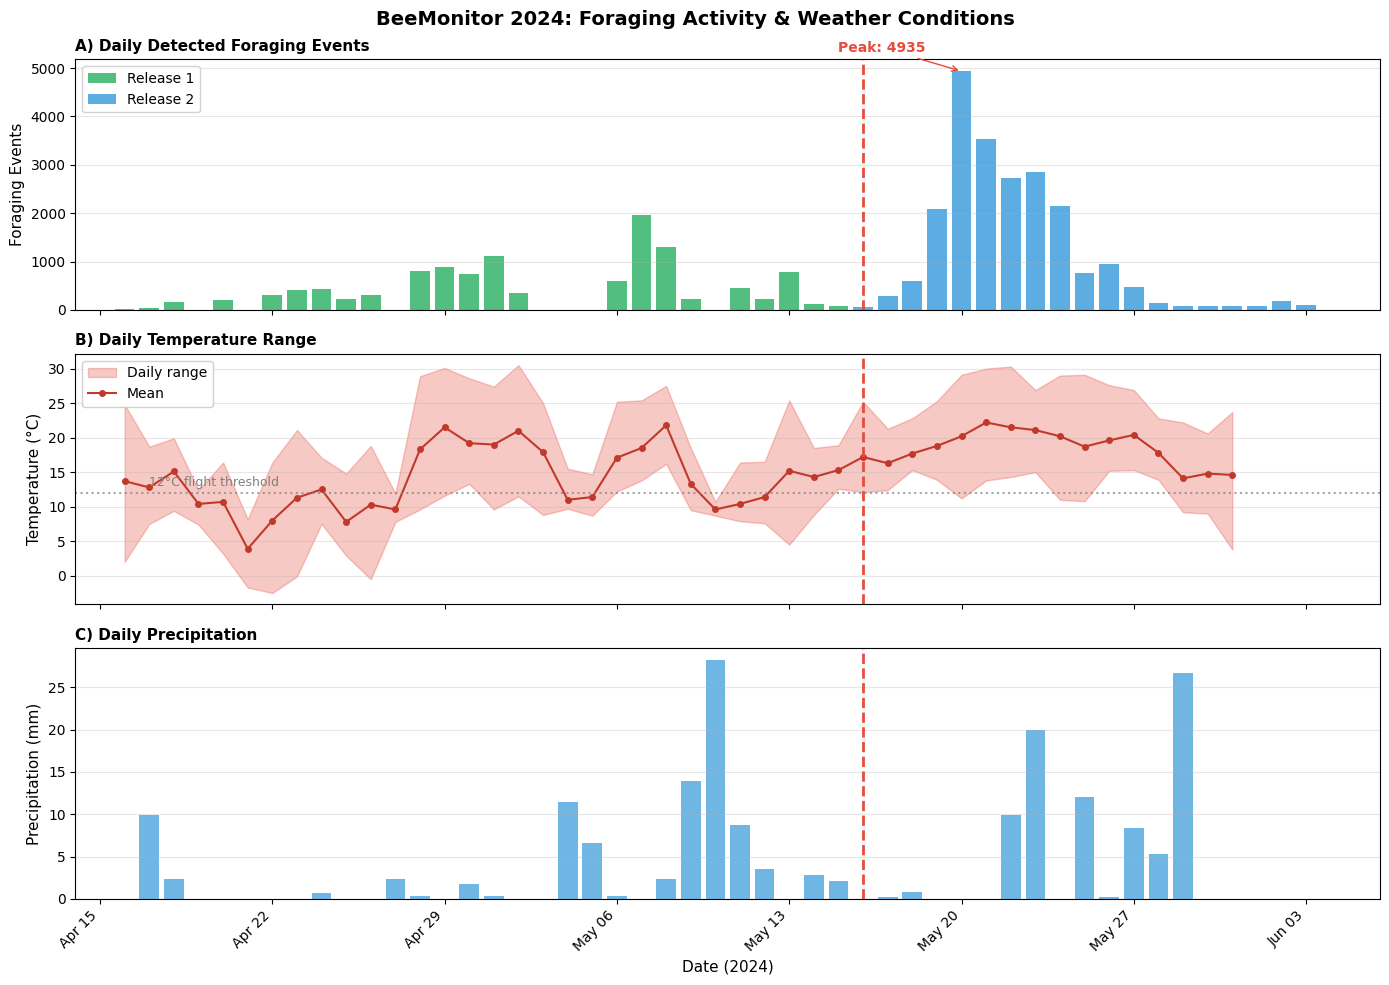

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO
import numpy as np

nesting_csv = """video_date,n_videos,n_events
2024-04-16,5,20
2024-04-17,10,35
2024-04-18,32,170
2024-04-20,28,211
2024-04-22,46,300
2024-04-23,50,412
2024-04-24,34,438
2024-04-25,42,219
2024-04-26,49,316
2024-04-27,2,4
2024-04-28,60,815
2024-04-29,60,885
2024-04-30,45,741
2024-05-01,57,1123
2024-05-02,21,360
2024-05-06,14,598
2024-05-07,60,1960
2024-05-08,58,1296
2024-05-09,38,235
2024-05-11,27,445
2024-05-12,29,220
2024-05-13,57,778
2024-05-14,33,116
2024-05-15,25,73
2024-05-16,14,60
2024-05-17,43,298
2024-05-18,53,602
2024-05-19,57,2084
2024-05-20,57,4935
2024-05-21,54,3531
2024-05-22,58,2732
2024-05-23,56,2853
2024-05-24,32,2143
2024-05-25,22,769
2024-05-26,43,946
2024-05-27,45,475
2024-05-28,16,142
2024-05-29,19,77
2024-05-30,14,88
2024-05-31,12,74
"""

"""2024-06-01,16,82
2024-06-02,33,188
2024-06-03,26,104
2024-06-04,1,2"""

nesting_df = pd.read_csv(StringIO(nesting_csv), parse_dates=['video_date'])

# Daily weather data
weather_csv = """date,temp_high,temp_avg,temp_low,precip_mm
2024-04-16,24.8,13.7,2.0,0.00
2024-04-17,18.7,12.8,7.5,9.91
2024-04-18,19.9,15.1,9.4,2.31
2024-04-19,12.4,10.4,7.4,0.00
2024-04-20,16.4,10.7,3.2,0.00
2024-04-21,8.2,3.9,-1.7,0.00
2024-04-22,16.4,8.0,-2.5,0.00
2024-04-23,21.1,11.3,-0.1,0.00
2024-04-24,17.1,12.5,7.5,0.71
2024-04-25,14.8,7.8,2.9,0.00
2024-04-26,18.8,10.3,-0.5,0.00
2024-04-27,11.9,9.6,7.8,2.31
2024-04-28,28.9,18.3,9.6,0.30
2024-04-29,30.1,21.5,11.6,0.00
2024-04-30,28.6,19.2,13.3,1.70
2024-05-01,27.4,19.0,9.6,0.30
2024-05-02,30.5,21.0,11.5,0.00
2024-05-03,25.0,17.9,8.8,0.00
2024-05-04,15.5,11.0,9.7,11.40
2024-05-05,14.7,11.4,8.7,6.60
2024-05-06,25.2,17.1,12.2,0.30
2024-05-07,25.4,18.5,13.8,0.00
2024-05-08,27.5,21.8,16.2,2.31
2024-05-09,18.5,13.3,9.5,13.89
2024-05-10,10.7,9.6,8.7,28.19
2024-05-11,16.4,10.4,7.9,8.71
2024-05-12,16.5,11.4,7.6,3.51
2024-05-13,25.4,15.2,4.5,0.00
2024-05-14,18.5,14.3,8.8,2.79
2024-05-15,18.9,15.3,12.6,2.11
2024-05-16,25.2,17.2,12.1,0.00
2024-05-17,21.3,16.3,12.4,0.20
2024-05-18,22.8,17.7,15.3,0.79
2024-05-19,25.3,18.8,13.9,0.00
2024-05-20,29.1,20.2,11.2,0.00
2024-05-21,30.0,22.2,13.8,0.00
2024-05-22,30.3,21.5,14.3,9.91
2024-05-23,26.9,21.1,15.0,19.99
2024-05-24,29.0,20.2,11.0,0.00
2024-05-25,29.1,18.7,10.8,11.99
2024-05-26,27.6,19.6,15.2,0.20
2024-05-27,26.9,20.4,15.3,8.41
2024-05-28,22.8,17.8,13.9,5.31
2024-05-29,22.2,14.1,9.2,26.70
2024-05-30,20.6,14.8,9.0,0.00
2024-05-31,23.7,14.6,3.8,0.00"""

weather_df = pd.read_csv(StringIO(weather_csv), parse_dates=['date'])

# Merge
df = nesting_df.merge(weather_df, left_on='video_date', right_on='date', how='left')

# Release dates
release1_start = pd.Timestamp('2024-04-16')
release2_start = pd.Timestamp('2024-05-16')

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('BeeMonitor 2024: Foraging Activity & Weather Conditions', fontsize=14, fontweight='bold')

# Panel A: Events with release shading
ax1 = axes[0]
release1_mask = df['video_date'] < release2_start
release2_mask = df['video_date'] >= release2_start

ax1.bar(df.loc[release1_mask, 'video_date'], df.loc[release1_mask, 'n_events'], 
        color='#27ae60', alpha=0.8, width=0.8, label='Release 1')
ax1.bar(df.loc[release2_mask, 'video_date'], df.loc[release2_mask, 'n_events'], 
        color='#3498db', alpha=0.8, width=0.8, label='Release 2')
ax1.axvline(release2_start, color='#e74c3c', linestyle='--', linewidth=2)
ax1.set_ylabel('Foraging Events', fontsize=11)
ax1.set_title('A) Daily Detected Foraging Events', loc='left', fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', framealpha=0.9)

# Annotate peak
peak_idx = df['n_events'].idxmax()
peak_date = df.loc[peak_idx, 'video_date']
peak_val = df.loc[peak_idx, 'n_events']
ax1.annotate(f'Peak: {peak_val}', xy=(peak_date, peak_val), 
             xytext=(peak_date - pd.Timedelta(days=5), peak_val + 400),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'),
             fontsize=10, color='#e74c3c', fontweight='bold')

# Panel B: Temperature range
ax2 = axes[1]
temp_data = weather_df.dropna()
ax2.fill_between(temp_data['date'], temp_data['temp_low'], temp_data['temp_high'], 
                 alpha=0.3, color='#e74c3c', label='Daily range')
ax2.plot(temp_data['date'], temp_data['temp_avg'], 'o-', color='#c0392b', 
         markersize=4, linewidth=1.5, label='Mean')
ax2.axvline(release2_start, color='#e74c3c', linestyle='--', linewidth=2)
ax2.axhline(12, color='gray', linestyle=':', alpha=0.7, linewidth=1.5)
ax2.text(pd.Timestamp('2024-04-17'), 13, '12°C flight threshold', fontsize=9, color='gray')
ax2.set_ylabel('Temperature (°C)', fontsize=11)
ax2.set_title('B) Daily Temperature Range', loc='left', fontsize=11, fontweight='bold')
ax2.legend(loc='upper left', framealpha=0.9)

# Panel C: Precipitation
ax3 = axes[2]
ax3.bar(weather_df['date'], weather_df['precip_mm'], color='#3498db', alpha=0.7, width=0.8)
ax3.axvline(release2_start, color='#e74c3c', linestyle='--', linewidth=2)
ax3.set_ylabel('Precipitation (mm)', fontsize=11)
ax3.set_title('C) Daily Precipitation', loc='left', fontsize=11, fontweight='bold')
ax3.set_xlabel('Date (2024)', fontsize=11)

# Format x-axis
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')

# Set common x limits - use same range for all panels
x_min = pd.Timestamp('2024-04-14')
x_max = pd.Timestamp('2024-06-06')
for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.grid(axis='y', alpha=0.3)

# Force same x-axis ticks on all panels
date_ticks = pd.date_range('2024-04-15', '2024-06-03', freq='7D')
for ax in axes:
    ax.set_xticks(date_ticks)

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/nesting_weather_viz.png', dpi=150, bbox_inches='tight')
# print("Saved!")

In [ ]:
import os

: 

In [ ]:
os.listdir("/storage/group/cmg25/default/osmia_data")